# 國旅已死？PPT 八卦版國旅輿情分析

| 組別 | 學號 | 姓名 |
|---|---|---|
| 第13組 | M144020030 | 賴昱霖 |
| 第13組 | M144020053 | 滕冠廷 |
| 第13組 | M144020068 | 陳啓恩 |

## A. 動機和分析目的

近年台灣國旅經常在社群平台引發討論，常見議題包含價格偏高、住宿品質、景點體驗、交通便利性、政策補助，以及與出國旅遊相比是否划算。這些討論不只是單純的旅遊心得，也反映消費者對國內旅遊市場的期待、失望與選擇理由。

本分析希望從社群文字資料出發，整理大眾如何談論國旅，並觀察不同討論主軸之間的關係。相較於只看新聞或官方統計，社群貼文更能捕捉日常語言中的抱怨、比較、推薦與情緒反應，因此適合用來理解國旅議題在網路上的實際討論樣貌。

本專案的分析目的如下：

1. 整理國旅相關貼文中的主要討論主題，例如價格、住宿、景點、交通、服務、補助與出國比較。
2. 觀察貼文對國旅的態度傾向，辨識常見的正面、負面與中立敘事。
3. 從清理後的 PTT 貼文中歸納網友對國旅的主要不滿、支持理由與消費判斷。
4. 建立後續文字探勘、情緒分析與主題分析可以使用的乾淨資料基礎。

後續分析會聚焦在三個問題：

1. 網友談到國旅時，最常連結到哪些具體問題或消費經驗？
2. 「國旅很貴」或「出國比國旅划算」這類論述，通常伴隨哪些理由？
3. PTT 八卦板上的國旅討論是否集中在特定事件、政策或消費經驗？


## B. 資料集的描述

本專案只使用清理後的 PTT 八卦板國旅貼文作為分析資料。原始資料先以「國旅」作為搜尋關鍵字蒐集，再排除回文與明顯不符合國旅主題的文章。由於「國旅」可能出現在「出國旅遊」等非目標語境中，清理時不只依靠關鍵字，而是以標題與內文脈絡判斷文章是否真的在討論台灣國內旅遊。

資料檔案如下：

| 檔案 | 角色 | 筆數 | 時間範圍 | 說明 |
|---|---:|---:|---|---|
| `data/ptt_gossiping_國旅_2025至今_cleaned.csv` | 主要分析資料 | 923 | 2025-01-02 至 2026-06-14 | 經語意清理後保留的 PTT 八卦板貼文 |

每一列代表一篇貼文。資料包含標題、命中關鍵字、發文時間與內文。清理後資料沒有空標題、空時間或空內文，適合做後續文字分析。


## 執行環境與資料準備

如果你是連到雲端 CPU，請先執行下一格。它會直接建立本專案要用的 CSV 與 `dict/stopwords.txt`，不需要手動選檔或拖拉。


In [1]:
from pathlib import Path
import base64
import gzip

# 這格會直接把專案需要的資料檔與停用字檔寫到 Colab CPU，不用手動選檔。
encoded_files = {
    "data/ptt_gossiping_國旅_2025至今_cleaned.csv": "H4sIAM1WNWoC/9y92XNr53Uv+L6r+n9AucpdSceiAA6H57AqrfJ005lsJVLsJF230ifWsXViSUeRj+K46z4ABEFMBAEekiBBgATB\nEQSJkQNAjA/92P+FxD096V/o9Vvr2xsbJKW21bnVqeuij0hg729Y3/rWPHzVG71++fqjF9/7+PnrX3z44oN/+vWL3/321WcffO/T\nz//5o5e/wSfPX3/vF68+ef3ik9f/k/a/65tpPXXyX336au+uu6zXV/RCUr+8MeIps3hsh9bpT2MrYhTi+tGOmT/6nvz9vfc+/8T3\nF/T/wKxv2r8QmF2YxS/TT773HSO2pgfX7jopq1K56wXtbt9ePjdzi9Zl1OhmtLvb4sR3hy37sKjpkbixXadX7zpBPZi863b120t9\nNyp/Grmdu05CTzf020N6WY81pv1+v2ZcXhrNfT12rB9EfOZpiN4yWjkztO2zmhUrXTe2zuyjjKbpmRWjfGjuLNkrB3qhrB8M7zoh\n46qnh9NW69RorJkVWlOQntHs3BFBgXZrlGJ6d5PeoUGx3vBAj3Zp75pVadiLS0YhTACTkfTNxHe8gGQA6cOYGct/1V8xkgWrvIUh\nTkL6cupuuGy0S0bjymoX9cNzY2+L5nOB+vy1AHXGF3iyMPt0YXpOAVUeMAtFWtF46N2mdTyyWld6OmbnD/VMmD602nV7MaE30vSn\nwBowrO3QnsybdTu0apXy5kbRqBzYZ1uapobsda1qQz861Ws37lL1YdAna/XJSn00m50NWu01YMrxQN9a/apf1OhIs/RD8DC2jo3C\nBVZ2VjSPy7RXPb9H01uZi7vuhhVc0dstTfNChB4hQAjKGJkbO5i76+ZxxDR6JowjOyya8bMJ+HZusLvqmYLJzhIwpxCnw6WzogU9\nBs25hTn/wuwzB5qNtF2t48gTCf32yrwK0oY06zSo14tW95zgR+PRQgy6CukkrZhgt7NE3xAWWqUVe79qhwe0Snul7qPfcDkyKTO+\nYgxq9C+tsCPIQquwQwntz/+M3sNz23VcrqOsEV/XUyUjlrWCESOdN7INfSVCP9hvLqMnN7W7wbKVrSg0qW4bF0NAJJzm2cIA0NEO\nIXb6hDZhlmtA2FiGDs+HMzzCYQfemqabI5DS6GD0agaHv9+7G6xalRFN5TNab+g6mEdDc3hk5vo0rxFJarh4nY55NrLWtmg6wjYj\nV7ODOz6zkLSu23RihFbyqtVqm62hvh7SZHX4NJzW4ynal714SNfbBYVmbuxY0UssNLeoB3N6pEzLxTViMPnuBmkBKJ95Xe9uaXTg\nd72sudgVSoFN81A++pToxxgP6FO6i0cV86qumUs3+nBF4VG3a7VKejJnJoPGZWgMwfqGrJE+waiNNboH6SFtCAe9UZRhceV5bbQ0\nWRHDrL5BQKDVEzbIoWPBIAhAQLkRwFY6Uyu091/1yAXNr6+XjHSGSMqXdAV6B0RkFJFIlb4Mpnx6sES3z9i4pWHtUoqOwkHhn7/4\nQFDY75ueXpglLHao7IevX3/6m4W33/7kxW9/M/XR60+mfvHq46nXv+W/3/701UcvX7/8xW/e/ufPXjz/9ctPfsWfzs0+efJ0xq99\nyzUZG0N6FPSkv6aHonpi30xXrVaPntY0LOpt/5O3aaH+pwuBgGaVt4EEqaHd3SJS/FU/DfK9sqXvN/XGKl8pdx0EeCyC/ow0jY2R\nWc2aNy2iY3o6bMWiwMd0g2YBkTpP0v2jZ+wcLvtdN2l2BlZuE3iUWbET68bmth0uj/fTWJM7SLvSYzea3j0h6oQt7R4YoQN9eGYu\nlYzLTdkSYebX7ZDQw46ueWFB44CElat3PbpSm8ZNjJ409jt2oo07HLv5Mrho5muEaBpRPdruzLzfT2u2c0sgtY0dez8WmPH76ZLK\nR6DdyWOCxRO/fnSmR04Jnc2zlB3amPN73uR5e2atRDTW3irojaY+itBYRvVQB5C3NDOzfNc5oYFAAIxCjIYysn0BI9ho5MLOJs3r\nk7sufdW2zzeMfIfgQaTaiMZp1XQ4jBhWiWhDF/MNd431HT3dIUgR4O1oUq9umRcXgeknVq5oVuNGtW1clKzTQ/rKWEobW2WBzj04\n6s0LLMQ99vw+/S4HoMmjXwZD5m3f7K7QCu6GeT25h9u7swT0aKT08C0dBdhL4cK6rGAvPCJRShIuCFXotpsbB8ZF4u42SYQRmBBb\nxjmkh4Q2dCZ0/noj6ny+oj161tYgTkQHU04iEH0lp0w4IIhEYJazVqd/XCVhhNYhaGBkb+lEgG/tll4/wYqH13rtUl1AyDgEBNpW\n5IY3ukl3wyaAEKeJVsyNJuE1LZN24zkTvd8m4o0xncuqdkVTHDXBgvn+6LFdq9Smx8zNG2JwhKXmOT1fBolbqVuxGPhQ5BQcLxIH\nQKttEg7AOOgYawl79+yrfkw/WdTMK1resb7U0oN9fXOZSD0dEX4pxGTPdPpf9eN8qW70RBFEs90iEIDrxy7UM0slc5Nu8OJdZ8Oo\np2lBtEq9W7ALQbNNR7Fl72fM2pZ5U7UIkfY7GgHPvOyZ101MVj8zisdm/Na8WiIajFuSy1vBLaEDAGIiD5DHMoQVNIcAwDosWK0+\noYHVuqALSohNAJVZBfoyJbFgGpkOjf7U8Hd8ZKxvYI7gir27R+/oxa7ePHJxFgKh0IqLhJlP0PuCo4KdxBsJbYgr6tkaYYvn3IyV\nKLEpDDxao/17RxU8AO4kc8SnaVTzNmRHgeeC2OZJWo+dmfmO1Q8TthNK2tl1vbOo718RrO1gxuh35PDN8xszViWAaDS1iyGCojSi\nDEos2To4VyvIrNz1QkasZZabCudDA5lPbhrhrR6PkrxirCfUKyQKNg7lftNjoCbhMkmF5mZOI6XhMfphVI+IcNkkOOWztAESQ4Co\n+SERRau8ap1n8Uy4SOSXJIS7XoKgIBgOInizboyK5puGfhAmbBDslQ8VqrePiYoRumqEr3pmyS7tCVrrjRgWcVjQE4TNcaDlTZlQ\nXI9ATCacJKIJKbcRnbiPTJSMQkWOmTDIe8A0zT2SoRF+0+iEgUCk2o7MLUszUsvmTQj0Z7FrNBflNIlOm8MzELrW0GyUBI315S3j\nOiTwhiQRTembRXN/g8CGFYwiJCrjSPP7BEvigxoxwm/gf9jf/oaxfnE3qtF8irk6W6R3afkWnXI8CnJHSycGsFVQS1kb3PWOgHyZ\nAU5fKBPvXqOH7kZ0i09o4fpKVl3BQYGQl1bnEXscJej2ks5SjgCSXz7H5CZkFIL66PwZ8SYI1O267ymzqdhjYo9/YWZmITA7oQf9\noeMaiQFUnq1jEuX02og4uebIT//88vXUR797e/bVv/zy1T/MsRzzlv/JW5BjntHMPitU1zMxosw+kWiscMlc2zNXW2OJJnUJkVbk\nGjppu7+uJ6+hVRaGslC6+cRBcGW6RyRI0wEJlpiDlr5atMqLhPNEFGZpsZAtG1FjtUzvzEGW5wGEBTmovKLYA3G0dEIvbBMH1+QJ\nkm1BgNNbRnifnhOx9N7OsYwBCQhV/agm8xL7ICwSgmiNlujDu14KdGOrAJrtrNneJMHm8q6T1aNNekZutyZSi7yM50KrzJ/DZr5E\nR4Hbzh8S3QyINPLwLJhkTEDkJG1unt/1jkFM+XM7n7P6FfssAh0le8tSKxNI4gOX0ZnZqSf60hJdbJpvApb3AanQB2BL2jt5zQWp\nfCF/ingAjSxzLq/JUvWlCsEVN9ezfvdDAr9RJqL7hgghfU6f3BFCElUnmkIkqvAGYhifkpla1QhD6In3n7/87fNPfO9+/733ZBzi\nplisvR9hoMgqoXGSUMmrwun1juVz7KR2ALpO4gkRo4M+2KXnK1CF5qa9v2yH1pUU89hjtB4grOcBzYWQUc6Z5yN9L2n0N3TioIWw\nsVE3VkJyCLTcWWet6jbmFsGchnvqGIigP6GjYLvEJeGBscPMc6urV4WHQE6d5Qsb1NOHxFkIP+jIAkp2vesNCHUeQ+GRuVEmLaJI\n3I0mwb2l+QLT9M5MAFemekDwi9wA0dNbeqxB2GxclmHr4COFfLNWBhWJXtIvej5PVFxmAPUk4dbI7RiJa5rlKQnpzDPs4CE9Qd9N\n03d6ui5fB6ad7wkcGhh0PU1iFNEi+3ybn9qmB2Gw4qfyD7GH6DA4BElGIq8TARAg4J1MSj8cGNtFIGm6bu9vq/nGpEyEex4TQKEH\nZ10KSLowGByJ9t067TSA4Xk4PrPfkxDASEDiIwv/Xip2jyIQnK1yxeX6dJFpKCN8CeUcg2+6VEITMiGz8poaTSJcpJbop0mwwOxA\nyJQ+jAGC4YK7rocrIlWK2DWJiTQoeGRw2yVI9CEED6ZABAkQKzPfZ8W+fJ8u0ffW8IR0Jyyd2GO5qkTEbH+evpYVP5W1mqvRh1xF\nzpKnAOmzauvCA6Dq4tEUJqMLNEnuBIbmatw8DVqVCrZNDD+eIhHKtSG5Vwsj0eexBg0j92me7jIWJbd3fK8IdPl9IBVPDIsI8wLN\ny7IVLUkn3KWKdQYXOF2nr4QOK6J11TDrQcCGZRACMUNlku4r8DyEjeYCx51LprBzHdL2zFyPuCt9C9ZNMpnosgqDGR0EtR8VMkg0\nMhLZu+4yBIBRUW/vwXxNtD9Xn4FFODZipT5Id/ZJYI5uziNSRmBuYZYEDcc+GJjSK2+IrcJY280s/Pj161cfPP+dpk1PiRAANpVJ\nLeiJOOksxkle02am9NqKsXklSyOqSdLuwrdcH7E2+2xHXyNdIkij6pEyDA39jh0t6M2mps1OzMXafXRBI5F/RYZX6Bi+Nfb7+lHF\nqkT1/jVNDv1ViQllCHe1gy+DCba1RqHuhKLvvX7xby8+8f3PvvdePv8ymDTzV/paX9RtOipgk7v87TrmgyV6uApk48nubouwFoYy\nRjALmwnR2kKDOAWGaL0BJYg1vIuzbgg4FUIHekCBQuBgnhf1dIUAJwARwz89pNETtF+sOV25ux0abUKJEF1VfTFnDxIEKVfqwbcj\n6M92/sC4vtJrRzAlRVIGqe8nF0bpBhe1sqUfZcUwCfKz0yQd0yS1gy4Yn4/gqwYrJMNC9i8mc9Kh7gard/0GnawoPR7g087EzEpg\nn9iZbIiWSPPRTDINzu6bDgKW1ihJuR2zBa3GpbB2MEeMhoiFPgzK7IoM5BZZIcfls45HRrVjXMNQTBebNjhDs4Vm9d0KpKJGGqdE\nokIMbE/Aa0dS5qAGhty/JsELSkM3ISo9fUKqrXyCBeSz5tKNwJ/Wz9SyYZ6tCgUiFKU7hBuyEtL04RZpGebmjRwb1lfswo5TruJ6\nE3Ci8bsRkQ5ccuKdpIMQ2PVUw2qWjHZTj/XE0I8Xuwn2cDRhTz86NeNRYHOhQccpB0aHDc3xrKvRju0SMcEtg84vsW9sr951a3r9\nwtjc4zP7ItsybvPWVgoH0biis7DipCZGCKtFAFstvvtTfffEKgeFo7lXgWBvlmtyzoLNWF9sRDMSJCAnEQ6KZZAGJWqfrssg7k1Q\nBLq8DqX6aJ+EBUyRuiSuPJKBjMKusdsEnEP7dI2I9Xmx1DpR6AOAkVZ4xGo0o7qxWvLiP8HYKsfkati5JTa9TlwEOikN5E5EivMN\n+2yLpqTNEVkHDy9AXID7hjdKsCTI3w1Heq1A+3Doi6Jh3osLx4Zzd+lccI8u1qzcqZAqDXdpZ8lLEdTVaheF1mGldHbJHfaj7ViV\nBszv/bDMzYb3QzoFoW10A+sb6r38lVw/WAzow5OsGRvSh1CclmjDIaAWYX+WkHhH3Zz9W2Cjc6k1Te6aHWxhW9Vj99JZ5SaMCOmG\nGToU+VkPpY2lvFxDNT9fQ7kFckmBwpFjRT+HKxinkqLjh32u0LCrET2RJ6quCbG3QwXCQ1AooU28bMEjQWQSDegBOhS5gfZRxj5s\nqdNx9gudhFdjbh4LcuFOtuDWIbzRWx09ckH8lQbX7NNNoRm44iGcrkUTy624SrLkeSJfwRi0XbeL7BYWCfeyYfQPjGSaZsIx8RXC\n7SWqR8rnoAZHyVFaL4f0ozb7YOvWSRe3iw4BnqTVspU9UcbvdgtmyNUe8I43QWRHNiG2SWV2Oinrtbix+gZGxpuiIry3YLZYwRIx\nD5JJcnr3lFiVfgM+c3e7ilsXTmtYwvn2D9/Vg30Bu1JDjk6t2g4Qs74BHzGfr3LhEbWGpxI4R+tmVJub4MGkGJjXGd8fwZxYrJo3\nLX03+MfMpeoktfzD9/+3n/6UTuOv/vwnP6b//PV7PyFFwRrErX5cxAxi3o454re//e3UCxE3pj558VrcORBK/E8C/rdnAk/98/Nz\nUx++/ljTnkwR1bXKvQXHJnKrb+dJ0ph0QPkmREiS7wp5kavoMZ8rvdM1UKIcAX6rQBgaeExKIhFpfmE2cM8F9fkH7H2Stf7m9avP\nfvf2/PTM07efzc3N+2efvPPLz159/Kf00Fu/+DDwT+yRwpNvBd7yv4VftG+7Qte7oW8W4TP12G5opdOzPmUmJLV/n95PKwsO0dec\n3j/RT3Iw4XiNNxMrsUMt+iHNwoKrV9bzuOoT8LNlwaORTCpC7kvCP2B4S4SB7awXaaQYiRIm5mlX0yG9XY+dubK1R1lKXRJiyaYn\nYLdaEcVJX4kYyQuxDHlNR6CGoFgjpayT6O8V0uVDuHNYuR+rEWwd9KqFSuWiGxDLiI6FWRurVvSKGA3pDOLU0U+Ik+OC00Jx4b9B\nNfvvpJlp36yaiXbEnN49zbGlXgh9gYNRGilo2Q+ALSINbVIfRu6dNC0DThmGkbKv8sGzBZ5E6rwdTEMPVsMxyPUYidhBMXwrewyb\n+dl1kpKNik+RZAF7P2YRjXSQbhKsLdLlwbBB0hZdoAt8NUDt3uGJ5fSpi10OxueBp70bYkKsZcZTLj4SJ4DwdQXaSDhDgsAzeYIm\nUb5I1twYusTp4K4nfPXYM5ULI50Qo75SiTcORDV1NWQBG10Lus5Wqzc29olf8OsMhJo4YJQJSAg5m9CMm2trnQ51AxIAI8b9i+Ox\n+bkX5+FFeWjzo9E0MQZOmv6SXtOfnrymLT+w/DlWTSgSrjDHnxGPVF64fN7ej3gtd2Kte3Dv7xsHZdZvNg5qv7910LUb/D4mQhfd\nEYRVPTbWrwB2Z3yNJkCUULqh/CabMTOfmLyQY4PSMKKQ3IO7QjvGF0/mKpQ93MFzBcXwAXbP1NN7lUUiOZbrRTzBLCeJcpEoKKLJ\n+M64F80oHjuEh++MQ6RwZ9RtuU8i41F6m0jk+KpoctPEKBS9hPlQmUjHBh1Wb8qOqQeIQYpP5kQfNO3iyNkDiKwsGyeDbd+KkAS5\n/wEsXfqhOds5oRORyy0mIJd6COURYY1oll0QwfQB38h34CWq3Rrb63qxbZVWWG6EMqCmgPIvDkhS5At5EKOlCqg1r91rGyIybWyd\nSfiH0GhE6wkTGSPGPV+4LAOjZtTxYufEuFLXMBoSX3lAIb3uDVhdV0Jmd0UZil1mzgdN9zqiDw68WOjyLlqtHVRsTtBsfCMdSo8n\nM0u4vp7b/pAk2oWg0VxUEmlqQ8OGPGSRKDEtUNFNQt/w4L5FDG6hhhsYR5yLKCQWGtwBsR71rF6CPSchiWiiAyRVk5imI+39l89e\nsrQ3x443kqICj5vEiEo11oA+921idD7n2+buyL7qfY1VjMSsb7tKOSDEfaSiPtJJAsZmx1jfAYUc9cyrCE2+Uyb9hrQoMxP2chnl\nJR/uQSVd3jez5zjQ4Zm5wQFBLO1D8xTPMbEkeveoDFpxWyR1FGM6XrWHTjyiG6TsxWa+6sfhUKhUjO1VsZQKoQPtPphYDq0FGMjz\nC711WYSggOwUQXnNTTbMrCkWxouiQTSMwt4umhlHBBf37RVpTWIBlgH0tZiZHppnZwgAJdK12YYPPHkAocBZPQk8EuPj0WlHpMOY\n102xGtDo8ONoysciU8ARslGGuBUjMRUWkdlnU9PPvku7mQtMPQl8l4A4NzMVCHxXHCe0mBkEfvAi8FGpTpTIuy/3oIgBEq/bo1VD\nweWAXHc2MB7mjaKRyvkT9pB4wMQIUWGkJxL23HVPJCqS5nOcaQhkbr0BiUMEQ3EMgnRVRiItw0U2sHHPkBzxCcQjOp08pnV4v4RY\nsZeZkFrGlJZDTC8uAgQ19wTvrdcObQSeTgemnnKkbFc0XcCdoAi4z8GBQgyUBE0H3IH52cDUPD1PjwSgFE68KyHPcvz3oe+iAMHQ\nFSiVYiCHQPRSvIxYL+MjojA7PZiyibe/ybj7EmQgrYYeNpsp2RN2M+N/NhWYWFFqXwyC3n1r84GpZ9/l40wZ2/tKk/XcWKOwKyEb\n+koW17LdRLDTSlZuxj1XimOrcUX4r4U9Qk83O7SpmZlnT+gPsWVafQR1y32ak/ukgD6s6bcRo5NHqGhgXl5QNrrNDkFLjJxyz+6G\nefP6JPCMDwQm150lmBa7WQSCeJ4gAmRchu46SVa0nNu0FvMekkBGI9Ao2xwfhh5pq5huPgyxYQjUBC7yMv0rrkGrVBLBMgYzG6Jb\nbyOEy0a/FZiaI+iHXBDCHFaIP0UwlUCL37gbrEIu4dOTsHzZEN0pseMTrqeHxNPs3QPvHXBvhRqGEYioop3vcShfSKK36Fztw6Kx\nm5EYLlImzGjRDiXlTyigV/si68iRao+cqVoWz4NjDfgD4pOF1V/8j3ySxJ+N+gbtnEBAuovs37FrOoAXqJlt0B9iGepS4OZ1wsT/\nzAKOjN7+A0A1pnjOiollgkQJRxvuwlpEKxSpvRDURAxQYZB8AwQDSBDQ10PYFa/ZDhHZIvqdV7qNqAXxqJG/ItmfGLRSgOmVy4oE\nKVnxlph4mTCrKyOiiIaYpHaP7hcOh2V8eQHSvYdIe26fMFzF2+ipSNLYuLVqMH6qzRAB9+IuU+8xmWQr6EMOB8MgWzplF7DIwZUU\nlaVpYvCEWjZc1asdYBBvScREwiA7twQzKWF7sO8sZWSedeEQEMJCKsFiV7FcfheGwSjnJHSC5huEKxJDMBbj7nI1Wi/WJZx154pg\nT9IcwVVGh+1wm1S1HdkEq58hOMmO4WojcYmfSZGmKs/TmZjxFTlkYivyIVB5cGA1xdJ5QmcAP9tDkcPVytQ7fL4ykJKDSezu7cki\nRHgExSWNpHhrldc5anPFIoWtsSq4CFF8JWsUUhznGNJoOJiLiLoNUqC3tRLpNqDADThsrUGcDtuJw+DRCX+JoDG+umEU8BQwnPXF\nS5sEQD4/yPQ8iJwO/E8kysSDjE5eO+gvX/8bR7d7I9s/ePH6+cuP2CL6xD/zc//Mk6de+ZczKbZUBJVHK/BJxoUgs5GrE2gkMkNP\nhR/xCM/AgDg7tzD9NQ5hsdeZR8MH4q+Rv73r7hmt0dcIv99ygcqL/rjrV41JN9OJHPOOjGNgpYruHzEbqx8HosbWwJacFwlNvv/u\nu2auBx9FIayvA/2s64ZVrsgz3nVBXmW1FmyWeBAv/K5HFy8nDixYvVMtOG7YQRCQyBcV6hLrSCCLSaixeiyxMXomBsWckRnhwhzD\nYh50dfgcoR1zXhFsbAhj7EgEhbt4MZsq+4HQoWYQnP/oDHSqExZgqbU5IBLjUSAAyYoDyZsEHOO67fsxbhSPLTuzbg6Re1BIal6Q\nmvm+aHXqhnAQKnykDAfjjOS0GxbDOnp/E07mziGWyhSRAEt0V+bA7dzMISxb/Qm5HI81g8SLjGNidrUtMx2X0BCZEspSftk83zfS\nede0o+j8ckpAKoQG9KyyTRxU+U1I5UkjVcrYjJEqiQmUA6tAixC1X26tBjWaWYJD21TQNxjPWtleTMitVy7eCWFMVj+22kTKiBRz\nzHeQDaf9fsitzJ+R8lGIQ1LkCKn+tUKXifgoRhoih8YqS9rxW0nB0NwIe9LI7/oNWTFQJnNhXi+pzbEVAdT897sFbPnt6csJxSH4\nOiDQP5vkyKWVA0QGstVJrgECyBrIWzQOdtWVENuNoE+7brZ31POeuxGAU1BMG2dFTEJS/KM7R9CS+wdCyy4PCOfsaBpxwrkMYwUu\npN5oIp6+GgceXx5IjsK9M2EkIqkfKWg8t70fIfHfamb0OpvgSTJmokzXVvJO3HOimdmjF0QaaAr8J6DkeoaviC+yWdq4hhitRlQ/\n2CMuTNRStslKleccOMDz0UMQKJN4e9cD/YArOZaVGCAc76gxCSuBErhbpC0bQ6D1fv/e9unyRiIcNRom+CFlpJzQa3Ekc8Wi9v42\nvYeUMXo1m0OY9kHXCJ5iYJYqZMV0c+2dVcEKvXOJ/Bcmm/d2onnxiRZ21z3HvZNd3h66BwqO6lkwo/kGRGTPNPIVfPokLhOhcSyP\nJIHSmmYI/+b0YFKjr4iKEtVTIbmhqLlxaZ0nsVVSbI5OVVgIv+6GeeGiMynAV5wFqlwjJMXytq3rttVe0x1bpoypTMCRlKZn1uwd\niQD9D/aJekWBX3zyfEIMeP7Rq18ot6h/2h946p96/ptP/93jE9W0t97SfF9sHXyRXfZ9kQ3T/5e/yK7Sf5JfZNP/zfe2b+qLrSP5\ntPVFNk6/rdJ39J/EF9nUF9m+j97Oxul3H/54m/5N++SBPv1/6YtshP9d/F+mfBjo/87Jo0kZa0VeXuVR+vLOou+LzTUZpiWf9PEq\npts6wPvh/4Pf2iJ+s+bjVWC6FR4gTC/xYEneU+K/yQO05iWsmf4foxm+6mBYrIOeJ/6GbafVHuSpZcDC2Zr65svgrkCor17EWr+6\nTcjkKYFJQn7jHW0dyIAAZ4v+H5V5aYitY98Xwesvl954gMdLwGCpiSxezjWW5FnO3F0WuQBoRfqa2AZXz5BonDn1JPX+9SuVd+4L\nBBbmZhfmnjiZATwgCduiTMBEHjmnqXDVSO6sZvTNE1J1NU1EA7gcFkvmeY7oySxRuTlZgZHZk+xj87yup2JmPSjhmIhqzF3BhN3d\ngFrf25OAPpJDtg6Qc+psx7qEaGGl2qBfvRH9sIVz2Q3sxDOVijJGeRKXkb6zszQ2WvD8cASQ4NNoqqTs0w29GUPEht5Gvo/EHoHo\ncOK1wIsDlXqwwpIq0ikhUyUVlEx1eoCgycmXCEMqcOqXswCQTxfyJJQz9FQwwWRuO4wPR2ek+d0NR1aiyZYx5HgTa/CmX9Mp/fXz\n3/lmAkilmCaB2u8c1ckiycI+zk8+OqWpNY1NazEiKEijYzET4icEpTz9aMRPYqTzvWVG31iLcf14i/7wzZDEgDeT9OVbrz5//dGL\n17ImeYl2aLXakiNPW+YSAm8ZK3Fj7QwsJbZsZ7Z9M7MYg57WjwpEsuV9PROmn7ee8PDMYd4ClEgkJ1mxd2gsIUjprhMXdc+OvNG7\nW74ZfhzBhwxZhCqz1sb5QTGjdUtQhru3XUcmZKhgwXIbZwUaU+KIFQyRi050NcbOpKIPQVAPD8ITn4JgrE4KCJ9GsIK9u2+f5CD5\nEMkvr1vt4tNnnhoD0HFwLNPzvumZBf/MwoxbuKEQtEZr2HAzTWADDpySXBNjlTghbjpiXwgnOBlwChVSrRH3x4UiEFO1XqEzNatJ\nzqomVRIpTeZ5EUGCnOVvkUq5WxcpCXby8CUNzjCWaNX6CZIgnAxw2jMCBkmecd5EnHgFLiWEKF2us5od0htpUbntxUMjGrfOWgwL\nkBIV9LRdlwH1dRg83Wc0YUdggUQbBnuaRhzL2CvAFsE7h0zFMelmqKHuMKeeS7K4AB2YwVFoCIOs7egF5NgiO9DZheSE0zOoayHn\ndHtJ+1Xfbucxs74W/iJ4Qj9c+OBUaBgcD7xtgIpIWnxIP4AorxJjxYdj8JMAGh/qO5x52b4ULyHOpIIMCjkZI9e1dwogP0hxi9Na\ntXurttaTsi7Ep27mEEAqLhFCp82EhBAKaJWl0at2Jd8wRUTELUEQ2f1AKI90t2LGhvb+Os4s2jTevMEGbw6N9rbRP+fgrdg9rU5C\niFkq4qS423O9loZTJU/KyDZpFGa0KOmnhGIakh1Ah+N3/YSRq5lXB5hmEeOqVK0H4yJyJ7lrbhRlLBJVkQYi3u3UltGpG304qGUE\na/HYeRF50jP+J/NPiXbkrMMS8qfXK/QLwOo9XgCtKNRbyL44ehieJ3LMiDgmRAseqnQfB+CqUspJklXpsKSVMnKA7ZAkPoR/lRAG\naNBdlgBfplc3SBVnyHspATZxuoGc1k0YCr3Q814/RFQf7hoDzE+nDULmhOzSpJrYyCQYF6pgqCp0DkQsdga/8FWPZH1cqn6bJoZo\nSDu0QylFszKAILEkZlvKfoUlcHUG8+IE1gAntNslCBIYau/uTZC21XO9eaECocuHxONVIRGHIGqgFEtF62LXCq8gCaK3TT+kU4gB\n4OkzFY+LUN0svQgzI3Ho3QMjP9JrNb1XNJJJVPsoAVvN5aZV4jjgRtN5C7mqHPiLec3YgH6sbkuDt9mzUAmw1jO3+nLbaBwCKQZ7\nj/JVGg43KZ83c0MwfGLITD4eod6BGXbQTk8wVUIqV3B+OfXxq09f/vvUL37x9rsv//bffvjB1L98+isuvIDQCK5sAmcX3zi5X5BN\nQgMkoOUOBIXouFdIOcBlX7wk9CMc5hHEUVPY1kglgPDCfn5ZNqllGifPhelf4nKaEVxFoZ9gDkU8OIoSFnyrvwmhY8y7lOg3Fk4I\nMl4YSU0ZnqYLJbvfCnBdhGXf3WCf7oeYwtXKJoAGmZGBNucLTC/MzS3MBCaApsFes38lxk/izs9//XxKPjLLEeCQPtwjXRhegxhr\nnsSeszUEiPRb9LkmdW4gIh7tqDVBpgBOPr42FhO261LqAMH7LL7Zh3mPaCbylxcAVmVEE95bqwtAI9oyBw1wtIIEwn7N9gOzC35X\nZo7nkYRwb0Te5vycXzO2V+Hi4/BXtXk9FSak2adLfDdISREcmUXT0xAUVGChyCVsWPahEMzKgUCRfidgaX/oTrwm3vff/7GxvYFr\nd/rGqHW/4kgrGGC38voobKSrqnADzR/ZNtpwBZMs7a0JxLCYQYDD7NMxKny7cSGXEuHmyhUkCpuhc1IZ6AC59Ez7QZbxB5/85P/8\n4GOSO+LmeVIVTZl7mxZDpzLtV0VTjN1Va7FFLP1+0RRl1m2BhoigifJK4E5F9ZyXgaR2SEwj3COyT3sjOg9Dxf6VMgVyXQurtGIe\nDY3MjbHRk7AjSVU2BjU3lUySBHsoATBcNW6zHFa+ZmeD+OXkwjzOwmHHXikQwtUDsF0nvksm0FM9N4dCZRp6HL1wn0pmyGDVGrXd\nqHcNgB0G2T4bBLblD+GIJl4wCXZZ1hj4lQ2oTCdIqiYEVTnQZ11YaZGDscjW2ytajXugblktvY2yDZrYlx/bibG3Zdxum2er93Md\nIxd6ugMwrZa/Dkww9d7s65c3IrKambiZCSNyMlIFxc0f0FcER40AqcRWWK02IWvSLWFDq3VGUkNaql2A68r9IxrGORr0FqxQqFzV\npcfUILEMaNUqLHSkEzpVKfTj23tecjbtneIIOX5e0msEyAJSogZ2qW7nUkb3nHNSVnE6EuBFiBNruCoz/G8ccyDqKzvXPbvDa0Tz\n0hnEeG3UzMGSykmXdbBb3M170zMral8MVowrx+8cLZ2rOaipdPBYVDBGvx3e3a6yRJS0Lg9pMxphOVxnhD5SDGpwAND022aYRLsU\nnzzgIoIY58KCIe5XjVjLnV1hw3UbRkgH4RBrcltEPLQYzBlMckkhXjgYMw6d43gL93W5OhrdAhdPpf7IXWdDQYTtcGKlU4G4AhKl\nhjAAXHi4Jyw+bccprzzOvFDk1wRb4l4XUszy1+04sYyzSoThAm097nhV7owNu86xqfCHu1HYTrQxMdweyC6kO3gskJvRj86mScdW\nhGKxezdMikBJt968WnoKey67ua3rthgwjUzVjqTuOmFOxgohrLMWJ81GbtAPfvA3RiwrCSqa6/bVj7dIdpXoR1eshZ9f7Nh6+0RP\nX4rfmi+nLAf+cnYKzdIqZ2AJ4NIh7vqePH3md1emQiu5OoAwfhdOYiugX2ak8iD9hixy+k3cF5qK12VTurJgSwKQqivEqe1w0WT7\nKjHI8XPf9a+MeNI8qcFgzPYRVXKIvT1upKG1FTeqR3S1kJgjvicpBgM7CcI49dQlzOjHVXgJ3ZxcRlbGwIqgL8SZVNSLvi4BV+FC\nYiT2RKwhxjKU1jNrSC5iJz/oa+1AQ+UqFnesky5pMso9yXlcEHaWiqrSDOcVu4QCWJIewgZeu5ZwJNLN4JYYlIyttDk8ElqoNyOE\nNhLnbR9tW60zXHeRSECyy0lQNPFwx6NjPsNxowBJadtYPUZs32qJCLoKp3RFzvVVmAqvtogo3Q1vgODBllNXp2cdnBuXm9bwxCNr\nvf/h5yJfBISlL8zNOLJWjXS6uKZCDYXjkMpzPDAv1ojbODPp2yP9TU/m0wjoZo7NhbDaSdk9yU91S+LZ+Yi5eU53HJakDfg8mXli\n6Nsh/anJheUqlgmYDHkPKqBB2TvAvUhbZzEdgVjROJd1DEwZb46M0opxFIGbuzIy84eIxciVrdM3RB+1mSnztGfT1WQoIL5oDULw\nZlpz6+8hz7G7KSIkHZQ1WrQiGX3twEe7Nqo9mOnpf9p7Lz557UOekO8v3n3/fR8JrB//zvfy3Q9fffJi4jyEt6XDCAwhZBZ5qF0k\nRYSk6nceKElcPmb66ULgqToERJh2OmLmJCSVFEwaEkX/YAJJmctFdnYBOwmvIdHy8JoqmFXZo1tAo0gVNlGESVKz2nUmrUQjGppM\nMi7S0mj+9C/dJGFS93N9REs5IgW/FyesVfsQ3AUvIApwdCYkhq3HeM49V7EVi14h/jsNAgwwKjoOiZYhCcdWzwCgsXYh+EMUwOx3\niZi880gBUzY6q3c3Ez4VZ97KkeziQvr9z18wpAPPfIF5QHqsWjg1VzkoCrxNKTnMpIzdpp7auuvuOQZW+hjQ3ygTE4V5eX/ZMdyC\ng5MklwXWm1d1QhqfI+AGrdYV/hZDiZjBxAYu2/PEfHIdnB367DvfMTaG9sXyd77jo185nPA73wGNYKIqdpWjHUic3bx9UKaPMQ9X\nLqVL+A4NyRjtVqUUtcfYREnUCSjKdRJVAP79pbQy7MOCNA7PYLPiA5t5YJ4oyMLcEwKpgqeSmzmDTHIIZpDGjTI3NP2DqA9I7QAY\nSwggAQwCec5RyEOr8K5EztgMv4OMBHqIn4CO5lb0VJeOt/Bw5d4tI6bjTdWOrpqLNS+thCC5WCF2a1QrqCicOX1kv/6nC3OBBb9/\nglyCYrIYyvadzRNRqy9Kao5u8q53o0koiR3cZwll1wplUe+vWdJEjEGtMYe6QhddTNAlhWgYqpK4l7KDTWSTby6jwOdGEZu8Pcf2\nGKlIJOYyKZBHtuvET+n2yuTi3geKDGqq6ijMR5kl9rQyh87syaMCF5gJvFBRFgLJ5UA+gQdEmkZX9+//3i5eGuVF4tZS1th4M9Kb\nKZoYFXilXvFDK4GbswpqIdkwW6uPwTsA478/MFlgmPEFKLqZhmFEg2bCkYVSvlZFkB5V6Ob5ZJewBx5FjeApfUr8WdPY459A/i0R\nKsL3N4270S6B1aqSqEK4W2UvCShrtAI3FknNixxyhgJusL4nEkITZDJSOIhhaxqnYXIdZpY9vSHzsCNtdohIsdd3zEs+uc9LUK36\n3c9eEQj+feKqwn4KB5wKvArtIJ+bOJnYpIZnUjARFrr77kjHnhB4ggKtUjJsMjv25dTLj3/1+WecIfsL/+8++PP3Ppz6l09f/Mot\nOcuOqYBfqI+LqGCg2JVIClx+e18y7TWNHTKwlNi5AWw0zaaqLFy7ASsvvJGx968kSljR040jko4IyJ7tSNK7Mt6hRDRx/XvAcHm+\nGEYFNqwn0VFY/U0ipXZowyjnBC6PS0+bayT4AXaPGOeQccIQ5JSTuemFwDMPyTs6I3Qn4i/WH8+QUICXzeUmXRnJ8dGrW+xGRDS+\nVA50iLpYHtmx1pXknrHTBOUZFtleZ8SDbsw7h0hxkWtV4dqdd4yFkrsjl42JwD07lSoUzA/Ar8NyH86UiAFhl1Ms2ykVwGnKlTeP\nQCXwbME/PQ5F/HbjSig2SeSzuNEMMBa7d+Cmk1M5ahKteGCx+vyf/+5H/+J3sn1QYPVmHeGPo/BX/bRxTFf1zAiW3ARqdzWeVUJ4\n6feRgZ+/gopAjEVKlkwsdGUGiXSxXewD2H5qxG9VRorUC5J3dpt33Qu9Xbby0B/tQcIKtTi9lB+1dxI//8EPrcsBsQYSY400Umdl\nHgkrQSIvaRkkAaMerApP12OslThr17OFh5CUeMEx9Eh01MyrfdFdUBGRTUoImNw6JrQkfABknYyaceIPjJxBukh2uqRXM5IsCN2I\nyOvGrZ5d8jp2Z+DNYkLMjjeYMYhysv29XYaxhl1wxiBPSp5Il3SfkQ6TIDCRXiz57yggw8fjJjpB4N1Zsq6v3LwztWJUE21JMBPq\nIcQqXGCEVLtDlUyb37NLp1K/c9ovwgzRKI0zZ1Zk897KGCo5RpKQYstYbz9N9FvCjab9/lmVQtI9MSshc/8qIBFnDGSOe9s2a6Vp\nfyAA2YeUNNoWnwnzpULUDA0kMcAsVo2dc3iKe1Ch7Z0y2HGqx77QurERJG2W1s8ZNbRqnuuJf/Zetg1iQVE6pHf8ZH7G/U6PX9PA\nmlFt62lEbUotDSnHykCANefmkn7MEVoomFdLT3QGlwBTpU2Jm8paLOnJA5iV6pwk38nr/abVLpG4AvjyObl4ifp14rhCPjlHcar+\nBFLjNhbVV+rmatQ92IlUYy6ZKmgLqQ4owklRbGaHCWM0QP446S+KHLDRs2zEUToZiVASvuBMIiOZx3vQAjak6resd5wxH63QmQKK\nYipRF4/vgSSDG43O3W1Ej6TMxsDiGHSRFvRenFg9IZx5RgPF/uqHP0T6Tb9NsNKv8srwMrwlwVtDeuAgDiBIlKVT91eKAM5JpTm2\n/USAxgwXK7dKYyOMl5h6oayiZdj/OT0D8be4yvF6oRm/cbCLZbQJofMIXd06pj81ZA6QQLeObPXpeb17Kr4LXtWe0CRYdQkptyuw\nfnKVfoTd9G7u+h3o41wIy5lnkWDirSMDb0FwRewriO49zAt51EB+PPVIrHZZAolJ74apkUhl9vZuyGVuCG9VhZKUtyAQn0lgRs5E\nZRVyvJB+e2i1biQ9wqqtS54FTf7DdzX6UJXvcld3U0Yt5eSxfaOSYoytM0N8svkeSQf28rlFY6I89ArddKvVVpW6+xtWLeGW9RWF\ni0uwIOUCCSNsxhJk0Vxqi4rpHH5Llw2iZfiWwACa1SzpwwlU7a6AiQ33vPPi3q1kpZ7xXXfDWCrKdIyzEtqKvB1sME/6fAWZpfBA\n8hWSBBeIXGwP58B3vrv7Qt9gM+XCSAE/EQe5FQhNoJulUrZhnQKuEQtzVCfNzWR8iCyoP9LYcXiqwljAoHaAHRNlaZdAmUMpvRMW\nlBzn+q+glg8JMrDSLiek+QahEpFBO48EDs3a2rVK6zD4tUvmSc3N64GJ87jKrusbhAOzBVWZGSRlw8Mq4COuX3PGoIMQo4E4Ywhw\n7EdBfo4LZaZdTLvVC2y7gE2S81TwWjJud6/ZtoyILphyu+fGZdzxfDCYQ22ZHrUH2z1xFAJy1UOzHkRV69oOLw5ZJXTIEpTKtUtT\nl7gMpPkuxRETAVUuqJeuITUXkZAnxFHSXmHphg7G1lJnf3gy21blE4SGhiNGtG0snxrLF25tb0Uu48DBdGPMTj20lysNARdi6GGg\nSObYceQCdBCH7dRpoKJq0DLZR48UUpUaKddhpW4nS2xSx2w7okrwdRc5eWjHpwqXdDrW2YVJmh2LyiIQS213CQmEXzB+Bj0rtCqc\njWR546QgJ4pZuJOMChCh0WJRZcghXQ+OIUK/Ws0+BFMhnohAsU7SWZOqD9Dq2YfLbE+mZXG2+4wyfkPRXEY1dhXvtSIOJ/EQyUuo\nWjo1J/Z75qk5lAlgqgHv7MYBKe0ADNubVDUDp0zUIizbbJ13pTkBHSwYS0W6cGZm2QVgZoVwE3mmO1dcKX3HJzRaxSNewpolVinI\nZZkVOPE2EURk9rt3t2lor8LwOMKFoEK6GXZIbKBYFCwVcuLBHa47C8UEVG4lq5gsCQZLRQffUaBbeLF5eqZ30wg5Zf6FuFKOvKHb\nhWhXFDqRxgeYlfGZ03UmxAq3jLwjp6HgvOx4PCAJz5sRV/J0ALcCizpwiqs2KBxkpiylwoEam1fGAIQaZFRcMJ0b8/rES9SM42tx\nNFqxN3bojB0Aiwh3aZXFjYp7my/DxrnYNa9y1kFS04+3YFPYbuGL0pq1vE+fwLOqwvqkzkrZzlzDEtup0t0FWU1tQFghKNfPjfwI\noZtOTRIp38eFN9m5RroMg9tJMWQkCbXhvEBO5PGecEkv01a7IY5GgulS0S1PoWoiKkWA+AJoSSevyikJH5eoOZmRkx1R4pFz6tzj\nGhec444B7OZ3xJnqiV4vyu5gxUZ0FRKFDiAHSHeACIKPgVbhiL52yewsxQXgTwCXTsfM9SB2sU6EcdnPDBK8k+XYVqgoLKfE9NqN\nm6T5qHqjefUbEWMeaDnw57kqjmu+VSmswTSMGF0uhEAiH11Ajg/T2zW6XvSnKFjW6aHR7KqLwPRVczHUq2eJI/VRBQnnwrxKfFgg\n6kyxaVYpwsC/N+X0Qe6aQUnPlhtwNygIX9SEZOOmXpCSsEKXhRiNW/FUPLhQSSTJgiTyUMbOH8IZ+gZdlh4plH91ZrVJAyZh9k0G\nHQYG6a/6IT1SNU/SQHPC8fqNOdi0TpLmNd3hB/4macM2Mzc2GH/Lgb8MBp89ewbaHIPlfxqcq3ElVY7uGwdm/vbH73/283+8H85C\na4HvK/D7hbOoIBAn9sMtqTR2WD9YuHI7cgwoMnd4E+otJ+BdCmMEZqUmh+xQr5F4R2gj0iL3ypB2L8R5mYUgDVHJrWwHF0jY+RyN\nbIXqxEfcbEriLAHUR80GwV3YGmbsHOAeyBIdmLnr01BtMxkn1GFv5f19oI/DIQlHVyiGtZeCqWRcdrR3L2TGKjXsYBC1XOlg3SVh\nU9tJM7kovgAlh4FbMigFA/UsLNdmqmxfHE9EEUgUnudbtp9B91ciJUyMXFEu1lAFNx8zcf58fvqvf/azp2LiVNvcXbt3SkoZYCYE\nfODHiMUbwZJE01uxuDU8weLyef0obRcQWwPi0G/TORBFH+OCA+i/lwkIypoD5pQ0b1BoWOA0NqlMxoggZ0yTPDxmvNtCkQU7iHRw\np8j/ogrFaERp7XNGIRaYkwryc5pTd57EUlz7XAZpVy3Et7jnI459FyZ6bdu8abmXUHYhHyKf3cEWseRal31akFv43q17r6GS1AwK\nEEI2Yo4k5lx5QQkFMAPfSNQ9sFVycKWKIGdcSEqiKvJJTzowReEaAsk4l07q4Km6w5Ezjm7l+mdyv/gCAV0cNBar2LhdkRRSYHyW\nQAPXZANiLFUTRAG7WsIznXwAzR41QXNV40DC8qQyKl8E3AJ6bI7+o2IJOMpBHhSdV/m1OELFFQKMzRji6JlhSColsCy/L7FPdGga\nTo30NDpKIhKkknNog1xbjm7JupcUytSmukuwkzdYnOJC1bg5gz5p5EJyxtfpQZUi9wFNoiGI4dGRSdYvISaJoEa5JBmvRiIhT2Nl\npP4QBBT5QsqjA39vyS75HpUVy0k0a6qfoMBAR5XsEpUSMS0ccyVmBr2ch/+pHEEl+PoS1DVGHwIiArfKEURulmMkcYN/No81Ora7\n0a5VjXNFQGlMVRMhGbHFJEARXybWzktxskMRjGgdRe18QZXkIrC6pb088pKkHKv4EydaTTmqXEi7FbQExoJTqrDIdcY4Tbp6jtQv\nF7eACk1R8ZVXSguVsBEGlfKf7lyNOyOxAq5JFx5EfxID6CLkR+91zToAILMq/GMTJIcPodGpXAE730MuUKMpkFD0XKTIx3iatUZi\nR1JKj+qjLZuIUTzqyomwQ/Bb+psVITLIWt5FuXIksyJukrtD0RWOJyU9BG6fSJMTd4sSEaG5bJHDwHIwWmXQj8xYD8GawcgBBUBq\n0wgt468QgEWKJHM8ZAmFVa0QjCPLikf1CDICYPXhjRGwfsppWxr4g6SdcJPYB5XTHLri0fzgiSGBivgk5wioUC8mZJL5LpLEuNRJ\nlEhXAyky+T1FjxspJ6SWpndLORKgSMANqw4swpo8naxA+Xg9kNobUSdLvILCMNWsuXkMDpIvWmcnXPnlHOORlMhVVmCmdK7m+F5O\n8jFVFVaF4zIBFjs0occz4pHjGNoHEDJW1og5B8aFoMxRTw+mnJpbeZf1qFuxo9pYSca8FaLTd+JnJdDLKOccGzgqMZiF5OwTGZyr\nh4RlrcBbBO/JNy4uzz39Lpdyr0jHUAgYq2+4LWPZyHUNp/uc5pYZEdoCIkOriNyo9ONYFDSjWJQuODCuEnXNrEHvIk3BoXkTfseL\nDv34YGrvLMLGP60cuR4X7juPCNBoEhtY8M87ArSIXbFdGQjkpRCfpuGcsBKJapP68kRJiG5oGlKdi8xw6dVUQkIT5BhU5Et8SAo8\nZ6DJquTQWMOIGYMqkk9us27ymFrtI7kiKvMdwSjcifVK4lE4Y1DMEBxCq2dQiOB+ZFSAK5zMzY+7NiuevtozWlnz9oxEf001cu5u\nSENmdGhFlhEsaqpDqyZ/weARO3YaNifpvCUlFLVLSFsuJVTnXxWalj7Sa1G0jru8USG8nLlEsJyXVgl0685QgbKUN67ZGdjb4S4Z\nITs34FagiJ+GpNO7VL8TxasdaUS/oHMuLgnYVZ7auMuCBNVKtIF1I4GDIXUsV1tW6RC2ovC2/KJJPx6pkY8+uJ6S+Y6jUxL/VPEd\nFT7HmNZfQs5WfcONeaLz+dM/VcErKCIjnsVC0C5E7bMdNrNB5nANZppbXh/uZo7EkN7R23Ux1/nkP25ypbJet2vSG5gmQ+IWXWzu\nIkxSPNEwb+whukbHGvbuPtHqL4InKMoY90mSohnP68c3f1hknhqaHY4A7TE7QLgi9DhnuJuQGH72qsf0Amn28fuY+QR53UhM9U/0\naobVPr80F7Bym9bwUFOZhVyhELlcJP3wAv4mYIf2OeO7LzHxEFmPiIWzuHVKwoEStNgZKYSRS1kC/yQGlyuJBKYCPimJOj0VoAc4\nadDYqCM9gh/wT82pB/xTs/RAYpM41/13A1Mzjk8WF2U/IiXA/ibAZnfMrcI4dve9M1jLZfugzOgqYiiuGHxhCDZUcn0iTzgvVYZl\nbolHoAc0Tj5j85ZC0pUDo31rhTvEko2TGt0EuDO18flwTJnojGalJgZvsR6jE+ppD17C9g7YZrUzTmEiDE3Ciixvc+axdZ4MIITa\nSjQDqEwoo+nDtrm2hz5Wlw036IUJIIJvl9KgYdJHPROG7TJ/ZPTa+trlZKa6m44uPygDS4vMar7HlNDvB371o9kffcZK6ENjixvd\ngRwfN7NjlZQ+2nlNjySNzfSXwaSED/voDt1PpJpFsBpyh9zu7Fx0grZvbAwlMZPokM8ObUL/kPJP2ah5vq/HKsQAEVk7WUz1i2DP\nJ+C0tpMIgeKS9RAqOYhUKtTTlUHnxnTYCobNeMyCfJck+YxtVR09uqwiHAjQ2RpSyzHqPzz/8NUrKbChqm0wB91TFLK2DWXIU68D\n1ObgXI+ErHJTgyE1tyhfk1b6sNYrZkD8gmyRz0kewCKq3F21Xbb6dfkTMgNtIDnS+9dWq88qCXcXLYQRSk0CUOmG8YfHBTEn+ZiL\n6yDEkdgEQ8sd1EfgWjAuN9Fy5mio2b2wUdi1w6GvKzuLQeV3hVH8jF4/l4BHH1G7/9UHf1Dk1Ngdoeo4n5acnPYtUYfN0UF9rQyz\nTKZDHBEi0j7J3Kmva+SEddKo1jm8BWZ5ZDshRwyzkGCVrA0J0xsjsKXSnsBvRspe/zFH9ff13qG+llCRyXSs/JKe3YD1JF23zi6J\nOQoqPdxfkQgs2FQc+YHsaG/d2yWI6FWElfuyvh03h2eSYSZOjHdf/vrjl5/4fvDRK+Id1qiNRMjNQxaCUyTaaeK/dgpkIdoHgcZI\nGkcEpxSmcEFM65SYQuPyQMzPLNHvspqtVqSCYDNLyMXnA3ALUOu3Q0lM5UQgUva5hIHVS1j9OEr7xhrEV/BaApcOAZbba1Y66toB\n5QjRXiC5aGeTJO0Wtt3qXnZw6D1WqXfvLArKEING+WHrSveVccWH6fpeje0ybJbKZMmwVPCJMO++Bx9C3mBSjU6He3SqERAhQQ1q\nxvq+yc0ivUCUUsaQ453VOYFrapsCAXf7bjryN0ATNq1MVbu73UZjKtJLSJRlOxM8YPA0riDMAhatpB5bvuueI5ilvwlXPXf+FVeY\n2CcdhQimdhSbYMMJ8YrOBSlTrjLp9k9S5+2Od9YUZ4A6rMipQA2u82xSXPaTB6fdOznSkMRRrQxHckTbIzu6gi46DtBg8GewYHNS\nF28bQCAYwIi1f2YsRqwcslqU2SJ0zrU+VmAXDEIPQgz5tB+dk6McjBE5oM/dx3SIXwOlHPRGiCvig3+In9AS2NwhOOc08YV9p1B+\n/8PPXjz/4De0T1Rwctosi7VFDgS9mCoVThm80AtFF09IxoVviLCdYyTHcXF0zbnJDKfAp8ytKIqvWDA9qlKXIHi9hLlb4g4/qG1L\nf2K56ej4GVKbjyqCiBx7mRQdx31gnKPAliTEWdP9dDYsB6hJ+si4xuYwBnkmtCMR3G5JAKB8eEAAxg9Xx3Q6wKJoGZub5MLKwbPD\nDLil8htXaYbEu69+/X+dfUys/89+SkTPuA6hh6KU0mo0vfdLIUxolajxXb/v3hp0CMkhZkZZu+mi5fqcR0B/p7YknYU28d7zXz7/\n7KXvH0m0FhqpqEKhCAGwsQpfweKS5JDhGqY7iELqqNpDUN0IVI6J3kisW8GRfdF3W29p0kyNmL/e6UhLNezB7XvEehjG2l+GjeeY\ni/pctwn5xvmxnA3iwOw/uN4X8z0ClWc0wHKzLcAGpnN1UXd0iX0SXOborMSD6NXXz57Pv/8Db10wFrVon6LSciEjEV5FKMEnJJHw\nGv6Ii43DC42ed4MUM1XmorRHRGTEKqg8X9uSWntEcfDATYSGAflgfiwyzzsi0ThSoisCoYYQiXpg/DyhWGBl77joLK0QoP54zFDc\neHCkMiCqGW2SVCqBG7JOPJxOTnxqUDFW6m7WCXF/zQpxThkbP/XjS74zedb4w5fW0jmpW/QvsobppdE5ksa4YiJd0glhmjUGRHch\nF2DjFiZoUfV6KX0YAfGrPywGhXDmuQC6MynR+fcZ5cG5vvh07rNPf6U6Ps295Z/x+f1QGe9360b6IoIHJx2PRuuWy1GjAjYuLVMF\n0tdQu1CiRdiYqMJROjcgDkkOX3KSbNzAQ9e5A1h5v11Kk3ZD6q4eSUn/YX3Q1FQJa65IRLIvSJZ0UxU9C2GC4wBOYkfCiAQG4kRx\nv4V0RjQ7U9AbqPDneFMSYmV2+7/KK5rrtVBxPO2a1d6VnCt5897odj4LysaVKd2S/ZJNTr/rtxHgOyEPt+5UHnfnsISlb69DkaS7\nGa9L7U8zs2xtVtF7YXjk2lPNaBiVsbhYMynfciRuArKY+t2SWpKaCKsFux/oYbXTdgtNH2WnbrS2CxplkCSJhQSQW3qoquQi9BlD\nfgT4JQclujH9Lhw87QPs/JKZioizVkgW+smMFkmrdjeIAilra264BBDC6ftAOyKd0IqWVVXzVJTwCTyo0DDbhyLFczQlTNf64bpq\nTDdY1iaSbDsnyNG9oZvbdFMQJb5abTxfkyAEQSkRE1E5wAkvFRPEvfoLeqQtleldiYJWpsnmPeHlgLW8ONwzsxDlhMRIeKccGyiT\n28QElSOCaJ2KLPVVo7KhD7f1YULBX/x4jocQGS9ipfL0BdHTh2w4vIF1UOq+SOLjl04zSpQJriOoWaKYiZAYmx1hul7S4rogudSq\n6uQBqknDDmNmoyTkTkUJsV/QrQThuoLMpZJ+PG6/KqYMIaMuEUC5oZOuak4qwJJE/NVjXNmY026W5VFZociReux4/Ar6/xxrbnNM\nKYoMAoTMX7RWZFtJihBhXL2ea9ojXtapPy8WQgGWcu+zpIDfw5duboaYmcQDRgImnZhGvAQVWIWe0fHF3rCLLyUw825OEMANIpeA\nRaEAcoGEglUQ8ynZzDh8JrKK/pJmWltXnl2JrCDMdQiXt5GmUj48MIXbRsq+i3eOo4s0EWpwJpsdN/ccdIyY2/AEbekcqKN7GF8T\nkGcH6xBovBqVBq4uDnMWFbq6SpKb8gB6yfFJSINgR/eQ6alLNGHjdSpmeZsRudKo7jhC3NrrUqlfCgBKTKBCdfZfumYTF6U1L1Xm\n7subqMmwdCNu7XveEVVJy0kJZbne8Ys8npjFSdRPPBZZt9ZlpeJW6UEOFXFLEQ4gdlcqGmGTtV67625wIAUCO1W2LwFYE38KwrNj\nGVJeRKyRbFkS9/lNVf9za1WN5MqhRmRbfSFlotgeaZ518bOz9FgBrE9+/sN//ckPuQDWY1+/+uj5b//xd/z1I9/+2YfTH33606/7\n9p+//5cv3pN3oQ+p0EUOFUXsQDao6ZsJiWBCDXdJjZd0SgdA3YmtPBIelt8zuuc+r51aNasYrekpBERLXorXqfX9Tz/zzXACPApe\n+f/HtlR6O33+5zZTGlcVtGULlv57mil/X3z5z2WChDRTRqV4K7cphf4n+vf82Y/elU0gGWmxG5iZeiKtgzjG6d5e2Sd/gUwBwQx5\nERktJ5zbX5PI6Ik5v6ZtkGdgBDlfVmSw2amnMn0deWd0u2bknVk0x+od01HhVjjwliQKgHwsg7E/Sg3Mzdy8tVdUzRYPRBoxoiWo\nALxeMpqIXSckGgcm8GYn1kpax9EOhElpoMOyrZtBhu6kJFqzw4oD/WpSlsKOrtFxamY1K60YJYlIfKTiBwfbTu9AKxousx+xpNdV\nJNW4MeTRmdE4RGQSl2NWQf3cjVAVSeIlIkiIF3fXpTW9URqSatZVpqVYeymVNumWMXqw84nDUkvsHpH+YS43zesSl9hEsSxkYdxe\nIfkwtBEIzE9Nf1ei0wF63gMrSd2D8VYQO+V0lGItUWEXq3ayyqMznWTIg927HiuJ0q0ncSYCs7vWxxHLzqWEV5Cc4sZSSI8pRL8R\n2hxJ845DmkO1cCNyEDvDQmk810DkNmqAHBKL3vUJCd4ob6ZjHnTzwWQJ1rBl5EkLPTbrQXplevqpnBFc+zuofWIWuSYnF8lSrFua\nD7rgGbcOkqa1TuG4h4jb30TZ/gctbKTj2j3YeBcmhi94ikng4EgMWKSI0sZ2WYmLuzKY6rRUTyM1Qlbi9lV7MsvZI/diVqQb1PRT\n7qAGBowpInKzA9PcFOqhpqTuJyECV0C762zQUWo4S5Vsw4KliphhXAs8m5plRIPVUzy00iBSMIndvaKf/me3qP3mw+efvZj61atX\nv/roxds/mp/7188+8r/75MO/+4s/f3/u2av/ASxsKsrHQ57EeQHuQYLS8QCyDZtMpZovJLpR6Z5wDaGYviKhthBz6x2ofuJsbZHw\nGKvS0GvIynhcYPM/HRfllnp2quraZIEXDgBCTemgkUPjTIOEMqnMIqE3kbDjbr+3LLGoSCGpiTHpnNSn6QYynfjT6TnO1dLg6pGQ\nwcyKitiRqtvBQw4N2qBVaN4/pO6CtUxrpXsb42vWaKIFK98TESpQHFVM9bQfVPDwluxRvZFUKaIj1AvnqvcIRFLrUUoqa5RKIU8j\nFMsHx02+IP964gi++YSggEye0KNl8C3S9EJEFHfslbpbbcgnRigMd4Nq6fSveVn01gb7/AUf8vRTxA9Mzy/MucVXIjEgVaUiXQlw\nlv2W1S5qxAvQuWAla7VOiUUpu935tt7mDh6k7EvHuz4ag+D+VxtStkWigWSBvLp3tEeXp68dvMO14aBgcyoRTinVtHcqfyQk+22Q\n9cbaH49rO0jdFlA0fs4L3GBOOLULuHe4JAuy6xppVLMajPTclg+RZRIxUqlwhVw6x+MBDf33P/rRhPaT3APJrCvtUS2/vCgNOp9w\ne9Evg0FVhnT/Clm93mANhvY8TM4zcwtzrg70LUYVX6I0tHpgjf7kF//+r3/1S+3F69evPnj+O5X2oq+VjdttK9G5b33WvPN7imTG\nOKFA5RMgqp8TfeN6AymQj/adNWIV+go1oKZn4TF2GraqrhHx1DTneYM3avf2x85cmMGsrZRZ6BvtHUgkhFiXDRHYSHgxO4fIlA5M\nET/07l/CsqWcuvjN5p9NzYs8ldoyEpv0Ihp7zs99d7JB5zjr1YHAIyt1FyqT0Xcz7JvlDrXdNHLCndXJ0hAC6CxHFoKQUnclshDp\newSSktwy9rfoczzDvnOO7UwoX1xnkW4RNBgJgBczHdoi8doQvxtc8fQqCqlWCbRhGUP+mBgDxhAe5okT3C39Y2XvKIypZ5CQ727c\nbTGp9q5i8Z3Gr1/1dzTtjwJ/7HPwhT4Yg2RmambmuxP7fzb1dN4BUkoBKfD0u4gHZohMbCc9/t2FlCZfIENdHpJYj0kQemHBHeIK\n1nYVK58Ey7N7oHVh8kfTsqFp2ZC7EDrj2SdYvrtFLJ835C6QRDz/k8c3ZJTCiKmW9bnIeX/hnrOf+9oFzsgCZ+4t8MnTqWdPJxYI\niZM/cSefm/uGy6BiyieJkoq1b6yJlC/6h4shbPRNS31emZPw4uFN9h6oJoH3km6Nxg0nAxgZuSAFRCsupexCSM/EjGoJhaV2C/b1\nmpVoQshNJ9wwZWvvAAELxRZ9jp26LQi5hqtKdkZt3JDmHpNRyqDq7XF1EvxE2ND8WxKd8Wb82ipt6amg92SMg4h+07Uu92himdLF\nNru3ZtcqdnVHtZeU7NKqg7bqIRJ6R00kNFxXSLHU43lJsDJ2h3TokyfjqiQ4GVZSIKBOns88rm08BZOX24OzdE4UHiqxc0xjgpzf\nV6nk4iYYvTEihzACrx5rMBEwJUCoHbpsQUuW2AHEvvNYbgdTx2cCv5jbilQKmMqT3MACRmfzehGhUOO2g3hXFiRuBU3WKP1PAHln\ns5LjcU+wFZuvNSgqbjkoQnganSMJjLRWKSgolnaR3NAp+vYdr/uXmfETX+AJceKFObfI1+3QSK5adFSdczqDxWO9FhGnDIQ9Fu64\n7h/JJ+iZzVYoicwmRERYdhS1ykjMI1m3A9EOVVD5S0eUhL0HAa8IBB8LKi3SXBH2MZ6dY2el2pg6wZuWeZ5DtTpERatkZd4jfD4r\nW2Ysz/NKsV/6b/FY1Y0kHp1B01eeQIWE18/hX6HF82nBQ1o3Nm4ARfaj2isH5iVNNl4OWt1x4bZh02zF6ZtOxGwdkxxlpQuPrBxy\nW+3GLQ0gi2IH/0DPhAHAffTH8QyCig1LNygqdRzhsnz0mdilCQTmIEOf6cE3YnZUwEGJNCw8OUJS52rCOiyp6BP2R5H26tZIQHnJ\n4bIomGox2Q2a45g0szRuSbZuH0VUH+tCnEvKAbSlPe+2UTuA60jxjukhDt43B9fI27qNsOgKvw/XwVcx9J5PnHKdbuiSNtFe4p2H\nIexGE3GBbj8hKDCxmJnP+1Dxc7ApychuabPH8HuWkHthxmnLIRXpoFWJ9CdCPmLlCVCeuSS5TW+3SOVEsDctW+IzOC1LRcjRRW2v\nQXY/DRprZ04+w4N1m6OeQQQEfCIm+aL8e1yy6kjbRz7G6JxBkVvEucUa3IyrkeZiNM27/poRqtNp2sEgiEp3WbU5ewgdGtNR2bxE\nYPMKBJKgvhHHT/r8fqnQSg3ETowr3O/Iq8j9CRJYz5Nm/JZW4vVHMYw5vTwwv+B3YIyiup7xuDMnix9HIaNbUbalozNRlOlA4Nbw\nBb437/f7RIv+Eyk+o01PSZ+xme/RV1K5m1Ry/1to8jEzZR+2jCwK0Nj5G/uwiG+02SlzsWPGz2gl8tjcFMJKL6M+Kdw7Le3FODoH\n+bKsmx8VfAJ05NaQol5SjZWkAi7MF6GoWw3TUXFxZc6abrcwGs3KXHCQXZxNWMvfHOiukC7XU1UPChd2L4wi6EHUO5BIhfvWCDTJ\nCCzMPlvwTxYV+EPHVXIsdCpJ8mPy+gyREL3Rg6ICf/Pp33z8l35NP7yFi8kNPpfqArPcLGNuYXZeRfj4iArpobh53PWZNwUJ/sE9\n+zKYkQfc7+/pYV8G1+6t19W0VKgMify0OWaZKgZP5dhw6XwpCaFaotbdUA/NG4QxVl7QG/uiZJ9kzdiQq3X1rQbiSlTAEIPFHqLf\nAHc+34WkKVEAE8DiIGH2LzulCZEG1Yxo3HoP1CBg3ZT15AFc40Wl7+ORdo3JyalyzU/sm6gE65DPxrrnE6V7csNkICpXH5E0PS90\nvv8r0njFV0NwQH7lpFHXhZ7G5qLxmiGhcEUiFTflhMm4oHO1PZL/aCdjyF2yyUrBT6GfnCt32sgZnTpXgGrojb5+GUUDI+4YsChr\ndWrrkbgDerD6Bk6/dMrY3lcynxewXKxSamzbh3mJ+0RiGtvHWexlOTffQd88osSRttQr09yCZZIx7u5KvAYZFT8qtXhULrBzGo7V\ne8XbLgsOLo5nUjE5hHMjzix1MY3tmk5Jp9ifBALQx+PSlcZar2n48Cn04DjEeFZM8NEMfFhx5bhBLCqnW5M0uNtETAYXYoGmkoa3\n2KyEBEiSjYX3p2fUNKIg8tQ8JFJ6RXrnz3g1MBlJLUjxZoyDq74MJu7dd1St5CQqq1wB03jknjiVjvjwjdyNla5L9QhVavGwJJWR\nvEequhh2OnKq4xAbt0XGGHelT4eIgtwzBDdDUQK+mlyVbWN8NQkFVBweSUkOfXA7FIAPKJeJBMq5j6igCNEKUj0O/liBB3O3idZc\n3T0EbPBtZnoTDyhHBF3qGIp4EDOGEyQTRmzc4QCUuJhG0jXyI1PsS+O3zeEq8S2kUwyPFDqxqmGcoLCNZCkrcsVhiaKBujPLMh2J\nLQw0rh7b+5zCIAKeswJE0nPkmtogYTl4m6v2uE8fVeCjPMpIqgCuEBeYcAfC8WYLCDvmGD3pYaP8OItDpAHTw+shfScDL3AvK1XL\nNNnofRXGU+HaSL4hOXzeb1Rb3FkiAd94MPIIA0S46txEmqzwcbGTC7q6LOzDV5//5sWUsgNOffLitXQrngnMzfgD85q3LZaqtM3B\nDbQa83oTisEwwmuS1WigS9VDR4tJmf2umT/SqyhcaJws6qNrTQV0oUj1CukCqC/odNFCyNFpkXDXJyqSqo40UL0ypS9EGPmUuU1S\nSOztHszvUhSeFyHSNDplVhGZCBo1KEl42/xsYFYFqjjQhXWIFpqNcnhgDG3kkh1I2fFrCcj3FrbV1w7u9SdjaPt9/vmFmacLswFX\nOby0bqHb8ODQZwshmQL3E50blpEdk+lI5RMNvR06HckE4NyQmHwtZQRlKWJQgYkc4WREadC0PNc3N4piKJecBClYgZGcvWCA2qG+\neInWOmn51eSoECNcMjJ7El2PQobxoZPX0CXJkB+H5jA44tqPKFmv4hO5vp4CWaNJch8Urc0bNGUfDkhVurlEfZD6hnU5EIZBhwGT\ndFOZBPGGOzDpWvGavIq2mnCerZrhNMxDO8oOQKPZOwkZkJeFlkbEXpcvjN2RfVWWi+/WfrRGbRRDoTuaLRjVkjRAdR/WUxvAH8T5\nNKzwntRdlf7GSuOVZr5JUIy73kBYX5qTYlwxHTFgYdVZgq8Fp8mg5YKejpn7V/DlxCT+T3WJUHXjF3Nm/ti42kLHCC4d7+2H67S3\nuKdzKBRVbTEYD7krqmQ1eCu6AxvRM2R6YSaw4HdNFc77omwf7XAl9p+9+xP+G6adq31UEEyHJQ3bHiSchRnH1+Z53bgaorTf5aZj\nA1B17nM1O5SyzjY5KD1lr3BIv+bMJdlpBNanf/LMeYV9oFc0/3UDyf9IMkygqxP3ynA/kaOAeefgHCt8s8ctV1QvWO5xInv/xraD\n40qvoRvIaQ6Bkfs30RNnM/EYFP0LM/MLc64KURkQDt+NSne9hjZuOsZVU1Xhneu22QZw2XCoiWSh6QPUgtPsfMvYow/ZfqipaDrH\nzIWFqsi6YQv2Lv7cVaXE9MO78KkSDcRl9qtSBh/t9I6yzGF5S0Td2cbB1z0SJprs069yVniFjWHFVZ95fquXtjV6z4UMd38diuvb\nqqSs6rY0reDvlYVDICYuZg3xKA74uOFykoCjSVymlI+WRXCqEfdLUu+BLDVQN+9+5OAku7P6Halx50aL0yfgkiSzR5p2KEl/ggDe\ntO41MeLDe4IW0XOe/jlu+xoVRcTWGLfzlfSFYJ9+VpO6Od7KfGothQtRRbBdDheWwGSzMBQPF0o5kiDNLnp4RqQNAclp3GCWEw8q\ndMGkLr87HhGz3shYj6A6DpdEkVqQEIDbdVSFyPfoaqAUSaeFEmLS7gVFFQiZR0XpdQuszpeQToEKglf64blDsYS8RIHxuFWEVHxG\nCvPY3TkGqApm7Y30flN1lBOJGwKwpDUmubo100lt9umsWAjudRBQl0rKVbTaYO7xlHmNsmji9pWGUHYuxRlZRGSzpDk+dojcV2HO\nyVa/H9P54/ff/+mPvv8PD+MmCStYTEyb10uo9p8fmtV9ox11HJmPBzB+u2WrhkyhHSKPX/V3cBKpVT15TdqUdBD5ulhFSVOGrfYq\n8sMPXzz/FIUdiKeuHljlVdfyjVOW6CwxIHIJYPQl4UrqqugUJ6hKYg2Ussuo6I5uSol5s26fbWmS/oi63B6mAw3pMuT2lnTIPmsU\n8XVrbUvmgztvSMJjCPH1qE+fQkNFBovb+BK28yaJd9t0GiifGs/psbbmtEs+IIUO/VS5DoQsXBJO3JKm0j/VBZwKVhdWW1v3VLsq\n6/GWXaxaaaka5m6YwGTv7hnJpHG4BGOtLEBj6IK5ROMGV/oVSHsLlQJysYY7EJEvBGuw3Q2lwTpxVRKGS//+7OVHHz3n+LwRDlNC\nkbiitMyuqekJ8LwC6EUNrMZaTktNUDsnnVGyRq0voEDJ3dxAidj04ga6FoEf1NaVTo+MjRV4TejMyklijtLARuyknFoqVWo6NwjE\nrN1Ik1767iGsja0Dgq+5mVOh+ySsEPPhCD59j+47J4UpjF6RQtn3kNpJpYRoz3uE+neCawML6vGW0xmHQY8UkrUtq1Lh4/SQJUec\nUlbi8209m5DxnQSGCeRXIJeLWCApOGlVRnwdZYMYX5OLQeDkn7qkkEixXBnLqbTXc1N5kHsDZ+mK2oG69SnVzlHAn664e1Xd5Idb\nJJ5Yo3PCay3AoUaqxgmbNIyDS9J4YGCI1eyLlB6DW9C4vtI7rBxKcLTc6eslldMj7JwX/ehdALHPHxpBtGNHngocR7V14UHwXR2c\nuxeDI1z3kbl1GpRKxf/hUXr/78qjfy4Q+P89ws64xFX6/xpmNxEsJwE2t5CA3IQiVYEmHpM6L49wM/+zBX9gYdZ/r6+iuKGOB5rq\n6Y1NtNdkDmSbj0r68I2xcTNPKFZKaOJkkk+hL61tPSU4zetHBbTwm3hb+BVCeWn/8ofRzQLpuKkDIbkMg4Suo4LmVVL0zqVZb6uP\niKdYt1VpAa+pBaCV3DlJARu4CUSaYsdQLXrFu+6iOJzE46lyR+SjCX2eEI0j4qAU0JukzXQT0lXRU7rpBy/GtZu+/97fvfdPf+73\nz/7oobRIkohq433dJlWBCCDU4gcd6vggplGoCRXEnj5oQK+hVw83/1JnerOO7imq2GLSCJNWo8Q6NtRwLa5TsW0QWSJ5Wcp6S9aT\n87HEDnKvprHuR4KiB9yC05CPVU0JeIo5etL1Q+Ecgm94FJWH6/HrCjuemnIaY0qZKemEJ4BBK6oNkn7R39bt8EgbrgxUP0+SQ7ku\nB5h4b2SVgvrwzLjqqWWrrSBdj5ScjQNcsL2CbNc8pOMP2oUU/Xg6KdGF4IBMvt/iCZpU2ETnFYQ8OjVqXT2fR9lGnpfrz598Y5vN\nn738t1e+n03PTM9+f+qROnPMvHFpiBaz3e6BihcgLW9hdmZstgFFu1eR6V8//8Evf/2jv+AsKRS4oB8SJJaWpaoglzkLmvWox2Xf\n7XonVeoEippzYTT4o8W1C+ZegRasr1fhXFUJqlyOz9VnVR+vRxY29+xv/+53P/tLLOyRembuFay0VDapBImUIxCepWGToDhXJH/n\nvq8y4Pf5n3ACltsXk1Nn6QoAw3aLnoMeR49vdsZ4u5zS49cSzjNpPoEJhpAp9oZwSHmChQCRYIoMLQ5oRz5aLqVJoS9XGFbpkvkr\nGF9XYBM3knljg71Z8ZSmqrSXq0aWqSkiQ8IlNCgYVmif6ozMpbg0Q6Pr9I4bG8AlAyW7HbfSAZtSAB3gad40ezrKue/SWQb834WR\nsxrnSFUHKmKnJxmLTbuccCkasKZ6HXsPYcdZNcQ93h4wYLRl775BlEpiE/q0C4WYihWC353DYP/D41hdEwpv19i5Uq22H9Raus/m\nnhF9Rfdg1+5snTWRRKsyjvdcfRTaOInMnvE9Fe+Udsy90AmXSJDw+1EMpn0JdzXdrk7HiCRBbvPiOEOoImgpktme4YF0A22C5JWA\nX/XoLiVAyjsdEhw1zTu1z233KRYi7w6dsm3fQIj+/uXzVx+/9E3P+Z/9l3d/4v/BDyfIEbbPejVKb8mk/RZgXggDB7il74Pmgh54\nsg48voaRGAa8zljnWR+codW6795IKHattzpqLtb2heH7VKo1MR43nAcCApF+8TT1W7CWLR6qfo1/0MonDJYctuANjMDM4dsJ9/69\nDasYcw56npsdi0lOCETc9WNLty3VcsMzBwxoPA14lhKT6B4yko+X313mYqBwEDlJBod5aW5kZKr64iUNr0YiMs2BYhKmoEncCAx3\nxFouD8boK3sTLVVuL6giKWFfD6GvQ7hHwDE/KawcX+pp9F6190m9srdHentXRGozuWgNisbo3FzsoLBjQqqFCFenz1Bj4+hMWkZK\nHjvJz8lFvnkoL8EFK8CrkxJvU1GM47KCJiHHsOu30JgTjSm9GKR5PUKozilb2+zo6FplVdsCUPoFithwmVfwdft3RCjVr5XtTBBd\n+OA0ZTBkkvZY+cQXH/zo1x998pOpX7385YQ96viWBE1z/wrFgjMDuC8qPMN6kBROtzmR29ucNkH61n3Bkdt8+v2elORvNSzdJeha\nsS16YNrMtzifM6Uv9sxCn15DUx32AUi+hzKGhlfsVNLd8mcvPv/sI2Rw/9uP5/3TL9wIE/8cRNvArNP0EvVxSIL72qaXYvfAXQhH\nvOli5tkZ0uOGZ+bGiVB92F6ur7xV5Nk3MxCmD0TizoTmVdBeWZosC1F24oJVdACynt2AUnFVCatEpH7tRhRDxKlJXh73vEb4OlvL\nVJW0TEpVZiO0Y6cwcFuqtMk2RmHSzp26b0k6KCOJDCbNPSbENnCbVWmShnDYbB/8SYJzefkYlOuBu8Uc9FTPPGjAQZFr2PmyeTPC\nDx3u4Z5kjkrNKn21+O5P9VFK5c6vBzV9m1jJzqMowaEbZ1KxjC6tyrJfOTBIRSX6oWSrZTG4kMYKE2F+F5HCQ+5xtMrAipRhSFxu\nWlUJ1XDBhf7hDqxUZbWHBjDZr7t9d+MQb29373oD1xjmFjin+y/yrwtSTWAKzai7JR3IlZ3l/yHvzZpbu65z0ff1K5DU1T1J2aEI\nsN91fVXuYstxoxzLx/F5SUn2Po5iNY6ayMlDCiAJEg3BZpMEG7Dv+74FCPAnnP8gczV48l+44xvfXBMLILctyXZu6t4qWuYmFuaa\n7Zij/b4Q+I5zZ6EGlO9yCrCrMoByTsYgBr4/V60vbPunK351VylEMJXhgULW6Maun0EpgXu7j6sol3O8yz3vbh/FiaNZzhSdbHYF\nIL+wACN/5AJoRT1SYKBu7OcdM7HJCX9kQX4AFtM8WzjAYZIsalkVUVdUQvhZC0l1zKIFb3kz2MV9QuMNDpjlzXDwCrl7D+h5OU2E\nV7Htx0XyxFnlhseVoQwelNnjPv4Ve+EpQfmdn3zv52+88ZHhc37ZrrLjE11DyVNw+BAL1L/ToQhrSDNNkAWuTjcK7WB3+uHuRP6O\naztEpTKUsfTibuw5Bt9GNP6xYxYnSltmncQk3RxWeRG2Tuxxi+5naOOwrgYDRu4efbdtqgmdT7MH4GZdu3NA+6yOazCpTc2KVVNf\nnX2ozMKo0CI9gla7+yOGVCHkXcaNpeIZXpV0/rPkVlsDy09FAMTpJoxqkdhWgCP1dWDEoZuv3j8GzIbjLeRzzB7bMnWTNI6aQWSq\nsDmC14kC0XjN1rmZQbUVAeUt1p52yk4gQ5wQb9tJ+UvoMYh0EIdSD6h8hPRq+XTrvJ7KR0fQoKnaOod2s6MptsQ6IhzX1rnBbVNV\ngE9GFmPPUfQjROZt3Sai5HCokAKwYKLrW0/tLBPyjm4iMSgByEQq2PEROmWiJxsO14FbBClemAXRh7NIq9bsCG4O7/paXqH1nfsN\niEcTy9GgK3wmGtwy98S2kqUoSI18BDh9JuBwB8KgUi46b/jaL07oxCBeBuyerZTfvx8kkwSTJzqTwhEl88H6oldd4+8Umfzd+nZQ\ndMqkBGUpt8hGMr1YoDDCjmmeSMYaA6HTgQmPGrzFUP2dI9GlyNb5MiXDlHxv7BGqhoRJTL60lfhaOmdE19SxN5JSQSVDZcDAYDKW\nS3ACRVngR/eRsyhd21KjeM4g/3/ta4wMsaPcuqh5GADEhsMrhXu1sYn0M/uRqa7InXrJHeLr2JkIDkrSB7FCFVzIJFcYLYF5QnrA\n5THsKDlUqqrLjeEE2zdYQC3ZgD5/PxCsr4pOTTI20a2IMxDs3yCbUuFX7EE0HRobb6wI42o2JmzgsRDI9zOKjr9Q87JyJww5Immi\nO5LXldnySVFSZuynECZyMlQONARdZgIGmtxkSikp1w1qEXRnh6E4U44TnJd5INSgO3awkiFNpy75I4Uz3hvv+PY/NHkIbtJI6osU\npDYSuea2W1ywxvHWCaMWMOQ9TRwOBskhhbxdABCVrkVPEIOAuSGiDhaTpMV2V5c0y45UDrw0AdSjufv6HSQpZRYb5oVeHbR6GNmF\nzUdCbpOK4tWSwck1IgwnxhoOVhe9F0vy+bV1drFLEM/aG3cs491Py3/rlTHFpRdF1p3coznGMH+zH++xBYi7T/2dMQMlv7GNGrKN\nbWwK5GYut3rmOpDagNT2Pjt5mDaTBEkAJy0WiDaIFIPKPaHpvOqRA4oMkJ7er0I9YtUqr9daRuF1rPnc4pmkJ9hWLIQ+G75LfbZI\nJmM1iEycSfub3ofOeZgN5pbD9Wr4ycLCJFLXm15P5/6Q0+UxlUOwd2J7a6bT4HKNVtSJ8dRcJp51dj+LdzQ5G7BjItvaEuEAOglh\ntsEh6s/RGW7MLSWUqpGKaK1u3j/QsSeVtPZPer71zdd/aZS0R2ex9/k/v9vZ2TQB0jE1AaAeaxzXvJOgw49HD/d3X6Oa337fwUIg\nvXzDPYXX3vj5ZXk1YIkLZ0oderJ7K0YFYHG9KM3q7A0llwlyMPKvT8j507NixA6xi0W5CCco2rJtkxqRnE4kmN7tmr+sDMnZhZou\nams6a2YS86/ZMpoCrClkjSwl7b6JEItulTl5cuI//E3f33/7X8zEP6k+/+LTf/nBm10vf6Dnn3/y9s/bf/byB/7nu//83e+/3f3y\nB779m66/S/z03eYH7Np3/OpHvT9qksMtgKREYhBBB7cUgVrM9CoI0NPOxgRqHFEGZjE8NOCBDR2yEFunlyn4UhetqZxUpmNViuCa\nlaNTyYoeQ28dIgL6DVYOQY5fLatLB8652ePOV3ugmmzniZWqoA7bBFe0Xw327tVZBY33qdEiilBDTEsjqthcY+MIQFiAxMjQm64w\n+snuzqw7L8xB07AZOqXyWA49lYvXotwvGi2B36W961lHn003OwFjmWJEOWAa4SvAzIo0B+KpON7djfy41dP6MgiRorEF9W2bNHSt\nx+KMGUcna6nUMYlsTlJGh2uEKmfv6tJf2/Z2JpHWC8V/D1Q0xXUUG+RPrf3IVEo/U42EEB7PhtMSqeNUNCIMr732OPmLep8/tVUf\nemFYJyIS1RYaayHCqFvIRf2eP3hLZJPG5sCo091UwfVF2/1tMkk9qYMJb79VVjH/BlUhD+Ujf+HuESjGuz/rbn+7I/ShyWr5SBuu\nhE4z8rOiTyhJAfBVRAEKC7EM3XIkbR67GFjvciWqJSz/zOwiy0e0avWOBfcoOyVpI7PCgaNMDp7yhtOCoGErtENKS/yzk9c/+2KK\nozpYG2Xqogw2g6Y8KMeAokMQTa1R/d1f7kq0dSWcVxoovFpJw+oXZYG9Yr22oqY18ATifa/YmpuH6nkUkKM7HuI7hJXxXT1tXR2v\nAB3iFFyFjnoeStJXr3iHnndqL1/4+4DUAhqU+rOYRisNNuA2Shf11FRPL+AWLPpVsLUHPcVCi91UgEvYDDwmfXPUo6JWkgLZGQg3\nDWbyz0t5MfOR93Iky56y809vnje5AsTjuzE6K6OcvGRRhqPzYJV+WDRlCDgLkaJ9W9gV3cKsNiIBO9JQyMcsT04rH2L21ktuM5kK\n9V+R/qL+nhDOIjKnTskFUC8NwQms28whycnjnmNTaucx7Tc3SiaecqsZhE+1tN9QvOu48JEODdzRraPrf7xLZdM5PDWdPDWmMEdU\noEUsgLREXFlZ/ni7rKT8wa6lWYnrM2D/l7eArYdoKHopG4aI20+t1ojiPi8DT9GAUEcAo2G4vhgnWLVmfYQpHzdVQ5eVmuqKd/W6\ng4Ms20m0x/vkqY6+RI/8zb8wRFgdsq8NQkbDQCYZvab9yvRxZPr3LQIfhGzh+kKl+ub2w5ssmMPYOPkcWGZnTUg4LVdHIMeUuQMV\n5gYvrqfb8ieaSqNsgdniBh6ur60HJW4lTqshYIyk/0YzjLmF6slxgAhGCCg4Kof7D05WQo/rTjWRAR1QeJIYCkJppboXUXir42E9\nm6ltYxRBMeBFYAOTQyTE+ISB+b5dDvnOiHbfgqzYOEkRTtHHLwEiUBdA8zq7OntaZslOUV+bFvw1GH0dvEnXzOCMh4N7DLoRZXyN\nnj5oRCS17C+LHIKbQJpKbdb7U7KP4aI43xOZj6zQYWQWA25zftTxji61HnzNK48TQBnspUoqbxfGTH5qAamcrPDMGLBHw+2nK8e1\niLT09NwxP5Nojqp52LpUr3au5m6ONa1iyRkAd4aLrg4xRTo/wdaYt7MKRJuwVtRpWU4D/RHCTPMqCcbE8swH55Ncse5ECG9oV8kc\nP34v0dGmSFDESyVMtcGSzk87oRy357Ehj+TFI8PGXbcAQlqU55HbubAC2kN2zh5Y2d+n06gaEDVSZxlTsj9rUEBDMcxuGEjO7aSD\nDTBw6yahI7Fz9naxNyd3nV8bbZQ6613M14h4ETEoI95YoBgMJmaIkI5UzbDP9PkbAElM1rG6LgigmZpKdPS29XbjFRoe4Pazq4bK\nXIOKVfLkqrw4e9wN7ingjibaunvYGYx0XOx8GeYyAAbNMob9eNyNeF9fW1ec3YgeHHtWm5YhfY1VfPlcI2MoOgck50Vd70oFXvad\nvQjJ766i/QJ+CpHCqTVZEkDT6B4lCwM5gmHOjx0ZjuDcMiUxCYZ5T4g8cKAGse8NAdfYWTdVOVp2Zxn5oUcuKgv80o17UuB9zAsX\n06l55eGqbOEK1zeoTqDHvFL29/MaYTBPqljSnnEwmKroLFIu6B7EDT0/GO15g4obUfdMfa7wUB1FzkjxCNcFzzTKVhaD8wtzCvTC\nkhlEemJ9eUTWonn88Bk/RX2togrVQDIFmmCN3ob10w1tiV21f6cIpAQkDy8Ii/VsQuOsXDl2k3CLQkfSQxsVfpBX2m9yKlOzBY63\nOsABmJNcAbEzKVTIMZ0rQYKe3EDg62RBUc+V7Aw6hDsBScF5pekaUExyWJxDL9B6xCowldcEoiM38Om4e6yBlUo5ODxhLFy+683s\nAhc7N2ApmDD3suhy4yJpVBO9eVez2IgquBk6VSALw6+KHZKM0zutBcWlElAaaiOWXEdzV3I0Bw2Ba8TMJX2kgnyKRdYRf9bZ0ZzD\nHBLzaLs0mWMm7KOGMAlHHMtfU+BlESbfOZG0OrHaNUnJgMjof21+CvPV4E1ixGRkrdn0PdAMU/gHmNijT7G9mHUGG7XraAZMQyIx\nmsf9dHbKAIHJ3Yk1WsqjJcyP5qHEPps+/Gx6HD9Tyc+SW58lxUwZlZ/YZzObnxUHPysOyG/r8tiR/r98gu9MmK+F30EzMT7+WTGD\nX+TbaGDks5k1NpX5bGYDX7dNiBHCpmfW9DvyInkcbQzq32Y2Phsqmm/MO7Hf3ZzID7+Bh9KfFYdM1070cbSEN0irU/1OrDEM/ftn\nRfl9+lgek9/0Rf2fFVN8SAagP1sYDydj+hhdRD+PY/87U18ssqHiEF9sxtL6dbZgGjmObtrfJifb5H+h33yzqgDPc2722K1dw0jR\npFrQP6q3lUHMZhanD2OJPgDDxDuexSMQPPXZe8B3KViXSJrMCdHktDiWbsZILSs2BUCd4EAXwUHe4bsyuGJDugv1nnuLx/5F2h/N\nxuPtDH/xqTDl+mttX3OULnp1KBi5CiayQSnf0RUW6CIqdDnu3pybkpCTm3pqBSzk87nmTpr6RU3vIxwqT28j5RwXfkqx0VLzxNvS\nqmZiFwRnF95hRQdkwihyfVfucXD712WQhhrauOrZGRb0I14H1FvG1zSwFBKBs8RIU2tQsKwCSWHDSOxtsr/v0zbyqN0yTq3wJDta\n5388hSXerHK29Os4ksP9NtIW5hw06okwwqI/PcIYNnmMba9Zbo/aRlQ/KMcPqaSt/5lEfNw+OnsMGGOxQ/JN5nSwYOD2FgV4e3yV\nBcgCqZ5IMi7eQtbXSAlp6FYPNL94L3yDYTzWdAK5kADZqkIv2NuQJkJZRIHWPDBTQqzbygT0wt56OXQyOFf0gPFxQqGFEanHvMQR\napH3fvnrD95RD/Q7r373Gz/4/te/0fbr93/50s//9h++g8+fgCO7vEYFIjeQDQUMVP1MicGdJ45mey8yzrvCy4VNIHJ5hFIeR5Mj\nxpBsND4U7J0hRLe3ZxK3z+bcsxv3bFf+64/l/Il5fyMVzFTkv+RVBSBMdY1o1Krbmbk0qMoKXAqNBozWl9dMJMYkJfOoBymDktMf\nH/CXN5F7FioD9cN5o2/VMsC7uLlhlD6GD8Yy0GKOjuQXnskGRo8iAQVXak2FPeJMhaPBAhkKJyCcYNjnV5oqsyv7E+yrGUyMKA7R\nNHUef5MjB1ss5Y0fwo+8u2wq78KwTHA3XT8YImo6gnmi/E0kw+gJscORn6LekWinCanCkxkN8JCXVEQEOo2jsrjm7xY0Yl/0b3eN\nFSmGYG7FXVzl9zlWzqQpoBZtaOcQx7w4aPJCGHVdR+aNTkqXGE3xdnhrkB9UNc4TjomqmEgiTURwX4z4h7LEm6aE4ouxwo+K5TJq\n4sBg/Dwk8VJYgBoifTfl7EZ3smLp2cAab5iH8gjIEbS+CGnXIZuTQwYB9X/gF93rL+mAE+0BJiBTsllsjjs+wNQC/FcVI5IHOEQW\nV2OcBZ+oQh8JIR4WksjZ0+wT3m7GdaamzE5LHxieZ7QTz9GvjdWAdzsbJMepXjsKaG7ax20dxvoMd/rtvns/xy0uGn220DQhvFFQ\n33k4C4fjdbl16Kg607CjvkrryrBzF/LQFDWFzTweXKX9C7n+loPhrPbXFMA2dGWzg0MMcZEF9dShX91jQlNDYJIAIYqsrvpfY0fZ\nnRSL98Te+PADx/lsJh974x3ZZ6++Gnvju9/75utNgRIL4hyFctcyLX+uonm0qRhs6bl5GuqoY4iG7HSvaZF8Z3eE0v3LNCtWJVzu\n5P1+TEba+Y1/+befOFGmJOe3ySlTcz+aRx3LwT1g6vhuA1M3TV9SjzZ86+4s+Jdn9bVT2Wkgd8le8mlIprDL5ggTUXJsRp6Jfgp+\nF7e8gNNytA7gttEdsh5imGFJm8FkCT39GFUc8Q7s3kImuLy2bNBKHpw3UlTrvRtTN54B2ImmyuhhAOjhkMmv1BxMiDbO4THyJ+j4\nCEkMciKgzaziOe1LfSWDEJ/+Lqajf3nK1RDpq2WSpohbQY0XmIYAUi7pcwJ62uV18xKOkLpRbF0UxDD0CgvxSOG3DtfMycoZNlEx\nYEKqc28OpUkcBVHHgkw2YJpfOH5gUVQGQE0+sBLFPGYOpTsNWkH4RuS/6QOc7MVRd3pZlo4PO+ZpmVfRTRVuR67shzIcbu7d5UN5\nFNBgh5AGsLYXBojMxhxfcEbPZr2pCkT3xjZclUhr0pxenSV37qKemfK2CxD+J4NIGcpMIemkdumYuS7mg+sJIpeFw2h4hskUIAq0\n3XXh3tGbE9yfMsuAMBgC1GV0LzRAjSNrD6QaXXi75CWnMWMLWUvEDU7XzUNC72GiyOdSmPezu0AlXV0K70J4PQ3AH/nTDw5wd9z0\n+/uAQgtWJ+V5AuGDeUYvXkAdDZYQ3YH9PZvFKpbA5OS+KLrTqwihHWbtsZArVD2AgfQ9de2tv3io5XF4zquG7CjcLWhGNl52UpEH\nV4P7UVOvHJk/FcH26JwMY41EnT2oubU0r3Hd1KZmTaUfbCnZY4OH9VIaiejqeuYsAud5ev+J7d0y7dDRRA8fQ+1IHJmGU+fBft6u\nhGNOHznfVCG6Qhro2DpNJsRKO+jRZKu4TnR/NRqTyTRrymbhKTWo5qv+NXKs+JymuUM2OPacGrzs8LSi7j4zzn/Ki+AMH8+Ibtey\nray0Qka8gggawSR9K+/j/mTaoPbGHdwjG6jZ9cHuOWodjmYVhBDTHh61qGe/R7ZEL7w/pRUji9d2/FQ1KpFD9MMRU32pxxgeNp7+\n0WXoA4y+htAeogXUk0nm4ThNYuz2wr/ecTMzL1lQ/bY5bienkIQ6TnskowO2tQfUNo27OtyIjr0/EH2w5087r2Tnm+7dGLSclTuM\n5UaE4iKyylEAk5XVqM+t0R+MI6uPvWzLK5N4/+OcB/ayI6E7JlpCaEq6S4vwdGpOtVwoj7RGrUtPJCJ0lV+iVShsWjqlEnO+Plew\nuDWytR/d7B/9OvFxb0IumqyIlpi3cOpvFt3BpPOYsoN+SXTMhkrNVVu89VYzjfIDlu2oZtHUdUuO7J6I4rFnrrPw/Cjq4sIyC0ss\n4Qsz6OB7u0wB5ENLf6IZrI2wlSY8NxHbcnpyOc4HZqImR26UQTUli6lQsXMMl/VRjmC0BilFO2vGqMorNFHAxIA1jHmzoqKjpEFz\nvFGoBoDT5QYLhjp3TYJ8DtjKCMBN7SjiHZzPjle6QLvZ2yB7Zq1KIGIe3ZpKIrKEadEVoglIE1ZuNtDgGv1aXdu7jHgdT5kOly4Y\neEKCjMGnm+fhMUFaLfum49hxWGWzsBMzFUKt5UEs9Pn8W+Hp5Q9xFMqOAXdTBT26nJjnQQDxNNLUq0Nc2oeK8sli6Glmlwcbw/US\nAIAM9B9XPbo5dEOaSkLNIHN0F8w83ghRBgCDUao5c3Y38ICx34qRAg7Y8KT1mxkke6y9ybjy0V0TJZhmLQwDRU1rwk6EIUjS1vHF\nFusBiBUr48jmsB2Exz8dblfdLKogaOnAyfDjvff7t56JKEQ6R75iuyud6LaE1kYf4MA5A7jwgmFPFiKTI+dD0Xehx/SLmaX00Tun\nwdG84XQMP4VmMHcuo6n3p7xsTSmfIArcXKm+cCP2hgLpXAfnsu/zotUgDzF98/obQCyyGT4npyE1b2bczRkOOyaFUqqwHKlBNRHi\nChBpCkPK3sKvqsxdDKLZzAiTT05cu+iZUwGgiFch22BLtZz1EHLCIXPkCOha8FazlOXaVVsPI9q2PY7M8deSdxrEcP4ay+KsBkfn\nWc2tQmgxtRBLIpessq+YWl1FEQPAeZiorUisSfmuo1U1Q9Fqgsib1PQmgh4xvrVQ3JSo4aLJM+Ju6hy4u9RHQ0Tj+uISIIxDXmk4\nYF+c8F0OX8YeGYIpfR9ygTQHVAO0G/OysXoMwyR5gHEi1ZGreFjIuLhJ2rodLhgKB4+3ohQGRhudO3bQUcJELiThCMiteGe35N6Q\nlZDORW/6x+UOLeRPnX3MB0qiplZT46LVD3rRx0ED0B5Js/0SjTY4fh7d6e3f7/v3n338uUm9+PLHpF6R5MHOCLD6HyL16gAge/uT\npF4dT5B6cWQNyqgGenqE0Mnm/CGiG7E6mExh5+Qx9RHTJx+no9kJtwN206ed3FRN3X08D11mHpoXqNF7p6X73d1tHe2vRAfR1Q1q\nzahZ3dUOpivL9NVEWRVmS0Lm1Ua92yKnweZVOiIAO19G+xXuG8Vub6LqamLoUmIuGWpcBtb5BFOUfNTT3pboDBHTG0uQkeF19pq/\n2xHi7x1t7QkitJfkRIFMJEJu5bxsiFEmLkOdrr8/OXQZeY8dORM2ZHnFtG2eja5wNyAB0Yyw07CPRXrc09vW3dXAhLcj7+5r64r+\nvRD+Pc6E088zwghll73lvsRoe58YbTw6WqdluB1muF2PF7Srry3eHi5c+A5sd0NJlo1yp+HvskfNQrPtTtN29+O2pY3euGnDTgq6\nk2jrtLD7Ic8aVqWPzH7ZlxGNRUQUjufhOhJ5lNpL1R7kCEtPqJNb6jHep0wEBuhVZji4n6oPZu31j8QBClNtCrRbgdjmp6cy7f72\nhDc9B3NXrP27fegCSMiRlS4Ae/r01GQU7/QrH0HE4CSX1/Wxu7FAgj7UpqdyobOzZCcVOPfHV9KCA661MNHZvV5VrIEnnnvZY9iS\n5QV3eTSYWQSb+m65Xpz8G4Ohk93zL+bkg2B1UmzY+vCod7Hpjw95AysO5gV5TClkcdyeP5SnMN7jLdELgu314GAUhlzmDF6PcEPi\njtbFcA93UYM5usswmlqbJYNZF6FzQ+MjMwjkLU6gZntjQbrmeONFb19zdhZPZYmQF3RfxRdQepdmduvLyc1Ydmv5zVo2hxLc//EE\nZw6wTP5sBGe26O4xiZnGG7LJp7nMTK5O0kvPNgqr5Z8hujI0ZNGUxDJkKfnMaGu8IK4JEO3xBqnoQ3UFqmlxCmkzO0csokQtXkje\nAwyq9WOYesrUm2j/j852JyxnGGDuTIz/hzQMJRCRJb7yN3fMn+nEiQHbPicW0pljSsT4xm5g9oPuGWA26QP5r1+9VJi0k1N46s9W\ngrMDVpDFmPGDsas9FlOMUBPrRIpFpgqcQ6jAMuywMzH6+0HhJ3pvpop2N6sOkDqnxt3xbFCpuLXrmEnuEN1x+gJUSOuLKGLiMYoZ\nI6i07pa34kybkuNkaJMVln2WrGSotT3cVZGD7dKkO4ZFOcH5hciw+ijSccyaDme9BThy4AZnLlxYKvDECsb7nnW2P+sMIz5frl2q\n5Y+0x563f/jxu19/eazHG7ryL9KPKImmDbZFeK6kZ10tCdjMvm7O6U10wiXZ2xX9QP4CdHE5HX2a5VsytulG0R0B8xxcorfLoPep\nLQF2dXCQuaWNAoJ4r/0j2mMthSZwkWNIjpXcA3Lz10tDsnDBxPpDOY+UQjuBjdxUuqwi2eQG9eZgFQBPzBKuDrEwAgdn+oZgdsD0\n0ZRiAOOuLpL9A/ABCwNESqJtZtKFmZtq0JyN26iRRMkUyD+4lmrnjJjzUTzyL6YgVk/7o0n2ahoblDWFIVCznmDFLK+wjQJDEjj8\nMwyNmlU4WhN54C8uUTiH89VgnnxK42a9AfMSgsyBGRS9yQs74VYJZaJIQ394WRaa6aCQkovD0bIiOD2anrgY7G4jWb0tZtYPOts6\nGhVBIn9Ry7V/DOt4MmUiwExJP1Ryl8kL8kwZNIowR97QjjSQh1W0oxhx+sKOyYyGWdD0OInAlF18MdjX1tvIVQeO2eoSn0YGtuYm\nylFA1+YHifkC7gq9FxS2Qf0eYOpZONDU1AsAwp9VWAypeaxJ9fGMoSH9I98vfw+GL5qXKYRg1rD8ocLwjdXgPj6ZQFr1WY0KKuPi\nJnG4mnWX8jw3jHMAQlBTZpvW8ehKdpc/vendlHgkTMo0F+qhUiBCVFc7ziYPJtwvqjg/3hbxRLc8Vt+YNUf4RDnO7ie6O7oaX1fo\nSJMerGye9f5Bx/px2EeR4PXRIkCWsyNIPklvMtEXEzd1D7XpPl1fyQRX0/51DhiM59PypvpGGpfVhib3a4C2npK7Cf5eOSFsgYeV\noOkIwigyS7/66vbqiys26qeBE5Map2VTqhbKco0PRMhldh7KS0zBhyNQX6AJ+gPeYAZnfzAT1EpBfoseCYR2i1p7lxP55c3MAP0g\nvAXoXGucyPDl/osTUeJMKbe+wWRmz1X9oVNTWWLyPfR5rXln4Zd3n/QHMvIthx1Du+H7CLiDQFzp/qEC34o7ARAYzbQvyi/WdYj6\nmdouTyGpe0G8tjPnlYtcT2hctxdwh2lon3gCmPGJBccfy4jqILoXJnS/Irf5w626nsUCUPKk+vqytzjur0yJNFRuqXHwHup9gYbW\nlkylwvWZ8fCqS5A+Tu7SRz4D9zQJz2lxzkowI6yYfBndsVb02MLI6IL09LT1dLzSYCEX+av1QGKAAiadLI6MxktfxdjWUknvTiFO\ndUFE75S3dHW3dSiptF0lqHzlGeQm167d7aFoS529ZBnv17SvhnBSkjcr3SK9jLd128gcexZtLt4Wb8TtHvUs0ZaIRPVaO+c87l17\nW08vv8FptxXL8taFbE/7K/D7Du9RzYAaym1ztObXNuQdHe2vANDktGBuN1NUM4yJPxzH5W9Inw9Y99KiSjMTnXXjttjbIh4/Lo8P\nNa/eZ509DQRAA7NMSVOcjDYKhwuIh7X6valkvh/swMg/UdhIh+DzBmZMi7yJGgajdLOKbLHCAJH9kZ0zfuB8nq43kcW2lrunsQXr\n5yI9it7yMZIQN3a8sXmRY95kzl06CmH5U09NQMczAJJaVjFtRQxD+WcPju7sJswFMaGzJW92hM37F0n3/hIvWRgIxjVvW4N/kazT\ntk8+/OSjt94BtMFPEu/3/JvCLTv1lXFoD3zHSv/DzSwblOmUWzv2V2+++b2/phPeuHVFGMt8jx3KA+CGARfPU6948+23f9HNV4Qf\n/9sHn3z8Sdvbz1/94PlbH77+T9/622++8atosqzI68MbDGFrQYFAtt3JTRPfERMsm/QOzsBEp6DVLWwoUa3crN1aDrcs4TXPKv7U\nTgwZmBEERvlCFGNAJ78Xu6+ru8Fp8yUblnP/WOv/yTv/8On3v7jWj/wU8FyD4trbOgoOqzbRB6pERMluGCmqbUeV7QZxYW304S7n\nsGYEQs6Ui+RC9OEd3OvhoTIAsEVAA+Fqr122oELIpQhhFEFVQFNjCPEyemYNZapXDqePXzNF1aKwkxaDbMYWCLJ5VqGuKYwFp9fN\n7fql3FOqV8uI/Mktr3gMYBxdLHkbYi2XJ+wkt3Y9OR8M7fjFCS99ZODaTOcRGjZoqep8aFxB1VEnuL8245dDN7wnQtodv5E7zgI+\nBWf3qJtWIcRUKRZSR3rYunfC8ZkAZjg0WGMMLatG1QiuKM4KEt9qS8bHc9ofzXFiBZhjSsC2+sEJp0ZcaA41MXtIK6RqpVHRCLNH\nLCUZA5V5C15K48x8mhxyr4/UMquIFu/AQ6NKf+NiJxQC+TETXV1RO7JhsCIxTMPDot13ND1DPSHKHWUdM9Ivh+gO2EiXKaOKsHRU\nYb04fTjA5S0NkRVJ3ePdLweHW8FOziT1FV9WbEfUMTCVIJl9JGp8s7+mzD85QppFzCjVHzPfKdtb1aqa6uIUvHAYpXne3hr6plma\nrCfWxJktlGKqeRA1OG2hrwGSoGWog0I5Pv1fc9NAX904DVaTICxN59UKMwNzPv9W+j07KWr44vJNLgbJAT4pvYH+p9Zv1B52qHJE\nLUUdqCYfEaRdNQ2yzsq9JDq80VLCGkprNLeYy2N64af3FeaorIhNjUixqUyMOgCgJpuiTVnGenLZlORHnrELhbnTmlcCQch15bCA\nlD4r/yJUbtUogrCd3uT6INXRZidWT2WR4RLfOZTTBqNcKS+ilZMkcYAlWNsBY5wo6spqa/vk8B2NNLwK6t1xgZSWECu+nsKbakf+\nwQT0hNQ6bU7l7IFbWfqKvMnLa4SqssPhMg5rDpoc9iviYZhJmpyvV5aIYeBApXpJB+HDVjxHt5KrpyaNlCnjTBhcBh3BD17/5rcR\nQj+d5k7Hm0fSXv4AYQNqfMvn3k6/fwxiH3rYHRORWB7FDpAprp7yY3OWLubrqTyMDpHsmaJ7vePNLnt3U+7UKZNgDb7B6XSwpRyn\nhyeNhAZmB2gZijnSILNd5iF3nrps1IDLmv2uBhV3J/ZrxNWjbNfjsvYNx8jGjuWI5oEAK/fQvj/XD0l3dIsRpTbd8nV9I+dPLTu2\nISIuhSTUT8EScH+WSlCbmL9NYUnvSHkJVHzVrFzaIWy1sdO94SxXB5f/9TxTLsDVzKft8YweDGtWY49QEd9Z8i/Gg+0XBvZZZ0g+\ncisZd3AWaO9HIpWJm4xCiagrgS/m2FrmWxN/CjxvihuqqBmpNbmFTMk2K8FZ4l3eMOKf1NdpFC3JjPq7Q6IMiMIEy0UFS9RfRc+M\n/FPWwZGFMJ6Cw6wdOfMyCMYQBXtgra3B9RQrXZcovKGvFIJC9uohcYOxVaZukZbCrVhZdydyhjP2sOiIqACOcWEH/7485cespwLV\nlErg2Jvv/OrND34lHX79O/Kfn33wyZufvP0cHFLPP36LFGxI2lk+VA/oOfnYYUTmrsn1iNxvRfV27EPYP8rh7o6t+2sTitiNzaN3\nTFr0SVT7KJMeH/DyBQjYMNkD7tkaMEGlHRz/wWX5rqUwwyYYsMOHKimXK9NzlJRD9yDIOkyVUn5a9oG9oUQ6efmpdqQ+aK7wgXui\naeZiA52ds6rGlxFPX/nbyXqZoOTHKHpBihASy0lpP1Ef2IGMPj01qs7tcTB7yJiFDFFUaXOjj2eRdDFehYc2n4WHZm3RF61L85Gt\n18kmfyHxeyGFTXYyJmcRuUlBJcficndsC75dkfqHq/yOtCg/CG/qXkEvj6d85daKTkGQWUYZZH6pvjJpQbFNvJWaFnmQsuB4gqPk\nfFgz1bbXvdMyCYRN4aqGcbClWD4/e0yvFqV4cL3D0DanXPEQgFnjzZW99LbpyvoCKL9EDlzvuMvL7uZMsL5oy+elQ+CQMfyDlyfY\nFIpsHrlHDjSvcL9eNFX32MUjRWhlTL6/OZUvtrgPgLrFsJ9iE8fI8WJM8RDxO+JCiBpxnc86EmLHNZFPRe3U9z749Tu/gZn6y77v\n/vfvfUvt1Cc+/fVv3v3vv/hn/RTVy0dplmv5E0vu+r47vWWwwfSmY4IWQAjCfjKWh3vIAlqL1l+V+3UZdLanp/6LE/8WSLW4gOeO\nUZgM4D6NTtZYYoZ0NnobnM81GU2xsOMpml6ovoJ0WoaefzQf4s+OxAnjIbscqP5jM0SZaoWJi/eoS6a9wY/xJRtGblV617uoueOX\n/n3ld3fz/t4RUX/BNPPIXv5R4v34R4/zpunAxDENwaRAEbh74GPGxUDsV1jsDIrd1MduUxYsYVC0nhN6CQOcIeEBSxsZHFYvo6F1\ndFDDcLBqRq4h4OBq2h4DWOca2sSyz+wi016p0txyjsSfWk+eAweTHFlljzSxnIUD+N4HxvzsLapo05eoEqkUbDlpCJVATuaBMb1y\nG9OKVorD/v4K0Z8IKx/sjAb7xabMUFmXGMsDW5IN2XCQeYH7WGGd4TVdhS/gjTffbMlTjk4Ch9wyD5CWM7tOD6RVZA5AmKdpgswj\nVD9DEdS7yZIClkOyxuNyg8UTJhWgtEQJ93A34aUaCO7SENbmaERR+ErB6ox9tcNCxMdT2ZgHq0KYoKPFrdQsRiQta5zEUGNWimae\ndB2Qy7uwTNs3ugAKe4kZ1dFNmVRpW3XvTg/JRoxCbSIqLo0atH8D0QriYpST3/nZ3YZs5f3Qv1IvvvAXV+UrfZjXoYKCxw6Q/szm\nglrobllgZZ5WSBBieuP+ll0mV8Xldb1fedU2putzVVWcd7yzOT81G9zseieq4IniPFoJamei9dQ3Lv1aztBxsjvZGsSc1jwBmnZx\nnPw3LKXT0pSxfaxuMgUyTU1HZRk07icdGvL6mQmKEBAGzqwFZougUODR/pRJcCezL8nbjWbskpAeN+DGLnE9LQRLFClczMn6rdzk\no5polIN9MXvoXt2xWpxU61hZLW6hjmHyHuSDVuxw0TwGr5qgXcBN/6Ke0mxHipsQdp0l6y0tEP2ABer+6K4BDpKlVohjkLnoJsW/\nTcK5bACZu8yQNzmFdxD51OxTkzECeHqtXmIqvWUFhdmj82sB6kN4cxP4kq2v+PMkKueB+a3mkoQ+dAVAGH0BcHTp8LVSTWrKR0te\ncxQen8PnDscAla9E8zrgZUv8jdPhJgtaR3CkkgM99DPVVsB9ov2LirV7anoT6lHIDpmCMGqAt5N1QU/kQ3UFWy0s59dK/3n5XYGY\nb2si1fCE9FRPm4iW6FCMvzcsmWJdvUycOZQ4fNmClfY8Cd2QKDIpoSCTAyu/eBczXm3Vq0w4XjZP1ABzRPS93DXudK4xi3KrVFei\nV6WnpdxBbQu6bXgsTBK1jUBQ51XAD6BLi9TJncbbfwrs9NqQhRbgbm2tk4p3IQjR2dGIwrC6noAsZGa06OUkBfrpN76J9Eqwz0cl\nHYhrdrpkIN0otg1h5M03Fbptor5a4G2K3l1vuWPnDrfGy/DRLa87O++wb+iYgg093GxZoj7l68A+kmec+opihRJqgTJlIRutUteN\nr22aWpXQ4+SewiHjjm8/QYEZJbdXsFx389zfXMKmDLlxnpreOGA44u2P6FG5s5Q4B83AqTliLhPFC1Adnon+ovbw7RjozII3PaOM\njusyB44JqSgWdwOoxtRuDZ34R6cG2mXxNNi8h8zDFTEUMxAZCwOWdN40hThvcQ4ejPEhgzslhrV/XjQfyMk6uvVmJ4OBolLDVYeQ\n2HWy7p2vIp9CXyDNxMywxta9G8wX3ydb2Z1Y+/t//Md//Pun1PDf/I+//4e3HrFwMjBoQg86/zHy6MoWb9KYNqstaCimSCDeCWj6\neE9kGQzUFkDALreC86R88S/+4i8UWKc+V1C6li2ErA5wGGSTSlemx2R7Yns5jzuEWKF+gfyXA+dGjIjsHDhn+YOl2CHUDbMbxGpS\nhhqIlQgJIIWevivE3xZ1bycoqk9QS1RCY8EEC0R0EHFL28JMnEJIy4rEoB9Pb/IUmu9Ob7W3tYedaFQb3WiJNumMtQdI9kNbi/By\n1McvLTAEU3ihnqh+i1GNb3/w3/7xv33QdHAURcqiC0Vxhcx+VhJAmb+vfe3pZVP89Gfxrhb7zju4kZ8QycyiXajCYAiNSD5jIKQA\n2VMeckNAC8cB5LYcEe0QrkF0xuBkiNhB00YlrQ3Jolt6VoX6hnxzjGjibSRfT+8qmgwjy1nkrmkjmpNpeEeZ+eQ0rnttioAZ+L0w\noOhsLdPVMlG6J6BAkHVcd4h64i3TB2B7Qy8oejCIJLnLLdB7jS+R7AaoV9gsUE8zJ3wE8eurTIiQxJXTPAfsNMf52tdCvsAQqgNk\n4OSrIejD5rm7MPvmG98W4/H//r/UERSPu3eXbvHIK53F3NS1/KggWxEJKyLMcWJPQfX/j7//bt+PfvbvCtXf5CRQpBPE8dO7/lwN\nyQ6hZWph6J7YQO3dSu8Rb2wg3EvkaIUim/MuU7ja1vcdQ0kpH9p3kTJBdkWCZdYh8TJTCzi70pAc25McSYSsz4jKJlZPUWrI9saa\neNJ34OG5K3/ymrQecrPKR2FYAF6A3ITBmxcFHSHRJWStrw9rpRe8uVB5k3nytdkVZxqPwTrUcncinbJ8E+UcBcu3C46l1I103c9c\n4uwPr7qboFyUTSCCNZkXu4cl24DCLG8x4aYFpuX9VuAf0Seeoo8ueGPjD7WS4YwQFVEr5uCmkyO3d9JCJ6KL1wEChUR7hK31D7WF\nWzE1pTlT1YfKhoxjOkfGEMaIDKkF/+SfVAk/Zf5kxnx4o/W90T9tbAepE2921HxRKajKBg5RQ2nMqg4pM8zNKmJI7sLlTUpV4FGu\nZgh293IaG6xzZg+Rkd1lWSZ/7Q453EXIrDBfXYzSuzGFmVul1H1q3rqedXQ96wxR+diqUQnCtmULgMxDbxdKQ2pRRtVymExIKahE\ny+aa4HYnAdLorqqXhpEZymf/oP1+M+qjMSi19wZwJhxDdALMOVPwAnY1FoVsQ51oqEc8Ne7OZ+09zxIWjZB0DyE9lckYqmVIxqXk\n80H2DLdHBtejO7gnx09vA5Bng1Uix09QDGG5Wljlbor6ufWgpck3pAmZy/Nl/3zaMfBRoDOSkRQG/ONhyPha3mIDktV3DDhPHCnH\njjnWyu/w7vJuc/VqTj5kRwh6iy+p502xo9R1e1Zh/jz1u3ABqN1BTl1UYAfegH1ENt5jXmoj/UJ0NQj+2RJcASaB6ckD2oEMLrvR\nzPVMW9zwbailhlw3x7oV3MqVbGhemQ+VWe+ghnyJdS+5Z7HAoK2MihmRKRGYUsbgqKNj5FhR4VKOQy5suoqMEsy9fZKR2fPvgIdf\nXzmEYwawlPM7uHX5fiXMdoKDRfl5YveRsW54DxE2bh5y8uRQ2vJw+7K5SDzr6m0wLZu2+ELtGI5LhIPEaF/eGIZo3jOSDio5J/pV\nAPiEL3VaKbjs9av722SirO371UuCWjxG1eA1wHifMssl3fv9LgtWpaZoMsrL8MjnHleILKx7k1T+wg2TTw3YFalR9Hz0RX1uQ3YG\nKCtmR1G20OIm7nij8/WfvPejz12K+7im1h1dJtoCoVRQb4eo6XC5C2KQ+AbkfQgRUizOigKA22Rp9SMfuhtH8jnH8VDBkZSXOcgW\nKKwidiD60fl0fW4tCmwMEKnQwRrkQe4jA6ivDLmZXXQ2NcrmTDn2/T7gbcSstj21PZMvdwN4JlvQV+85/LqJxOg09uHz5WtCMYWq\n6RMT3VwZ5maP5b/ErAoK1+7udaPD9pnrs/rwIhOaAF3waOoMu41YDplFBG9DKAulxxw0ocGTXH244Nhp4sjd410mcFBTh0ZTW/Tl\ncrGP6TihPPH5sZy7PeVOrqo6NejeXHmnWvERgi8Y7tHUvFepAdcnrDRwbIaIwffmHSYiOzIaGwhuVL+N5UxQLpUTfQy5YkpNKPoI\nJTOBhBojvl0mxoMSdACNx6GlSrQf65Fg0phOqhkYgV3CVcUVOr7FMpcGuBwYcNR9bBerkf4XThgKAwB2+tKd5jy91YjQF8UikT7S\n/2mm7ionX8N/N6sGJjMzbJcXGm7YBbtadjjSqU4HwyC32Bgch9yT2oFMEZs7xBzjyCweCOmlQ+gluCc0fG4yxGbK7uG6RQ1hxzF5\nNJOZxsQr9HpVnrTLgFiEQqRL16SzDpZgYQfdoJFpexo5aFC4I2eNO216OaTF0UkieInoSJkk4LJucs2jsuuFZYrIUKMD2Ma53iYs\nI6MGbdMykPhoum4d1YcnTIcWdqKTTfxGv7QqayU2RVXeRhZOJJsDdgOGyEOlynKmIDlQHx5j+aYYeOTrM8imJCmBu3hAmpPHmB1B\neFeCbSpgJkwcoLTPjRNlKMgcOBxaE+CWpggAx4TEmmL7VAcjcHukLmpdRTkCmuQWlV9wkmryCyZ987aBTUcXy+0FLFnFO7cHyu59\nepSjDTr4wvEWpSY0DxB+0QWDOlKahgy+mEhVuLnQysYKZxonTi8Zvu8p/ATitPBCMpy7kUmKihHG6XDTKXCC/OKWQiwzlVoWWxFG\nN9HXvNylTGlve7tjcimT8CTI54no53ELJ4Tcl3ET86Ohpw/NynMJi8T3W2Vq/T195M7CweZOU8A3MbKmr3A+1qveLLFzj/3CmWij\n5vWWwVX2MN9C4eouvPCn5yB3w1d4QxMGGCuCIwjrZXPHYcUa/q3sVkiymp9SCu+CW0sy/SDRjYTnZvndXHs+QnQ4mV35Z72YhIcv\nXYAmqIMNCZYJzIIkEoWEkvsHFALhYiCXqDDq5i8bc6MF1IgnbB56+ZI3ddABfd6QHkfaaCRFiy64vmgOl6rKSiO6sRCGDDPIAlTc\nGARpFJyBHiUyk2Epjq7sS6EqybQrQli8HQW2j16KXu/kmTvE7ut6jCAcLl+IR4EDgeDGjHHb6JNtop3crrRj61mwvG++9c6nb70f\ne+PrP/6xWU7qkOF+cjhpjx7rlA1pgfrkknjcTm4luMhYFFGQun+V3O3cGtz1HJY7LgrDuNy5Y9q3zZkn68MTMNIKOdH95Sy1w1XT\nVM0Skjn0gYQ33v2ss9sWghufIAPeXLtd5Pkc3Zt/WEwCU6UnHQXkBJwtGkWDc+pwy70qG4S96x3FMD095cew4yrL7tFwcHkiP44N\n/dU3xmF8pvbrhbxj1Bf9ugnzclNvFB0gvlSKivgDI40f1EfWGh8wz0EEOEvsHFpimjGxL2ORZ1lYwF/c1AJKvc8qIkxwf9rZemyH\nyPQE+RlvZYYOBggllC0jqDJ0TdZ070pzqM/PvdOVVnOrG4kqic5I4s+XaRUAU5X7+uKLID8l1gmqhS92vSoIX2lL8UaHNf0I6u8X\nbz3/p2+FKStu9dC7lussaYxuYhSwDIE1arhnNNxtMDX0gnVTY6I6PZ2pEklTYdgNMjyl150SoKBirzzUxVMFBCAEXHXshFXnDJiM\nmIE0kMD754JkKsjkDJGgToHOxap3e4zpUGrQ6KQQoEwLM5Fz5/ZX/IW7RooFHDLMQNyoyenHDbZZRRyhOsbXx2ABlK/bgpvdeuka\nYmpmzN9OscY6mmvCkcGVX7rXcEJZq5X61S67ECNCJhoaAX4rI81Zb7H0aQJ1Ypl7KqbyISCrbw758vrgSXA/wXi+W1C+edVjDOnt\nzG5wee1Nr4t5wjxwHDdNubLxRff4wJtecmyqgsEwK5kmMOk3eVyWK/3+xbxG8maIYsGiZ+ROZIcN39/lFtFl3fSgu3XL25tuWjSb\n2YTn5rQ/QY+5ZgKYAPMUtQszVCgZ1Tt0RtTzwRNeQrjxRH3NTGgwYQ9e68wJpYrJL9gf8PZwlJH0eQtkNRN3vJoEfMnopluDzxjk\n3NKKVt+McjIQtVdHFKzYzLDoVzgUsu3XkDAACy0z4YEZLy/TIYI1zAMlnmMUdhXul0KFrkaUiHA8TK6Xbomyl0BBU2a4Q/4PncmY\njEKOn+NFt3U+LaSHqdnRCkyxYtfrw3mTQrux0xCJxUkukl0heaNfRfYBaub5QrPIg6uiWdBMlL+7pxtITtXtDnjMMC+ZgQHddA4Q\nU9bKdDETlFBOnIhOWZnGeiIzKjNsRl1fXJG9yQz8emlOeo85F4VG4UoQS7825Uno1CzyTg3v0dEaGEW0jwp4Ce/RvbuUN0DcIrIV\nJYWTxKNKRbE2Al/kHLiYWKlOkcCcUZbKv/GjKIuY7HBTtDw3T3oNUXy95KKXO/WSO8aYn5+CD0/RwLUABQya6FB627EiV5RikbrQ\nMYdOFbRvBr5VOKhUXU8d+5erpu5dbRXYZkWjxuOPolKNrhp/y27ZFOqA8K2GS7S0gkv2ZB1W9RDwgh1vHnTUeJ9mBikdNlYTOrT2\nSeWrbs/N20Zlt/baZJ6IUaRvkj3lLd6bYxieaUL1mgdSeQAPK12FQ/wA9/YGgfvakPGd67txUGRPnKfkrKCuX9ZZM4CbqfVaXuGd\nXLjrk/QgYAeVTrzJWrgbkby7oGlUqKY0ocdgdw1hapERYiiJfaHBWe9iBojJtVWGa+3N4BAdAe5EHTui97VCfeUQJqL8Lnbg5qW0\nboyTgTH35F5+iAfopdfwAyRZHHh3fMKkvpBElQs5kGb2W/TiQnoD0ofvEO3E9cNBQoU9x+kuLXnKLaDcbdgCWL99RRkvTAHRem5a\nRBa3H3MtZZd2qCcZfjBWo0cmt55MYjZ1K4TbHB4fwspI33SHMTddrglvedMUwhUqmK/yFjFUwbKwgTTLJgtz4QQa2dEGHBwlhY0W\nBa+QRJWQD/t2zJvXHHXCIrBw8CSvaXV5JHIQDaGY94fhK2IwwT9Zrc/JNTaFCouTda//Ss6N6M0675NY7aU8saTkxXRZwUnM+pxa\nBhlkSFe6KyNVuCSK3JXqaC+kg6Iy+ysX3njBOgQpCmRtEUabRmWOKBbeohjvg6JIYz1OxvyhnLszID9GHSiXmQTJb4EcB2Dgh453\nPeudnrAvJOXzJsveVK2hMFgWVk46k4fM1Ms5vr14uE27G6cP90eiiIg26R2uWSx/1jxRa0EBg9VamvUVe3nj+jiadVDHIHMkons8\nBL3UHW3QWE9K7kIB8AW1GeLgQkLcAGjdqCGmjFPDC6AR2mNs3og/lZLY5ttT7m7W7gulIweNrG77TDHYOTWOAjmQqvUj73LEUE6x\njp8S0CayGArjcU2j1Hp9+ZYY3yINiJIBJ7tGAfSSG1D3VFJe6jTjxIrwWF9w02kLvcJSHBynyVUvjbiuQXtmWcXQqcgpzVRbgzOT\nSNiivOb23Fyp5QTizbJtVg9QiqirKAqmIxom2FcXl3h7oJRCX2bcI/t5oLuH5xMSWM7X7FCLemuiJHBoZd17EB7QpczMM0K82Csb\nDqCFAYdIQNTKHt32Q1xw42fQMiwRGHY744Rz/TfklaUWRHIgGy4Y0HXpinKgD0GzLBSC1VIk4zTpFnPB7qkFiW41ExMIUSZ6nnWF\n1PbxNnfvBfpVkwGOP/u2iW04iTZTLV49E2X+GQyM4Wt/NOs4HW0Q5qKbaN+8nTlZoGdfuoMyAaZI8wRYzshrNGHHzqb34HooDj/T\ntI7OPvd0yLixRC9JX/mbi0iFXxgwbO4E9fTnKiylgoBZuXBHjoPUfD1Z62hvh7onb1LQ4yhLyUNlXc6QFf7e2LwT7+7zLwctcrd5\nWl3T0KuqKEJCgY98WXeZZYWlE4tl9Jbu2XydCvfZmi/6aAFp8PUVKOj+1UqQPZN9dMRMKXe5LBot7MDsZVDbkhd8/d23n3/4cezH\nb7373lvvwxes8x5WS6My366BXyp5Z5WHCmrTgv5jF8DMu5AoimrsXZ8GyZDetr4yq8zkVm3GV+4n4NwfOg0OT6Dh7x2p6gQNz2a1\nwjkWBt+Nu2UeFChKspgFuhuglxV3SLXLaDgC7hZmEg8VHNxyWjLoD27VK0Cjgg52uKGOYzMMOV3++ACvZ4PWczDh72id0+gm/Xky\nmYiJyxVqFEclvO0fNMAOs8fB7nhddmypInvQwZ1WHQr2hxV4R4P8mUMGf5DsIiodCV3nL4L+tEHzkuFqYjPtzobz/H4C4oJH6abi\nzeRduS4WCv7tUiPx+ky0sBlNKdcCcVO+rYo8bXCeGbFQgtSZCblo+iMiAsn16EY1PhP5SO708n5QOw4OUW8XnK1AcBZOgtNVoB0k\nWZw6jqQuVFoPK8OaQuszJqKCXK2A5BmAZfqv3aNzy5eN+sb7VZF/ujc+K54RR8aCPtjFkc/l4LkLokSOmbioTNbutLu14U0tymEM\nv/0Hd2u0pW+/qdKIoD1atybt2Cdt0bwJFGkdCgpL5Y7DVkXWKopdNdMJntJyHn51rT30JudDEhrNUNadCHNG+WSZZmKJbJGpjkTM\n8j43gV11TTwH1gRLMwFFoNonv08Zh0LKYSQZiZJJBjbwEMgXtYAWElYLPYLzu+Ds2r6YMtFcpbCuGRBR6w+SKwSvQEVr+tpijWtA\nYN2E6KcvRWe0AAEN9AdLKRuSWgN+QrldTJm38daqzsjKegYzHqrTrNhDGf5kSoSSyGbodiyuvT7Vet5hVhq75elgNudfHJM5Doc+\ngqPA8ZkaF5X8jhX94V5zx0tIr9JYoObko8gZFcubSNQnMwq4847mCZXBvIuvPoY6glzJXAVbe7YtP3Mjx5tpGCgd0+87bCC6AaMb\nljHWcCs3+DEfve5zNEDUB1ZK+cdZb1f3TnXNPbpt8N7JjjvfAzzbhFKNL+zAhsgWwqrypJtfE71KdE+ZQNFqUNN/LFfLEHVKwoU0\nMK1SOQeQg6RYT67LjiVfk4po5HAQI+LhNg8PlLx+N++tpax/A+tKCa/yxwScFePOECigdkCja5lhA9al28KxO5D7gvXSDHPLjqBd\nAUJAOeFQHJCJ6h1dytYI9lbYBHY1gDAURI8IG4phaOhmxkUXWLfFwUSjd/w9sQTXWRFsBcbiFtHdDCWZ1rlq9ryxjiAbxwr+Qsp4\ntWwibEh1YctZbCYgRfnv7pZxiSOlVo/eQNrxr19Y14Y5gXre5NTUkyt6JZ6xWNadwm1JqRUiRCatIJJ+/PS7PzMymoAdeiTNGA5n\nSQAgRx08XVhQ3TENYEA18XjSQtBCFOfgRGnfISX19jGsCFzlUAXRGexqUsW4e2J/BWNu+RAu4sXkXxMzTiyln339uz/6kSzj91//\n4bdRJf7jHwIQp5oN7rK8Hp81qmM//vCtf33+bptJqGl7//nHr7714cfv/Pzd5692xBNdHYmOtn/6+D3H6W6D5r1TeWYu0oFqg+NF\n+Rbg5n2Uy2ge3j2Dbb97Vk8X3HFZZTGpKqTcpAcFYGvlrSdCKglkVIGLL8zdfbjLyWGm7UmLDFkkW5tilQR7L8DhA4rTaliiVvCy\nk4iCKzoW4SBsqBQitrxvHULsCXTYzJUlpCALjTwG2lBEq4nGoN0ljBEHg3LqqR0/tQ9m87k7mNmyo8Yu4PuX38kHqkymUQgsHh99\ne2OKRouKyTkqhr28J9FjMEAegY41TkZhpr486U1P2GzLZs6SpyY1/gxFvmHK3sPtuQyMBqM2Bj+0qOqZTJj3NxJWNUSb5k6VG5QO\nrAMFITgk9eqe/ChT7rZ+mfk7rHYxZyLsLxF5CGeouq/Ja7PDMGYKukBKm3yYPVBDYg/xlvRzueAMa+95GbXHB6s476ZGopF5qEnu\n0fTh5i+j+m4BItA/HNLKrP4wj5KSReEoEAJzD8cxCtN+63o8WoanmIKfwKIW0cXs1rV9f3TXz0DCPyopggkpJ6O9tyn0Ff2uOz3E\n/ElLD2z2Ptmd1ajmRQ6BTVAFOwKycx1vIx0oNDRMNSS5RlmhRP3YgLNu7KE8RD0c9fVllLUeIR0+BFNV3jMdPO68kKf6qSxxFE6I\niQ9oY3c1B4uScbiNPb+0Ec3u/9vnb8cSvbF4z7P2RIPj2M3iBKJiWAyR4QlUl4nlk0j0Es2cCfPEszbGD7dh7kVwvkRLgLU6tn4N\n1SRaA1lmwE17tjGvxKfZXTBhyahJVmygAmdH/QtEEB1TMaM5icDZ2r9FfXB+LsjOJTqRlzFe8vrT1FmwY+fm410IASOGfX7Hgt/e\n3nbHoOgrjM1DuV/U1O52RIpLaW/hEjD5smIZPAynWiEjv2gkOd4eR87r4Fj9fBMR4cq5vEF+6UFOiLe2E5xcg3/4bswffhH0ZyPf\n/MFPfvDtGB+OMyg9PCF2McB2y5s/+cHXf/B6rMO8QcSEd77GAuGEdMv5yXe+U1+8QDmDaBWlua6E/A2pS6vr9dICUGNvaw+Vqy4M\nQBr6wU/ehCqxOdPLRBVEnWX26itpec6fq8ke0Ox5cq+bEsejGZxPJMidYk1uBsySkJdNpsdsZIAcKUOtsS5s7qyYxpUl2U96Lj9L\nVmI8kt7iPVZnH5k9se988NFH7/z6jXd+/qvnH8cA0ZXJ4vPjLWmWTnb95ltt7t1lcHbHfYyKmPMdav2iGiKQoOX6zEWEpq4ZTIqA\nmGFcAQWKi/f0l8k4cLVOj8lfIHnwgrfbwlwBtfz1ZbG//EuclOzwX/5ljC82dmxmD9mJcv4ze3ATYqKyyDu/xeGHoEOLwVUaEB8i\n606G5Vnv5MJbxaVnO/8X+tjP22BXyfGQUc9foF5E7oXDNW/qXpQ5+1aGcflPJDPJ5KUzD5UpLGLxNDhK0jaURoKtsXBMv2iDn75y\n39Hu36bUYFcaz8MZ9iXO3DR9lA8mnn4w8ejB+NMPdvBBrMq88hol08g7O9hGv/aL0cEjsxzt/dVnQyiAhd4l1/7QC90We/W5jZ9/\n/OG7sa/E/u2vn8xpgKgAKe4yMc4f41gn+no73fTAU6JMNB0R7B2tCQ2ft8mW9OrgfqJX9E1RJlj8A56g1iSG7n//4CfvdD3G3TDK\niSFpQwDHrax75yWs5PnO03RFoU0ej3eyl9SyIl7XNWLL1VNTvYn2vihGvXzsIJ1MHR6yUYDOdn1GxCd4AmXHXuX84r7o9UgRkDUt\nF4ksbsJmG0o+r72z7FlW+7c9gvNbVPbI1OHiNtNnfBGiU3LiQhzixvTZ90aSpS1C/5cZdnA3EI93MGuyp7enT/GCDRq+BURM9DlN\nUwVQPdRzxdt7ldw8Y+cFLldpqK83ruDB9isGsJ0Ze59vip3GHNeWouhXGPjxcmO8SvrsnxaiI5U57Y53JNpeOtauvt7utt7oWB0O\nNt7Z3fodHSW+E+/qeDw7fb3tkS+UaJY+7k6ivadb4Zb5FyfaH9tWvLfj8axZv7OJGzC4L3tBUevJWfASYhW4KlllRbD9ECK6ZTvC\nVTG+3wT+PpaLouBbeixu2caObR2GPzrcTqagkuGKbvlaZ0evxd403wq/GG/rUMosExVTHH0R3QhFIbayLHvFCa52eBb83V2zMwjX\nmhlybwYsgKhMZU/fK2Z8RPl/dIhadyV1sZsrNkWQN0XTzjh00kF7ry0yaxcODl0HuExXR0LjWTX1HXhFLrcQtg/n22SKkrlWU1oA\nrT91Go8nuLU6Zdn72tt7kF2hm0FJLzrNvpMPO7pFgSwiQ0Q38MWxHHn4dOvT132kYDKj4fFnF4gTB0DUu0u6j/h3s3O46+YHgwEg\nutBZxB7ZtzdKDnTmICQNzU2IR9kpx0jZ0OSX9r5XZON0dgEZ3S4kE7Rl8mVROrteAelazytuARkGQAkr3tkJYYeYosDeOA0A3Iq6\nMLQtM6xwFelvbToc6WtyyMAIfjFOp6hB8FReDZIf2M0UrK6+hKeKZcXGXzm3wR0FL1lkQSn/RSgS/a++cOYPLwP9b65C5ikx6IFP\nQ3fnYdbgBy7liYoKhjlvMkQk1KQ9A6CnLm/u5kTXK5aZmalI9dRKvQSWZpBvasxenuxpjzx2UgCAyOAVnIJTywizLuXNXj+dFmng\nEJdW1Ofgat0mLpsZJMNKZggeZxmudplzh4bya83zZcsiRD0OJmbMW3SEwMAQU1W5CBhrV36HRdAyhBTawc6slykCl+T0wO440RhN\nO3K8l03KNvTPw1kcMpmdYCfnjR3KfDNxAy5MPcT15BhMzPKWlk8mEeY+EpN3R64c/3jQvT7yp09AnS7XTFVPp0JJsKzFuuS9g5xf\nQraU2Tfbu255THlK+suyDYPDa+N9Sx9AHBGqFQD1BPLE+0zKpaLBmmTLwT3RTU2ypW4hM/pwX3FHmZS86Tlk+avy6gR7hUC6vDMn\nqnxrjvBJwa0A8lLJFEydoHVviEn4WjRzVTW9Hq1STTzraNb04No8yqEy9aaCXAiTARwir4xWvJlNsdf8vSO4kh0cSP01+ji7Ami0\nk5p3v6/BbShqhu9EvXXyKQCtUeseQlA0DUGdIQryhqfBZUo6EYKEDyDT13KHIrlm7qFcinZNlP+G2a6QON7hTcg/PfTakxWJ9pYi\nrhkCZXrx8HrCpfa7O4SvY7Lpoyj6Op/IAH7WJT/x1nrEL9Ls79Ob3eTdY9X5o+/97f/6l5dAvNcrA0CWWVx4DPFORwTc7HeGDk3k\nbzQn2GYDk5DusabdIFsL7QGn5ZowpGwq8nEwn9QeqAbY2RDhb5SHP3yBO6EaTIlD6WnktGK1Ei6cAQ0shQoj+KCPcg2/uMoaA4VO\nMOtQK6UrXpTRqLIfHb/TMgFfTOfmmH+/zt2kct8uO9S5E+3xvj+f0h2xL16mdT9xSXIOvogebmDXo4q40zIDjxVxM/Q/jSbuPN2j\nP4kqbvaSnHUNNRkVVdRXOadmqmsj3KD1+VFW/HHX1vtTILdRBYfXLR8IVcsntfkn9P6Imf5H6fcKc9gyOZ9fwW/62udQ70Uhc/7z\n1XsAS3xu9b4hAsojMt20sT6/wi8z0vFY48+ccMGs6h/R+J1Wlf9PrfGbLtlOvFSY/6lU/v+X9GzRUJDk3KJqRUie4P4k6rVJIedG\nZSx0CIkH1Na/qLLu/Em09S+qrDsv19Zt0syfUFu35ZP/xbT1P4n23aJ8O09BRv3r67193/rO/1TIKEduql7Z9Ub+cZLqw2NIqBoD\nHBNitSFlrU0VAdajleRhnsgf5eGlO/YJbTXe8ayr51k8/mf08xqPLvuu73m1PfEq3h1H5mnD0fuf7ul1vpxG9Md4ep0n7tX/ip5e\np1Xt/DN7ep3WOf5zenr/sIL5p/H0Oi2u3v8PeHqdVp/tn9HT61hd8D9NFXSiuuB/RU+v82fQ+36Pp9f5c6h9T3p6Hevq/f+Bp9f5\nEsrjH6k7Ol9Oefyv4el1mNn4n6w7OlQe/5M9vc5LlU2rbX766adtHz3/+H1VN3/4/NOP2t766Ne/eQ2/vf6tr8V7+vq6erv/z08+\nfu8ff/7We79+651fvv+1f33n+advvfvu+/KIyCvmT8piAuq1YDDg9UiKbDHg7OebinJH0AEgYes8P533R6gArUIAtJWSAiDDcnMm\nSrX6yXNqnZ3Q/BJ9z7osyb1+AUl6mhTLFGKwA5BdQJPtpScTOyAQmB9kywY7TSa7ljFpvg5xwg01rDSnmbqmOwPKumXwbeYdJ94W\nozpJCMyNbXV35oO7G790IVoTYKg2q06IaA1geHxXNh3qxuTEjW7Wt1NAmLheJtTEQ7WAUqkY0spWR/zdMox2p6MtFmztobpzLO8W\nB1mZhoKmWABv6AX86U2fdLXFvPFDGSQ7jpRF1Br6m0v+Ro2fYAMuvMCLQzIEx/EzByJ6XvUqE/XSnmlA89DlMTLFMO9KgSYxIZrY\nXc8tyECIus8qbeL5zh4Dx+PaAGVq0eyUwX/Vp+zoIwjCJn1NgTlNclNkAbHRFCxZmiCghy4jALyvjxyDDFIv5gHkUYHLVf4bXE+Q\nRcIkY43uotDc4VPuWAYLzETwsxfAEjgEJwVYWe7366lpWZVoMqRN0t6Y51KyA9IjheEyTBxaD2GqlsiRosmyT0QK7q7lx6vUfneX\nYk08dLjqEcpA5qHexJWgueBNrviZoY5o6quegg6lfO16Fk80Rwq+WLO9PVZ5FFNMK+3m3I1dPLCQrO8iTR1JRK3ghT/65Ot97/40\nzLVBQWgp7Q2sONElBI+fwo1IA+ghdITamVcaYrdifTHgRWsEwZCaZEvQ1heXQ0zCCLbISQEBj8sT2HSTewbLRevBwFpVXxj2XtwB\nDWZxDbe+SMehK3/kSitK+h9bfaayr0N0VBx2wrjKmbgZCFlEFc1RK3tIuRWB7kgSuUNUvUNCMyAoovSJFp3Du91205tImUxNxWSO\nYzLJsfhXe+U3q6gbvfJ4DOhOq4v+ykWsuzPG1VBUoinUsNB61oVzYlg6Ja66RrVGfhr0mAhvAZmriXL2WE4LcvJRi30hCvEGCkI2\nh4NbluURgcSfzYNOdnYTgDLFI+lGrDfsAIyV1SXZILIp6LFyV/bQpWsx4i9iLdhf1ppkV6IID9x8MqtOsDcsKqUebU0BFIGoJAso\nHYjgohgeR+2PTIvYJKZXsY6vtvd1m/mLsYjYPVdyzOylDLf53Yrt7F8k6yNal0u2rqHTejHJc4qLX9kjuWDgCEumgtUZJLUugEkU\nVEjK7yMHBWUBojle7CJtODlP7If6wTaBpGUJiGwjx8WduMPlgMOmhx9yUKcMCeUKqoL6kfOUTLkyljQ8aaLjLI1bOMCmwZysQzge\nLXBjENuFEIyAvtyYdhdEuZlEIEDjbGSOdUtleP7vX3hpVdR0HQx/bGnIAQAFUPwa+9ktaTnZ8qH8xDpjXCJWXBGOKyb2W6w50W0K\nYEws79Pon65uFgg/ooiVtRxFSV9BilEewr6TQwNiQQX6sqeHcKOissY62sM35ERPWzXMb7sA6QuDiA0LF48Rc5JXCqvXqhkvuc2A\nXghejlzVsMIKX5IJ3TiWJYhipfGO1cbW/P6beiEfw7EvJEWPtN4Dknw2tbt46o7MBNsvsKFGZmRDOWRsbPDca12tO5sFOfk9thz0\n+WZ5YRfIn4crBxXchpMX0B4oRJw9pmmAyE5q0sBS6o4NUvNykBQAI3MSzE1TNvJkczhqyBAUlHQJ2OLwtN7U9OSlcXtpOWIUvOPo\nyi0fwociEnGwFDKvNiYMImV8BPhZnNHw3lGK2ci2Sst7qgSgsx6lWFdCj3T3Vzt6Ek5DJlIamji1/cq02vOUhGq96k5JqCjU4uhQ\ncqS4jSk8UH8ps7aXgmSNh/sKJC8zC6DodAdn/aNVM+2Zofrw2OOQpDs+aAS6XPHZAo0PA5VdHHNPRq3FSuSU+sqQN6/zHRpL3nQG\n/lmdPXCxAu1cy9AsrgHltgpzrIbhpk751znRkWQz2Hx/2BVgC72k4Is99sJTXrjjqB5WNWnHeGxCimIWSMgDjjcyLIZBQ2RHJ14P\nGteE840Vo9qQIq4CTGBdD2kwlmhLdMVclpSFR7MxJBFGimHiIHcC+CrYZKOACgamjMJdx2SIMfcFbkSR2O79JTIwWOKghI/mih1H\nBRn0Cp0EL33lpm8adO0nw6igUQ454s4gk19HwulymnCLRV8t79e3dpgOjamjmqEUqADToq5u6czEls3IwuzY0ntR7QPU2zV4uUw9\n/vUFdKdM0eACOgbQTykFVQ0pVUTOALIuc6MbWCnRVpdgCMgCK5wKbQFcFuldb+CUBa/Qq3bysqu5yZ6E94vg02sBo1Jp++CgX3/t\nKQWy+1l7RyNJOwyyhsWPKJhZG+D+sT5JUWO6ezvb+nCelHEL53RtwJJZuwNpHM+e3q62Hj5DZnXsof/o7etrSzTuEHv/KRE3n5Mv\nd/clErEQnTqD1hLxeCxCpZ4VM6kdm05UEd4DrO2BitWnyoI0LrMZ6+3SPtSTZ+xl+EK+yug5QwXWHss+iX+1vT2UFPLsVU7mDojA\nG9vexZKdXBjVs6MRVPonJ7y1Jkp7CID8wZK7P4J7Y38k2LxXxHtFWbmtKUFVEhgsh+MtFCCfmEVLoEgo0fmsPQRmJwIZ0T4wEWLR\nbA57yT3HMp4xmwq1XoTGwDnKE3BM0XBRR+t4B+vB+RL/2tCQJlPu/Di+IOqxiMKd9QihB0rDyyi3NSNT7DHkYUUG5xDaC8ikotMo\n9aC0Aw4ZVqQb1j9T4TLQ+D1sDH4D8saohWksSKbclC4MOYM7vIpSLRT14gNg75+vkXsA69jZ2wk4eZ1eN7NpuHVaJppEU638FXsF\nrRzeM149EWoKLoM7+eziUdVDXM7Us85Eg54FVYLZEswabNIhua9x+qunH33w3vNP/+n5h89j77wf+/id9547JuMtnRfFwiseQ95s\nACPRWxyF//JuisXRBkR/ascbVhzz3XvZnWI8+7vKSda/Dsh2Bywd5SGWfoEFY2CHr6XuLYtGLyECaxXRXEjY+p0P33r/F7HvfvDx\n83djZKegcEZB8PAyOc4VWnu5TOdIjPRBoiH3yaH5jzgjI3ifomIhICAK5vGQbAPRhd3rJaP6J/MAfTq/Aoyow9a8zH3sKzFWrMk2\niAH0N/Z/dLS3f5ac7JadTteSKQ4f32dRHiJhX8G/NsaJS2u+1q1fkz59xXxPmlayyYzyDBHIPOuA8ljRZMWEl49jHfrl+Ff5VhEk\n8l4wpMtfvwIDF44glqA7LC7D6tytuStyRxaVSn3UU6hQS2oIOuibG5mEGERYHM0m2mM4QcMTIlygTU3FOBGmGum0GlRylvawvnUA\n/whcMfobVPOdvPSx/T8SXQZf6/xKxvsfPV2O87K9aunmxIRWYVB4qlIRiZmIRp7KCJfc681HeZ7tsTgcbs86O0Nvg0gFEYt0MUUb\nMPRD9Z1R0dtxkykLdb0GK8KbzAfXxyELmJGmIUkeCSyJ84JqT7mAQlKwSM88CNG8lcXkgOT3WBxq2a2kH7kV7+yW5dy6M+UN6qtl\ndBrcP3/TRP/zvQb9z4/feu+jT97/ZezHP/ibH/d19La3NU0b6VOSqYfqiiFfXBhgPb1NDpV3vmQWE886wlm0zF82NXZhRxm6eARR\nsXm5xbdhiU8MURyLVhtZr5aATUnblMQHND/VrIvkWGhRipeIlNzMeKRF23fbKDv+qMD38Z4hzRN8gzdyvy4bV2lIGB0yuC4/PQWd\n8QbWrXWwEa07OACvbsybK9fnF2LSPl/kKV14OPAQE2mAT1vJQuJKuN60U4BKK92Yro1fAQvYlGUqNoPKUsV7sH0gawzhGcjH6hZz\nsWhr0d+1yBtMwWIfJ5ejVKJQHvRvlSkyDbtj+yHU2vLn3Xdf7+rubtl3Jrk6y4JsJScHBetLJrr3WbxT5jrca3JaWO09jfwjxcEO\n/UYGXUbRmFBXXAQXgndR0WgIOHaUU7TfJDwAfm9O9X1laQMA1dE8GHny04BxOE6KAk/4MphiGtDEJF8MAjxu7x5mkQZYtReh796b\n2hDLFIEXsU/LIX6dwupzC5gvEFXLpGqH3caUkFYUfUaHaWjMrMGvKGdD0Z/UmVudxorp/LERVb+WQ9clu5184Y1mjQvn7AWIXRuQ\nBygOHbe8cY53d4brdeDW6FnSmfJ4eAZPvekZ3MypIx9h54GmxRw76SNJlaj/ZmkN/8/0RAsTVriiPc86RGEPa+UNzrCY/UA5NJQR\nMaWEunJvb7zZHXhxRiv142z9cN6rHmLhdMkeynlvOh2KGTK8oD8xAO9O35DkqwtsXcMjVstVNINoDw29+y5A328XcfgUA8eqD2xU\neiZNbFa97HETAx4731wqT3zrJzdztyLN9TQJTpWdZLV0j5QOW28HxzGN3+CsI0yyOxQDfrmCbUVfKee0gTxtSgDc6U3i7YXm37Km\nIMnTeAog0MDeKk59gesj3nyMA5kmyxypkh+RGZHC5Wn3dAN4pWcvXjILomDKqe57TL+6cCAzQCZP3CHqsTJbWgO5Dl9q7LRaxs+U\nYL1Zu82/WAGTLJxo10fhhc7+KCgbNoDMNlTOiZl6f76eWosFMwV/rurlizC0i0nH2zv3tqbqW3N+Gtg19dIaAm/1+R2gz42P+zMn\njrLPnbnFbXd2V4Q39VGydoAFfH7QUdDrpL8AI4Dkl5AAkflxgpUKwB4OJpQMy2oCpNVqXFyFrUcL9IPnH3z6xscfNzH8NVOzGpp5\nCG05sBz2ZCo4vAYWh16f0OlInKgEea05cVibjmeJ+LNEV8MKwA2cLbBd/N7Srii+p2kHDau+CBNpo+bXNhjTpy/JIqqDS/ho3ig5\nhgRuY8VcOxBWeiPItoZGFHaU0Jhqr6M7BjlggCaZufpEKu9NGZ5QMk+oSQE+el67BnhIvU3GBlOMVsCMbE7DVQBNOGnphkLlUMOP\ncItDPSrPuC9GYMiHvkzYmcty2Q/JVvJPz/2paX/lTJpXKLCSN9QfnFw71vBD9clNv1tIYlCbuSB/Coy72miwOikWB8jQZcgjM8E5\n/vlZckt+KOXd5VH5IlBHFQUWQLCKGRKCFEIjWNjpaIeqcHhmEP8OVo1xWxuBieYOjAHfqJj38pPBVrE+rE4A3qOWtdXwF2jwfZba\nBr29jiUH925qDGiiWimfcgzZAbDHw338ZMgQYAig8T753Z1YkoN+If1QKfgrN0DQANzC2TUUa3iggLP6xM6E6pVorcr/Yq2KReot\nXbnpHS8PlnFi/ngHZ97UrSymGmi39ZXDBhvqH0w26OzoaHdiDCWy4kjeEfSfSXOOE4vGtSDbbi/qK5VIlxW4VnttMm4UCZCYghYP\nsF4ZAPLg9SJxKIHtrWDIMkq1kWvdX+Vgke4cg7/t/M5Nb3Zhw8lIiyf/44N3//UDstGCFWzLGGpMivJOT7yxEhhKC8O4Niq5+nzO\ngEoquC16qVwiBjEjNw0LfCEJxMW9FTHS9J1wI5JDj/JLh0xiJhagGekkwlGUlNy0dFCaIUi9Aq/rJEyvIfHhcAMh9dyKv3YHLEB2\n9rDBKQ9c4a18OLvM38GsLOwYdHC5EGobzJ20LlzWPKliFbMzavMGceWKhq7SwYTH5gc5ZbIgNv9desECFVgnCvSOIFZ6B75Nta/l\nj/B8Di3Xq6uIbB2tMSAhS+fElN9txE0fIg6c3reIoDjRI2m8h6lI9/uifNN5TahgaYaAPw+VWRDPKeQuKS3wwFjJHSvyvmcASX2x\nGeQWLRTktfDX95vDEXJfwJTaz8tTwdkB3jyfMxC+w7hPg/UqcAtPwDVj6sImL2Q6DM8OTV+tt4MPYqwItfZabuxZi/DmxIzrnjlR\nmlclTYaBgxh0rFQe6NRpgP+LEkbmNK6LhafjdhSlrj6sdM8WHHV4GV9XL72yzQHEzIIQc6yyNIT55iYCy0qMGUpgcZWtAQbWGQXM\nB3WdaHpI11Iftpw69/4SuZj3E6oBm1MjfRHN2J/eBFJ+aVnrlYACSTRciMzMpkY6toP1RW9nDkDJI3ytv1Z+uF80u0TzLDTKdGEc\nQ/dpf3CVw2D6IlzqdyUZOeeL0Kzmj1O30rxY7HJBRWfNwtBz/ABiFc1PpLsecXWXnmAirs/C+g4gcFmxiDCyfJreFo3ay2d/9Hdy\nUEoVuSooDRp8Dry85d7sL8tFiDwZ0ZA0scy0NVWTJYXT9CaHkJ2mrzFDTO67+rx6eY63AH0N3XsZQES3ozJ+CIjqvRPTfV0i61jY\nGSSgam/IlUBuAr90BDYxbu2bChwMevZZc2axQDFijRWK4fdQHWUKJSBe1yf9myOTqxQLswOHTd1aRsyNXcXDa2x62GBl2csp1vHa\n7W5BPJn9Q1xOrpwNStoTKDqol82TjMBuLd5FPA04ro9EFO52OQfNz0N3XRM7ZV3zp+4ebiFy9AYTK4BzhESO6iqliIh5zS9DxhWZ\nJYgLDPB+vflwAjQ5sJ5cQbQQ2sWulR6cbkC06lbBVsziSbeyws0pr5UTsjLl7+phnJ0Jdrc0uNXUV9m/2Dqpi3p/zq3twRUIqNxD\nU0o6NhAkB7zDcTgb7cHTedFJLCq5xYycFewOssbHQBOyNYa1yyVFm/LWFh8qV4a1QxY/A+BTTcMcYr/5NouRiTTFkSL26viEWTVN\nEjHXUojwyfyaRpqq2X16Zw/vMZEuesm66dPubpnSRqzXKJ4H7jmOm1cb9W6LeKodvu+YaIByI4oxYr5U356ub5dklYDWuJPp6Xio\nFpBxLyaSjoJXHGUnhqkRXqB1Dq7aU22jfN5GGiTSeoa8FxsiHZHEEYPqk1xhe4mEvBcouy9ORFYx68OmdPsHW9INfoREiIXlpi+l\nHspT8reOhBnvGLC14viX+UqpxK+ILLvDifQvCqIEiGwKMjmQ8pA7U2OwRuqHl623sIizqQIEUyR3n55NRfgcRfLEVI1rxzNlbxi3\nvC0z9uQN02BXsffiyTDTde3yMYEDqrR0b+qUDDhdiAFou9zGnWQlxz13Nieia+5OPpW5ZtyTegXpChsU7igSM/uZgoiXGs+oN37l\nLo4zd8NI3pDpppGZf1JogIwvLMtglTMIe6AGlG2qMLK+0FOwpUWFk331AnfTZMqdODeA25GzYJBfr1U6yQUT6kq4eADIj7ODMoHT\nZHQaGwpUOI0sCCIWp51JrpS/ds47n3nVCrm27JfukAkmh2Hq3i0v0PckAxrL1ccvRYs2RRqjm0FlhCJLdoq/jeaBg1kR1W1SkVwr\nJgFIVDFNz3RPRpVuB69l9Bq0gOlrg15u0w6o2GnpHo49sGaR0qPY08QFJs4op0xUVGrAsPDkd72KowDlRtkPyyXk2sdVp1fgk1Fv\nOCmZ9a0RDwuP+ZQB1PMs3v6s3ZI9kx8n9PNBwaYrWi1XOHcHqqS3xtDkvNcXl4BMLbZrplgvrYkMcgxtxEL+obpisSL8i2PHOEvp\n4gvOLmJgLCotiSXlHZeMza0pzxSOjpddRxKrfilGDjso1OMDxkWUiThrFE0X1II4FKMVf2mULcvmgz0sW3p6zl3pj/3mN+Y7sm6V\nFcctHvkXU7TRDW23w1wiOFBXKjbb2TjHF/Ly48AtPD7Q8zfxeKyeXK+PFvF/pMmjTxAAiHQZNgdQ3cnh+uJKrH57792YbCV3VeHU\n7/fl2iOzSWjhbWzLCGVbP+1TiXc/6+pouP+ixuX/euvnz9/+4INfqYH50T+99eHzVz98Nf6tf33z7/o+fu/7z1/VhGSGMfws+Ott\nxIneE/KzM/ob0tnbsC3c26StG61Ex4EVqJ762WGHAL0x6X9MBhDzKnIkUvxxIvWd733w63d+0/bzn7/6zoefdnV/o+2ff/3Lpz79\nYdfP33//U/3UIdedNAiOLI1lx6D/iYRdXcI2yU+LrYKHajOO4b/hgCZXOMcAvw2nWYMSBlP1elnGJEqnTATub92E5EFqBnflgDlA\nGRu78XsQX8PkpWXQV5b32HNmWHFCnlrYLixsIvRoBrunYHegH/O2Zj3ESMrePfDlHZmTMBO8vr4crIIHFtVUyXnN8a0awrNrBYnd\nANWfdzwVLiuSnTZ22Tt6+pkGHTMlA2HgEHOP0kyTK1Eu4wgsIOgQrK/KVSmN+MOZSPqHcUHSKNJZ4H76Q9Gef3jnrQ/eeyeW6Grv\n+9s3ftj+jW+2vTQ6q77P3q/0GT7qUXizRZC85Lh0PmuPP+to9hOrd9sS+Tgm+4KxWEz67jJyh/Ucyro5Bm826vz3d3cRIBzfJrwx\nHIhlmUEeH/2zOT4mlqg5p6QKUjch4DRl8RDgNLq4JivSy1ifvXfvZ0SDFpMLmpBc6LUNx7j+1CVsmESNUzI176bGwPIpe5KOak1Z\n1G/AiSQvVYpCP3Pj7lXdTLm++EL+K9s5KIPRmExjRrhKGxM77kLBy1X99BwS3QavRHMxxHh0MBwiW116YegyFtT8ndyTLeE4QNSc\nHjNwu04wlgrypyY8zTwcjasyPM3azHTaK26i8Ek7gDO3mpFxMO+KlHL03eL+3T92lwZcsf8nUzJ0xzCXmq2gqkC0SOEpcG6TMs+2\ntBVkdjDM/vITTXPMSsjXntpqCSSRJSysuR4xFNJk1E8uqtv5KgtJYqwIwLTu7Zk4FBNCxm5k8yHYC1UtldPADILbyYghoM/IF2MI\n3569wDqkRk2G9Fw/MzVxacthZRD3ZEIvN7yL9R61TH1lKGYytXRgdnlkIiggZdPMjL729OCbU4P2QpKXEvc8hSX2fAX5zlCuDC/g\n8tNntL0H0OUdYTDPMCCJsN3YxWnU11p46UhWg+20IWIwZ84GvehbiOQCq0Ajl7UVZe6seZDXGf8YnK97y8cAvE2PNpoNIXuhEcgT\nkMoF0e+q8kIdMsCjd47s7HP4rP5Bs+E8OAohnVx20wfwd2h1gU440hqsmNFRc8q+QKT8x33x3vYnRSduipgRSswO00kySo+ILpt4\nMZ2zu/unz3/BRepFLKcjEkNvSVlh+5Gr9fE7uBDRN0EAQOMWGaBpn445Mrr+Ri+MaBq8zWU+cUflpx3zuBwsQw6cS9cn7hzDtGjK\nH7Ko/AC56BrSzLVui9EnI9sBwHy+jjt/dQR+fuzz1ZFgbMFR+O5teL1KJbeQkr/Kn7ZhDs+V3JvDGD6XJmVhRb84WwkKIMKVU42y\nMFBDQzFRTjiHyWHSDDZF5t7Uc4tijwJ6htjSO7xoiOQeQaaXxhtzy6nl0Dip0XSZ8HxQ3lGWvfbaa0/IMg3+uytpbyTFkkUT5hod\njhzQ6NonkD9hVRP/Zh2WiSzbTX+9NGQyiUysMAPzGiXjBelJLmfIS84qir+f1/lBX/Wb5iidXUO5HFwVeVhf3X64zXtD/bqVTEdD\nsd3SV3eCEPzkhXdroilNWaYN5JWldF5mbXEBPiQ2kWMKCRdm1ceGXP7oWBwsC0UG//D/sPdmy41cx9bwfT0F7Aj955w4FkUQHDtC\nodBg2bIlWZYlWfaNo9VqS21Larm7ZUu+cIADSAwEQTZJcAA4zxM4k+D8CN87WKwCcOVX+HPl2rVRINGyjv5z938OWtEkUFW79pA7\nM/fKtVj/ha7F2QMWvlqQkLsTlxgR+G1Z0RK1yoaWzFXyxdJACrA2xmKmmYoQTnDM2F5U3PsFx/6DcTQmD346aJ1VhRd01gG/MD5R\n82GhbkE2dG90iFa3zohCZrvjTnNjFcMmlovLDMeQi3npDvwjlpZWccf1iyjpeaNrd3cxoQEfcws7yBWSjn7gKRIuA+Ji7DQR5Iht\n6bLf/xprPOlh4cujx5XLtA+Fg+M6ce4NjGPn8MUkWD5qId0+9se+YE3naKhlO4Sul/XlbERSr0+a74TDVaV3OuCsCjAbCon9pqbd\nYvH6JKauX6kwZyTdD49xAnC6ibA4v++eLbjH0xCq7pa5aIq/NH6wbQmhtEc7FZkS2Xo6h2+XWEm/UI5zagv3W7ryTrKh8nif/OKl\nJpDnyD8N8cGwhQt9CvPuQ27DnZG9i/lwjpndBG9Gmv4s+1/x0qvj5Jc91u9rccubmiwiCyaNgQiFXTrg+phqSJkY6iNzzy4fD/nI\n5Yte49j5p/u+UUS9pANPe2eIZ4W0NPBaT5XXo3DUoQLHaQPYwMolHlvnsBkgE+GanUJ86LkxEPCbD5lMImqLX7kpA6MdoBXOuRv5\nADXOdg81Ft13Z0LB2EFubUSSNot1asDDbUjltLTcaapFUoagDgD9bn+btkDT7v0qfvDGg63uiT5f4Rpmh0XC9GSf/RHCYZM6LljG\nan9CZmoHAnEWMeGPmp/BuvbfpG424MOv//a7N375rGzA55F3Pmr+7bM+bX7l0e9//9WzPn333k8ftD541qfv/O1PH736t2d9eu/3\nT37xs4fVLMROWoIzxnyBbsXLES7HiWkWgp9Nw/zTnvVXGIIWX9cFk+Q0dcOI0d6wdC1UhfQFCGhvaADpVGhV3ZT2O43NN1FRSMHI\nhgMbFijfNcaBZgFlRyqNG0KkksrLj8MaYwnrEOjVGHyGyNaTMuPKrKXJJhcvUK9WQM2Iljyy5axtUHOo5rPnyCDv2JEasJTWC448\n1773bV2Zai369kplDuVrbvzIPEERvQoqT5u/Fwru2Uxleqteh7XKJliN2QA7UOVV4oeJw9UqeIzscUFB1mOIuBQdZCIzVcCSdYSN\nu5hDithPZbIxGlluukNJKh6pTgmw2Et9OjT9uqdWldYofC8rf/ESK2hxzbpOuBHvOI9tFrkdvlvnkTvfDTvUB20zedVSV0Gi91Ln\nhgKTxqDFaNY2XwqvoGUrBKuW+p7q+dVQ6QAhP2+A2F/vQZU4wLXOe5C/17XODQuKRrGJSn4FxDgDa+XhlP+OxhDKDDodlcFURyBN\nrhVDFkJJ5MWVulJYfkEvAgRvcp7FxkS8mtW1dXZ9OvfslQBseVVjzF/aXzX88fNv7t/9VFOkD8Lh8AutHR1NHR93NDb+sbmjjVRz\nfhwyvs1W+OPD1gAO16+UaukxWkK2D8t6Aad6+W6T29WvX5+OlCdmtAv1VA8XpSq59crkilc4xCmIssVUzrqhUWtMA+1L8HVNQlNf\nmrrfNd5PLTzKUBRpMStq2jUMUbKULkNA1DtbPktbyrmbxVXhFi2uiojXX0tm/T+8L9i0clM+e8BkuJGRA/nPSEF0m4H57r3XH7c5\n3s5QeTnrQFN6AmA196obuo9n3denAyjHVeJlHSnwF0gblWWrhlfBuGtatdlBlXiWr5hMphLJeCN5ZMuKR6X8Maskv4MnIdyCghk4\n7wGKBD6MXVBlxcnNEgwiN7lZtq4VyLTtZBQgqMjv1urxLv5b7MI523iidLnm4Be/pyu5CflhUW+rF9ciHMoQ1lb/u5mx0swkdQdZ\n9k/83w36Si26hwekA0TCM8Iz2Ah5+dZwQ2Prc9IBiAu0QebvjQ2tzfi70U2eHpObyN9b2hoi+nfe7fq0IF7WOY6cM8vAPyp+EThF\nDd7lGtw3De108299hvl3BquN32eohQA0k5ROLY9vyXdMuVEM9AvhRmTp+SLaXQ76i3POqMPXUJiZviLEiNRNemCKTjk0ScUqA7Hl\nbNZbs6RW5pTEjqpOdF7DjHFdRLM41jCnS/GSIgsgS5bcNYUCCGTinBVBFimOkAL9glLQBEEBnZyctZS7RA/YyUEaCoJYvKNDscp1\nubdqyrzhhQLNQgYuBwMjM0l1R29QcMHWxOMmuL2Yd2VZRge986I3UZAhIf2Sl193CyA14Mm827WvbdL2aePAJZVP3yZ2Ni4pl6JZ\nHlsLYN/PHRD5Besn/1ZwmuKQTlCUqeNmEW6GbY4kc7rOWdDJzrPEqnwlFkjE18Eu6uXj4UiQkcHwmWs9eLV/lbkt0v6coeKTqyKN\nclW4Bd5yIs1XBFwQWFaDvQtONrmT8lcq5ixoVYO12Sxh49DapVnVuYTYVdrgLsXzzIyxeXoSHi0ddgXZ3+BKKZyhtHbq+BWEI5xc\npuAbZnEVR+NXhsAeQTsoq6awFe4sqKatqg6omAiZJtiN6Cy9RFmngXMgw7axidsj15cp8YeQ9sRXL+YBeAoOYWBic9YrWivInoIQ\nRDxRw9IyE7DLqdLBieKDjEWS2EXmODAqFwUZehUOTpPdiRW+ysiG/IZfwms4ChAuY3OaX/Vmz1U/14fYbIn9Pvc2zmTJlnI55ND1\nHN/bT3hjp+7WgmI+1+Sp7BSzuPfnvJNtv3IiZ5kvgG8T89I/hgPFPDpXfDjZ9vcqyxM0CISacViMxbgagMUEW2iOJg8tIMYwodwA\nPoMLkIPyUWxebkXBYkP/qidC3limdLlYmXpamlIx+MEeB82RbXPPZORgpPriqCcTI6U5MraJWEdqHMtYu/PT3vGZd9XtDkzCPgEE\nAp6RKRDnWdK6IGNpDae6zzVgKe2CdG5V6jqdEEHaY8tcZ0nqMJiFBPyz66upymSeZHZipAgOxEsGGeTUqgCW+mwqOcsgZ9CYBdk3\nTiyxAb9QOtoDt8HMklNem+ef2C70WoBrzkI1zQuRSE/GR5N9JMkDREpJ6txs4foiTfCQv6z7Qf0SWAZmpaRGHfaMAYLy5eTuV93W\nh6lxprsPy+frnIvYnI5mQKWK6CWQD/ZG52VqW5BGwK0OuoVh8anvRJpqj1NZdST9wUeY81RvZpAPhreUKXp72dLJmvkGDGUzQspB\n4Dx5+IWoMJEON3a0NCINCilI2eJ2MshALq54y12UK8XkVBqecMufHQaMzne9nckX13vH76Xeaov0GMvw2JXBWLlv/fpq7hk91YgK\nNVvcSW43ieU3K1vbVWa3vi6/fuV7P8tBqakqs3j7O6h63x4x98BuLyYgsYd30n+Al5ARI04EWOsKqkIa8r2nKIiOr4UqXT2ViZ6K\nbKys6bzYkclovENZJ9gAFAQpEXCI7cMV6MULsEspShmyz4aMlBkP4KUyIXd4zj1eqmSf6l9TOMKQ9w6VsxJJrsFvSh6HcBSqNo8s\nPc7374vgaH0bHW6Q/9vc5rq7uC0ThakJidIAWPQToChdUxauOgPX2HGnqeVOxKbGxUCPJqmi3L1a6UlI+IaI9Uxi777SSicOxvNp\n3F9pMLS6z3FunTqiwDg6xGwj0UQvNrzISNNHdhDZYijjxIZazeSuudLSKvSP8U6TgUw5Uhznp1ooTtCBzWB9/smXDx8wyH2h+Tdt\nkV+80vDlF58or6M0AwCD7CGXU3k5Fax5lq/Exh1HG1fJLYBiSWIXCd5PDuQqLHRVLK1c5plGLS/M8cV9nJDsLt5CwVubkTaH2xsb\nG5XCYV1Wm34PD71URrtMMkAcwuHCq61L/4G/MLfgRddNEZZCULBeb2ZY2X0GoqKyx3Yh+7m2+l3yTtOvf/WBdskzPo/8vumn+PxG\nnap7slDeO4LCu57TWDltpOZiK+JwciTqT6vGcEDNaCcjhoCxTEtY5kr5csGxSCvZZa+vekqXMS+Lo2MeqZgcrUpGiR1x/PR4bM1V\nKAa4mIoFJMX1c/EPyksqbYvs2rqhCHEQMvYcIQssy0rGcrkz+FqOYUshJJ3S6HzV66tu8JdpJFIlu+6ULS8uThESF3uAju+teuNd\nGOyTGXuR8mINyW4LIJ/M/ZF5rbkPpjrwEuJvixW5HHCH5uvpavMnmOwAzYWYCOwPmW2ltETOBVuLXybmO+ymjFfeqt7IhFWO3ocf\nhBvc9afgfr/s9U4H77z/2tvgImU9FkLlwfSdcuc2vL3Z3X8Ba+5LQ23HEDTtH6DsM5NEpHo2JE6kBL7Ui4JDadIWkQbgq0cPDNRB\nU453fsjrgP40eCuEidm+O46f2ae3ZnmwOFd9pxXUkrQ/mTGqXqPRTD+S97uYBJO4xPWjx7iP5u1MkcnOEIzV3iW2aU6Z3IGYvafy\nu01y4EwMjO7j2CH6YzAKvbti8TUJkMYs8gNbeFBkb9YwSBxY3ESDOvhePN/pBc+csRe9x3DrY2ta6dodu6EkRfQ/Yzoct+bjLsri\nliw1GDvmX+fxa3Gz8GknMOVjS4jbz654QouURgwT9mb0d9AjX3a0pCFB6rLzQ3dlWMJmcTaN4HwMxhHlWZkFIKaQeM+XD5VDKT1W\n7p5zr8bgwRa7sH+oonxZtQ687QyWy9qM+D6V2FN5ljyE9XgaZlwBWqe95tgN0iq5Y31daaGQbPXi1WfySjyInIqXu0QTR45x7K2N\ns625Ph3BJpfLSRPRgsEtUGXmz0uZLWkHHPfkLtzV7RGcbRhVi9MRb3zGzBWff4ixW2Yb0Gs6qrFNcWyrxYcT++WuvdLgfpAhHGaT\nyXSxNFrLBCt+sg8jxu1fguTzp0qi2Bnsi6BfjGpt9Vn7yXmPGKKY4gJCU8eUADCPOrfbN2IvuPsHQJqoF8kRZiU8sfcK3o6XD49Z\nvSN+r8xJ7F2suhNzKjGEYVowGHAg73xEu9K3abI0d1BZyPFZcEkvU+acbGhVGqazNSH9zsWi4zSvp9b97rZ21v4RP6rMpfl3YLyT\ns0rkG1+XK6EdoOYfaRKJGcWDnppTnkVUHhon+WQGMvT+LQBM4DiwZEFHo5rSlambAPyWSMQqUV78ygG9jyoNGFcitYSI6TLKjphc\n1XAXzOzwWLaKXKG2egDS9gt7pcIcKuS2iqX9Mzex7Y1OeANxzNZsvnK4aYjRJxaN28kMgp48apmIAV1+67uuDvlI6MGi6KRnzuQb\ntMCqojyxPkZ3uny8yqyKQaloWaeu6yinDB7WmybRqCE79XlTebx0fTIFAFiQ5hLEHfOX18VOWxDAtAB5SHGX89Prkwyp1rTaYcHN\nTrq5aXq/2nctNUYdx9aHg3fsGcbHLCEGBfkLj588fPTNC+GmSEdj2wsdkUi4sb095DitDYaaXJwo+Hy5xLc9M//5z+jeP6Mr/ych\n//ln9PC/vu3JKHNHPe2dr179sPXrh5/cOBetfv7k3t3X3/3k3jM//8Vbf/r7F39695mfd3z2Sfuf33jlmZ//6W+tj9q/efDMz9/4\n6Qdtb73zMj6vcdEWsxxRVnUgCp3rJm0qSqXjY0qm6QNDNucC3EQ+exnOPCTEbYSkjondEsOlw+XyflRZafcqeYlln9aTkQne2aYm\nEbjkzlDiIkGsHoV4A6vX5zua7ByY8xIpwDllg5w5RTIms4M8wsSMxGgoxr3s9xJR6HsWJq8v0rZczAHF/dGwm+nGLc9HsAv7X1Vu\nmOJINbmvBT6mWKIwiaQ6KoBwYDU1jcK0s2l3NyYemlyEtBv/0pkvjU6ECd4R8yULgKtaa9n4B+Y83Piilz1W2lW6k+CIrj8KDx/h\nfsVtfYETHRTZ/cS+y9Bo1/13WB8ii5hYSnYr+xFx3xooIB3l0A50dblrW94LtE7ydJ/B0GJaaqlq3PEz+amDidvcFAOMfVC8bz3F\n4K4HTKBsE/UnCeReq6RC4JipnI6520elZTEnJzSkFqYY3ykdbMAiFgo8XifFt5geib1Nfe3ShX8RwKGrW16x6O3ve7uz4KtRXIyi\nUJVrVsmiT5M0jC1uGqorwD6eTStMS5xJYFkkWsjKpN8ywbwmPnEIr5kVksSIq4kdK76nkSXyLMUobhfr1oNP1D3L7r/31JjN9JyG\ntxKSy45rADcmtlDVgBlvcJqpDcR3N7BEr9yvgonIOhIKN4U+f/DFg+CQmB7zQf+0xeCnKUaxKWu8AgDFlsyxIunR6g0QxGMDHA+a\nq5ImIoidGfC2linIqVQarAEye7QyalcGDyMy9jIZV2bIR9ekv5LzTrqwqQW/mm4e7A7rr+W940qhIE0N65fRPXsmS44wSil2+BY3\n2h98fWqXqe+RQMKja0N2f3BSZFOlwu6Nbglg2QLvDna15iqugZgg5g38pIM5iehaQn/QXWV6VMMuxVuvsnREwRAYWIkgZIZOrhte\nROoLlybOK50j4i8gSbHaZXSDsicyKXw6N3c5W9kaqWyeI6QHhCJK/Ihs3tKhfkCL+pUozjNlZt798i58/UGk+tzRXvy3CMOgtQjY\nkpGy2JExAgaC1CI+KlxvavBIoxmxpDZ2pDFIRHGapFRJBO2IpyjtpkdrqMkv1xSX0Ic0S+wpV/FJylxqgQ2+lbP1eo7D7vT6pJlj\nRoJB/PXF9UrnLHJ/hulXgu+pQT4E6/wsiemnjGnWWvjJldLUXGXhAmCuS/BfSFwFaV4F6iCPIsZD26dDVHeffeP9d1/+5gsDbDDF\nP6gMUN5sLXTDBASJU73LP4y8Hv6q5RNzOTOIFt1iQkj/bqxsCSFgz8RLV2c36r6qN/1dy8PfdLz7G3NTnmQjKXcKrJC7hOCz/oXv\n/e7dz19+7RVzoXcug1ZwY8VKTkGii2vXp6P1L/zjux/e+9sbT/wLrVU9G/J2DpRepd5VkXc+/NXrjc1+O9VGuoVF+WdfujIrjt4e\nNnk1AF4yibh9dBHDoaBZ1TvBkVp0FPWQKa0Ye9YoRb66/3aHejPavrElHGkuXLiZIq09LPYlznHqX/7Kr//+pO3xr/3LZf8rFLRg\nYwK8urv79a/6+1dtH79xt8l/PZKcLq6Up5bVnd0qz5wQriUTsP4dfvvq53f/2thu7lDvG6/+5f4Hv/vj537LuOpkgSmrUCm3GPKS\nG+WsOCRPZeNDmmsdtK3TY1gchbitIjVsQeQ3u4zL3iIte8aM/brxzeZXHtS8VSmRK3clvJNtbzIrP+XuZ1z708d/effxa5/6s32w\nW94cJ99T84bsbeegHJ+W6FU8rvp3ePON1tfeaXzbxxFd9nqjC2B3iubcvpPSwbZfzsqEhljXogR943rQN80k6tIFGU9DpaUpk+hd\n3kT2dXkT/KgT5+W9ufrPfvdvLX/6+h2/r931PeTSBsX1ybtJMA6AhmFiG9mI3VT9Ozz59dsfPPjozUDrB7e8oTXU4Zyvo7WLebkD\ntidg+k5lB1QK6rranV++1v76ex/6jVGhR7BxaUmjt6AEZ4bs1wScC3MQfcsnQCF7uiHDBJqlhaKMmlZLs4wUWcYBpCJMjvNyzp3t\nQm3T7no5s+3gbKR0GUOPiSdzeACMoi6gUKl7UfbO8tMi0DiFRfy1L3F9tSs7n0y4nQOxBmwB60elHY+/vIszXPlZmwlsfyXlrsY/\nBtZUOSGFQsKuHv7q7y/ED/o5TPFv7dQ3+AY6nYfL2NzFM8yfl6ZyfuWtzXoS3VZ7kneBHR0Jcp2R2O/ENeyfF8eDOXdOrZeqFGm3\n+ZnhH7TfwTlHU5CZzew7rIjFXOMpHkYk6rND9pcuV73YqAVc69mGKVbX/Yqt4eck8MXRrT4/hEBUtjDdlF9SDKm0l2klMj4aft7B\nlZdMpUu+25zR2iIj/zVf8omDjStCxjFxBrJTMpp+DW8/ORntVSEFZcWZ0eZhDA8hhtfd7oxfM9hfGj3CnO9bJXeU+Ne3AwbDgafP\nrdfBrXeaW6oE2FXAqn92wysrqrhkzzOY0KlmauUffoGbSQ/6pN9cNOJZlOI5d2eg3Hdgyvb9UiBkCA2vs84is+Ovr5s7En2523/b\n74Z7wvElDFx7DiDfkxOZTC8FGyjLoN67t+Ddmzuqk4sFtLw9fB3f5SutpMpDCXdgBjVA0RSPLJBxk18L6u+oUw5aFqd+a/xpRNca\n85ie/NUGM3hVjiF7YATcf1RrtNJaeCkWspsnY0pgQID8jZax1o+RB0tkwTfD9tGlBq8h5w1bwGYh4SQ/mmqUEcHc0vlq5v75njS6\n+fkWFxI4drfjIVidqnINTxhiUnrkv4ORJssT640HpA2q0sSGDTW/GmTfVJKG29ErzmX8MFOsb+DROMcUa/MUSwwOkLpBgQgS2gEa\nRyKIxE3w207Gr9iFDOiN8PEHhYpmcHd2DYHsTqZaCxUdIHIEEIn+Tibv6nVPGNVtVajrrTs6BgjPY3MkLkx04z3tYzrerNXBZZ7e\n6lElEexGVU2ZEYmiRyGQ8gFodASO3p1d2TzKvSy81SNZeDtmi0icgAdMzz5nlngB1w4EXMbX7QkAU+aVyVVpma1ea9YotHx4XD7e\nZw2whHWazTTTE0TQEClIzuKsMAnEinQb8gsK7YdOpgInbe2tz0GAxOpgGsRui+vu5IF4xEy41JCIapB3s+rIiIwVFtyhJPHMtRzh\ngZFpbNc8nB2Zvn5vYtVU54vr4PNBUJ7DFBVo8S8mnAprLXeylEJFB45u8RQY1lBFKsJ+aqKQp+B+1XFpdILsvUDnD6xZTAnXx78r\nmLrNrMqKhWqxNTEtYh/71iW8gs9yfOn1n9r69Zvct8hnyGKWzdsmNgoQHNSlxzSlO5r80Y9+pBVzlYm0H3fQA4F1k5bIHiw7AXAN\n5U7QgOCQ/wRsDrZh3NyNRwpSMgBdgfHTezESlg6021ngtWA+B9Z41v/sd5NuDrHKnE7P+DYzfKH6YyQ2UzcR1doUF9rXylDetoEz\nS2WNyWTo70uj86WNGVMPSVAK7SgnxkQaZbga/KrnxvSl5RS3FOYhYNoGVx7+xx/+42HN9NacJsIRxf+j6Mo0XQ/gZNXJ9AZjzsiM\nJT2oM5oQb2+5E2m9MZqyHxnAhWZfthLyQ9J7Cegg0LV5jrxC94BSPyORpQgMeGy6QEI4awZ//ECO/F0hGDFdKXXrrx699cFv3n3V\nVjpJD4dbcBo0OE5uaVuF77M4BOuZ1IyDhcC+/NUAtsEqlU0nB/kHdJn6w1jcEscpG5zS8kNaDcyxpJm4QczPfB0zUciM+0VT9Xof\n9uVOS8ARrswMl/YSmpeCrtPGDOAS+USTqgPbLBPVNOm4WWy29IBCWK7PFnGjtcny6pT2VL9KbUooBR4qraaBVyBWtDAGJ7IKvrGP\nw9F2fNA8cQTpdbYHNSb+bZBgGDj7TvvzwYO/Pgx90NTU3FpTqRlcDSFT4qolKfCJ5qZrQSyWqaEJnl1Tc5XQucq67RCmDCBauWsu\nFEHqNFQ5mw7x7FwjiNPy/qlc2BiCbij0kBBH+Rp+GCA9/VUNU5oVw7MeZA4ByKnStWDiFWl1NlVtOGGi+VWeD/pfRxQ2kNNJ88/o\nWYiRlTd15aYmwFUiS+RnDx8/fvDlOw/u/fn+k5C3Pl+OJ/D59rJYl/LavHSaXnm3AVSae+fsRLnW21/1etTfiMXAnpXtK23Moiy+\nACCFobiF4m1cbqe47E35B6ClU9PgE5bGjmbkLzjzwAM+avAZJjRo0oeFfvxjeKiJvh//OMQHwz0WexpfB00izrTWgcwtjOHkeLsP\nmUL1M/WO5aOY3ENJ3voQhEqcOwcqQ9v4H+nX7jXAF5dBkLeePPBmz40My8iVh6SWeSrqsrN9/BXVBtJ5sTg4Mg52KtndciFKHKvc\npLyc8d/pY7k1+I8ijaUT6C5pkUSfuzXGtoTh9efj+lV+san+F5tufTFc/4sRfhGjom6J4uSXKpsraNdGNvjysPq433/+sxdqxzhy\nVWSyTov1ysTivSePPgv9d+ib/6pTYiXOR08GcqDdseaGDjFHoUr0sh0nzUTjBvbD+gsJzk24trzqf3DPqg2vcxzc1tTa+kJHpKm1\nsaXNcd7/+IsQ9biQWJzdDRlu6YN1HExH54hOQj2OFlv5GCUWvF+fAKJu1FaGcRjvdQ4ip+lDgHzWND9S19bJ6Iflf6o8k6uARrPf\n8F2uX4kby1IICyXADj+Pw3GHanPGyZRZm55tjjSEn2Oi2XwYYHwB8EqlZVsaGzpUBTG/Cp2TQWjh6ZJQeEXuACm16KUs/WBfir1w\nqokK3nNqXqJ+qhah4OFqzr3SisrchE6lbr9c5ObbhZug9DFx7ha7v40mqweUGE9SSc4sfSsT0weElFNLVHwNNheYcsXZst3tjQ2R\n59zMmFNeXUdnBDHrgU5QmaVYuKOh9TkSOwdTJsD/1M4teTJcN3DT9IYb5T8oxiFmi6KHMvccnXy4dictzj8QWLTQ2jGoa9E6ERQL\naLaMeOwgctDAYnpmpP1y65bWhvbnSAEOMV5lUKC8J5kQm5zWhrbnyE2J0g3NOUHwumdGgiGjhKu8peZRwZHcSZt2LQzLePi3rTNI\nSJ6uqgp07vL6bK88VANEQm+OHoNFcixHfIcVTmdVgSXoRX/4U4QlRBDwPS6AAxVAtNo5zlaStpOjUJk17Lew7INaYnOa4ZtX6VJG\nVuU9ZXbry8d1LrD2Dk8f7vGSm2yDwy80Y/zlCz7YKImv+WLqANMmLgFM0b8ooB6IXHNpRPoedXrxPlwks0BFaQG9glrhgGzG1S86\nbEWX6fLcbOlg1ujsLgx7ySE77VGWLQtnLF9JHxIkJy7q9jLAQBSjnJUgoc+W090yF/5Kgb4hIdL4mFPUiHDMeaNF6bamhhYjw6uF\nTrrQIYrmzw+Kf8qekbusRPeQEPOXBgUPqlwhujOjaA2kE7vKOWlYn/HGqLDCQuQ0BWOmrMiUssxnz8vr0zK3HDi1kKQ0EHvi60EI\nrqVHpd4Zr0srAnUWE1HFVmIPz6fEyBBgJsOPXaizj5hvCpFz8A14n1zLM1uYdGa4yaazjjIphDiHO1iFEjgkTrzoiq1Ak2uQ5AMZ\neCdLsIywpfYeq3WMIOuqjGzQJGutFkqIZM+1cCiDoPInMZNUtmYT/9CKpWrlZiZJLRwsFS30skBh6QoHZyGa8zCoKf/B5fVxmW2w\nJbI1PseFi1xZbhYGg2S2GreBqVY6Q6+Wr4vn2wwrig7aWgBiMLqiGVKoNaFEQuV7Mczy5UjTc25nRhm3+9FthaSRipw2xvbbgLor\nH4dtgmLAB+SR1ZiV1ZwgS+i0xNDewCpnkriwau/BPl6okiI3ybCEgdDIFqpTPbPN4j5wOc9h3kV+Eo60ELjIQuGW9ufs1HSL/ZAK\nGVhROoTVCMQcHPkyTIJ6hdJajprBg6SjXJMGosBFrYVWRunAGLYuzlJOfdlC8DqZQTfdF1zvLD1EjuAy5hgF7MWV64u8tz9628j5\nEOOUBOJV+dieda97lj0LvsPkuJdYwAjpDDet1DiB7WMjrISwKhmb6ioVegGk72jV3V7zYgO2BM3WUHKwyKMvvxr+7p1dfKTob9iI\ny6mbtokoLPd0o3S46xBqbApwA7c3RV3HS3h/zSsp4/pIuENc/9afRNobS1u9dhDhoiocko3B04ZR5690NJPojERKYatbEE7Gn4ob\nwGUbsHbWoC4CF7P4ldoaXuHYhXGvtyf64FxI0m/3ekvHdk+0krQAs+qQI62tJergRdC5QtZwMi6XtrKgwlgaY6kpieqVFiSZkxGV\nfYgy2XZPMETQO30stXv5DS3NNCA5d/0pKvOUgh3dlB5BckfFQ/C43a5yJySDSnuXyB2InzIAdDdmpzbbCaojqIYFRpX8E17/iQQA\nLL4ljK97To8nNKM0uhxilYyfdN8mnVZTQ5Pb02PBfQgPkzkjqciMLLaqqkiwvEUirdxx3dTRLa8/DXmD06XNIVxSJwVz/+P3P3v3\nlZuQRpZ7ATxCKICKoED5dHgE9X5WrFDBbvVCjWbg1Kr0QHovA8XVZqqm8w48QpW8c4xAVlX/abAHMRXpxnzGGGhlkDU1iqI72XFL\nhz2MzZNJc7Bw3uNejt1ofjn+FCOjx6dGbyi1bYltNAfSLH9vrs/2wuyLPK4wafk+b2VKLc1UGNmdcNud5nab2o+bbGAtMxGrd3k7\ns4aXtkg/FyATpRaD9r9pAO0UhCYvS/Gc+dxKdfqZUf+wqzKjyOOpXcXcT+MokingmuvsQw3j5c6QLc/ifW2Zoh+QyhLmfuKm52Rt\nleemvOGk9dntpohz0OPtUGVi/7qYdft2bzFJNepUiVRrlH7gjUu7e6UNserzpdyc6s9MwpPVG1Wj1kf3v3r0GSb9F591fPCrJtWx\nbn2hsekFNCN8p7FF9uWRam1NIV+ZylcDVQ1Rv42OOhSO0V4Do+1VlMcg9jS1Wkyvbgz9W/uFFsBduNeoHK4JNPpjXmoTYnFjS2bH\n0V0JroxezD865sp8VPyaJtTuJA+biBY1bBQDM4Db5goQbxnfbga3AK7W7kLZb8+ROCrsGBN4aj9bXRNLQwIOk4l9h93rDp2zh2VX\nlU5GpmhxVna+SnSGXQ38j96UYiMAZeaKEspaiJbxi6EWi61ajJm0Bn6kY5/Ic9JyHAxMcg9iDsxn5DwxSYR8t+GyF1cskbZzwDAS\ndG6LXyKu6o04C5GI1gXgTAklDlrujERguo+updkVZXcg7Y5+FaIjan7J4xbRKgTDroAaBf/XsBYditHFiGnWlH/XQ9xOpB6rijBs\nj0/bAtZdu/351Bs872E1hCnMVq/D5mSDWGTZ4cF7GNgr6O5DQx2oDa2PIJ+3lRii14aNRu9utk/duVh9wuCHxU+2K4ympBGY69L5\nAhE7MCuwFBLFvnoLW5PCqjw3cQgsUO5AJi7AWCo6HyBeqF3fnVrSD02oSvKYE4t+N6STdJ3XGAlZYWdHMrEAOfBnA/yGPoamWc5F\n1GjgsHxSefyQ3MdMrOQmymfFylqMjANciP86nzRhWODlFcq+4Hbt25nOqDfYdLMKKVGl94cHdTLDBeR8xwry0zFdQTNbTerw9hHZ\n2Ju8zkH7usHl6maT5bW6JlbPG5p9+v4fcFNqTdZY1ff++tFjk9WDGfbGN8rDnSE/keebXCQIG57IV5EubHjytxc+e/DH+y9Ewk3N\nzW0Rx7nZlKABsmZUHghA/oACbgLGkFawMjtuLKCmhqoGVKKXcJNvGmF1/bJfNay+Frlf/Kb3kuUgt4vwKiYA7YiJPx+cc7dNJaed\nIW0CSE1a4jBKohwYjJ/6T8b8auUTZkvAQHLO3O4MrVyYoUoKtO7q2WPZ+jibcBwNc9F3ajSz4nE7u2Tbqu0j6bWbo+DLcHS50JMH\nq35wYRFLoaeiQdONQkYx3RKT1ppq9dx9C60G20SO8xvwteI7N3o12BBzumLn5VlWetLRfFqgX4J9Cplx060hY+K4jsmAH7Tqauer\n6Uxd2Yib2ZydXZoLxmcOG2aNBvvQVobeHi9+7d+O1HcOFFtr2wkLpPs6GHKKqeurQrUy9WCtlFsMDpIYMKO753P92J0OUOIp2Ndb\nncHbcwfhE+xrmzyrhtymII7Zy4ljVDeld1m1aZ9f3dF8vI9jH2Z13UpraygxKo7cUAz0yZfNQFZJhVR8EXkCuxcGSAxQWaWKMjC3\n/vm9OVF91g4JcxbYHX3WOJutq9n8bneldXYkcmNtkcw5B5MuuY4AVDfVqorBv9tdoe6l3WX5iaRxSjCyRUYalEDpfovYKbDlQjuY\nBbmc83a/5e3sVnxj+1X5P2UF1TfAvbTdpoxMpcTURYP7K96wFqiU4lvlrZ1vo9GqQeiT0HA/rBVAVFu6/f3g3JD5C6dFr0JvgIi4\nX2J5WR56CB0DP8/plCwP1Lav7ZcOdsqrA+WNLGh1VrcQGu4uMn3FRzgcbuB0Y0uQt9vclK2O3g5EfU57NRO2RPlATh6TtjhJ+SmD\nqkFBECRR/PYyn4pgcgCRO/8o1uj6vEiDsOoeL6ma05CXjMJYKV6SgrMm3abr3RvZFl8E/Z6KevudPGpxOydBXBW4KTKO+kibpUS+\nPrDLiGuFbvfGlr3ESXlttKZXVRBKvBnsbL4yMLsRDy6IlzjMOUJaGKod8wuqzofQUc9PMuVloFpZX+ymJQa4vApo1OiuuJpyTzPq\np8WRHFkbvT7fYb1qdUFoxMoAACs9ByMnkwo5K00TG+8Pq8PqAlUX20KvjFIIXDuKIDMbglUP38kgaQJSkb7dOtg8muXsOsoFz1GE\nVJkoKiqisw51p+rg4CdcA8erKmuJ96moWE15pKkKIjf3YuPyKc69y9HOylhveR/SIfwvxbO16PCi14hLZ5Ol9YK8y72Hj598/PBv\nX7ixXTADSqiS2OVdukEYMws1U/GiuDE55dSShdmWe+Ko8LEWBeqmRxjSvafu6BLlVB3WJuEE0ufqB7WHRDYXaTFwkfZfIvswO04o\nKhARmkOUDWGvaBG2QCbLsGnalmWW4rvEVMkPjNWlo73SAewjEvtgaNinq86FolWmeooGyoPikUlLXk4jGtBEIWa6Dg7aruuxLqC/\nLfzwL7/7/JcE9IPorXBoeG0zRW1Veh9UH0WcknqxAiB4e0WySjAh6x4XysdT7JQE4Mf6UPN+2OJRi1U+yPgQm96q5/rNw6+efNXw\n0f0XXv/s4UefhiMf/OKLl196/ODFT9598ItPP7/3ZeTBV00fv/nu6yjM8WJHfB6yF3NpUDPPHrQ1tLqxXsJ3DSCHlO1EB5JEgKX0\npfnzNtmZTJEhWx4vKibq+iSGGJfAe6WsKqNGLQf2NRUY0JeTwKh2IACBOojp9JnfKK3umjPOZFa+wcFjOYzchrG0gToDb3HYWenL\nlAtJoIYv+5UZ4aB02FVKD4i7qGMrZktLuGQWNbcw0Yic0ckCyRDEbWpqbLVVk4TDiMW5SlMszmBNdcZhJrDF5CA6Z1Wv8s+7w/FS\n/NK72uVDu1HEcnJROYO6QvlooUrE2B+DXG180N0+LO1B2BgNmj2/PZZfffDB/dfutv2s+YtPMJY/e+fBz3/X8ce/v/Hzz99/4+Uv\n33ccXzIcSTrMze59Qwct/s9Sn5fKgYUuN4VjjNPl2/d/8Jf3Hv/29x+80/jO73D/N/7a/PvffXXvyduvfvbOz//c9EdAlqCIRaoI\nCxM3pNw7uw0NDUY+p/fYK8bkV4ekDuhLifmHt8SAwOpmC6gPT69WNpdkQVbmVrAsJ3u06wrj4L8C8W+3DaeRrd97ykw5elz16XV2\nFIZZIohc9d5T4/lnJ7BlaN4aX9Jjw17wlaiXdH05BcnLwLeloTcwuASa61kLFKckhKyiAvTvOCxc25MfN7NR3yQ3QRnBFjNg1suO\nvL4eMq6otpr10mj79giWFc0+gMtByHu12lPBoYR+E7PpODwSevUd8YcAYe6i8APAthS62skgfZuCAAcmnM9E5u1dyg8scTbvGBlC\nLwGNDlunIoEmqNJ6qMPBZ1fyUWxmRS0HSCs+HY1g5XnNn6+6QbkKQubosxjbjZ/MUqa9g5BhnTvac59mkSsfFXcnXVrvLB8ev1S3\ngxs7qmRxoCHPDJp+C94ZvGWgrVP6VryWHsJgcZwX5Qd73WCvLBRiCfVMCoop1F1xR1Q8DCDbUXScwkRMDVawuQY4B7ylzDz/DbyD\nMe9yLmQKmvzfsf/qliebyvVVV8jt3bQSSTDtiinGoOm3a+7pxuJeYsEbSLQ34muxbuivHsXFzIVoYnEalp0wAowqaA3U6MJezV30\nq93e8CmLlDxZ09NHpcNlZVJLeecbpdENcAhKiAyeGp6sr6/zYkwiFekMucsnIMaRHpYNMabFk/tzldPDELhfLmZltULsNrbskPnA\nlAaIU6eua0irutOQbNHKEk/cquSuXGeyIRYwHR+iva0ztFVSwuBYmKVjsdCXcXNWEZxPRoLOG06RWx+VWHtzSDL3xEKYS9N5+7E/\nQ+c0Zd+1YEXAXkP+sQscABQOkn+MH8kP4KXBNFiwfs3N7GEbzUfF+xJ3jpwx5eN+2XGbZQsIWU6USrT3JvFWu0qQdlTr83/ojd3U\nvPQDmE4HVI8+N4XNegtsi24y4cVWyv0nJrvlF72DDdxngDI8v7c5nnDW3t4QifzrXMuylrM4TrZNwIWz67Kb1za1n2daDgNmw/W6\nbDiY3PQZ20teLVhhTXPj9luT3u5spScR5PdFMhfZsXNy8JCB1t1agNt5PFTFGFD8VwJsQDHkfS11z2AajCcyGftjQfKOW1m9cLjF\n9o3RSFE+3xuE0v86j5NSyxIeE3B0o+9M/i6RjjjSAvSJxYYEaMNbOhoa27VvEwSLWKLxlraGjg77yQ1K8cZm/5MuSxbOw2/HHe2V\nfsMZs/w3tgknZbBXLDVQXVOohC2N7FQV0O3F+XVveFbi1Qi6iyAJvok43GfTdqYpxVBMduHy5Z4iZDq9qQRKlb3TdcNwLtvZ1djt\n/kCuQis6Nf08xcmD4jsV5OBcMMGa/7Cq6b5UQUTiB1JX4J7c3ETdkJ8OsG9GCnfex8+jHCgnTJpgfDt9qrhL8exI0qT0TKZ5YxmC\nlbypIcN5vLRlpPJ0Gsrsc2T6KRtZkpmSarvBDn7OvAgxk3AvNLtR1cD030eife90HsH1zkGlr1/Huld+wFbF+jpdPpZNzqkysMcS\n9v0t7ZLuiW56JDju5c2p0uRw6fKiegClX8DTh+e8iUKlMy0xlzc+y3vb9Jasf+SpFGaoGUnQJyuMICOBniNfRQrwctFQ989PS+SA\nKbl0Uo4nCHBTpStgiYJoIwMX9CmafXpoTSjJ1rE5x74rnebJcFVZHSjH9svFDOTx8DsIF4EuB9PeRspb2f/N++8A1JNe9fKr5fiM\ndB4mEojKOiXORli4BgAlH8z6UvgjypJd6Tq0w41vHsTK/dCSJ1223ArYodLBLDFLzFQugmuTKY/g2Rg9EUIWkcm309I/+rGgSR8h\nBZwZikHiR8TDXp9kVH0w4x0oT5+aQD3g7VE2DS3XQQZZObK4QmTcZYYQiwzLKfs3pOsNZxpK19ZHzI4n73y05fV3shEBMZFVq4Re\nyp/DCMWOQXQBYO5OdfrCr5f7JpSNYO9YvH57Zir7up3/M0tMSnhHh6X5FW91mBYMBLxKGE62DhiP8+rCQdC1uIq1owQkfmWZX9Kn\n5BjSxaZqVbvbMax4xaSlsdOKxQUuA8MPLz60ImvKyxlxg3D9fvK6KI7VDFA6C1Ocft7gkTdyhmTkxraF/8HnOgKlIU5ZFXl0Jk7M\n8AcPPvvsLhDqnX2U11ZrkyylD4GLikELvkprFyDoCz7bvhCkaCaAo5BebrLvEdQygHIDU8h2NepcvP1U2PzUBNBMuQUxyu7OSSW3\nbVc9e0XeQV7BvKguXyaATcZXZtFVjLJ87tKItz9vysR71ivZp7IuHWKZgR7QLEClK1reSJXHphQFv4u8X6fM9Phrdx89uv8FuXu8\nrUVfZKDTTY0re0I/ENejG0Q/2bUIILBM/6f9csPy3LC7OwqSCcu+joZHZyH9kwCDvphu6Qj7VDfRV5ntBVkvBV7FXipFjMSN3LrK\n+9NizP91PglgI3E7mpRE0wMmBt88HnK8LaxAkxq4jHs9eVPnohltUh4QgOrGJNxH+9BR8lSZ3luD7z26+9cHjxHpDW6pteJCCUqV\n3/v0wRd3nzz4/L4eRr7w6P7dz/Cb1jDAVWtsamxvbAx3tDc/L780N7a8dO/Tj5/8lfLCmh51Tzbww7pU407LCtAjMjN5zGajpNQy\nVYNebBDb5vbCc28CuoRHGL27IboUXGtESfGgoY4XG7mDWn/fi/2hN5ZwLVCiIe+pZ3bXFxPu+bK7PHED+uLcJjv1cdJElW8t1GiG\nKNQN6RIjMOMjBxZXkQZEvDFv4QstP2lubG5oNakkPZ2hm4qaYwmmdw2bnHw18pOOtqaG5uBXxa9pknFDmiq7AVxFQlF/+RmM2vx0\na2tz7fd50NTUaLxsBdaaGEBNkdwFTgwlMhR+qJh4w723XVWC+K73NxGV5YWt9+Zituq8OelE5d7NuDdfRDf7pqbmhnBNH8mfT2Li\nNzQ3mJABxxdHsfJR0vaEnu9q5/BWMilbfhJpb2loC96pphPyq0EVBW5P2J30uA5pP4V5qlpDxluds0h7NW/0CS3G/mYXfZ8BzSmB\nb/VL0k3hnzRHmhqa7Jcs7an2KR0p7JUywS8yEm7Dhp8uB5Ezddl6b7XO98h4C8zMcEMkzL59xqA0hFuh/TNxicrVs2ndQw/kMxkT\nRBTsHfXOjctisdc3H+6/TvDbqDX4SUdLs6GNvdEEGQz5NNIKpgcw/sa4sIPvaqMPAzDQ8hjeW+5Gz4mqPRLIGnEMRoI7fWYHPe2X\nHRT+A90JotOBe4GPCSKQ5QuoX0wglc3kBBV4qkzBxRFzjBwULWLFh68dESC2rAZMl9N2RJh84gktlI4ve0uG7WWbDjG2GL9ECZu3\n6gO5l2ulkWVd85q4y2Xdy4L0E8fOENGSLoGEajw86O+zRtJLRMt9fnGC5i9XF7yYfyZLTAALw+b6FUeZhhszs0VhCPLlqartGklA\n3MU8viZuwWFn0MsnqhAnodSuqQV9GSEf32ukFJNiE7LmpNh38llewVIEbfV31uw1h1/oiIRb2sMRkLKijpj15yarwGylX+NeU5Eo\n3s3WIKRtFKHpgx87ZbvAWSXTS8hfrCA02M65W2vk8LhJudCmSs8dVQToDS50d+GkPJ66RYf+bXSQv5cHkuKMlJZObyE1h57Bef6D\nm46QRvb6k1HxXhH4g6PpGVTo36d5SBz1GR1ZCVP1NNW0DHX3R6tuar4KX/S9a4mM5RJ5XGlLoqIlbXfMHdyQOzvfs/kGQyQLZyQv\nDpTXkyslN8FCPthj5JRlARYmqUiGorDFQagJMUGaTUlTIvDQDW0o0PMjJ+LZwz4NjeE4TO3Eb955Ga+xuiWmlsvne/cv64BsZ2Qu\ny7tzmNrbh7I+6bOUhzfdVDfh00gva2+Z2kvecmyNNWKkiZJFhiNQrdj24tnS+akWi0QlJOe2KfbCgcHQsB+Bo9JTglTm0Ir0pQnT\ncadTDEesfJQ31y3tR0+crpc2Z8XquKudXnbb242awEVjMO6K4p/jtkr8rCdbdLNlHnyPDuLGV8v0DSIN/a596I2L0AW8t9y1cCRj\nUrooiAn2+XZWFJowJj/uTtzd3aT4WuloFjmEtVOKdzmMGVBEvmuO6vlWLJ1CyYfpeLWGin1msMa/sxNlVSh8WzacrDj7MHw6Qzgn\nTeGX7BKzMSadHbbLSIYCICF7xwWBmjLryytFuQvY7joR9oLT5iLhrZ54B9O6YeVBtzi/jRjj5FR+tPK9s5xOlCYL3ki0FN90d1Oa\nv+jCjqqQVukVB9RGqj1l2p5Jyj9K8aK7fuEWFlFvrx11fT7k9a6BGmaG5Z/fcyLYChiItveeul1DNyDAiNJ0sgDpww7VGQ4im8tp\nDLWuBTeTcrM9KCdD/R0AO/4Hsd3ydNpUjrFghxuzTODoFIAGZE/H+ds6eZdZG1xWhRf9L2a+bLy8CatQ3eWu64tRCV+dUgLaMmCo\nkxZlurWOk7o0q+CBnt9wd5JaWdilXG0wdNows1uxUIh7nBWrI6OUhN4yEltL3jC8qOB7Yg+fNuT1iAN5w7j4Bb042uyacIv7pe3j\n0jqOPJ3S1Jw7r/msBT3RnNd4uHPJPT2u5I6MR1OMeRfSWlQTla8GyvvD0Eg5m+aMYHWUwhsvJNolArU6n3UG0OnkNxFx2pkJL2B0\nvdzfIwGptK7clbhW3l0Ew/p38xcyssbXKqeHrEirFLYqW5NI1010lUc2vdh8qXOj1JfgERGyEPoFUP6ObMrfHek3M9AknmSaLTdd\n7i7KM8w18mtXQjZSnMuk+u0ltm7XvFOsG7J73ReVvoyL0UMtp77cjJ4cADZq1A/oehlBU/HmtB9wEiAN1w0FxnWw398++nEE/b23\nGwJVmW7TXn+mIWEicCdOMC8svjVrhfHS0R4ZrBVC3EUsoSKH8QoyW6G92E4JjjD+7egJg7eFbJ/bN8cXdtP75YO41sgmlBF1TWaR\nqqil2SCoCMTHzEzdiYMo6GoKM224ky+OpqukNOl9ceHVaGl/xajSYAPZ1vcY7JEnVZD5Spavdph54Zdw1HgGu1eZxKk2yXBxBtc/\n5G2qCOVoUQYNO/SE5voP4uKYwIBtkd7/1sZt9+1vo9EI2GXPpsXXLB1McvfVctnARdgiZrSMS8xs/JR2zABni93Qj8ueR0y5iTs6\nA7zc4goDxFJMoXeagcIbKJ67Q74LXyG7g+S+bProBYIdbAYtv4mkjzaSDawMyP41GQGei1GINphHZfgGF+zUGlUOLJMs9U442aSl\nwAPHlpDQQ99KCCNfWhz05voxMMtd7tWhFYIx3TAvkc6Md5Zyh/YRnsaOGLxTrZDGye6TeEBMC1a4r28PQ18iey67MQhI3djT0sZS\nuWsPu3MB2UCOJZetlmZtQZlisgfx5MWcXCzhNyQ2VOUSdmh8uzTRVZp4yn3H7U3LY/Dgq+5KH1Kk7pAK+G5vigsGrlGVSOzzMjk9\nNFxFcaLvlaESRAGQxubKQo5tyubBtxE/Fehevh9ltM9kCx3kZl26OsNbrs3gmHp1CxmCLWrTAFW6OQfRDYlndfgM2sloLyr0UuZu\nYrjUnbSWH3IhAL71GVIA7Xoxf0gdJw5LIzNUK7CVuaWrWRBX9XSVRvIAn2L0Y0/lkfjG7ihoeiYGgTsajF9f5FVHYddnLTxzzyah\nf7kyaIygxrLyJHk7jny58xihnWwcgxIN5YJzX8YArexbjzhmwoNEanJD9lF5OkRNzHZgImaUaxu7gzd/ttpGbdnEF/e/fnL3yy8/\nu69hmxZOmDRl6wstLa2NLS+/8lpr5NWXX26JNIdb29vCr4dfbWp+/fW21o6OGjkOWk0NWLBbL27//0OXw+I3QQl2fuoeL/kH/cBG\nAR8ZGw/qpgUD0sa2O80+45RJ9Kq6Hu8TgpyKooiwTI+XHFNecIqaOpxbJtaAf/EVJnGOI4FSEIYtjw7xXqYSPDHsJcdDpsxcf4HS\nDWhtNRlUmUgjyQMqZy977HXPIca/XJdFWcPUq6c+5aEFnkSiislXuivvHSij3ojXg8KDcu9qnfcO32kCPsJ/b+VeQsjddergSDw/\nxhQNzkt9B1bxYfpYhgTlrjnZp7gNEahpm+M4IXdgBid/i+s4H0eNoOIvN1Ivv4G8OiHIoxu09VALqUsA3vLhax+9ZujhfT039LTx\nc2UPEe9TUwhe9wkmP0GMQ8nSxIU2l3tdfpWpyhs0uUEiTFja3KKYeOsp2WdgO8zPgIErNu7td6q0SSjcEOKDCXAST0f8HRjkwSHg\nGNbGoW27PUI3DDTWISix7I96ma3Syrjcw1zOg3c+y/hvs12y0ZGnHuZN+agJO+AXxDYitRpb4zEXvTtKF5QOVcRi7xwCsbuLjpvZ\nUI9wwn4VFimESdWTIUcvmiItMEAd+l4BDTMm06rtUMUG046Tfe94DtlM/zs42FMyevTvyQG1ypHkQpW+Qs4r0d3r035yIKNANTAC\nMm1xDpubL29R6ivU1BCyg2AKqyflpmuGqPhqw3s6SJipvNKxjPEaEuLZHu1dCVPBFlSVdZI9DMdXe3Pu7C6/DQyLNFRWM8xEItTy\n3PPhxud09wDtEACC+VUPFJDJSleydLzAzlMGInfiQIkH5Uk6HIQbK+ymk6udXKiyrPWM9gycEfopdx7+G7i1s37/oy6Z4nxPDEL3\nPuGTJtQwf6VwojjKSkuBJMflGK7R66XPIg2hm2TQagjY04j6DC/PjLzJyKXqUPR4S4c4s4zyffzKcnH4ZbjcGCSnjNKfuuPoID3j\nw5U7xUrnrDJ1UuBPOogTu7w1Xi5E9YY7u8Bgq2gVDtJHi+LBX1+mSPOKjVvbof4UmKZrFufAGS/E3NHMrV2lsAeyeAanva0zK8jR\n6+aZgQo1N4TEjdKoN13KdyqYHCVDlmAJottKEOWENFeUBsuDqbWYDIkbwSScl7gqr2vdtiLdgHERl1SMdfoMO730wuxBOZ6kV4Qh\nZfAdz6nKATxRKHANdrPFpdUCGXgciHxejrEFOPf3Oa8ZZ6O5WmmlPVreWi6vJrUvleICndE/bwVUcMgbJ2F8vyWTlfYpm/eYRHl8\nNuBGTPdfxSqzcWSh853aWWBJmZqX8WANAU52R8WfiMr0LEvUCVZ9NG/VnojKB+JDqd9ewyWPM1Fz/qt/LSXigK71oM7I7KJ647rW\n/lc/f/3llr83Gk7//0um+H/JFH8wmWItbDr014bHspXk90p9M7ddoXAzNMetKwSjcTUEkNjiGsQcctPeZNbQxSl1O++DY9B+nFt0\nqwJo974BCWipTrWypnw8w++7xwVsVae92G52hhxaaBRDLXeyyEf8B/U9bv4druhgb5W+nWI9uqQXJHYrr18hkZI74zXcctCjp0k3\nW8CkyxZMXZXeTmJD5VFhbW8V+uu/mOUlNlkmdRK4di28C57cCkqtCJ/6TorYDx/cffj5A3E4G1vC4famn9WUD4DwKT8j9gXxKSU3\n1BRWjSD7suq6+9y6rXDdWyJ3mm3VgN4KydT19RAFMU155cgRUgB4wc7kdzzEcYLatDgp3Jv1hkdCqDy6vJLv//zBZ0/knZgVZyII\nhphHI1Y8HtQQewchdG/hEMJSSxf0WVUSIFlVUlXqHiMDs21ytHIhah4lPFVQJ0F9pcsB8RkcV8JVeL45le5ce56lcQh6d3ZZ3aWm\nH8dOU4OslsQ7KykaSx3ZDjed5HWGt50+MqcA0iMow0tKq9B11HjOxKF8QSEzrQx07LaMYrHcwfVJLEScviE9QxEEcQVP+3nOiu3I\nl1UBuGljXBqs4tG6glCfFqRCZwCFsVHUdXDOgPvXnfOpGLovIBfLReNTpt+eK+HWO+GmO82Whplc5brSsWbzqX9GlxtM44xCnnlM\nyAxYAUk0ljdpoB/C8OSWsBFS996B53qWLG1MRADK33R3TkOK1p7FwF4N2TtWh4lVvtJPw+t1FAN9L06WOTFl5rQIdP+mI1WTtt7r\nttxpbquyTotPji08wMwE8CiqCxIma6fnbH4ZwcvvvIxszNrGG198ATsoTpVErYpYMJUXC8PXFwO2OATVdbKlKa09y5tYd3Cr3bz6\nRusdR7ZwRfQhG6nuDdamIh1pXkgN5Y11Xl+kSxcFlkL7w4Q4jIol41eVvn53d7e8Pwy4ttN8A+5ooyD56IW255tfaDcASA1JVBVd\ngqcEFRB9KATTzfKq4Q6Q3T3f1Kicd+q/3HBfXv7Ty1/95uffkOJcQhcIGPcNSACN0s2lFbFBpeiqd7qOojvT+JbvamI4LG0MN4UI\nngjRFWczQTdR28yTfcwpaWbLT8JtbTIQymwn+0Q48pP29ra6DX4t3NjW+MprbDCj6xudqGNS58rftP78va/f/oJX1vn8rx82v9Xy\n678G78zeuNEPz7r/o1fffPCg6S6vtxJOQX501L1JiJVdhyMRmFA+zZVR/mAYpCYEDZlF4aC/LwQnJ4xX4C6++I+hDNedHDvfsdaU\nFZM1q1W1KoO0WqWLQ+N3vBh6sc7ibEbqpaWlSglPzhoDd8bx9GxpOQNXwcdQOrI+EH5ER2HadQcgEYIiZ1UC4XiIMoA4N1XlYufG\nXUuHywgvVWgJyl0kFBDvpveI5hp2SsIIq2FQOT0rxdbo+RjhhdGkD4wRy2Erkwm1BrQpXVqNli4gSOcOzVelUGtre6rVMTStPkfy\nzJtvvP1Tn6TDz2Ytrd+knGuB+CQgkY01hT3/w7u6vcq3VYghLXGcLF8pjP6y3wYmHz140vDZNy803/2649ErjwwRGOmrA9RhXbvu\n8Up5b/o2dVhNQRA8ei2SAH1M5whJr6sVQupgsCQmCHvVupU4jiuXrryDFHToMXbbUW99BICwXJGkhNU3rEuCDUM/WrQcntdnabfr\nEsX5/l7LImUcdpACWfZExPyDPMVxzLacN7GKTKJyd790FekWPHFcByZNQkixF9BB75xExqhrv3SIgl4SH/jZLeVKiHZX+nDcrDUP\nIKWV1aiFmUReyHg43m6XQUPJFkBsB6qeTUfxENxSAHsDq0phaQsJTB+PHsvX1Y0408xcPwuakanV40zSzVkkJ4mII2FDdWxPf/Qk\nd4KqmUo/iyosGQn5cpOSGzuWxwFBJNXCfFiE7Xo8/vAY+bNcQd3OHR/cv4lmZcYqU09LU9O4aaNpAUn9wNBsKJQRQRW3vct9ECYr\nW7K7G2M8QD16HMr6HIDwJdOzkefgXbO4Jdov0bchroitUD8ZY7CLhQCIQ+c2CyiCIq6cqQqiAZTNQWJoVtGOdVP07z368t79ewzj\nq3OTw2JA+/yLsiWDajJ+xDnLwBWBlC4JU0Z0a2GIZa50yvqZ58Kw68JOduf2bA86lxw7aT8ytcTXGMFR2f3ZEuXxwtmQWcCa+LL1\nnNJpYoKJ/9NUXUxT7TjYMRUKxS35mnKQmunGk04jgSv+TRcYJpCOi/cRS+9w3bix8yAVMGcgAYuayV1AjlRntSEiHp0praa04nqV\nvN7EA5Khw/YDqa8Mbb02OsyKCFacprBc07PYA7W6DovA5/vW7/btR/h9fjGiaVKDJNYux56s5Ujgy9DACeZrSULFfm9gRWc7jt1Y\nEuLw7JQl3Sb+GEH0zNpB7GokKo/38XwN0ARlNfeZo4NIyJuvKl2eR8pAU35rcp2hEY/3uvElk0ZFuvkMh7CDMgidanksGXq4pUpX\nXum8qmRxsOMQtmcJ273hTm941lzQ5LOWk6SidunIqrI23E5VpF/U+JMWu6n9OVM+xLo6tZwo9MRiUeIDmOcMMlTh1io7NayXYkAN\np5+uFK2cQ6v9vSfr7u9wNoUjz+FAMzcbtMI+n78x8WJYxeXSpajxMc2YbTgHEFmq7lhb1bBU6ej5UG0JoF9nRXIIIGwIbA9AK+hS\nwiX+vR0i8kiJhKolhQ6xUorHTAReKVbArFPUge9LDxBoK4PRGvGN98lB5WIOo17stkjkSItM5eZmb2sPU7xZ7Wcm2Yy/tpi/Nunw\nA8QrMftYxmEdD18Q61ocxpMDQ+0ceFlr7g0b9+5paSsr/YRpsYsqNkMHq3hwQvSqvNq69LAPp0Ep1xJ5zjFc+8UtFNKKjUgbEjnC\n75qanpM/NuFV+wFakI9kXNOzTc8RTnOUlziPyBJLdEVDCxi5uCahqm+irdfu0zNMNQ60k7RlHCfLU1U+X3fPhgkalm0a2C7d0xyx\nSqj28qUkZUIZfjVwjK+IzbarBgszoSLPCuLU6oJ1QA/8OejGdt1TTHackPao5N3lnpfrBSAT5WJdt71K2JLhgi2KbfpHBIXcfpXD\nOFa7vPH5HgY3I91ax61sutMsrrnvVtacz3/25Auf1VAx1XpC/+XdL+8/eiHc1tzU2hxGnPI/bgcKyd2LHS85GgEdKsvl1ACzai3c\nDp0jw6c6ju2itF5AwMGks9FCSTs17qnPdNvYEmpsuRNpNMyN7uA+5Kx7ojdrfZyaUp5dHAOU1zZL/lEyjN7eU1uoWF7d5YZ2Q2jO\nLn1zbEjYVW1nuFjo/RTFdFj5ypLx29UaN6q9MWP84m5szd2ohLk+HQFRSWyLpReA9we6GbOtmMOxzvy0KYgeOHOq5RRaeYMwESKZ\nIyz7AFHOKXj8jazUyQwvw1Wyy/nf5JlJrZW3Re0g76n176Eto71mSO5rzzy5w9Yd1yqPSj6K2Da/4/A0204bW8IcLIYklI27n51W\npohBuf85uaQH9XylGxUlGBPV1ESfdhtKTPDr43IH01L55BC8GO3NxI0r7b24RfujZQeypVV6jqMZKqfGvNmxFhTbKPMRVTLq9CUt\nzq25YA6DtVdwOq8SEUE65motVsDGoVZMGrkoczXuyDh7+TjmTy4HGJt0/tkVqzhg/Z9BOXBDUaU6J3Uqyn//GV2R0Zf76DTp5ItK\n+/gF5GzwjWJCD8FjVsYCMTTywaiQxxdOR/w5maO2NSbTIPg2sW6LXUFKA/zbZxvAv7VN6BJfCAO8DeJAoQnRlO2rUvFCuggd4v/x\nxksbKZx0TL5jGl1M+LOfK9uSI9zmRmAZK1aQRTsfT1Vy8xwQJnyRifYPgLB6a58PvpbsOeS6yWiwuutgDWkZtvHaY+MuqMBwpAov\nTQ/kyhMr/Ie6PIqDE2fBkiUoDYpcaKWyVTxUlmCf0sxvkEqwNHokxrR0nJQI21G0dB+/hBTc4goS9Pk+gk24M1mWL+6/m5tNrBG0\n5ggnA704pm/xJ70YsaDFtLQJVSOk9OzGLmuSxVTjFZJuPw7HZJtHyK5enNzK1JVJnKKKLAbzPD6A+v2NbTcdd4xtHo17fQkVkcFq\ndlPTcLqs5ZY5Jm6CkhtbLUHrmIF7jNZdmxKYC9XFEhv3toqGruSi17RfOwFw2eKy4fg5nikPjfn6HF0yl8viKOwMWTlqTCXNv11f\nTVUm84ZZgeLCsU3xFbtv9BeE42Uxy6rG8fOWzquEebx6+mwEPQ5j1QN7QZW3wmgKgjiDU155b7AeEbjI6yI9zvsawSAdYQnSWPma\niKpwI0yztVFVsgmKx+olNMSYU2Dv6NP5VWNR+UeHjMe0x8Er1dQkbl/JtWr/Tos83AmosvYiKGNZcqj1HDDsmgYNkdwKi3IuXnuJ\nmcsrI9D+mNj3doqlq5EA77qZ4+Rt9VlTzyh4Sl+aaVizyxax7jjOpcVLA6nRQj1H4+JOjioi5ZUZHKtA9VijW58Lg9kWWy1oZhcp\nL3tmqkV/Qcr1vnWUGcoE7501RbOX/dROdiwxDk/eJLpgNZ7apRi9UaCSST+h5yTBTR20DbqvW4yUL7XFekJkWM+yzKTaNAUechJj\naabaI4nyc1yXNw4GxHtWVsickUXxhw29ScZKHTKCdStT01BwkhFUfvIc78U4n6/pi+oZ6lBzoqJxIN7OLz00pz3AR3WDdlGPgvV1\nAuhRS4j3zm9f+fDl1zp+/sv33wjd+vBnv/z0L79+65eP/vbGr29f+Zc/trzT0fRhy8P7P7195Zff3H0jHP6041c/e3z7ynDzRw+/\n/PoXn/79l423r3z/1T//qu2VR3/++tdv3b7yD+0P/xBu/svnv3z38e0r33zw+fPywAf3n3/59pUfvfnxn/78q3v3Wj9uv33lW09+\n8fiPv/rm1bZX229f2fibjr/99rW//uYPr9a58mdvfPrXz3/x9fPvvvY4eLzwbXS4Qf7vRxCFeWaL/nU+455cylytI8oifn/HnUjk\nTripqksCHECQ6ZS79umxVzj19aj1vHnCjR+jpFEfqmR3mBwjSK66O2eobj6R/6gUcLlvFUlYCeSSSXIp4gBAYSUEa7nRp95AAjrJ\nE5h5e4Pe4cH1yT74Zg/GKhsF+bd8eHIu7p48wSdkNC1BsDoEbCWBXdGnleVNb+6Ix15nYFpzE2tO3QTk3x/9/m7bvc8MjsgUGix3\ncoWV8p2V/nn5L22OCiHbDxHnDsIPKc/NuaPJ0IsNL+IobdfbSqA1fudLq4l/e7oD7XeVJjKCBek9N76G7151lxfm0EreTG8sG7cX\nS0EP6ILvh2MZxcWq0A17yxLAAm0S3+G/kTfMRlFt1B9T6ukj2TRAqyGh99ag6tBKW0ubQ8DCORR2vgnwkKUuG2z3nPzDb4g8i5yX\nXt9e6WLHV88YMpzavmA1AhLI5pLml/eVx1L3vqbPtOTKzBIYYl/CODh1EXZeArtKdNcNokMUOCqi1sBgfW3lOgI8zVAqb2m509R6\nI2R/0PD5/fv3/YD9lfde+cXjd9/Sw8Ty8jrBaGKXy/vDXteqTG+cQiJ6zp7L75XZQTIfsAJNxtQeymrlDfJefkVO1D0/5KfuafL6\nAjgcB5rF+Sh/wbucH8pncKUkhJgDvdH1GbbK/wSw6eDC2+iWZflfuHPPTHlzShqAtRNLi8Pil1c8qzuCOZBmmSmt8Hz4ecCBgbsZ\nossSYYW6jClyv5Hb3RluB6Km0TcbP+Smzs0DtMjv77390V8+fcYB2rOSEt9GR/9XshI3HEvnOzxLStLgVMWEgLHN2y7mD/Amocvj\n+D0Z6MPIc/LHlud4JEUfUYaZnWqdRRuCg3p8Y8ZkhdDREaODQbaiuukD3C6Yd2D3BaoEgp2o51QL5YkZ4/MEQpdqOn7vDGceEq9P\nAC/rkH4i6CXaOuXbrjn6QXy2Vrrl/19iG6ducPP9Y5vvDmngM7FYIBiHKV+MI81kbS5hTn6sR2822ADe3I+Rqs4s3mQxExR0BLpm\nuNN8R2Ld8W1THKl83EYVzRSqd7IuTFn8B5EGpzweSpx2BrBwuk/QHVpEaMu+/v3sNJOTJOOaoKw3Sw2KgqI53t6JEv6SgQRwg+tT\nI83Lowh7VAIFz6VV/yBnBlpVp1lL08JNX1NT/+thVWu7LhFpPxZMu68bg9zjjW92RILfrC6tmpmtaFPrGis/5y4oHTMSGo0Dk5lI\nm6PuK3gbRK2KN04bg9Eqn25gkW8mS7lkTRjUl/BiA+J+Q5Bwv3r8IYGR+P1IMwXbodSCuDyRq8xuoU5lahY2LZXzRjZLPXN8HsrY\ndNI5RG7TuefUYOk7nJ7prfLKAv+IbNHSkOYEgYnWAzU4/bR16OmRAhleZM9XCHsURYv98/xHeW+VJ/eYJok+5TrQd2JpvwWL0JSZ\nDL7d8yeKVZUWCaRWFrxdn91lNCNL5Vn7P3BuLdWUPfbeuX7HKoWYi/16BvL0A9rj858qcbZqjmL9shUgje4lruD6qsshSbfDD4l0\nI325fAues0G7B6QIjEgHeCLVtzWCK50LJuoq5qBs7v/RHZoPeEr1PCJlHj6FgCThm1bZKHtu+acZWMpN6/RR5E6k9U6Lrwj18uPQ\nkwdPPrvvuFcb1Qdj52Swd7LhXk3wYeK0V7uyZx3PAAAI18WHLGoTf3vWfQiOlvsg3wWgMH1aU+BxmSunlqlgWt4/hVd+sl9ajQH7\nnroSmxXUgUDnLM56h+uI88m1ZmfPmezSnW5qH0tjoz+4wT1z3kQA+W5qq5k37uiy0qRTR2UYji9P78k65y7to55X9ov4kbiRWl12\n1h3io0NuLF4amVFS9pSK14tl39m1Ki8GdRk79wbmzcWwEbJBd16gQxRLC6hVdvj6VHd9MLCrgfPjd7+cFSSNBuoNC6yJorjqHiB4\n8tMQBjp+uqFZohmeyJNDOuhD3p5twZlsYwcM7uiQYsLr9WbTnRZAsmpXoQOWquUTulXA6ILDGi/Io8wAhBPuxmX8+iQGnvmLTBWg\np58//Gd04g/y/4eO0S2AzTkbJ0A95CXSBjGiKFwkb3QiBq7CgcKiBDkJ8MDq53I5edxlUp0mvelRMaTeQkImnrwf4YPRBS+VrUyn\niGqWL/5zXEIamnmFHwC0A0utylmErbLt7slCEw5CVDVBHBT5sW2rXEikDOGOaoOUXxxfPlwOFp6ppU9IwFyeW3AMR/naleOwCMkW\nCWB4NBgJVhHIc9ubZVMB6f5yJ6H7VjZUB1wTOFW0/uffhB688+nDL+6H237S5Dj/HEuF3nnw3nuhF14IvfPzX7z6Rm18VhVLAQJO\nHKkUiOGNnKhMGoUAS1j5rLnSGMGhZJ2VhwkjU1LmDLtZLQPcEFYbaHITavOINi5AQ5kpUorK8bZQdyrPdAv9lezTMqE6HJqlC3cJ\nhTCcf2A4DnKjyxdOdLve0gPDAxgXRrfAkJ1l3ehQ1Tor/MxfaeKuRFftTcUtQ14jPiSmk0ows+qsrAKY6ddMUltXe2rVhjeyI6o+\ngXaB+EwGvrjcZeCdKEzvu/FHw5DQ1YNYXo8Q1bLKduePjinvYe7D190xkXuqaDRKjCVQAKsdNrHn32UYwAKr5PQ7GXSbXuX1b5fj\nfpg4NP/S7WFvbEeg3uybCJSm4xQzWcqgptUwbhYS8vOPfzB7UrlIeWspd3hJekYxwNcXA//4h44XOP8NY/TiSmV8nW8si/ZsCEkS\nRhPE/2o5m60Y9GThHiwZvOrYGoj29TbewNPKJPQh5mPg8N7O8AG2GE6R2Qve/vztj2RF+W2tex0KQOR5OD/odbvSqAHBUJovoAcH\nj7hCDdf0psXJu53QTYZAwCl2dsyc3jVVbUIxJ6h2pnVNIJaw+iLB8XEcowp/tmAFa30pN0A3JYqTTg1Ks1MjS9HTZU2DG0ND2W1t\nCbd0tzcNOEsqD8VD8WCc0nD+pWfpVTTDc9AzaeU0GYEOPSTEKtEosyrulOwtp/WnTbPsLM01Wk2+Q2DKodzBbmUbnJUfmDaswb1j\nRtM8CLRCFjCwuoWIpTc8FH0n5cOdFtbDoCWqVm/IbxRxKBtMuIOfMxujPmVpBHu7e7wnuxbuupauTE0j/hnf1vh51hxQJi7pJHGs\nTQGWLzRDqiWTnes7IVWoTVh2boO1VyKmrOrkpc+qicHkWHlrh7iNxayvfg215/JREsBPKmZwGkwNqerIv9nosQWtuAdr7sJ0eX1H\n82Ob12dn6v/U6H4bpdEIKmoaG6vS11Z6IujqIuWoStzUq6EPaLZ3NcJGWOLsqjw3xupe0oHaIhU9Kqn5C/Dx8H5OWQ3g4B38x5BG\nEkV5PGHshNIYzrBrbwGDrtZbPiKgzG98uJGyNyDHl9svbIDqeTGPFazlzSg2mM4b/r+dtOnCrmO3sO93Vb9J6LKSOXAH5FoH1TYM\nnGnZ9ppTvhqxd8HzdH8xyofxHXaRHyQTBer1SVze6Y0slvfWrk+73GzSxGRKQG1cxNMuo7vD+53M6CnPCvOJyhtVxUkQS+HnM/GQ\n6ArdFWDuNG/EigRUTuhteInYLFM5nDCEQYaEFpQ17sKwO12orOxWVqawEDVrgdvPnpRWz8ppHC3z+wawoqlvnkVBXs0/9QKn4IqY\ntM6q2HlsFVi3vlOd/NKROCvsYv1hwKF55X61/vDd+3c/+/x+6N23Poy0tIbr675b/fXFbbnjSy+9VGe+t6jUux8ylFfHMdmhCn1Z\nlWi2ifbFbcfUxy2uyNz2hmdRpi9mancXC/jw2MGfxLrP5bx8Gmx9WqEJV/Zgp9w9XdqZK6+Kg2OIMozX0JvmK9sc690nT+7e+7Th\n8f0nVb7PB5/f/eS+slw3vtDYjJ+m5vb2lvb25z/88E1W1Bgxp8sB7yQrpq00mCgNgiWOFhNI3M4+ZJ1PUKxDDnhFwA5iw3H3j+CT\n7egRzOIsct427/7RR9KMF97+5PVff9P4s9eBQ5yVr3NS0BY3NTZ6c0el4WUvu337Bla1/VfvfvPbtz7xpZ0QY2s/eAmJHuaAvo6l\njOycnRqU7WPaF3D2xUmntN6J2gFx+NX84gMjpd3rgxZQ2a6wPUUv4LgrsQbEnh5f2Mp2mRE1EblVkJRxYZAqw3yWBB36xHZp/6x0\nuBsSix0MYOtNqeY7TU13Ir4J5T3EES2vPA0BiHu+rqcuZA3gposJMjJjUxshU29HVlv/MIf5EyjsyDpUr5ncNKHS7EFpfsCcxisY\nVyuBIfI3lgvxLogoz9fEXwpI/oKo/tZr/nd5a7m0eMq3VRvK4z/UHHUdX5/OQeaiZw5kaCADidHbULQIC6GNb9E/rx4e9sxkUn67\nHfuHWK7L4N+n5jXKRYa+eJehKsprons4ubMhNLj0tQN9KSX7wSWKmekSO1XBJBV2Oi+NAvtS2RjXw1HZErH8Bs7EJTM3o3Cf7qzs\nzq2x0I9/XN7f8vqOfvxj80aj3n5nKCgbbC7eewrOaTGMqZw3WgwB1aBF4arPAWUt5d/CNqUn7rK5vRQyDoX+Qd7R21p6KWQoiVWp\nF9/WrOpLmDGTAAAwaFHNMYkUZo5V7rOzNFuEGxNNSV+HxK3D9MgsuUOrXn6qUtC6lMF0eTUaskqx3siVe5oPgak/n9DxSv7jHzXs\nS/kojqf8QmrGBSxDqDPrI3eaG++0BGY91y9EQcmPqwgKuchH5WOOGpkpmWSaT+CIy0u8hcBHo9ze8tHMjYY4Vi5Sb+WwYVC0Vqy2\nwdsmUPX2TM+IC0zfxbjluxBLsDpzDD7qvmakvcrbD8d+Szy6fuTJte64Mjsu0Sr1FmX5SPAgQwK1hmVUBCZOrs+HZHKx7s5/mKNv\nu45jWdQiangq/qtVbC0fb5eOUUbbmZEfZJR9wmOZxGt7NS9jLCG8cRT+ggeUr8bbsvr7+nTTklXzLhspaiCgxo86wnq7mv7zqbml\nY16EHm5/560y/kBHKROVFf9jFMi8gNq5ZX/FE9OKEvnSyCT2L7843SZ96taSvtn+4b333v6MO19pvaApyuo5mWHwx7IL/oEn4HCV\n5je8kaPSaqzSN0SkhJ8Uo8BLVTD79vsyYebfGM754uSLZo3sn/J3XW8rJifzTBKF3zz84pvQh79+/rVX25oanjVXVacG6wKS5T0Z\nEnzDeJpQINeF0+ialKgvEdiEo/RIx52WxpphAEv4isxIaBGPX/3oRz9iNe5E2h8ZU0ivuQf5gbs9fkVstMRdmhq3wS5j7crUrJa+\nV5vNKy565c4hQg5Qi6pUJWTWwEvlu02aT3wmyNHXfW+DwQi8PUdMVXVudwK/blIYqwuGckGTBYCKO252JESCXCj66d9DtIDBSmTE\nTgNn8C20QxQZhs2M+RTpEJ2dPE2Q52JxKhm+RqQ4YXu+xY2mQ8bpVrBveX9B7hAKXmmXQibtQVmh24gEq1QQPny6FrIz09j3TpC2\nPfyPP/zHw9uRuXEBNUVmRE0KyVI8p5HaDH/qTBItkbD07YZ+Qp7G0cjlwFWicViVDyMIdzf00fGcckz72oNGDpYn91vj2GH8FcVS\nEqeajn52s92hedvyZ5yo+GgJwCbPEDCimt6veBfzBoTe2qQ7ZE6/W2QON0vwpmy0KJ+r3yHhO42R+nz2Gh6VNm4z2oshGkh52T4v\ncfUM4nrkmn9YIyHS+y0mlHiQc/2gm9ND33+dT5JRNeyNZUqXi2LKlX3aV0EwYveGwGwRgEayQsCJTObc5Kyb7LOFo8ZIWnnQHZS0\nlOOGaQ2ZImpmmQDystzT6+uBBoylojOiULQaAYyJK5ykUuYByipIWmD/RatuhhU3u5w22JG+U+Vk68dHR8PsQfBDB1X2bF9KdEmW\nCR5Uy2WtivMZdPPjOL7W3uQxMSsf0LN6HNRt3vEsi0h96JwTWPlcccCi/Kxph8x07uCgt3IBgDrpC3UCGyOz3Q8iGWnGwaR9K5mq\nKOzcA32TUR/W4l73fBT9c7TnZlKl3t3y1k5Ap8Lvm+AMiP7bCWD7nndFoHW0Jy5EeSPrLvR9G02+du/uo4+/heCJtsaqi8wMBoeH\nzpTfhOD8sCNk/BI7UAgyjreRqiKL/9FheThlhwuCBxsn7sxAZTLtnil3tz9+poAb3Lhp9zJqxxJPlfBwoeBNj+FsQtnwSSjn4LBg\nfRpsZibNoYJVqV28kk/SKjY71BrCeKsAX1VjLDAJ5I+hFrD/hFrbG0NGFE1XgD8XoIbtuF1nEkAwEYSHzp7gpCgwN3jGY+qBLZ1b\n31BlTuvg/fQvaB60oBsmILYm3q2h8ZYoS4KRTFoMOgW3ZGY5JolvKS+ePbVk4d+aXFytZnId5OSH09bIRoop8ENnS8Nn8Gj6HJKZ\nyzd1hSRyyMapUiNCCMWeOJr0giI6JNBlwuzNGZgD4EXmariUJxs4W05c0veEKerdpdqgt7fvZhaQseiPSRBq5xbZlCK0euZGxVQl\nuqskRf1jqsI+DAKj/HiLIrz6bUTMnAdabVPjZjOKg4VMs0vmntxTydOqsS6gkD7JRD/dAnE0HJtpx9bdD8RAsJwLZh0IdXZ1UNWh\nMjcdNGsstkfUSaWlRVTM0iBLUF2emFYuzSgq9nU1c6Ss6+6rR27zOw6+PXosgT07TBFEiO7s6xkgOJO3+k1eiaWm9FLc2dlEe5X1\nhmxT7A4BtB3qlrovFIbnP4YbOaNYRYbwSlKWAAKkSXcs0OQuP6IQPYhWZRd62s+lDPc9mSNri9yqtLmMWyncyrE97deVsctpDmHh\nc1dghcyPGyz98VplVqkMdTSswecIiI8IJyV7zsNGN3YuJoWqBlTKCpqTSm7CQfu0cUYqVSJ+cf0Pj43uOhgZ9Uayn+qNcLFyzfgn\nVlu8F7WWqFcoPoEZUD3UtWlyomrxsrKSg5fZcw9TM6HnjpbDrZxaUlAV0NbS3NI+yqYRYG8Negd7/AsWXCpxXey0v15f9cBqxLNi\ndPHR+bYDEkXUCSWsJTQn11oriD/2puVFARPLFAFRG4xrZVw/sy5VwJkSc5IhTzMhu9aJBXzhIu0PaVDizyY930aB7t3HX379Ev71\nxmsvhtvaO9pam287vdh/Rpd0isF1pN/4Uh2vLnwn0lIFNBBOzYxviHlrGab/thUkjk3SeqPGdfWPViV6ivfK9qn4l8KcO7xe6Uoy\n0MC+olHGzqK8fyU37+4f4QhZq7lNQATwgJe60jqpKCD4YlgT4jnPbAG0yMwz8yf6Ql7yEPBGw2ZnsAc8XVAv7/piIFSZXxV/B4Gh\nJkXX3XifUz6KAWCi65EzKyC9q2erhuKL+W39BvKJBnFgIyHjFGAwzYE18peYfWKX1i8Iqla1zjSxWMpZcUAiO4NaN9t7bM3bnAug\nUHA0AXtOovj9OZKwORJyEJsdbgUtF403rNvoHk5epfvV03KM+K0CNFBTP3rsLRe8uS63dzZESI2Ssy1OmlZYbUqytDp1jsrFrCFX\n6wPbEMVWo470ck3CWO4IqiFpfy2uxqbU6kZb4RaglGxIzpsgOZRPGUEjWR+XcWa8TDJL7qxuVDBoUKqoEeK07dbX0iheTKB84vOH\nXz74Gqn3tkd/bvrVRzcI2O2nb/7y/d//KfKsT5t/+vXL9/7+rE8//frRh0++etanr73206YHf2aahjlVzdR0w1KqQwRocGyDPrjE\nQWa6yDamqUGdHPgysQ03sjSsdgJyCEjV3ptHoepJWUQI/Kdz9dTEDbwYNeSZmsANjJMv0RmGuWhsr55SezNLYILOTqCuwKeB0hQq\nA5lgQtiwaI8tmVP4nnWve5a0SCpZMWM/km2QEi2aslvxsies96LChmxQ5klOc0CnYGvBBdlBUpxtSv95iWHdlHYphAJOOVScpbVk\nTBmeA62hsw0yAibjIQEz0tSo6FhuI/BJxOUFhnhBnMIZMpTAxZs/V6EJ8EnxHlaWG3nPTDbSVMWvg8xWU6L2WBKsqcpbiQJy/aNf\nBxAFIWG2ACbAVJc7eFJ1t3gaFIg+fAHOK2UPj5YSfd7mgvy4g0Oy+FEbV9qZQwB3fuxNHuis6LTCf7rR0rW0mnjM0yHoSU24w3PG\nr7Yo9vScuepkxhAdJpPgb5D7l682eGJgqwylC+QvvKlzczr6Nf9oWYCTD1h9IloDSgZ2FgKF13gn0lbdtMxVFslY6HezPZampCZY\nSkcND2mIXRYChGjAoGwM5b4fVuHLpmOf9lUmFi0WG1BZMe7qU6vDBQcDUO7uE6ihGAXI3J545EwK3jqX76bUo2PaNniIKDG2KrEj\ndAzOQJ1ZWrvy5rfgk+l3HDaohq7U8lLKXB4flnmlh5fKvkqQrOwf8kLl/iNkKKMp4CvXTmW/oBCxA1zQ1Lx7GZPPIg3NquWYroZW\nOgTOdwwS/PvsEEZTJ0zN0BK+xxWtgCy21pCuY3nMjSN7WafsqTrUjR13wo13wha+msgx1WpRiVpU+NH9R9gFTse83RmfAK/fnJoy\nl87dmDBC2YE10+a7cUzV+dCkSJvM414YViDEFeTY1gKVittFjq/++qt333u//YNf3H//pccPXux4+eM/vfbeX7748xc/e//TN5s+\n/n+evNjS2O44bJebWZQ4v7wwJx1uEZ+ql3rrec2NHd/nec33Pmp+5Y233v7d3xp/9ecvP/hAntfe3oIzvHXSzZrtgk6LDoQCHHAw\nR2eTUET4O1VQC4ejN43Yi/3ol9AiS+YWi4pqzoLR7SKjMMUMxOkyOWzRV2BP8uOR0kCicpmu5NaxMfuRgbKmq+vSfwoJ+vNRTNl/\n96qf3vvm60++/MMvf/bL5z/9+osHX/6/7L1pc2PXlSX6/f4KuKL9oiqeM8UxB8arp7A8toeyO+TyK7/o6IqUlZZU1mQNrnJ9eAGQ\nBAmQBEFmEpxAJueZ4DyAE/hfLN4Bn/QXeq+9zj33YmAqlZZcr7pVkSUzmcC9Z9hnnz2uJVNta3t4Px7ptIEh9bT9+SMTG4L/OXlg\nLz3lPZfrbkv8ebkw4xjZP3n0fqIdAd+uDrnjQlvk5Z6rEO3PEIMwcVHTBHZ57E3uu92jcDqeTdxcDwR50PhVK2PBQFl06eeXebYD\nGcSaeozG3z98o+P//RfH5NXUb/jlL+AMacwsWB8OtsY1ihT2logVGbuKcXusT3mrRiiAaHi+alBTND8GaA6Zq6i04Yso5PRkiKaW\nw4iCxVWR70Rk8wypaJQQd/0wAKrNTY2Qoa4MAb4MBnf4eLo8/saJvzVHO8QcTbVPkBUV1RCvxEUnR2mMVG2ax79ghTnDJYY3go73\n1iTLk4jeQGSlOE5KTpmzMnsyVgYyIkxDhYRU3gdEdnWGEP8QQ0wtm+M94ofBhdGPaRvQYHz59YzlLlCHpyoQkZJpReBYXgtOD+tC\nmzbWEwVoa9a8/5xYJXblKZaWs4Gja+WXmVLgJyyoTet9g4bHyK5BXLrOMYarwsRNZCkoUiuxKmKTLFSMSivvsLpDkcc9r7ocpp22\n5FEw0P+r4TaHtAiMGQDSvpDXIbH5SVGhtPIvWxRfEDZv+DQTVmEmS1yDzR0LT4CP1YSewj1DzJD9EQblXU8MYsU96Qga0uJ9hb83\n1cOxL5peML11cF4Vq9JUmGklogLGLznMbEf+PVBls1jwhQG3sCpj07BkfHioU7CpWILwjihBiE4UeNb6AURdZZlDaxVBvp0eWiKc\nEXuN+HhdQe6ivXdNtE/mtCna4tgGi0zHpLYGQciHN+QW8IsLQUbNWUV4o5BqEIeDDvtzJm3gxY6Y0TbjnaFdGOsrxxKbJUZ6uYxa\nuMMUTJzSiI2aMJwntg3pTk3kUvSRuNVcyptyjxJOK/RSuL4sitNJc3io1e4ZNxsvNv5qNxp8Qoh8rEpIXVAXt+9U22eQesAGbYIN\nUKB4q93t3EPTB8QNUsvXQUYLut+MgqeEGU8twPCyOTaWYQFqmQA5XXd8lpOG3hazk1EkVWX26HMx4kugEf/9QGOOcNvRViK37tBu\nDRSNaiAUn2PnERcxvrO69TrXORPk0xmTnaDZWvLgfH6ZCRcsawN0/vEqrVtW9dp2P/N5Ix1Z0DQBVVDMS0YqI+kwOd5yEseHvMjR\nWb0YEBeTmwBTeKYnGIGlbiXknixGp2zKA/lfxDsUl4jHIHZlsM/VwoLFt+nmbNBoETFJl/oML4BePE2uGJVxE5fXqZnCLzHAx5Z5\n1zi3rGG8zc8ERWbWCVTN6coP9MBIegNFosVSlqg2qlMK83gsoTX3Vl9OtLwjBlG4Anr9xnxw60QTPIjVAtZpjl+MprWib9+7UjU7\ncuKNXRihWl6rLqv23MugtG700t8/sMLtpUYcL1lgMYGb30TLJn1qNfYYx8U4Cqd4TeGoOv+URW+o5Rs/49pd94hMI6jAlbZKjBpE\nzl8zJ7LHzxRtExc6OccQD2pi4aHA9WFEp8EgLKxmLSCTd2nVnPHGxYHVPVf/bJA9k4xBuk9LcgmJnGnEA3b0fFm2zS61aRtK9SuS\nfQT15k8OikfPwmUNJ+fRFVBOaZ7aAFSe9wX90Fvs18SOl4v+4qGB4Zg6r07PEIyDF3x1eb2xuBnh8PRpAzoF5rq4FWzueSPPGBf2\nhotaldOU5fD1n/76e398nQgjwDZhbHHnmgcDNkn5BKHB7in3vBYt3taN2RigOQADzfZEHPqWrra2mv4HVCTR0TsWb/OCOY7G59IP\nt0///JJZ1O26EKSMFdII57doHxKvb3Fsbwkj1uYpe/tM8d2cb7l5cGOIH+eWEYlkhBkhn5B8jdFn2LvKZKJF/eruDgxYY8MMSzym\nzB4KSjkzvZLwvpqQnta6aSdM3kvOIs/nHYz7ZxumCljMspEeY8sbTs/oy6ZURXTz4YkeCnwx7jJFpdxDu14J3hlQ1dOT3qno3xTL\nhuM1w0CqK+fiMP+6eS0KU9/Z1RLyCr3cc2U1FEDUKy/gnMyOknvU75+Tg9TgCH303g/effenjukdmd830J/+8KDfXxCnyiEGX43J\nryXPcSQ+MxSNVHEo4SiHTF++dk62maFZMmo7RK07XGftLYfrcLyi2G6ud6wSMAlyAjKXTkmFzkUxRORqf9Us3OC4fwS1TIOAQ0Wq\nK3VVnb/wzwCkgNkvj7N4WfMuG9oYos0QJq9xvUDkYSMwITCZqQt8su2fDvjZKaTuQTCI+ss40B3jVdqNL8JFwsvq1KFf2Qj2R0CV\n2a+ufHLBnXliF8WtPGurZ5DlqhiQMu0bFL+LOOnk2EYDxHpJLq8r0ifL6vlnBfIIuzlTvkD7OLrFcophl9lrNUXO+s3getgbXuH0\n2QgSDpgvNgTcsU1H+fZRbxvcrdwA8L+51+L2GoxqhZOAqT8C016DxXMImlWGwPQu1kt6EX9CqAcaG45dbKD+Nrie5Ed4yDQ9PSXm\nmoyDGebb49vPOiYVnSxzcrAHFaERJmRqS+5KB2W3hTQKIlJX2q2TZV0dVSemg1qIDe9oEx8gnL6YEJPD1YVdE1rO7EVAtqkZ72LX\nwMDG8OUojrJ15yM0jrQBfJMozjC4hyZgKc/JTdWHv6qH5ObmkRzeWaz2Iyj3wJypkWM3vY3CGe23ESF2d6bFNeUWOuhOVQlHoWZ6\nnSFHL71DrDhQgZR2q+NLrItByHrmiaayFbdS9HX2mIxr5hAYJLg1nhJDyQ6gELEDWaNzc5VDFnzpSkSm2guqeZF9FGcqGibFPGrc\nUWmKQDdTY/dkVp1kbfd3QEMJads59vMleqfGThrSAjE6oVFG8dmglx4EufSOAr0zbsOq9/yIsUhD1hLYwjsId4C+rYAp+HMl1hMA\nvkYRff2ZlJ41JF5D4Nys89DyRbChChEAET85TiyYDmWPdBkY3dWOjQLKAwxwTgoUh3w5rQG/vCND0PPRo6iBZlUeMGDgMMFPrAh3\nYNMdKNbBY8SNVYaCNF6bM47TeslbnL25OKljgopuoZa2rpaO2uZ8gh6i6l7Gx9hxNhlsd8dfZWpy1dME9Oylvzbn7g+acZSyzIth\nZXbDcLgxasOhkTiHZlZ14dnN5aWM1NuuGDob0AZnTryJc1sOK091XnC2X1DiWW/k0/7zsYEpg+qQ363OT9o8VLKz2eI96Gq7F+GL\nkWQbyF1jFeapq7OLiWqqANFl9SZpJZWQENxUteWgt1WDghzl+gl/F0zkUAo52tsA0928TvQlJmrThywBQ9hWE43s+mX2znE6al6H\nrNp4fxe9p1daWl/B6rR2td+PtQlF6TtSBmiIVY66iXfW5j1zxGJS5J59fpSZTeZAbX7TJi2ZmSSBhsPyFD2t0XGjJhH3GuQIyKGI\nH5BnKtYHdQ2gCMWcyJx710lDXMxwx8Gpt6fQyXJFHadYn83zjQH8hdNTalrQ0sM/0IZ+Q3FhE2pAaJqZBE1vmKV5iSWpWxEnviQW\nYyme3eVIDbK1ikhNahd+84C4+KW6JHRrW/ghBg1shthR4RsQyYvndmtE86rgTXWHnjWI38IVtYVwhC0IaUpyYk6gsXl5xy9fGTKB\n3Q3yxMgQq/N9bmYDm0P4cJH26y1gHNpkOHLh1pOvro473uEid08pYK/EwIkoSG/Kq27mAveKsmfclxV9gHjA9KhKBGEzz0VqaAuG\nYzfG33DWX0taS4DzMEusLml1PgNTSG69QhlIaJl+GltWIvgbotMpJcRYsHl9czVDC1GnO+IgKTWjRmp+AHVM4dwZY8F0GXmxkzbW\nmAjTYMEdXHSv0+7FSVj0aWjrbS0erFaei9QI4p2lrFwMD5Het5yjoojNzMcWYdGnRtgbHCzMek8H7K0K80Q2jqQValOINaVuOwwq\nXUBskRHvZuoLsHYjFHn53WfJ0UbZdf480SfadwNYmlo2iBLn2tIGUQbV2WdqBU3zXEMN4Htmbwy3yjR4WuTR1H3Rv7MsV/7d395u\n9aam+dsH4REw3xrR5mbdTiB/y+cYwpVnRceFpcRUyXwMPqgKQo+QOX0ULjl/mT5NJerdq4+2/AR4/l7YW2lrLdIb+H1P2h3pjY/S\nIASGSwkQ89G6Iy3nHFzxmLUMEiI/gOaoVgxoJAco9LC+I/wMYZ4AdlqZMDO0TwOnUiEDQpT+w1A1nhdMkaAYRJn+xp30xwdg0Sto\npq06EYF04M/UXl81swHG9ajVo7gIwhoaHanRj4rmQGw1u5Je36iBjp669FfWqTUMcULhBMozM06oCl3bHGpCkwfyAagqkSUo9BmD\n46cvR6BWJJdd67JnWs+cN3BNouwVBs9kYnRs+gR+t5rKAX5NUe5sWsVNl/zVvHiOuCrORfGd8MNQGGez3kQeCc6hcX4ALATLazfl\ncb8wpFfLfLXY64mfeTRI498hoLtcLLIjOye166g1QKO/evTOv4rZ88vvvv56uHIWaswsaN1h46dwxupPHc+Yvbf0jEH4xI3TClAZ\ny3T8fVSB2IhMOdHhDUwmZP0TcUFR0cxc47/hMWztVJlwoiXNyWGlVYnRpTfM9EZ65ZfiXbUhX7EyUXMexmTmN2IqARIUlJLGJKCC\nAWKpxShXgL32FiQeAKU9YL6lN7fpOVkflDVw90bbAHHiLs9g0mLq0qAo55ilbFWhylIlGO8sX5YRtsqzNAFJ7RDybXXbIaA7TI7d\n2KGYoKBHGjj1c8Pu4DFLpPG0mcnWMPec4dNRzCKPbtGcKejNqPdYwqhPQrpjZxIJyb1puVyQqR2rxC9nRT60Xl29wRn/Fh/Ip+EL\n2huOe3xm3b049692tFq6G5Vj2mnCihywrGn+HUim4iDaOUZ15iMnAFibuqgO9RJmUL7vb03hHdN90PA7k7Kh/s5CNfXUem/AVVT/\nMCitigNPXiyc5U25olaq/UvVEvKwjjwoho3hPt0EznpM9KEcRkrVdI7QYFPLtEnClvhxTVopm9/ZXFhXAKon+K10YPUx9mQjhE+0\nS1Cr/Z+t7lkZfJ8MICvfrIa/NE96jhYR2WtNcW1oEVPNjeABa3i4nbo+OD513L5tKETFdjBd6hnt/Zl9xl/6+zmDxqzajhoKKX/V\nszxS9ouO01njBpDjLvG3cjpRhCwyM5v8OwwJW7b+m+/++Be/kJGC9E/+5+ev/wMCWFfZ4DJLR6jrxSu4H3Q87HCce3fpc3Up93vU\nt8E0KMN1l8fBwSV+k+3nIP9WQevhPLJSEPDKwD/PbMqwEZXPbCLxvjMBQObzVdJaytmUx8CRU2b6OPW8vtv6fu7gdfjKrN4ua+at\nQOce2QpZAFN00GQB/k7R1hLVyWu3uOYdrSDnPLd4x105RFxWUQBEPzoJtsgiJH8x514qs+pgwc9uJB598Pv3RFE6igSplVpIBeUz\nCHX0yJ1avLkCpVbCLQzYP/JpeVvCzawEx3vfwv+SJPZb3/pWwkGVndzqmVG3p4Aox8jat/6vz8t7/z3x3+U7r9T+988T+VfkYWh5\nES92sKgwDvOJP08s/nk8k9D/n0zzf8cPzFD/8nC62J3N3PE2wH3a9tNQlj59M0I/eeXjTz746E+v3G+7d++Vh20PH9xre/gqmqn/\nXj5057dvt/7zGx89fvR7fPJO652WO/jB+Toi8xjhnZbWOxx1e1vCxuTFJzVhecfG5eGnMnaYOyREtnr8/xHResfO4a8ZrTdBhP/0\n0XoH8an/RaL1jvds5K8drXcYrv9fKVrvKG7w1x2tr+fjUg4uK+9yYfniFuYXbEUTEQB5FsEqrKOzqOBG22lNibv7ROGgKv7Wblgf\n1cM3O5RQGx83FLkamY9z+IES9vqUVXJBWkyjbfGP+QOGEjJ3oXQnJO+yaocRccollr8Mf7nIpD6XmScKtV+E5Q+h/mT5jTRqSTV2\nTYSCQni8J3/+w9Icjo13/TXTHA7zHH/VNIcT5TmapjniFl7rK60PaTV0GasByOTJy2BhFgXG32ntfOD29gKnPXssn1MewdBHubnc\nw42LYSiNbpt8EuUE2wv01WDUnY/H7ZIoophbEOWSEA0r7rPbvx+I+767GvWqakAMDUlKbhjn2oFV0vZQMyztEZj0Sz7YBEIWz8E+\noqEdIMmAyiDXSKlx71ev/fhth+3AsEFtpv/masq9XHVXpwwLujkAW5NKYAWFH5VaKGirN7wp91U8zM3rkUNGJPWhBgLWfVjDherU\nolFkSgQGTaActmK0sNnI4SzJxyyOpzL4wVtiPVC0OLEnEnyCy2WIBnam8UXqIo1dYtiNweswIi6y5QARoDjvX57fnOX5Di5gkBwy\nobLVbuUkRmQULf8W3Uzel85EfTFcFyZIJtZRjaZLGeOvsIWSsocOwqWqjeAMatuvmz5Fu7Li6JtYjm5DPKhSXQVwZ22gLoUKpYkV\nAHFc5U2I4ztRuJ0EB9pS5bBque07jBkSn924mGU5gMVgIuuVlhFw5QHPHleT8wj7HV0gpD/dCzHcy0PczsqGaVwsBNlFsQwLGazc\nkxHbrATrb7rXobEU2iOUEHd2lXXLseVh2VGEEqJ4u2RxDgpI3xGcmVTVJvE7tYMg2F5ORo0YPV3r3d6b84w7PC0TilR/NZkX1cSg\nerA5KXvuTS8iMG8IVZnL6fZ7T2TnFW4BYhwJnoYrGLq0Emjj6FYo/HylOj0sqjuYKsjXlWOld8HfP5Sbwu8eMFwHReC04R08sE9W\nvO2KO3eKaA3xl1WKFF9iHG1gm9esafRLfRyNts7j3Zh6fkRkz2o+LEz/oYN0iJYbR3srSq4ogrLBSUCyMyeEneKtZ5IPh/1i2AAX\ncKAgrj53AcVzU5defsfojkLGLw6wOLy0zFAGpd0vLrm7c1gaVQdBfgCHS9Z3azColPDmfkW+PterIpQGGAe9c+AjD40sfteCCsJB\nYGHW3ii661d2nOr2ys3FpMFBUKuEVEjuypnWUS/6uQvaHcHmvDe666/MAido5QxTm9jAiTo/FWPQZHDyO25xFBkIJeIAGYas3vmW\nHMi6rHpIrKaULBtkcxB3zzZuV5euvItrAO7oFUjm6mbq/15XizilnREQLjtT3cKqu3LlZXcVXBA5OyAIK6NYvDlc3uE4xFegf6Pm\ns0E4BzLuZTZWg/jeWx9+8I46u++80vGzBz/9ya8NouflqJfa9bem5Bvyxz5JHn2R8rJJdKF3l0NgLiqiYPMJmLoOUTtqUaOVREm5\nrO2iWMRFfYb9hK0jHi+ixBSfu22Y//DaD+5++P5bcGjB+Yliw9KS6B5YV9urwdSclhWqrgBAFlnXGtL7SitW11f/nNf+6Cc/+8Wv\n+Vrug1sYaIKDxXwTEDOmEUSvhVGpI9cLd7wDF35UKWvb75iYZ2s/ihCPQxi4c74D3TM7E9r7EgO4gi2/c+ZNPoV2YlXtagp6bGNO\nmXPO5L8KgdhswKyQMLjX3F0im2Mmp6dufonuRAg0PwbSlpFJHYOy+AG7bKoSHKwzDM0u0Op8303lmt9pbeFXHLalGFY5+zJbYqod\n+8qvgwHSYqwWTzQnUlOaYS2gtruRmYYe5FRJvCI/JUbp0WfJJAoh1sa87Nnnl9MxYpP4PrR34c+Dr6g64weffPLBm4/+1FieYbrU\nRte9s8lgoPyChRkvN025kqB0xwfFtIJjPNIjG+EXThiwvLUqIzTpFMVLvS3T8VBLr44Rjw5of2Vbh61ZoJndae1reW98zLh4sseo\nclajG3erSMLa2A2aEDbhyBbE25/mjAzqSQ96EsTGkduDkzL3bMO8ZEFMLDZ5wMBNU0PUzYofnKuupZSDD6/DGa3Myg9yBdHgNMXB\n+ksGARTvvYCrlU25Zs3h9ekMvKNNtzTnrZxyKsHGouxDsFGoYRKXk6arZn22JmsnD3/u8u0vWp/F8MGfzpkcRe8cHPzTHQLwIDli\nN2tPXVHurD7KqhCm1Nhtxoi4KY/X7+IQXo5Wx5EqBL2Y3IRhdyo5x2TR3dyhPKfVDpEwCdw3fpqc4Nyx+BbZHYCSUUfU8sjGFtgu\nbVTaoT1GHGE12SdTFq9OfB+CL0Wzzl34lWF3yODbwL0sadzF1rDE2AhNTn03jyJxzVm0tbe1m9bL7e1WgLuJFgLz2AEp1tqQ0cZa\n2XhHNO8XkVfb3B9fD9sZxYUxlwgYixTVF10cpmSi2p/Xm8zI3zPtLM6MUPjUxNmsEb7KcPV8InrwzhC6AenN5GVq8+GGDyHou1Ki\nWRoJP8OE2WvQeoTwXVE28fRAxtiBdDCMzHFlUesvVxd2o/cf7wPAgS9f3vfVYncvzoPSHiHJsRC66UYkZO1085DSO2SHXDTJTJag\najB3hy/c/TygXFKIKCLmAwL1bEdLi/IZ7XXyB/Vt7OqR69FEABnWDj/mnorpd2j9CbqOht3j6Rjjx5zwA13vJXCE2FnrjMRARz59\nN0/Jh3GiLH+Gg0+s2Oue6sBprf8TY8COzqkhwb5YQVeMmmLeUNZXTKzqdJEUeFxa07C1Mx3XUAZ17YXVnAm/2xNEmOLMhNZwYF31\nSSZ2V1oIroeN+OVH5CNe8QiwQtxpk6qPUOgQEjX9091fazLwMW/fu+8//uSVR+99iP//Z2Rn7n749of3X8VP//zOm3/f3try8N69\nlnjYKMKlm824S08BdS22l6E7eh6k7qP3Pv70/bcSr//8zusP2+613G3SPaUNLHKEgXSgAYVrv1wBHnwCv0Gnz8EpLcUa8hK1Tx6E\n4KCW9ObpdAI1HgNF4FCN9MpiA/WgWPaGzg23iigLvQ8IrWZAY0Qhp7D9APVUHb8EHF43fxBsbAC2aSqHpvNa/8XydSb8we7gFPJ0\nz10AvDqeEk/ua888UITGAVQAOkXlPbUyY1DReOa41OUr8TYR7l3qQ2CuMS4H69KxGBJ0fE1c+omhqmA8Bypc15igfd4FMG44j0TN\nkB3ns965v/38eunP41fy37+TvyWiLue9fdm3u7H/c2h9TYp4mph6LhVsA+hGrgDA1G4Xgy10oHlTO0QdBbozudQYbEGD6GCQutIu\n4E3k6flvsuFBXtvaxta94SzHqgNMPO8TjfLyqpUhwr/fnKVffVWe8oWSxx/ldyRqAd/Sq8+rfPb6lXR5KP0ZUoYorIrKqWRk/thh\nE9FtBSI30pbNcW1/9evXXm9Sxnx57C5tuU8PEi9arPzFY4M5r+VGQaa/s64UNlYr2NwsbihVSa97Yxd+YUW9+vqyXlO6EYsy2iHZ\n2rxU82pY0WwYnBOvGrHBSVv4Zwtto2I2NOyN95vmxMKR9mdGc0ZI8DiFqqJMv5ZtRRg8WpGGsM7MEyc47A/WNWVQPgHytBbLEGYJ\n+dnxPVvTFBzoBbqHqmjma9zrtA+EAFMOxo+fZLzULuqiGtbIHZ5joDRij+WyIdQ4M2eKaW2wtvl6KNqrhZV34iveZou7omJkbVQf\niC98vHiaRX9q8kZFXEZRaXGUrB0rzVBoho0CXF8U9q4t+g2Lfc+Vs1gMqEsYEKyJ1fAcV4JRxs8vixZjklHGumJlyOhFDowlGu12\naFRqZgwwGl5qRGaFNA4KtbtfpKLY1BLPJOtriRlFPZ9laTlTObZ42GH1MIuHNdh4S7WwiJ1I2211wiwStvH4JqXCdZXCTrxU2N2z\nLDBrXvZpvFo4KhUWVyisFmY2V5GP9f4oLaOUb38bftPYHOOXYrVVtTZK5sHV8RT2w5GNM+He3slqco4xVkh5TbE+0uFUDGouxC9F\nlO/HFZWuu1xqs8jlModtgvoxPGvbGW7YnxqC4GKKi4mCDQplPsxQ58Vrf06zgRPVtBs1Jaqs2RChU/QHb74s93mQmvZ7V5VGaqh6\n+VSOQ13PAGza5AEbscPDpWlmjbKjMwW+iWoO91Jc6eGQL0HTgnpmWN4I5Xa4p988QF/+2Jk73hvBnelnzK2WymsYwSyCv3Eepk+H\nCbsqt7bjrQ2CiUphAWrr7ZWyZ5h+eH3fhT15qIVooVViCyrJiE3tU5dLktk16naUIzStLZZ/iNWuxjUddRzy6Q0VpVRGEX5fqIAY\n04ehoj0iTl1LgPGXt8aqG/SC1yGCygduXslSvcGCWBIavc+5C6NGNDX/Z0VQmSYAN2BSr/GF02J8bc9gFz+whXgXqEZA0bY2TBhp\nbLL0okirs8+iNvu5EupNwlkSqaFRusWNMemhwaQ4jIg0atalLulnUEjjqTnUqFSe2aYQxUNPcZDQQoqAieDkyCpL5EWdiV7FEmqp\nqPiC1f5BuD+Tw/7iOX4zokW0hSNZbE6TLJtyeHD6cIB4RZgekFS12Ae0XioQHSaPjjzu5nrWpl/EaQZjQ+w8kLUdUhKef64QSjRl\n3jk5KuCoA8aTHKmQRP5Fz4BR9Ou4TxCXrqTF6JBJtKOKH1wgJtWFDOThIneItUh6m9dDRq46zRtmcGGZDiKlcANg1O3NM+Y+xVWe\nNpRZXCD0W42MElCAM4UbPphyohzrVLcIhF1Xk/jTKhivkGlUSuJiaskTN4TNFJyr2SrNz4GQ7iKnSNxPUdu/PBksFeIKGG728JPq\n1HKwOk4RRcSlX8u2xy9x06FDirqYNVSLuwyliTssu+1grip5dWpFYRPgZotE4mvU1mEijgYFaSiN+KrgQrj1B/dqkaE/DftjEtX5\nDOotQtlwzHB0I+HMjQ7AODsft9dfTFieY1I3PeM5TFqGNb5DkDto94FJL7tkzziYMRtN6xdugXNsD5xZW5Hdq4woFFZgE8q2btD2\nzjMaXm8+onbfdu01Ng86Joqy89RUR8+sx683ypaq0CFShSJa13NldopR3MyeAc8httDpjl/Ygw7XLHWz5beL/vnVTGN5w+eX06Y1\nyOT5HadJDcTkbv1TDXL5QNGa3PEL0Gi11W4teJp2vqiBSrHJa3uonLrmKW94QdGQohYqxTnD25y6PiqnSSOVc3sblT6sthTCCWUR\nfQ14eayvynRU1TQ12rUT9QLUMI1JsLCbWNGm35H9Uy/WdcU14+jC5mvTgYXIWU8akjHSK69/0OKE/V/KU+YNIj8bDipqG1nNi0OA\niPp1Ws5zfEHAQWs6BW8VoPMhEaCmXV1cIJSyhsuHHlix0bDUpRU2w8YvWSrhmniiLEVpxba7NoIS800Atc+gsYjvg7nPNjLM1alr\nJIuoNWwb2Xca+siG2BCGC2ZqpKabDAqtZCpjk1PV+UjwScPKwG0I3P/FPWdQvGdzFvLIYOSHeoAzNsNnkdzZIeBsuU0WLc2KHXUE\nPfDGF8c2n4Wx9TGFWM1PDEC5mhpz2r8TtcHdpkuyIgp1ZmuoB6Y1iFATOzB1YgCCL42QSgKGCRvbagWi2YUA/MKcPEqtoybvNP3H\nyuqlVeamIU8BhMkT8fy+PO1LgWfNX75wax51YLw7T7Ov3ahz4dCe36ZHBxbiMzxH64RHNLqxQpoOiolcfqyD4oXgz6TANB/yuohB\nItdy0qBU1rRfbwfnW7dvJzTw1cwt3oZpzAtL/VJ5d+XKhlVwu6rCC07XTUJj7cI47iHcWJP4zl5/It6Xx92t2flQo2+NKXHEUDxs\nht67nWlbjhZdz+Gi86awjYD2mqi5efPIbnB9WRNrqKNwtkcy0L0yB7E6Bo5tvgJhnJFemTzq72ey7ATkFcEklL6dVx/jbLdegM9r\najQfNYwr03axQyKO+sXm7x3TRqaWG9L8UR8kLg0wgpqzi9TJzdUxKHEj0+D2Tsmb8y30Sho5iO6C2m8YkRmYD44y8SbK1u90xjSu\nrKa8VsTVaWyjtCNs6KS87T4aE6m9tavSMcXnyaj2+Vb1IkbvzWVZNiHebWlVyov0Z+r7NQimB7i2QZPVsA2EVU26NsOydO2iVa1k\n+jAN4INiHazHDS0ZQmOPJ7+EhynJWNw6kkutLUxAFO20/K1dLX64te3Tqen7JHGZQonDIDJ9n0OsB/WOLvzjhTjWBD2bpvqntkOU\ncWiMWNy2+UuEHNWEQn/BfJpHqqnPoMlr9anDgy67AzNCKXv4NK5neBVjIWjDA93y+tjar8Zt0jY7pEOzOXaEKhqI2iC4bysTfKjx\nxMKubgQylJmdmiPS1FxWmc/THAKmOk/rVTXRkOpd0a9ytAxLO0+109X6WTYs7FaeMQmPttb0trgT5NOFyxeGHGAwpEUzDnn5BSMP\nNC/lWt5fgO0yd448gdqZFjohvsaccHPtRsQ/EhUgjlHjtKNE2ZDB1p0Bx3TNN9zRDv9dloc7aGoJ5Wzt9oJGaHhOxFVNzC/2I6BS\nb9MS4SZOownbDsAcda1ocOIqAZqkUIbpnBqL6QCnWVe2+eVNudS8OdtpembRnR0qMHvSKbPx8978CDDsbeoJAEJoOorh1svRVlMU\nhVW6pNzp+EUN/2Qn69DypOFp47UGdFcHchu+S2RyFvEoVno3Q3dheyAk0gJYON+pQXwpJ83NHDNNyQwSM04j+YcTlLaeqjuyqp4R\n3m/RHnjYjDRpWtyBeSa2U+xixgENHS257BFc0YMnA/CPu+vDHMbVK0zFnbwmO4PK2PV9Uw4fC+FRimGa3yLIDA3FZVkG6MTxTGWp\nm/gcoi9qncabc8zFfNEAVdR4faiYzqI2HOKhOSD/aA/NWRqSpQJDaSYVV7ScYt1W0pHWYlKfwT1NCzGEiMVKNOiTeBs/rPanmzYe\nzF8y4yhDqE4eBBsjRAgAB/ymrBMV3i3mJYrvOQwiBjSJXdSDCHDSDVACCKzoje4QVIDyAJNheRoxaItaEFbyW8gBHIEY6sCLgw7U\nDJTAARaBgJN6OQSCEIBAzF4E/ypJbpG3viCPlHkC/XlhiLONItUzmyGXQEPsB2Z/uEVmOcXdyy+xZ7XuXnPM3vAi09EoGsmJnA53\nf5tw2Qg4li9sHR7WjHX8FNKTA1S2zo+gx0gc/+yOdzkGHqSNRYNzEmId+YvnwWaOqkDRuGJXi7pLqCoL1p6IniTyBR0CpqNA20f2\nBn20ZfdB6lOfaIyKmgtEu9X0pFjhdnjjc2ubBlGNQhHVwW2tvd71AuCY6ZqwlMduu7E0iSquwUJTYda7CYniEjA1xmGH6yAjCtYn\nrTMsio46zESC09sO1VyjmaC1BBAIGx0DNLMmYqNky9kctwglRRrUoVqw10dksXFwusq0upy62Cjb+2DY0EMvp72V6aCyHpRQIOzU\nBI/krgkP483Fxc1VAXGw/W6msIPLssimOMFupg+9Y6WJYAqUr9UBXDRu+dBDUCl1c72AueYWbLEDsBxSB6K+XZCFDCHlUspCF4gd\nqGdYazsrqxaRzaKGQHOsD3ipXdNOu3JsOhhlYTdGqutT6rGiQQGSK9Ipp1g2oCdNKTQJJJUQlsBVkwewlygl3Deec+U7N+Ak5hwV\nptCinhyUedAWNukicV3Pt7ztAb+IQ8tZsluYOpo+Uxx5xLbyE7GEmgC4I3HQkUbsklsyzFFkPV4wox1B4cUJyt0hC3bC6jSboiTU\nBkRsqmwQxzR6L2935PUUMNWhTaBRZIqkQDVupvajwoiQO8eEMdWYH14QpzNYmlU0FLGXi/iB6T3jXA+xSEFjWCXHrhVmPbRrTQ4b\n/1Q0i2E6KCbdpEQpKsNfCNFyNSP+Ps8Kx8XZwFaRUeeGWW3tmCehti6XNOUyanLcjv1iMP7s4xlaiErn4m8L/SqeTVkyBrscYxJq\nVFr7MsYYYPAGFap9fMfPrdvwJxqhtZlZVZftXRRPi4V7mJO+PR4OsLSfqKyNpXi4hjwIlD7DfnZxLX5ufG2USUkTNEazMMdVA+qY\nAiGPqAhdREscDpoFCsv+tpbJG7HiIlpBQCgQVxeOTW1oQelpUV0sf0/LQ8V5SH+z7f/bbntz3KSrmTpAJKt5AM5w8UyT+FGSQkxg\nYiyVl+KMj8bBaPYGU21DT2f8shGlyQCdrKbIeM5/RbizFtUOdSP0chnLtlEqr28Utt9ij9yOYvCz6kDj8/1h2grTQeXMQq4zbCeO\njQ/R0/BvjMXbOYq82N6KxuRucHjpZzfgJKQG4G5bf69pVgdwK25m1koPLo06kTFbni7Lftv6Mxbly2+iSzG8AeKxcmOMGadbtlt5\nYGHlDy/6R4tBP4QFvb2VYXTHXBZAuKxRNiPzasOa8IMyUNlYgD7JLXebC7GWrtIWsjR9VaLxRUYPXKzUvY4GOORA7T3H1miZNMfh\nIpweu1RhWYSazz1YDBLfqn0NIIj0Cc62tjZYnqRQG5gTpvUJ0Q61E0zVm1DQjp51oOXqW1m8BNNBbnUzgoxGoEqGfbgfWFWMncru\n0vwzApzfg80WdwOYLxBjwNgg5qAjyqMc0sr8EkKWMkgD72hqDnkhNoeHS0e1FpWSqENltp9KXjm89lAImD5EKpNaXZNKQOBZSyEz\nb7o4FfcgFDQGph3zJBz42E7XPZXlngQCAlBAeHStY2RjPfE3Ey9Il+wgSO0SGUddxZRX3pUXL9nDTGWkDdSwZ4yNN570NgmFVC2O\nyzLKPnbCjtN9xV5ZQGHxkDTZZXba3AbkWg5rx+ryXKieEaN4d5VmnSlYiy8NXGNNthuVXM6JkVtdK2D8I3IAJhERm6lUU4PiA0R7\npMmVGh8CCyqek96UcpVim2INuijUURuRBRlmODE6XTV7a5JqatXWuEUqNk2dWrln/aud+PtNtW8MHAHG+4LZXEZWmQhzWBsjcgkS\n4+SlzYcxbb3wjAOkoRsGGkwoG001sQSD9WZ5HOx75fRTA6om1+tbfRlziWvBJUcBn2p5xKkuqXelBYU8rH4pi/CJCkAILowweg3K\noeaEmmQ7Y+uicc1V9D6t7zDU7s+kqkPK65kqO+Ims2rGJOTtzc01UAOd+jmyThoK+MvlYHWQVaH/7f/4rizj9HowOtEksmeytckR\nlC5MDnszE1FQZiZZnZhxr3HP+b2rKIZRf4P1fKyVtS187MuyPiQjQ068VDKKF5mMyTruvs09yiIT4BqMHjQF/qpim8TGnpMhuJqC\nnVUuOzJ7Usvq/T4GkbYeOSU8Vr/HKBywTUQ4Nb1gMjGXm+7FU2u6MNhJL7NpXXSoFUyuKsoy2IQPYWsQ+WnCcN3d1OVEucvFSrzy\nxKZ9oqSyCnET4OemxbovXqtrPOOB23IPjSzbjnH9QV7YQ9O7sfKQ8PHGgtF6z6Zl3qxwri9w/sJqXFOByVYh9eZvKrNx6902Icbr\nQGGxzRQj1V5fBUrQdAVvAStzBJUuV7upptX4uyn8dF4IKt2ApCPOqtky1liy3jKqtAwLLOvLKeOFlMFVFhQZX6qQ0ns2Y4XZhuch\nHyQ4Z/fumGkR5JBNJM00DTZRJzYhUB0exzPNvhqL1ogVESSWp29JGqw2TRrYnIEsLbB1OKBwRaHtY8jzEeaYqRcr4bEzmyzTiEcF\n/d1edyYXZTk1Z9A0zunUZE7i6h67JfeYrgozKmEwZk4Z8sCTh87B4pI3csL4Eq1CVsHHKjEQu4kViWE5lAGkvmRteMECkOPDprqj\neNsJzmLRsuIVi8Noiz1k0WEvNigNOiLNyqKGGF6FCx3LKtsx09hBHbUN/JV7HII8mUC9SY5HGjR+aceNFXJCKhHtuDFdcU1ohN5I\nn9ngkElFbH1lYYyyuPQEcGWHBRS2aMaUX9ySC0TIW5MpIVhUMa4AnbgGlKVFEulF4a/DzEk358chmVVVcVS8y0xNRko1Q7C56Zg0\nlC2F4D2qkEWHugnM1xsRlOvMXURXaLhemHbtddns/C5PA0kAFxQKkJqWBMCuzIyrERhVEaBO3NYlTPfagiOH9foQGJmITr+aTIqW\nwxEOxYnDRRh7cQAYR+l1OQuWGZanEeXlmvREdZRNZpbVCY9VJMjrRGsobIumEsyu7/chk1qZpWgypxdUVuVu/jr7td/5+O5bb77y\nh3cf/ei1n8ZbsUW6bq4XqhfrCf5Ej9gB/ePAPnyiTFK8FqTlgYgMam7xdcb7E8Hh+Yfu2VKiujyAyhWxSvPyl9l5IGXt9tegCcdd\net1ZbVoIG+kStm8OlcxshDh4YqFjPn3M/tb7IPZpb+3qCLn5CM4blld/ycdrQ12/XEKieXCRORb8ly9qvd8M/DfoWfBHn/nDBxGc\nTA327+1GU9h4KRe2tbi0jr9h8LguylemwyE11tZuO6Lin433uppTaFtwh6ISN1FYYeEQipCUOsrNTxB1DpAmzdoXMdoQIa6uOfKW\nzsjBFSxpaJ7YcF8cws90nZLI26AAX5yAr1w7FWG5xBAWjdOhtb3YHs2wsqcMFzWjkETJi/UIxB3EJgv/BaveaLhaa1QkyWn87Re1\nsz6Jurg0VlRn1upj6McZN0CNNrfyzIzaMdB8SpJ9KEtwW4NOGc2CpM3BWfX2lkwVdxvbfm4urjRFX1810iSoJ6fpqBVhvXbAKIf1\n2qbdU7sl0LJ5uG67vBA1Gl2n3SQ/sObSFrmYxgHWKdYxsITtAmLs6j9HrCvAZIZfK2bF9oKtVqHCty3Gxfh8rG0Bo2g3z2lH1ewk\nRbFV7GwyqOdAcWIWiLERIyoikT7oi+Iz73xXZtpqi+It0rMeHXgcMwe3tRbz9BAws+6Q2KMBmgWL2inWmkIE2g9j8NroSzhfpzp3\nbSQe3LfrGsUrmgVg13HPlW08rms5xkbIP8kNq6sV1tIOGfMoC3pguVLF5dI8tViNz7Ae4jo44t6EbxsilTSPrTWADNEQWJmz7tkW\nD5htaI4asNcH3fO81mmnULxUAQCYqxFuAuUy7cqHo7UT3sX6ftSyLG9gP4/4PLU7YTUYHBrtiqausY8DAMXyZjV17vVVGjmSSMQb\ntTwPRaRIIY92ThQJtahmLWO0Sf7YdDWbtl3QQBqSZ2kLNH1Hok/Gm5/R+6xNEVwhTCqdiTqgw3JxRfTgOAlQp8oJGDsGnUk7Mgnh\naNYhRLCUNwTXV95+d3C4CeXVn0fGO3lAVHMogf683g67RGgmerNj4aUJBQx/YneM45D9kWvjIY5Dy+eXadSpHW4icKQORXwQUXtG\nzyGfi/gdvRMrdooYgN9kKw6B+aBkRJZK47VbG8H3kBZ4Zl3MQZj6cTsWZTAFP18xsV25rC/zDM6anrHtor9xguZvBTNHFVLlml34\nYvJZFnM/e+bIrCwHMbtf0MmoMSbxpoPSJNiPp3tteQ+9VfAk7xi85+rCrlsqW1XtFaaC7oNg/al/ehQsLaA5WGGM1H0G3CYj/vLi\nperFM518aMV99PjTj969+9vfvvLmHzoe/vQPjaQNzSwgeylaC4hqSE5TMzPrfld7e1dr51fGn1hCMYl+EvVXDQgk2NeVkWBz/jYA\nkpeaWNy0uwV/r/VeVwdxCMGN2Ha/lvgOghx7ZNy2iBtLphU8VNnEeXWvt6JgDTV4SMFOskM7Z29s1lGKn1sZC0NI5Qi2o7GdxLLU\nWMsvQuaANJ5vmWvThsrglIjmehEEjMjM2zhAXajmRUzxjW7DbTAYFkXOKn5/Zk57hGPGYp3eJeAElLRVvarA5N0Gf6NWkzbCSMjL\n1N47AQWpl2RBsemLbmJpygtx+cRxMOrati3GtL2BCQ8dMxTrQpsvAnXSaBs6MePQYNPYQhvOPer4jqgC0/u8/WooEWvNRTH/6oJ8\nsjLO8yFQnm+n3KaPxdJ/NvMi5ou5STN7ddYLOxGJXGINGNwJoQHjNFow+OfQiCFIdZ0dg7hXaMooOBboUzoMU0idHQP7scGUcRpt\nGU61zpzhQtCoeY5FY6YXGjXNbRqnmVFjGEy4zDOgQIn7UPahvL3iBo4CWjWzcWZ6Gs0cPJa2ZVNTJ27pEEuSxBYWFyNuyBhcu3TG\nnPadnuebQg4P3+IWQN0ye19s8JSy9jmNNo/B3v4is4eDdOJ2z0uYPfwignB1ho01dbKVOrvGqd1ePCGz99cxbBz0NahhAzC25Cgo\ntk73v27bxrHGTcy2+RoBCn/79jvvP/rknfcef6wI0x89fvQu/qakU7j4W1rb7re0tN/raL0jf+lo6Xz1t2+/+ckfv+Ew+8/PYRY3\n3gDZHDMVY6ZUvK9EUXOaG8St7V1t7V+NQWzu2uUKJUtTKsHkoGh0koIgEa1WHOOKYixi7/M9QbLHz4LxQkGdAbOPxGt/Hx+O8Mb4\njnJ4ylN/8+jtDz7g8TBnBdTvs88YOTdNOLHThjIPkdN0Si6iBgP95mrKK2a9k2N9NJw4TpJJdsJsy9tLEzixp+vB5S7/Skm2Uqs1\nyKs4KyI9i1uU9tYOtG6pmC+PV4sXrIaDrpzJcr3sQxOyTl2wQER/yuI19xVectOBh6YxAh0Kn2WA7PUd7u4WeL0rfYk7d+783wnk\ncOX0zV7DNtRd5o7f5mkYq6qBMSUQC3Gv38TubNVhbSI+RfxZ00Iqtx0rRTQUR/7mpua3Y+K4oqxigRAOpJo6kD8GFCO0w+Pk18YV\n11eiA1ujAnir4lzAsrk4IVdwneHhhBFagl3ZMofnBGnFtu5sZEv/sia28yI2tsypIf6Kjq/YAmPmxPtlgW5/DhWBBh0lZf8J9GCw\ne/YL1fm+auqpqRxs+FxUJhj7APp0Qkxhf+saNV2XY+6YgnKruWyhDjpMmat6apZ4Z2Zb4bvRs4OShNk5G6avo+ux4cam5Rz1EX+R\nFDkaYfWfu3KFjstgoyB2j7rCTzCTdNlf3ZEzc5vJb9w8S4Wk7CbG5KepGBr+Jv0XWt/EFKx29zqKfjBXZ+aDG2R31Vj0LNZSk+qe\niV3WGvl1VlXohhpC9biPX8pyHNZWjJAjp7rt4AgVXhvW7Il7A4RJB9e7HOka/wxVejFXoenRQ/xT17PpKWs07y2UkcmPOIze0m+I\nVrQ4j+7x/n5RwnZ/jDneO+leb7m7G96cUQm3OHTV4rjfe2KaofnVlCJFZHPgBdbtgHZQkjgs3fm43I5m2loAbRNuqEuITVip0J6K\n4+Agyzu7H6xcc1XINRbNoidPtoroiCoVkjmZO4s23gjMeGZvtdPQ9vUwOYXXGyqhfXkRclfEFLN+p8IPg7Fjb9+4VjHnCY1yTZ0w\n7uR8n5vZqNXjMeRPC0uCmyQ5GHfBHMQ71AejD/XiAedaL6y/xgvTnWcZJ2oR1yfq9t+pB9h0QFIdIxJqbe0g3yPKSanEe9IPOu8H\nI9sdnR336Yk1BngpLma1U2PqvwGIhY6WLOlDRX4HWEUEZ3LVR4fKPUvDJp5Zf/htMGu2fBuVz+pAUbwAU0YHTT9uHTScAx5duiaQ\nsxDZP3ywI09u5kkbyebXK8/owSEOfjoXD2UDHZN5S82Dxf/JSt1z3D3H+nvUJeab7PxL9njpHRYfiI72j1eNeMyPiQ+FIIp8Zqrg\nj/TZw9Do9dnotNb07rCq2DHOr5xB9mHSJZNDF/syw808WDxktp8ToJ/JS6VpF5sIddlb4yJT/jqIimAwAhhbrLoULV/aQWAwVz8e\nbWFq4Zm4lLpCB5fuxZI7OsDAAz0jFFeNjwEDXaR849CfGaSV+/W6he8/gj9495N/Jf/wo7cfvxv5g23trUpszYmLvxIbAPBOC6fU\nwEysgdIyHBCdbfycH0TB5dOBRtD7xL++/UHit48++s/sWNag7i/PuOXuP35cXRYb+tBkIf74Me3sJt5Uy4Oujo6ulhCl3NufrQJP\nmrfyFqiqGNBx/L0FliwjLKY3HWove85okGA51pYdb+XY39qFHJwdBgsLBsNXKTdEDxHET9SbjlGeg24dHScpk5yOBx24xy9P/Z6M\nN7EYrI57vXMOr3NEe/R7huAsfLkTnAzgVJ4MuKc7ujHjyJCvG8Op8owUtNXiont4glo3rQ1eDg42gkPVSnrb4doUs3dEGf0Ke44d\nM/EmlEuLP9qvOGSRMPX5xVNKC2gxxne0iaycE/XLpTLa/+DIKxz4xWW3NKJWJP6l+5yVbW7uQl6nCa1csHUK0P9wxlqhl1tltVZ8\ns6Mv766B0K2SVry2PTfX45UOUCg4D4WMiKj8K/e+iQi0dHV2dLXZDNNeHlS6W5PVYm9nq2i7oLIEoivvYjTo7SPUv6ypd3wKU7u0\nhCzu8lq1uKkkYeQ2Y7aibiSyBRjJ+KCj3IvJOdL9untiYe5WR47xc2rGe3qO8Pr6ILjbRkpkCVcvhlM1+IMze9WlIq408SuWx837\naieMgqm9PDZUlOiQOj7qhPjDG+7ooox2+CJYKHqlVb9/rlrJBVPD7sKY+TZhvwb2ST+Db4+sKR8D4jLnW7IqeN/svtz7N+fPRLJM\nSeLeqDt3Dt5h3Xa5ZmRdsHvTO8Avc9zc4c3VNUIGG3N2OWiawcUOVxKGY/apTOrDD6C99vZF9bvFZ0Cs6jkD7BOG38juxj9xAUG1\nxny39WJD9Ja6uVnijZ9/8D6FAnwbIhFdbS21QlHaRQAy0/etBJJGQyZ1I2PpOSS1mTvSC/pfufXDf8TL54Zlld3kqINDcXPeLS/H\nMepJe4cp0gZjOi80VMdwromtrGGwQVTP6veCqTN3uRBsVarFdLB3Srcex8xA08kL5DZwd2Za7z6IE94Ex6fB6aEMoD+LzIjs2vKG\ndkxeY6VH1l6tUa8mFBwjaA8TFaQ0dvMZOebyXz9T5IFtsrigXLvX1fIw4jsMUlcGICs56D/ZE4FCjZW+jI2B+KsqNXKE82XaTILC\n1t988OmvPn3j8UdiR1nTw788l0tPlzdJcTQjFCtfBkcSdqy3GIXj/YrvMg0D86zyWWrns57iZz19n/VsfZaSv05+llr7rGf7s54p\n+c3N1fBnqV78JkXIDWi5yhBIG8XS216AlXWIcxkMlMTslN3AFpz3ofoJ7uogEMMs/zPsxUpG49tzijSJ0TcuJbvbEeasIDUE4ac6\nkKGDcUjMkOUKrG4lW+fC25X4Utt1225b+YQlARB+Y+eJKoxt8uufmk2GNu3qkD8d4QmKP2t3LLjsYWk3n+ieVW7OhnELDV8ANN6p\nTl5X+4fc/f2E7nDGuyol3MXKTTmVkLNUnToOKgei7FAvfgWu9spEMH8h/k9AkPJ8BpcJV0hvK6jmkZ4ECr30n2W+8DNybvKJnQdU\nq4xvCgwNAYcydeVNDmMUwf6C/I/jmM8cnxrs3uEL8YLFpEFNTI5LA8atpbmEqeTSULbpCdMl1H6/+LKKi2ZBDRpXtgmlkBY342Io\nle2D3fEZr7QAlW5TmHoyXm2yM3Lhtd+L7UypTFWCi2vnhN/DVpS7La17SCFABh52bpMzPdMvlpv87JhGUPm7uCVyskpZMHxq2bnO\n5Y5sxM35dvyXuYk78ht5lf2l7vAd72DcP9uwv5Q7YXLzDrtPY3ofx438R7J6ege8qimGP0+mce8tA1nLnZpAzN7YJpubCZCbyOqu\nXMlk/+n732+yuhpDh8qcF+/iIshlzZ6w71LnWqvYXn/0CVe2A3RNnfcjIleYVDsn5D6SW9fIgojMWKW63ad8yMcj4rdHn+juhcJn\n8qt8YlbWMjHh9lAVjqjAjty8fc2/EBG1NZuMIWIiGDuwfprMLarTvvvOe299+pHmq37++x//8dEv3r37Lx8+fqtx4WgxcQeJLY63\nl8vESXJ39tRvPwtX7YcfvcNVa0dGo6O9q8WuGh8R6i33aAMmo3rdhrhMFLoyWauDOSj3KDhcAewqZ0gjdViW0zkuv+w6L8COlpYW\nmO2lJYyKMlxYDbeg7qViN5+OuYd7JJlGrejytNyaIjUJsGWJFUAuwtXUzfUsKeQcroCxoFKj+MbO04Q1b2xc1WxodXoduynWjbzs\nTAu30xvi9MBmvDzwxZLTYRtOqeVpgwE330dr8KoQZmF1ZXf2sNzpfrPrdt1n1uMbE98208xEWRGbMF3CzX+LaRTbrhaR8HtdraHL\nxMeQaZaKXW4Uza+Osk5EMWdwsSMRk1929werxSlZSAt6bF/OLPjN5Z7SQp/LQEToO9sB/uxQc2MxMtvyR/M3qIPBVms0RMkSASag\nliQ+Jj8bxrqZrEGYUSANLr8FOQBaHV3LMIRPCF9R1IyVJqc4PC9f1EZ6LAjev7zmrXbX28mji9RCd01u8Av+TCwl7ibuOvIfMOgd\n7SL6cPUswXPtlcvs1ZPbUA5lQv7lzxN5fPzPEysv8OzlBEaxxOeHf33BQTn2bRiMN7HhPlkDn5aKlJfFEfCyKW+hJ0ifY8R4xd0X\nHtcbf0r826cfvvfbGjXytL86O5+ApQciR0WXjHUXKCzbppfdpVkKjrZm3MoQy672+zF1slxyl65kXcOLN475JUfpeBXG8/gm4hLh\n7Suamhxwr3/K//vw8UcJ1H0XBmjsb25ymKJzZW/8TFn+6+1qRezceXW6T9uK5XSbenACwxeLzG3L0Ya6cLwjNEj7Q0cacpqrHQsu\nYDHt5Z1hU1f3uVtYoa3MMgg1fmLWhYbQkJFIApBofI+E1zQ2Cn2k8q5tSqbRKH6sWzmVufELxWfVlcEwfIDWvHAEMHHVA8SsC6eg\nYwfptt7RK1dez5l8efJC/siu/k1dISj8pamcd76lnGyomAkWZkH99x1y/32WTIoa8A4LwfGeOzL6N032tfVhV/vDiAvxpZ4L1Ng5\nVIAS4Q84HZUdtqPYK++Ndz65++6fXul4+N0f/+pnv3MMq6QT9CygL3B7yfH79gGMoPaOYXaXBZ3qFsew2p9HaEr/6vadeuU0Qc8A\nGFNQns7zVTIem+Gzz0tngLzYVR8SBAMD1fxCdb7kDWZR468d14iDiMFrO3SNoCaT/CWZM9BCngeROufMznESODem3OTDgdwRilWA\nrKQWa4Mma26FdMXoV1NOT5Rdt7a2R4RV8WSmpXJMjYWLThBhcDmWTt38gWV09ItluR788S25spG0me5tbXlga5iqyUq7/ASNvLDr\nIAHVwE5E8EZRk/5GjpmCyjPDl1rpE7tcb4UhkIvrWshuiHyIYka6djfpruSDnQHmT+TbdkZ2LmhwkuG3faetpV1OqGU2lkHbgToy\nUnQyt95tv/dtAmoqkojy0Sp+umyfwTddeEZiLLkfLas5LjvR9LI/F6gJIw8YCFQ1cOSNnQFCOylmwhZjy7iiUWgoF89eHrRGKqz4\nZq1AY8FDmYYZE4o14c+Ztz2bo+/H1LeGbPuBuFQ8qorzdJaC6MpIMn1eQT3o3SSD9/EOdRK4gDp34NI7XAc5caHsDfUDCFNPhBVG\n7+mRPAfRK3duGM7EwoRCb2jm/OgCuA3zR+7cnAKtgS1D/lX+ihz4+A6crLkRMMbJGbvSLmQluKdVo8h8miQW3/kpup/gpulf/Y1z\nroAywfTOBSNX7umOSe3wJOnsMePhfjShqHyJg+OtL5g+3Zl1Q9+hWRR4dSyWmO8jeblibwTdC0YoFWIc/57ZE+FitipeBmFTvvwn\nQDeIlVdaqj9G4G8sg1UqNdZ698G9OP23iJhj5FWGNTPHE9Padrfz/rexYBpXM5kcJTtCSYash5gumpOzZGDcI0T8UoOWq4r8DDJz\n/6QkU4V5dgViQMddFMs0HVETl+SWmdXm13UjtUrASokxgqfy5k9duvvMY7KZ2uJmMNQR4auoHc7EqJZm4sF8KtZvd85gIc4+I2+Z\nSD33gKtBhxRVFjEm2LbvPHTumeYtLnmrKb6v+1Rnh+lQvOzRTQGDtBkBaVOhPRW7zKJzmk3Q57R9p6OlE3wo9j1gX8lpnWb3ufxr\nR5uhnxS1Ln6xfYVuIVh7d8fkRe0P+SbReqL0DHwQ3ZPiPC1WCLhuK3YwgyINNA/7BZLlQb+gMVuvJR4ilf9JPEU/beaoJ0icT7Fc\nSVoBt3JnQOx1e2Rkb4jXRZgPC9IS7j+iyJVnyuGyTizn+D3oZpa98VO5+GQsAL65yhoVNTMYP3WYjp46S2PGq1sUu6OaPWexSOHO\n7J+7g7MIEml1EqJkq91wf3o33SE0W4twGCdEjUY7F/LdAd5Ajy/zqTSTGLzAlVQ4McxwYUE0sGdEspGsuh5FAqpcNu2KRxe8ROx6\naGwXwOpwUPf68a2TdaSFi+dEp4CmFO+0MhscHiFqvzOtGHX9KEZ5AqSB+mzGVSFYWEANcHjH4zbQFJEZQ28eI1b67+bWr1hJbe1d\nrbY8UEYvi5/ZC7aLNnyEC1L/W1WAGQsuYh+N5Iwm8KfJras4QKPY+/SakWEzwAF/qoLrVz6vITyEKK7yDC7iKTQYEZmULy+PowBX\nc13mVofNmTLubNPZIrUVWxFxr0xMrNa8rCeC1igJT3Au6ssJ1paq/YPAUj44arZ07V3IBd27hbHY9A41tgw51Yse0YvVntRtPUPO\ny46S8dxbe4bi/pFRGfsIxGAXyoPu/mI1VQo2tn31V/2xaUBrZ/pwFMPwanD4VBQofWFgivScddztjDiseyf9nQW6SsQpcLxKr1i1\nhrNMZyKaxTCPXuSA70v84vVZUU9NS73sdRiCiYX3YWRmbC9Ed6Bjb0AUR4TaU24mcwFq0ftQjWa3it19MsQvUdmKnW20ugKsRSzZ\nXGzULvRnHaS4FreMNlWlApsle+ZBQVwTOJBLRVWq3RpPSb8uegxdSJvLsok0FGoXOsSV6DnzizvBwrpXnJVFsd30DIzIW0zKRgcH\nWo5ON9djWD1mkjJUKLjVcZkVkEsy1wpZ2M8xOiEdAZ7AyomO6AkA2IhtarCZUywQTNxkctlQrcrKXh7cbiNhT4YY4TUZBKWoc6J6\nIG0/MfWbG/si/sZoD6HTveFkcIwLQvk2Y82E79x97/Hjx2ElxA/u/+KTX//ynbsfvv9WvP2JKplQ9IomTw/Fcs3LAnfYCzoUh9AY\niN/zXrmIu7eTq1ojig5ss+bylM/gzrYX+d6oGHz3TBv5wi6AxWI2XfxcVpMjah8MigzWdnTBeHo2Evl1sS9BbTaYANqjo2JYysKc\nP5oXp0EuL2sKhLdgqtEgcKxFELcFDHTBXs5ssJLr4uJVSkJbXWbClAqEZEr/gECzri0xT8Sx9TZRslB3GNHcJWsG266S1ENW084W\n1vbV64KmtnHMMFadEPe9/OsnXnrJArDFeRTQzUbny1CVLE8j0hmGHwnswkUAor+4YOIiZRTOaXRdHDF+q87TCk7m2OEi7h49reAZ\nEJRoKJBP4D+6maStpaWtpbPl1mYS0JgbnWiqJDUFYDMKwcFpbTZ90M0PIsfK8piDI6/nkJU14s+yyFLM+89613CB5Pfcs6Vmt2xb\nV2drV+eDMPlrHxrLiuHmy+xVZ+c1BzbkZZMADLoYx/vCkJO8UotI5NcI8ct/z5X9UMdgguY6BkIOBtqOyeJF2QfQr2vIumpqGedt\nqSLfA80pHn1yLjgoO45fWPS35ozVF9ZjyijZySa2EQI5iqrD4VgcmFjEkYkBTA1WD7LP+GvqSr6twTxjI5BBUEPoaGiR5dHIvbHW\nT+cY9oY1ojW4SBAMmJrM8zEoeXkACmnMwMwvQTbAtJvBLsMxW97wtsuNmRwa4wjfaOCmk0GdmsjT1K6S16diNuj/8/hNbnEr0mAt\nD7s6w+IJSG1dKunN3//uZ5/+5v27//JhXLtTr0OFmwp1rbsPtXrToJOSGoZxJwwxe4zykljcSeOWyLIU8rKeLNBgurDam5VTj3th\ncw92amHRyradI0RsPvpH3QpTpyTSgcBoihBSV8DghHAOP6FOIWkMZFE/K7+PPiSy2/RDkGn7Idnxph8Cxbdjo5/Y2WRBm+JSSDzI\n/8VrY5iaY9S2kvGHUFEpU3duramycUmThybloPqSsnD065tteUsX4u5tNdl+1sHAopk/E9lTmFXgbomfgf/ODDr+5o6WfGmhoWoS\nADYdF0xt2fCGvz0qVoRDawZBORinJhckX5TLi8sys45svvir/CQazO02OfZ7etATxtrd20cFMWph4vM3ubmpHHI+CwMRIqIoxePT\n6hKiq7JqDXVkLcBp6hTPK6xqkUsTdYM1jNssYWHQgl6XsQ6mcnisvlGUjSoYRHdlFMub6oX1yZbHRPfmYgxMJnIA5II32MJ9Wl7E\nTl8gX3UnrY7S0i2EJjOjgGBZKkaBe1PBRAUHRaYpPNkXRG6i6DBFyC/I5qzabXVH1ppoDy2Z9zNFeCDDFwkUlKuz2XzJ2jq7OsNK\nBFPpqGlbvqQaigUmYYW52r2ESriDIwfh/4mZm+vuBL9lioHBFBouCs1UCgPStXJ65MAwiYQ2QFOfPTMYaYFxJGqiXEa9r6mrysdW\ni5vu0YYMQfZBDlLk46htSqu02bzvd7Xd62rvqEllfNnniu8Aal46MCpAzq/++MbHidBIgCVw9xP5TWhSv/vO7x6/0t7a0tn2sN2h\nCws4Mm9yK3iaSoSoYfGsu94iczC6Z+ZCxdCNG+yyAOg1Ne9xQqgWi0eakViSYbcjbmprnK5mZGuQm7js9o43US14AnpnfEF9QUfc\n4GCyhF7Dgf3g6Y5SmgE52rRan81VG5rM6Gc0TWxELTZh5sSdP+KaMcZmhJ7Al3UpFOD9XpbF7EK2d13sBM0tawrF0FeF+M5Ncyax\nWG+TfIlze8KEd1ddwgQ0YWGEE9BWI1sRNvyyqJIBRic/FwsxbnLD0LCORt1AsIf6enu/16oob3I4PvoXz40gVjwwb/Mi6Ou+WBL7\nnm9mDFecLkecpqj1Tpcc61eAmuLvbZAtbt7TsEfBdK1hf5tdDwWqUO3MsTjxJAsJl2jh16Va4DtpewXs8/VBm2z5wjQLxYYNDCZW\nKEYaWNgs/FDYBwKTfgddByRDqsus4Ko9X7XTNfkVG/xtlmhh+B3NqppncV4w0VLriVmssDjfJCGftaRkDr3TsTP0kumMKJpzWzoD\nEYqm6YzMnsloqNP7InkNc+JuS2/Y1p24VvBKS4T8Zn7N5jiUtUNTAzY9prZQLL/WGOQzavmFcyBWg6m+iSdDuPQ2JWJqhxsSI/bo\nOi+hNzRp0TRYEkVKwoTKnZp0imO//YUpFYSwSAdT/2YmUxrf3NrSEX+1Y5MshGNv+qgw89KYdoklXJoFYWrSL6MZWCS3J2GYg4Ea\nyPQBb9XCncXiMFAttXEY5/mZmS+MxlhakrogjFmFnrR7tQh+Sznq2sWBKOHIEJqhjYDqfYiDqTpLPg21pc1s8YSGzcmZFLUqfKZJ\nMQKmkEVRdp+LNkMN8vD6zeVelBtRDeBAbkXaN+aYAmhtRZSH5xCI4jbHSUBgTHPvKGTIs3am9V+g4UcXm5lka2EVyFy8y97kKVUw\njPyJES+eUnObrOVelDipj/4bUIQQOOxv4yAJf9eYEwiGB9xU1l85fz6M2JceOIrjtNEQLr/SzUZreFuawNhvrHAsGZ8wnrarDhzK\nzUzOF2g1LVYx3PW0uXWMwfpwsDVey82X7bcWj5FCu/tqZZjggTU2TEJOw9512ui2OQ/JnB0zabpidfOOKd+acqDbxoAFkW3l/RIv\n5kHi31zFEEXA2asBUbcs8YsuXsCDr4RL1BjhdFjZE6yOB2tP6ip7rH1adxm9oIUKc7gidvG0JpWiNlnvJOMgy5YfQKf5yGhdcc/z\nbdV6U9Vaqo0hFiox1vU4jYU93K+otofTi95iuaIGitXUU2D8a742VuajNADPqHNoV9h6HyqfsOpnWB7/3NKe51uvzheary9ovdYV\nBj3HenVexHz9yq1X50XMV2u9snoobqQ2M0/1fsQxcpp4YqXl/x+ZvZAlrV0wDGyhVWXwpmZ6UDe0eh6v7QtFq762z7FlRVEF2svW\nF8Xr2vQf6TVEhUaqDfQW1dqX0qKYqV+Vxe58cQXS7QVIQ1/WYneeY7J/fRa7c4vJbuJwCu3c1Ph8UQMegvXljfbGaiax2Z0vYbS/\noM3epAhKv93Z4bys0f6CNnudye40e9ILmex1R+3FrXXnpc31v8Rad17aXKfKjRk9YgQ1M/nq6rRIZmWyJyrm3swsD4Ut8bTHgWwX\nPBO02yOzJjxTItG8wpDAVZ2J0CjUYmbcFAnQdNLKLxg7igVoSS5YAoYvv1j9lyhAEm/y1JDNiSo7imTZHBX2VtdBNIT8EcuE1ggg\nO1TwauKl2SRlhECVuIdVrVLxIyumVWpxJ8n5Qi+JHEV/oZdU5yQ5X+AlfZ2ZZQ0av//43z559OGH72oxBsPGJqPc8krr/Y62ztfa\nvv/9tnvtLQ8ffO+Hr/3wew9f62h72Prd+6+91vrdeH45ODxHHkBTkfbnuPemI1Q4a6ZBsHkpW5tjusgOngQjV2KvIC8rfsPwXDPn\nDdH0KOP4cs+F7qhk/L0Fxa6bNiQyREHqA/58Q4tA5z/+7Jf3HzpeseKX5r3T/kTYLFCTzFbJQCEby2HK4lepW2PNn9VulkegkpiR\ndUWesM4EA+jB4Gow+NRUwMyIV1HxK8ukBNc6PPQCOzaQ4TO4btyIJMqgcz03ZcWk1WwcJ2zRrFhZiSC9Jg4xuJ5DlEBc94BwHPcc\nXPGQjG7czUwEmSzMXlUbji+OxUjO3OmywJVBA8IpbuTuGJNN5j7jZ1Dhp08/eSo2gGZhUYsEU59bN77jHwFbg1AA0JtPe72B7Sha\n1r/p9544htZjpAw2teKz6nxJRopjeYAFoadpSMcvC2h2t16sw1oBPl/hP1NuoQ89kLkef7cfVxBmMceFB6i3Yjw1kQsnLlifaRLS\nLrhWiZhnoGOwP+sVy/5B1t3LoANDf+/1FoPNTX97FGa5bmSEVq397kbJ9qRJiWVy/9mnjiI/7IlxjPmNrle75aK98C/Pb87y1XTO\nXZmwQD2wbU7nqnIpFKbcebUtOZ1BXDx+eu2mcl0tLlbHBxU7aUnLBFDNRlUNHayT1U75IYN8bFZB9G5yHqgk43vuSj/pZO2LvfNN\nbMrquJfc9GZHTaXJ+QRE+mDDHduBPjXrflG79EOcyc35E+D3JdcUSCif4Q4QtMuwSWoLOBsr1NI6ZB5UxssMAcifNABPqYGNb86/\n4jAto+7jbNDQeuqeoG8wRMCFUMpc5kZuzotBMgVPQ5FJRICqC2u4cQFBi/PhF06C7hW/In+lll8PDuZR9Zpf8hdH3e5D70lJvGeK\nr0N8Kp41uWP1MlE5sZDBir7G9TWm8VQvmEAVDklLY3LcA1kK7md1YdLrzZMIG86QHF7x1k/33Yws7l6wD2PeYS0o4LPHV/3jVRb0\nsRTHWB4rPLLxA41eKm2y5cGNjwqYDYs9cNRVR2WyJru80++uZICEHWoElAFU+sxIkdTToz7UJ39EERCQTYuPEciAmkmOellgnlG/\nwB4rFtwFsUWVeHqkV5ZRtsm5qRShJZ+mFONe08h7+erwDhucxaAK1sx2mxMXni8OhQ3wgPwUk4vKYo8QiAS0TrqXx+7eoLsr0x+3\nBoM3lJWTP+4fLVY3VnQzxBIcJKKxGebTlE394B2VPlMYLmafEpYbPDPdrRq4cJ06QQYgXDqZarIInzyV03OQmkHPfqXPHZ91n4y7\nBYBRo6xJ8Q5gYh0ueOdb3mE21vwjYq5zw9Mww8yI7c6FnRQ62OSM5DVAtBl4l8MXXBcF0sa+AbeGO6YQWghgkH89h94czsWxS25Q\n2RQKHLUEMSEinKkl8KU0mciPnoe+HC4bStDlll/Y+iw5UN2+BChez/BnyUHZewRf5QGFdLU3Wz2US0TpxRd7vPKunFQ6Z2Q/hl9a\ngAaSc+w9AxydnGDqp+pAWg46kN2pxJCKH9y0xdNiZhFkB7adXIAXA5DhdNq7uDa0eOke8XQjpEA+tOfYLz3B7cK/yq4vp+1f/f1D\nQPcpCUK1OK5wIqOHCISxAGd5k4W5PBjm5Niq+uscK+5RPDQzKH9iqxbBYo70EqkLLx1BvzT44hQsEa5ouewNFFC6GKJQEH+e7w9S\nV7jk0aWeoZbiewAwokEK/yjndZ/Q4HGsaRUHvgsfOgdYiOKR6SghQhCxSPSTttDPOOXEtQy1dGOhSbCwVxWNBGC9PX9gV7klRcj2\n4n0RMQuxrQs4A/fDkoudLKJumVHR1u5OGkAADmAvJq/lF8H5FuJg2hxLP0TUjeMQ+0nNuYpG4NHY7y/uoVRRXUh5BAPvBBfVgor4\nWPXso4PfXJ4q9e7TEqttkqhVr04tuaURVOuIR6oRB6yVeqdwICoTCG/s9lWL1ujgK22jO0IQpSUgFI73s6UF6lf/ivj0ybo7uIj+\ntXnbym7XkRahPgOZFk3AoGhmc9PuVLxoyZ3uD05HqcBqP2t4zpc33YtFd7CMp4+to/obLcgcJj9bXTqoLs1ZUDBcp+tTYUofDyXu\nqsiMfFZ7natprdRd2AaS4MVoCIFwyHZo1gUNrrCCihJhtJvKiHxEa/5wq4hsqbiwpaQZnpRW0zmvP37/k8TvPvrgvcRrj3/5q18l\nPng/8d6fEu/88u0P3n+ceP0HibZGyawr5EiA3lTOPQuRdEr+tNxMO7eIaUdXS2tYHbtd5h/FfZJjp3XSNDa35qAqal+F4rFBpgCA\nI6RqQrHSR2FkMMrOIaKTneBhRuf27Yd4P7Y2TDTh8Z57MW0aEtaX+BVb3y47yRXrO/WGAfeiL6C3HSsvMRUzOvGEXNaIqIzvaG04\nHgrP8PpCA8zuQJE1ehg58BzG3cFntmS16R6Zksdol34SbdLrj977+NP330q8/vM73+3svNdyt0mhI9NNpg56YSABDKzeuWB7lprk\nFmUC4seuDosOJjp6sFt1iDgbojFYSlOTnGRxX3VoMQzrEOkCQA9ivEVhne0FE481Hwu6dxFkEXXSl8NjtMveDleel7CqGjAX4ej1\nPPC79HKAJQtsxz5FcmMtobGavyijmviCzGTzBYJL3lJX4PZVJju/uoiF5VyScbd0tbUZes2EzeEm/JMZkm+KQk+4S2dI/kYUUl95\nfvVF0qvOV5pf/Sa9+k169Zv06jfp1W/Sq9+kV79Jr36TXv0mvfpNevV/6/RqrEnWWsxw4dI9CaDQqYJiaffmprWKI8ALw9dooAKb\nIFMbzUi0yuS0/PHGzgDfenAaHC4FoppTW+q4s5lz8BY/tKWrvbWrPYS666j2bX+W2vnZI9G85TLiemGgxaz69ZabfKLcB0dAzF1N\neaULA4iSz7inO0iuBKvGt+EjxJwlkY8CHIwB6zC9BYDEacQRMQEZsQ4X4RdvYtHvPZG/B4eX5BQBw8T5pbtyBVF9NogPWSxzhC7P\nKkFvX7BdZNQ8OFgznG+x9XG4QHWrIydEo8hz8h7+xkRyDDgqo5dcyLM5wxcTPkLsODe/VC0+C4qDCIUgaLnere2DSELC6f1LYg0d\njDXUg+A1A6ijxW8CRdayEyFua/mbeujs1ofK/ga41FhrLZzgT998Xz1f7f7++JMPPvrTK/fbOlpfedh2v7O1reNVjPbv5UN3fvt2\n6z+/8dHjR7/HJ++03mm5gx+clxpf2z2Q7uoxqj9DrOJWz/pOS+sdDrzlfgKByOs5Vk1/fpk3nrYs/5R7uequTsnvxNYh11ysGy0k\nK+tX19O0Y8W6luB3WSvshaAEmlthaC8QV+XraER5jtnlfLWNKDRu0TSnEabbNKEsbQhH8oL1+HbBWx9aEI5Gl/g5HjHW4+k0ETti\nWB23O8ZOsx6553jHdI7bWlofvqR37HwV7nE0rxfpnjOj/c/pIRMg46/jITe6vXUtdcyBfLX+r2Md4L+m/+tYB/jr8X8jjmir0EVd\nhB2AximmyRBzjekRQ01QwL+Ub+z8BWpZTwnP1Iu1Czpfh5r+Qi3tfMl+wa/V6430q3V7//ZWp/fvvnQboNnNuj7AWBug8/X1AZp3\nx71e5y9qBHwJt9f5C5sAX87tdf7CJsA68KVN2rpDfwUv12l0c/8KXq5T5+bWtrrzbEW39Yv4vUb2XtzxdZp6vl+34+s09Xxf2Nwz\noKvK1GdsbwXbNDy0Cq2JRYphaTpaeAVYS4pAnFcS8l44BeYp5xmBw8ZqhTf3UOVjwaVWU+KqiitXTaaCymo8QelNrsDGiTVbB+vd\nBLBsf3C3vV2uhCTqqyazfgWUxcHgRHNHquVBV5vlIPryD/XmJ2hcdgIWur40+KN7773xg3+I0MPJTC3m0tlkMFCGn6OsKKGfw/fH\nrTN3r18uCAb3IYpka0jvP1SihEyb6N3WDlEA8iH83NYmP39+mdXC4gZEjMymfKwVX+mUj0Wo3k2nqmV6CNaKxmx3R3I3lVn3PA9Q\nNJ29SHBn592Hrd+2y+CXlzrFbm37NoE73NyEfKbj4d3Ozm+zkbfWX7MOAGdmlp6TzuYe6Dwa59fK+dWNuGagmHs4VuclBgskZaUe\nxWLLJTGuO1Tu5icBLMefcxPeQEGeg5/1LfKzA6dHQUvkL34p2wm6p/ISS8/kNMqMH9hf1U2CYiQf4u9DgWsKlBeXBkOSMNLLp8La\n12vCPtjQKoWgeG5mFpXJYtHih6ylEMUP4Wrxuw5GpY+7KV/I7WdhLL1nE9URcFd7mzNeb95b2hFb2JsdBXfx1K5cb7jJ8hNeaSG4\nHq6dAmxzKt3ivKlqJuaeIveh/nxYtZ3OiwzC9EvokYi+4djsDW1KadT+RC0KUX6HV+T98klHq1ZKFGb/uNsuk/0y5ZAGl1mv0ELH\nbaLPNSoeVeJJWtXPlWjU1YnI2vWnXIZyMN2UVue9T3977791/kJpdZotl1UNdsehp48uSEmsLFpmZrhAzo6CA0AoibsC8byYc3f6\nxSKUh+AEHD4DtVvmBGU/euXil6ubIGS8uRytjj9RbwaVj4bMnGWJDCSwxH55rdqf5/WNCSvonZcf8SY2SBJl7iZdAouxiEYA8S4H\n5o3buLwmGy+md3BZdsCOnj5VZu4p9zoN96z/HHcE7LUB/+TAXzwXU4VXbnAoUsAQLapHKxNYVTe7oaTUWUuxBhLr1RQ5OuBJhxuM\nQhgAyg+7I2uI6LGSnIohLgUo7n06DwuT7ooowfMxlpHHo7hwk8rd8OhNkXQY1rSR32Y3T2tXa2dXZwiVZopwKhl3pd9LbrI+WN36\nTT6+2nNl3oCUhb7gbBCiqRSE5L4FC9rItmIAKthXFGPlGTMoh5a6ZndNJolCr6fzhpxyqUgTRdaVeIOsPkUlo5IZKjgdsc9COhK+\ngCE98I+uXIUFJANeepImcKQ41ECv8nQtbrlbQ4pxWLOcP3wtDJTOpOSdaFQolb3x/noOs9YHibb2rpbWrvYwDuovV9yZSSJdA8J7\ntx8U4OWyxelGWsWsNO94UrjLmpzuOGooj4lJe3O+ZUgBG4YBchbD55XvCZI9rBhX+L9UA+CefXp1aNeykxHptu7w/9N3H/34Fx/8\nQYEQvd08CCJmBoPVQSpIBO/BbbDrZc+CjQJ3RnHPFNKQpbcKclZcAouLVnoZNK6ZrC/ncefMYHGzxN+wzOlQwy+FzFfxj1sip5rv\n1X0IwqGfI5C14w1e4/45itgZjfuidh1bB/BIi7iGKqFQPkyyA8DrMr2pJ/KHYu7ubqkv0O9vzYMSDtEi+HE704Z6SYtVIaKUTGDY\nTXUj+bGbt/oAZdqAwFSiF9P94FaeiG9CtklT+ZjecGcyCjW3u4V+gOQUhcm83VBzo6MJpJoIC+gTDcJoMu2wN+fmvOiebbkDG4o9\naRjLkqDqJE0fCvUUYNXfOKc616yfFj8DspMERUOj1VRZ8WJweDFhaIWFond8hLlkrnH3p9ccVuZCIiqZYF28rJLytoPu282s4MnI\nf+iL8daZdYVNJaYvEDH1X6qzT+hmBJkcHAyVdDEk2ROiLFnE3LsQ9W2K4bt7jaYsHhkJcD5Ljnw3UU3J0AbF4fWPF9jToOUrowae\nMJjI+TOX3uk0udUQnVzd9lfGw38e2PdTW3Lj2X/2KsPeWfjPhubN8l/qPci3uMkpoGeiVl3EppI0/F0cpPI5+UVAycv43HSOxT32\nm0Y2yK6M603U//m5IVRGIPLimfGI1d2BIuMpwpxFb+Vz8JCfwvHEGPSdok5gCxWPvKUntrmB38dyOG7fNkJUMsPj02q3Yk0u581v\ntHMDuSy3J8/P4fSdzIuw2g49M02cJ86hcIRS5+NTcDyZB7DFTYTKcnvroHTY30t4T2VI5Tgtmg5MH19k+NLqMn8HJMNm2XVvcOvE\nMoms6r+pDMq6w9pUUD9Yv8sp73wTEQg5Ock1rETIXk2KK9tfwePjTU3fa2lxFwbELoalgAp/FXaxsJfXRPz9S5wLzhAmkCghmXNc\nUYXvQm6iMkHp1DK+cGxqqWP8k6U44q46nEvxw4AXyTj1IBlUXnRsrvtrEDycMX0UPQN/TnumMuOAVj+dE+/B39q1HRBc4AjPWOXZ\nmxyWb7E6l/uAYxzC/2ojQJ5YxPJ12j0xqTaaLKyQloODFhc7NC6Jxpzsy00hvy6JDTZWi4vmu1tTZB4DaB5k5PuJ6uoUWpRk5def\n1koHr4T4v7OdBI+lQrg5q3in61xYEWRKgpsbg5Dv7MS/iTDP0gLYPEPlArmlEIcV5MBYhj1LlV/TrtLfjX0+H3TTGTclhqbYzgfg\n+pzpMYzdsAvMdRx/LaevM/1B4rUPPvj9O++/5fZuej3zOlW0Wx4WUFeq+voNfgAnsZSVi84hpwjo2La3xU7Er8gCZP9OhfKg0xuY\ndDgpXhBGyc/0VPtnRVZvzofM95VdQEFz1engYMIrK9ePAmPxvpSxU2zu6vKIw45iPpCfE1sh2Bo3LWw6RJ3hDxMwzaam5aPKGs9T\nYXfUQEw3fMQB3flAAe2PogfHn3JXYvCe8/iOOm+Eo25tYyIllM5NGugdeqhNJj69Ap4Q8h3o8yyTgVxOZp1NMaAoNnut6mpoZE1N\nnbMK2+WCkxQckPVu0xmlZokYpDrtHyXccTQb/+iDD9569zEO2cw4ps1Zcx6MlTJMZtw3cTy25P4fEJl0rEoX+bq5uq57mNy38rno\nhIn6HplBJ2D3krn5w7Bv9Bl9GrwG7aaKgv19OdQmZPYaB2EfC9NLgx3R+rBXiv+qHavQ170n7CKM1YKYPYYPxNkqnZYuOmJ92oZu\nxibOmh2/ka3pXiAIYGPXxD8YxBD1obUGANl5lH1+VPHbcN/AfZqcE/nG2THtfaOhr0F3lfHsKP8hmv+ol4YbJCfdIzN7qD+IYWi2\nPakQqXo72GY2aOylJ5wTYNev5rX+QxuTQjJ0GDRTy/J56IieQ46RkiBaSEMoJW/8SrvSN9lN1PivhkNRu/PoHMs9y5iHNivi1lWW\nMg7k3r0WvtwhWZkILBxM2dWZ7Buf/u53jz9RWPm16GDpbfVj6Ijl9f/S2dlCRPe4bQElL7o6IwPJxcUrqngZ6TGf2R/xi0W1QjZI\njGr4YNRnAmc1+dSPT72pXS2sG9hHR3dm9L+0trW2OLzUFJS6Vw66xrqhi+EeTq+LEUnuHpwUiINy+UAGRBuqxYCJoflF7DcRTKPe\nQ7mxQ3dE6hAsOz7Vzm2IKINjrSCBNdaQuKJ6z5qvGDhv7ca7r/LhmCKskzQErnfBKxxbw8FoUl5MSHxcDcCAUiGfZ9gA0Aunc9E8\nC33GFj5OUd3h4FSw9lB9q/CdGJYI8be7L+SPNtRdKPd7JPohMZIMeXG2Wskxgu7Qj9fmA7hGbmkEVrC28GiO0EBiZ5OQRngLWuRL\ny8wwsoZdezhfdIZVdWCVR0roak7v35xNxrMqkYzsjXrDWR4ePoFmvmX+wMoM9nt7S24uFZwcGmKBszn6WUARyezJW2Qv5UWRS6Su\ng8OID60LN70t//3HN975/WNDXVrJ2GuZX7TDw7BHJ+AsTO/w28b3k/fqF2lUh+YszpHShnNPzE6EpgCZvlCatpqyzgztQII5s06h\nJoQj3w2/HvYIMm4CEHvRjHJ1iEBjj3kU2UNfPAIKgex0cl9MerO/dBxtkoXSgvReCHUeuotwOsUESq/52X5r9yrkAdq7kgiPlsVZ\nHTT8A6o9HWVa7lYA+Q1NNl4b7agnuLX93gMcCLPgSkKrEV7rxKVzqH9JzcgSi8DRCBMp0kGwW9OcNz1o9/UWV8KBIVgiqT5vckUu\nYn+qwt+bQZPWwmQCEROd5KMdK6oQPYTXtHgiRnJhX07lj6MvT9bLd82p4UD53aPfPoatoKGUj99+9NHjVz58pfV7//Dm9377+J1/\na3/luRV7//TOow/eeychyu1ha+vD7/+opjuwphPZshckC5YvKoHtG1l79VvNglOtCmtvKU5EZ88Ne6VVt7Ca4C7COSiV3dUzxkxp\n4NO7U14T++/2HCFwf3yakP2DPTF8kSBvOa1b4xcy7623laWKB6Gv2fJEu7hV/19ry4OWFujnUjbBOhAmHWFkqIh0ynoDJ+X00HEY\nhyRzCX4eQJxGxxHep4bbWBWnYV1ZGCBfwfKavnfUxN0Gs+7lKTVOwgYgIJI7J+45coTBxj77zHFpDRRZXqs3vEipislWIsic+Svr\nCX9tztuYE4FNkE4u4R3veFdFwBopabjjVIvjaI9V/ULG5gTUpPiJhyfIUCpXAPgzevKmWVYLVcXzwuDgSeyuIqIp/ywDLS2TMcOS\ng8QkwQb43InhV7+l5N8EeU1AmuR/QSpRCLa7Rdi15ApA92JmiQPtvPfOx598/PhRogvx3Jk5NEMyxjgw7x2c/Y//EX0AhUv8wNnZ\ntxjOhXN7tgXNoPwK8u7ocfp4QNZMi8E9iIN0sehnN9iJjFv1svzv//7vNXTwJliuacaQTEHZobXci3FNjZo3kfjWNhAadNb2e9rG\nVP+4G5eYbn1Qyor5Q3dKI5fk0easi88CWRr9wV2flB+wtlrIRCe9Ot8HqY6NRYMfoIvDU8CUnirwyga7D4l6oGvWwoLrfm2RHRAH\nagG7i15YwySQGQX1yOYOYCVifCQ4sxEThA389/aRwUwZGEaVQK07dnskfe1Zt/Ii72q2aq0IYreFmAQv8VDT7m0ggbBwRTe/xJHz\nJBhcDlt+YFr7SZbigZzyBMUj4zuBdljiYol922DLnBr2B/dU6+mWZXjjmhtEWEx9vbmGnmL8rlm6608dv/p160/eYrqr2Qfe/OG/\n//Le+z+5/QOvvXHvgz9+983bP/D6r//t1z/95Ne3f+AnD//pR2//42u3f+D79//0y9/85je3f+C//uGnHX/47s9v/8AHH77z7vc/\nvF/7gbA44F/+6+9ee/1RTdd1Xm3wiRl/Pd3a+W0jrcUj0K+npj9LJpGvLAx5RSRuEbVfemoF6tEnFKj7KlBtXZ0PYyw8X/Khoneh\nNYYW3aF0dXEdNbw7Rp3XtT2HXdN4bQtob57bNa2eIT9hP1BXBCEOYXzA1akcahaQldcqSA7VdkPv5Uwl20rJS43gbqoUg8FVLf/V\nKhfkZUDKiqMRTY5lgHiAspqSIQwV1penoGmvXSGtp1yBkTNxjiKr4pH8ELHfyV9PF8jSYdBf8hN+ccDtSTvVqf9J23s2N3JeacPf\n+1fAW+UquZ6VRDBMqvetLdmynG2tpXXYeqqeUphday1LXkm25a33A0ASJAIROCTBAOY0DEMSjCDB9F9sdgP45L/wnutcp280SI4c\nqp6tWWsGaHTffYcTr3Odkko8vB1+UK42ts/gSOSmzcbZyRgFWfuNm9vDfnqVej3I5YM5BgpUOSXHtQM4tLZdvIUmRSIdZIZkAFDo\n5ayojR+99WOFKIh5WUD1czHr/t5cEqdswR9LenKX7p5u3kifUQazyKwFm/wrEaPDqL+/NCIJTjXrAPz8OKJqJehIoHrmCv7asH9y\n2Wab0cL2jtURbTm154Hu7NYiERRu9AUhE5ZxeIm4123YTA9HdyLzbeFT2xuismjdYniz6ije9TrVkrdSEiZD9aZO2cETbID0fs7F\nShhBvXbIc8bOX5C3IyfN/W3tPQ4TxU+lvcYiYcsJ0PXxSelrsUaATijOyoDb7c/V8pW1YEdbLMpGBUUmcuXhhejiv1xUbi6S6F2d\nSjdOlalKPLLTU4yyBlg0fjK2xL940Nk7VYCuNONBmPkDVXo5GqucWwtQK5sfkazyXv7qPscV/dzxyTQOroLMWOOo2tidZAt49B7d\nrzd2yp61hFdsItK24qkp7Pjmegn599q6XzzUNb//oIX9TrXvVRQSpptfg6SJDsEjTqiumVGJaK44XI98Y7mOLFjiOZL0KXR+lx96\ncgBMYlTKCNUXxGN50d31dWtKiw6BXKeSfC6TjmnIj8tk0rIAWdroIQCPALg/J8YOayyH7aoQZCfgrWHNhhHa17KExvNzj2sAJ4Au\npEIov/Pm2yghvobp46/Ma92W0pmJtGJC97zaPDzSvltVQy+K3avzItsEav1qyFAfMgfa101uxQ7aYnZ7jIrI9oAhKfdlmk724cSy\nKGzZxKBcOErdXM/5u2nsn+xio7gjuyuoHmEpC4BfyvPEG8UziB1PpCxSHHayZIdvlkcy8+jRQ8EpGT+TmcSIdjT0NXDG9C6JIWFC\nbcjDKv5snvx8BglIDxNFT5QJwu/7q4ycBRPFYFCRzPcJWc9JWXFzWsOjwXGSm4WlAjguhqbGZqqPRDeTLB+ihrpEJuVzy44t75as\n96wN6OYCwaQkRtVoMDgnwo2s+99qx8U8VoJAkGZqXyh5iJ8UA3HYihtIjphHzBw7qLbnX43KuOBHT67zeo+6h7h+DEl3Kds3Ec1p\nFtnygKUPuVQ6S+3mdCQ1lA2snhNwbLSaV8shQ9KysQKp5BN15bXRxYNbMi8gQlUWN5zyTNa/2IckLIo5uSZ+Gfekk+ltLClQNnPL\nOCsz5BpC+3QEZ3anWqkaJkFnDEGqvXXF6nCa+MpEWUxWVKbjXF7NEx/b3Mg2pxdcwYO8PUoQNN6qxI41P38ud2umtxqbdVkzNMYT\nnyGvqGAGoFavNEK120rmG3hOPVxCvR1FoDIMyI2zWagDjlSD0yjGLA/qeZoEQdmwpuoKG3BLz+CLo75m4iRcGOxXm+hi2jgbn6Hq\nJRrhJKkSFMICNp+K1rl9Pz95U5/Hhtk+aaR3uLVcWAr5GC1WALIOeOA8m8kzeQ3NSFhYLhNkcWvG0G+uKkCrFNOk8YQCGCk7TkMx\nTmp+ak1P+Bq2QLHSGi5yy0IiJCaDdLUtnzsMQ/mdvDC4VbQQj/WuCAmcHOJBz0oipEQbGXMgS0GuUq72Q3/N7QhZLh62Llq0EIWW\nlBU5hMdQpKsYHLcr/FBxH+9C/YHet3E0+OARmmUD8qDyxOY7ON2TKacWAJxRlJNuMsorDSZuNsbXTVmcLTiNgKxopK4M1okCqulS\nNmtzcgH1quGct/c82ZjB5KZfO8CrqWwQR4mnmkB1HDRluiLWBVljrUKhJMI/uRHkhF8nGgNp7LTT/ZvLti61JYAuUGplGbVHtYNd\nLI8V/2t10b/exoZw/7SqFEgVUubCB89NoFxKgTKUz5gu/aeDB+Kfuyfci8ixVDbgbK9utuae6SbBsBz86aa+S3dQ/m7zqZ8wlC+n\nsQHAitq81MHgtnT2qZgVVxVx0VtyiErpm8tZMnkSvo/9qwa0M47E+tSceBI+LqoP0j/63re+DYwwBS9dXPEMdG8hsUqAuo5wxq+t\nNTZyqhSXxCDDxG9cyqOUOXOilQThSnNjrFE7cuOS5zd2l2QnIgl7BTZPVxLBQyvW/p8S48HSgD/7DH9Rs9+zHEJo+nPAsD/ITCTG\nNOEKsrHqE0r3PATkkWzEnRVqf2c2s4AlVC/rll3cFVW3iVei/yG2GPbSkGeoXy12syI2OVGsfRPDPMXu14rnVLvE6WqKF5zSmUEH\nYqbaAa90YY0y37qUp2GWmq15uCx7yuvo6/7VBF3xh6/3fLvr24/f7H6zOx7/Vvfjvm/1xb/1uPvRG719fW/0dT3qe3CXMZzRYvVQ\nwIwdFHc4dOx/NTWB7FBaQ1gshUToKr/12Ud0lR/E4o+f9PY+6Y13MIb/vffF7M5WETRKZsVHgc0hCvtySPs81+64/b998yfvvN8T\n1gTEWoP11kBSHAuPQWEE2k8O/GIODOAhUbVrrwmRotla8vmRQLk1fQrM886wsprAozHMh357c3Fxc1bw9563lqb8xLOgkGEklzxy\nSpqllORGOt5JNx5t1gnFMbjgTw3phlGertUZPbfDRhq5c+o/K6CaTU1KZV1Jktqcdg2LQBn2C0rzXpCa4j/keZCI1sfbCpKMktx1\ny0WtC4qCmBBwZJq8YyO1K//LnsDRBcF9agdgFVY222Y6DQuazxPdFjJwR9/z1Vd/87tPPvgV9D6Im0HELWcIICj6mERWuurSF0vg\n79ie8g+rPJiPurqof6xusYaSIaV3h6vliZclD+yOXCSGOhB90BOa0Gf96+xVY2FZ7AwmWVw4+uY06zQl54CaRiwc/3SAs8X0s3ZR\nhQBJTakGGYmOuZmqBuUXmIToqztHuvMkKIZXS7fELmyul2EMLW+IcsDIxQMQ7yV8mFVB6yOJ0X/ZNHlxmQNkWSNzRbnCscmkPbhz\nAYIcYXE2SsDPR0MiemO8J9IGlMA7e63yCkSdCNi8kc9pSehstTU73A4BZRc16aF1o+PXwcF5tFTUMleDRTk8eB0RqZOzrfyxdeNW\nf4/Y50hD9BE4Fgpud1XlHmt7Qx8MxQO6qxy/uAnxItw68MsqQ7cVSNDkF9tPEdMwJlYWFBuxpaZD3tzLvfXWTIXbgzgZlhf+7Hs/\n/OEblnImfRhcPwVio8BBGbUZnWDlDBAjCoIPzvFHFWA/un7L/JxjxhqzqpOelZB90PbOYR7QVC2sDFEK4SP8atGTh3OhYG3uzqL+\nYG7f8YHzpCvXJ/QQkyrgzre8X7ra06U5fa1NGzV0w+WQlcWxgERuVh8iWJvgdg+hHXhZa/B6KvMURmq3zKodXGgOH7Xx/uJFn6Xc\nntKMALSkI5/NrVP0iUwHhHksZ9WmYj1dPMP4gL3XjJkap0ijwFBagZ2MkMMISiEOThtnh7izsv7Sw1ewDXINYfXw4QQCf+lyc3A7\nyORQ1n6IXcUqQTd7Nlc6iCAzRQp92TosPBXPgycW20XpomUncfmRwl+71OT6iXsTjzZJ43gCODTRXIcrNDAalYrckfWjkdoXu6eM\n+7gqf0La6ZGbiyMZc2N9l0rGPz25LWNQZC6yVLFL+EG9zngGuwowWcbGGLRtqUbZVxqLpBdQgCMvdyn2Vrl1di32PeVKVOSgyyZK\nyR/q6pgYpeZUHWEUzGKta0ktD6njgydz8q13VKrMu+/Yz14AZmVSCqIESTtVU6ACjKelZrBaZVyVQXAJldKu47UtajmBXIyWmrUS\ny43xA4YZUNQ9vIGpqBrLBDcrFJ56ZkZnVeaWapxeiqvhVAWQWrUR1xKlrZ0YpmTtr94bY99Zi6rXdq4pVOSYe/H2yeOyPHdzfuIR\n8ACnhjX2yBA9d4EvxlVEgDUym3K2sRFJqCQjF8+kPGX5t+oKj7gcaBcEg3c7XGftCcItSlcfOqNoBYGzwwQlY2Qwv3TTaDgq+RXW\nAdktjOxTTQOj0NZnEFRj8Y7ZhMg9IG3kDnvb8GDu5SN3CWRH9AztWN5CSa34RyEkkWUK91mk3U96HiKRYsmb9X6YZiAVJiu5lYdo\nPcNNfVx2kBg2hpRsXSIormluxEdOT/y1QzEkgREZ2wJmDaACZhZkHon5Ik6jkZv0z85QdOFZ8EBRHjhQqU1043CADkO2ItwwuUZ1\n3bg+R3UUMAl5l6vXaWhUVl39B5mqgTQho1RmE3l3hW6G72Z5/5Etf1XjB4k5FjKxkER/j1YMqTVHJyXDmciyfIuc6jbr2wPBFmLy\nWpi8RCAYG000+/cax+vWWEFHrYLBqL+H+13Vig3pbNu/nm48HxWvlWt2d8kNxCunKHdtIZmVWU5jDIWEz9KwnJ+l2eNG7uI4vH71\nOy57n+bsHrQZnbg2DABxF7oePm2IrsKzOLmeX10VJWoeG+c7zHtr6qWMtTU83taWJdy0VpCotBgsvAEYGQb8xuWXQwi/hKTrtjGY\nuBJ9mSzeXBa81tyivfPhipYBKKZHjm44BcpZjh2fyYMxX+sawA0lmjJ52SjkkEAYFvt73B9HXIrJ/ajA9ejeGDZVf0mTjliMaqt0\nDKCeCNTEAqBltT3/elv+DgRtao2XYj37xcjLGvq6OTXs1+bhDYtVRUASq2QR51jdJA0ZNsThYbC/6GaJhBkeIRFAXaRHQUcl+0y8\n36URmI/pawOF31Pm9Yf34u9+/7sPWOaF1H77XXjegky+G4aORkcV+X3lcdyKB8/c1HcISIxpxxdcFe+T6zUB4/Gl2gh+vdJuXLFG\nBWpzM+YMaNbCGuJ6Ip4PTsGxXltjjAoJFN17WGFVmRgpjAGV3haF1YtkH6GQciJrB1+kLgBA6RdE1hs+RifdiiiYS5T9hZ7kytIG\n5KWIGaQZ1NXW30BhLY3E2mR6B0fuBvJQLY7IaGkV28QAnqCTogES3KexL955hbGaZlLD0Otn8gcFrnAM0zQ7cXuxdHegefA4FGuJ\nZFKo4029HwjEjQk8y187AwxK740ha/8HDBa9cDRIslyH3llSwlpowl32yVn2J4ZIcYdAl2gR+fB4HSeuUOaWalWG/NkpFEGV4fdT\nUpChAUEjlKPVg+Ok8hBVR+Ui/kzLlDPGp+AyIyqyWqvypKotir87gGYHrJ/B1OYdrzGgTniuXM7jSivemu6Mibd1Hp1B8MwTx8iT\nAu63ypJVTGezDoQt0sB0tgjbOjpG4DgWzr1bg0XlvobVY9GJwF31OnbeUYTlUF4BKDadjAzGUHA+uwXLUYueOFdkliAGM0aCQKyS\nnDONM+NWIqlRdqiTDUYfLVgEYlZERf8zArJj5s9gx22hPYHKYUiSkWX4gTrssN2EQXaLMGJIIXOP8CZS2YQL/QrH2h+iC4FgHTjk\nS0XQmTWAqZGozVyxH0Jj4oT6DftsTCy5NFMMOMawizJeMFYHxJx1TVE1hAoy1UTXAxr9W7gLebRh645wVBxiPsiA5GXv0V9dXWi9\n1xVyUFq5GBWjxoSdgGfm2uwHhfsZhNlKZxWnLoaDgQs5hujTPf9qnt5yY2gh6M+4CiDsY9Wa6/d+7VmjiaURJZqrNvJy3PUj2AF7\nJ48e31XtiJEn17hEuKloLxFUqyiBDifh508/5CT0AvHZ2/Wkq7eN+GxuTMG8peoDYUxYsMhwlvKDwoa1jjNhtQeBvGrcaoUMkngT\nRV5Oa4fAbDPmIJX0tu4Gak1v2kWYPDEUdgEGR6BOzIOMlovrFe1BYPYn1tkYTC4faVfRuNvqFosAvkjNrX6ZMf3LiuoNIQOWRbps\n+ZsAq3O7yykStW6vRjUBwaZ73+ooZpOuWEDOGSMlYV6BWSGHtDQyzgiut92SJf4w9vZnn3renyZzsbc/evfd2Ouvx97+7ve/9b2O\nNabLtosSQ5GDhikPexwgd1XYtI6Qpee3iVfjPSg/lz/t/hYsH2ZPODY2iuBmRF4gACXzZYdLr4MpsTdOVYA2U/2DrI1eYYEGPuIV\n9TVkGnPzGCcAk0wN3Bmua+DDBKWM+57GNNV9iFJ1ReEbbeybsq+/YJGxHAkRY82dSzYKue/NuzVuHrIX3LXtYLrdse08GneNs3lE\nEtVaoaHXSlTkj3nNtDahQIqriphWlseBVDBc8xpbSYXvA13IG1DwE0BtGRStQePLoKJSlBTiJdf3WWT/9uiN/3rzp79Qi+yer//r\n6b//90/e/snLvu7re+e/33/zxy/7+q2nP/7eTz/8Ab6O3fP1mx9+8us3/+3tlz77R79447t//J+Xff3uv3/rs3fe/eXLvv7ZN7/8\n3TcffqBfi24w01BTRyD+OK+3EqwxnoOquOcGn3X/7ttvffcdvQHk+Gk/DJ9rkMGIwY2akohFHIOKErNDCxMRfhDbz+oP0g+7IMLL\nZ2AKrdZDrJCop2JFW8ipqZvJi6YXeRnv6eoiLFXOTGSDurPEZfVYeSEbpHm2wACuaZl8rZXMgY5kQ/HVWmmCqLSolHTFs1ow+Tdj\nXCi4Xgk9KEVJQDUoJJ3uE+w1HYaq25KdEDE3SOdvBfmzA4Z3tSHWIfw2S62NabPrSprulNsQGXP30MUoA3nq7j20IDG92MTQlTPD\nL4/fQwYtJzP++ElPz5P4o1vUwNGl/VXXv77/sO8rkLNffvnN+H98+RvjokFuXyyC/hA7bDWXR82LCa1PHZARiZCW+R84tCZo2mES\n+0VZBSBFQwaO6GuoZyhLT2eX5VdGOl1DurjxYpRhUs+jyHQ/BknoxSnU8kjYxEU5SV7av+slxR9UFtHMogHRIx0LGotHGiFIMivn\npyd7ENsvDTXG9/2pIUSctnbvX4ju3ifd4UKQ4ay5nQvGrxigE6dTHjcBK1AfTnoJP73Vml71vPhrBD1gs9VLTzSLu7oZ6TfU/RqB\ntGgQVMo/8Zrlil+X7S0+UU9HV2iWITzx/sFXw4kobqGNbBj587zejgeA6q88/ERb4/mnA09iDhQss9D7pOehpwellLfHzG68+cF7\nn33IFrfkW9F6WSD2QMU0sd08SaLq6+ogqAwZMdjpiZbf1RGyQs3+BjUHIpj76aA8HWSQ4XOWigcJtbDW3FyO8miyqSerZegYI042\ncPYA0fvhw0fO98Z4ZoblSLfOp/BncjYoZJD42pokE6E4BtYekzW+K6K9rhIEm0BubC401jYiNEXtV//WGz99MxCFlNDKurUzjlLW\n3F/Van0l5WozPOlCuUGLnei/WEVedvxMpJxLh1j1o9bf4GW88G2U2VKkcGO1DkAL2pYWf/v0y6cff67ec3PzILouzEm5JC9ShulR\nN10kL3GYLqYjke0OHSNKNKJ2SRiklvYG7RKrW02MepSC3Fus4o5sL43rr52Ju4iX2lljZs/4ZaNkyhoOV5WGtJFfAWIL0eL1Msr/\n1f66OV8FYcPGXGOi6rnyUgbOELL/vzT7NvlGftrYyIPgeDYjOkm2N9ldUZuCFoHDMM71GBpDKdlgVbdaLFMTH82tYf/iWFNlGQUw\no96qza0jjxZjZ6Uir+DJ8RClErY0FsEI6NFUv3v9EAKLE/f2T1wC8lZbbstchskWTJXmhi0lOb6KN1C0qMHCd5dRW1lZ9fwdzTpo\ng2Sg2lcWjIBORig+8+qwNkbVYefPLWWzN25/UTSU5RLlvq4JYWkgyGVa9WNkRnZlZiJMyhoR8uBrT1+B9UzsjOIpHywjoMuiCUGk\nR0nbHGZ1kfOBLqrtMm5JMD6mhRgXa1IaZTO1xo3mQjN/YA6MgnSC3XqrMg8sff6YaFiEjRQVr1tAZ49ZJw2kW89QaxY6Jiozy/br\n2mY96dKTN5eFECa/DhTifr81ZAjdN+RZdLWsIk/3eWs6zyStqBEFkoN1xnVsNOIKjpHdpmmCQ1EvlmCehbANVjpjw11vByJkZQsm\nOuiQ0fA3rKRF8/FTDRkvodkuXiOk0oHjh4ySgywzADJY6ZAdgxVaZ/5EVrQTkRraFxrZZFUDhKlYk2ZdsH2gwqnjjBExlWaiFYy7\nIecZqnZHlsXL5JwAwiWnXtTiFUgXRD2j7i3cdV6I3sf8YJ+sXfprwyIvYJopwoaSk6P2S+tGyPMsbNysrlTIzKQ6SJT/ymB0QxGq\noSATAnDAmDSQdrAfZisNEXRUkT/cTM0tS8UaynJCzIuEq75A0ndyFs1UT+pGWRAWc4vrZ28HNDngjVvICYdtotscB/oDvgLEani7\ndgxjeo/5NcUb6juGR8QFdF0FTUhrde3Jypjq3boOLg5gV6Y2mZyVkwmF1OnRumdQeWD5lRHMgvBaXK8vlA4udwhuaHMnUDCvPveC\n9f5uCFmccbtfc/GcC8rMUUeLlJB8B8RkekDJBtdKjjH8An9H97b8L45A/4rMEo97WEpoNdO6cDhnw3VmzwFDPpxQTgngnDB5Suwk\n0vuW+WAuTYRczbRafci9BALNl4tB7toL61fbBJFupa1SSQTlaOJPiXXDVRFdrF85v8j1bGYO0+Fnicp3lzFegpd1A/ngt37iwiXv\nYTZUTlEeEgaGzCtSP4mbipFU/+zMn6rwoFLUGAmUagIOSfbezXU/yJA1mu05QYNwicjCww2xbayn8umLVmIBhePyeDITynSqfNbW\nNXX20kGud/hIxEsIBOvrsGjBwHtcir3ClgZYw7nENzR3joblv3zjuz/5ibw1aFDkPz9658eoOBab8CJDm/2J86o++OIjBT66riwf\nffH0N5+//q+PPnn0ze6HP3jv0yj58Z8S57E2QRejjaxBvTgWCYFPMsMc4CtKSbaJw6Mtvb+B/bS8Lc4DYCPDW/IXmTqkVpbyfl1W\n/LnS48iqXcDfqB4FSyf4RNwRnTx9tnNR/Nx1+MiM9vh4bk9luRxnByl89Szk5b+hcbgY7KPK8+BIOy8vLL/qrx02CtpEIlcRNenF\nuAm0I8+CdfjJTTQym7H3Pv31b8Rt8mJKqCgSr4jQUTEN13pAFH1FNjmyD7Ji7o9cLU+L+Wmw7n8N/0Xquzb6ta99LYYSGXXZR/2B\nCZCol55/7f/5y2n1f8f+t/zm9c7//dNk8XW5GTJy4mzlKlCal4uxP00u/6mcjun/T6X43/KBDfWuz4hTIg6wyg85ZAAyrlsqq/H8\nGahAZi9AH52elNMCP+s+n/ERCqi7QzjqP3jjxvFEMFuBGQ0rfqatTdmd/TYe9fGXv//mx7/1vvj9+5/Hgo0xf2ixNT3vkf69wwUL\nqagdKyWQPOoENfZH4LUZQdlEc3oiJJvtbzeZuB7FXlIq0ag76BpOKHLlheIXTpIdijz0/RQnlGieLLTVeaIgvp/YG7L5W5szVm5A\nZIn4b/3nIYe5ORMEcd6eJw1+037QkDdBZP5VSvnrTvw8uNUgflRNs62uuZJyWNLndxU3tbocyGh76XBAztu+Zyih+Tm5pu7OhtGo\ni6mzMqxesxx8KHekH49aizt/ThToRyEhHEpQ53u5yMufE0V9L7gesoeMIjW0EjUVTET35KyMrrUImwsgz6UReultXKgYNoUFlN3d\nWSbA6keSZERtc8w6v12Mqk6/XWSIB1oZWXYZe6YCVyJCd4UUQzlnbHzqhbOxr7jgdMchgMbhwJmKUp3ZtuAbg0v+WlpmuZk2xgbn\np96z/mjbIAJETXh6jfzWbae2GXLH4xG7CCtnX9+x/+mQcu5gA+nSoiGS2tOuTYUhIbWLCbNNzfQLJUJI3XI3iXIVh5Uc3p7zWIEN\nuscPpWdJriPmbpwDagAeiwOZ9yn7ohuYgYgTajp5bxw+5lXCfEw4YyOToK1MjjmrhSkMrkPqxDpqYUHauG7rAw7sOE04OovaFkiT\nIpoOEJ+vMbDaWp9uplCO0eg/RRx/Xhz0U5jt4kGUZG8U2XajtcqCDi2Dcd5lK1FiixAxNGHF06kkc2Jo5DM40dzcV9jfGBKDUFhw\nNtXbgLPpCBadv+ncTedoynt7fvqZ6FzihLGdiiX5Qu1kI7VBFXmkXQLWobYrbxBxPDU2KK5pkNpwc2XJ4r1iK7Fs3BxWq4k4EkQb\nGnSb16iuXh5c25qnRy49f4DU8R1/kXvPUwK0ISvdOc2JXe66gdxyGOkvGijwb3PhzAdGccCqviAQderFebfcOEpga8cZyt6b0x3j\nX06LmABYjFDl1sql/AW7eXEMsDHFs7LckX47RsiFPjsC84hYkYtTvV1iXHniKuhat0UXxT5WbGQ0SFddSDm06L9C8ANavPo8yJyZ\ni0Y/LPTetL5cN4vj2FT7J5idE+3KhQMNqogljSeQN5Cfy2t5VjElsnY9ydJW0Jz0rzQ2dp1AolR39YJoskjiUJ1JmA4ig3c24b09\nG2EIHYny8OBSHre9ooMjPBi9E+uKvBFjeWMqGDrROrC2K9aAN1RozT0jKg3RKJUisNLabqHj1y5uueQIEZ3NtWuQoep2tSkqbHpt\nF4GuxmneIEooxDiiQc9F6eBhGa7jxcMcA70QFrljEKUB+ckdCvZupG97up/0hZg7JV4IG+Wlh0TeMCURijJAFJRe+eYsRdIqLYgp\nNnem9HcbHAZ5C+QXIZ+SITCOqyA4VkoVLb4D30BjsiJ/0JDzehvUKQO2oYe0jnX3hKgSJsHVgYbmK18QB0H+N2hBOZvlYTRmYTPM\nidnG+AJ6ifcH4ycsLmc/IrDbEPd5lYbjN7H+mv6fZ1l8vF66SgkE90GDniqE7N20I8aAUtIRJghLY7rk7kKOv+I2P479y7/8i5Zq\nrZZvzgrN2h6o0MZXg+ppK7mILB6IpZCAy+yhA6ky3kFf6gnB56KxNPaA6OT0BH9xXmv2g3UUGOppuXBN5LRmAOH9+fMD/uyVXOOP\nHsr6iWfhGc84yopr0AGcA6IQUBCXR5KwNTwC4irZiaUBz2tkzpqZAyDPxek41kUvDXAv4JXA2Jw3onKZs+Mayj7ltUJqxObqMAhP\n5nPQSSsHDMTqr/GLzJ6CbkfJ5kkmP65YdL1kELpiMohwcv0tJZTTxGdzeKe1M9NIV5pzBmWVU49GHIk5uQXlgwc1SAgFrJFEDobH\nRVHsbn9nkvyG6MSglG32Wm7tlQ6TpJFW7KEMlzIr1mtCrNnEhafFlOXpRmmIbHrkTiRQCdI/u4+XPrvy8wP+UpanIgw0A7gZcitS\npKPNR6rKejDrP3eywMSiPH0aaVfOhWh/lMar749ijH5oU37lT87IH4CYz2RLOYkQFCr8Bi/agXYSE2Ay1VrsF0tHpGMjU/FXLkFj\nOfyMiaAejD0EQOGFZNaqo/cIE3HduroipDuK2+YOJzQMEG4+TrbDfQ+Ur2v1Zj4DuZ3Pyr/WjiE9wq9j8d6+7i4sItJTaRG4INq0\nSnrkQPIDmPl0VTdw9JfxeHf4wxhQj/l05JfEd+P4EETq3X1bmOelkOtSB8ehaagBeEQ+j7hXyN/O97qbywZcFxVMqOJnPC2YGL2v\nTUY3GjT19j3pCz1iR0lGtdBmDyCkRotUwBViQSvtKrh85a+MRev22PfFzxxwvmjB2x3GEq2j81Yy3xou0IyTawCHgimnVTceR94u\nUzkF1wzYPadVconkE3sRTMc7wd4z7VVakT9EwLIgC1s8C3SPQkYLjcJ549kAipUI53GhYYcuIJISQkgPCrU9x6GYrTDoJsY8c98K\nZXBeitOwvC2zKzdnOcWXmbqrsKaz42dakkM6CNZ0QEAoCYEbB9Ipg0VjWtWznyBVBOIOMpaJUYK9jOJSm1tzcdqsFbWFjptOTAMb\nO13y00asoDSaM43aXCO7JxdDdMu65SYgfZqaWlCU7vxXYPOhn+sTMG2wxFuAX2oS7L4N9wDkWb29t5FNzdoo0Kz3wprQ1XRmGyha\n7YlGFxjMFRv7CBrPVPD6Wnmt6UrgozyiGx1qwrDgcszKc0bIohAt2DW13WZtjio1ZGxjM8e9cfx4oAiEBmke/wroXJuCtkHnRL5T\nPnXAeUIy3aiAyGqjkzQx1rqdB8gdQLwxsD9HM0gqi1gneC0WnJ4SQB9zfSrgRCgDb8wfqjZ29w1FLE5JKiXKUrTJbVw6Yzp+bQ3c\nOxFcugbCkYH2iNlmmhX7a2ENup1w4lDFxFGPp/wsq/4+AELBUjre1QFNwssp2zQf0dPlz23J+2CXoSqbNUGrcJh4GYIu4o+frfT2\ndb3aZwVmuEWw3s+pUyx/ek6/sKJrrlOMfBnKUHUq5iQsiBdZx8eXHmWEmzUabqFUeI+kgtwLZfV/HpyV0YTsdM9f2Q7mJ8nPrkB1\ndXwgXGW2wzVwRQwEG4YNYXSgvQgWiEkAIkQzxvvrN5cTDuXecZjI4LibdWkCoP95oKwXRHjKCLxF8raQUUHQCTVWh9QGq26pSQR0\nc9Rq0GoRjovSbt13VHvEeI+USpHIKzkblLTAT/ydkTJLacN2RVZCpSFv1ZQ2BECaBpQkQaz5agutZWCdgd1bLkjOyP+CBgsLz06X\nvIoEnMHEcmO56umJnli+dZegsMHCEP09seJRTLh9kq6Eipfs3z6QcenQV7SJ0BoQzEV4IyNPpV+PUrkZ+Gbk8Vjd9tfPYVWeJpoD\nqstI6DGb5lSTpZUsOTLhlkDWdAPSfqIyLHCYV/SOmO7WX2I2Gf0RwdbuWzIYW9BCxRgmDUNhTDLIXTuSHAtq6OfNw3q4GNizKhKN\nHF83mYh3t4YUV66hpdVxpxk5c9hkpmtBA3L/VvCfJbV8DiixDrVBmVsCaBzOo8y8+o/amusSAnoiG7OGYS5dWNu9f3sC/dR7B4n3\nm6dPlQDjtS/+8PrvPvz5L3/wyX+odPZY72R5zosJQ931HygPWVF9k9ZgRoROcwu1UayNRQjvOOkXV4LqkVrxMsRdJLNhMogyyeSC\nUjmYQ1Ur+zJY26bdY391FribidVW6pmnzQ1CeLB1Ahd/tF6BDNCHw5VrVJf88i7ojdYu2Qmsww/fyqNGciIkdAxL1tDK5dftbOTe\n+Etsve4nPSiD6zShW+tlrdzDHT13S9UmmxhYPcI2Tbpf9lPSXjWTqD1nJtapJROPjmQ9HKDVB2iHKMvD8tkW7UQqcwrnA2IQbaVn\nWPJ6r93RPCpqK5IhcfpRnLR2fVMPWwd1lH52vj8YdJ08U/wCDPHaAn58dGC/Fw0sr17KB4eIVkTnFXEKwINgYEefK2qzuh+azDMA\nF8YYMcBLpLCt9Gp+horZIgqEG8/PZa+5DxubcsGeKBr3iZ8Xs2qd/wQgMUb0UHO/5O+NkCp5dzKYmGZHcz8/A+7h1Q1rcH66hEz1\n3Kj9U4ySg1P7+8quPAY4xhiDHI7E2mgwUdcu+x58mBpzfvDrV+Ndv1YRKnqxUZuJyz++89l77zdPUuFve+VmDCrpB0ZorCy4V/M0\nQ+gM47SB3W+BvUgUpgPufjs3Q/AZ3OBp8nsWcoZZ5EwUfUxP19dJ+B7OcXQnuOofCKv9kSBjdHTsLKnlQHA9OpcZgJb1Fx16dEbb\nZbKD3+Rsq5xhFllkfSzI7YkRbgIXXQDmW4s7oKi+f//B9A1reMIyBfO4yDzMHBNCdZxrFqSG5BoDyDIZHz0O7fU22veKN5GC+vdY\nDQOwhPYrIasWWxda28FoJxAQO4rPKfc8mJYPWzszPKBkZkADJ3WV9LXRNQ8Gns6EOk0Lt2bCag+CiaOb612P4TfSdGiVniXaFBBy\naehucdeXrc3G9UArccByd/Dwmwl0koQOymY5BtcRBNUzKE2+hUW+FXpwvq/YFwi4aPMWcEXsWL/C+1ao60nvgyfdrkr49JKzh4lR\nnQmqLFRWQUG3HHm1mHUOkBHMXastr5AXVpBoKRY3srNLEIMCe1wix96euEd0xBwuIBWiNq4HGuNTspQgGIq8QDBcC7L7HfzGurxi\ngHa3bUqlU2tVtvyjzVbiQkxtMuO0pg7kHP/lInmHMTuOYum+XpmJUFD+A3eN4Rz3H7pGKzCcdGtA1YsJubZzO0/e88M3/ueD7/7e\nA3hf3D7ZwYv7bfrjeKzrMbp5Grnx+BIk39AByI33i+B1IP9xULlS9KZa9zQAF6fkRDaussZGK8u1jNY2ShORdwQ8hs4k781loXkN\nzB37z7Ilarv57B16osbZhWf9zUG4VEOarzve62h1mNEIe5p3PgLdrjOb3XH0Hn0sfmBrdcqF8NGkWlFefuZYuSpXjSevKqe/UAbr\n3yraaFoFT7mqGMZ+rop/UVRnGAwWEH9MoSuBnlVDFfPBMOjjZPjyctix9XUK3eDZKnY2s0Yjw8HGNBvKyat76GKp3Snd0tJ7wzNk\nveVn1WFH8BpddXjwyVlgOpVES7a2NRkkWLMzMARJOHpBg5t5Fs+155MFl8VjRzp/75kYZwxV+kM1Zbi0/p2kOhzaDy53lUgzrrNf\nueJkPup56NZH3d9x/7DKViwagjuPzv/N9RxcS7DgjXR3Y5/L+4RbnRnR8T2V1CirwAYU0/DsSFkTQ6r/Gcd6YpxU5/nWyhDmSzar\ntrpXOi9kIsZmRJg3n6/oPGh7ZHb/yGfRfiKSNSbbYLvtbmqKJK58PG/c2F6QPeao6+/9IZv/eA+UcrZfhnJzvkom8NbscGtzhmRM\n3CrWyLRzw/i7K+DG0nN9z7YRHTCfsyfz55Ed5N27hYxc4M5GksuYfOV2UuaTMjcVEwFqodqe0i9lbCxwaiy9QMZ1cAt2WXGrMTH9\n+48+/vg9cf/NOdPWpe5Uq20IOuBm5kBzCCfiA2hUTTvyKVQ0EK/g9IVnyOSd5eZSQhlec810xrhLww2OWM7UAVOW1PwWoIjgGYyP\nW45nZZ7qvbU6Fuyca6YUODpj0bK3G/YaCxURbgCPlEZbqVNYk9mz1vkoeKemcg6vYoSb2APque+nEFiR85+YUwSiIkn11v7uYeNq\nFZ2/1l/cBVswVdVYvfLkIuMMnZbzsgLemcEl0LGLflRWGpI/RaWtP5ZsZMCxJE5iazgvx9CIvLTSKZgs4p7a+YcYCDO602XaZ1xd\nEiIWD+D5i1iWDX915ridRRiIkKCIbuwuNacn/MweElsTNeiF2jnEAkNNuRyxQdAvJim0qL05mde2dciAEk9hMs9Gr6SzzcuM7Gfj\nHJJlGsrLaxijkSZXIbSuwC7ZXME2AnATH+b1cGk1vXJtQgjvQsJZozM5d5eHavmjOax87iGJq3a7SPbG8mGIaMZCsKFha+USjGvz\nyw1GNvKTsN+nL/3+KUJ1kcY7nmuNXrUuzhGGm31G0l3ycpJTHEDhiSO2JqJv54EOV3EUwfaAqFIFGinYIXxRIpyaiUORULCOyorq\n0EdSbOH0g/N1Xo60SAtqX1jgeUX0h2+CuSyNBrV9kSWynbzW5iTzwarVG6crDFrQTbGqbqzrMOH0bX0MUx9d4JqHcnFaJVahUVw0\n3vvhDLboApq7WK/5saw/v9vmd2/slBsTa2hlwBFR4BChgYVfGm0lFg1vpEUfsCWQs90Gw9fhFucWFkVxD+QNSjEIlWxUrcrdnhtC\nOzzZ+wo2UnTxIcD+VbGvT/fQUqQktm7OSKJ3Vlh1q61s+kEQWp91AHTuI+ja7CIa/qzONLfmkaIurPlXKdIrK6dxPRCre6Qc0loX\nmuvab29pzk+rR9CaqbiMBHAj9K4Pt1hG4woYopY1TNLEKDviIHaUuWJ5IYOV7b7eM4O3iQwewYoTI9uVdKMWv7bHpkh30eGeA9oF\nmXZbdcvkIIyTGgDFd+Hc2BEjXeAc3wvD6/DDmSG1ema0WNKeLmJDqJg0APjqFlV1u/M63xbAJH1PDs69pFZQLHhsdtwczbRSeZr1\nriDsvpzBe9/+9+4ffV8rl9GqD8bu7ky7vyPysYNL7dhZaN438oDswOal/R+OnZAwYldJ/UYyShJ03yZSeIhcak/Pk54wEPKP3RZ7\nfZe5shl8smGs6o2k2K4HBn2605Lld48//PIXQNQ1tnOxYK7Q7D9oJUXeKNGgTSnRZfvLSDQqjwg2sojBVdvFROwT6MndY/1YwY8/\n4jr1uZ0TQWkCy4H6lJlBem+eliQPGS13+qD5YlzuwvoBlyp05Y3W8VzPNiFIjcF1xe2gRUGws9omFY9ke2618hDfJaieioRNY5hy\nXIsi8bKcEVd++mfxqQtLzY0th7dynLDWSlLeAIzXCm50dJYDI6izYfnBzhRgJcvb/vWlSDZ9vZJWpSg/NriER/aaW6vGmLZQD+qG\nqlWYji0IWWireYez6qj2TBbVZs1rs72tRnkUY9DXA/7fdSoJeTP5K7BWbK3SvGVVGLgHDpOe1qAjB+62GBt9MwKtBtCIdUJ1F2Sz\n0a3n76/ij9ari1Rgo1eYJErDhszwypIrjiObv4xGHIYsbW9S5HLFG9t7qGkgAft5nq2AW9ODkLeKzlCQnZY0qKJ05ICuVYqxVWi/\nA90IMAXkVfVOIm2tD+/ZgoucOq1LWKCrEBX5g9aC4WXKGAqLwV3v2XYVa1dn1PJCITosTHRnrPpTwYJmvBS3NGcwgjoHcBfo2k6c\n+jvqHidn3GEzlu/1JAIy+tTWYsoTTQ8TI5X31yYR39kVy1hk7lpzc+Lmwnhywx3RVtlM2vJM6f2NkF/NK6aPDBermAcWf4F9ojRi\nk8Lm2DRBlUNAsW8m/EHBdJlXdvrcNdSDdtYCTOo0I1cAVlup4C9hmtc1rrxFNcDBhX3Ch4CZIk5NA4uAQ+6Ny/NCskw9FLVdEelV\n9q7RVpBauRU5ZTx3nFF0Yol0IeCOk7XCFlvdby4thdsKwOb9SxREna/4o1nimSGqpgoGg9Surbhgp4QKIvGH09q5pFpkiSCn0har\nf9pK30oj8qGmv1+oPbHPbRHUaiI9PLZDlMFDwllD9K0gOxYslBD1022iUrcAYNNuRlxOIOHTZX4S9r4uEr4ErXhcAh41Ool6htQc\nYqXQPQLEgStWjY4P4I9MgtUy2v9AD41uP8WtdZxSI/6nhNBlcVLRNpNs6OU5meWTYHy1Vc6RX8p1cgjrs+24NEICNRmf+CMKi12H\nQcruPbtjJj801OKEHd8uqszF6fYnhtAeiFp3Qiyqhb9cJIPCwL/+NPatTz98yqpjaC+NZ92uZ3kAPqSuvnZA+e++458TCbFq4YyL\n55TUrh6sRBmuw1icnbqjv9/7Tt93f/XtUH83D8Ulz95cjnp8tCH2DFyzo+0ExOMqQMvd94TgcleJaGHbo3LBdaeQAyMeQWi1cnlx\nmsdnwQursQc+EWTfapiPMCiJHZfe1HhjnuzYRqKLviIDQbH40fuffoJwMhjP0VI4ZjPD1XZYbn93SgSo+RvKMoAtvFhqbqQ9xqMe\noiNGfQLRmbEj9P/SGZWrHv4zKAB3T1AVq/xDTe1go43kO99GTXglSxmm0GzsHwLSPz9pgL1nIxyHeKIeacADkNONuRHx7Y3BXU7g\n3lCrMsR+sFAw+iQaSZTE4QQHuZnQnE7y1w85aM6q5cUj6xj5rfwRK6Y1fdgoZBrP2yWxzoQT0W7Pvzj1l+dN0AykXBcnPkRWWHwM\nnPOTFdODswnAsK/Pmzt7AO/qe3jRFaDmavUnmts523JFuDlktXBszzii9XJ0n4gNpYR/wICDr09EY30S8kuNfT+1D1neuZW86F7q\nnD75eWumEOweo1cNOlSNoJ1TbkJzQPm3f/6Guejr5eBwGQ5HKe2PTMoOZzMahFqK2dawLGUCwMJEiAnT/vVuo9k+8+5utCYMjAp5\nhOEpyig0muGXxxtD2Te+h7TtGaitrREJuR1qBxyKew0l8HkuDjYGpM1a6cXyKw+1aWs78h1Skms78miw0fcf8Gt8Ozcqrqt8yE+Y\nvpHrrU2LBlQwWzLmknHEGZZCR/Dpb59+EvvwvS/eQ7WJ7nMPEKQyTCk2ZYdn4bYdgtnnAIUks2LwuRZtIQdI8tYb6CMjnxBLl8rR\nBUapWnJM/d1nYDrFuRzadPe6+8ba7h5ZUyU1VsyQbDs2hOK9wt/emhiMW7txyedIYu1kOK+WA3M/uzVp7aBWbc0/X4QaY+xeEXDB\n2IxFFe7MLUWNo2F2DWZE6AYiWzhn6WEvJL0/FNOLgwibJbopt/CDbkP0vyhsGNc5s8TDo6I5gupK92tdZBB4mWDovB8CIeWLv/Gu\nHC97hrsiQwYlKGk8a7t1eY325zODPLRB4jk2CHlMdMZwqirTWhGxjhFQkyxqc5wxbYybGmnkC6KIRFhaYDIiyiw2nBgHZ/jMhsyZ\nBz75i4nWi6HW4pRfLIMw7twym8AtrEO1BTPLEF+K7UcjwlNwxlF0uFlRYw0TI2JNpLf2x5vhOCzQq9KJgk4jGJpBMjciMka+ujOH\nSIsTkYFuQRBxiKgi5Yc7AH759JT0HbJPKYgoCZUWtmgFntRnlSO+O58J61C1SM+DRygAag2ieLBVgGvAbkdKEYwGug9f/fYPv/2z\nb/+Y2lFlLwDmAO7Kwqj+EvkM7S/qkHyhCk8F67B2UGOddStZCPUsMqnubjY8Rt/CBWtPzMSp+AWU0sguaDzfLqaG5hG6Mzk8YDjc\nBxdaZ6vqDWSu4ZRhlEpY6q+u3VygmZF/dtiEVO5HFPvFEglVrYPpQg2gtTS4Jan6ZEvi2/56W0WrdWBpSYW3YUfrVpWReQjNqvJp\nP1g2SGLg5mpOhEPnOW4fnNA3vddeMvdUSyPFtbM+pDrstn5ll4DUi8ZzWdNx9NfSUYQc7uqMEqrqBiabrrE36AyethaVY6hbGRXK\nyUKztiGbzp4n06ePR5o9W2NwlqfyXmUrw/LE5I+uDjsldU4EjpoiYTscJ1WasTe+F4uqTRQ1z82zSBRvUgavmD+fk+ucL6ytNtQ+\nU7Xli+dWzMpriArURqK3tJxsMg37a6AcYdnoPoOYTynPy3JdFIczGNWMQ3gdWmlnRb6lWRS1imi4eKh5Rje9JO8OM2cPjnIg46qv\nu58xNqwnD/4LhSlFlE0UqTjEQS+d+hcTssbQPtoujU0QOvqZa9yWhZHYhGGQts2QQ254jQ7LKY82NreOyj2xeN+Trt4nXSHbZfDi\nFPVK2RetxR2HKZX3UFBLMHDInijs8HBzOhAsDSi0rJOgrLE97bxOFuqwjg8MSkT/+Omaa7AS0vZbA/QQ2WFuOyPC1uuefbv79xBR\nESM5JFTyLD6QyJmKlp8e1+BKhh0/8GQj2nNFEm3cTznbbjouU3mSxVE5yfrVUXdzZene6GdVhWt4yJkm4esOipSn0DwV2EVWi1n1\nQgeGzopADbU0wCpIBEsvd6l/otyHIQmx4ufibQ59q3+c2gtTKDK52mqW/L1e9CHGjDWbITjWs3qF8NEMkrCIi1cYUxDhWkQTddyP\nY0UfWqS6DQCg476XcfGz//nxf7/Z+0AZFzugXTvr/olRHMbC9whfIpjcZHkhqWjuTkjXIy1wdKTMq1uNtXktRArLkwytfjWPeobp\nDdxLzDK9nbZesDJF2xR4HO7Zxao+tAaIoW2x2LFqp/mXiPG0e7794Q9/eO2Pn/7ui9+9/9RKEb744Ff/8vv/t/vjn/3o3c//z1v/\n1fUjGUINLa2az5953qtdr3WLKBCJuFV1u41nl2hCzTgAvfYv9xUVbbATqWV9TpdEaEdzC28+/SDWE0dyQc5znx7mvn/+J7Y1RWBL\nDvHOiiHBwlB+o7rEIg5KDYPEaT8x4mxZhsUuj41SplEaQH2I3CFZ9AfO0VGBEBgGWGVKIzDgT3/70ZevffDB67/+2Xc//s8+x+R6\n69t33/n147c+fNm3P/z3b33xo58SPmwRqPUz4J3HlkRk3/eL/3zrZ9/8za/4i39rXtf+7db0AWFyOcHpc1TLHgli9O/BHGjHcQDS\n1dh3Pv38849++/ZHH/z66RexYGu5mc7g+711v5QnUZb+8r3XSCjDJXO0MyrlU4i1kfsyjJA5Ni2/mmYDdBgpQK5B66HPkkjAiaJ8\nAgWKB7z/2l3CnNg//RPc18zwP/1TjA9WigOQ40ARKl0OWXIQL9obBg5AiXL0jo4tBznX5e27nDlf08s+eA05JZlCeeuZI/TdkB24\ns2ydxMKnGtel/lN8XUxeShzo8cZRtVXeb+4mrOHp3LXY2uE7fSi33grOr3u6GmdJUIGe7uAmO5McS9yAjbiUF3bff2H3nQvj91/Y\nwwuV/FL57RModG69eI5xaT17ZOWSer9X/jSEUnCchGKpNfRMtwUYTD/44rOPY/8r9sdvRGOKZGfydw9DpHlapFD3q3GkkyLETf7M\nMMqt7NR1sNzqIe7SNO3DJ70P7RDfJkvtwOjdZUodzaAGeWP7ZUyp/9gwCQmAM1EERWlzZx1ObwmAXUaiW8+TQXntZeyphhMsZvlz\nbbiJhknMcQWZs+bmRPTpTLGIS6LIhCmF5C2iXVVqE+4AHT3NV7keVO7O8CpnB0SleRquGgRv1GlFRuzvyWskutnMzE8NkAUQPw3x\nDtZ4cD2JAq39Yut4znquXM33NKcXSJIGOE1t/qa+CvCb/DNdNdBbbc5DO92jwYddLLtmdAvvMpvpBYNM5A2DJfBldANPod2z+Z1c\ny/QAhQSaRpUv6JlpbzqwqzGn5Ibt6Suvy5ux2ThCLqMIVAG/oX2KO5Z1tmrBi5A/wx8pN5+vcCFcbhAEG5owImxDsdBqKwzl/eV5\nsfa96E3p3WmHZU2YtE0FLgrWXcca7ezl6P8AnBosAsi0hNAc+2NxSyBydpXgTdiTEanw8G4GPjm4Fk9Tq7VvTW8IJ4Blep6FwA3b\najFLGSVMtU0GcqyCjYA6Um4b9ke8f4eRZeZv2GThhAfjZ+i9lh2DK51YCEonTIqjcaF2iecoxG51LoHb5OL7eJFhYNXhwMqSa3dM\nnCtlsI4/vLXd2F0SwQ34+DsswXvcqM3wTMbjhFMytWdEUZt1mUXrmID6e/lI2xAa3kJHj9+cVmQVAV9az3fChzhPRL+BVOsyzw9F\nf9v6Rs9YfhLuQHiaouvpVjJIlpDjiSAyieVFGMJ1bm9VtmA5Zhdbs7Mdh5vTxYTHDLJ4YG25M3U9D+45qbMbrWROfGNNm4eywLtH\nGOhLKLCgGufUdj/ALIevRdevsZG7JSb00X9NRoSyOzoaFZGuczxFADczazLdqsmGc7uNAoaRF9FraJRR0655qv5kKbmyrakD0fYe\nV7o1nNAi0Vwwkepc5tZEzR/dQG5p/9DFuSgF4nGgcMu2ZICDAAe9IMNEtU0uw8ZWCDQ8r1DCx8X7fIj41nDe768FqSk/q83TNWjg\niXxsiOvRqSlEYqr9fOJfp9REfk5aDZM5YV04E/Eq3LF/Qe52va3viucCL7RajgIdX6KaTCklC+irI15XeTRI7d7dZ3fFp5Odd4eP\n/UsJqiujVOZD+eZ6mbuVdBmtxAECV+dXKEu+KMIe3SjogP8v8TsquePHX3wSlvMpx+Pnn37w0dMv/vj6+589fQ9t+fTDvu7H8Ufd\nXVG+x46jvXaJShetYiGzKRBCw+ihCCKL/hqFRwzXnV2BBMh4FLEP/8//MTirQub1PbJKPcHNDU7VndNgLRssp24uRoPkXmN72jrf\nXO+CQ21jWg6g1vcNnrhbFlF+Jhu3MXuhefcBmNdKS9PZQwXdiBwjp9bRqlrrqHJD8QZMt+5H8NK7H1jVrphuCGpdLDTr26ghZXER\nkMxVtDhSFBTuqFU5gPYqYFnbGFoXwcJ5WKyDklglR2kTCgHajdFZcW+EA8EVk5K4wAjJcK3V9A4cKkBHL1mxdzw7lCci9qL9FJXn\nZ6GjukXhfghKKnVBI12KRTso+YNbwcAiGmQkS+jRfnpJxReNN+kcPdQmDr1P+h6Fc3TnxuB7/BtuHSylqRc7ffIPPnmvY8O+99Fv\nP0Yj9r54N5qx98Zfe+/z337poXGIth3YbaxeWWHL4dFNvRCsV1iP2f0AlUOVc3LJa51za3oZCu08q230ZrRl3zpViJ1a0JG23wdi\nQXES5EtinT+LG7RmnyzB8AmZVtBwrujTxgbgch7hpSIoWkvPmeDzL/b93LLMBa0nkk9yYI7rHA+9M32w1pfSCJqKUtqcafYf+Lsp\nzKksbzrdDjEnwcIw6V6GM8TIfHTi/eqMOFv+3iZqwXUiHFAsMldQDPmxYH0XKPLRi8b+AWB2hxM6jXOt4ULrfMOf1dbTcrLP15gz\nBO77+th4tcUU668bo8agNkHc1dj9nQF60RFqG1OMrXM8L1s7iz1h5WbTt1YOTbJq57ISjcMyORxEd/hXx2DHy2zKQqmu02m93Gxm\nDmTDiNz2gs0FZGFGBmVe7O+VczBqhJ+3Fg7l71QLza2DW3dsHl40D2r4SW5CZFbzoqJmXseDlXdPM2+ZESiTjRQaI3R39XTp1Ez8\n5cLyA625Z/iEq468wSYiD0tp1JWHW0E2OTIs8vcXVdC8JWuApJe3uPn8yzSI3EbKnBzNmC4gN3u8Lub+FKL/soP0I+vjtVdsDhSU\nkkL7OJoxTPWqbDF/7UTIyzbODuWlgDW6mkTf4C20XyJF38tOBkaW3/D3U+ROwarsIEnkscRBD47R1bCyt7G+2xoeBbA0lcM/py+Q\nahDTe3+J+R6CQ+I9wc6BzG68T/6L9H+0XWi+IG/MOYl+6PFTy1nPPgOJvLahvrlIIsGtQSyrzJydApaOHofcLneMtPxLDnGYKkaL\n8KX24W8D/Ah6+8ojzPNLuI07k9Hj7Pb/rS3hvWxPgMsQ2Xa8Gl+BlKlBYUs8eSxouNX4FtE99BVbSHeOp1sniSieTJcoqxwSI42D\nK6ROKdhOd2AabqNJ963LfCDLXhBJY00GeFxfPr3MZXqkxGSYgXPDaeMMQcbcI/NkBzU3EhBdc4Ug9byZnaPIuTk9x2yEcggFuqp0\nYAxN98MAu1bJHcpLE1fyXtom2i8NthZTnOpgXMNp1VEPbuqLbKOSZfQKcBG5neqSxmY+WDtGbVgVgq75rIR2TaVBQFPFkppahKG/\nnjMCvNIlopqpGnah5jvxdko4SUcC87C6SNvTw7IzfdU2QYGSjCogoj900DT02LZKoWCQSYhR6kPROEOhR/fuU3iBuo0wjKs52XnB\n0IHs1saLF32PvWB5TsspQvE+nFHw+YDsJO59Ejj7mXw7+Kf5XuSZHsu/e7qMi7g67M6L03EtiJBVdzr4JM/Om3o3uNfsxiO5Ufdj\n0j9HbwTnIKoyhy/ljtHboVueO3v5c9lZqHbWt7RfHU4014seE7j3vhrIf/hq8hbRt1PHK3y9xvi+exB88n3WuE4z5gIm7HAK/VJa\nJthjpMH9RpkR0/g7LFY2JB+XhaYbGO7YsJ/5tMhh8cQcfYnR0NgGBumMkwkgs9k9tHhLuJFbU+eN1WnuIO5lNERIKCondRjsrGnb\nx63FYHg4yM02NyajtgRm8K4hcb72d9kSLzUl0GuottG82AMD2PykWE6NijjKmbiYlWJdghezJr+HVs9WYvDThwuij5oryRhODNBZ\nm618TkRec1Jc4Uu/mgx26xGpvI9sJXlHXFhZh0fk5mO1XVDT6hqyo7k72jTXt8FQ3xoWP3S/eTgWbb6udvcDsM31xJ/E42Z3/2P3\nRV9eZnkLw37tQPbBQ5nCO1DV377/+NvxD7xmcg/wu8V9Kx1vnQ+Ihe0PL2ltOZ/N5wK8lBzHOELk6LVR6IxuBrnDYGw9KIwEJZF9\n54Avbi5Y/wodl+2VToiYhSFTa63kaeOo1DgSF1tj5oi/lAYQK9jY6utmTFElrCbcqY9Xy6y0A5Vtshx9FufAgTn4DuZ3VeYDLVlo\nz1B1uHk96mGKrIRkP2+1ihcDzJ6yx0y87+uI72r0hohCWX7wf06XQBustcKh0YZkBGoRgFPsB1lDfftRkJ2iDqOFFQ42GAPjCClL\nDC8XVglCMgAhI3bpQQAm4ySyfbNAq3EigZJE83EAshh7bVwVlJwONJwuwiM2xP0T3IfMDGfZzTE0yfL2Dz/95OnHf4y9/fF7nzz9\nwt9ZlROC0gEwck4CGXStyIzTlF/WuMrQC7R9T88hgLSNajO2TG+cnIswVgZXeVH9QtOXIiU3+AZAH4kAPxsHKfgJGy9V448QjmNY\nQt6wcwvxPWXzBAfXcpkBml6sNA/nOyeWu0AOLlCtpaFGIddcryN7pzIwTM63twZuXF3heerYIHqEZI981RbxonukeQTFxN3RWC82\nl2Hy/PyjT16V/7eF2xvSAmLYsOIvtF9xfxkGH0Fru9lAQXK0heR6nJXcnJ/eBPxn7dJDp8m9sTCNidQl2dnaUzByIsZzo/IMtt1U\npnG1CdNiKdtKrTWG0439Rfdta306qFZurudaq1l0XliCaQkDV5F6901su9JShVTcoXC56bnaRKSSx8bOgPoNaF2E4zKfk08fu5NB\nr0GmD6xziYveR10eyONlaeV2blhwmvSZ3fLMeC+6M4NPQhuFrGmN4zYZLrWOdtOOzWoJcNXTnJ9Py7S4J91eGc8tTXT9FCkziLrK\n0s7N2ZQ1RiustZ4n4foNH7Yn5zxLZI2Yi3Il+OGT27zGwdARlVybi14cXGx7wJ/pEIiX5ZZuHGTEYcXJ2j6X0ySHiQr9GnSooFIK\nabjA+HhrhYxgnLUY60lrP+RZY9E7laMg+b0PGvLuwx/85I8fvvnabz/5z3t4ygiRKFdJZ3QLFqNarQ8Rt97uJz1hNMn1pvnwEzzm\ng189/fwLfdJ/fPTx089ff9zT8/T9B909fe89fO+177/9nZAuq78oSh1gxO2cF324wVFKWsS8eQDMkTWgS7K3KcqZlDoLuL0l7T1Q\neo7QGitX2Q7d3x4JVgbh7h6euLSSUQaIva44Jw1HD1jorllZxX8QndhIsk8Y2hnu+8U0oCOVefQNdRxfmPGBFGr9T3NhoLL9KMCd\n5SHEjQwc6u3Xk8CTFcukwDV/K5MHmdLVJG+P69ocP+1+1I21eRxv8b3m0kYRcrmIIp70qGwgdCrVrqaaxhpR4mfAMJsb++DPwdTA\nQmQFMTw/7XyDwOvivtUgNfvXNB4xY+V3Lk8pYn3nHNbs4lFzeiJsncbLrQlAFb7+LZCcmXfEgWwetKZRK3ar93PHdurpfdL9IAxO\nZio4BHoCEHTGrcypKFkrMSNRYiTm+bn49AouQkzjqoCSvKtCa3sXhjkp/xTM2EwMiJXv+P70vq6sORrb5nA9j8kcJGq0PZ7RHPJB\nug2qeW68DqSZso74lQqq20NuK+C2jInyyAoW9Yf3TwYwZ2E02zB4IWeWAzGBsVhphtkNM2Z9VR2ZFhgwFA2iYJQEgdhuYEDlEO+n\nR8GNzegyeJqMDFL2Y2YlKGRIjMYeW5AxrncF8WnWTsxm5F7B8/P//P47X/7ik842waH1+t+fd/3Px+92RL8jQDpLGGsCKOa8H3gE\nXMYXL7rRkKywcRvaAWqr+JM+2WEhtOMfum009hQNXNztffTBh589eqsTL/LnxLiZ4tOHrXS9tb6G0nMyGiqL058TE/fGb8WmwVM1\nikEYsMU7NPrG0gn/+ThSu7OIs7QbOiw9B1AKvuuOdrRNXorkcXVnuFeEA8RC4CLOLpetu4aMoDjkoltyclrDRZZiMZDxsklkHBy0\n5DBplAcsehHCD7XdxvgMOVPcgFoXY37u2Lpl61Qz8dbu+lM7YMu76ELcCv/JunhuYbQKSEM2DDBp4YMYp67YqGOF0csKmLFLa81g\nNULRGh9YHRPTqN7Xv+OYTV/otCcZ9oKnuZNhOMjs0dVNdgFiGAGuriz3KNpxIulz2g9wOcK1WT+/30wkPTJlMBh0Z1G0OZ/colr0\nr3YtnKlki8HIHpxiXUp3pcWf9YJbXzXLW8Bvs6akmJV/ehoPLmJKlIxFPsUtKtOIa4hHmB6WvzMCGZaGtSMQurUiU3b/u33Fq3FS\n0KMmdPBYWWcxDPEvtHqAt/XuvS9i1LWDxtFeYzPfzK35ZweIMUyo4zawgKhDff3mPN+YWCMnUPPkkNE7N25LBmlwjUFOq1wQ1aJJ\nf5A6mnW1cCbbAPtBQ0VIodXXESqdz2NeNXSGnTC3DF7f0UnF10enzJ0rNF26qIGdSXyjK4Tl8HabC7jlapkpGq6TlUEOb+FQ6E7l\nxbfmQU6pCGVFyOepvuXdPQ2zZIkDCsbRCBlHPIw0EqCKg7ePA020PEubcYa1MF8OESt/Ed6pLMqwsBnxk5zsjCa2VZ7rGZ1Wrz2v\nrmxQ20/55yf+yiUTYFa3qhPPVwmW51ANh8I/dSsOJ8DOpdgs8NAqVAviAUVUiIiBomeiBlylFoChYbk4Pe1qDKXmIdGY2MiTs3+j\nGEQ+W+XIrWAb35/+tmHXTjY0/LYNWMVulvVbMgvuQV50FqzKLTWEk8kaOFhjoHR3ZR90+9z4jJKHMZSLCfFT2716ZLkOT4yHTQyy\n3ISjWUY200LzCwtWlEmBEXIR8ZxbbYb64KwhZz2L6w5sYW09hTwV4dJFd/UtHohoGETdkwGwTcn5qIPOwVUo2Rwlc82L08bheeN4\nn8IVnZXZ+2HxSFwf23pi/y3Ni5MJjnysGEvCFIHiyDJRNSQ76NygtVEBDv9aBbW6Em4XtAU7oHCaoqIw58tSpLMVRJCdEPWAJQqN\neTC9mX+feM63VM7ZAQ1fAhOL7Mrh5U09h89Din/CB5rpjJz7aCAMxCFyrla2XRoNZRGi94oDylGlxQquVtK8jbBmEJwJVtv3vDWr\ncMXMMaA2/JXOhEjFRiXbuXSuXsrCyezUqE9gVRFCkztrcBk0ExhdNHX/XxjkEpxeSpShcgjhBmYjlC2DEWgNJK8nYTueX4scBrqn\nClePhC2ISaq4htIJpRmSxspiZ6xY6qdztzA0p4WBVcSQDKVqLCmkGoUaF0O4du6x7tA1JicTHguQrJlWOPBbe7uIYMPfbQlVVwGQ\nUovl7zKHwMUUNYmAR+20ilxLj5fZRmFk8raFZKiOl9hI3t9hJHVKRe26DOC9SVQKtsVxpObSw6xDb+wuKSkQlCghFNDv1WHGALRV\n2JI/OwWBXw/rAsVu2xgTk9fUxOyC16hc3PrOyuzCMkjrcKnXRDW20wjyq0YNejZ4nmvvn9IgprY0iHFT9atcwWnUIrCwDXNUIzhN\nDhwRCGwTpnNmWAOGnGVceTi/AtfhCDVo7lN0aBJOOf4ZCIT1IzNV25IXbGzWm9vDUQ6mdi4pLDH0s1uE3Yp25Ld/DhNhfmoTOSnN\nLkIMldI3ZwWk+OR5zzf9ehEkcOkTT9tzgL8QtpTS3d3Un0FDaot6VzKMelllaLJa0tNUsDbjhq8S9Uz55b46Y+s+uVWw6CZFpw94\nVr+ahiO7c4pqgrMF8gIaKf8a6ARZAWbQPS2s9Vz/PKORCy12Z2V0iPrqsJUjqtykRQd5pGIMN6GlIN+makzJQyKHSXuwdKpNqDDe\n4QUTwFqsiOuSNdFpKKaXH6Se0d66FQS8JVTomSOAoxExhCMGDkVxyGJa44DdrDngFstidGlqz2rLsNYzN2cp/U5bXlsOXkUS1JQm\nhNoP1Hbc6ILLLhoqWBgztb6NUwvgL0WTohnlIm9uAXZssi5seh+S61sjWXn523zVjkk8DL+gr19m00peNEdpbHX1oXtcewRLHrfT\na64IjS8np+7sSJOQK/4z2XgnGk4uiNQl4/dAig2KtDm2djdgP2NMRthbEKlyEruTT1w5qyMU6G1QpDE9yOHvqNcZUnmyi9ODDttl\nV5Yqj7lwj7EqIzmNhydOeInBqv33/Ku0iBVsna0Dm0ngjuT0hdNqRHQQ7BfyGxClicoIqd875xaxq1wFYSwGGWXLdITulHqcvZiJ\nAWfcjiGoZrLc3EI1xH2YzOjCxJ/0PbKmR6iJS21rHz+EjMICV/Y9lO3kFtjTVs1bW3wISXO0/KNgfSwijeu9+yrRHn23642Hn7IS\nDadcZNJL3sZzjR/yrfVpvgaPEgt32Y465JNd6CwWvN2f4U5wrlFZjfFo2fEk4yNbrKzONM+zt/o16Kx1y58nvY+fdDmU5p0by5zJ\nvY2tvk2cr/SQiO+lq/c9dvDWkz3W1LDlEmszO95noxJs9MsWY5Mr1O5N98OhFGV4vYu6JE4dObfcxZOF29HM+CPtiBl/0tMXvpGD\n0YY/Y2UyspFiX6qDowaiyii4a5VpaNStA7nUAb8hLG8uFzUdlWjsDBFcT4cW6n15W846m8UQ2YcQvhxKEQDhY3EL9w+W4cYf93Yz\nIgwdqb2TQVXJil/b/bl1fywtf5TaGoB2vHF1NDjekmdhijbQkAsVRDJjehc8qLur66G2oN31z1IASMs3xbIMEK2QEjkxkJVTNh8d\nYHsWMIb0HGAKe9sgUebvtcZL9gVWHRn358oHng+/BVIIeujqWEMXeTDCNeX4pbcU9ZPX6RC1nCdqu01XtpOxHnZKpd5K7IuMxztY\nxa54kaubajScsRzdQscqr9pUpc3kpfN0QkT0xu3XQ7amcO6geibrCorY3BlhKwEuZ3QX6MrpxrQWmG4nDSzBctTdip9p6xgrK1DO\n0lvHNto0yQpdtQyXRNxIe1xtiXKGvLh3a4vi6e57Eg+3tlHrqfsD0TG2ZHE2eafEM9TrZfKoCp0Z9JRafYhfiz5C767GRd2vrcWi\nZIgsnQC7nmHxWUGuDQTBCXBZ9Dx2yyOw3l+7RFe0xvMFUd0xwFi56y8OkMyghqBZE2uc7GCjhB/JSnoIIU0OkSwUvZPaSuO+STHd\nzWaNiiEVmXo3du+SFDL1qH2IAWm6IIbEjFN84K+aRQHMLfLccJIfoOC890FH7P7vvK1jhcTbKJve3ah93+ff6flVR9Q+5pdkjjeD\njfqfE4mwD1BIv4qbTUMCyyZijwWF+281kEMcuSWfjS906/rmaqCZPGgtHDqGcpYfs2LQwiZq8yC4l90Xq9MjB6Sst+xtUKtogwa8\ntGEcaPyeHeLX4xtB+oRmr+v9oON6zgkCn/rSnlEMRttCnufFkLX9poEIz0r2qmxLOwqzHKzdCYMEDp6glEl5YMDBEPo85H0Se0lE\nGu19fW47MjS70Vo8B3F/GE+U9+6Lf50vTVGmoRY0i4oDBAAeGZcDKKKAu/vR14lUgGjRd+35y+V8X0wblve3fTRWwMXjX/eLk82N\nLYQH59b5Bmz3w8dhppluDTu2kGsV3tXVPKmz2/SIZjNg0SD+FsNaEceQQvZTNSgT2ih+hyvBho6slTFXVn1VEbDB7DarhqC6NZXv\nV4vWcEUtT/oGSCEkLEykFZpMXcI71EaQdNvZUpSxEH9NZEjOZdPVb1lDk/CrOXHy4CjvzjanEN1HLkobTOAlrgrBGah3KN89ED1q\nEgOe1z6S835F+VGQaxrnNBmVSBEwJ9RiKhyVQ1HSWDwGadjkRWsyG8VEIaKVWtbA03VQrfiz7ZnRNl3JU+C+dXQyjmBotDmZQW53\nZQG/FNeuMGNtp+oTzSkEQxqbmxjl0H6rnKDZrW3X+mUzwTbufDktWdN3O18D3/IhwEgeIsDiLpyCFSW42AZyQHxubVaME6gk6e40\nRE8tKBrWLhFRHb8CVZQ4rKfoch4UlhtHy0a5zADVfC5IqW1wX570ae8vP/mi730ANEJXJiSmwR4QPVBYQBQaFv0eDwu2z+qmbD1E\nNpmzVidMHoGKg1lxfYttqaHVNebWhMzlN6fnMCH0zmGf+b96c4hUuM35YwDgjxTvk18UO72VHO/u+rrSZMG75m1lCT1Gtl2wC/xk\nV2gAyeh5kD1GCy7O0Wz1lfiDr38DmZWteZntoD6HurzBpdbMbGN1+pV4n37ZWjlAg9zrZ0FqBcV916OvxLv1G7HPvEb1siluUbrc\n3EHpgn7lIFhRWiEEc0GDCU7TV0RsfMPguvVKY2YoGiANpqxYGQ3r1S1zBV+wUGeTQOSRj60xtBD0Z1hgbNy3pMzVyQrPtfut8ehE\nZeMjk40UeUiuKWpJho8LouWnmzN+edZaVlBQPv46Gzo4Zv+wmWzea42YFGq3bxCNdn4tCpMxa153c3nIXQtXOb/4UBdUTvl6jnKO\nGgcKiFaUqixQQCSey1kIdlbkRXROciQY96j1LHA6XAfNtOvRoQFedmN42cH4w89/9btvfv6IByNy8KxxhbH7JAw3pG0ftMM5VijK\n4/0Vp8IfnGrsLgH6oIG1v+n+ar+TNVsWRtE5GkcRs3bgDMKGqVUkCSFCRbC1z4nIoeR4rNvrAc6Q2tnodDHryhfNzFcpza7oiPmx\nnW8ihajn1ha21ekplbAu0DqgtKy3YfE+mcU0eyB/eSXe8/VviITzOqLpESbB8JDIxndL5ZYaUjRCM4hjpuaq3N7dIIy0lqN5Rr6W\nZx3NcgkRgPogbdqAUDwjYSipvRx/5fHXv0HgKmuBONnEpxK8uIRiYR5H162nvZakoDPzA809X+DErx3K4G4ux7l7X3nA14QVcLnk\navR7+sSe6O0Ndg5e6ZELKCm8Xnzap5929/JnehMmTRFtUb7TV/p6IHo6wFCusUI0qqcuOVrb3iYUij+MxXufxHue9HaFECCCE8U9\nklPCjXFeb+zJwd/kTrTKXVCtXot2hUwQLyPsc/98oTU8Si+AgVEPHMJBYaA1de0/B6BHPBGwd4rBJL+QCxWg5kUbQiiX1d44I9ni\n5iIemfABBWPf4db0YKOyFhxNolPdWBLqU4nb/fRp2IWVZbDAa+0u3Qo5hWZVBr5latNfnRU1GpmaMK4Uf4AWqOIPuAiJRmVe+MVT\nFna5JogOONlx0wnNtM1OwVef2uvWLspJ+SMXyVhxr7MrDLqEGJO43VY0px9igsVwKQ15igtUzoa68jxljADssngbrqketTFrKWhT\nnPj4o66urmDgjKBNUaLs9wlflg0fUfxEcFvkfrl9r3m9BQ7/xAmef0/s69PPHv7inbeMtyk9CkSE1qi0solgrhisjTVHM/7OCuqb\nFU2JXrUov67IzBDahcKzpZFgrqBFjuRYS8tftG+1sklswnCrbweHmqzTjpWY/r0x/6LotVLPsE1V6IBWQ5tyKzn5pfJEo9YRtZ3i\nn55nMceiCEoIeIOsU/ueYgdm8liX3j8l1l3/4k54qzhUDvB5dxPF6BFbzEE77Mp1MUaZEGus7UY7AFqBdLwHG6s3bBWLgKUiHIOp\nDcxRpoIWjljxHNpLRpquWM9rbYaIWyp9WmmAm18TJuoIiMW2qFwyaie748rotEgQI2WmHBq4fNAlYoZNPluJhDgNVlgZXqiLs+xZ\nHzMg16iZwpfEGuychzBNbAbFxrfbNxbOtdZ8xPoBM4Qjxl/i2U19KMZRIrQ2m3OhPgS4xT44v+ZbyYODzN79Qdif9n3zj9/GRuwI\nK+sBcD4UUuHHtdau9lLY3fXXTiy7ILOsMgdkswe12xU16FgZf9L9+EmXq6jR+96cKm+EeF5ipcH/aicBaHDNjQa7jDKD+E1NfStg\n0VGg4HjiWESOCDQdTci6f/e20UHCv1m7xk6rpsHIGnlKu41vZ0iE9SphyBtt15BrOclao8NM/s+JRLtH1x3l0IUYcVzev6sjIvL3\n3RXIMRTJaA+Di5p12Dw7ikoWx3//6PF7b30phhuKw4KVhRiZ8M38MnjKaT+C7CzPQ7Uwi4A0Bin3ninfy3lvJfydvSbh9D9A5QER\nSdyuqf3YY+0u6fHdeFb85fl412tanwFOys737e6KP2Yw99GDuOt7SEAEyGLCBpKaqFdi8Vl5NeV5MP7jzLAYZr1e/HH01648hKQi\nPY/4JZ1WlIuoz8OogZlOEY4IYincxBBLIVsPDSKIxk2XtWdtGJgRNxZVh5AXwG65UhZSKVm+lVDriQVkJMtV7NTDZTvSmrzDsJe3\n2d1QTDJHuasNBEdEuoKk8GqzMb7uyY0sWHVca9ZG2ejHkUtxiJe7NhhlKASNMdtIXs0zeoYkeroaLa6G3NF3bqSHyFfV5vx1kaFh\nE0OgdQ63kAfTmCsf737Q7VbBsWBy3bDIsrVLLx719NlFkLjt7SEaHBlu8nKFnXQwKoXAg5CkhjYhHphbajNcJXtJnRca1dr0zVyz\n6E4B4d/mpp9c4xbQ+J+9QKxXt8/D7t6ue7aQDj6sM+p6La5DTaGom50ArYrndA9/WdBUexh6YyxZI8LLQb0Udgu8S4CM5onzJZae\nQTl0TnDjaDD2AHu4+/Hjx7fPFsZT4XP5M1zdh7at8Z6HDyFI7XI5Cmep3td69XodcOR6NB3t7Ym3Xz89zNcH1ZKsI7okFOX3JLTq\neq1bfUztH0hiJGfco+QRa1UYtoob/UJt9lx0PVwtmHtNbKMeSIGe7oe33lKebC7Ygz49ujurRF42iwf+VU4MOe/WWqsdsAsKm+V5\nW+7zjod0P+qO33pKj3rOXpsuC8QnnaRNHVwyKk/90bRFl3k2xHebrBMcB6uoPiKim6cVEMxzsRMTsjnRSiDcqBaVWtz3ZB/DJ6d+\ngNO9JT6k2BZhH1BT8qhKV5nh8HEh3bnFBAgMRFTxZEdcfb9SR8hYlvpqFZPH6tbKEbUL6mUojgwKkt40RjH1BMlXz8NoECbZ1Zdp\neQ8yuYtlcnpCQCN0wayB8NlJpU0poKExIjU6yeGH2J7EaR7AOgobfQiHEx4RgqAYk+LdvbsY/3tBVO6rW1QT7vO7hBNRqgleJsN/\n972P/vDeJ17s7Tfeeedl7AhuagklQoMiLVcNTSmjngmXTiv/daFIfIbdy52gbWFAGyZPSVc9+RvsfzefJNHQeHEwPcPbibtCIgir\nLQg/j3frF5p3BZUNzyS/AxGffleJoshQUOihqM9174jOqvioFhffK1pxvSxXFhZrHLcr2Xea28nY091P5VEM8N6FwHnB2Av5ohel\nhVpMkWV5rcXwps/BF3M1wg688H+yl4197Ga/snhzPefvpmW8NxdVAwgRtKUv1KPNjkPijv2hYLrfvZQXfSs0rYSBtheBz3Hdseox\nfK2dTTgxva56EuZAdrGxfCHvLXZuvC/y0kH2GFBDvDqmRcv8sVda0yXRsVoaqFAlGTC0jO59tLYyRSZnsnTSPLwQdX6vPraqq/5B\nzEsqD+gwGdIV7+pyuzDj2WCjdOnPVnkoEW/UD+X4WrcKi32Xz8RRDBHvawj2UN6F0W2CtMMKOhSiT++2knmG39yoLKOxs9JKbrYS\ny67REtqMVIZYAQw1A6c/pJyfrMv1mA4q99kBCIyLmvNHNEW6aAgVlgm00a6XQ7SeiPZj2hT2l3LmWKwvPUygoHh/jVpWFdM5I+kk\nYTK+Ba0iJwpVrQrFG3VI/VkejiQnCDUYIt3GChSFhOSZAlEJeyMKLImeCJjWXNIZLM3cmjVR0CPZWhxCaM5g+Aaw9prprUZxBzhe\nMTEJUU8uyy3aPUzE+9ElgCu4dmmcTTCjZivByGgAVva2dnTGIPC6Ot4oGLRVTNMM9GjH3umxWmiWtxiFs8OzWgL509qORtAuJ6IO\nHQFq97hH8d4nfQ+e9HZ3Ak7UvZDjikiX8hWL9YQjokRJmpIXjz5dMp87jATeGkbImB/1K/MGlQsZ2zt/QbhEc2uL6X3xSXPzSOKw\nM9vKGLFG8uYAPxHUwBCdCvcNf2yrubLkT2TvxjkY+ANP69pys7hnYBcWhEVqLC1w9hjhjS6ZmdBrbvWvNDZ2kTaG74yWDxw5RMyr\nPZC3SuOOWMLEqFLbh6WQ8u8YDkQY/+KdqDG0e544RKcDMVEV8rcYpznGX1seeaM/jN075Fz4MoCmKVjU3sQAbK/K/3nvPP3ki9h/\nfPbpb2LffPr2u+92tGRgXfRBuXG2if0oB7e6L5ou/ocHFlVwjHwaDrod/nkAHCEIoO8DXoW3Jeis2b+GqEqmIn/w0gtr/N6GoHE0\nPPkBuGjhRB0GLxACne5vlcccOSiQaGuXYW2rm4foSOGa62DvhhBcOSK1RKzdMWr/gFYH6LSSw3eo6mOKlTT6fhc7+Ftvdyc08Okf\nvvuL//k+mjDI68XA/VAvNKdSMNyMb6gTG3Q3BBBywKlh5gDsJg5DAgEC4S0Ro3lH6pGwisW01+1uTN2wiFxDRQOE6ms+GyFIDtD7\nCeh1IKzYw13rntmdhc838lCaT1FwqxpNSiEaMhWLoG2eHPKidu8R9eBx67UzDXiOml1YzjY39zUBlwSQk+FrnWf3ytyFUaP3ZXmx\n7/f98uknP/g2C2tvzy7MF8R6n981L++92e8+/OMf/uudj3iz7q74o79czsutetsF3Vru5HlmcUX734X+sVsFh7mgl/NYGZrpHQXJ\nUquygnTvxrTT7QB1KKSlmQYdR2s4rwGEDaTp1RTyXFDDitRRa5MDuPr0BGTtRGyXq/yQnLTNja2oe9XpKus+0TIcHIqowmLzJD8/\ng/ZpsHX6b5VlRCc02varPfHalwRzj15vd52Nv1qqcde/cJ9/tX8hF9zjWYTlH1blilDD3YHonM0h1+26l7HD2osXcXQYV8Mz6hZ0\ng40jgUbJ/C7+z843CA32hCxKt0jBme5/7ooYsaHHgnxeuGMiYCH1cxWlh1OyMmup9hCMLl+xs9jLTnezNqfF9nq0+SG7cE73Y1dM\nTyjhnGzb82tzhHnCtTaHdUmU++2WgpHZssuOdExE3Wos+kEANlVMsPZuvNsPzmG23K2s2mAWUAG3v9FG5foYaiEiADtkkGsiIrY4\na2nOtv3raQ9Bn/FVN0pa1YRYnS0EY+P+9YDq7yHzy3XZ288F33cWSIqws6t1ZdPXMU8llwmyton51vKQ9qHXshQKX8/NHXuh0Ot3\nN3V1GeyEDPc0tQ+Uh/MW0icyxSw24U8YeoDzH926jNeL8tdWwto1DgQcc83EAA6h+Atrk1ZZWzhvTR34i8fmYmhm1MIJqTzKZVjz\nQPm/uo9wVQFhH7pSyrufFjvQ4Bv3SL92iLuwgPZFd0Tf3TgFi1Qx9aXLxmY9KkKt6rQ42czuN8d2W8v7Xmt5gzRvigeAgdbc2Ifc\n057GQPheDalrMgSb9AqwTmDYwjapbbak9Bb4NZXqZyD18EF7hC56wrbWCMYCcav1th1CHBDtFao4i0SLvAiFOCGI8qqU4wirn56g\nels9QrQqJ+2WQRlH4XvnC3Qeb7kHoVWUoUHaWXgQsXDU/O8OzX94JOKT1TaYkWnIuREXy5r2rkH8aavBZvIAROceSdtFhNg35/JP\nHGB07CFBjf6U3ypmKkHdJBuhuBVkrsVT1cR4jmFJ43pWNa5JXbJd4xkTWrm3cukXkSOl1dM8mfCvgV2HZTlul4UZJ1JRtyrzQUGL\nwxZPWysL/qjoYbQ9nhj1n+07IBEbh6FnlhY7aJb7HkPSNrqm+zGIMEftMABtW/AvFzNio94z32I4dz/p7umwKP/u+4aIJpTNBpkr\nnlMeUk+jVOlso5D71rs/f+PH78b+P84tUbo4JWul5tYiyO0QHIuDQwo6PabY9ZEYGaIePunqYkgxXQ+uE85Ku1VKeddENSUYeS8X\nNowGtxALYmhJA7DAoPJINk4O0KeOlPaGPRWvTRnXb2VpAGtWpn5UQv61KbSIykAqOExGRU7UBPac/QvgmDIAuclWWCpLKm9PeWtp\n/ubiIqyDh+5Q0PGtKXGM10BSjW7A9Rs+ZETxLxeZu6FSN2Eo9FsyT9lPn96yEmhCwKRQzfE32xxtk0MDkShDyB67QOTIPWabWdRJ\nEiEDTq+UIlFbpE2JlstBTlFdXo0whu2iVH5iFFtJufKRVjLYgUz5SlvtahEhNsflkNzf2cVWOqktQDz0DZC9MjYeDPV3aMmTJAqy\nuf0uDtq59LUziy7pZTfnWqMjYqaAqnG3yV+mIt2Kehb7ry1EtTK2RacONvoOrTVqZEBZR646BJs0INDYSiJBlQ2JfhmrEfNV5F5h\ngU+N7kUvuhl17kOP5LOnv/vsY8AJ/us3Pf/e88eoKoh3v97d92r89XisDQ1noljzfC2tLEencxa8366z0rZ+fV1t+jJx5cWPd6Rr\nnnf7Aa7hoMXciZbpfJgIF1JiM2YDmMmC5zG7yqoK6gs/P4AGNQrFQB3OcY35a3BQsohbwRlaDYf+DelRVP646sDdE/nyrbfivTgG\nwxOtykH8gWgv/EtL5PzZsr82jDjzYfLm9FzpXuflzxvfQ9XufE4RvBmCnILDpVYdAnYMAezG1UaQmqCWQTfJq0IM/zkCVMMwDzL6\nxSHWREIhlfFWrsrhNhyHoG0rQNgT2d7YnoYFLb5Q5ozdDNEEQ+TBRi7SaxB9HX786e/Rkguhiq4nvX23WOYiUJOffPfLT57++mWd\n7H75o3/75Htv67egIT8eBFY+U/H7D2kMgb8diGQdKUn9OEYAkrT+z1VDAQRd3HGDtag23qXwDBL3Kk9OMDErtPIOdG51LRw0s8eV\nHrI+F2c0k7eu8533RhGn3t1KrvzEM5EswF5dLskNwmJEK1rQksRbU89Ur8ISZpiib1UGSULGr6KMXVGEDea9+xEQJj2PnnQ/fvm8\n/+gHfT/58ouwR2D7aR6sXXnJ1DYsSqXoiw4ACosRMhE0Wi7lIT1FUrKEomZOL8Wy6kaSWT3rMS+YGWVdBOJnNK1YrZuu+qkdd50a\n/OAi24i+IsCJDNxBSdURPkciZjiDwrnzMqv1gMXSyjjF/7anNiwlYvaBFtoturP2yxtCWCPhty5yLQ9v158d7zfW5qNdKVmmiZdb\nNPpxNG9OoPr1nmWKP37S1xcxvaz2WfRf83q0MVlBZ07ZPiYKsnQjtANi0d9RDF1YoM26WkLxcQOQk7z97rvInxe3rWeK7NODZ/yp\n9k0aaA7vKMYJwf4gd80waJAuhzsCVVe7A+wjTQEKR0Sf1K6kCYGlKBFIjDpnGwjVBGoy0qOYH52HdkRg9v/n7k2bI7uuK9Hv91ek\n7KdoK2wWkRiqUBXvtcKyLVuWZdNBu9vu6IgXRaos0aKKbLEomv7wIhNjDkgkgMKcQGFGJYYEEnNi/i8S7pD9RX/h7bXXuefeHFAk\nS1JPESUKSNw894z77HGtJarDdq5aS3LjqwiUtVqf1Y25Fu3mEzpiVM/Hb+Jym9HTN3ctwlYLTFBPjqqnVLG+cCj3sjt05l1pNr95\n58Y1kF/lcqwem0Kk8HN/6ED0Kkypgt6GMKxB3wbhwnwRjVfjMO83juDTylT9pQ0QX6YUAOjsWMx5JE0WMiLCTQVA/xGcGSqyRI4B\nTG0gG2wC5aCeOqxvEvkoKC4AdlQ5gbCcxZKGOzDr7vSCV1lBQmbt0B8GdqzfV/OzCrP6asEdBo5Q/eLSP9oFoKiD12eqepPleC/I\nu/3j+b9wX5fllD3suLtck5OkxJhiG67iBkuNeyvIijGIhWRL60ECWGZIbUzQekoXUY/KoL7eorKtVDOAnT1UMDXNKHnNicA09lsh\nExUkY8Rz8j10aGAlQGCRQIbnNX+z6M1Pyz/sAJ0lVkyayu9wu3gDJf/6xC1m5AdeEvboKhBnFIR4LgckIRrFz79MfPTeTz95/kxM\nz8R7v/gk8aOn/9ZwD46NgBVJN3rXO90/S0QV4jwnIh0//PS78dJH3Y+PcP0lHz7pDkM2/DK3M/0urEJYyIYHju4QTdXEwzRnw7CZ\n2X/yWlSH+pmSTkQ1OFgRdXedyo+YJCZ/e33aocADRP7s/oefIstUxAqvyATChUcr3vm+bYTXElmmbXGSRX+QF49utabswu+eygfp\nqsnhZzGiptPV0zWjQoZCyi5W3AjVqdKscOREdtuscIhAuWSYPYt8ts1tLzMfpOd5bBzUcq+tADXsakt6A/wPvWzr1LLOz93Zktar\nXE4zx1tOPfQw9RraLilHdt8A4nvyu5rW8Up9Q5MtkgrSU+cGcZ7hPqVDi8bHXFyUQyPidLZk9Szv5TIdiwa6euoUbFqHxwacNsrP\nh73Z0J47vqpYskyOVbGqNKKZiPj65bLmwsJu235V35qvD02466sK333hhDXTI23fgRdwkHyNv7JrhhTrLYrRxdbYGeE0gOpiQQ/d\n6Dw4+3gy37AD7Ho7HQ86mjYONQpYruEuY7Hg/Ruko/GuVJXPFLCfHwdXABxS+anJiiMz3lWfgVW2FO+OqbXQF5mvAkeCqd/WemDF\nDdQIUc/ds1X1CyCLWHTQUe+2H96go+ugeub4k1V3f899JXfkjdwXcuBm5P/qmyCBx+/QLsvngOAqXXonZw6qQmv73lLROzzH31FK\n598MgrtYDnG7SM6Lv336F//+6YeM5Dhm0lpmrAm8lmFdqlo2ViRDaj+rcmN29zaGE/XwAdlAJnZ1hzDMuMgyQ47Ge16ahP7sjVHj\ntHkagjg+swrKa/Rk9me3FO8P/qzfAQQKDZYws22SVgyXQnYQhc99oLJwTzIs0H/u3166qYKmdCBZWkx0WTZ3+EC0WvoO4jF1HT8U\nBQTVI3ALZeEDofHkDZwZNyP1xdVEPT0FLzPpgElKrXTGYmY2cgx71XGQWIEDGfCHm33BbB74u9I94DSn48XpctFCSSj2A9M4mwk2\ni9h60+d0DLrDQ2xZ7lPF889qq//89KeffEL6QcNFqCiVrwyZ6t4sHDUxNkOYp7KAg+mg3Mp5DCaO0SzU6usDsaKw3/UP4cvgEuCY\n9WLld9GfCiqZSOjBXw1iZP6WHNsWDQs6ZsiSnewW5YiM4evTYPtS4AGAEIhZqtNnG03IzD0BMNJ01V+/uY+Q2bHF6+6t6KNF/3SB\npBluddRx3nqTtDqYyHPO1xo1ULsDMA8F7U688847/zFheHaUrZv7g3vlPm5npw3snGLOWUwu0hkGW7s+PSQKVFK/LMMH/nqy3ncg\nKxTg0OWU/yPT2aO+vCxK+bZWWbLnLx8G10sWqo1xHAhFokrF4b9ulLAJSmTBsBEptJIpENhbZQiCRpVV5QG0VDvFJgtJndrCIBvT\nJUq6UzBw64BsipxaskvrWI1ghtU5yjVDdSHRDmMrF3K7QQu37cvPqNMKLz3q0+SRModgXn1aQNBCAET+qxDfWAStJoXMvd2pT/cb\nNo7NdLCyGGILjRh0D4raobP66pX8I1gCAn5yK6lCJVclS/yjxqsF+BwWTIExYxPxfWFqzNa35Qom0Lu7/xqQ8OGrmZBir7jWzGmu\nlK3EgN4wVWPCdLKj91FDYUVDRQZCT2GGHyNOhm23qyf+pWhlUEaYv7vd01DbrtkqqK0du7uqkqOVO5d7MtItpdnDCWwhTTgL830U\n6vZEFFkg3NMJG6Hbp8bhat+69YoTYr5hYVkZqMdcjkLoX83SXDUKjJJ1AoOxb+DvfmgRNIwJq7oB2ITSRShoirlPZd06DyErzRuy\nzJeCureZ7n3nMdzUKzlmn1nwXnwxU2UX4Aksr9EYUgR+hGfl47EBJr/H4SkQJhQrkdWEKhNwGSnzO6UBzXYTygoFiHFpr5cJsIoz\nVcmKWeee7XHD6YCUm02u9kK/9BcH/vwGaXQrOboEufBGWz09JCmsXNRyYLF+CspgwTcBjDCDumMW0UXHTefGdgxZhFcTyEmTPnVr\natq8STxWfHp/tQqDkDTsIZwduI73IlxULijvOcrw+tpQFCvoPycKJ2g/sLFd9UW3FUWGfaG1mGmhbBNY4rlM5iCqxmJyK2TwgIbU\nqVkelGXwEZ4cSj50B3Rdhgos74nLNEPnHbINAZ24nUxj7wxuP0W2quYwCibLho45jINDQxJLZu2llxs3EySSXZOS1O+iXi9grICp\nWRWxEpMT+QAvgyB9HZyckXsCJ0eDFrLBowCb7kNWtsAXpVcgnTc8V9bTAy8BUB5Tsk4wJ2I5UNx7UbwgnifG6YgfcXP92hw+AF7B\nYxCeSmxivEAFdtz3FR4uXsb2tsPJXxwObanwrA2WLZgZDw73kwxKc6HLRD1B5vbcvFJaDnR1Jh+ZnTt4iti5WIWipOyc+7W1ro6H\nnQxu0W4CMQjgPYz3qqujx3wVuZdc2ZPNKHHoZDNKi6oWTDRIwQEIR2SwfTKaET195V7lLGclUHIviv552h9fM0FITVZVX7NBwLi7\nyAfbmuqbnoe7hNFIkUlzfSYQpU0xgxnrq1nWJjN9+qU8z+xHSglk1Vdm4dKdG+PhBLT50Rps09GsobNbV29xDojRCPMO7iqzF0RW\nBxOnOTEGuGtwV7aOYsvmYdSf4nDdXV5yP5j0E9G5UnmyettVbKjt0cuNcSngElNKyiCnq2A+XVzhvOslCb8ZkwVwujR93dwI69M2\nrcM8xiCzBm5M7Zqo9up/hvNtZBAQQFqPIT9o8HTEGDuEKErBZa1SsqQ8tnqNE6TC6FBDkNGK0sUc7q6HvLnjc2NT6G3SlEUQZff/\n+2Tu/9N+rkZs12GHwZQToktQnwV98860SFm/fMvCfq3XlXOepr1DHRYSQWEw5VKhIm84IYGfII+7l2vueE6FG3R9fsmdnpRmcEy3\njhDUUvPmd863rqOYOo23BtzmqTNqvtjBzHoLW6eIYIQWV1czBfa/vPilcrfHabB//OzF049IhP29zp73kz0/Ssbp2tXUi2IawAkw\nkT61hPCJmEHawz9S8NAtHLLpvbvrwndY1SkzBmib4W35AXWIezPAxQAfNkSdpqZfQU/Vuaeh9V2aUaGtau2uu1pWCbdemxeSiZYz\nA1ewWjAyjd9hPnbcF/rXzb7QBpfCxStv4YTgAHELABfl3oWfGbJIom0s7GTvk85HT3oeNxY707KR0VMjDVMrHOJtI54jKpicp9Jq\nUFmwCoaFfjHENvA1VAvuYY0udvZQHXH39Nhp7XIDYRMrhN7gM7bzk+z9E9kIv5rJJ977SKbu3XcT7/3VX//ZD+J+iuDoGGgnN2e8\nB4OTY3vjeSJ76WqhnFfkHvC3F162m8IepLZ3hvXib9euVX5oLgTb65C3tWv/5AAK+0CxJTn8F//y5d8lP3CevXjxyY+ffplAyoOI\nwI0N46yubyrisihfkOFbQX7GkMKq0QNG5LlVMUP9yqScR02uIMUWMBhMwuDVlD93Zco/tasoGshPiWYTrCElht2z41Ugs9ppfbni\njVywE0QSo+D2K9MkzXEvzuq5lLt2bTy72gpjPcYUogoCu+zStAOMP03s0NvSJHanr4nt5NgZDVJHiBstz5iyh8u8O35kruxGGO8m\nEqC4ea5XuoyKHdMwHhYA2gITokNqJ4c3j/FsriMUzO5azg857BEimapL/tQczDBV55BMmtuKg6kzXMXs1XX4NIOjbX96vGmiWzeW\nW7h0b1FVFaVKtzXzbbZNWD0Q76BjIZYVCg/xLQNK3pZBNrSW0VZhmHwIEU5hDWBDvN4Niiix+ZVQGVqxzNVKP0BJxyrO3fksmGPn\n94LXa95QXzC3dA+dS9OSqM+ieVXuX5TS11kU4CcDtj22NpYM4h46jqj+VXUEf3nSe/nb5p9HYB1hFrrTnIY+P8BMdNsQ89FbCl3j\nthHXgkEY1rrKX+HxgR1CBjglIbln/rExYssd7YFZPbFKXx/fz4a7+WoKlOZhAXFcg2O2UtOyOurcwsLEhSHzlxqCFH1ruF+nioRG\nh4W6UGXmtvUltZPX3U+6Op50dDVUakVhpTDIZ+Dep3KOQfOVezxMcWeg3eHvCdo58eBRwjwv6rT8l2XPJtFoqph4Q3eB8n5/OVZ4\nddFPQ9lgLhRSVgKWNmaqkpML2WHDF7Jb281Fl2K9hNm8TQ5zw2ei/vH/XdzmwFG52nQ35/43cJK/5TqiXnX0NRLtX4oBBxQLkjuZ\nqv+tqfr4+O/HKd6Ar7Yza8zUgSukJCqmqLGnajVvMG8dihwgxERljXZs6Hs6pm/C+rlxbQ+U7CXGK8chPh+mmfl7eyOEBaSXxZAB\nME9UJ8TWS9hrv60vRy98eyWa8hPNpgGzFgHVsGdE9z+DcPLL16hG1JcafGFejLZ7zOBLGRh9eAL4g84kOqxrRzHMtHakAg0VbFqo\nYdEICx/axhOaWKAMiZDaqA2VduYOfC1Cl+lFFs/AkNoUC4DNtoWbQ2eiXWhKsFxhIQwzQmbbt0T5s8jGLLw2tZRaR2t8tNwO6g03\nflYDoKP4iqrVmSUcPIMUIM9XteCIbqjK/Ju1llhRq85ydRyQqip9rA/A+iLpSQPs1NGU8UvaIh45OXvzRI93zw8dUWjoWDGaYkjs\noCsG5r/WOz7yRup4rGFiuOQs7kV/0dZT2YIskS6KhdOONsjmcNsXdClQgxJaRTez3QzB7bUMNAQZMal50OPEZDIRJQydooMnJX5G\nsKvJT6QUcPQ7YvD6XbgNQjoU2aIOae00e5snyFLIWNRKuwu4vWPnqqyudJwuv7Ym083DxTNlz7I6jPSKuR2H+4pJACoyHH6krvJ9\nhZkCRLP1/iKIvZejF51fM4Gxg5TCB4FfjS9DnygyOAWzeT/fx0nBdKj7irjjyhCgJZg6UHPKZRuZc69LbyTe+utoLsNTbnRoe8Rj\n+eaG06swib8Wc5wY2+O4GLBw2/G4mlXIbJsssqL5hnU7zaJZ1KcAM4EON7y0kSoLx0ZrdKnb8WHQY6EaNNzohpyuMInceO29pp5F\nYCANzbFqP9ZoVHaqVb/2qBiYFqUso0XjNJt/UBfLzeW5sRmxIVYZcBM3HhExp85ky5is/tjsRzFBDbxE1vgsDhTgK/Rhw8yogNCO\nOzJtMcj5kGmXeNH6VyPuLIVQy62MCrQLI97Duyl+miIBFJPthBaWGfvhez+wbYulhatZa8fAdFSuiEgzIMjh5YKNQm4B1ewdMmVy\nb5lIp5bK2qlRoj68jLLUUiPiAlfZJCcT8cuzw3of4DNQBTzXp+mI0Wan+WrbdDTmEQ1ezoLpu3a5UZwhdhtKtNZ5s0dQDhOiENox\nlOmcpjXzKaW5/uYqhZNcK5/JpAwtI6yF5c3iwPLXqgxkpi0fG0mpRNRW2nMJsUo6KpgxlY3wetcaSlZMnmzeXWjQmNE43c4a8Fzw\nLrUkiHGOdUVwkCeCq0nZgXa5TQofLrEyryJ/59TPVO7O8zBM1X3rDSy5Rc0BWHsZIrkQibj5KIhc0oIXnLOQTZTQvyBdBK5oyV89\nYqlJXIbwECA8UkNYj+5ZZi0C26oPtBkoxLBBKh4ikbvA26AD5nDLndxr+o4mTUTPkBjK30/5C2kCdVjIbZbFgvYckFgx1JzZfUeW\nHtpYqt8b3IOxrzaGScxMzxP+2paw1kvTGpSJxmHuSCohk5qKSNTfnX5ve9+bSdf7cigRJgoCdb7jVZlhaibNqRJUNxkfZZgiVBPv\nbleCyjXOWv+RZiNqUpsGQe+bHY1V6qQsH7trr2xTDsmt2KKpYtE8Dj7BIwdRSvI/OWhn+403tBgwkfpULdxdjNpD1HYCmxXTnXxU\nlNZYV2xvLSP0LhZFP5hnbAUoSMqOh878nxHNCL2vP//k+bMvH3z+4+ea/6e/vfvZi09+8eW7PY+7Ot59nHyY7OxI/m6CH1Ec4w36\nuDWc4mwDX19Df4PG7XxTRTquR0cbidZnKDIQXY3X3ZFoxPCDKHisUsgVReU1/qgQTK7JnIDojr0SRTHjq9/9nxPxIY7ibxv2aRuc\nsK700ANpclAUJnkKI1je1jLTpXbenY4nHQ+fJFsiE1+/0XhwIni9Vh/Oh57XeTezQcec4/zDf/re+wn6VhJuLuteyM0+nDC5fogh\nXGeIzyNfQ1feTSbfle51PH7SlXTujVcYhp14XGIb3YK3YP11fa7mb1SgFs6NqWN53Uj4viNo740ec7nPg5vNeBDCPxHpujBrvcPW\nX8moR7swTd8bgwdIZoq5E6K5Dh3UhKKRvjnNTuo3hg2sL1T2rfVTt0YOIrbX+120zn0+2m/qoH2Df1Zs+JmCP0ckerCgijz+dSoH\n3tlcvzIs5eN7ysueexNT3n4Kpf07SC9xR4bw73ZO/uE6pxUrCtHkauwWZlKlZtHBVCbtKthZlYoI/VO5zboXzg37YjsSz9ik0mdY\navXWCLY25eCDXGx6TgOf9AXO7/hnW27GcMoaJqnLMtTWlbI3mK/L0EqvNIVwBPih1WFozNdTsJBE4RgeJcMKCmqsb13L5WKJgbIm\nB+pJyoqW4NiR3d3ucR5xQ06eepP7qJoX+apzqgYxQNRRLFIB8ghwEYobjJSZfPDZfZyn2PyyPp2gazBrwumW+XCCTNbtO9F7dxn1\n0iEttnzo5ufUdrh3oZrpi0NwQWlj/tgyutA/yNH5O0v+ALYTvboR2+7NK/zbO5d/ovUbjcNMosIAj5dZi+0tLMr8ymLgWAc7MvEb\nzMwJ5qb8sSEuiIaOd92rYn1kX3Ytfg0vJlBp3wxCFxov29cbb5UWbsffbSrU9a9QO46rClQ1VXMrM0gvS89b2BU7u9wA0kH0j/pb\nbOe3Y3y23bi7LMDDKipZZgsIcSItUwdRl3ju9bV2akxQDNyqk6aaDJqUgfUFmXhl1saDHP4u1gYHRn+TVr+e0fQ0QwvdIoQgQcnY\n7grIf2ZHoxWTYabm5HOeNxXi925bx1BhgyD7ChLmAHRR9cEC2AZ3b7SWGth5xtTevWHxGkp5p3bcV3n7uS51Ftl+uWWmyylnTpWh\nB6tA+CdTsOJ2Zh15XzLZTdpoOz6lYVRR1/bCwMJp0DV+fr3SoolaOSZ2IsIgFDua+rSBOsONa3vpNoXDDbt344Vl+XDuC4erN30d\nh7RacOK3VfwOj/fzzbHftwv9Oq2x3/sCv9IPaGyxqO/d+SxgOJrjvhFvOXbYYBlojgZUsw0neuO91HTR/g7vWachpHl/vDfCgvgd\nQY45bYO9Fpv5a4Z8Qy+cCfYygb8p3mvX3/mmId43qw9fT3doB0zx7z/80x8+/PumqmMtp0P1VCIK2R5vgbNXLYv6epnFGhY49Ltx\neApVjLsTHcknnb1POh5FJDffvFmLR1GpES8XhUfVAzFQg/Ixs20TsPBONkFQtZwRDSNBqWpcxudHwcoKiqwUw0i+uTHspbaJSxHv\nwOUazq5emXYzaHHCuOJyri/Efu9bQx2lRvhs2izTP0MIUHippOuyuOmXci9GDsW5Any3mhX7XS26Q724rBHdhVqiaPKRNmakyYS7\n8BJF2KKJqx8lAeaZ1dde+WVCjqGfuakvA33VL++RyAVZYprwJS+fwn1PrGzTORG/1XGEECwJjcpkv7SHMZmoqNIaEiRVessT6jjf\n+8d/0BnkTYHvKYkTHO5ze2DfYpKmGIcJxRxetoQsnN8ERq43JPKICeA9uOUW+rVaIO/OjH5X2wecazFkI7o6cS/0UC4DKyYhL1PW\nvANfeb6CoWW3lOOL7RSS0ugbb7NEnBf7u62AXQS1Da5qxpOjdd1xCFYD94HSzE7k+iVtjSZZWy8nRX1RX1VK/usY6FjjGdciAlY8\ns7BVXiQ7mu9yAAgBBQS/ZbzrSsJdvbmrpRN354t3l6CAvx7CZE9ttPJsx9tRB5sazzpOb/FWNEyY0Jlq4i8/+eyzjz5976MPf/bs\nRQLe2EwWf9/fRM2+XrP6zacPaGxzbqxJrpnggwoKrnWBg9KNcxjd6kJQqIaMNKfu6135gcSjKPjshxdaPgk9WB88aHUmJP7gD8AR\nkR3+gz9I8MUaGIHjAEqKuhLoQQCly/4w9Ct1IjA1IfQkAMs/zDCI+xO+pY99+AAXvsyZjHr+2Fu+MsEr9ZPZt4rJCppO/RVFAzJ5\ngxkubX36INhLmdCURvrDMf34AaGauzr8c9APAGdWGqnMmGwH+t6YSaAPdrZ/sLPlwWT7B403D6uidoAiKm3UdzUDQbXl2Mqltb0/\n+tUQqn9hlRXH6kMTui3g9vvwxS8+Tvxx4svvNGHieMc35kgogbKFKSEgneYVLMFOKsmeH7/nkDyMMmKwZqACQc2Eu7fm9h1BPlBR\nMBGqKCXL8Qqv3eVj6781QX1Fc0bNLr0bkCVT23G/xv9j4rb6C+RHOaUhmpR6CzimYsY/Lsm/6PWiDSrkFYflOE2Dj5iaU6Neec0B\nlFBx34Kg4HTv1hwYdXNXsi6oGmNlBF3sRLVryDq6RzOGfyCmHIsKl4ATJtRJ28wxnFKPnnQl22cdOQn4k/hWgLs1Z/g4oavJWxx1\n92a8m/XEuwlvctG9PkDdOvAvlvflo+Bw9+7y0qTjsDlWo4aeqXsqV992oNZVdG9JaajhfPnJ5y8+f/DBs3c/+/LHP/tB8r/98/f/\n5jNHQ1gA3ZBzenfbh5GIaXKWE1kjm7A+X2q1Elq7aHNr2VEGye/zcEXqZbOjy5oh1miYWQX+umZzK8TAZXOjvDUINsZ31047OzqC\n4aOuDnDz2K44SrwTsVZGoxHDaW/eKxqOcUuBQDUrEBU730/YcnRI470GlFP9MCg9VO2ByFlwFB5dBYdnbMdRhTflb5SBo5qaA53D\nwQXA5hbKtNI47UTOtxPO7EWdLmO9MxneKMu318HmdFwCQHsvIdLGekxHVsXLz1NYNyi5H3744MUvP7DFDB/9/Cfvfv7px588/fG7\n1kHaqT8mk52dyUedD7s63+nu7u3o+KC3W2GhLL0qDgsy6ezSc0TEBjMgqAdTynSHFGu7i7h5AMxxz1aBWnl5KVcxZozs7BoojT/j\nmGBQDI/Wq6wEt6PG1a+4hibnTw9dEzG6iQKkr3H+Kuvg/xtYUm0syt/G6xdXlSndHA9HFsrrXzEhedk/TFcR82R/U0YMgqy8cjnH\nTG4G2FpTp9GhpTP4LqJMqwFi/kHJvB41YHSkr6CHM9yxsKu0AhKgHmHgte3uhVBv3MCsp+RkGbSMi8vgAKgk8GlVxvzxheB2sj6Q\nhZ0mGxgJ8JfT9kSSNwoaycLs9z5++uHP3vvo+c/EIFW5btBl0QlNiiBpFEJ25tbZdReW3DOxCpe4W0yZXdhpGYyDJGG5aIozdkEZ\ncOI5g5NODx8rpTm78o9HkIkId7VJAP3ocTQFhqJSywUTHkpMj5gF5lgW2qW9gVNzsB+3sG4xutxsQYqix8BTYjcBobPsmVPc436I\n/T0UFJoyEtptE+rAndRcc/sam0cS5i017FXZh8FwOXbCmzPwDPHY2SFyD8SoKfSz5tQ4dxuL4eAwRM2esgsr4qihq75fHhkL7GLB\nfz3riUo3deZdy4235O5l1b0i22cHwejMsPEUZYdhpE2MIJNADUmgP68d1hcnvLU9k8h7kHYsWB8cAWGLMQKtaYpr9BbEVaZkx12a\nrA/DqQo8z+NzUej5Pr4Jm+Bgxb05MV6wQThS/MkF+Rcs4J+D5OHT3N05iAW9w6yBWx1Y4laPss5jXjTOildZC+amYC+GfHxkRtEZ\n/EN7PhN/GJdViT9sOpryQSgz5cfGlU78Yfwy1j/bS9b5w7jw0mZjT9rp+53HoBPh5aFlcPHr49NPPv7oxUcffvZuV0dPZ7KnKx47\nTuA4pQ5xomI8r9GpHOt3pxcBXljuA49zeU2hrfsaIF103pKBLNfKDCFnEEnoLwaHr3GGtum3S2s05JXNM42zgKjmJ0p1F4iXexrJ\nY75xw97UjF8ZQrBIFNr+BezHGCJca6XUTz/45aNeh7yaYqEc+BvT7kDKsYwpqNQUa0EBt1g4Z4LpmarfX1SVGB00xfe34/gklhvl\nHqwioUPZn2zmHh+DDj9WYFgfXnWVLppkq+0iTVPZfunN8w6PgupZiFyXhsMMXpFh0LZXTO0/Sn1YVnx1cXdetFDBYiQZx/f1mXsN\nUJXGORyRrehYESh3EC7z4QsU885N8X6EZSm37+wQAWTjcBemJF4njKNRdA8T2DFOR+0QE8giBGNdIceKDCRCK66tXa77KDd++fwH\nD//z3/+E2Ep8J18YXxIL9Oeub9dLshP64szz/q2YSIswx4oFb/ISqQRgJssqKFe0LgvlYDgr0lSjzdGDyCxTszrKEeeivUzbdYMv\nQRcNnt7UuFvrp+sVUFRz+0H20NbxcDEdrqas9d3VmKeinoik3E8IOF6MxS82vpKOOrz1ukR6I821V+5cbbCevgjjbkyPhPxUZQh7\nWNU20g3TVyCfxGeR97nc5Pg1kwP5uaITuper3toA+eS5QznH6mQ79vdW6iWxr+aZCeYEw8dcCyTi3syYtooZuy6W+tFUgd1kaHGI\nuR9sXrv5RWTMb+UZcg5yBwr5lZMLNHgJ+C9kG+pf67OX3su8bCCgw2xOO0ouqlt8YgT57wtVsy2Wr8w7xir37bJ/+NF//vdPv/j3\nhl1mY/ixTtXTe3fXRbMaMXTJr95rbJTGO48XB2go5mOHxktpqVl0dGIEwOsHEHrzJoVa8wJTqjKlSTGLP91kmD/mT+2ABEyzolSz\nuxl1K7XoaR2EiV2Aam8/zt0C1L7FVcJPe2dl0RMVpyANMhPZU4w4hoFc2yYdf9gySxdOfX5IDoV3eCsLg36tXfhbxzgpiwfuyEzw\neoLPyWPgEjk/co9OifeAAg0tVcCdnsV172dHvOxLP1OK3hSKfIuQHQl+Cy+hYB7mdCtjh3+2VV+u1tMvzeZ6mTe+6a08s+UNBJBC\nEkR/ImTlVt5d3aKIhG4pm/G6iAFWj+up+YBwHQtZxTdfACd9vS/nVc6Qd5seDWaHg9ttNz9RXz2QTYPpOBiEVCe2ZCkrJ4XdNuV+\nov5fXgSVqtkk4QLKbuMqw58cOnvNjXCTctR004JG3kgTqBzFblMZbr+Aec1sw/rWzEWZG2OAaToqjELwIpxLD0TEoHhB1K6rInDx\nRFQd5O2xwq4nsx50fz3K3kCJT8sTBp1Ue2CAMcSSyC2LfsqxNmBUlgfrw+MGjp++4TObs62QwApLKjdyE7GYUSmSj550P4682nGg\nSGZmxq1AXPPZG8QXTgZCHONZg+g4tUks/v4jeMOvlwHBgqqfQXJAmqJ2oIJkNqA05G/xxVg7pijoehnw4orShQbpe2RBICQuB0pQ\nQgsKhbdNiwwGNtb8APG9oGvsGXJg//wK+SSre8EY2S3xjdl9/xiRctQ+EB3y5babUlDsbwQgYJQq6eRYzs/ceMvA7aTZBL/l5ZIB\nVl/JtfCCxNYBQIWPY8lm8bYUT0CkcDA+o3kpVQhV2WG5JXkguMyRRcoYFVonAg6Z6XywW9KKmCEUY4ZUteirsvFxuYjGrLD47tiW\nOzEGiOv83F3tUvFJ5Ajt1ktDFF9yJ7m1HWROVGpi+WFDbG/Toypi1yuvkKfKWA2pfnd/SeSvNw4jW+z+3IE7e+vOHTdg5ROeKfI5\nj1y09Tm34CEnFQY8pgwTtEgUcNmJwNPZ3PPyCwCEvlqqL88yRCUvU3N+V6kweLhOMapqEamQe/P15T5gShnO+pImScntsSATdTGN\nhGORl5qLQLPpxbOnP0+8II+VYV+E9OOrxXYfBWyKtF+fkWM0HF6LaZER5lSp41naVOQfBvYQHxm9vLvYrc9u+xuv4E6RXzWA6NbE\nND33lzTMBIY+dzADLgPu8YEVf6bkFqdldTUKyuJeA9JtdXLd4yA1LueVnKVdsazZ6u8//flnnz//SeL9H73z/uNkb0fDpg9h9ZvA\nxHGqVNC2XzMUzD6MeAzja1a/TjOUa2E9pzahjmXhpAFV6gKs+yoMGb0tZUnGKqhVGjv5Y+YHyN9JszB6SbRvx7EA3vwOSQ3lEgo/\nCBG9l8LvvnlEyKAgbgYKWF6vNQTX5/YU7wGbrDV4glMi10UYsGs3NR1POpMRDoZ7fi5Cyi3PampUtmDbltMiq5+Jv8L8bl+goL/y\nd0UnCvpW3Fqf6FfBxY5jSDzFgsXf9WYQmem429daYmwggFHAP5WLgEPsi/mSYLvaACIizxr0JelAZjzEFWmnL/7Vf3nx4u/+5gfU\nF9s98N8+fP6vf/nsL+9/4PF7yc+TP3p4/wNfPP8g+eUXnz/49PlPGqrdFZ4IgkG6TkhQTSrzhg/96yoZMGz2B9SIGN5LiHkta5ME\nkLNFlPWnd0BDky3YdBkyGylKCyLXs6CJl22qL4fTQAlV4WQkVcvemigO7A5q42TvAtUYxBz0n62/NtyC+ghy/y/2gJN+QTwZVGGY\nYXkTFZCKKtS5m7nwF64M+rOpFti+9eZnKPIn4M5DosPrMfdyDb9y+0zWDMZ2+ZYdU34IZY1480Q1ox/HoUZjSVc43CEsc5u5TXY/\n6e6IKGAj2VAZMyQ0qpg4pgZa/UsM8CQMygodqeEbmTFAEth7epSIIjFHV2K0IW+D84W7JzOOg7tdTXipKXhXpoqobDZldgYEUhTE\ngZJtJWFQuvsGTElefMhfzRNrvr085OZX5fr2Jm/qczWwc4Qahkbd+wHwg/L/pXaT2PWkC7jsoRTZy8o/C4DmLY0BJU+VdaN2y69q\nlPBNxjNHJ4dopf1HMjbrWFbd0uCuo1o2xgp9AA5zVl3Rkwcfaun27nJNVGonSsMy/NYylNKF3LcGxIyq4T2jp7zVwSMbbKCIzDa5\n+xSy2e+DXguu8HKfTkq6CS4agmuw34pKDMCGfVWnBbvDTd7Qomj25L0zKzpaR49Netq1RLuiXyirSBm5M8BGTFHl47uhEtvEDQoA\nbxBfMIjdXu4AJA2DZTHkoJGMQxb7hzdy+VPnjeS8xsJlJvSt7vo0Uum0Kt/qYSawHm7IMLAeGzIiAbkZnhikCaB7mC/5p193vnLS\nHHQ6Nl8oEaxmxBSy3C+jpVapYNRTU0K/5Y5lgpMqyop39v3SutlMkdANYbyTj6Hogfy4MzJRcIz3Tplz1C2dBVDS8LhcofZng2pv\nfLYbJ6hAUSZq0w8z9XLKx16R5gjZUFriFovEltYTLHCGVkseefkhdIA70EzWt+zv/FXhOd3+8wbdQHEazDGuXMLHpPliTOsjGwFV\nvHbDF8WgM5Z3pEcaVvoRiLihJImpDoX2Clkg3swWwlh78yh0Asn8qRHWU6dkt4CI3Oyz2o5Ctd7drlimMAAsLm2IrY+tevnKHs/g\n7MhkxklLZLhP5TkMRVbOIE28X5SWAtjV0/OsNmPShwaE8BabGg3LNzg8kyOrm5rEH8Bgvrior8yCs5iyP63usf3XzL3g+ScqsDzG\nt4e7juTc9cVVq5w0gceT0AZ+7xCcF0UKjSztZs5BRN35pNPe8/pNI8mhi76GXlotKnfuFpXMP2ZeqxhW9L2RobzTIMI6BFw3nDpr\nxgPDEgMLC2J75PC5P3vPTV3hVIrRJZdYas48H6aDIdQoc0qqAljGojqrotDiw3/0j3/V9U8/v+84yhtbd2IbooKk8rR3i91lzVTV\ncMgWpZflNtTyVyHqWQ4+qJtR2XiWMSefFZ0d07M4jKCwSJtJPo3SkoVZ/XLKW11UyirDpDi6YfAg6NK7zhrNtlxB58WWWb+J4CQn\nRkR2giMEuZLhad5mTrLxG0yA8wHnUBMlQ9lK9RdgzUcXouM4ht8q0i1022nSpO0iZOftoGXQUbuLCUKWmMJaART9Ciq71HhJ4QW4\ndkWfAT3eOhJdUab8ai++SkhgbK5SE0sq2Qs2LEvD0lYV0nP+zn9MhDeAMpQSpjt8XP9uZOPAUrC7aDQad/nAS2+h3La5MUsLRaVK\nmkwYyCFNyQxXD5Ocldv6NNTK6nNjiu5badXHaJype57jl6eA2VLFRRShiuhRwhosn/vly6CQbc7t9BblBO6GBnxKQRgL9CnJwcXt\nxr7rJeblr6CYpEebU62gRZG45WEzh1VD+3QQWKZkSOC9eSe8R4tV93xND7exZDHmzBC7BQFS6E+4U6L0zBkYSDndi9uIbWsSR332\n1q1NmQTaahFO+YMUE8pRNLI46u8dmBKHwbKoTQ7icDcrJlvgqgaw4kGAxbIJ6bsmZNC2ZSfcwQrydUWbLb1CUmoR/Rzrl+5QpIUT\nB25AdFhHhGs+e5PgHABYXBtR+iUmW9OV4g9PBH0ITeNcZktB8dDNlRLeyVkwdE122QQ+zowg90yeD0p5/2jKn1yQqycBz/tV0bta\ndZdXpOXsFpKWdVZlMjl19XkMRW4S/nOcTz5/8fGzFwmyOd6dL8ozUKdurv2TcrCyhrwR+TzcCsgw0OHItnyVR+6bfk9GxebDx5UW\ncfiivlxRulvaI+7+iLu24x5oLdFgRVMQ4X8M0tPB9lSwtlhfu5Gt4c3tO2DeYsoKqvazBVwRuhHZEyeCN2u7M5tVKYqUuTGkOmsV\nfMJP78jE+nNX9dIlN0KClps/OQ/379FGm6Rm2eBIJOx+0mEpUtRb9BfuxmlCZydNDqyEW9twX27ogmwcJXgBId97L2t+CQ62fz1Q\n+ta3vgVojgOzb6vFemXfH8rJP7KAhXVUWXhx4EobtjVkTVqokqzZi44KiU20aWIwgvW7u8K32Xwco1ASdhggQjcYzfkx0lEVOVoJ\nEUkDYyLCasyDlYnIBkTGDl9iVDjbhRjfgHuw6mZPxDolmn3IXA8TKgR0tgVC9KkTTgKexOIYxOHKuIWTCDaL/r5BhCX+wRvgJPg2\nHTiU2NdrDDoQxCgMfb02NA4q79lwFCaKNYajdL0sJgdL2BDb4qVm8tdTLAm/u7zmazkVsfEgGVkHg3yjMchbUxMa9hU+ZhHc5zfe\nWZmQdkE/S13LZv8O9/uD6/FdHC5U005uIpiUzdaWQBppS/lF+Ehi1hC+LjetcoeilO7VWPLuIu9O536dGml3QkTjkfv1YSPE7zdt\n2FzkhMQhAMrGNXDhR2WRtrxjADx4IgiaFLeuH/Z88en3P3XIvZPwNnJ313IZr4SUaqXl+kAVdEZsXnH53ZF9YJFnJmQFsaGYZ6ab\nFUeJRAS6fYOVlIgYXW4AE9dTKb8sx2rEoBAVMyKsjKK6/tqvIPpk4uMEw2UaQJQCp5Q1Wjij97lhZx2xJJT4k4jYsay3Mm5CzmHy\nAFMFIhgiDXkYMWtDZbYEzRzuPS0UzveJBe2lymE4L4MkCzqMwhfzgQjaebTs1XYxB2q1KEDpml+ZpOSKquZpPLcumlICHvr7w8Eh\neu2/2q1Pv2Siq4mB62Kq3+QrZwHAXCg8a5iIKHcMJsHK97+H+JaYZxqGef9v32cWgKGyaj9XFs6MLh31SypkvZkrVnMQwshoHjpQ\ngumgym59zL08kvmsl5Cf4S0UNC5k/mpEmPx1Z8IQxItyp62seIN5sbctbgWTb8hfgYM71wcnFlcod2I1Q3SOdSZaJ0vEYgTNC5dv\nWFQmBToxXD6lw4s9arhw5WpWM1npvU2SIIG28OKBJXhpZOXPCNL2hgWLchxDWBFzxMJNAz+a9q1hs+rk0hOHVN0wQ8V4GsaGUMSZ\nGXMabi9Go/UOQ73LaS6sUjJtoZdV2T5FEeI0L+o3C95+yZ5B9F5rww0cmYav7i52AIUUe5E6k9vNsQFTjj0a20LpkKBd1fHLac2u\nVDy/kzE5AW1PU+thckxp+0w5Lin5NJSLX/fL9beI/wLUyIAk6LlD7bBccKy5Zpq5itL4GaSXM74QSCzYmlHYH5MU5Y6NiNr33t9B\nDmxvE9zA5gqTkofWmYOEC5EaZ2CGRtbR8NHdZa6zx9AZiOIsugRZEVS7hC8dIXCcht9clcBakkq7+5uMyxLIRSv1NH1FzxfSamuD\n3vUkqhdWL1B7BQJN5QsS7bc+FyWNwD8tltrmhdVjrCSnKoPyRsMFH56v2BqwdX9qQ53paDksaJ+g5YFjxRob4nZx8t3iJvSGcJaB\nkKT7GKwzNUOfYoClAWOm8074MfI07MyGpyzMSNE6OkvJ11y3W18tA8SMrPVnew8ePIjoPHhNrW9Lo9Gs8JXhBnOnNv/pz+kFjE+c\nzBoiM2HuDuTl9J7jH0+SbBZi4vSQ+7ypu4asQ7aEietpQ40vbcVadieRJWMyRJQ9ycvvw7/KsGQMrr85NSCpCPmdHVFqgPHyblwT\nbxKDoLdrYFurxcaULSotGlqscR+Oq41gqBj0vVRUim13axs7InMrxiyk/c6sN4vUND+7BQtI9qHSUzHI413vGe62WJuyJ4BiBz/K\nSvDqwpuhP9mmUmoVVSG4zrq5NTe/aupBtAKQMwEvRCzyjbzShbwalqBkwe6sKYjB9ah7mbVdY3ATobHhosUWd2wnmb0E4MtRhBcU\nsaREZHKkBpUrjHeY7IeQGoErEzq8GzkS2hCMf7/nn370SQ8Jxt3pk99czXulXezEuWtoV2MnDX7H0BUUj9m2CQInu+HM6X7YyplN\n2U5SXFNdotcvER6U/qgA8DfEH5Xe0wGQ9s0MXli5tFX1uLZLG97xDFl0OZHIueubgxtYuY/VKV1fWzIpjAtVvzDAwmA6AxR68dcD\n8wk5kpAW2X3RyJH2rFQzxm6dGpe5HS016eR27D3K8gOQV7c6rKkY+7JzaHARZINpPsmejo42k4RgQPeTznvr39y1c6Tmv6kCbjTn\nprP+xsW99Itv11nDkKQABJRgnSYGdF9NWyLCSgxfKK8hNNPXx8CPv5FAB3I79aBIS/FBsdcTET+fmPTFGnyt8q7iPntv+klWdw4X\nQxTpEBsonPD5WzNQ4+/KnaCefJjVF9FoiOuU7DKkELbshvoE/Rchxq3FyCN2r0E8NagVI3FgBg5Yuifrs5IxJoQCgtkH4zPDcUSi\nu2Xqmh5owpWI/9VJ4IJrwZeIT7l93C1Cj7kHW6LpxWad4jSPmMULb/oKhS0hYj51NAMAXRi2QwWP3SiqTgwZmJYpt76Iy0qsCtQ0\ny8YASHAV8Eq1PMaGxUs+SNw3hwia6J9kUckHBS46wwcVwS6rbj1ivp6pUSnSYHkKOQ+6VzplO0krsiF3d5PYWvppb3h45FM8UU/B\nZ8q/JTv1j3wRnAz3UJniFkut+RcjobTDoDofJO5bd0ht2d0LGS93LS0kEamBOWtQY4CjeTNjXt5A4KkJjewFot76J9mRCxlzJkLe\nN3l914NE212Fdw+Nx+cUjs1oTlH9hQ2A2u35iJbx8tIALYxlgI5PDVKszg1YdLJxiOc8dUpY4fr8JFeKZHCdDy0qLfsEcMzaJZxv\n2j9TZHaxg/DexYh6q2XXTrDCzB0sgO1Q5y/cMd0PEl/nTACDf/KAsRqALedL3uRuF8paSSkZbyMy5EYGg7VFcgSIXi9iXX357vrC\n3blJYJOJA941qVGA0QyVl0AD3CxQyfdO7YsVd3PfnzwKdvLJDpGArS+GwZ+QpuUL9dwZB8H1RlsLs3KXJ0NRWWLzRp5mh6O22zaN\nxnJb0piRtZzCngeJryEpZAZbH2t7Fru93KwFr9Fzhl5uyJW/Kle+7nGKeXV042lA72WmWzuRWw6OGy6B9oLfSVC61OfGRCHTsW0w\n0eh3XL/VVMD1/Nm/vXj66acfP9Osr48/+pdnpuA32fXu42TH95Lf/9NHf/HwLzp6/vR7D7se/vmfPXr4vYcdnX/+/e7vd/1pvMDL\nCQNZogtOITDWVnVjHjZytLQCtUWHCxNFEKbvetLz8El3R3PMSANlXv8RzDIyczmtzUdaAKnrHQNivbAbiNWuFjVWMqV89wpGJr9i\no03lHEAyU4GGrXR1Fr4lrCVVF2H1ADmxR6fydOXMLR7qXTMs6j5rMmxaE4oeNcvCEqyqZ98kwI69Av9udRSFyfohVHl0oS2v2HOb\nUxqfW5meh5EzX33EiP5dHYrxbPZpo0kUn+Pkk47eiIQmzImAm/JkMzhK1WdvNRaBQMScYkcjT4I5OzbSgJj67K3jEA1R7ijE+DUk\nYZS0WAUXOitaCUGfoDUzDx2tMmfVfKAmKfD89FW0DuUNF3nkCbK4Fk7rLXzjpOqOjUsTBnGVryNYj8wCq6zCj+OzxChr40SFJh+D\nMYYbNRtWYADxN9xQtLXw7RCROtg6SGAVQ4Z75Pgx70CaQo7GpOMYDgx+Rvg9rfqTv0sLCTsjpvsG/kjRvOWb0g0MSPYJWMd0NwWp\n04SBxZnd/+Q//L//4ZO4qdCqFaOGppEIAlorwnKD/Qle4/fsk64oXeGbNfvrVIoNA6kvd92gCUDwOf/wyw8+u7+qVEVSV0d31+OH\njxyDo1FfKXpTRf920oJoqOPDsGvDSUviwGLVEgdqEghPO5lZWVeggZcLS5gcZ0s2wMPK9NyWvcUBDYJR0JuAVxnPMbqNAkMYkoLa\ncXBRiDTRFoJhw7tRHUZZcUyDRzLc0aWbmXGiyizV2OM6bIgtn75fRW8Gd4OVHlMx5LZgYYcFl5OejJZb1xaLWhzzRvY5OuMdHyjW\nV2bj1ByZYQOBWt4OdoZlYUjW4WYWvcqGHQl88OoNjtMP0aGlQI4H9emXopMDfMEkmhv3L2dIWpNuOuRj1hO7lCTMXFytNYsRMnzU\nN6eR9i+CzWDqN2gAhH822L9tBq+IpaJ4O3Kf87OvpXnfq8eXiKFvMPZ1IAYPWcEBNKVlL/Ty8jDJwjTo2+e1elr0RqN+foXWLU/A\nk6+fS2OA85y+CjWSWemZ1cwdLrB9lJMZMw3MGug++TpabGx7WLQK9XSiGU4Al+S+xnggGhXjCM7DqKj5DXUOQkNOiNxympXkhVn4\nio2SnKEebJVkqyJH6u/CLACydKUTyYRVXSNc+pCExnbBeSv9/Jtq5yhojWnnztdWz9+gnN+jmd+nljtv0MvjcgSpzGGOJ7NAxfy6\nu16AKHl5jOInQzSS8Us5piKOA40vrGFH1TeBHYOZRUyqhqxMrVTYsAY9tURrvFzvy8WbbGA5sYFBe5Xp/nPe0E/DPHK7KAYonS4w\n5zJAkLN4k8yi0wQ9LH4TDqV0V53N4BDhXiInrRMfkKjF8nrKFyyznC2i6OoWkVnplAPThYq/sJMw2JcnMP+DNRRNZabZRsvxvMcx\nkyI1dLC5Dc/l3qp/gzzDsEw62uLS48HB+FE1l4PKqvucPhah2trpb7C+HQ0+/48xvnV24uZa7KajEQZJmF1zDPtS7NG4mL7f1MRu\naTEHG+zKuL3ofFOD8T5zEcnu18vMQIJdo8WZgLOMZcDDET4razQjCm9DfIXf0jgP84eN2qL8kICV4QWdNxfh/YZFh+a32sRfTQE1\nNECpg7srMRARYkKiZ/QGUdIHt0x+X6hH2wRrPGossNiMx29lhqybaNadaC4M7kg/dbM2328cqmXDbJODT9UkIoIr8L/1hVRk0+h3\nv/ut9pPTJZPTHVJ/hqWO6PrCDssc0LFU3oCaelmQJ/3pTz758dOEN7bgVvOW6Yq6UtsKro733vsvT//+C5Z4Of7RHNySyHLgKdQj\nKFpLAgoEjA+Wvgd7Ofmw4/96J/kI/wdjFckD29cmUz096lXXFPZpNvHZ558++0XiXz9//tEnv0hggcWuEQW9lEfdiU3vR9oR2di0\ntpyThLQZmSedWv5LmI/kHaVX3n6pFfoljlRqIySaLUTIAEw7bgpFCmgz78nHT3o6nyTvC3g4YroDSW97ojXU4XiLo3dXOW/u+N5Q\nx1v00SBMj5aN+RnfjVbRw6y1Wk1aGnc9BTQkjaWYkrOFvHpDkARx0KhNV6cVmShdL63KD1BCd1eYt0GmRoP9EiNbuY+xstHkQWVC\nrd+x14Io4yDeCW8GquO8x96skDPJzWTsNSjbIVKe5vYR4wvW//mR02TkmBSI2K3UqkETVEtWDbQItH/UEYSvjIkGNqSzvKo8ZH2t\n+oJ7MxixIRCIHDOkTHC8py3MtcyEX1pxb3e4QrHyL/I5NoUEjHiPhcISWPSEhr1sR6LUrvjihkYSBVNbUwmn8Gg1PuegrRRplZ73\nB2BmRTEiEwUQtSQzrCA8sGR06uC8arGG9GMaNu3G0MExyJahQmNjFYle/oU2Ey6E0GpCgIyPhDNATTfEZbPrGb46bg+ZNzZaRDSH\nbHNtDSIaQdbQaWsNATzHWkMxNsD7ghPSu1DtaRtraKvsIAFNlZ1E58PEW6g7ztfSdxLhmVGPZKT7JLoTTTrKfXpJAopJ4p4YJi2E\nMIaTtteBSaeVF2bGRIKiFqz/Ght8HZeyEibFZWVcCFHjBAZcZcN4RVosG+U4AUxdhJMvyriaF/HTrqNu8+1wQyda7cnImHxrW9J5\ngzFJ3a293TGf+Dp2lKUtpYlyn3FiLROicjpaGoplZodaTZG4HDTxyXssk0RnAmjZXYk3WydOzDzh3WKLybg6oigyT88WhkdSOyag\n446mRnZe6w+/rz0gQV9Ma/wGUImQpLsr9fRkovOBjCEOlnhusGOwdU8HHUQd9Cuaihk1Lp8nehNweK7Py/fp7WGX1RuttTiNlws8\n5tNxFwjhTW21NXOELDlWvbQtagVvMJPRiay9LX8/BZLaaZCk8ivYjQNL3sWOe7F5V9tUCsKUV0bKrlyvSC5FiuEpgPcBDF4+cLMn\nIEivnMm4RHwiBGtIWoaXvMlTg/lpcdY4xQpfCaV3RIlwNVsazenlY7ysmqMgm89BGtO2QZuWCTMas95QFk7KXlVGh7odrC8rPkMO\neQAk2URBpFZPNsDYfvHFFw9Af/fzBz//ifqLP3vx5cfP3k0mO3o7ensft41EhftDGTvO9txCVE7a3qRJ9jzpfvSko7shgd2wneyr\nst6voLcvK7ZR1mSGVRZw+S0eBBvgHtRcvlWt3IsFr0BF4ZcL7s0eOiLmECv7CkAkUNoBxj3IcUH0GbBMqqHGKlALjROGkFrrXYCL\ntnFt0u72cn6mdO94O5NiqIQlisPb7s0rlpKzfs8qIQZ1Jmw3bHQkXsLsBBc74LaUs7Q85MmmKObd/dfSdcQwcgewT8+XLGGKg5gS\ny0eUUdjmTfu1PQXrS5tFZMUFqx9OAEHvnp+7syVbpYsFYCabwhMhjMSyPVwzL5dNVrIme+G8jm6ZlLvMBN7HeB3BbwAjcX4j0hxx\nhb1ThV7KQhQoai5Gq3abl72JqNf3svXFaH8Hsn0vV3klmKJIkkRY4tH6xaXId+hD/etBH2D9pEfvf/HRiw9/CpDStUXvetUtZjRb\nHFVeKHcyUSSRMcOnMrp6qkSMSBNjSoO8mMOJcNvIjTk9HBxdKwNwZpznEzX8nFf5srJqAF1MrbbgdC2MiuksRhzHIXOPtYJtEJZ4\n9cHZeOjIXHJki/rHk5wkdkYU6mB8hnPj2GZki/u7m6grYPGorhNBD5o2tT0+URmSzYwixHyxAAiy1VeiwFjQ+Xb7HagETzofNUDu\n2wsDZ5aLWh1H8E22fPga87m+xjFfuBmxf+YfyCRSHy6yI2Zrfc3OY+Ua+4+5RCDx5hV1L1uDxJREWzMEBV9Pl4gHo7MfXrLOlrjS\ntmC51csRiPVmS5tXqvVUKloe8o+EsCqIpg+sBIOb/kRVlI+WeufORDL5RJG5omA+7WYcOvqGQj+Pxul4g4Gpg3nBIZSQydb9et0I\nsWGOLOhQqBtQtDCsx2IqHMGxAb+8xwb41Q8/+ezFjz/54rkqA8o8o+0abKh2/LlwQVGqlmpeSYmn4URYSAPsRakMDG2x4nDgfSpK\nb6n9Kn5bntolg0H+8AR22vp0WC6l4Jq4DvZeRgLNDkuZbQxQXWrNAAiGV47dE9IL3T6a9A6mvoMVUWDgC8A8pR2jzmXGI6Rellzb\ng693Olan/zpGa7xsksDJYB5mxEIyA7P/wKTJni2R61j+iutLwfHxVmxtMVG5ZrxQpPXSLec8OFz1C5fQrarwpsAjBgkyVVS2LpQy\nQNwULCU5GbORGy16TSxXuAFfJwZSBmdMseK/nhWFJJit0EwNbscfAwqDwpabpqVyPAm3EoAlwr3dzhX3fvLZX33U+5yuOHP7qQcP\nN57cIfpSILXsgnaJsCR9R6CmyYyTv8x4zG93tEd2D7P68gbYqahK1I5qAgmmXas9sdO0efclGH+U/nSEXfBPD+vLaRCyjLLkntek\nyAlouXS/Kpa3zYBRVE7keWsBK1JySofUJCDrb9b9US3+nRhJ9j6u7+3JHRaJlcaSQn/oIKhULWanwZNUuDEwWvzZT589/ZTFf2Ib\nNHNniYqafATtJNnToI19o0Zlo4BViDUamm/iOOCC7QipD5IdKL1HmVWYAp3wN+QKXq8vTMfg9w0YumL1W1Y7AiqCDfFiE6GVkzMD\nwKo9ZPdsfiPRYk3kTuHGveGsEtlNw7kDaxVA9shjZHWFuXG00wScNZUTOlTInv1JJQFSG5SlBoNntCHJdS7mvZuHMGFdnc4Milmm\nxxWNsGqx34D5MLrV6Wi0cQk8LaNb1IOol4I4FCVOQ5qVjBkNyZ7zrAcTqYE/yQ2UO4Cw0iQMOyaFrYhWyRIxB8dFxSwWpUOOB0eg\nmp3uw7YrrDzBBR2JqYIM7ao4zDKskLBFRRPAsXpM96s9VZEttj9pIPBMDoio8wRZAptSjhgABlxZhq2tmgtsFpFZEk+EtR4mlLow\n4e+toFJtbgo0KuWMNTZxzxG6f32+V465I92m2Le8ByTIMDsmxsMG7RscCDSMOAtiJoxjnjE8aboHoyzuiIGh1tmSsk3WUKi9Mxn0\nHRKVEpCUel2Cm1uupKlj+dfb8e34F1t3gRPfBvHtg4Qp7iBuINO1yIs5hrJGK12hgGq2nLy9V3Yqnti4BlZValGrvZaQzxs/uEo0\nZl2dsqOQ0dGy2YDJaw7H/EAPVzuO0KLl2Sin9g7n/PQszI2TMzELrF8cM7wyguL5/V1v6hX9C/X5EmlOFWmVJflgNaTo1GLAwSzx\nsYmMjfOiOWuth4UnJVo8exi5e+SFuoqxPqNGpm+2Prfm7e8AtDJ7HmQPYSYARUEhvRVVuz51RutflUj1KOjnWpWShzOiPAfsajvC\nKBYw2wdEGy0WQsVaZsO9neUSRweGzHmq/az52blgqAirJTvnZs5UfUvTPnFrpwZKWPRbJNmhItd5w7lH6lvjyQ+LFuNI1v7UXFBO\nmZYZlBPFWpXESKMO96KsEs+KAape35aNbIsWULO/0E9UcnfsHBxaIdaltzYh/xyD07dQJgQoeYPMyb9JmYGcjUcVebb/avLJhU9U\n/1Br3SIbObYq/Pfzbn49+i71veyWiBgHnjyWty6kw1looans/PgXf9n9vMHcJ7oyrbSQ214zdPtJxtXuWgXoXQQsyqRbkxUZp8/z\nt/dYB8/dS2OfnIletmDR+kMKSfZEdmVqIiRq2iYOSRyyhdODJZhcMi4RTfhUw9F+YejMHariX5g5i7WkY0k7+Hc/NOpKM/rwey9e\n/NO96MOGvAco7a+QVHqaE6seRf6FqJwtBqsWAhs8FuPmSXcyKjUzucMEQ9RGDP9sIwaHY4h3CM27sIvk13NjFMsrHaiw2bxbLfpy\nykMQCaARp0eBX16Yubt4pb4N4lrzD6wd/8oxfA0ARdIlxvwzhIvhfQfxqtRFRHJqYtmIJkaRmDs7m/K39eaEWi6qq6LOkuaSuc+O\nAWQIwXUApWP8QqkQsuZixFKVAncJn5EZk50OC1FFj27pf5xxSfHZaTJY5IW2ZkKIomvMNhqfAOQa3fpjP5sh1pVXQjiYEGJtp6Kr\n+0m3VVZVcTOGPxOC08OiFtIehk9HfWXGThi9hLYtP4utfzPE9Hdl7zSdIPajeQZOqmPKTsC+b9y6hzWCmUKDiYUgLWAMvFDTV7Y1\nLeaZlMWCorS+4NYg5HBINcUZSun6MGAxtFqYbiYAM6eXRfJB4K1P+7U1+RbsPOmGbPm5AbGjHLbF1Kd//ODZL549fQHOFzH0zvYU\nKhdFprRVFR3X6nrQoZnRrV46O9cawTFetNFyML1p4i763s4OQtS4xX43Bzx9f2qV0Sh5yqA2h+/lpBQL6miP2AUUFy6Lc2i8g/MM\nrnhymS0cAa5z8LV3OQ6v/LLSClDfSY8Bzkxjc/iwdBVUz0hiDeNs6wI2+thrUg45OMd0iIavkSFNVH2ZmOsDd2kUEPS32wBHql7B\nG6CiA9ODcMQS54FxIy19D53sBa+yZhKZFRTGve0nrHzrtrZwxXZ/Gzfe9ai/s88rsu2WFkup8/GTnq5G+2t+wPipdTBQMQrzokDU\n18tw2WqJBJg5XqcU3Eer8ncNVobxltt3xy9p/EX7kxkSaaHwW7A3QeprnjYclw5c1OlcsHkdXOYs9gYWQh2tyAramaxvzdRXXv2R\nd7LnXZd05aDzyRcePHjwnaghhfnRpHueVE90jb5DohAocLhBEBXBda3k9tcFsX3hBT66EDtdoe9Ea8aGSo2bekMig6jcQeYfvHdT\n/BOe3WwelKr+jtPAFqyKAGtTbPwEaNtHU/Jgf1ETmkfAyBVGXsG6tDnnLkCrRWHHwk09nRfNS10Hdxcl6DQrr3wxi7MpLapAyDjc\njQRFUZjI194MlhBI9ANLXu7aH5xji0Ea2a/B1oEYxXsvSYDMEh1/69YrTpiLLdaudezVZ2/rpQWbFrGgADkWyuqezeiErqsQ8Y6Q\nG/X0sGZ9qdOrf9A7Qh2HCM/jMciU2Qo6mwMuE8AwREcdfyUHy7hCG790T+DEOOk04yJBrx8xnfyZEoC4xl63PSbQpywYMy97wsSw\nhTBrzB/c8voP7GLzzicttepuWK55WYsQ0kpU+pfMQ+TM+iebhJ2ywix2pak/CAU7QwW9fFMgWxbzT7tgAiJG4VJYRgCBIXt9aSzM\nQNOeQOQdz0AxKVa1Eivo2/DnVarrx3fnRwkcjJcXYc1N0YRhHBFJYs94/eOi9Cry7BC1ADBCEmpUnj2e87MKZVaZUfHO5pMwNRLM\nWIcadXlEryEHNdxnamXUoy2D55gKl8yoh19QNq36wK31JALRG8xjovYDhf9EgKNyFmS2iV2Cl4NAY3sPBTwzown5frID1S8dCLPp\nG+BQV8Bb0JTnDrxKNmFdpvLFhIW2sJ5tq+LEg1HaFrliwrogb20guqNlNxwvk2inCYY1SubkEhGj3K+uuNN7JgVR/cZKym5qy9ps\n0N4nPd0R7KWFO0IGmbwgXawPZKmTGvfR9LmImgQ8LP1HluLdAfATaHo0onN2LCcL+YB0U9QHC/71nomBlTO4pC9zKKdL09Zn6pDJ\nPgj/TgJy5PYgj/MmFdxOwkld60uAqWpnLlEf2qnPrTr1EPkMZpSSRLBRXLiQwEavl8tzIQ3xIJ+ZS3GoYEqtWFA4VqGDGrXXl4pu\nr8OQfm5P4CuKuaGytxFM2hxmUavtdDN5gq4l4r3xTV2myIxIiaa1xnZCUWhOOW+KyTIjCoxOO1bFhaOWb2dtm5aiEjAzo8VxNzPO\n2+ySBrrlnbxNdCNvMTRETWIySZ07s4jRXh/Ul26NGNcqoGYAll4UdHZ3PkmGATYWjoJqe/KG2EciCBL19BQC6kytJIyVEm07TnO6\nJnqzvuev37Rma9o/8eN6f8W9vLi7qmHmR2Z6kUFZurwvkfOtR3wvOEXoUO6FsdjTgeRJ/aXnSdfDRKjNioBvyivky8k1ijK38Vzk\nNgtDPqa+QSF7iWIil69B8D0/cheH2WXRwHvUMBhDImfqppO+NRmJWJpXyKhiqCdMKaDTxybJwK3GCRAdunUOLPZPbDKgV9VKrNgw\nJXmQ3tOILKwvaCLUcNZfngx2U2614FemDZyPKkMm4W24KJ9QPV9Xkjmt64v8GPRPyUnVGJYtNAgR0vq9jKhrBxYLC56f7T1FdwN2\nDuVyhGZEQkrthbk06WsBsByVbUvmJZJt/ca/WccUS9PqbTZs0Foqw8K2pkIf+I5Ly+HSFoLToyjhJfakwzA9FIobQ9HiTZ4jjdZA\nFZYMDiVx8oYO/P6MpXu8Zw8RG49VVckkdgIyg1pqD92iqZcxxdlLF/XhcbYT34UW9I4Odl1LdXRHlSIAlQb0E5gEp+fiGzbaR2qy\nxDepjDfZ0cvOsXiYkrKzuzfJfCpZ1mSyy+EjgGdffSUfdT5Odppi/NVX7rlMItTx5KMHXY++bUs933BQzNtj38XxYIbfb65KAHZH\ntOW+QzIyLJqUnOk/e+8HLBeLAdhFB4bNA/bgQa9LwBWx02aX/ekdkXz2Yc6HY6uX5Tug8ZXTFh5TKITtjimz6eKCIxQWXByZODu1\nDUB0CqyKmNPSBqmX6MxLdj7o/rZbnAnK2zxW9NE2lE0cXjrI+EyP0hdwV5vku2xYIzp46jC3JXxwfmLSRnTNH9uOJR/0JDVQYJba\nrjRliXwo10DXY3nk/uEaZDWFsLcyoa0UcgvLDJQpd5zZfNKLrq4HD78tl63tAzSczp4HndhO7Envg26A0s7dgLpBc4eAbxYukB02\nPcURnIlstn3ELwy+ljbV0NCbhqUnqN12ie8WQtxxw3CTm03Cv8YkepPYdpomB5ZjS++x/XUAgJ0fz8ibzMKclolMxk3d/rIIARBN\n0hWlHZwxfYiNIGlO+85LpeGCECE5nOU1oRDCkNF3t/1i2TZwX+t9QdnFnACt24rTXXO+DDV9egHJ2uFObDvpkTzqu3j4gDGskegk\n4cPHvfzUqZem4TBKr7o3W/Lm1lRTMOnlN9zqsG0gyMjPnfyZMV2Tia5RCE5tx4NucyTwu0oop+dBT8+3UTRM0aa5OZAUF5vy12TH\ntym7REAoo90Q4LLD+4ONyOHu7Pm2ysGKZnO8rs/V+CfZ/F2P8Sd6FB37hY7eb7fsTpt223wBhNWwdqhNpONInVnYhk94eUzOjAoP\nVCMolOCM6PLBS1gM9QVkw6HO3j84Indl1GndT8FlQVOJgZwqd0VweOqmrvxKloZTuJdK3ArJZDd7g3khc5U8puMMtg/BEY49lq3P\nLDh+2dSboOnwJjKQwIVheQfjZ8ihBoGOLMKivw0Hg5sbtq/XRb+FmRdmWwPT9OSM6dhIm2MwXnO7dKBUqLSuINSjQO5K2AMkLVz2\nw3FxBbQZGQ0yXH/nADHxrNoPnz8NcRgAzPDu058++9jgw3T0dnT0Pnrw9LNP/y2OA/Or1KUB4iDONSJf1LeuToJDRWiRmdee/pHm\nOW3B3TG9d3dd+A4E0+qOKPzIRh/elh9guO3N1Fc0j2IQdUpI5D68go0g52oFUUWYEEdlmS59tzUr3Pxt+EqtU4I2rm8lbgKnCaur\ner/MwncUbiUBxPXSa+94A7b80uo77saRP6rJDPmSe1VUWDF67YPLJfcKyI4oR89uJZ5+8rOfP32ecBLq2iggb/S2H/yFC/1Bv5zr\nEnwKKLSbytl/8rS8LSFHNDipfgv/Dw/i2fi3vvWthEOWGPjR+6dwiY29/tb//Zta9b8m/qt8593G//5qpviuNMZcTumqpvctJ341\ns/qr6UxC/zc7yP+fPjRdbfBxpYflIDKNAKSYNBpLc3KLupn+BImjANcsh/Rs1t0/bWPgJZ8kO2IG3htbJFHIy3mEO7YLQWUWk3Zd\n8OYu3FKOlo16IOGbO5mSgxkM7NRLmnoM31HFHTwg0rE3eelVNt35YQKcxz5IUD7KCsDQ1k7zgNHRGPraFAFaLpNlaH0imkRhuJ3w\nBteQGTt9xeNq9T79kqjs8v9fNTybpagcSUwQwuxVVtmXYEwMjaqWXS6uQscXO39RtKC9JhP8K1bGJiKJeKDXxIY22ixRB/yRXV33\nlUD+7bMvXjz9+GdtCiARrEvV3NrQ/QWQb91PBryhigxsu4MZQ7EZ2mdi1GiKlW2ABYiPTP2hPEbmFwrYgylTHyE63ZiajPksYe4Y\nksZqi91SzFm4qkQXyRTczJa3unh3qaQJBPT2Jm8wKo3TQ0qjq6ZqE5U0YmIqg45NmSDfGvbLQcF/fSlGHSsxMbRciW5t9EHB3y0F\nuXockXHkEHcvPpHxpCNTOmXQrO3cIcNXEVob5pR5moTgo5OzYXIzVVsW5NA+jZNr2RRueMwPCfIan37A4xcynHpZPGymxA/+4fv0\nr8TXAkBP51Os/DGlK7XNYPg42HoVYeXUruUwYyGSnV2kLQV/GgrPlkbdWp+MMPknDzs6sEqT6yIjMDQ9TSGFIOKkisZ7pnnZSjZ9\ndMHkr4jMTXbl6EpwdNU4Gm4GWwkUIcOaOjGDLGKiL+TBkK72/knXo15b6GMrPzs7uhB6xHW3vkxjklU/DtuDc1iLgsKamm1S2fJR\npgrwAeyIxVfq71hCjvzKiOw7ses1kGYsdwPHu77sl1bqqSVUGcm9VxU5tQsFbnnS8bfgCeX1SrAR2dUmSWPpPOhDwhCju7JSonZy\ngbxczk6CaPH1YgaA5GMZg108eEpADa1DeU2lUH0LcVA3Zg7Hz5Sd8mjltY4Me0/PGXk/zVHLLdM8ZGYcAcMw8Y9RqKXHxAichh3U\n1QWFQkZs/lRiXaS+os2p5Xx0/Ob61UOvcsiNx+qI+nqOaM5QsNNn7mDBrdQcpXuGY0vUQ8LxYz5ke11UULM6ua80filofOEQiNSv\nRmGGPibDsSVWsInRsq6+pvil2uGauhFCKeJAjGymKVtM/aiuixE7hUnUlDdKGMexMiY6t2GpWbRAI+PEdicYksniahFAX1/6OG8h\nfr6O9MFRyWTvbvJRs8yT1BCgY0HpaVmgjk/kBVmqjW+cN31ILSddZfC0URbwOAKCf+qUdw5ZTP3rveBiByQkRETZTKPAMbzimNRg\npR4WdnDDXe03Po+90/p8jjuF71djRaSuOqLoludHEbrm9RW8gmFVpxjrZvILkyyotIaW/VmkQVwy4PNQYtDYQaFlf9kA0MW+02eB\nXsxltJNvaCV8k6FdmpoTRZvQI0z0MOeKpKOaM0GxhXQS2WFan+pw0oDnx3pVshcUxzRNNm2kyctjb2qNKwapppg0LHWLMZxZSNhW\naYJIO+UwRf7CLKWWge7JnkDFY3s2q3rP+GqUQMc4jSjFWN/In5lDDLxk+TMUi8wWlLWYiETSpW4ANz3P+4irEf4cCXsykZgRgd4A\nnm3LNh+dh9imMhUDMKFDapKQYyBv8od0n7ETEGHneRE4JuWiOg6Kdv2BnyODZWRac6FxHyHBUZEN6XIRVRV2+MKiwxcgoDcGm8LN\nbRMBHuiGHPpOnr5oxKnsh+DiyDfkKD6nUmmNyF9+9OwLNSLfSSbf6Xj0brKjo6uzp7eh9kjMccZNy4Mm9yyq4sDQvZdi3ixAuI69\nqi9X2oP+94IMuas7Iv2U/3YncD+zYDcpUiKhOWUXNo9RozV4pr48dndVNUHB5eNEspcPG0qtaXdknwVuAPgfxu5knjty/JZr8DFl\nNuhdw9Jc7Kg3eQQqXuIv//w94L6zqAUV2vpkVE9ZuAxOc8jmOc0FY6N+bU81UkphmZhUHgpz4/SIckWqT1OYrWfImzytpw7Zcy1q\nTtOeqgyhHmmwbEKZk+fudIgfqtD+VpLgcGrGhqVKQYqHyWUkPtD6PLxoMtqYe5c5SaS4DksByFLEpxAMp1g+37FQOXC184KMfwec\nVuXB+vA4RJNIhdgXqHiMrJr367mwEgsHvTDsH89HpZDb2whvaqJbu/TQv7boqomP3nv64wYLbDoXbB3EtRtFKXrNKgqZ1rhtg1zi\ni4s2W7HrSU/Pk67k7zL8udUeqUZUO3/x9n5D7ZsPx9P6fgTI5L/TE+Bbkuv5agq065mq4Y64L/7Z1jIwRhwBuWkmUJOLW3q0MGgv\nADyyscofuR0tsoghfOeeoRmNzxgOMetOlJ361Jm17uTYGLSEUFsMMsMWXpOqWNzAo1oG9D0qYv6VSMG1OLQlk9TbTqVSaW0gGUYh\ng1tn9iuuPSjIMsecV9ai01CSoxyUMyR98dYmgJ2lBHs2ghccjLn7I032lKmjG9lHYKe05qC8LLwg2ppYvNIsui4Mt5gyhNenrqAS\n6zHE/g3NMNzYWu8UX1Le2050cU8PwK7duHYPQLCC60orwFFsvlrW9PAR1iiDsnptia5rpBlmhvHJxYzmEc6j5GN6WG4+MpfBZzew\n4g/OuaVte5M71KqJIBjXAER18DeLnJ+YwcN2zNdDsy0yLW3shsoqK2lj1iVCe+nJXmtJ/olfuoosSLl0aDsqXxycVDAE26p4eLrF\nBBT7T8w/a/sFh8vy4RtsPzGDqTA1TIcYf4RPoZbGVWsA7qTKCw75i1Awp6kBw8siJ3i1n4cQjqCxcYMLocvNramlbmm1lbbBCwz9\nQ3XDRsSWEZszb1StvVWraEdRdhZSIX4Z+RIACqOuBI1C9BuNLgYrAwp52lHmGtuoQCuTZRsLL0aRJ/rNVu+BnNJGPPMmkWORZttK\nHePjabRyjZELILrBA7VpUcEEw3t3xbItcX+anI70qF/Ok5iEEkwUUctO3Gz1bvZ1BMNHkcnb1tiFsxNn6XUaO0rGU6nxU5M2pTRd\nXQ96QviatHTDH3zd9aBD2gcP5WZfULiiDwizQOAUtZUp/3DWBzNkyFUrAPm1DrxoQzv+XJ+hu6NhoZmqhgZPB+NmTsmNR2ORabmU\nxYb1QUTCSFqMWVrraGohTRmrZGLQKayF6iBtefKgns5D1Cj2YNza4P3MiJE9c8B9kY160OfmX4kQQAm6KCe36riJ3Q/cVjYiGrfT\nnXbWZ6u/gCVXbVwGy4Mic3QnN18qrVeIkbaLm0E5pWE92aaXBYNxL4c79AQAOPe3cDO2OnBJLBvcgsjNscdCI+7y3JaIm7gngALV\nisx4wcZDBMnX56muyzlg9kw7kz4dnO1rbfOlf5524rcr5iU9ryX1r62rx9ryNNX1gorEepPvs9FABgW6NZDvMY3vM4oNnKwmgEPW\nGdbITdrBIm0dYta+wRCOy0R5ASUGUxCIm+Puieg9lM8Ja9LsSekvEr0Eu0p2AkkvDXzWbAUZlZB3svATKHndT/FIyhdElBBVxTw8\ncuoW5oPNa2NFTkPZ05L0LX84w2/RtBTlEBeM9gb+nsoa4ItSrx1si5Hpxsm2ukGTM5IVQf7hDQj1SPcXmife/qSvzlp4z3ZO/Uwl\nQpigHJ9Qn9mNBujGRmzjDh0x/A5u9mxeY6bbxrrW2COOf2jo29axiJc5ozpdjTdplPiW+nTUqM56lXW87/aES+EYB3C4h4xeQtjx\nkZng9hgwJGeT0LcVi8+92fN3x1HWBVunEIqDwyC9j/LEG5TfW380tLgUavlhyQ9uuVcnKIPODjsAOqSGln1pE/jix97eIqb4agJp\nNHQp8Gpkxpndwu7gIGovdaeKeMN9K782egscquhxX4FWB+d/LyQnoe/h08+ePfjos3d7P/jX3seP4nFqzMkEfCyG3GF6OBgyqEj8\nma6/YLfkLyyJucRiJAWmAKLObgm3fLUIEC9SP2rI+wZYfnKlqXBcjuiVx/pZ+OtYJm1RPr2jqWB1xyCTobh0yGEGlumSIQvbJuQT\nkjUd6YtXWYuLeuQm4fj3rckN6eVekgld6SjG6mLxlYaAT7c5HQxugiPD3YYEaij205AkEhdxjlZMOXLobWlrx3Z2Pel41MzLkhkH\nH+zVEo5aQVZ3Fy7dWs4vVuCMzrM6mngXplLRsQySsE+y+8p5CEU3+9ItrFAlMoSr2qkeaEV9Aw9RnIBE+voyiFus+8vEbkO8Y8dM\nJp00xC5GQYCWAjjAo1JINjNsOk+gmKJA0vrB4r4Fb+w0KqMcex3mlhvBNjt6d7nefi5F35Z29RuKiNW2ugS328BApKNVi4EoX/Lh\n65c0tAh+8t3WBenoeNL1OIITDnf+5z9+rtgj6nIDOtqX7z7qfPjw3ceiGXf2PNTuixrjL9fMq/MGCyWhgLR3F3v1y1c8p8jKn9px\nIpcd3pnsTIjUwf29fKArB13j8AxwT5c5o8hkEKlQbyZ+AMjOut6+YSI9yhSn8yZf+WqAVVqysNN5Vm4xu4Ppsebn9WnRt7C9ReGc\nGXJT4yjjgKaU7OiAFRXBlgxpWSj01PUtdzoHso/pK69/IT61yl+7HGQPCeIok5J96e/NwMkVe4oaKF9ADBTNqgqXRCFImfACFUj/\nlAyJd77bULNBBtkhuZiPbH5AAAZIY162Z7R8pGBsj550dDbUEbnnN3fno9Avzrbrc2cgkNeWHbOZCTnXf2RPnK2Ar7PqJTWFXWk2\nsMjieQ3MjC7BFx1u87gfLLqZlWK4rTPDvd2xOOEJr7QoO6jNcJTbybplCbPiFo7kv04wuYLDdDHrvOXrZMN2Ucu83/VkHU5NMC5a\nx9UQx+z6Rt4jkVVOk1H22ziUmvxJ1KRof9OJZ6fFaZoXYzR8DbeSVTGtVW1z9UwoQq1yv3RFZSKumjhv0E06rb5hXb/tNY6xQpA+\n/Mq4QkxX+F/RB2ZiTmI3xjINvtI3BluxxT3WziqMsObbOTybQ11v6zFz3sJldp/HTMM0TU4zk1EVs67ausvoMEHAsFyBbR861r6u\nG02RV9WR5jR50nQ3/369aJrG2eJJo+GC18d8aTygwfiMeceNOq9XL+TdnEPG3iLjv5jB5XKPj835Rk6234mPzflGTra39bG5mRkA\nyd8nk+HWMJheZue8tZ/NMYnWuihv8LP9n+9kw4e/Oz8bnUSO8RLFXG2M9se9bW/nAXuDg875bTx0uhHbqh5G8DZeqL+5Aj5Ps+im\nT/ibONs0zvrbedu63sLV5vy2vra2rjZ7Obb1tjlvdLdFEG6/f7+bYx1vv43fjfui1fX2P9/dZrLF1OPmALe0jcetwR31+3S3hTjk\n/wPdbW9wLH5zx5tNLPtK3xuMsUZV+PfvfHOs9w2y62up1Yoq1lD58eLZs4bSD1P18ehRR8fjh93vdHcluzuSzUjM11NYxptXlsuR\nSXlAYc3mEwCmwFS+CvpWPAVybWsadnQ+6bRYSbyCYxjBkEhTNfdglXq8usXuLtfEFrAQZCHRLhle432h+Qv6it0VL7uWtDh2bnrD\nvTCgKUzzJ2aZXqV6952i9La4BopX+WY3v5lwd6vu4AQMeTCF0aWBuzu9AaRgraiPQbxjOcPRQ7r3rSBBNrtG56LmKPKPcqUCk6Jv\nRbHfMhZVG6d8ZcdL74fgFchPmnvtjRUIisWhqvuQH1s0FfkC/wgbYtqghg+UAHnOn3Xy4ABBIqaZuXsWkqCP/vwQLrPKiju94Bif\nA7rTf010YpMgFFrn+FLohGsCKXhTLs77T3/+2efPf5J4/0fvvP842fu9B43+FDX3psalFcvp1ZgLFttZnU+6HkV+sla/gD936S4D\n5tNBLdv2tmo9haiGXQWL5nDJ1aunvL64jHHLXgorDxwmZMOBRDvl5MyrXLqlV/6kAhVHdGSHN97saLyeWFsmlv9MFipSc8tHa1F+\nrCg/ouirwHEiDyU1JMLfsakQnbfAX9ti8dpMW9FfGss0YlKJAUD0NL/RZm6TSmnW2wAH9Y3bbS0IQWFOczVIA1Pwxy+eN0gpZQv+\n4BfPnv7so+c/0U96OrsePex+FMEwdDwCIFtPT4KJU+7Y0d3FnjuQ+s1V0eyJkFO40TdEfusoaSleBAE/U1MJCoDEyvelLsH2Dg2a\nqCr6JuMYTSXMmb+7Hopfp4SXic3riMWKjHSdmIJJkRJP6iZIbFNSt/NNg73N6dwLJjP6jVnchXucNw3crkZHnm+qHbCVAjTgcKqa\nSnNyy8ZKAJTroi0S4KjVxtqboSKEmdqZracnNbHCFhFEe07bVJSeIZjZLUZg3PwzLNzlits3Z20/JuU68TG0DD9O5IXLRS1JQsx1\niM57Tz2Ctf5Ciw/b7CYjTXob823tPoeGn1vZAjqZmn9oSK0/Li8AeL9GrgX1aWv6udV1d/DUAPA1GoBAqUZ45fWSeyA7oUgrNji6\neGioYQlq458fyfPom16sULhkAOfH3uSpO7iRfNgN8yP2JFq+v9TCMdua7OsxGzP+eVsz8z4bk9blPauG3t6MxCu92tZnQCUbFIuo\nUp8f9XKpYOWlPAkHCW3OTBhOin9FdnItJ01pfQuqyQjrbDITUWYT8zTYOpO2JirdvrRGmmzVFkcjSm3VqIEPXMdoJU/8eLYRMrEK\ni68UNZQ0zu9Z1FhuJTsWw/OkEy5zYIrhaeyKJtdi67atFmmfSmIiJQDBmkAkSZRyQmWB5SltIUeMvq1KRFO9B5GSrf+Wvllp8Q1V\nH9YUdppKPVjn0VTmYTNrDebpG0taaJjTIgohAgHDe4/4hp/2PtP8jTUjuAP1gSbrHDuWzJmhge6gWiRWJGLjFcyab7LF7QakzU0/\nHqxokV4xM9vY4rSoQ5NbISthb8O72WptGzAAURFkENbg3k8pPPuru6srgySoQ8E4Gu1vX7aKIi9jN6r5TRYx2tnYAgNyNGCUpxtL\nZBpt9EIAcT0fqdWbfVSPGqLKNye2RMCGrRNuFhFA/2STZM7KrHGZMPHC4n6rYtfR+6TjcSzaTxe8NcR2V5IPe7t5dhLeyLV9k5b/\npe6uj0DOfTSVMPgK8kW6k8vSF3Vbyx86SSOIz/XHMBZ/gBu0t7vTHRhQOIZTsaSUrQUCTUu7ARkj32AdQxzOjFALifgvQCHYDJ3m\nLI/IAxHUsCs7jjEGGxoLZR9dg3JUE6LZM/Ts1VYYHAJchNPZE/uyN7EhU+xPnbab5SqKyiDV1N/gVmZh8c0UZWzDS/XUcndwXAQm\nz2A+ETc75NN346PB7/HW9e9hW/KLGHKKz4cNkLkmWLJco3I5JLBrT8U8qfo3WwlLzyKn1IQKDWLkW20gkUStjB8m0WCjYhINRsuA\n4WBSgSFrZ+N3V1UGIuQCbGZoegiele6uyMZ4q1blBCY7Ox/K806UzqBNd3U4Np3BWAb1y353K+tunTlOFCNSKC1vuSYXTrdGQZbo\nMlKkariMvJmZILvJfrwTdxt99Nz4evRPdCJJHx6i18NH8tNjQ9Seg86A7fgg2W0jWnLZwZlTgzj3SnIFFOJkI3HcLsZB+Bj4MsWI\nn83KWjPqQVoSbNLZfe9m1DufRuBGO2jczt7igTKPZevDxqVu30qcHBmAkcCiTJS3oTDtrYo+3ZPsTDZco9mTeJgO2DSce0t3qQgQ\nrUBkxE/DbVtZ52wx8tk00wj/T4y0Ouc0r0cEwWtgylwC3IdyOLoz7ZsAQCuj1DgpZ4NQMmBAvMb1HWzcevlsvYQr268dBFWtEVk8\nACzEYU35lA9lenFp3OJDQuLWT3ZhM1SyvajnDtk+HFP+LvMtQkW2U3+5gRVELszRrInZKvBbpw2u8QmCDLgHRemA3KS8RoMzXPgQ\nKKH+YNmP5QD2Iqyr3ZyrVwbdnKVRMOrIVC3CCbOTvdDfutug3K3MkhPDbi/MtO4tVUBH7IetG8s2pfTUjZuM5+CRgezeG0H4Ve09\nKM17J8xEYmUaH1VQJn1OVApR0+NPaGLlRrIDyx9+7DAJAILhetVdGecm8io1/2xeRAXEranbPTNhz9CZKhvNKGELVa88J7tJvhKb\nP1RdZfexkabOIC7yq0HuiKIR80TE4Mo6/Dihh9lfqqC4mt1R5UtuNOgsclSnlkBqW8MDIYXwCOLDC1fGM1muON70NSv2wANLEL1Q\nV3ALw8hWV4cSKdEiU7U6DDCtSpU8xmSulbtZdqYBOGhCK6xtktoLuKMzC35h1AH98ei2vN5KAYTdbne86SsjxsKNh/qYcDLqqUPU\nzlY2IoUxnDny+WKXrE8Hh7fUcxt2sUyYxtHJEoEBh15cnHr90H2VD/P0C155xXGvihFbs2K3QNGbGjJJLcfXOEoKDCJSBpudE2sY\nCkfscPF1XQL0cqFMkXRXqzSXLbETg1dOaDoOK0nAqM1UiBaelURkr1FE3wg5InZfkRE5DmBGIlrtfzxxx8pZK9fg9Zg6816pVruy\nb1G44sZPvB1bLv+ot8cKbk2Yz2wr+J2IwR5grJwdiib28HFXXLqzPlafAaKqv40q2Udadh/1jDmcg2XmC8hI+ZhRI/VzVPw09Yhp\nGn7pyngOYn/yBjK4uwbA8hKbI/g6sgVbjSPnRAycCMtDdn75Je2j+OzwdDBUjD0xUPQPRihlAEWv2Rd+GYXGwEecOtZ+LZqibBEl\nwcEKhJgq8MSjI+wGUDfo3QsRNYklhj/NEZ0MReo2vSN+msyUXUwxCUU6hIzluSmNh2FXOep31AyM0ZKfHamn89LB9qQwXR/87Q//\n5l/bsK8hCSbjDc56ZyvgelrdqQ/WDFTs4bGfGYozdoty2EYZ633S8zhGafFWzXpXMmGpKAhXFCkNOG9/dBj2Ta3PXT4mV70d2gcf\nvXjw8Zfvdn/yb9/753/pcOqrZbfvyN2ecPybQSD39m2GYPKEHpTjsICOGHslex5sTZF/A6iEs31xedQqyVmk+tAgDREMc67PxPWl\n9REgl1PSKt7TTakui2gzKEp7rpLhoOR59cLd3zRYisRr1JwKXFDpIrghREAoFCez5QgfaGPKxmLO5WgNWDJUbwIUt0VeIqipIBuo\nklb7pWPUop9WvBFQnGC825MWqw+7aLwMYVjrV40+ZCLTMCwE/8lmfbhoPZ6IZIeLI80i7BbzwpQBGX6xw07ha4pmGB8WIkcTY+if\nzhur+Dl1xoEUW+7GK0RW4f/n7s2aGzmvbNH3/BU4jnCEHVeiCHAoFuP6KCy5ZXlWW2rb3S8nylLZLluqkqWy1T4PNwCSIACCIMB5\nAEhwJjiB8wSQ4MP9JxZzwJP+wt1r750fEiAoS3Z3347jYMgsMJH55TfuYe210P20CftWOKZPbVSsdFgrIEH0OWW405ka7IrOAj2C\n+SgD+yNrCQu0DZ3IMaWWM4njtrRBxRZYWn1cuFFxa6Fl5HFDiLQMIongm5ozt9FTUlBQvZULTI/pwS3CJtI4KA3HB02LRBUA8Y/B\nK6bHP5K4Nbqv+Rp5LXON+adc1tyVBlChC5Y7i1HpJWqYtzeA8ZLDzxz18+tkwcDilkiRMZ25ApZ2S2OQ4OGQ6dkHhbtAxoWPVcRM\ng5bHfc4AQazpX/1GSPvkBBbzRQP1/qnbOPoLg+bcBfERXSp6NcLOKkoJkpEXU0NaI7YBGYPBBNoDXWY6C2PPKSKfTqdkNjURBQvq\nCuhi50AO3itbE65qo6gO3zmRwgKIl9zcIGdGE6cmCuku7SHDQT5FIsswAyxM4Y/2oqNCnKokYRLgEHEhXACOC/FURaiNpc19ihnq\n/VzSOWHD5GDILmQsAV34qmEqMyKoV4A0sjNShIKJltx2btYZQbuHYONMVHQ0cP3eCNBTtHyuL2ghS4WkSs80xwOcdMZZvGUfmh1e\nceObPHfhbFGnsc0Z1IPCh+7upoDA172t+KaW9eP3fuq7/ZlavTLrZQ/uJwQD+08vGLXJ6oqNhf7RAEDD+1dDoCUA4PM8QQRLZXXi\nSCv53kjMJIRhax61CQnAaL3vZRs3hTlYaf1bCuNdUECmxFw1dcKJhnDnNw0SNOjnU39+uat/nxoWBTbGt68tYgypB2BORiKwJ/f2\nwnT7RuAlyLazW/a2MQi0ysl99THgTS6rxf2bNK7qq+KocuhcHdVXW9xU7kn9+qv3fNRU0ANu469a/4EO61f0V62v47D+I/ETLnAD\n0AmE7pUcOYdKv5yJ2sViS/ApGGyxghPuvyjYYkm05b802GI1oi0PB1v+A4MF4jq3jRfImUd/tZA8hJ6LRg6+auBgcfUfiR1YbYMH\n//1jB5ZTWvmvjx1YQTPm74sdeLOAOcrObdCqDUxJ+2gCWxLtAwpm8B8KK9ipRAO78bciC1YwtNCoHfj68QXBiQOa1i7QQB1FF1um\nMqEl0oATzQ82tLQRCh8+v56JE8gYtHW02U5N1MdmYP6TjTM6o3nC/6h4QCt12n2M08cvPnz28tn7n97DOfU+6uxtQmQWiiI25cyX\n6UEIzkt9IzLtPqYogJVrMq3Iw2+Id7IkPdKXbMKphJWUoDXuHbwrOBnr+wfO4AmMUHNJSPGEyRlUUZXPocNDO4F3Ox6m/+FwzFdp\nWeBJlRn5miU7A/lQmNpDO87gshV8kneU1DrKC/J6i87hKRShWfJYG4FKqI2E9VV7o8lUbVzKKWm6NOSeT9JyQEWpXzHbpv8i/d19\n/eHO/yCyLyZVZ2yQN5dGgTith2UcXQJ0QfHk8hFZOyiQzQ560UE3laRdBz73zBVrPF7aiWG5p53L2DNlCA7hrv/65HcvXkgRvVbU\ngwB/cUkBoOU5bGSBmnw4Fqu7djzmlaD3xxkz+bt7fnyfjQyP8NIb+o6CS1XUXcben0V9P1Pbyz+1xNcnbmfIwCZSUGTpre4K4TtZ\nxOvbwvS+PkOzRUTuBe4t3WVuCgXkfnJxoL8JmSh3as4bWfRyMRzRA0duruwuAFVdnz+xhy7oRfX3ct4bLTzEnoYny+9a2s/X2Ae7\nIoYWevXVV/8njdWiSzvw4i22fh5TGV/L+moT6iEqNTwcsla7M27qyi3divoZELforZhMKHkgzQbaZBw6z1eWpOeE5jrJLPvH13Z1\nzR4fEb9YSPfpS/bMFN0G7uv2Ca1BmUV+o8l1rSfGnbmSFs/MV2koTbCYPnfmF8hVBfpOvGDe1XFK347TevzrbPquMqVsi2I0+3do\n+aex+S10S2bS2Sw7J4dSXevcFuFxkgFVm4JeyPguGjR4I8WbKvZidNqYGhF12D4I2ZBvN+XW2Q9vePjTpxZkpQXxNxhHDY2yBo7a\ng3FzU+bsXsOTRg+8ZNKwU9rZjB2dwEnua0qDqE5YCKaOvJXDxpUShJk4tFcHHYQWBi2c4BrZfuhtEQthjbJGQNLIcAQGqvHyXKWO\nIov5A+dwDRipyi7OSFPpwnaEtBO4Fyd/e1ddE2sQmwfrYoosN66+OrEvL3Hp2Apt4riAen2qiF2U7Mn0BiSBmGQy2P3mYqbSgM63\nKGNIi1XGGUE5bjtuOp1k8oaMqMLgmE5vALg0Bb1iMXGCxgsqa8eq9Wgepl2BxYdiCxCOCJD3q+xHYVDCJqIVzwQa/DA8Q9TqC6X6\n8hyzs/pvUNMQEuwsppoQWGYQUFiPZ2gzNKOGY6u6xvh7NEgwQVIGe7BJ9oLwgbYIpzTCsJIGSGVQ1bm/FpRdErtFzBtaUWQ70NKi\nH+EmrednlFHEF6DR6BA5KWBi4+oJ6DWfxwUL06jJiQ4DflfNSI0q9GUC8kIMiKNOWJRH+mW2kMbCeEhCRzSypjlYkInZ8V2T6We0\nG7au2AEwI+RJ7lxzgGyQQ/RHziE1aoqWiFdqwHxpgoPLRKStfWkWtxQ3EkFSIQhAS+xGPM+Whctij+VZXbyZk7vaLRZmIdXAaV8B\nqKhlR35tHKIYkwiaw4obuVC0qFj7bPlLHQlWVmYE84l8oLEiYuDsqZHhh1iRWZDKYKtEIcp6KkQtASpT0ws+UXBarE8j/wuLM5bA\n2S/4yGKFnggjlQN/qmU+nGnqEb+QqGkXGs6ADNWHj1nSO7p3+vAk7zxG/eeUKxI1DG5V5hr36hq438EVv5DMvELDx+G9JbgTsqA3\nliW1waDXZYPVwipBX/IRSkcHQhFswQfSI5wn5XyBQq2xJ+6xON7+Gu2kAnWB7+PzXgV88Eb5Iy3PsyHsrvMnOGP2bhobaWEP2ZF2\negbeBdezVisIPvnnDfWWs12sxy69k2vaBFBtmU36xqofTpNZhbuPjJidBeqB2TIMXBYlEWpq6UwuvZf931kcozVLm5c8V+6hDNBg\nwD2n8xOdiRhShY5tkUYBzfOVlqsB9wipd3zo7K15J0v2xKioYdMU+s/gYGJjhVoWuBsAc/QybB4gVyRBAv/uZIGBQIk1FiH1PjnS\ncISa2GyefPSxMtqEI909XY/BadPZ86j3/3cdotf/cQkidWrI3NWlV1TvRtbj9TFmiFT4mM551vHso9/+6RPuoP/9mzd7O1/0dfz+\n46e/ZUGjdhf96oeffhru+0vHb5/9JtTu73/49Ad/+FH3r/H39k/5xaOf/PJ51+MHb/Dz93/y9me/f/nwDT5+u/sXH/++78EbfPCj\nf/vhJ398hr83FXy1M+pwzrBpayh1cLInJ2jEDF3SL59+wK5ZDzLXnYD7Ge4ZvR0ZJjDq6axdP2BDIe/FbrQKDFTtw3eVXSGngh5m\nSztGZyW+CNvdNIcPqB2uBGVQsv+5yFfTlO18753vvvuuKYJHcGNopT6fsxdzlpO5qMfIyNnz6CjMRMmwdmO79LuzsIqwDm1L9EMn\nwArj5ALNMRDOYLdYrf1y38kVyyusuxK7JMbqpHPePR0yJk+z1xvo2u7+nr7+SO8D6kJ6MLPvet9V1OQLbcXzFS978JD/9Xc2NiTb\nijt8xNvnApiqsgXxn+z1ZWaLau9ztXlg4xTInNDroDyHXSJI4/lOjHpLHOUMhxk+wGkUsrkuT2i7bWvdS6bbUsPeVAg12+dfbp6L\nySt/FaVEJBED1UvwMNgF0CSkWLwAW/PMbjVwDef+V7BuVcllfavdIIFpi1vh8whDRcud3iGDj/xZlbNtGqRRqb6Eyep3RbAYTuKT\ndnZEzGIZS1OooQwJvOXTBXwC0Od5TfCDq0uK3Y8vaJXQXBCrRuYCF2EozV7AQjOWmLHFTbbVmckFG4yT0OfoN16KmIRB6+XuZqy+\nyCHI60F66/pM1E/ecBUGZwQsZ/HIzszeVZY0O7E54GWP7VraO+GS8JNDLoyMkclPlyGEsbkHAPsGOQpLSiGQna0XJ50zDnwUJ1Wi\n0DeiTaOxWDK4Ei+LoCgZXxwy5bNrUNQPqckt5AhqBKUydi1q6mr0XbmWyVuJOmm2WKW0T+Rk2ek2Rjdd/+Y7FqcOl1XuNtDvQUTP\ncrUe2w/CeYKhamPkdaPNTAvTWEYBb6YR5GZHI+wlTh5jpxSN1o19oFQjj3u6VXf4evC+gxPuE+emkdn0jUe5uSJ16B2lOlEm6fwQ\nNCLZyAMJC9tfwkBlqS4ldRCbRQhhnowgWckMTfDZT1LyBVYvK4Gl7XDM27zBYApZE7MzSIRansplGPhQy5huzmgDki4QsmgL8Iz8\nshJc0LOp48XHYBFKI1HtDBVpFimWi/EuYqNKCYVui/42RisLhn67neRL1rk/L7Aq9Y6Y66C34m/ygqZutMRzQv/MY1a5hytwatZ3\n7MMsaAh1c+DRDewMtLKVtCU6wSYZnslIpLxR9kbUczSh9VBj28EHK9ujUn1H08hVkHnYw1Fk3Byhpaui2VrQvNkNOBoi/8e7v7ri\ntaR7ioiGFHrJezfsClq7xxfkTbgbJa3Zp6ZwoRB0zYUQ0ysNIHSxUeLSwAFhlgz0H06oqkrcSc0M4CDRIiKE5MBenbg3h85eTdKF\nOO9YigSrkc8FeBaCTRrKN6S7GVAl2SewkWc3LdNxjQQdn6uoryF/AzkW2UuHzDCS4eoLtLNdJXE76Vuo/mzSfQBIye7QfPXPjrGg\n5Md/ktzpRy+eP/1Lh+9n8L/UyejpDUfIxQg/jvR0Bl2M4BGOI2BoS2ILQkJhmd8wP3w7hDazyR1UpSXHwV/KWpYw3AQo5u6U8U11\nVHzaxodstWAcNtSIEE7umZWna+F2sI2tFu7vifRH+v7PzlB8ucn53yo7wYIuZfpVYUhOvkaWsBNdkSgE8qTIlv0nZiW+9qyS3v1v\nlatoioAzYYO+zwUQrw3rvJ31LWZ3I7f9JWa3H4oSa9sy5ja6fmRbZ12zoS2wB4krh01UWbgTvfFZ7VoRxguCIlN58Dbes74t4NnE\n9mZTPBBfDvaBvLF4HUjFJHYwkYS6og+pg3a+C9lyPdRzKKSvUG8Pe2Rg7M9680UE2Y/i7vQ8fUL/tA9roOIB+PmM41p7dJs4YAzQ\n2sbmxRmhXn3O/CV7weoAWVbQ7UF4hvMatCKQgB8D3Fq2AxoTcv8bXJ+0t0vRRKICOG67YQHvTOZEEhHa1+J0W8FcBS7kb0vstpEj\n2GRRPLKhDjM6lDK+nCXAtj6fM3ruKDuWLMNUidqOz3kbDOYpLJ/bLNaq7yYDKI0XU50jAcH8hMlN+AgOTKHsjJzGPpBUAsYjIg+C\nR2dzNBgISS7PCWTWcG3jMF6uaqwNYJgBZlURmK4KsZeS7uWNNz+NjTPFdLiXgwoc2dvrAodY0KHcHECJJWcuyNx91NHb/U3GhpY4\nhK+Fe3e3iz0+cRZYQFuSiqwuDSJkRfw4o1fOSUkeg3VmTEuzOplnlRNb44qyZrwt2b3OhQ6V8jSAf/tI/A1LWuXuzlNv9XyTmoZe\nky3Th+1LL4sxIg3vBVIulbCHM9hoCun/9tHSL7VlumDL9HU/7n0dXEvfefrB8//1ydMPn7x8+sH/4mt+/eLlyxcf/R8i6Q46/uSi\nMwk5OXvu1EukmIX2YMqSUAIyMlySD3uVs7ZYHLTbD54IOLqppp4mT/ncXVzxWAK5Edgf2+alX/zrXIx+2hpbnY/6u3qaOPNDmuhA\ncCIDRhtmPw85U1d31bk+cmZgNMUK9CzaHSBdhxjVQ03o6OjwObioNSEvGrO3h6FAv78NKLpsp7NjoYYkQXyX3kkaHAzRfvzi05fP\nPvotqod6//jZJ90//82/vvZPr4Y7fv/xb9tfFf7V2x9//+Wff09XRfgqBJ3/Or3/1+lc25/PoyN2dRWWx2a2XqSTIP3QlX+dLtON\nxuVq5Io3y140KirBNnko5AOy9wP42cEmfgol9YvHR7zSKbi2ouNfXC/QTUKfR6O4GTJgBwlkZmYS6HZosOMb3tqKs19Vr7Ga8ZIj\nwjLqHk+Qg0hfNj90E9xItn5pm+zbgBsmKmR1Yl/az9E3JfUUCn47JF8/fPidv/rPQWBA/vTJnz598gzj8fMP//LOZxiI+26Duho8\nS4BvLkTrm/MwomQWn+bJlKAdTw5MsgkMrulPT3kid4ciYXCodZoa/L/rtvb6lrcyiVOntarrj99/9PSDsPXyz7/+VK3gkLM0e3cz\n7k4kQvWVLbucdOZGQ+Tx0z3cUlrjD8FmwNXlNQ26vZEjPoiSoAeJbhhuTmqqNkZIRSTzxmwcQVwItVwaj2FtbjxQriCRysOBF+kY\nuS5Cf4/QupOSZ+yUQFIX/BRtADoyMCS7lkOufGGiPhMF1d9wBkGb1et6NFZfz9XXjp2RMxgryUuhDrNAWQKXI1WPT5iHaizy8KgO\nkm9QeNuZBTe1DVWFIhiiwZCC5CWe4eTIjF+VuNroLLwOuiXrzwZ5LlTfTsrOgt1L3vhpnFoOI3o742ycSRMkACUZT8G+Qi5jqipx\nTsQ6uLfcGnDllruQQHyTXwE1JLMFOukBJz68IrvMOT9rEvWNjgd1fWX8Gmkb2rdpa8gD9Wl0fQ2XqPSMCUFYEGKpAQ6AkEJt1s2v\neMkkgnjbxzKKAuz0NnfAlsVMGwbj3ciwBAd2Y5b6FCh/HXiQGcc36Ln1fNxLnApjleUkbwXijQGf3Ya6BRtbZhbQcanhosB0YAP1\nVGaE0pS0zAqxo2Uizm545Bhxn3oro/WRi2DPenMJrzph0vLSrYKFlkAjatQQaMxQ0xHmO0zSGEKxWclTDthWirL2yi4//NDyB3Dr\nrjJFdr5odmB/TkUxQ6mpqFYZQKEfuQVjRRqfiMkG1PPzcHg2OKjI86YR3+fV0vtYKFXoxErVdAgHbyxQhJNbNXIjox3u1Dsyv5Hc\nzrAJySwX9p/5cy99pC0mW+5iy96cd3L7sP/mB+4qiEY6N2WOiGHqt6wjJNd5KZFB6Y7BS4E6CC8rVEwsDGn4XpKIUhOgy3I0rguP\nlwVHzlobFBwvlFhcHOl62FoASeT4diO2LFUChZR3mqwLddr1WXB5M33lAfId1BESYJRLxYKTl9Dm0yBEl+2lNDojnuZ6BX+w8nkE\nrmhk6K88OJLpgMUkawCprC2JqrMphilvyRCJ8G64117cUcI2HhV/MNyTGfYaymYwnLEV8mjkCU7y0J3eUKLEliu5fxBdTx1Q59Sr\ngxAryB8EdDbhx/WFDamr/xaWmVroGtBnY4KFVaRF9Mb5DWSacW+NGNYom2lUvaO9+tq1MzNfz5/TSiFDVV6oXPDm9lVHJrmknFE+\nyXHL/nZXO7BvZ93zowAdJIfKCyUGund1isclgEipIpV6ClyBC8KcH/SvMI02CeQ7hvYprxYPnIwpahZlHEXCZDiDl5QJKodLYBxl\n2jCj3Jo9MWNPr8i6Zh2nTNIbPYf7SldfZ+3xE3seakVubLeewV9p2aOKKnYpYWLyWmdT3visspm2HCWQHx8nN1XYwYzujJ6ogVPY\n3djHKcyZElO+GzxuGvUQvna81ZSeOkwIKFFOr6B33uD0hnR5g41ZcPzkhyBlMnOIHYVXCNlV32ipp0d1FuI8MQPbQzaJu3dV4XrL\npz2vdHPRwjfamFWd0MPpiTRV03+tm4ZaQH9wpSozAZKj7lC4F7WSwYio2lh3N/P29SZth5b1QCKNq8TJTEI3+CkyA1UU/K/W7z1W\n3EO8pBIyfO0X10k64xpwTbJLsgyBSiJXaNG/vyBPOH7URW/ziPYM8uHCj+mtHr/S2d2N8tfyqqwE73ow3NlnMnF03wDMMSU5r65X\nesNhKZuvrxzQMtNcK1fOOqMxC5i1yVPaN0VTVRJh2BsYPmgarWhLhmmKxAg6u7ujt4njiJqyutTd0fXFdVyOa8bqNI1FpNMKPzZt\n7nmlq6+n41FTqQs3U1O/AmvjQnrkera3AfvLL9GminI2/85miANESqaGGXSS5w0sqV9a2ZrklPcNTqj27whrajCOrg93yWtYoHfk\nzo5EujuCpE9JiQn5HZJS7n5udnDkaPV+jY6wvnJPgO2qvOrW1iX5i1sdFBXQV0i7RxmxZ8D++srjR5GO7uDj6RUjnYGhgsG5utTb\n2910mb5ipJPe0JJXBHk0jpcGfwtKg9IxYGiZtM08mPaY8CvdXZGOyP1Z1OfPIp22QlUntAjMsAoa6e1ty0fUBkdRVgiNJehSxxJ3\nlU0lZfWL++5DjFunhT8b5A7M59XRFZYWUc9YwRS4Dn4HHfLRNEqsk8NcaN8Y/scy/kC6MOcjTrxsjfbq+uKqhJgBJM5l7mqLdiUr\nW68QK4Jx41FHOGz5dwDnort7Zf7U2dXyF3oC/aWH+u+R+QvdDr4Nf6enq+OxfoeT7jCXzV8iEfmLFdwNzBODzwh+V0OfhSjjostu\ngfNBkH7baEELyAj0dfT00HPodt0dEXQq3ayrw+rp5g8xcQPoBNNLD63cFmB25JUgVIG+1B1cZ/TXrl62c7L2VZxD/wnLoKXF6vLO\ncR7KEgtOlgY5mCSp76EANGBMJkx+OYh7oPO2LYDBegjBIMgIASu4pxkDUxCVGYNPqOeHUe/ajFJowfcac7C2FNji2CuYvhTqE6jT\nsBaC1opwjQHAAz7dvaTZ69Gcc31p17bdqU2RMQR2JD/DNNVl6k1aB5by794MCxWIPVCzc+OGEZfcB3TxaIKeLX2Pz0+XQbfBNA9K\nYFQoyToBYSqvUD14RmdZMghdzEymQMQL3YQFBDaf5uhN2qrIVD+apr81bh0dDU5eM6mF1U/RTFIJSy6eDxiBo5ZflhKUgYpWw4oR\nJTai9nkMgz291qgdZe8pMAzYf1RSW/BMqyVn/gA14xj9Q9htkvfnonJTOU53sBgDlcQ2L2XGAm/xfbqWgw6+2dAOR0CSdHf4Y8K8\nc3EM727pXKgwIq+A4BPGxahwpNCXUP7Mt0E0ClYKv6G4pgqTuRmj4el6RdxvTEWhzSB7PlHU3T8LgaR6tBbmJ0TTalc3W6eIakym\nxehRH3tox2ID3Ue4ZFA+6lUzQJAkE/b+JZJA7IgbiA/NBF+XCDmqZkoWZQq7Kto7E6h8Fvkv2rJyZ7Ij0i+w5bKXmA2BaI84rOFH\nneT6ISLA7f9/Z+nd3dUThqFegGNl5srSGnOZFHyiAbU6cXh3u4hH8CvDWeKaaKXgKd6C4OQQ2b8Gv1wF6Va7nLJvIUACyTqfV0J2\niBZkleWz+6DEOti/UFIscem0nHf5UxH3I3PPR+cDbmAnaQ2XHmLJ+vGPfvH4viSreCHeRVFRbQdTov8LC+/4lJwkH2xYvG/Rh/v6\nu7r7I2Hfot84sbNrTCoe8/FsD90+eG9UgR17FwcI9V/ecJpsCLUbOdRRsYqGcwrIj6aBmNPWFwfFTMZNeRbIdsmqIbyNJEVKQEGp\ntPmYxzA/tmXJXdQR8+9i2oXCG9ntoG8iPOq+1AQqb+EsqpSIvBQel79kGk8IoTB8HbtoZpN/fQCn/vSD7/3hw+c/bUWBB0VJ0DbB\nI3DDlDmaUxwohZg+RyK7BoqfNoMU7o/0BDAwHF8EGTf1cMsj+PUNuBTg0MCDpM+g7yRfob+WQHoZfLr0p0GFQfwYGWAvUUI2wyi0\nFiCUjCLoGy6TO1kBEIJPTsSG80vg+LpK11dYAndnxzuDECX9V1YPLbumfvJfSA/LiVFDVGQgVcqdfnzqd89PXjzn7ukKRbr6u7r6\nI4/9YP/xBHqUc7ZapXB8as4Lq8FnJuz5XJijDx6r0vMgUCMwdPNMfHt2zFLCcwGabeyH6nO39uZVCFDVwpxpckgQP871cZg2WS5b\nQpebd6SNcnRcbqqyEPzYpg6RtRAA8AZfwczO9l3R2d/pFw0wXi9ajx65xQ0reNOGOt1i6d8tTSzwzfUvsvGLzXV8ar35MXiJb8a8\n3I1F/esTyjH263jGvdpGvwmQjOOqDCRjuhLW+2koCyFsV8Et7ekRpaJDX9O+ezTAajCyOIV/jvd8VMZdV8T14y81ZwYf6jajYsex\nm1nsq9sV6uz7fdaJDuvvDDcrOaFwjtnxUXFXstd33JOiezItmTfaDAXG7NfvC/8IJNAHwYBSS3rriXq+YO4C9bkLgECd7IRzuVeP\nFt34FqoSTyqsZqQY8aNokDI/JHMzJB+IRCFdQndp+ghEwbpV2+OrIT101neok3GpLAchdtdtIHXlpY4Dck+MOt2yR/IC0cG3IPhe\nHXEmsH6BUlmfqS/sSGtpXQtAUKybiSVOSFbqywOQJzhZjnCgh1t5A/ZmYepy9nOIU8eToOMRwZDbRbonUBV+waGqGEGB3Ih0CTmK\n8NXr7ibvvjBE7wGakdqwNN4ur9kDJ3ql3x28a/u03zqwuq4EpkUbE22hwv12GaWvSu/QTNMNv0nw6Y2n77z3XlOhj2w2ZTA5IOoY\nQIA36zu9+yeZbxFWDsOO5W9XyfHPh5KfD03a05uWaiTBI7zYuLsp8NEHfxNwS6wX2kuhn7W+DcW5HJknaS8GUBLy6vrvnR0Bk7ib\nZSddgPcqd/AxxmShQxVMMCWW1F7gj1JGnNwjS5vHV6oxMYDkzuzOuacLMsSRji5nrujMl2UUxDCXA5i6eu7WG9ggYwm07pM7vF0y\nLNlCucXmgHqcst1e7To0E7JprzTgbdwiLzBVkafLxRGYqclF+2LTzkJjneYCZlJqErBhoS48P+56VTXOZJyvj+E8ggVwi/rkbw4P\nH+kwNobyMEZmztqe779769GH//LLN6VY7Yc/++HPwMgTT7e99tN/fusXv+77V7kWZD3k7sycPXTnH7z74uM33vrnjo+f//a+YSdQ\nH3L2QcnJQ6FNz221n1md/WQqhA3RHMvHeXv5xgm6PCyob7kPOaMDG/ihuSSc/Twcd9W0e3pl8AusUeLFgOtgpT8FZ9GxFsKdeF1j\n286f4qTAxUbMDRVdllGSks1GVKS5WkN5jsTH4umtE47fOHj8qUfLT0XBysWxEqCYDru6AoyiNBd81/riEoCrAQcC5sRR7H7P0QFA\nZnDP4ybgCy3IkJC+YDKXU87YRKNNUXI2tiXDSrsVT0wkK3dYIqS4IYBpKBW0awnwMYjgKLD+hHel4hQtGze1hRgw7U0sE2K+hMCL\nviGM3/NjF5EGDAifOuR9HEJQRw7GWIGfQZdLk4I9EGwPeoOsuJMNL5/2ojNfJm/37J3fvXj+NNjjGmJCxXvW2IWNIRRMxc0OzTfT\n3U9ecneH4XVEHvWHu5poe2TrEBsVwP7rM7swE1g0Hz1tKD2+ePv3b3T/y/ewbMyes75TLyTq2wuMPwLWhhPH0kzR3g1WCcjn0PrO\nwoGd5hwKW6ZAjg6dm1d6nfkUyUus52e4RCHpruzRsVHfhBUs0A3EtWn3EKn1lVFyjdH7w0YAGKaL3FXwFbQnZ2Da4pf17dd55/JN\nzgyi/9x6tdJZP492KzSksotQSAZVnBqG4duqZiEbXEL3UY9N4lZFsuEnOa2GJ2oQKZu3r2rUZEi3ThZo8der4971jptKwMi16OgD\n8cg6qiMASBk8UXkkxjHJQ+zxazt3SRaVc7hGkw6URjfLztQ56tC4Pq0+eiA4sPUd7K6DK/gqti2Fo2iabfDEOYgGFRFftwIGXrN1\nJyZBsIRVjEnxdl5vM8s6+yO9/d3+LKMtrGV/EzxcP5Yz3xWVHHTmOIUkMC6LOalt9W5SUtIKjofNbH1hGPAMYBrJbSqU6vNDtEPU\noyiEov+KbgV92XxHM6+FtGwIztmF5ioSFXd3Xi5GxFxuDdeVxcSEfFg+xXXrM0Z0Dm+c3MbBW5mlpjiLR3R80p/UtRSR6WAj8ktk\nb6kZBJN1+hTgR+qMoyNQWJ1dcPYYEAZMSjNlyXg+HeoSdEOObrGgZhmMlAeGgUyu15sGbQxyszrxJqfuqtUg6yd4AG5uMextRy/c\nG3B6a0sIwYjAOnUqc5PQMgTqOkcn1QGZghZgr/LASxqaOSG00whCLemsTSgqA/Lo9BEyuXP25AqMovICL71pO0vm/PSxuzqLsdpb\nkUNLTkJhhQBpQ2Hu//GlV+WBIqepb+jvMcGXBK8l0PW7U8CFUufeDnrJhLQQXx7JN84/vVn6wJkeD24F6FzL+sY3JKeE0N9MAo+5\nWKznV7/xDfwJi21sSzgC1R+SvqF20RKFnynX0XZB5tnxhH1RDjVKp/hS+HU8YLhUzUQGS87FsVuub2PM5mdDaBrja8kMCGH9zx0w\n/LPyq+99774xI6aYRqDJklms1fM7TgklYlIoFzRpzCzopJPicX+3fzDLVo/jmNqfS0LU9QhhBfphQMngCS1K2hCFU1oOb7yX/zCD\ns2J2evK76XkMHHezNdY1pXMnvi1FHUJGjIARuWEaqBmWr2bEEpdXCqq5WhpuafdyjY1NCRhB9rcbiCw1Dl5z4Ib7Xglb1l9n06F3\nntFZ/NproXfe/uGbP7jv9EodHhlgjYC57+XA2b4nNfuz91+GusjljfR3P+rvNIDfcgo/bP1Y8CeAlDRFfhprw+ozPjLHjAAaMgE8\nX7TO/CkYJAxU1FH/SRo0n7dpAq/lzYkbgvljQnmBP/i3aXllDjElgC8yQZ6ALSmdIZ6jhlKqojXvm6u0vmjiYDz9O0qASMiiaYEY\nT/Ah7d8Xz/8S+tU/v/q9Nx9FOu7PfEUi+YZsyEnP1Ml/mLqqJzLeeoJWE233bQYn3A0rycx97Mu5jDc0jALQ+WtgjQ8mnOOcgI4Q\nwUxl9NZkOzJsqgEnmrpCJpCf55wnnYMJeSpiGXJDRq8I3AeHzDwT2KxvWUBGye7tY7PFpQ40HQuFn9vWw4l89vYvfvX4l0r0QXae\nWsdMISCdgsR8b9svv/00/M7z3uf6ZS1+HVqB7Zob9rbW2n7prfe++0/vvOzyn0hHAfkoZKoxxw7ZOvSDuG9bR+9ffvUvP//5R/zV\nJjdfzMnyrLIyTc97pUlDiwQD5qEVBsXhnoDisKwtY54GcbyWJPOckREvvunugxcIq4kvRUSggOIAN7+O46ayi+wgLCwEPMqzwh/F\nHiIulwY2DCsNhJigt0T2QmpnDczbk7FQPbrmnJ3aFzWz31mS5oTbRacEmb3Iw0p5syyN9QWJqzNSFJfRIctxAcTaD2QJwRiN5tn/\n1wCoqvI1rPRg8x9o+M0w8gpDcD8NJlRHgcOrYjZB0Tp6/tfo5tdzZVoCrRqJqqFVEo+08wPe8c7r7Yc3Em7Env2tU2smlGueyUVR\nkc3JOKO0qUmL5IxUVNC3JBOhnTtWvatOuaeHTnTRiw6CnjSZo00Ql7HCgpNKa1rkate+nTcGJp7OuYz7UWTQmA2sSQAW95k7EONI\n7tx4adFIJztn8OpborwHI/+kUl/e/zZ9T4uAxa4iA1965/XXpWlyqMGoaxPRWD9ypmdlk5YKbbgLErHMYkNGxieZ5+hbLEhXyt3d\nCVw/7YrdvU3dbdSq/civvuT9hxkV2Ice6Z8tYtqhQ+JJIaPWb/jFV8iOFCfhGzFTL8B4XEAMV5FTHAhY02orbogNoemIwANxE3J/\nyJQBp8lRBaAhMmri56zIzQFSVQRuKD4oMo1ryBAJGd7m1WEvDdqFGoLQeGgGsvYSyTuil64qY89U6cmzT379/NcozNoqSnYYxFvJ\nWbfMoCL6lp8zU6XT5K1TUdu9nkgL7TXCDYMnljc+C+14frDMY0AneB4rsGKt6MwwI53Ihkgn8/tjF0vmpV+kiJ9mGywqFlTF7wxF\n8WNgm34STncrGaCyGu7qYy8P07EAu7m66rL0ozGtmrwRgW3nAX/F03ZWaYBCJmFA5rZs5e1mXiedxIEkE5uW3tGeO1es720B2n98\niZ/sAv1Qc8lfokXIT7LjJQm7yvMEBgecF5B8hjlBqPpMsNpMZaGIq20DVQD3vCX/8aWGyfdfvPjth0/Jdvz3px+GHofe+eRF6K0X\nH37QxkbxQ+sV++pKpNud/arqkiK4z0XRaM7iMtBPbbsIUZ2u/i6/i7wky6zU4B7JVg+qGDjLdhbEhHhzLljHVDu7cGNzFuskkdFh\nOcfz9G8ccTy2OsFLV87SohFXnarZVzXE4fiPaGR0mcYeX57g00WuM+9gWSYiIsEzMBz4X0dE7ZQO8gE7h0hkbl/gCLS2FnN0KTnB\nCDNTS//066efQAoMjjq9h1j36mOPVeU9D5nCbvBE8cx+A7BVcGirPjDCjUH+gcOpsLiuTERacgCY5AK6TlQkQ4jGXtUgfWahjIvf\nxC4Dw4oJMT2O7JjVdsicxQNJYbbQRussm9twD6KywUVQCr29QAslDCwh6keY3A2KPpeKdGg39L0camkGBn/d+9pHUaCzo0WwDKbE\nQnjvF2+8G1IigvpK1pnOurdTIRU6AUT7JilJ1C+uF/Ds18Kdr1F7OmmpdtIYLZRoo4LzXsmS/SpEQXQyNrEJXRzLGhNfXBot2CHD\nmA+X1ScuwdDmCvZhWq4U6SssXsmvSB5EimG1blgqinaLpgRLKsLRJWpzMO6HK0T4RN1WBRwy1GMHTn4RfVODRjuZsIaMxkD8TOdZ\nqBQqbggHLL06WL9Oa7RNuqUb2ncEjCP4uOIGhEkC40Nj422mGy0U6bG1YVDTZ2IgvbWCPSDZF8CTsod+b4CKPkJ+c/gRSnwSJ+HH\n8NqkO0VoncU68N/DrHHEpY8+j+r7CLuEKFt46SPLu91BQ9jFQXVzfJt6jfpSFITC8By6ex71CqjQzm7Cc5uZBHTqcrqeGkf55cUG\ncuASddxiVRVYXxmg7nkceEIiIozQMbgMaX8GStI72XFnxn16JHKYCsEOk4yEIPrSR9JMckhwTnLfAVJ3UgVEbmfdTq4b/ThM8lVy\nfmll7gjLDZwpLmITmGRyX8bX3FWLSvJLTgIoLsRmWc9Xpp0/ErW7qzH7dteeKrs3Qw1RNwC7tzW/z9Utd9UM9pfyHHjQUcwzVWYc\n/HnLdDbVNMBtUgf19XYrdFO8MJ1C8wNeaZ9MF2d18a56Ttei6wPjLKX0IBOKb9/d0G6/bbm7LKTAy5EMTz5zTus3K4bDSfstscMO\n0DrdHQJipQG6BbVNAPbC2CVlIDIpjGYZOQoYAuapFoQyTxOrMU/MSOAl9rG2ZEhMdd3d5SYYDnl4BPXaPJtEHIg6F6bYwi5aCNaM\nfRl6Guv64pJEKKWH5XMjAtl8M+hU+GJDOmqHCzQ7tJqhZVj4rgZy2tRV5OiKnO69FonI0Kj0SWDWS3lKq+QWF99RF7R9Ccar6tau\nM3aVbdca2LyAf9hNY+NhfJslqDeezRvKZlxepRVBoyn0X7BP09PIJBc3AKNk/Up4TvtruK//SDNiNHNEq0vLP+dzAl0GjC5/WV9c\nla60ABxUu73As9Igb3GThVMa+frcsbO/ak8OOSN7fj605TgydYh+6SLyaIJ0ZxwOOkHq8WCy0sBlEsKjgtct4o39289gGzgcwxvX\nFkVkQ415Wji1tEVHkHtz2GCUvji2ixd0/nT3dSJPIhBS3sZltbKYTqorgr96sQV3CJVXCtkpQvdbie2LG27muAeWF09mPwe46a3F\nLHkgUKF8VRhXBVKOaAOLo5Edj8qFmYt6vtoemfijn/X2/fJ5G6syOuGMpfwQZWFQzPsWJQ/fhOju7+wO5ASFe0CUVf3qM7YqhB3+\nomyxjuAg9B8FobhWsEe2LSEuA2aBnQP5FGMzjMwawtTXzN1xsmpJHZ4WpInvQ5tWZpCWRciQn9P+CeTAVQ3lA/FB36oU2rFCijxf\nHGf8bVgBtP+AFJpv5n8H0LcTcOYomYPmeKCPh0JVJ7rlreQN3Qt5AGuCjaEdW0AYdCnjqFT0LgDLFN+C+llIzNR91eIpWuuMw64n\nMnbqzI9Q0zBIcHU7A+ani1E7VoAxO3Zsl0/MRQ03nv4tP1/d1Qh3dnBE27qrTJFFUM+XPo8dYFssHH8eSzvn8/Rf+idssM0B+/KQ\nfgcMJjZKDsHnAxOfxwY+j018PpDEV/L0lTKon2O1z2PkGnxL7umeHtJt6YYIRlwshIB4PhiyczW6hbNYqJ+Nu7fXIfd2m9OjI3Sb\nemHo2/wK9kjGO9oBy1AV8oSAhtW2vetF4KrXt52ZBGoZumDJoMwx9GoImOCNWxQF9eBT2DVfXKfapDjic85JTOfdDgQX7ZkRDsMW\ng1wbmPDkSHYy9LaBAzrICrkQfUdXj2jUSpIBvkUjiCmnFFl5YuRHN9j2hxsyPeydrEl2EToDABgM1uczQIgzRzzNIwk7CSzsJmtu\nKmEnIRNWzVBQCGVC8FuiANTIHQyuk5+pKCFMNbLOaJuZVIefg4pS4cjOl3lOCGtHPFh+wZBPi8OVnAUUpeBQp5v/HUE82vtxMvu5\nUDb0wb/ocB0PLcd2A/EIZBFhP6jULi78Zu///kvPn99kvIHkoLAfjVWl9raRgCKrG9T9qVojMkHbiY9fsqRRCj/1oQDYI5go32p6\nBRZJNftKPXZZX45L9smH8WzGuAZW43kS7rdom8MEETedcxyGd/E/IfdUW4IQ7vKp4bPUeGJ8rl0/96CfG1rMqTy+v59zTo8FMYwj\nTG63n4K4yuKYJYkk+hQ7MYPC6B3Cr/XI1zCxZEs13zB4IjAzMpZEXPQemsKWRNeU6RI7Z0kX6w0ERBvo5oUhq+l12L3G9lpfy8uT\nDTpKoDpYttF53KO87j8VwxRopkCE5FNybmlLCqDg765P6UN3s+zntiRCxNwQqlV7de3uzvPGvL5M/duUnSgMAhfI/GjexYEdTyMa\noJNJ82B4h3Se3iEIL+eB6UPgpruncfRKj0rGAY0MoOqdhBa1aKJTswF+XEU7zddAoLN4GpLKErDnM0kybzi96/OX9khCaJ0Vy35x\nCt3Fk3N6ImTtMrP0u08o9LeAmAbXLPEc2j5CTnSaNXzOAYEDC1+x3bvT4u9rMMXot1lwUOIpwifAHyM4t+ZOnntri2QQmTQJcP4A\nL45tK4Ho5Tn92V6ryEM5BeXmN5xTVvCKX5hchf93jS3LQwNvEMiiYB5oG+wcG+0M+pC/uOlZ++qKY/oAhZTPRfBDQrVufp2MHsuS\nL8gGZccWMBNjC9hlBk8EuOPHkQ2PcUD7OdgkA+TbuPH2L7wk+uk73/nyBOmTjz790/Pfht79yavvPo6QddAmScoTwcStcHbRBCmv\nipGHzSGAEmkev87e/q6IQbyr9ptZhU75jGtQ2gPJnj958e7P/vxvAiRzhrJOdJHrThrpBAnVm+ZhNQn84PAIiStJwa0Z8muf3huh\nezEVdc1LiYYIObEHo3yG/JaWggqUoak8izAi7d6lMXts35k6oF3eO9qTKjz7cFxWm/lcvuvO37izp3Q6YTAAFfRDuqZHG/nG4XEZ\nQ0VzckvA1+Hf0fT665whh51LN/FTHTiPRlclmdhIzss2kz+tb87jW+bi6XN7oFqPXjMkEtc05YWCvSC7LXjA/O3roUHv7e8O94cf\nNW1YOo/O46hTuL0IBd8fQ+YH2qUmmcdCdWaY2xf6B4G2SPtDBseqOIHCoOR8gNnj68R4qfs0uEgKMdO5ndsK6S6ePPTmp6FFr0Pt\nk8fwRk+b6/oW/QUMX7VRgVLR8tUUHnuQO2wtcKaPzSnTwGakFZfxm3PJrw0bZOIwDi637cme/u7uxpmsXACshSaCNpY4U5KRUpAn\nv6AUQGiNglIsVWbI7BPa+rwEtSRpTOervZQOBf+g6N9D2kNSCOUf7DGqjhO/UKmUpy4fIfMhl57GyVInp28dwapAQ0JCZoA5Kn47\nbRrrO/g23Y8m3DmQPF7suF48YaxoS+7dnthSaKEhQsBhKn3MK9lC9X5tVEYa02Rx2QyBv3DZYVIBIK3q4RF783vkgHor0ZB0wet6\nbpp7iXsa8sNOnJ7382Qh/F/gcU3DzSqS+3ac9qR15yzGLmbCmT5TFeQbX12bvy9n+QMHIJ38PY2sDWNHOAM1vQnL0SnmaMyc2axb\nW8e7TR04ozFEXvjIllqYlobgzbgt/P3ZVWyDTFXaUBXgFafbDrdNCKyYMp0NXx3/+JG3W3DSGcBNqLNYHBiZloET/5mKvOBhiE5z\ncZey7ps15q3M0jmKqqyJfbsU84biKgQL4phxk3URNB9ekYt5cmBnNY2T7aDRRK88Al6by/P68j69LOtkoUG0L9ajywAt3SSd1KQ0\nQAqb1jTRWczd7025qaLWolv1PF05z/lfU39o54yxbjnXx6i9G7zS3qY1WMmJVqskvdljKLu1JftysI2VND7CNHNtp0NXfydEQZsp\nXvQLo8GSId0tF5dgv5cFp0G9Rj/q/FSWxPZlAZJD+/A6qP5gholmMmddD48YwZARmLGwFIgfK4epBwawKW9/0z4oKkKC3IWRSb9W\ntF5FNgdLvVby9ufcsQTSKrtz4heFZH7Qs0RIl27lA2sYJUbzYD+HdPjsWAjxPr6ZAp+mrrzUgV2s2HkU0KP+/PqC9gMLjLxyxE1d\n6KMTO3e3K5DEuobcycy1mxvWXqvocUgzDsMPNUIUGjfUyI3qWqASSzpXU4e+HjDql+MZ3TlTLFIGu8wMjS9iFuU6xBLT5o2zZOil\nrDJ+fd60xko6fLnxL612amER0tkQ09yIv5KDB+fn0Sii+tFapKezs900C/d30gne03aafeUb20O0hM5BjTg9Lp1Ds2HtCtTuIgDs\npwTxRKDBfbZGb2zEjqXcjUrIPS+gBF0Sitbn0ZxcYS744jqrjB98yedkA5yfuatbAHeOr9mVLQDZjOyLhO8TyokiSoX12FRvT6TB\noSJKAvtr3iYWq+WtrBhUSX05ef+NOSi80e6lRxuGEqD4p0vMDRmDrDm3yBilike5UiZkyzsvuRfbKNbPHJHT6ouXQCLdlxa0F04R\nNlw/ovYpb8990qX7MpCPBDurBjR1xOpgg3hh+hJx9NhUuLPv0X1aGXILer4pgtrW3fWh8jIrWAxfdmI5UZMM9/U0qWoD6546oyFn\noo8YnTc0xaUKn1YHQ3+YQ0MoYXholC5wMN7dBWkMq6UtoKbhrSjc+c0G0U1LD0keINBP0o9k2/BRhzq16DJbKknnZt9MG23J/IC6\ndXGmnZhmgNtm2du/AQFbJU3jhEU7lHKWZuv5YcDZx9fkc+/klOZPfeyQuv2L62Skz5KIpGFr03koi4pTgyA3ltG4KTtjWZouBlqk\nVhOTh9xdZWnzMYKMNB8R0C7uI8kyPU6L00smmE+mSPYM+YtpoWak88qrjpLv5J7vg5qxNixzUyeKPzdltglRnMxzsX11evqzXUoS\nvfJkkN8Mqtj7a3T2W85CkEyqdQrK0d+YiIH6eMN+CD6XDFKFakYWomCL2V/xbscY2uUzLwVmKTZdGMOrS487wo++CcIkliCim4Q7\nG3rw9lHcXEzXRvo6IuFvMiML1h3NKmSd04vyXDOxUEAeH/SOz+3oNQg1qmAIJcfaQs/Nl5HLEl4lNv81GEMTkOlRyd1yLiF2T015\nHAkwYgFck5x198gzS5mJ3QVan28G1Ir0niN5lDtUxxU/bWaY2doEywIa/f1ZOvhoqgkYoL4yR3aSNwLLB/OV/9mgz7gZtjNVtWtG\nRuga0XcUPSU5i5BmFPp5wMsCqlMtTeMaLuBRZa0D6HZ+gq6WCE0sy2I/Wj4tEltokPD4zJQF/iemidmSUO2BBX0GtDRykTji81rn\nL5EP2X1oilxeigsN6mDaWHkO4Q189SnkWgqH9UICa2T1CFAmo/+qMGE8rz5y4lzmLR2CktmOwCjiqz01FjhtEYYmyExqWSlmC3NP\nh7of9TXxk+VnDLuTTL3HHX3fZOsV2TGsdMBsKptCKCS+pz1eqg+MiKMHkSDkxKAEQi9laIiMbhY9+VEvTzbg/i4PnNrJo4j/byZE\nSPf06caKDWlhuK04lWJrJNJEhtVVXHJCdAbQNQw3zNAuEJAWQ68Ls1G4u8F2ZvYOXaTUK71M7j+eBJsXd4EeetmadyQ7tellk+Zt\nkAIlUs7FEY2Nuzzlbp97pTFvd6aBMyWTizuLMXtsQAn7GcsD0FnA1Sk6ecmw0uJa7jVLNQQE9xXAdio4n4x/nsagMBzKyiQXyQXE\nBoSsgitolfOY7QjMyv1NryQMU/p3JqaHoSlhJd5pm2YOzSfskIPxrt6OnpbpI7tFb6QDex3GSNmzaJ8EV9C1qpVsZu1qxWJzfsRh\nanhIO52dsj5LVETe3I0ZptFdRWTX3xhEJFu4nBAjOTlnh3wO8IBkwmBpueh7GkcqC5bArvbPXkv4mv04TJN9pKl1tpIawxzQZGic\nOsgd+H4/InVXp6ZchPYZ+HLmrtijAzfGcmCiG+VtvNxXdaoKBKei4nqQn0dTm/YUfeHkcH1hzCmfSf8JBgJ3uTy309Ny0gmfJrps\ntlDPnAnxqOiKi5CxfRirzyjvoKIobm5Bum3Ipugu2BjXC3SRxN0bvBKxtHd9CSIzOcbnp6lTARqBphDca+jXD60IT5ZSBu/M0RbV\nsmSMvq9Mw0RK5DNaLIEvMQN4sy8FbYsG6Z4WnJTk9Ea8zueIjdEcUfLL2IgET/AhU08LAYSReISRsTfsnsdMn+BdEkXqAWiXJiHg\nQDuxdz3tI5YnhThVQkzMtjBy5E2WZVvG9s5y1WRPeulNleQOyEZDwvJs866SDDYOzxg98JL+h8mEqKiQm2jfDirV8KaqNEvgoVAy\nFhZoBvxOEQdRZNDs8gLAVEHzbTLmpkYFTwd2NdFPpi2M9nh+Mncd8mLK/mH47cAHnDr2F2ZeTFP0fXoaB9nQIQ44waNfpRWElIna\nxaKuxFzy7gZ5VlFj9zlMcXA0YUVeftbx/Om/v3zy8ccfcvD9tQ+f/ebpa/DPwp2Rvtfe6OmO9PS9Gf7uW31dXW/09PV1Pf7eW9+L\nPHr06I1Hkb43e6mbVOXD8qIxb4V8WgD0aLtE3ffunEmiBIyBluJhe3pDaPXF8fdqtCY3MSVOMyBSIdNEoCJNorGgCGCXtRe1Bz29\nrbUHiuV2UucijoFlO3frzMxa8kSjxmeeG3yiFXwkaIcq+WCtPmr+Q4hmz+x4uyY2UqF9Abc6ohXdvuTq2XtPP3zxx+9KAZSsasFj\nyeO67MNsSLhcNHKZHMYN5/KogGh3wzd63v3uj//8VDktkuOaxcseOMM5ZNrkXdED/ACIxlk+z/M6LQo9HreLtOowN6TaQQJvbjKP\nKQVdik0Osk9wAfIEaGCETgHFAtyNFvjEVsDATP2DgDpZjpeXMpCWqrYzG4I9MwSQmt+VKBHiyvarK7whkgF+6ZZEG53DNQuFP0xk\nY2kiTqs0Yj7iJ5sESUhuSbNf5AmWwX/ijNy4mTHLmczQtU3BkiwPVvwSmhJlzY3SI+pRQUXG3vzd0ycf23Nk8C24tSUntuEMFdvM\nu3Aval4Mq8ffdVtvatKungNOQ1Zpbpx8TkSARiv3lC2e//Fff/fz90TZoj5/gv3tZsqywiiKV3loxvJysfsRQJzjs/K7O1+V88iZ\nXUW+eiuthIEcrZeKdHKwYIGIt3kQ7YLsWRScb/jayqBdmJD8vzNXgl9rdZNTyzJgUWd225lcdtk6dq62kEJhd9Y/pwYa6OQEbWCl\nHtrEujpx3G7HAYsR1Ve+OTkk8IZXloBjZi45HDm3GbgMN1k3Twbk+DV1nujUB2vW3LHt+z0uGsk0D+uJRXd5X0n6adbO14Ar5roC\nHhKQks6J2ue0fRuX4D9wAKwSQetlQ2DpKE4vABKiQFty/fKXZAfDzdpMiwmAdZaM2nPH3u5FQHJSXOJgTwqNIpnTLGs4Kr1NPmGY\nlSE2tAenL2G59z4KP6Z/YdhM38pfHj3q7lJD/vKG3G0FrHdZYjWC0ikBiW/x7pHTElY/ISCWi+BSiH4q213OJOhO7JFBOsgg11ZO\noTpGCPpYTwoPS13hzMrmaPQlx850/hk6Am68nXWafSBYId/EJ3LkTuDOlvSvpoKnd+kIVcJcRhk9vHrAr+2R8Z+/1BJbpmcOJhjN\nmkI4gi7mlWWJeBmyrjxTkMXnX1QPYo2RHxhhmlZj9x6cRYJuLi+zCflW2q2pE2eq7m4RCLncqAFkCNIGsLVMlfrTcqZXndStt8Nt\nP9gi/9vbG3FL4rqW6OrvuqmEGCuYW/Rnenhyo8GQx1w74ujC1aCJmxv0bi/E3Du+Zv2hqIY3d6lTq84YZHJbpHFVg4Zc42jJ0L9o\n0vwy4yb3aYtlkUSyk6fefAdsctQa5uUVgwgxVw4iUHdZUoaITfoWujNGGc7XvkRW3Ch+K0pGeX8yEschR9tbxZEJjQpAnMe5c2Oi\nIwLWG5FR4fUgND7O9bGF33Bd4FJgrdhwnr+oz0EaNMjfBmN5a9wZIXvogqW1Usbb1yJJhgjowPLaNuK75IzWlw9VLweZ6qomEkWa\nSaAf4svVt3I0NjrHasNilgLkxkQrXLo4ikPu6AhCfIfYhQ1EEOciQGD6SopAJVt1GvuyJWX6ovSHMdhN06q7ux5XDl1fD5apUKec\nuaJ7uiB/UowrPZXBawAZQFNtC77bECoByGPEbRcRwHQqO6gprI2ZdlgG9aecJgxoA24tvlVHtIVZ1WkrnCqSRS8rF2UAtGuu7jqn\ns158E9uLpCpn5b4wpm8hnEPLjLNmZs2KgSG1X763hxqyAxA5qVMn/U1LLZo2vIwatWYQlPkiLA8B+hyO006IHllfaJNl83m77Iuy\nMHZhx8hllAZm7qA+lML+JeUkDcRc8OiPgNDrPrhFuAqwva8s0ZnI6uvMYCDzWRIWmlFChcUw+V52kYyUeZBKO4lzVArFy/SC4c4w\ntIZoPVyPOSeH3lHOHZigueNzWsk37Pg++iYzIqvSMhdjn4sVnP1VsoK8+SI5YeSFWCAEWyuSkY5XvcnU82vgxldeGmYMqVc2gAtJ\nLyE0cnnOmAiTTkOcjLUXTdhW2PUlpYXTuJaEyc9kw/i6MJNy9pxLYljZl1d3Hrw8IF8CdMc5u7AMezvH+1I0oYW/zi/qGQdM1aeW\nM4XysoywHylrhJlWAOiqcDYbnsyOREtJxtaUhcn4t4GrCl3ICOocUc9NaySFxIEYxS0kb/6kYG2zHj9Da3iTha1IKkK0wuB6kE5O\nleTEqoT1RzOd2nkEzWPYTGcX+svxif5yNaO/MJ2rxikPkZS4ybg3ZZxEHPPS7AoXbLHZF0P4UIKmHGCh2/icISYoiFv7wTzeUxAS\ntQ+GyU81AyumzPS8N3As0W93LAEpRj4tvPQRHUksUbohvwBywyJ5wA6v04lTljafnLPiU+ABfAP76tRjSLJzUiJvmra6+syEmPzS\nU3TITWcNevJvjtD9QcWEFYw1s24AO32x4Z2s1cvj9f2FFpobHtQeLWzvMtR9gpoIULw3MKjMT3tV84aG4VNKyTVz9N5/qJR8IWyj\nD2cYtiJPOBOPkSqrMKmXPbZrae9k8u5qsb68T5/77L9crVwUJnx3qsB/gUW6v0aH3l11HRsk0+NYlsCahZzMz0SzY0Zuwxg5oIuA\nidYupNQXsaAo2YCIZ1ymGeMu7RStI7E33NuqgADoLbjslqwmu5w0I0TNMiUK7QDhBzgwhLmmfGLKYOWnzUiEQTfU393ZlJkGTWjy\nUIWao/PoXTJM9zeYdMjQNjU/p1E3IUSMKBHy3U4JQgKpyUA7RtIsaDmED6j74mZJfhSaomQSfuoo+P2W1Io+oOHgDoIuijqQhpzO\n68NMU1VHS0E5Pvp6wPvBTBPzrl+Ns+IurtiXJ+7BRfteDvJmgL+vzLCc6U1Lhab3twHJoN64WCGTBsA9OZJUM7QMoj8aiJBQzUPj\nSUS8+JGY9lwKdoAig7MY+QdMcCKytTxd/Zy/iVA9e/4Xrmd68dFrj3p//emTzz79wKctAYX1DvDkIZ9EjWdrw9Jj8gAOMoBP9AKA\ndu/kOqQvMUNH5EoLaZNUcNFF4CtAhd+gBIGlNkmn3cooTI5GtX2wB/v6ewJVCz7ziMFv+YeU3oOMRYZF+m8kvoJ6K/6U4/J1USA2\nVNPGsAbe9/jCsECNHiBJTvc8vgDCUeqbLJBzKuf2heGlA+eFX6fu1TZBPJGukQ8hL+/EWVUetvH9bqHHjWg5jPD+ONVbMoXNN1kb\nbt5eQbhVy1h0i6Rdm9k8EJf374YIPHdysGuwI14fUye3kg0KQtasHK4Wl1Smv8a+ZBehzfxxf9jfRdTPkOzL4hFNZuwc7lbRq8K+\noSldnx0Gc68ksWML1F8IGk4pCQgTk13VkGgUyOpwpj6/IxSBVksTW58i/zAwRdQrHq6Rk8fKmCBwVNdw9IDb9MCLw83G/fxd40v6\npYWl/Mt2mqYqBiG/YdY9HfFNpGWxvwlfP5fKadqmmVy5ueO7GkyuAr3C1htdEfkHFXhgsBxv3xKVBeHFastDJGEq6lpku6al0BjR\nCvplbwUlyTNl1eZGwcmBr3PHVXYtM6qlHkPZc2iY82kB+rV7mTBwzj1dgcqklshs56fv/vujnj+LoDHYteeHmBiq4uyNgD7Vci7j\nzjwOBTCCVkbJSMchRFtAYYKZOqMoGFkBWYl4FJYlThF2R/psd9DZOZBSGWdyGYtPCCmYi0ozmtbffLUvLQ741bMnLz56Rq/b2fvG\nOz/t7ft+m+oAhu9xXZkZIimWDKk4LXze2AOd2NnfQ9ZVXxNzi53Ko9IttmRaX9jB5nGJOlFVMF+nnSpFd7bgadBPyHwi2uCmKVrr\nFt8y7GiC9Jxar88gPgV+RLk/F+Mh9ySaf+IWCIY4n0LS9nTWqeG4k8ultgbwTqmpG49aVgM6zNEVLpQAqcodCJ/WyDLlFqvK8UWR\nN3TUgUgayqDkJvfpx2ob7e/8zccfPPlLRKL9X8cUoL1dWDOMFgJToehe2WZoOsmPodHpacXxG7VD9Z6Y4kuEPOQggqXOogoL9Ex4\nmZW8PJnzoYwQ55MLtfLRLU6PH6oeDciuA38wTbVUslSSQ9y3Qsmj0HvBwPsN4wYEiF0g1by2wvzYKlfZTORj6Agl38CW/Ne3tAI1\naTgH6ECkmTA/3YZ5LtLNWhB9/eFw0xF0P6Ld1kVjYL0fLs0LbSOsBC5nMwUU7EBxWzKgz78a47gT55pvsibjzGAGpCPxy/wBzUDg\ngPlIpnnKVMUtxXZBonDUhc2dCiEFYhCGw6ZlXz2YQvz+EqSC6oJx9lwq3xoFS8cXTPy61a6/Iv093f2drVRuJgjBUcItGAwXE6Lp\na2mkQ2wS/EKmDH2EEnX+yElnXNoVEKHZ5b8d19yLKvuQ2y2GjNWsz7FwirADbx1c8YWA04qfGE/VsIfTouBKMH0iltpFmaYVCsZu\nhkFSTXsExACKCI5fsskbiBEyqZ55PJIQ1XMkFK2G36AbbgaVO0o1iMwfu/jGTgh8gfZE5g9u1hMfwSlD/2QSGaH2lKESflETa5OR\n48tTdj6vZDjK59k6N/yhbDIgAlJArOuawW44NlhHpTkKcRtMX836KS2TINzf1dmmGiIkWS1ZR9QZ+wdePoHt4oC5F/ymkVGmpgy9\nPDrcSKTslEVQh2ww8NBUhOTKRAtCRgaYVg8aTJ3IznQX9A3WIZtpX8GsZyMD968pe04IxA/IRwL/QCaJ1ClWRB9rNSTuo1hoYgOZ\nrkHpaJ1jKXTrMD3HGZnD3E5e+glckfD2yQa2JFjPfoKyTaQy4V58kW8RCnZ62HwstFjkglwxDfBN1ud25fcOfCcWkF36ahWfCL3V\nluzJHZzG+xtC5QTI/tmF4EidUVSM1Jev7PTqAxtlhMtfjSeVGwK4gjZKWu3zZIlzTJ+W4NqNKTeBA7W2TWtAbL09TAZ2YbFnSsg0\nN+gd7XkDKefqgMeDJo00TmrSwWrm83TZtagAIutrecuEw8lDg0npp5G00H7wxEgiYfcEJT22yODewTdwrytgxFYWeppWB1PquE2M\n2jND2O1Z5g6fzxwChXWy6lwP3FXKKkaDPxj8OKbstl3Jkk+95JXouJ2QjR3W4NGRCSjCZWEycYRaLV7oIwJhk7QgGfctYX8I4qVX\nhdzCL1gKjudDI6nEoBBFqEw5Y3lvL9r2XNBgBLUrCXZELTdO79iVkTYzAQx2nQ3G3Yb41E1WbqTZE7YUjEnqHOTtixoNn2W9/7un\n7/8h9Oy55AeCTwvZG7NIO8+UnaXp+jK0xtsz0P7xk8hPX/5FyWvvbpYVKchBQPRZhhYStnkMbT2q6unoNTHS08POWMq9OgGKjI33\ntk95+dYH3b/79Y/0KQ2/TLkAAZsGADHN0IwWkaUg+wgbvviuf1TQ/mG0OtCokWU6Yl5v19W9OG2Na3N3dYLTNpho1Z2eH4H8W3RB\nmVDEHIHGCwom14xVHuTpNvX2GawA2akkfkYNTK1J3tjSm0tTc0NuqSw5SGk2yu/OIR5mSRm5ni+CIJ4+FSyUFFSDViZNJl+jBRUt\nrRU7/JwDKLmkmxuWCGSbHuWQhROf0+ZkZ2ivbXExDG1D+w4NP+7v7G6KW0qDJLfG4VVDbYSn7DCrzsQoNFzyRabDT9M/6eQFP8oE\nhMrdZK2+PIl0TGkeRwIaFZwBLQ20GFwznVW5nSArqzB8yJhWpqEbQVeaZ0+MqjIom+bBckh/ejLX5V+j1ZD0gLN4a6fnEaxPHoa+\n/+LTT599/M6z9//w9GXI2Vn1kin8nQ7mXMbbXqUG8TefdNjXZ97xtXQ8fVcwssyoFEcWfCbh7i7zSXoFY5WRuowET9LtRJ2ZfhFq\nLPQSbd3TWfoE3gAe8OuOxrkNbWU8LPSNb8CgSSW+8Y2QPFjLyZO0a49gS0ju+P5kyj1IYF7HIZTBd+QJeC1CtYgvk2e4AuCiafz/\n4Mve7xBRPrw1m44Sz3Cmbp3jqnmqQhr4nyhzpc6LJ4VkuD5z5JWjQg5CN1HeM9z6A7r1DhmrXZ3uFdD0LGubsPdnpS1hgaTzpXJh\npP2FkXsXhttf2CUXYlS4tgblkdWN+t4W2sUo7MDIxfh+3/rrMBJ3dhlss/XhCZ4WO7RNv//ykw9D/1foL99us97m1+4qK4YhXSIk\n9orCu4QKoL29EO5i4p6WyCue78eKTeLG2a9abR0vFCK3Ppim++qipWwizQ2Bmd8mTv9Vwirhzr4w/e/nElZpruRT+snVXTc5DECM\nHFmX57B8mAqc0+pRA4tv3xm083Q2M39+3fs6tSHnMs4pkKbtBKw9/il7D6r2xz++9dHLJ9bTly9ffPDkLyFncczeunXiWxbZuCi+\nGyyB0bO8YGCAGlyNDzqzm4gVK9014MItsSV5uhR38K6fUrhLctiZmZc4gPoZZAqYFrYGhLjCRe02CeD4749b+/aBM1WgruEKpnV7\n48oeqIpKt8K/Ulfe9vTnflhde5a27esheMcXRYfcKoBzebM0WBNThdbSxwYD39rWwbgW7DNRCTbmdNpZG0JahcVgggxlcPMXMV8t\nvUWx4leF3MoVaO9iAr7v5aW8ug/QgEMAGkLtUWVwDJwojCk/R0qB0/BCDUiujVs6AnVefEtcGDrCZHiZZ4MzAw+MoYj7WVIzjEV0\nbygEV6LkhIkdBLD8MfHKk9pQHhZhizCjgaXt30epuKQRHNwBgwYQWvR/7KwZww8Iu8oImYJCC41pMDDvd1BQJflbkW7qr2+bQcN0\nJEd4vebW1uFjMJOjwtOZUgETPRDfZmWMdW9rLTgR3NQVTQ2ZDky5yISJciiFw5BkD4PlDCSuLFUUKCkYNdOk0c2HWWHEaTDcTMYA\nc394+oDHFYftjeVc5u2VcWdsh/5hJtXXmlPK5JudlVorlEnsaqUNygtvBxsvILVjnOi3xC4UzACcknmmx6TBBYXlIhCyEiIszYPT\nIpNwTxek1sTnrtAd5V5UWmadmZkNaWif4VPLviUVwdWfbk7Lv+z4EVDt5yX2VJusMvBZiln2xXXyJ08++eTZi5cvv7hGLbhzekwt\npY9/8Pb35RNjttGHbz/78OWL5/Q5wDLyTiw/IBWlWB2LCaQrm61Ny4wqAtLHObPsyR3D7+tb8ldW62aKRbKfkIC9sudLUq+MoT0c\np9H1hpedsx3vuNoQRKfZR4/hGQoIwdwBih65cRYQxdXRZuluRcND5H5/AySacVXy9kr7WvtJFlk0C4mEy7izsUDDRusFN71JIpkj\nXhqjz2VJaw6Jms6FRvXYpeVMJmQdOskZ95T+xuVe8ev6ypbIbdHtfP3w4Co1tWNNOuWJFHhemWQX+BU66AFqHgOlaXzPHufSSFA8\nFqQltMMhurU34uZRIqKUzL6+uJRkyFFiab9oj+CdQeK4zd43b5h3tyt31XNOUoHsDOKzpRGvWqTb0RwQqXOxksyGR28dXL148eJV\nfb2pNMQiy8G9nXDiawJDDGrbS2mN1KvwakTeXYdoZVSqcYSkpT4QM4tLliJcKCb3EH8frys1NQdZIINn4xaKcWmfJE+GF7ScGHjd\n5EQ9ti1p3EZN9SWDUyF/dEgLy82z8mf1hrHGKO6hPSNoB4lxJtBlTZUdHgmqDpXkNHxzw2a7NzjhdnZQZ39PXwPQEO6wdyZg23Il\nTD/zmFtWpEPYBTBvcpl+yzlO2sPLdvrEsro6YL1On0rDaAaTTdlv/X3NE5dPQkUwsxJ0aN1oVja/aFndTc9CVG8m0W8JuoX3JMXn\nB6NWAAajlBjuDRaRYFSlBHjwRtO/gWJrldow53yhJO3vESChUAWRJWAh+CXo/ABs3Yi9SoCzCdEukRAyp1eWvOqIKldUZxAcoLOU\nj8qvAt1XTmT7ehrPaEYzG3J4xUIEBLVMgZHIK0ukl+zUYA+gjIqNjpayBtE8sgSN/7fQ9824ezuXpK0ujErz7u7eiODpLUt7UzrQ\ndCNX10VbOsoyYyHNaADd18kNmQM0mKyI6iptUPRJhP4PnMSpJGoA2W80Vgiw2LPbZH/09Hd1tgyNPze1/60vr50wHGmatqbZdX0m\nzcV8I1uPsev3xwgvr/9moL8A1elGBoruQhwoaqaD5A8wHtxScqslyIpPxibqCyMQd/Vz4IjELq4K8kIJF1MsoABKpIwlAGZnroTl\nwh1xV5nCQKwvcBIG3Y5xrd6CyBpVXVz1URkFV141qXRVk8t43lgKSLvdMq1mA42WOyOfwtBetXKuig0GfqkJF6lrEM2cxFQyt5ZE\nQdRmWvfow3H6Hes0uqNCK/Rg5pmVduOd8hUxVfro4Y/xFiyxiO7P7jPvZtSyl4fNVEdEiZqOcgTstMbh0OHQBXNvqYDht3mRWAqE\n/0eX2mhQuoxf+kjmF3Iv05tSdABXiXwm2gWzSUvdAE4nIxd3ukznkLpEJSW3M5MW8Wq+EtsgKjb9Qdpfo64WmB3toIK1AZBCfrLJ\nIOhe4/Uiyk7LXxSvJCyusSIBYuVTjQcUUiDZo3nkM3k0bicUgbRT+7klvOXIEcooLooadbsoc1pWiGX5qBWRZnpjmWxWcI/CSPO2\nIIWCukX5RDayS9GV74XlA96HOrt6ZcOiT3nLwqc93d09+mmkcW2kt8/qMh+biyORx326v/Glf/8+2HSiISh8lgt9C6ZccR8TczH6\nbTZMDsjC+dfvvv2zn9Htf/yDn/4T/d9P3v0pyGNvUt51Ss7s/kbI/NOO337w2pPPHn3/x29ZVm+HX4NK64l+mkLhwtyHYLG7WxTB\nLGbbZW9aYqMGZid59pAoIOlsnKpZzu4gcnyGvLyQgm2WneG4alDLUy8R4dlgyHlltB6blJIj1XlOjHnHk/RfNz1r4XxgcUtRhg+h\nuKNYqS8MI/p6dWKfnIca3LW0fS8PN7RzZF3CAkAFYAEldWTRjm3Ut2L0u2yhLBkL4j3LHqZ/7wA0m4kBtpYcrufm6DpqHYgNVa0V\nUEnaamjW0t6NgtSPkUEkuxOx9tOqnaV/LC5jlztIfAmSSlY7bUTfknksR9Dr325jpHX2Advb40fuyGxGsI7Vp7VgjPvx4xdNxYhs\nt7A2AEgz4nuCmKJnhJo4hDnCrl/J7YMpeLvIgEhwjcmps7bC5wpKFul0oB8/eW40sFpe6R8ATjnzZejj0C6d20PdhS8oBazj4FUb\nBadIF8hUwafqQ0YEjxuyb3fr65NcHDsMsm6hWw7en5UFkbDnU5Y/Rn4FMY/BE8T9Nq/w40tUM+pEWNuQR+ZKQAmWAKpcHpGsCwqL\nhW62UlF64dmxe/3xzsuXv3oQMGPoSoBWaZEmj2/ZmzP17EqbbqBpAnIyAwFnUwY1iOUUqNYMMqSwBzFaOa1pw78YN+KnyBxOgwaC\nOSkPgLkDBrOyZ3CcflAihfdFiulmGNU6tGXQ+ePnSIFxEuxjPXqsQnJ0ZFdjkA0RnkTZWtrl+P787p+fh99/Jjk+wSgLzFOI6lCn\nzbqNbb/8w953337xxzd9DU1mYVHmZyXcZmAl0ra0nyTzNDsw8hLWYM/ekje8H2XVJtN7u/lLOONC9gayug0TUJEcn7RagLCAHfjE\nfZpgxOvMZ1CIcH3sI0TEXBtcsUdwktMgidXgx86DM8JSo0mkHERnOUj8yxaoTJImUXKaA/b4Gf38XSqTbWLB99UBIoxjfRSo+k7l\nIVRcSH/w/pNPPoDVE9ivmAgRlZe+PyD5ch+NOmoStLJzk1/tR0ObWxKQHiNrx4RjdVUnb2iLtjSU6a9WuIiVkWAck/MS/pT67LPP\nOrjF4Fr+zWsfvXjxwWsfvxbp7ezsexR+1NdOhHMamkLlEeS8yRlh+nZ28Nt2UicoGQxax1+Y5GTj64dZocLl5OIMAi/03+1hlQBP\njIITKJnyapsiRsfgHHs0zpW6h4ATbt7Ab8K5bcc2PMAHmfM/N4iqGVo4lkgVGIo3OZENoAc9z4qlOK/JzsSeQLeDVSdSCyNHUlKG\nI1MT1tR44ZPiMIqvEIr5znVn6G7JWTdHm6kpzBcs3adICqYolZMlyCN6H0HH+CBUX9L78QYtGEmerahapnOSy9aXBS3UDJ4ypI5h\nHB89tHWaxFjzvZTbmDuiATNHyXR0XCYQS55y0qsZkQiC8dB3DCKJSVM1w9z8CBwQwbcxzXdTK97yWsvVljw7+FJ0qSJLggue/t3Z\n0fn3rPagpq4Zr3bEq2Hm4X3cEAputyn/5Fc/+MHv31Y15O/ZmRXgHaWgnUXBjEYOVwyY/BSgKpADxTTnyRPYg2akuGBNgMci5mz2\ng2DqqqFP8dA7/WeJTNB00V07IDmA8niZoVyG3K4/AZzv7+pp2Rsa1cZBT5VrVBQf5WuH+GcHiN8uL41UgzhcyAJQE3hCMbpNomeA\n1NeGUR64fCpmA86kkxX6AZH6hhT+Mv1wSW4EsTzsGLTfQpxFJMilKLsr8vixz2vT3dkJPcO1Yg//guE6O4308T9EFwPAycowrusU\npCDL2YoMjUlJ+zohxfbI79897+np+u4n9+Sv0VeFIv2rqbrdr3kKzOefvNAyVRFM7WwAfBqF2Ex2aoU7jBo78IW7c1akQ4BnjU+6\nOhgTV2x80t0hvgNNM+UxapTiCkCYbiwYNZSn5ka54FEsFq+yWx8YaULEBJHmtImKAC32H59W1Z+5CqEUIwplAuw2J6Eb706fC6OA\nm7mk27bXpKgl6/kLiQOJ3RI0hdr3H4QpugJ4HkGZsnnjLo05e5dC+QsldexcYnr5x4g+RLwS0JwUBQzGBVw+/3wSVQG5JW29L2vR\nSGcHUqYCvddlAeiQX/0jE4qmn317ZjVKIQ3tkYn50UDRoRstshuxwpQF7Qs2WVdV9vlzZ0wRQ9BZK8REpvrB7gp39UeabXaok6vF\nvb4tFpNBGXLx7CkMS1M2hoYH4Es66jj3mDLST++gVstqaSYAixU6iYGed1MsywzmVG42c70doCcmV1CUO7Lszez87Xoo9di4upwT\n/qzFJpmrw4Qqclyew8vmMpJ2ndKL+oru7uZiKM7MafJn7QaqubR4VPpDU6eJFB+ga7j/8bKmco737qpVUy/zQLsE09By32AzTXWM\nfoPLU1nAUFOGosdLPgrfQ3Ti6RJJIJ/Oo+0jNxjS6zOBZGEmsuoKOUmKSwxIpPA1g8rXTtOeY7uI2E2VEDNKZYApFdXW1kKmxjsy\nP5sL2NE07dB0ttEq4n9pYViwD+Rd+S04YLVppxINiem9EfAgXRT14mGE6DCFLuPOzRRtdMANSDU3KwL6hWgSSdBCYHbkvIEZZItX\nVLWRlUGnUVp5tevnv8+ddK3RkFRCylN8qcGYKW4VhKk/rF/2MpsDZGG2zFMujIWH4M9YzYiDF6CeIecw5yYmsAYOT31OsOFABca9\n6Rrxj2whxUehy+S5AXlyTU7a3/tkZobckS03day6WmT2z1xBhSu6FeKNF/wgr/vfoE0bTuthFj/rC/bRkShBUD+EgpTsAlnncQdD\nMzkEGuYDEFXS4HQCu4e1+sIUueU0PCujXjUDXEd8m6amxafJGPnJZfng7uZMQuYh+oY3PktftfdzmGjzAxrkOAf1EUK0yYpzG5VK\nvPVtoDr5OMV/w/RfJsZPOasHIXfqwt44QXhtJi0dTkacvTwg1hyN7wV5gAV4iJMrtI5pBcs4OMUjsj7olxBdWd8t312dvOYc5+iF\n6Ddx4ywrHMETw334r1OZQTNTk0wN0igJNqUgNKRQmwODnZ0ZBIyRFwb8xulzsLYyFyUNQvNIGSVgiVCDGWuz9HqbM5TnpL4uOV9k\nJSRnwNtOW3L+VBFBD+6CPf3dvQFlyRjqeDDqElLlo4pD0Ek+MAHdCIKtWkpDDa5IyM/kr4FaQacwDT9xfx3/PVgxliYnGNKS5daS\nsodfSnKQKOOh4yNfpf+62xUEi/2XlYyQVzrCYTxIp9zyMKb8edKpxo2YQeBARhX82gQ2xWzOWUlSR7mThZaFLK69vDoD2Z8957Lt\nJB2bbqLo7s5LUSgSK/Oz9N/X23d25+MArlvCBQcozte9eZWss30wxya33fUa1AorU/XEOPjSjgEeURS9PJypAOAAZ1bQisa3rlF3\nnmOAkfg0lV2BdvMdvAT5IMNOeqa+lA5Kb+npRF9FFgT1z94O0HT4ZPgCuqKZFb4BSx8OkZNP5qfGyy6OaP572YKUguCtJHFIK2g9\nR/fm7wkiHwi3tRTwuiNzqLZKAqsMfjMg2fjMyR7U86u0GPlLwW1Yy414o329tSLd3/CMGa7cMzKRtqrk7WFTur58eC1093cGzKSW\nm6pBSTOGETtuNqP23eEpFF0quebT/6HnNsAnK0t319feJG7gHC0LFSV1rlwrcTd+knBWYZ5urN7VkrD2o1OWiv3oqScGy+SQtAf7\nDirZmQE3i5VrH+2BM4jvR2sGjViH+qcwj7k3O6wZHXX3U+YsGMp7+xeBl2ts+cqNPn53WXXLK3LmvxY0AGgd0XXUxHt9AEFwDjiK\n1u7tojs9L39RTAS1nLzDtSWhH6hXaYqM08wRECKD1+WIbpBPZJgBro3Z1dT3D5RGAo5j6lQWDwAR4pBaIAUQnCBd/d19/d1dTYJQ\nRlVKzeoaqDDrhWPaFXyPmpwHgKeOJ7CgaWeazTZUASd3uPYguL/cb5R5Wz5+5OYqiGv5pWaTWrfha5iyhninuAX04cqWqlzw5/X8\nuflLc3rFXRiGz7y/Ys8U2kVowUCgM1xmA28NUrgd6bMrmw+srS5kTyLNzDHBuxlL8sFZhSmfCD6OLFb/if68UhFL4SyOXdAP7WG0\nOUZ66TqJMdAEP5/EfnO5B0Vt2nWO9siBbFAr8ywL3khnJB9+bLrI/PJtRQwzubF+NiJ4EsLhMXXxjYqN+600caSH14AzMgkwR/My\n4Ke33f0eGimnsgu6p7EZPskDHagOvNRpkgGyn4PZPARUBZnN9u28QXPSrduydcHo2b/USJFg1Kdq4ls/MCki/T2PAxRuqXk7eUH/\n9YazzuoJtQCxtMsbI6orTgt3N/Bu5PJzVtiZhSstRWxKgydHUvpWlof/Mb6XVvvBfCJ+qL/L+RQ2ahcIO67pZdUFjDk5kELILe6q\nc+AXOr6Qq+JbzsiQiZaRgd2eBktq5aJrUpqlWRxxtn2yLid1QM/+znce7Lvuxw2ZP5N327vk8IewtfnhBVMPJvwHokoKPu5hvhh/\nTmUkYO+7e1qldzHulLCzABQ0PQzWSx0gGSyrodqN3qSt7hhnhtSC+r0JUiW/IYoqzvi0w9BjNIFkDicBo8xRbHyH5h7Zf4W57/7o\nje6+0HtPn3wUeu+d//l/02P39sKdAETNlJ38cUji78i8JplpqF0A74Pf/uZfHv3er+trd0Xf+7/8t3//ed+9EF8j3k+uCsfhaOnR\nk82egbfm4KQvyTP8sJERAfOAoXWAYgOZrkKbeXMIWw+gz/H6SgZgV45Ng1GW/0qPlMid+O13tUVnElS8ekEpTWsZAPLsCNjmY5Pe\nxYFbKtPaoQ/hIUtBAB2ezl5NngEQ1syhR62+WguFX4mQOwMm/8RJqKv3lU75l9DryzOk6uiLa2W5FSp/+pw25FA3rt6rJ0aF9UX4\nPi28VOaQZ/SWfRUXVQOBJUu0ur646iVKQO5kjuoLO/Wt6fpWXsj1vflp3uNG7dG4k96Dy79Xg+uQGyFj1k2N0moL9YZMTRTXlY9Y\n9Of6yIXcyC5eACpHEyNxTN9nQIxRAEI1W25I+NiaBmJoBeFtmqWFks/aJu8v+7v0ImoUuBMlxmxmgl1NeckdYBw4iE3zW0rcef9y\ntncFZE5dJzHDcE9np+hwm7OY5rAPBxDyW91DAuzZ9uisd33JUdOY+GoNqGshaq8foAeFaC6bxxjlh9pMRpFZN8Dcv+++gFMy+x1y\nLdvT9sDxF9cLiCMD5JD0cjfO9TDnHXHa1XL1kTl3e/a1oLbYq3j8q+HOV8MifkbOddigeoRxpzhGj1RushxcDjdTclNXWCz7cZFl\nEposzJbaEhSxJlFqbtRZFKhA78CEY+hgMr2iaXkZoW9ylq8syCZlsToQ+tpIA/uTPQy9+7sXH7/x5P0/hOTGIk3U0Dzx+0cklLR/\nxiZwgG8WpBIFaVsokI1Kp2HG0bZZnGRtMWjbz73x4++++aN3fvDTHwF9MFUVXS5nchl2nS8hdne1SFOdWT8vgRvwGTtFRgk5m0wM\nuiViRw4ve1UdLVGUoEFiNS9l28beoc2htvDQGY4BEJzHz4FJFxnF8mTQE0PN6VhVv+sPskLnrOB08RcXWuUmh+vV8frmnk/G/WC3\nyvuGwiHsRI9DyCCLDI4cns1CVcromjtHzpNfWWTPwDzDDbS4FANkZ/KLnZl1L0a82xv4TwyLtY+yqOdPJZw8mxUL48LkTjuCt7KI\naiIU29HMyzQEz9az9v5aY51WNpnEbBFOFeNoLAU0TM8CaQxSbWw9vvwaVrqZIJkqxkZGrt1kEVL3+jZScw3FuJuyjLo9UjRfBzro\nnOcKtYf7AgTK1D2NCUIHZkEVN6gjoYHh67HIIqN2mmGpR481KMNU31x4s+6crMK7vCnzATXjTo+6pwucjJ4LYQ5bPIlDdE+6uWQ7\nuQRkG8BYGdjekG7YNUb53JIrOQh/xGe7BpxutYK4Op0Py8N2chun3O0NKGnj19LXAv0loxTYPa2LpUnglQY0VebXigjjKb/bXaXs\nJpKoQMmehsx68y1o73aMvCPzMTCfc2PM1YKmy1DQC0MjZSZtTx01LeZKwZ4YhRBQbRPEZzcZNzeMhEkBnNF2csNogdiZE0vqx1hC\nD+Vkj1miblRCmpjFmaQPXgcgEPtYuFM+EBZ2eSwNWS+zlR2iJKK6RG9nGh9CdPE45Z7GLXpjVsYcQD6F5R1oEOHiMHIcAdzimHSJ\nnLR2bhcxwN20RJ1ozbwd+RkbdXvO2hbLhvHTL2/sAs3RpOkDUJIWZpz8pUXnG/2Z/ktGAOMAb6htqD3hFnmpY2mT1idUKkZhgOa4\nERjQx5wNQCt0Lo35wUlFT5jvyK6EiyJbThBT8/zFZ8+ffvYpW3T45bXeR91dvT2P75+gyoDI593/MPzKtB7Ig9etRrYvXknUpFbG\n4fBjwGzovDIMaq21LWByHTihz+4XuHhTK87gsjdy8FCBy/1GmkP5y5upJHO1JMs/xEAG5lefMFIn0+6Abl/4YrXh1Qu/9fzd3336\nFvPqmcGXnQerqLjnxQ6CJ5auzc1CndW42hxavCeZzb1pT2o+w2B5kqc2M++CBiDrnO648YKdzjtT5PmmDE9UTvcyd2FY3G1jLUht\nmrEZZD9mMYCasJgFzxesKVZGCJoKqogo1T2LE+7/x92bbbdyXVmi7/EVqKqhGvYYEkWA/RnXpSunZafTjWTLmbbz7Vg+lpTW0VFK\nR7JVD3cAbAGSINh3YN+3INj34Afcv7AYDZ78C3fNNXdsBEBQllWZdceoTPqIBCJ27NjN2qudc36BmkNdxSGUpJp9lwRsSL2DTqVA\nhYC+WnHQuMyR299nwNoe0SMeqhGUze75cnB3YpHc8JT+Jc0RMmA7SPP63zJ3TrhYIteiaHx1NkYKlY1J+cScYHzO+o60YZSFr5L9\nP3/719jQXxGBsQhdLxxgjiuPqQorYHjgoGhXVIkODvOjugTnOnxFoon629sgrtQBsKNeV6Eoz25RoYCuVZdmTrUMGQ+44R5RNEhJ\nWaVosH4pqmUoGYJRQGzipBJbU9VgEcgDheP++harahIw5TriwcpuZRWVLt2rCf/uOrjVs6J6nT7UQwhx+VAVqZq/B+vk6/UOxwmn\n86HiAYXpeKVyLPQewqgNa2OtBmJXvxwaPFzbcdj2HeshW3OMQ4NeOkHFr57nUY0FQ6AaS2XnKIePUQQtCkf2mCus1fyticdWocEg\nRXQaeOm+sVoDVh9VZ+xhT70GaobqNbZctzKiZEK9PvP7RiNaj0wzDgU9exXTPuudA/FHzPX9qP5gVaP6+hBmKl0k4bhdNiaZBZrg\nN1B95raMHnaxTwJBCLe7Lndolly5HAuvKMda1mA1lETrOf46fcntzIqK9DX6kulr5F3dYh/VJZK1Rt+wRkOh2ErOlJd6ODRk0KPq\nBDePak/lxTv51vopvkZ7MhA+PaPu1ZTVpKKqk9WctCZdO3t95R9kgIKjtVyPKVJ4J27SxTHwWojwyvTVTLu+DcqnLASp2XlZrFUt\nHgy2D5Vue5aNoWqm/9zPHgWF2WD/FgiH1BpzWS85j8oGEVVmgYa1rL/64NNnT3//GawmBXdED06PgtVbWQQywm/+2GDx3R4a9p0L\n4AghGziJ/AJTnkcaHk1L0nNnh9512YJ2uki+WTFUew3ygogs/6DblChOnIDAQ3uIesuBCXpZrdjhG4IrmHOhqcL/oeawqb+8wZNl\nkP2utKVMhTgjYr6qXpAAytgXLa9EsGFt075KxROCqN4EpnKpUkwHKFKtGISvY3gBqSvpYgi2Oq1sm4OEtHPnl6Fyk2Y7ky3PQJ0u\nzy/9MO6NpomzXsOLEyxdMztUESqTQI8JK3tknr7/DoOUNuEBuYUy80cZDovNladaWvM+jJ54uTwTcoGLcb2m/qTZ4HAcYvSuVM4t\nR7LG8WLG7pIXm+2n7y/aJnbz+Fa0LlF6FZwtWnkKxAGGfOYyjMZaTTmsAYG+jKfrQ01ao7w0T/3BKcNddNtriYuUrcAwMtnVaxaG\nrmGzjK82ielVsxVNQYJsh/BzK8CQVJfZVmeQWZOV95rodeVsPRpFjKq/i/F7GWd/p2ArZvgnP4emezWlrJWLwfEV6VsImG6fi0WT\nnkQpO4co30ewUlkL3HckHQ+2jxCQXtoPejYwvOzA5S5G7/zQCZITUXMVmlRxxMuwjmtVJkDlfvbROsVKueFnHzz99FnD+y9evP/R\ns9d/0/z+p3/+n+/98DdP4//y6z+++++/jRYgfl0u+o/0/tg7H/752Uexjtg7n76oBtTW3Y8Z1tTgqHevFqFZLL7GpidNjRWsq7i8\nRYxBC4NZkl1WiH54YXr2vAlQ2RGQBnr85A6CMVih1bdAOM3cIHYe3O3aWy3ZFO6wn7IRQywZJcfUQMv0kL99RlQ9bKXObmRddl4h\nfw5Oa+jzTBpxuKNss8iYX9vx07fo/f3tku2u6VSESyOmKIwpjeUkYuD7i7CbyAIymVf6p3rAR8p9g+ww43i6HYL0nskIl623MUDU\nfy3emUZ1pbe/ZtA8l7eUrQ4Fa39JwkCCoBna/gvgyEjgXZgGjMdw1s8XsKsOduVoA+WVXGIKWtZKouuLmRPs3Hiz4JMFWsjUnNd3\nzsNdrpSr56SrMi0g2B7ZdvcvgO8R/drkVclRVhySZoKLnBiDlSs0f3Wm09YziyB3+PLSaIhiiBJjOR1AdqrwIzeV7GCFWgxO+jGx\nvE2bdu6vEMnjR+i6NHOwC2topD/mru27q7cBgtRNWIsmSq6VwuGiQIaoFk8r1HNWy1dZ6VWYdnMX/lUuuNqFXRC51+EpYZIwxkvl\nvV65SAQrDDpvZ9zW+MRI/x6jsRKroPd6F8uwc+ZHdMrVHhBzCtAymkAeEqs43uwuUunUSWVKYtZmHX99HutUF0jVbg1rholY4B+V\nUFxwUmT9d7SgUSxmPXlO3Z7e2tLXeBsSfxKtTxpbKqWdhNawSAgVEhD5CLZA5FEOPM8ayWEIUJFcupFdrUjD47Mo5AFJp9gyF7H7\nq0Hzmzuyhf+YfZ++cHiUumM7iLGub5mPmHTvdy/LjHjD+45Jwh/etwEkB1mEa9v29hhCEHJ/T1bRiG21fowjIqpDDK7xrltmdmOa\nUGPaM/AYKQMcbvUoIKrLG6rHE6Wydjw14GX4AqspCpgy6heWZbE5xDTQ/F8tJjkYNwzCfn5NlJNKOTAj8M7f7FpY+fWG/J+cL97W\nGHLmwmTpqnQDZqQpCJljUzYYERepWkNPg7CUpsMjY3gme387ZMaqO1deno7xI3/lGElwfbnHh6kJZYyJWlB1altEl4cSLUoOiUoR\n/epyU7MhtjiMwYE1ZM33nNunMafFMcS8uOGmW1Sit979ETN4729ShCQycKMqOip1D+pcvDYYUjDbh7OxEHEUKQMhlGlFAWSpkCWn\nm++rvHioy9pKU9nYuV1iSBvmK1mxclVK0+GVgtvCN3cBHbw8O+6upoLToqYHF2Nc6iwBsuFSTRkkwaKSq1WPvkmsj9awmvrc6gtt\nc4VdQNHv7ns9hZiMtkhZ9o+6jWMq4+BPucqLVJaTSkw9d3MMuIBM6UE+xCoI33K7ZpTlrbWqo87+Klx5mQGqHPXXSCLxJGHTPNaP\nUfqPbbyUcpDDt7gONKfFdRzE8h/ILpl++DvnbsolKPj42zi7GPhW9DgeosHAont95onsn4Qnxh9IihzQc7S36Papq6N4ZaDnptaR\nJ3IwKuO0pPUC3I3DKNjuWqaI1aDfptvTJ+/kRLUpLfqQRmCZZlHejKw5rVYaXwuOtgHjT8vCHR4u72xZckCWNzmAVSkpBurJNuK8\nSWWXPj+/v+oExMJpStfLZenvpo3AbXe7ROB3e3ZVHsrquJ2ADN+1fE0nb9SfG1QiW0SATJIl6qzioolmTlrWdWmWn8J2MvkP55OI\n+9Xlip07nA22ktBXHFNmQZ4oBUfBtCPR5WhUWv0v6uwOOpcffwOxUtK98lxv7IpLMljNWdpZr7/b4BVUvWb9tJclbBYmDBrwRH2C\nLTbHHAOH5hEph1LkRBWYNQAAQm4E1j08wmHDjOWu2yA17XYdQmk9zIIa83ydyd3lpWlqk3oh+wp2vEhNFFYK8fRCLEUG/Kr7bzHg\n6Uvn69i64FEQWH77UldDh7yyCy1rbLkiYHXG/dK2SlY58ZL1B7Cx/UncnqaLSmB4mAxmJpAsvguFMCZ6FbHICNVdPl43SAMO4m/z\nKz5B5CIj++KPMRiuok+GZf4GU0j1bSyymWzIZGhqsjUDkmdeDMgg67de3lgcyMUXNdZh4j/S6sJDNGapqNULHvJdiSaYpQw1Y0Iq\nIGW5Rw4UyzPYMUXOJjmaOW6LWQ6gEUWKbwn5ldlmTqy+uwXaiIV0Df3mialZueuTly/vr+T4LCAl/hjad1i4z/bMSdRg/h8oAuA5\nGp/GUXIo5slA7K83aUP1qKdLFNBLw1Ffs1Teffr8s88/fj/27s9ee7cjHm+M2qEoSaUfKkpdwJRwmaDDJEpDrnrryqQE6jkStjJS\nzUbZNlHKoAoWL8crBgEhUvv6GIDtRGsnoAbdSQqtdaIFzyg3cmTeWaRiFXzZQrKC4XG96yqvHgEHeHSTNb39fAaiDrLVlMZUJjAG\njxkgwUawaoDvoU/CNiDobQFQMLHgbig4HrMOGCf6JT+Ct12sFaAkTjr0pRn3wlyS2ImKdGHO/cgmiEVTMLm+tcxx4gSnqimawdas\n1HA5WOS6gMJxm0YCG0wPXi9CDTi4E4OcJUWtv5W5CpM+08oC0J0D5O43neM6rB7ni8wAF/uJgclHBK8shUSFsCEieMPyd5h4Fa66\nNSY3G8zLMNsWLqKqS0yGrJKsEpgEepp2CAuDPKfYExXgi/NDQho6tcgBj1XYVBi8Ivr643p0XI6XCiSN0Z/V6DCAc8oTJouLKr/O\ns5a/uOlCeS/rppOGC1zOaLcIKkIDsRIhUDBXaDMhjSJ3fbTjkaKiNWCjsqrw4buE6jlRj2/TfnHTveqnFVJzD061AVGMCdr3bU4f\nrrPg5gKH/dhO/RHEKROvooEzvrzQ9AUyRYV7YGa2nJ+BxqauAZDchOX59N6G38Shlciy8QYy5SsU+fkrU3zBeLNlwDG11JFCaoCB\nVGAwDNP8FUmbouycZlYq2A71NOypK3d/tV22tWKwwaX+EOAp3orqrKamCNVN5OaY8U9Po2rZAVhJzy7aA+CA8a6vLeFYBcYG93p4\njSFF9WYK5RT0aenC/dU4O6GYMko6DISKP/3uPZQuzqWJhmQSitc2vdkT7+YoBnJqfhQGADFuFsquKSF9+X+a2pC0CwVTMQH8k1k6\np82a7Bko51eD3iU33+8eVifxX17CrtmaNmp9fhU4bgoGIK9SZ7QalQ7GGiZ1cZJ+/MWnP/znz0KcJDVvFTOr+lmxIDlZzi94Q0W1\nraAB7NyaEgktrLFU45boRfFejADfnRb1V1dd1l5IngCNqIsBI6ZdvPH1RLOybmpqAzBk9gEEtLODQoJUnyIMg9cp7BoHwKyBEEMO\nThRYfNtHzt+3D2X1e5MH/tk+ci8mD5iEYmE6oID2TL/xRi2IT1ypgJsSTxrbbMVgP2lOoeWK3Vka8o4u/cKyHH7lpWu1gRTQovZ5\ncJFcG5qyVYYVETGXoVseJ1A0jnKNSpp6IsJkxBMtwfEaDu7+c3e8QP3GAALUm/Gmn7Q8/aXCar3P4PPSMhmI2XaMrSZa2ure3fbh\nj5re/OBfeXdw1iNdRHoGwEM3USo1cyKiGGrj/AqDKt7WWHXDbS11G/5Vx+8+/LdPE2wYYub0nKgCfibtjh8Gy0WbfOM4NWPX3N6s\n4FJa6RiOo/qTIP3P5wFMpi65n735ozdjON+G8qiprjq4a0iEDDyXoo3J9/UmvrFNDMsnze0ViCvi8BGWFi0lQVAipwmOFbI+h4CX\nbmEwBExSzMEdoHuASiRbTsFOYtWxYatSYxoLv0SIFhllpCnMlCC4DataWD6SwklC95cMiTxiftHrny5vFR3HcHT17vqyZc0GtWUl\n+Oktusdn5VQfgbnQ4569aL+Q/Dezgkp+fZf1Y7dn1EfIBDq83yMifxO2TEa53BdRFT06yMcFR9ea/7IC91KXbHaYL6EX2bInqkOW\nD0Re1UDSO06Rn8jLlMI67E1pUXsBNKzjM0b1UAi7vwF2g2wfKtGSKdT2yMuE16bWofzlKtA41bMNKU2QK51t+xZh5zHog1OmnnoO\niVkh7FXNanGHN6tcF8pj1+SObCnRM+CoKyR+YJDOHNUHoIk3QTcU6W1dFx2JdlqPMYrYStPAryapH30XVQnvxHMPU+rNddI9osm4\nw4OwkczRQwxX2pkluMgUAfmbvkI9MDTFgdeSYtIkVrjmQ30VGTwT/XVev7HjCSjCLcN6NSaaKNh++sw7yNr4En058QT8VZksHxoe\nQESW98+O/N0Zb3GdAWyZxBhKnAhWKrfKYDeG94nmyHDP/eW8hUaGbiNi6aqfJdlih/jDvcgDnB96uKIevHv0laPQUjXrhSedNNJS\nqfcsLQQlQ0RLiKsoHW2Y56qYe4mWJy3WEVnMlfcPGNhticMVUVp1KmihgITMES7LL63VIvGBQiFY3nJvFtWNfGZYgERKFOaC6X1C\nYMrAbw0g/UcT7Yi8jHr7ZcODYSugRQu8AEatFl6Ne/KUxVP6X+WSzmuQkyD2swDn0fksC9NDlWGAkw5V4DZTTh6xjRDUMUgVEUQd\n3wrORXMYVzf0vrShlGVwdHqFU6zkdB8gerV5EGZMTstpJW3kF/AG8v3lsTTg9azgh2iwF/3hk2qeIf3E22yOlgeH/Yvd8uwMbSwv\nN4ruIa0iZZ/NuXcMBZs/DxgAlN8P9uKncCk/GlvqQshvbdpRLhyUEGyDN5ADwWvvZuQHtvA18Gj89F5Iy8jlgnGtXjCVEr1w2bgj\nK04d1J7HoIzoEtU47jxOUrVRwJAagjb9pYpiKroSm5TMrXI0Znl4abqM6I6jFc5HTTQSyRnsrCm8IPm8AO0khwOJk+FMPXAnx8Vy\nG8KP0jXS4xETSUir1sitYs4fWXBXdyHzc/LD71nNWJ65dTun3Xkk38QMCrD+4dBRIUIl0fhaUyMza+H+OC/QAwJPWJQuGd0PA+Og\ney8ektuSJS0idpS91hvaMrEFRQ8h2a5BuDLZl/qFPNfw2mWTtLPciXV5tj9RNJChANmZQHSpvDsqP7T8yW1ZXtnCoCnsoNIbe/Mj\nBjjWX1/w10q4AHVP8nQyZiqfZtgN7QALuLTmVAugFV6qGwQuor2K/ZdD4gqxUlGeXMxr1A6nSslUQxO9zQA7D6447u25e3vHDlVs\ng+w1sneGoJ4FZ4v2FbANaSjSgYjwogio3ACPJ+uGwcTLwBCBEY4kTrmuI6OvT0z5+6aws0q5m7+T5mI1+SIxc6CHzv/6a7lRK6At\nqk9d5fXn//ovf2p70fDJx++zrHcnhRqjruPy1hAWmZ5R3mnKO90hro7YqZoCaXog6o3ModK0IE9IlGV4LfN5kQXqo0T1pihUUKJF\ndOQu8FuimXIRqdFApoHdvlXwBkcor2NivhpkNEXLZgH82hJ6Nwo9zwJTrewi0WhsOTibUHvXJEltbyDF5HGmRz+dp4eeQX9mYlOF\nqNWV2yEPWlqeJCyEDQiYdkmmdbmqalkv8lZFqR2fkx9ZLo5DoYHdFbo3QDm9PGXjmBp/AQ6BhmAATswsqjUw7ZmIgSrb5nclBZeH\nKnK1xc/RhghZpZHJC/2A7jGztvfypPhjko7MICrZR5ipw54baGH1ge/slOeXgq5BwioyQjS8r4mo28xL5sSpZxYg25wJNVDYU7oj\n1P2uwxTFH5VhD0MjhiJEb4kOP4Mi/f2Ia03MYM2PiL5zEanork/F5zA8KQcjmStwkEofp+++6u79qnvzq+7Z/7dPj0qUu4bR+3A7\nPI9sh2e//PjXHe/9QG05u10qJuTHf/roj//0Jr6txYehsKR7UZbl7qC8rdalrSPiU1iJvqsmOS/WX2qRjK8KkJ7hOaaX3cBayzeg\nWADQ5F7emiKxCvmKdiFmshlzaWQ5KDUCVGZ3o7OSdKIB2fU+L7nDWgKZtYsLC0ePMLS+BHTQkx4uN+TxjS3rmaZRrC4wm3XnsKIA\nmIBuxvgHKn5PiwpB1yU/yKqBvpWdKndt+ZcL8lNO5uXHwrWzIFezd9XFWwFIQ0BodVR+EFYFvbp6CjCwkdPLTkW4QzgU1kUeIy2z\nnRcR7HZSGETXNRbcnVfjBjg+lO8rWCQzV2Rsk0/w5/QQEskH5s23cpfW/iiw3jzi9TfI/8XFZ8f480BLQm/OgVrG6++mDPHN2qFo\nnF4mCfCayx6iIe1f68Bk76+WcffqrTRWF9va4Bz3iDzbN9oneYcqPuMd727C7z2sg4LbBv9korVyVkTRWe2a4hZTZmvWymmmMS/S\nDAnNg8ov+SdLCqFWJQHTk7IW5FR2KtMqx4RIqnQvWPCgYhVFpwJmmoP1MrdV3gDgv5w1uCMtmz7LtcpzUMvim725NCTc1F6Yvi+H\nrUlfXkP+fris7iaQ/lxCOaHXeWagTvav9UmyeTROTi0CGrGcd4dTKM3H0hKtWJPtcb4tnbjDl4Q6CWMVCook+sWMY8hBZg5gWPbq\nhJBshXE/42/g8hRxli0Gh8twGMluhFctzHP7KsSCBtOWprw5pAfXjUeecBkFvR2QdWuz3LfI/tYfW9xuTdbtI0Cn6CkCDSVM0XZQ\nabt/oUtiUFn54Ppj5oSphtc04s8+ePHJJx9+/H7s+dOPPnLIpWBAu3rPLVSJv30XTHZD11yfcvz0rXVp8bTrPrOedgWD3ERVydo2\n5EIxJ/+iYCGZD+Sdl1G8AM1SzJqtGW8g64NalCDzuoz9qXwwsEEmbmTLKMWfeVcRiTW+sUCMO4ssr4wzjBJaSzbisA+VpxZYpM2y\nJRJV6VPKLCBLnyqedLs/40hH4VRW28fm0cqFwM02lGwhcC4S9QcnDXwuYupiBCn6OY9nVP1p/8yagQcVkYrtO7BaqDfJISDk/VXn\n/cWinJS3fs+MjJ23c+xtjLvDw/5U0UE+13WKXEfGdZXa98/2HcNCJAr13KJ7sBHVI9yDXSDuywlrD9jgJAdJjVLzSFjtgWf6Z89e\n/Omdly8fd04T80KO5fxFc3tzNLsHjNt96lZXQXV/CYy+Oppsi0JjiVEWelToVefQwThSfiBH/oNsHUWgNN8NXeNTd2IR9kS+hGCI\ndscRoxlrWAmAzarfXnSYqi6qm394TPzL8uy1STQKdmDZVdr1VublR5axrFLEOkWWZVMOwwtoZxm+HB6rThT9AymeM1fl2TnHtKXw\niwZdWDQkg8qmtjcqDLUqy4lGTFj8BG/y38XIYWIO4Ywr/kjF3UPWC05EjZfGpKQrh0tj45PmeCRcIEI7MyZCDwtfuevK3RniOQEB\nUWm61FqAa2Vuyy/1QN29zTHGp6ckAvPyLZPw3Cy2goyoOtLRqHpoFIBh30/tgkLhYkB1iCTgZ3ZnTJQbSpIxC9VLBBtPkYVUsOVM\nOeHaFhmCRF60vR4XCzBYTXmjawARvD4O0whtrhA5OlTFrYGNhs9VZb0J1XbX3EPvveUcIhD8bS5Yv8PazyaJ1mnSekUorZVCigzc\njfi9A5QRMVxTfaCZVLYxcmpIu2IMKRw4HCp6gyUiQrm7CESRqPTU6NgYJo8dnHhhad/iA6cfiER0daHM4u7WW7r0t88wsia3LPqw\nCOGEFqJMnCF7T7MmiUzKSH1V+F0VElvKS3yfpkZREN75Jf0UD8MUAEBNyMZPVBKn0WmVvX7nbpBMuuuX2E6DV5VcMn0Im4fFkk3B\nl4cFyKevX6J7asbHG+Oq2GS81YK3MAWpOTeK7Jr0mX+SdO9OAaNTFINVNLUp6Bj7q/zcXep03NVd3EMfSP+hm50192enkNVwkYlW\nqaJcrzQULI+hxYket1CQ6/3MNvz7KMST95fe6SHBuiw6ig2hfaj70qJ0Hh9JHiJ2PKuURCbhhwEDzLqNGQxvVoGJvvvsk1iiQ4Gk\nHhDxwIvTc2FsOvmlQhEySE4h5K/IqEuvZfGXhrzLSbi3CT7aA1FAtKMmIOVrtgfNXlX1MIAKlESkdgwDGZ2U6sraB2xV/VFhIIMC\nHPk04ysWJ8mJ4IQP7wfpS/Qkv+Ien8E6HQo2buE42FyF7sDNoxErxRReVuGF7s5tiblVXjy+v9qX5hhgwuOKWbd0joHo6rkvocX1\nY8gYll3LHpfhujsFVoVTO/TITDJc9Zgw2S9LOzIHEcDYGiSJSkBEQ6fGLNfqZmAj7V/AisiJlb7gnRyRs7jOfDbK8dlaAZL4du2y\nbJtk1N7QqL+316I1iG/96ldv/+DN38YMCtPIlnc5HfRf/PUmZ/aA1tOLhJ7ctbks/sUthC0hiNXHBkkn2rmoJ51Xwfaer2Qa5fk5\nJGzIkEmH1FF2fzXgre+jZub42s0ceBMz3lC6fN2FcrFUESg7tkCfrg11Ly8iIq3RXPu68hKiBSIzL9SHwekc8p94Fwde6diwyOtl\nTN3EV6pIu7l+0cHd4g1Xf0CjQ8naRJFzAPlgkYouLpC5uIkdg8KMHiXt1cgOzsDkIE0DE3ZmhFzVexbZjx/a10NNeVE110zWX7g2\nrkMmzS6NQ2QX1kBVPrWu26kLKsxSDx9FzIg333/x+6eM9AOwgNOL8mqSMhTOEETChGi+jB1F5I5wELmbpa35Pph4M7PssLx2ItHa\nrIhuKdGGeLV82tTWFOendiLk05Z4U5t8ivYvjx20NTSKHSxLSo/svzkvYgGsA7HOhA8qXbOA62yEc9TS2t7BThhfWktTS7t8IJPI\naW1pamwhGl0IH0UkkAoWl76xUZYIihoiDNh+qhlfNU4coaamjtqBaW7V53NUHH4WT7za0dyuo5JX3JCBChCLGKxb6p8h9mMGYFDu\nVQ7j29pmGm/taG7ibx2tcdOOjBUKdmRymtrwEdCqmpubWnlde3trK68rb8zIyOp1Laa5po646WJbW2t7ODh2KVpSWpj9E4Oyn6PF\nGqwXtDyiMlCmnlqBIlhGUoNzVrNP8bLhVnX+A/eqnSGblMJ0PKY1JdxsF9elU+YRnIbzNNhZk7MCcyFHp93sFvTtf2l/i9IND61y\nZf71ZjYKNvTs5UvZrV82fPzsJcGGIL0bOxIdrzc1gm8m0fDBy+f/zVxVJwo2BsPCel+jdpUeC+3IAEJtWiKSCII46SBc0tM7lk/a\nqfLDsdXQla6lkXK5DEn2vJwaAKXnGfxXbi5d3hWVslMJjNY20WDIxCf6LEZPq5INHezdLl1zzOyDdn8+q3auzMeuf7yIVrxcXpQf\nsQIgrcSs352B/0aseXrLeNrQZGLADW5waV4ps00FkJYvO+wr1ouoVedbJjNbeww3aVrfGqmnqSXY7nNaZz58CjYC+beUppkZoWYK\nWf7ATiC9HDyIRclwYv7mojVOTZp49447sKKDy0BZNPiu9ai2Ys1kI8pXUWpZ48kklWn0bW+6WNIf5iWviHm/Ae2erqdS2h/Mq/G/\nFlwumpbgz+w+Y5iNBo3okNiaE71y2qLOZ0YO6HFY28m8KMTaPLXYtS2qlFRt9YuIzoO5ZG4oczRUIzPqe03GiaIBG2sqEgCGRdJ/\nGIwVTDFjVdYJrFNdy21Yy8rkVes+t4X1xtvTvQM/zP5w6D+HW2RvmY8op/bd3FR55VBGotyXdTOnFtyRZpypBeu7ipLbe9lhb6+E\niRq6RtrG0onBNE6tgM59tAgiX/WPUkZJI0xfD4vUIkn0yKAK857ZJx7yuPOuq5xEAo13t6i+6lTEjOOI8Q5Y26UFszBDDvmvYbpR\nfzo8rkiTmr6rN7ZtSPxvbqwy/eXlg+UkSi9ueQ7DgQi3hRyVIuFk5SDjjcWugLuDJ0C/nyzgYEvf2fBqfcDc91v+7YPW779lMjyZ\n0+z2Zr3hOeRBJA/lOaTwChsxMShNHdZcmHqtNr/1wUcv3n1qWvWGF7z9a5sfT5s+ZmmevROcwSbEXVgxURF6dLuOOVzyXN2uciKL\n3DB90IxGeJO3ryKTZFLCbo5MDi3Lt3RiqnhdOIshbyyVynJuURYtRKu8XC2TbHSqWp40xyMBS77a2qbXs2Vd0TwV4FQQfeQYdDQ9\nWelMrJxEnU2MNU8mwgsQmp5syHVmSbzQL5PTyMvdw5VgewMvlr5VPz33VVW3LzfdnnW+HfJKIKcR2ijdKT9HFvmEerhGXQry5IEV\n967HuC/keJ3LWhhp9cCbgoP5UQxXcQR9lqVcypfluD6egK4EXHb8ddjJ+DYk5gBEuqZLKX0UXig4SyEJOt2rsBUAKaGw0dhnloOu\nkVLpX/S9YtjGPen762lzpR7xVfuMCHmU0hovoTpkhFT2GubgTgEuwxBLT2VBXTkX1wm2RTj1mo6S2RkvlPpt/KUTJQ02C3z4TDGX\n4Icy/htTHUCvnKzLrtC/5Q7vWmAoOdNQ0KZcejxjVErOKVyc4RiQZlqUIo9MXlrhSdcpvHmn5+7RBZcj8PP1ObwyGiA0vgRgZCrI\n5+AItzw7wszHMC0yWozAcE5YZAfCwMkbk+ChiAnwyc9lEq8hYx89jww5S8KJra6ZYjJJvJCgFAB1NkcYyEWx1mucsN9/VpurjYT2\ndz59UbXDu3v/m00e1Uy2nWCnT3m1Ulhnd7tNso7qTX6jhukSNSkdf/jwo2efNbz39OXvXvy54fmLZ683Jj7/KGHSOuo+SMRcQ0OD\nA/CPi13/IMmELIyyJgJgnpgah0zgbUUOTXIaIPV0r9HTpwoE441XILiF53Ja9AHsGn/wLDjchcw5vIqLvqogPvqd6Prymuki8Knt\np6I4a+JB0p9fLveOIm+x0J9owxUpBac0ME0OPGBiV8j+S57xO/78F/5HBQMiMrc5iwqEPKS9ZXllUqGgpkw2wGTRMXEveODgqcbj\nAD4jsr97MdibdwsAnIECkRnzztLwCy4pkN/QtXe+jJrhmS75scVJw4M4/vuXvOklN7dhMhApmqAfwn8dpCdp3IgYam5satJ5iOR2\nonUQpvRT5xSJbKpYdYsGXcvunZxNQ/q8qLXwktBYesr9358++/2/PX3vjy3xRNPrn7z47OXrP3jnh//6yQ8Tf3z+4sM3/vz85ffe\n/MUPG5t/2vK7d//8r8+///nT9he//EWb8+mnv3/zX7//xy9//07TD/7p8/YvWj774tdvtvzLe03v//fPPnrxh+/F/0b8JxFv7IjH\nO37woxrnL7GLzDJ5kKUe+j4XHziuEpB2ifYKqxEZCGI21UQrzuCNLi2QMAWpP6VBKw9kCa3sBn37KIBO58FqyBIyyCfRTKAJSi+t\nCh+mEqOmQ92sOCo7YHOcLwKLRjaG+R5U1JF9VbGzjhfDBBO+N3Puvv7V6QBMIxAS8/Y33DOk6mhwnSui3XG+bW3wXBLv/fUDHG9+\n0mKrs8KR1dwyW0et3MhgTw/O+jFuPdOy+pnJzsxCHOO9pv5by7Mg2sE9Y4J7ON0n7y+Hwsw3TSzIiQDN49/u5UA5oLtyJh+weOKW\nkkAROE0RyQ51iQsDEFdLnQgPD0x5S2KQLnpbYwrngEbVr+9vjqL2rXNcwalWRcl5EOyIDgqr5JFspvnzJt/jG8TVrIvW2G1Dwd15\nzELuIeSQ1XIaeozW94PlYjmZbPvrTc8DO1xDHS3xCIGNgk0pV0WJuYrledHOUhPwyRLFd7LP311y0ztilshircEFxo7wxw8RR1g6\nfIgN7HyVHOcn96UDL3PnTYlEy5m+q6/2q+TEY7jBzt//wo/C/36bpiqXhd/a6/2+RRCd6MUGzrf6LUMgX4zy640dr4OkoONJS8c3\nGpBoZy24rn02qQptnywQLPtkoply2fAgDrpSwb3scdjTKOBlzRuD0uJqo5wstb2iIIzISMe1s0MWbJhxTV4umzTR+ErUh3m07I3f\nIdXq9DDYSj/WazjfHum4qDntLS0NTW53N91i9k1sGyQPFYHZkKhcJZ9d9vgn3fGGePsr8C8+Prl8UHtzQ+vDh3C4+ARprS18hBN9\nRltDRxzjEx0zWCuTCj8+N0DXrZtUT702CCOU2k1kyKOrp5waj8cb2lpfIeyg2Ef7UKDPB6V1opBEsXwtnohtBXr0+aBIo5aGxoTO\nnUzc2rS33IUgIUAxDbIvf4dXU1tC+ELB6xwQyE+cG4TQB3C1D9aL23PY2tahWbcGJzS6PBL45itlZQ/Se/ysOdHCD2kyyanNPx3T\nVenGQN4t9XiZJKAP53YU7mPBJB7vZ/hSAA+PPKhmK0qvmpob4o/NK8faiXc0tGGRDEa7xwaaO8Klh47WrAodoeYGWfJoWt+Cd7W2\nNqvG/uAux97W1tDehJ1iUJC7LkVzDW666NCPvpE5D49XKljIMwdecVWJdLJ+6pYRS+Pz6Dlndo+G9vAyjqkUlxGkZZpTrhyFgICj\nrohIvnFAg04BpYHeYEpBH+wCqIddGPuOJ2rk4j79xt/VTKMDf3zrt2/+49tvy2v/9Mc/f0v+87N3fw6H7G0muMnwjHhSURoVyP6j\nlx9DY2x4+Se6mH/y9MUHn334+cfvv/47USf/+OHH7+vHLfH25ubW5iooRG8qVe5ExgaS7e+6whCisodBtyqyRsc9vg2K5zxuFXt0\n0cCMAX+SehJ0rcJ0WYZPSWaVMW2WCh2SqSP1C9i3YqzvLcfj7a2030SaN6lAgi0p6rt8qsPG7Ct7cyTQAOs+uNkGBxiSXq5FafTP\nltzjM+82HzLdaon5+inIIm4ngo0BilXZ+8MX7s0EW4VLCLG4baS9ziNVzzs6RuYaHThrO6himlytjPiXLz5/+XnD7569/t4Hn/30\n4x+9+dHbv2mn0SDK4VjKzwwy0urvTMEjOHMQ9J0oXk95+q7cN+geHgYDh8Hdjlg/QNnX6BLeZXgP8K+yJIdP/dmCe4h0AlC+7ply\nk63OYGCkzq1X42J6B4DvTWH5zF15c3neBdqG9KS9VxorHMqh4t6c+6Wer+kESOn0Su9q1zvO/Hf4QsRmVuRq7/JAuqbMjX5XGtND\n6rhwLDm9oruUNydUwFdSx9yDXqBnn3QjvMoSkdlumWvXwHuKvma4BGAJ6TD/7plaQn96+vK9D9744nvPX/vFb57/+2/a/tj+C8ft\nz7il8yB3EPM6F2Pl/LVsyK+SwxDDxREkdhxcfZUcYXExCMAeTN/vf/rLn/76y7bf/eTdZjEg5+QaGYngbMbbu43J38G2KNuzlad8\nlewHdH8m71/cAkZ7PQ3dbrLvq+SA459v8fY3f//0eeynz5799WaovFpyV+bwy8wxEg2ur2LB+Kp7fuItj4goin1Hgdxlw026M2f+\niCjdJ/7KlZcZcqcz3tDO/eUA/RgK8Lb73VgwMuX4+dVg9RbYy2Gb0r43P+QWMvd3hRid0ci97xvxh0B141+Ouz3r5eN193xFxHxM\njgNPRFypUF7ZCtJ9fvbU28yGWQtD3gzQVp0Y4pIXF97kuWwZOToAIFSYigHIZHXBk4Uwcgt35vmqdzwR849KgJjLptzJbroX/Pxy\nzL84ROHx2jaykdZmy1PLXm64hvbaWHchYTn1//uriSA/U82NFtWxG1HJ0RL6zSzwikWthVw5GqWBR64n4rUgPyV7igT6DKrD3emT\nEA9iECB5FxfyiakwDd3p0g7yTcQWndgQ8x7ZMb3DNi+XklCzVtDGQaa8P8vE3/uLzP31jFwWhjfT4eddcJHo7zW2kT907Y92WcPI\nP5mxv0MenZ47zJ5g4R+/01fDL3KgI0GeHi2GHYpZnJia3eJvjpRJ2KkXEzeakS5ctjUTjEpf15AEmUXuIAahlMVArW06/IhJ7ASw\nTsH4gxtNh4uDzzkLtpJi64phXxUPWs1bbBCL72xhDQySx9TQ92LfkxF+o/6ENzY9aWmvch2onY1ItWjhEznmD+tRAR/u9JG/Z1D8\nyns3ch6YDuey9xdHIU0qqw9MVjudhtWdCtP/QGHHqzTsyddgvmfQeUCAQxPPPxz0MmPMbg/TBiFRzxbpkJXJpj6DbC2gA9j8HZGt\nWGiagE0HBOzqcFRkXAwlqMlz/uTZH1/IV29UV+6G5n6E51YWaFCYfXQvidXU3FyBXfNGjjGSlyV3rO8vyQ3/8Ng/yYqsgmNrahsw\nTTM34JS+XhGhZ+CANaFfd11vQ4NJvSz13l8P+CeXNolaGmDWsj3/RDrjkNvIeauFYGZRLqgEeZ4/e/Ys1GU++Ld/+fLHP/oZwzyM\na8JfWxoykI0ycMHqvEm0Hjwor40+2tQfftL4pz/9yw/ZlAdUpyU0uHSDArnrTj99C3aEgYx3fSdtAN7x/BqZktcL7uT4o63+6ovf\n/fOH//Zjtsrznt20fXr01ne+ePdF0zsfmHfry0KaaDFMQwNHC7b/4rCfhfKuUE7wbogYmtsSdRHTYesaN8QgG3j0QT9/+fb34y3P\n+CBGdW1WnY4YH0cuGBw2cnpOXGCb6iwFyTOsgIeABRjDIzFoLCA5swmYDVdxxHwDz3pz7J2PPv+sDoKqBkDIoU2Ht82vQ+Dubj7Y\nP7eoPg/87GSub3/SaIMshQx+tAjAOsbEClFqY2DmFc7czmNY2ekdf/uKkKqaxWukyWq+AnUkUk89udJB4JgYvExTyk8tKjg/DiNu\nJjyjkGgxbk5FC2hsbHwNKEeN7vmGmzsOq8qZOkypElb31TyRSZEis0glqXDRoeSiEk1tTi+Vk7sdj+oACJMpY/bzBYOoyjJilR6R\ntzUBFdYFymtpTkIYjvk61LoXH38Z+80vXvvBP7QlGh4t6hYVXHlCw3KQ0DbQbSPvWX82E03VaS6KJEDL47e/CvaQEGFQ03COh42S\nzBalZVXob5T6YnWHHTFp0jXu0FiYwgVIbAJrWhC/6OsBbFz7jGp1oHBOeDPgVYECtDvorQLcPoqrhbdCngOYwZ7E7Rrt2TKEeWo3\nBZurbjEFX3ilu2ubqOJKAwKe5qWeOOMHfnbLrhRTSFjTiKE+ONmW0x3liHwz6R2wWMBTc4sSAqQ3ZZIi3dXwq5oY7LpSr00Okw45\nf71Jm4/CqwmvLOvFmn50/UTZt/Sq78FbCCvr6DoGxEY9VKuDgIrHpL5kwm5UD2d93mRVMWyIOxJfR1K6jrpG4ADwEQYkgu1DWTbB\nxg4ILjQQbdB8zgBzFWwx+0njDeWkGEG7yB3LlBCP2EaSAsqANvZMYGjL6FgaPlc0Q1RtZEqasQRu0qwpqhoaRewsIfqhnvINpnxX\nvR4qDtyBjFhZ0OdymqvjT6z4u4S+XuR+VJLKXW2561iegZzRmxwY95YXrOpZzh8pTGrGVFcgt5R6mNoXchsFhumFUxVJgVINWBn5\n5he/qFLgdwdEA4PVG0lAtmTY0dpEHfNWjLmoG42tFkFuL+hcZ1EHGFY2JmUXVmiLNJWJA0k0Mn8/w3w/TQJa12rKXtsIQBXVCjCf\niGIwMvX+Jy9pnMaYQBNsryArVk88IFYNrmCaRYecJeYQ7mxoQJBCQeuDoy0YUfvD/sSuK1rCeQHKkZjayUH3/Mid6H/0yP3TD//8\nix/85B1ztudXy6kx6UuMqL58TjDJidbRMhXicoTIVioeGikbSrIZ+1qsxvnkBV5491IUqVYR6/7iMcg1qMUPwqDxF/bgHNXIq661\nHdAUaP6cxie1kFQfbMdPhoY4t452pMu/vPGvBkUNjOLAy5/f7jiv0U79zWkkUykhN9x6D4iwdcW06C4VoR+vWjHM04ENjtWZ9MeP\ngq7J4HwktAA3yZ9ho0lyQpTzO2Zx6PiJGirtoG/rx+XTeVGpwqQFQ8OsOr7RafI7cFMjLcykUOtJ2XtoSC2k98wuuZ40bOnpEWbl\nBMtbIv0eXSK/+Pif/+fbHW8bfVQ1Z/YLbyZyYGSqpv4TMFPKlWVx0OWx3NAGWWhoK5hEFwB/v7r86JOfvf30H75469+Nzlpak2Xk\njxZRxJ0/Ks9tlle7vYsrGRRGr2WnrPcZGuXkkrswQDA4ZE9qn4Kz1YYGA1XJjOow9vhoB37/y988//N775rdIdeqPkQ+PK4FCjo4\nyrRM1c9sB8d9GIYwYRP5H8NpEpeI4dF1jNm8PPHGz5rUdYjeaiaiobXTpcY6YGM61Ci01IshB88L/6u6a5gyaTZaboekPEwlZcYo\nPai1Npk0BhSojkp5ngH8t+DbPCMJiIJs2PVbx7q0AS45P0xMhwjIaOTZTGPF64WdqAPFUCXjz1KIFt9MUN2J2XpD7DQd//rGJV8E\nBZ9t9WpVCAd9e8q26cm18BFUXw1ACrBw8yG6BbKzFHGjKk1obVYxKWxXgQR+PlJOLVkAYpMzXDxEieL5SKym80C2O0FV2NombzH0\nR/YuJDPhsGHWQU9GRhkHwQMgDWgB+VU5q7XOqcq631c4O+nw3a4WSWZB1IJIuUGo1Pw1EtpQwnjDSNoBUsTGLSxUkU1MUQkL8yxp\nQaQ+vGa6yFj+MMyt3D1zJhFXFLTsUqLllRgy+bq2vLE9kSPyNbLrlE+mVhMHNFwLAt0226A2cA3Yvo3JOmy2k3l4ewpnMXhn76bc\npZ5HeW2/RUfLN2PuwCkgRwp3jwWr/dGkP7olOqef2iW/H/yV21fMBRK9Sd6oGYzElyfl/AycmtKRnjO/Z0ZuwETlj6TvwcyQWyyR\nKwh3XpzJ4wkQyJIJlg0AUkJL7x1DCXhxhnOUCZkTKFaOUjUHZ1uyJ7Xie6i8rGSg+SXD2rp+DAazpWERvPE48REe46kEqgcLp0a2\nnHJnvym/uFyElE0duZP93s0Ro48oe2RS7GESaDMHvaiT2Lr1FtWm110KxUmrNwCkL1rR5I3bCQw7NssIjaaAypSABmPmGP7svkMq\nre71qje67xbTwdaOdN8d0cxopdbwcsNuts9YINQKdOb8Ic1fm9tRVagPCZ06zmZTRubbYVw1fKItZSGzGhAFSiiP58WmwVA70MTX\nLSaL4XHjJU4x+MwAB3KgkLuLXBn2Q7jHunJsHLi83vyhNMfUdPlIpGgc5qU6bN2jC/twdbgCzQetolyroIxy+svtHMZDgxTyPlqJ\nRwOKhTiG6lAzPd0CEpnYUVutKX0yyFg6IyTDCJGIdrQOMEVuCCrTeAdWIqhr0mT5azjMMbWMmlhpH2Ncxap3MO3OeJqHtk2HTYrc\ncJYdh7czpLgzmlWhS+t0su76FBkWAGChxqjRJno23QI0B+5Z1UcPCUMKICuZLO2gif/lF7x9VOkgkGdSPQmGFqEDMR0nk54MzvUd\nwCoYyUS5jyjxXeU+1JSLGAgHXgkCw3QAYCtpFl9uyutaIiunYQ7S0g1TPRfZ77J0UQak3XEPe1qhN18OkBSYaBnu+VaQVygDOatL\nKLmV/e5QfsgmBvXk8S1Cp6MVlj2WCkCWaL9MKForOuC8QtbAHpSbsGDy/rqfcqyFcszf22t291eZOS12C9l3nWgQnhVM2jwEQucx\nqCNUMvjjK0iH2BzB3p6a8Icy/tCRfRQmOHwp21+ELFZH/eEuvoockCSrxW4f2YJEqh4yxz/pTjS+IvPZpGkvnImLScTxIhWjVYWi\nM8cAMxyZq9ojKho4WpaKh/ojxRfXtTtZMCXaEb5rcHLJQkpPOtzo0bmwX5t9ztoRMRcXh4msZIopQyIozQeEs4Jl4JbNz+uf9jKr\n4QsawasFuvYtjCJc7IuKOX/8kH32xk7cXD9Sltdm5aWwqBRy3J0EiSU4OLWb4XpRjuDeEXyYGQMGb/II4PX+RFFXDvh2wWAskm/u\nhqvbtmjr84Cfcb3+wzj7w/HAaarc07JIeebptsIF6G1m250bZYArSC/4m5oZ1XULgpb7iyMgEKSHRQwEq/PgzdzSHUbNn/pScrGc\nW/7PSJiwtshnDe///vX2jz/786/ao4kQ1d//9g9tLf/+AyeON5nupAuaEtZJIJdR/a3INDpS6FD1/xriqyZkNi4P6rlW9LPdTrNJ\n2jk/KPcNBUdj8q8/MOVoQmlW3lED3/7MDSBDJvtiwfHVJ+7laqy81g9RJYsgJ3/ML8GsPOirAxsFrPhtDTB1wTsxvBdFiwoF/+ID\n32PCJCw21rKLYZUXzsirRQS2+xvYdAYAWlTRyaK/e2nM5ExWITnHiQ1NFgcAKhYI8RekNNAm2nH/Eio1i4fEarSd5bEEP+71JJsx\nFfayoQwgGxRxyz9WbV3BJhK1Wk66/EqwP8dXrYKuUQc2JMD2hvwowcsisF56trA1c5PeWdqbGAnDCKlHRkpBGCv5tRqFhF+gc90t\nwKetdWg4kv29ETWV9Rnqj8D6CNliELBiXpLywOEWPSGlW+SG4o0azkXPVIZ0IcBzO6EBr7CcSLoMIadExQYlMVTyjby8PfIGZsPC\noTlKhZjVlpDpUNqICu0ogL++NV4WJH1Nj+n5IWRAndxUpCRs3nk9m48moH7LXlItEbES6vlIJRE7QFVJtYM33JUF+C4ojFWbtBoq\nRGvflTeQp05ZOQIA4FERuQBYLI74cyU+JNoCdVyH3WMFnZy2opSDbjzzUOtFDCBUTCuvHGq3PKSI/xXtgM3/k6MW6FnJTemq83AQ\nVDpBS9XkPtUniaW/eOzJ+aovpgaKrKI8dSijwqTmfEPiOmctGKM/pftISP+4cm9Ag/Rlv0r2v/P2O97oAuf3qyRMEW8QliyqzGeH\n/eTsw6EwM3674t7kjPE/twV5XUBEwVSjm1L00OHg9ZjycwQwRRfr6vGOReZtlOcXsIn213CcacasTZR1SwvxeBw2cd9xPI78Mhli\nzXlEqITJfPK+jiXG5dopJ0sIyjERs/JdaQF5yiLWx5YR/9RLmxQEhYop/eqw4FAk0gXhPVk0dW1iRl1WptVxpzP3t9syRyxeV7Vt\nXQvcj7FGw4qs8gz4GP0Z2HZE+kLd1cmRvD5xCESxk/6j7n/pBgywAxklhcdpzkw0cE9fTwKpcOfOsVYdoE8uOmEwihV4teFN5Lxu\nGKOAY8ggNxIOj9tjU2c4mJJOeP2iD2EzmWTLcLcp8x9g8nS5kCWL0+dlLoPtCaMdERxEDMhpqIMPjTbmCyL6nM9HUSZMRuptjsri\n/XWWuZX00LM7jjTB/QrM5XXYqfSTcUFzCGTHU5+3abeUAWphT1tJwLxiXEYeG30wdWfUfV4OeLMnMvMaD+q7kIcbiZE2qBJ+/iK4\nGUdtHTiFB8mUZje+zG05mZNtZ4hzqDWR5dtu/PSVd5c077M2q6gDANridpQzUk5HC45iMqgGQM16LtrVsHdzIdtITUpTrGdeOTXe\nJl1qYbvl1IU31kemTLeUDO7GMUilARw0oCpKmsTqTFZ+F2Ge8RamvKsdjMNMZ7McuC10felWnQUVuDZoozfYpGiqv5waAwDg+CWU\n1IuCaG4oS+zZtrff395RCnGMGSnEqyrlwxCz2MOs0yvvVgTcBsTnhZh0I/TawIwxRDw9AKuUcUiNJzTJnEmmNmMeglaD4QB2zJxi\nd8I+rvIiqOUaTfFCapjctDHA53tjKW9sqWYfUGC6/Xmk/85tVRwYKnjhkZQTJbQdKXvvL3scuhuhLopyTMwAerzmkmHJ+yTFDB9Q\nWR36p/qpx0H/rA+DuM8vi1GL3+VIHJiIbn57iDkizB+eRLCISxsGKtYuResuMT6ULrNu54zjzQo0eyKBz/t6nYeSpp7iUJLl6PBg\ngmoUnk2QN5Fh4VkbWevfAEMjHn+9qbEp3tLSCAyNqBJUcUTl55u8/fXy9mJUy0MFem7YwEFcn93fXLiHOW/+sI4SFO9AxqHFkv+W\nDcskw0Y9zKFc4G4Xap5uDbHT5PCTBeuler3pdfvSv/vwZcNHX77e/PHz1vd/8X3Rog/EZOPLxYKuZX9kQQxxGdRLd2vOPz0i2IEc\nII1tifbgULRhg3yAx4XFvWbWZ27cwwkFMJiC6qyq6UMVp0Y+K+eZvrBTBsEJBA1gEcY3TJWv3i0dsEAHEHRzR3ZpYs3olRS7cdTj\n2YXm52+sh4d73GwSI1DyIjUcsGFYRS7dW3WM6K4ld60h0tzI+RO7jw05LlZpRAlHpFYa7rKqv1bxCbWewWqtJ2uVHexK1XfQwb55\nBdGumqWaibFIsX563wn2izBc6RyI5MtEX9ZKf8PVG1Gl+O4ibkWPwi0iTcRa41ESeVNDEz10XU7m+QnSlAgIIqKbhhanonKkbF5j\ntSjnlgmNbHTatc3VC0kmgnZxSN6hWqza6pfK0aU6AtMwK9DQoYpnUcVYeMn6AKPIwUUPYc5SDEYpDTrdoUhLRz5S7U0krSpw5suI\n9mZUt9aK6iaHNIE9qHHxXuoYRscOEY3MBaGGRrUIgEz06tWcJqHSEZLDgcTNKnhKwGDcZ1QQa3Q8qxy6uQ0ql8YZq4ofv8WTQ2XS\n4Ueyt9lLq3XKcoVqRw+LKn7U2axCaEElsFn1lbhLosmy4ThGgA9YB5PPA/sqqrXx0opXVCGb9RheBamLBay15jxVCZ6Wp0UmeUin\nrSb3lTK3mUgQbJ2sO6DOFv3u4QEu28xP3dqdRi89lbHyxiTKhvMFGFbTB/5kDvtcJQOuUQxyQ7JJteOuAEjUvqwm26u9rkURbhbm\nF+xY1BLtK269Wlv+3h7kpKmRvZmQ403Lg7ZsFAi2lu4uLZfaiEpKszgikhL1dxVhGYLJWWHodSP/Sv8FfwMLsKj5MdNaFiBURj2U\n6qreInwpIkQLkTH/7OXTL2PPX3z67NXYZ588+/j3seeO/GGWg44gnMi7A1aHoKitr8tudNq4ig152HiHVQb89X0OnTW8DbiO7Qs9\n1LkNLT9e5BOh4/RdQcTLPgLqhajA41wo0ZMOzHUTuwazx5BLLfAWwGafz0LjzU7hFRQQCEOdP5LPaT/K5nL80rat9WMhs1gQ+CQU\nf6wc+kpDvCwbws0DJXdglC2il6UC8tLlSZD56KV/0O3OZSN2kxlJDYY8PN6Mt1flNfo8yAS9zfLpHgRRRZMzBqBBR9ud9tNiSOz6\nw12y76WPX3z40UdPsXQRXc70ATFOB99LzgfJLmrc9nSKjiSu6e+3sOZW5iPgdRGpg7/pBhF7/sQfWFLNIecPZ+Tp/viimCkyC6Ag\nMcm767d8tuwC4x2GL2TT4qjaBYHPESEawwPSRWCbqz+bIoHLo/os5/YgBqWsWKKL2SF15zeURX2QwFphcpQyUA3vG/0tXTTGooZq\n5F8Y42HLhDTVutLkAE9plCI+OKU5MeWZtQr+mAzu9RkXjz3GsUe/geYCD2OoL4rUXadqhm132UOVBkCp1/30QQOtrKLSAOeqNIVq\nL5lFxc425lluFKQkWqiFNRwBunaAiytLbHAlGBvAebhwxnuYH/Z1d5qY6PidezUH743mz9bJkylceZkBLNqxHbE93qhNHOyIIem3\no0K6ajRNHfDX3OUFecdXqZDwWQwvs2jaOy14d7ugQL9FVo+/OeL1J93Fc+944lV281UG/fq9nRURt+X9cXB47mdeNQetkjTd32aZ\nwfmqctMYzAF4dmFJDwAZrZQ2EEiXA+XlBdSAQHl5jdnlBCsMsSQNh7wcoq8SM85AlyuVcjWrb3vHa6GfBdCeYclRFqD1d13U4ipw\ntku97R3u9LUIGS856t+evoqM3tIdXOmig94ueckh0LqQ7dVSmBs+knQ66DvBMbrGBDJg261NmlHQmYlO1xv1MCoMM3qwsgsWa+6R\n4QV3oVAnHbRD84Mi1NPMFTY8yak+5LHKXtZjECqsBtr94rI6CjWoYsgGTQ9l/Rdzcrwo/4DBwAkZ3cdgtJZQsShnu3TxThN1kofQ\nVohrrsRxIfa4yVqWbvRsoyBVwxOojzxO4ZQFChWIahiM0J4q0QUQTLEFlGouxEFChmBhUHO6s1yqJhUgtwMvRLYfeEt8OqngNIqz\n72bT8mrB3XiQ3gGi+Wp5aV/+Rc5JiCOIWe3ZVpoelj0hoo6aqB3kgKmYMY4fkTeiWM90eoVT5kRC+xFlZPgM2fIkdUDAun+JeG+i\nWAWZGS35IjghFBYZ38EeLLtBpF3Z0gECIirOpuE7UhBmrf0keoVj8BzlGJVTFIprmDYVfqF8flFiIgy3RvXFiEEVYs+Ajf1wYeSA\n5GM4F+YAWvjOr979QUhZzpBXVA0Cv5PGCWXIneipJksTB7eMSN8OGD4VRztM+/vmEC1RcnYN1GAqFLE0Cm8KLPGs8mKni3Uy5kiw\n3fqk2aZHqycbQ36zCDYZLcQUU1MLidk8jvbtK259/g79H68wyA/9mVsRZwZ65Xin3JcrX4/wkGP2BtLm0C3v6BgZUpRu6nEtL3V6\nW2Omel7sydV5Lz0M7PvJSzSgbJ4Ge3V409BXjU66E8vu9TGLrFm9MgeoTcNGHN5tlDlTqsAnsQYToXf9U1ajHDicGpGGJCIRSzy4\n2cYW3l8O7oZsbYI/0Cmf8HVsD2WpKACUm79yC7OmQjSahKhxwW8yVbUsUbcTNkFRviWun2Uk9W+uREbXnd1G+WmsBvTbn4ahrTCd\nlfoTh1H38swt7MXDQyI6E5qe5rAphWOBmeMOd8nSN2QTymIGBUs+ZfhUNs8eLExGUyC7DMAP0VJlcw93ad0MRI8yvNwuGQD2SBql\nJs52qehDGu3arCgGINqLwlmatCyW2wRKOGDfQfsI+ZMeNq/JnFzD1aOZuWZXVnO+Ee5dAeY1SQwoTcr7x5hWXRzRVpQ2Jtor3MiG\n66W0QIAAWAsgmoK0ZP6TXYx8mrL/4CXkaGdNi34iQ7klOmbBG55ziwMVGleT0qdskZZJ3Ru8Uopjgt3H+OSYyDr37CZW7hspTyZj\n5Y09f31S9I0Q1P7r3zM6Ll8lxxrkfzGDRhLBnYViku4VvQzuyDWRbAc12caVUZIhaoowsqRHwtT4DcAL6QNCChAcO+cFJV3lI1Uo\nI9Y3g9083BWyZtDgIR2Hd4jkVSNF9C5oYWdjSmF0UJ7pDu5GtOqMlB7sNoD4b6mNK9s6mTtEFISOIlPPxZdVPjkT4zfMRMQQHUem\nKZhK584jLxPFFowOGv0h0pT68xjNtkkGeOBVp3uwi3+BxeRvDgQjp6b4Wcu1vO1Fb0gzYWZS4LGpi1r64u0PPmj70W9D1NJ6jL12\n8mrBXmtSeFXJsQ6WGAmtRCzU1jo1KQdSU4XIuDaIb7auHKv1QKai3xpmgPvbGfdmw92YecAM8LWpvI91+LFM3RDdqbEp1gga6ieN\nzX9Xb6z/1vopauCTLGjiX2/SANFPtEGV6zvW3zsYz9fEnX2ZbV6m3GTNvEx/b+VlYj84TBeOXCf/VC6MJ3gl9ZyKiqpxaGYS2rHx\nT7qbm16RO5ubXyF8AabrOuumcve3Qzw8FbNHz3n0zpAjVzfjdgFWCUqiRiIZrrJhRRHvcArejSORrmst6JR3zco5/lWyojjBS6G+\nGuJFOohPMUqnGcqMwbE/msHlHW953Tk672C7K+0ZSNOzSdsrOXuaG5ugFsz1sVi8vDEJeCzmFkegnip9pteP8erkMFxr+QXHuxIb\nubMSWc0cyL/w1V93Bdlzd/u8knbBflSPDl3jyLPBAZzBsaQld/QFe3vLsFdT44D6Tw8rzLOouXnN61+8Ap5CDeRTfinq+kLEbpBu\n9kxL4yv2fgLe+ReroCxIrnqHi/g9v3RfyvunGwolNGJTS9lXB1HvsJickYnbXlT0TWeguGlfkaJaPAGMURjMkd9hxBRnvbkdAlhj\nIPjyymsvz8JpP9wrR6/1bUAfEDPg5pxhRfouH4+GVIL3Idar7YiF3VaMEzj+ia5Lp02tS5WpLsNn1hGLfXdXcOTrEJspj4akh/vr\n8NmuXIk2E0ZJiup2AMqeuUymE8/T1Jo5YHab8OXkpStCghHTwQOYvNrCf2ay4XMxFr5s+Pz3is7Ev17/7OWLT798va2pse319o62\njvZEUzQNMVrECv2hRtcwW50k6Cg8UQxlnB1irYbwp+7wrpzG8jtO4R6FYLnblaWs5eBGu2XCnthja3Pg8lLPvWnNnZsOjq4JfOll\nssAckRvdTgAzAtw45Merg0GuDTSLvvjeB8/e++OHH8OEY238VW+1rlY5oMBq0/gkHq/NQmRpImNRt7kQLdo2/lq91kO3gD23m1Bw\nj1RGedkwc5cWdqg2GNOSyMJdt83Gwai3xOPyl0Utz9HJk/czM276XP4NenMAytjPkIab/3rJTQQmDKx1sFM0tfm3uWrKLm8o/w1L\nzJpqgYfNGtGOV5QU5X739mWWlr2uZbe0448Wozrfm5+/H2vSMvqm9kpSH+hGQ40TAK9n/bAxzvqVdXyiF0lMWvMeHF/F/OU9ZGMc\njdK/C+Bd/nF/N19e648xLAMHvW0FKiM9cm5627tdixnXh3obguNVR+YQwpcsCWf94LZlM7zbPJNt+ul8lTGmA6B8hBHQnlM4PmHh\nTkjPJ2v03nAMmgAMYZ1P1UC0ondrsC2juSWo8zLIIyJmDM0t6xLoTqlhTqMaRxpu0XKvdsud/WyFRgiCc3pfyLJMxkOeR8FpESaB\n3NevJtP1At2CWlm2IldqSm3d98ZS0FfneyuXfVhXox8gClVFGVcNV28s2PFL+vqNzi4XDy+Ul/ar9y4SYzGSCRnA+JOmRAXZNxqz\nxkZSYnoUO4jBuLOjBYdHo0TXI0moE+Rg8QDSZf+CDk6HOb2iBpuxBLys/N15YX3vIsU612GonMP0JHcIUZ9A9TGZxIPkYKbzsIJE\nzojA0TUR/EkOCaoY6dy5UmUPZRz8wRQl/UL55/BLSCx4WQq6ew3SUPg4r7/ftgT1J7MKICBv4A4bMlPiEg629pEZrXxtHF1D+w1N\nY6YCJgzQmVVgD5p5Nl4ZBZrW8/2YLRE53e3ecWR8gzOwAwQLKwgizw18/OzlHz768M8x45gZP/yJ4VXPh37tdVmZShIFhCMUO4Bw\nsKCx8vwCHwYn4WDGG9n2Tk/8mws/fesdL3slZa8zmFoKrGRqdNO3wNC5XpEfAokYoJg646Wkr/qFm+2zSX5GEhQPsfvGS+W93igR\n4UML2BTFsgh7bIeoHkiw1tz7Omu1MY505kRHDQs8bV6ANV4coDq8lCUnexdAAOGAWz/GvpUNjtzWCpi9LWeXa0f7yjNrBEDm0mXk\nrZzvdr4DkC/lUOYHFsyclxvEXJTXJYFfook5ys2zmRKFJ8azx1x03e/vzqBYVD075eN1SBBDmarko0CrOC1aml1/5tafMptJ9g8R\nOIpZFQ7B7oBFza4ZRDMW4VAafMfKm1saASShnXR7/WMtgLDp2YxZZiVU7ImpbQ7l/7/J3Y1wOz0XYWw2mhx7VaXLyPjSddKukCwd\nT5osJMsgaQxgFdliazbhtL+eaIrZspcY89789a1WGY0u6FhJrW+U004jSTJeYrsdtmCwuhzc3Yx11bNb7kMFBMoDFY6eQXMWSiT0\n4sr9DrOv5d52tV0G3PRUOXVBDRGHlRwa+qLSPzRVXPamxxAIuwVYTnkfce0W9iv6ADki5GpYCUfnAODeyImVI1JSTg9Ndr3bRdbe\n7Ai0z1wazJx84Nq2Y0+9CsCD8YxgmMJC5bo0Lo3PG3/+D9830FQ6zo6sWe9oholR3vmV2hP43b9b9u+W+LvsUe8EiZPsprwvMPxP\nTxjgxod6Msrm1erHSU9W1iGqMkXp9y4uvONj73BJYXJH1dg6Nu5V01D4NeAeDw8VHXeUD3ZEE5a5KvcNeYvHNY/l1f7qFZjMqr9y\ngNExKXsWmAblm2v0qmfXm5wCeOltwV3pMsyjWiCnHVvbBIb8yQyiYqKGn577KZRy+l05aYtPkE/+7tKhajcS4dvJkiGTVOMqKS/n\ngw3R2669+TtSndXbLPEnLYDoe8S9xMTFur4l89f4dNA/HwynKg6c7DExz/+mU+nv7X5M9AVaw3LEg8dSpJ3M0tXkY06oh06kis1b\nmicnOesDAMFR7V+Kv9YK+J2wesC4cbBPVpiWDNq/Vzua4g0JrYLCRw55WcQ4Z7UCyzNlKzW92tbebC/TUEZ/ojHeUXVNe2tzQ0v0\noofPjA6AEx0B1JeqU4mwUP6hKea1uZbRl5Ked3S0NrRGnxWk+8IO5fqrEJ5JZpYWjSy9TsCqROIVuajpldpqAqZAi7JdXGXRgb+9\n7RaQVer3HvqnDPHYVL1v0s2W1viDbkY7x8FmrxS9Gi6zcIwYCXY0OWMA2fMMMdnc6UjFbXS+oTev738HodLh3SgKNdIM9JfvAh8r\nfQdmk/EtePxApdnQ2KH45zdd0Q46zR0NiovOnMV4QwdywfyZEiBurhe+E+JnN7a88l0wRRJAGzSeDU0tpr3oWpLP2/Rzf2KdyfaN\nDc1OVZPwMsxkFTj9u9VvbBe/sgYNVCpjoF1cRV9Vw2lVmNmqP2yWlxfchYF6EPbYO8DNa3m1rbXRgfQKW384KLyuqbHVQKXr0DS3\nNMufZkCadDTMitbnm8UJKPxX2zuaCJMObgt+GI+/2t7abgDWtW/4MPFqk7ZqocmNF3L5IBiZimB72zXJW//e1cBKcsvA+mpHWxOh\n1mveG9+0OBVw/uJIQv4wE9bY0NhWswZebW5OPNJQc3s82k5TR6WheEOLNORE/a9mmiP9BPHPZQ8xK2QpYfrPtvzz7TBRj4VT5uX/\n9mu7MPbgj5OdZjHpRZls63jlO4lXW9sxM981XLCR23BSJuKvfKctrhcYJ3LkguhaxcN1+ihb3JE01u1cyR2c5HsgfWt2CzNLj7OW\n1dhkakOGetHpoAl1UZg0+LAVMFuLwazOccAITRTp3MTEH+6IoXt/M1KeHAWxQapPM4aRbIFfirnguI/o84ZLvKfLbhVm6Dqm1+qf\n9U+HcaoifbZIa5o5dIbfXu8PC0pQmIMasZlueKW133TpluZBLmGl2RT8ZqJKyDzYohroiOEhh2wLuo6V95UC2ODVaLgg0OJCQLnl\nJ1FupGJGc7mzIOpqeQX4EtH6IwvvQvbxIIk0G6jLIbICAA/3lr2JCxYwxUVUtRoxftNlNrQMn4GOxz1zGe5K4vVlwd9kecGWruFK\nv9qAjaISo1q4wTGjCDIK3l5E5u1wr3FVcP3Stc99frGBkySSdsaKemwabcRuGqg4OlumVl4bdEBZNDgJKUn+GrHTw5xZprXKwVSe\nmsNsJ2+QPMvgYPeO17WERy6n7YoUzQPJgt07uKCY1rTkLFdd/NU25sEnBxxcQ3qD7p3geIf3akJhf/zVxvAyhH8ePIpX3V9pNrg+\nQTMp10TqIelWBwTchot3Xl/m/nIeDuPrrIPMDITDxITcwJkapuvKd5jk6gfopj8EmuDhBPweRWRYyJVaTdHvTew9chKVU3di/9Ir\njmopzRBC2vhxUeQckScQmQZ2Tid+OV43m29tFm96WYKbPLnqHfezR4QrUPjdLUTgwQKOJBVQzuE9s0dwfip7iFntu+PlbU3FLea8\n0T5vf/0/M6AQhhK0CMpEEhKtra+3d7R2xDtaopGEvySvYzQJuUvVBa7O15vT4EjD5Zk+du87Smy6jUSWycL9bfa72GIru256B9g3\nfTvyC9hjC1Pl5SzEVw9yjAAkcnSDOLlokMs4I4GHrzFAfbblP3IH7sJHZpTUfNM8lauUY4O9oMq9vPp366UXhmTFdLJUg0xWzBE4\neForwQRihCNzQAsZ4IeKYlaGXO8wJMDeBQ7d8A4F/u4xOJ3qwPUX18VwsenJTHkLlq6t607bMPSgQ6OhQRtvjKt1CJNRk2RTcmJA\nzZCdcn2rVi5sfsaavf1VQJHdnbpL0Cs079FhuIdAPiEZhVyLr6L48qgQ218WC1NOYHV4VggnbJGRxiWQzcn6YoWdNq+jWRUw2OEd\nUpwEXAhHSWFQtgH8t4pj3vZavBFmv2NwGtJFy7SIASDBH6jWNBID9V8hKJjmZDJjSWQJ4GPGRmNwtSmBrmVH/mZZeDUEXqE+CQwo\nqh9UL/REEd0moXQy2a+SSVpF9VZQy5PmxkfBzd76lRYiPrBm/xbgwbfsH86+vhwheyyc7mPWqslaCXvyID8jCtTqn3aCYX0ma/Jb\nyTT1SKqEQo6li9Boa1S5kBknonIlHtNeqV3yDVOqrVYpq1ZX1Wi3VUQhc2d7RVmDO1w0Tfmc2hpuDg9ZOE3zC97VrsG4qjYuOJRN\nYmpXWYLVg0ozmLVWFsfYIZxV1ByUSx+agnhgz5570fVgvGxlMs5UDXJZ9baml2FMoFrPxshEB7TKlhNrAJ47awloIL8Q2gJ2dGvb\n40g7dRqkVRAxCVTVsXPxmDXIIu0HdgEtAgvwU5MeUkcjDxVp+VYUfypPGqQAs1NF99eiCi0A00oZOcVE5lbp7DfjCA2PpKFJqDJc\nIdRSRbxGBTcqT7poNCRVx51QRaqy71RptgDYNY6feByFifGg71inniATdo3WuH6qPT860Fm3q0fkpVPr/In6fqi6mnKmancWV2e8\nsR3W6wN/kPXzhOlDNZ6eBx4d+kZsu9Iim2bBRLSPMnGP+3acKucO+ZvVrSPmknXrVJw6uvVsp+q6cKoXbcR5w8FwoqMBgqFwu5qY\nhSzbXEkUT2JoVc+ZtVm50qyHxrpnHqEva2ypbDfehLwd64SRJVojDCnJxKCJul4ipH81a6qG609UZYANwg3S1tpY4yyppSmMeEfU\nHKZ/hA4/h2lk7DgPG14AaD2LQ1lasIuqnb4TaVQhVZr5KXqSsK4S49OjqyQy4c5j8oOp7trnGuMyuqtVUwhLG8O8NDe7JO/70NaM\nWpiObq7xR43LKstSWuPLinSIxxM1dqUlmzMo1Iv7QLUJDV+5xkAdeKcpdigKYcqxIMM8R+QRh2JUvvBFKlKstGCLYo0EFbElAis5\n6JdAKEkRZrUs6blxDaiIJfqIaB9OxHjMwjS7Xo1bY7GeoZiKWyOxrjGKxTbTSRuQFh6NP2v2OY/afQ8sPjH35KSoAoH49Nnnn37U\n8N57rzf++vkXP2n9D7evYLAgUSLSmgwUNoIWpGDq1LdiWycUNX7PachtrP//INurWqv2pq7c/VXkR0xd/SW5wQJXkAeXLmM0TcgB\nGUVwV2W6JRYHzXmFErc2OiTWbBTZQkbzYZgoZkNIotCarF9/aMBLzouOi56nT7zihRzqIHuV1zmf/Saho2/6To/p2g/W5Ue/ffrH\nn3/hsCGTYazRUotdRNp7Q1sPLB7oH+qvaMZfRiVC2u2g7Z3bm1VzoNOdmwTS2bxWY06CZU0zUDtlPJzogMggeOPz7q3YgH+zK/U7\ngacODxIGSG7DWdV7WN7bRFCmmFeG1qlyagw+ztKU23vuXfRYX5Rj4KWmey04UfRt5Bez5Vn0hTLEDMdZJEBwCE2AvUZa7NUcJWMw\nMyH78P52BqUkA0e2ctcEo9PzIAS1cG8oMFi5svAGbag5v5COgEinXf4woAZhpi4k+0DG69+zY4OWFVoMfsL1WxETlNJhvx4DYPWH\ne++vBqSnst/84e4gt2yZXs3Rpi2YrNXclHtzXp7rsxm7ituh9avq+QtW59z+bQMNa+jkddJsP6V7TUgSN0BTOoeiWbfo33kz7XTb\nEsQ1fwEXZDhhyFgmSng+H6B0OeXfXN1f5hyzVK4UctQW8ivMBqRYcgYZXXp6Sbv++KKJka5slWdRpc6OexNpP4/KO01uGkbpWt8J\ndc9wdGrCZ3ys4dysflMAxJrF6Y5suT37/EaaDtcsiM17tuVLrhvjQs0OwRE7eekYd2kYDTXjp5C0ELv6tKaqzdASbobbXqQIlJIa\n1anqFdVKc730pR23APhLFPhotr67funnb5CEtlbQAtGKz1hrQJGObMRPJNGd5qyB0UGyhaau6diikZtzMZNY5g8XZP+5SG6HCc4W\nzi+63rgEIgs5OugmlEdLjNlmKgjtRvWudlCJrpnWcJjtAvxZjnfjER++UE9FWk7+SqBMlnNE5jicxlYuVrSn6AVGCdGwAiqj+Zzz\nAgsOKuUQss5bzDofrYgmab1NBgMDX7laJ0DJclaurHThyhuCSwoTrs6xcmq/LHMn52engiMpSBfGv7CC+eYZQFoR0XqKIzViAtha\nsjiYiP24VEByhsg2Q0Mh6uvxCgGluTHk85i7vOCL+p/fKc9uIpHrNCVaOPORDTUXy1jVeDSgYPpYIrfRx6PpNv1+bt+bylHfzVpE\nbN7JMfhb/bVSDCfKpKooCj4RBjahPCdkOppUr9knJWwcep2NsyjknDd8xrJocPRFF7Z8p4aW5qAyjw0rCdUxgwZsTM+Q4HgJ/Dxn\nY36fwuQPLboH3d5cnvPOI0XWOSjoxs9E1sBgFbPuWBEZCOdgDiPVu7zMmHSekMzBMeis8K86Gv93u+ubEu1w1wO3LKoymiK2q96Y\nBd2xdabMf3zjjTdi5vX3LmI8VLR8rGgPEnRwuDfYXI2pMaR7fPqATSM/+aq6dB9mlMHYVaXoACQq9M1S1tTw8oRaXeOTxrYn8otJ\nIf/brQySc474K6CxKczCXlqn27pL1oho2EywJ4SAez7vzRTkIPS3euAbRrpd5bAU08txSyZUFYVUoMgmuxts/UkxYfrsBSKQLaB9\ncD5fzq8YGkWlQ7H3yuNNg2F1sLs6xmCrg2TOkW1vTNF+s9esKTBFrAN3dtAcOyZcY/wC20p11nLvbrB/ztX4NfQrNdmGNWXjOhlI\nUnzSknjS2PINshVZyfnt8xWZefh3ZyzWy/z74edvNv76x63M/Kt3wY8/+FnrL3720qQGMqtwfFHsG75ODM6BsSXN1P37UuD+qx3e\njle1No9xJVR/hGV5KEe+67G4FqzJRF788OZ/rTMDqKhoqdR2d7D4Dw7AQ7h3tH57lnqCIv3gMBHdxRYCGqCKvgzcRo6XP2HOPBjp\nxICTBsJLiJ4OUjrRMlN9IZetRTfAzgsbtRyFYf5l+OAut5Dxhkab4EvkwR+y4NQga2+k7IuzgBhhpdpyVBMyp2ljFP6k9WjE4y2Q\nQErVYtQxpX+oN4iJJy2tT5ra61uKVJ/8tRIta0UqDaYHgJyt1aCo2le8CWYO/vUG3NxuDiwPfiYdbORgA0xeKufdhdvXy8YRzZss\nICsarf726QcvXlCeG+GOwuz5BUOpXJiG3hY5HhBMFEHVk5LT5oHZCnMln/HOTrHbr7vc881y/kAfEwysG4OUYBl6F3qyP4Xj5nwr\nuDngn7TqrQWvTpYN+A1UQtLyjzcjFKcm/9pkOX/NWUbUUk5XHTvbaEzG7Il3PAH0dhnI+ubxt5tP7QBbMOJMW3YPFFOr1Bt77bXX\n/gdYxUX8efN3qM1L7yCDYLLP3116zMbG82XFUnnQHiHnQveRBYML0xoLIs+9vgtPU3Vsf1mtCNaKzaS1N8ijY7H4qoyFoR3Rom8r\nWRwsl0Veug6IYo6o2F5EUb56VvmVgTElUFTOIN4ar6wGRuBN2p22KA8haJ3pm4JK2kVeBy874hGEiiQar+bTucuV9zXElfkLhfvJ\nmXiMoi7jlKXf80AMvJlZJO1PFrX0eJWp+11hjapBwKPmGaT3qCjKDU1ynbTTzMuJMYLvIyEmZfKg8NdiWrykmD+wtICkobqX+nf9\npXF/+4yeVMITWr0aUyzSsuvSBoLpMhDlXJoi7TThpIKzVeq08jEB0oa71fXJ2AGwmEyR9PV6dIQiFnSSmHjIPKIHnBw6A+uVN6kx\nRVT3dWhjQ6OvBjQ0WrecUMvTclRpnfW0qLHmGSCD0+IIfYt/eMdNUj1YYje8XD7YQgachTeE/3Vuh6aJoQUC3pbxjTKITL8/8VO0\ntR0W2YqubZ3pyGvYqCRueRnwodzfFVDoEWaEAcP0wV6hq8Qi6skAOgCxmlMiIjoq7DMUVKrclw02Jk3wRjap9ta92jBVwsUcPC9G\nL+eRpTSm6nogtmH3mQxVzZI3UfII8CNY8C4uxIYjwJt6oDTdIKzI9kcWgv5jGKzFQ9hgojsYZEFkhZl8IK7d0qDmXe+kpDlvdE2O\nBKQwj3WLuccdJGrz/fUZY0gKS20HqkLdwn52LcvrIgYqvVXzDXV/6n3QwnoMO8DX9EO4m9PDQMmynvDoLo8EbR3AT+mubWqJbC+a\neSCGCjGPcDKEkMpmq5AhXJmg9HoFEjP68QoFGr6Vd8r3YoZClCWF4S8OBX0nRooo2hhsb7HEZI9speXB1VKMOJaW4Qty6jTFB9EC\neChwo3LVAjUaHFBmGpCFrCfrDqe5yMqdSTkVDdoT84xtph0s2f11Ecr+yo2SyAJV0T8pioUJynMF13P7u2Tk5VWrO18zk0Yn04CO\nrmlACootEWzJkbMmO9XfnaFRDwVtcQjMTKE9y+sr1F/EpcoZ4iOQ4ZDoR3OLZNcvhwCI44rBo25J5fJUyDpQpVo8RO5c2CWcv+sr\nf3cA2Ijkbpvtlh15f2cYl5AKynJD3TWOBZZkph0OnVJPlNgqTN6F9RDGR+kORuyd1r2uEvypq4RuXtsAmaCxSHReK1E6pSoz8Esi\npZWpDi6LmxGEW2W1sYIVqGwXSSPtI+0i6WtmQloRo5cgi7Vyqig7/8abkIvpZANkUnn4tJwac7OzYu3geaLNab6Tezghf2qKKFCt\nFZ06O+5O9BI+vZy6c3uyJp6lHWI3H3aL39IEh/ONBebaRQaU1krB7iTIU7fuDCqSTB40ORE1E1ivqgWJtgqswqNrkDarVtek5cJp\nDQUd3bjXq+5IP+UrI0Nykzs5DnwfEaLbxzDEVMv9T/NjAIP9vY+fhgyu6s54+sGzj4jD3p4QraA13vD0s0/+/B8dSfuPVQK/Xvez\nqp/zn637ySYQPcWIaAWNc0dW3tDi7G1MM9swkJH12oA76P+UDE8DYLizA0fn4liMPhcTordUVoeDwcwwRUgd87Ex8STe+KTF0s0O\nXbOEGMBUp+flQsFBWgT1tNKdW5iLGXKTOeR1l/dngXrdNRQcr97fLjnfYYE/tpzWZ3t7V+WtGfjUjHlj+CGgKHzXoPGR8zHmXSxj\ndc6PGMLKiX7HMoNAMdeHOw4rbl955ZUQam2RYH2GX3pz0d2QbbS4LwNYXutXpLKDjWD7kEBkkPsHGUyY+kcJ9GzEK1CsakZU6+4J\nGSjy5yQXCuLNCgqf0e8U/jPGEz9CLXu+GJyeA1Tlpgt6iFyuICJWRSc3u9xaj53MFN3XwjAkmkCtkGh/0piosGoB7ssb3ocrSUlv\nCawM5E7A2qYvweetQGpOZd2HD2gSjV0OdLh6bmL4g5m4wREicu51JkiDhsxf33LgGJGG0rcVcm1TpDYaukGYOiGqO9xhQ9chNmSq\n6gUPNkXPx1Kjd1ErpInVY961tgY9ATSuxvYnidDNUYPhUcHNWJt1DOmnxotN9bU+EHhG+h72yTg9DeXnEEBaLOextjG/DBComVlU\n718eyHBUMCUIQWHeQzH92DKQ/eoikzycX3cHGgZAZ/evDWXI9M6b77xpvCZUPwuD7sB8vdFoetIkPy2RBWDQX8wSJW4Dtao9o4LE\nvvkjHSdWz7eY+Mdf/6H54w9CHLaFKZgMsti0IbBlb3XGmtoTwcwi0wWlbceRf2L/+Pav3vrpf//lW+++/ctf/V9vv/vmT96M/fzN\nn33/zdhbP/nxz958K/art3/91i//R+yXzz579ukXT19++OLj2D+8eP7JR89ePnOcn3/+/HfPPo29+EPs0xcvnn/2JK7/cX7+4fsf\nvJS/Yh/rL85bn7388PnTl89+H3v66acffvH0o5j8/ewJUimwvn8pXz1pfzXe2Bj7p3d+G/teLP5qa2tbg4hAiFxZ2JerzjtPv3wu\n8/bE/Df25h9eyoPfZHOUDgrGETNsfeGri7BsbvS2xvjWxA9SeTB9LT8yKZpC/tebxRix0PEbkQnwW3s7UU/2MwxJ4VTeP3dzR97J\njhgCrPh3c2tgws4veL1n/u254pnUnaN/+sOX7d//9LmZo2+AktMa+9nTP1etTyKlX3bBJxbBJbEUtyY6NrwZxSTSldmIEEdL/Elz\niAEgGhYoP6e2QTahxPIhZ0evN9nn+HOLIp695KbsQphkCnQQI4u9YenQrHgECg766PXyJqaDu6IF2S0eWhkfM8DNvAxcxJDwMYMs\nCbfCZHn67g2DsG3woiEYx8rbU8TMoETBMdI5DUDmmVt/7iYGlqgrZVI+LxhQo/LqImIBSupgnsDeQ/EBZvusQog+HMtYiABxwlfT\nnNIk8BWJPgDlItsP7qG7XelHeeZWumJ6AFtMOxFz77qQp7m6oPgpykoLJkjtBABXrkYIS1ROLtEGEl12YsZd6oyRcSHm5+dE9ZXj\nNvxtf9g7OQJ8ztzod51gaBeu1J4zd2PGJF6cr7vXSzF+gT5enAGZY/jUny24hwPB0baoACidwA5hUEtTbXAEykCLUaGglZp8GxYq\nYAxKU7Dm9q9NUchy3h9fdJd2vJ4C+ex1jIxL7mAcHlSV3OyuEx11f2hbGlHRvKxoSNBAkoZHkrrf8GYdAG7i9uCMT42JweKlDsRE\nraBNKYxPDf6WWeuNjcpwFB7D95fTgANTFCQwiGiLsM8U9Bf4WWHrYj4SlQyoPkCi4MOJ+JO+Rrb35QKBRRyDFXN+UE6OK9ppEQkl\n67cME0HzRWpKUbSSS3SXRxQNquEuB4aq2NmyoIrgC5R/Ha9zqTw5yucjnLt0HaTlTbMR8BmLF8QAHeu6DPysYVOQzunSltnDuwKR\nexv9gevh/+PuTZcby66rwf/3KSBFV3xyuMQCwDmjHRWSLNuybKk+SbYkhyMcpVJKKquqUl8NkuUfHQCZIAGSIMEJHMB5Ss4E5wEg\n+Qj9DiXeAb/qFXqvvc49uADBlFTd6ojuiFQpE7g494z77HGt/lPRenCYBi+gpuvVqk03zvB+gLoDBaWXZ9WYcdzru4frUc4EEuhF\nSKaW3cy+jN8A8UB9klunMB5IM+er0iTuLgB6pOStjuHY5o1WwtpByQPmlrZP36vYn97CnnQFESLpnirw8LjfDNSKKZ3TQr9yHi/W\njdTFgj9Rdtf6jaKiAF36GqAYhaMyIFDZghGcC2BceLyZGoB65zQNxOrrJnoGDFvsXPXpNCHBY/8lFEMq2fusvbcRQ8qSxIikEFMM\n4U8gX+f3RGbgKE6PGTbzjXmiPxGxy/oAopVRiXiCPC3Sqi2FQmQmrI+SGTOJ/gVAUcFhNS+a2MPNkhxPPX4K7CS328iCes8MVLR6\nzIbJgaGoegAlUUrB4ZAWXotod4mkmbdekAgGNn0XnD7iO4c0JVl/c8l/NWvVORhgu0vBNiLlst2MA6tx2qMQ148mv0FqKFtxrP7L\n9Uk3NdGEPgxzZOXaFyMvn2uxcqKTtCcjAMKiBKsHqA6IrgBd6ulmQpRjILuGr2qplK0KM4jUNzdOnYjj6BX8PaSq160Kk8ngLdFJ\njF/dLZlUqi25jeaN459+VjrAyMlMh5ucjj9loKHmrRa/uXX7T6P11GROJOabA2as4WnmExgiDmlVa2gcOozUb7YLeTe0UltYwCqI\n4hCV3bJGs2fBYC4WBWIEtvbQpalZvDptPf+JxLPOEDP+ux+8ePFdBumRtcYkS3IyXawE2SVDy3S3ZZC6W0Ly/Oe//fbn//0P1LvC\nHoCTz+gxU4dyhf1vXfF43DJiI59DPkske3tbNvlvv/tBz+9+8fdPx/rf6U7+629/+MFrHvjvb37z2+938AGvcKE1hyPSvVXcNHm5\nlC7lvxBXQ8soSyRSHpPy/Y27h8o6qLpvcw+VWfmLNznf8i2/6uz9IPmNJN9CMgg3V5IfAECrvBpsD8nZ9E8r/vkxLxEjnpWpWWwG\nt3jYst1f/PP3P+381veMKtu04s5rVjxC9yz3qxqihpkKRNFz/vYhHMuHFy3KZTOzmhFWQZpnqA56L0sql1rJYLFL5SRbVMjawVGw\nfCLapUlGIja2qgSheFa3xe5uDHXSmVkqvobJ/XbNPbwOKQBgBuiLY0TQU0+vgU1T7af5gfBbytbX/Lz+QGparMMYwP/P1CVwvcyP\n1CAx4O8siRmtmETeUWKZ7YTg7UMrADOb2pavUZUFvc6xkNzeVh9uXPvxFJ/VKVa9FcXuMk2YDwCdyclIF7zBKsT54C64uvRDP70H\njlBZ3otTxwAKxqDjiRjDbRO5OK2ypwJafx3SA+DOa/Q8GMWdH/Fyi9mRAg193eyB2xXGGzmjYRfQa0pR3qJIrzHxUPtveCBH1uy/\npVGteGaj2qemlsNrpWVKk3s04Q7sY1hq2rz49dtPbEkRbskGzvXon9B7dTdak2NwdOGeyq1wYRjnwS94nGfepEOx7J7tBJcj7e1t\n3W8obsG8TmVq3HYi4vHaOQnugVLKwn+H+VvmbDHUJGZMepQDcQin6c6MGlP5KbBWdVfduHsj3rqaCbtl9/BUuSmeOJPxZJ0RhE3Q\nHgIp7dWVIuJvk1ZeNjRWYKvPZHWP7ihQtEoJOAJPp/F+lmQruwqeVv4Jh6QRbD6UH5e7QQFkDfCyLL80sPmmy6DIWmqGpb/f419R\ndRxZ4y+qacBM3Y0E27twC2wAiNSbP9OFeKPVoJPPOruftYeDti5mb+qON3VtcS3G6IlJXFEzmUERx3nEUe8hG6bYiqJ+aSZI3df6\n009S1H+5MaF2O4QNg2lyf4iaPRE9+hh5B/+QGumNx21R4x9ST9Z0O9968dv3f/71RG/Qd+P3jZq6RtWhCBkbMjHWaW2Q6y/SgkcM\n9XC7uMsWl1EV8BjPTGklwYd8s8XeIsvvi2oW0w9o++szqnQ2jisn4qFaZq0ggMAi49CA6DoqeZU6yX+5KtsOXGWyj8yEHZCMBWgk\n+X75oXQEtpadB85PvYgwOq6DdVn7YHDbnT9zT+GSxbheDXupV97IuJctUx9mBrcanbJH5a63g0YIPjIWQ9o8NqQ57ONMZGAg3mDL\n2PW19agybC3nPJe5SryZ6OkCICC9XAQdsdXdZoaVKUkujLBIsYTFklOs64gVvBshgk0HEXe0tueV6C8mv7Q/E9yPSq+7ezrbehSG\nO9IbIMpb2DW+3+a/R+XfE+KPFs/kfL3mEtsJK9/BlZcJ88+mQpT0cAqOppCmc4noepcOiWF20HVuFWUVOWv153XKEKO+W5KuOr0s\nGWVpP3tGJgG4lvSSlm87uiLgcKzG13CcWb/RtWBrF1bX2a0Y1f5Bzr6qVioqQeqSmx/k0UCaDDTUhTJ/XEcwUIYD7LzpK/J2G6b7\n87S7cUwD7eAKcibKWRvZCaDaDnnIQQCv6oidcbEAFOZxxz25Mr6nCBw/rtGZBQDWi7lpoNTW2HnHQhhhryhVgx1wbWDPR1rYiL89\nbKPrtdI6BPvqntxSZnQhP7hflSO03iqu7xZe+tPIp6Bt2sCLpVTMoqnIQasN5r39FWnGVtCb45TJu5szivx5apMwjOs9PWZSzkQR\nsAUqKPi+zXvbq/7pEHOykBGhWgeyWeWw6RUbzfqwGSiQFqJ/KImVFtXkw9wpUaQUJ39FBkWMRxTCkFe+IYHgrCR/xAKQg157WYbU\nkw2ZuSQcEwx5ZU8VUWKDypbkrKE8XacgNOFHiI9rGOkAk3SYE2HvZw/I42yq9O+W3PQZOpgbcqvH7JYp6OB2fimK3awpUQd/oVvO\n+xqAVbmgt4dJSFdZIL1vB7ITRI+NfyuZLEUPUpnTU13xBsBIf+o4kl60Fpys+fmKg9O7cyJ72T2YATZzeqUJFkOFk8qX9jcTvXgl\nMhNnNuuy0JzgITlwic62LiNbeOThthWjTLcR/HKYMm6xzL5oPipsS/XJzc/UlifrY8bm1AEn3uxq71btOyr7AGFIWIi6uJbfoxz9\nze7OuNOAhCnm+LXyofRnuto6iWRBdm4TZ948cEtwi0UzB6Ls50Y2jG4rCe+Id3mJotTqmBUkYiO496C8cGdngp0tpHmFBGViGIoc\nVUYfEeAK+cYTzYOM3yhVPE60QsQRU8ocEy3mUl7U+ejpxl1ytQXZPX0WFbxEDrC1YExXQFa5f3Ln3RSZcYQ0OVnBmwLvvr9ECUxD\n7sgvPv0tckYa8kd+/vzTd99nBklPovfHyCCJJn44CPiJRq+kJWIkQSruV73t9RhtTbHljQvLKKdKVKlwCrf+3CqM5v5T644KC5Ma\njRGSNN7vuut7brkKEPjwebDPiUWvNRJHbmELDqXp8cawbkRrjfc+62yvu9BrW3Pe1RHsrpTYnll/BTi1IMIVWRW+zXGCuVeidyfi\nQJeS+7vvJdCUUhO1IlC6x5TfhH1fyCVZfM8t7Ti2xMZ4yDWjXy4rBB3E7gtf4U+j6o9ukEgBAGYKSWtgzvBLG4paZQo8rdN1LFtb\nXAIjnwbBVY0mxRnp4JBpptF1/LM4yWIfGaYyjNh+if1s+8LZDNZXLWsJvelHW7h4ZaXEfk3Nx+zzJtZ9OY7wjE6n9QLaRXIci3Qu\nggB5L5mJJ6kZGTrZ2FX34kDM5DaGpVa19RINp7dbry7igdYmiTRr0NwjjdtXOHY2jYiZgjsTeyFTL4/2MrMImR1UQuCwkDJ+XkwZ\nROaQSLrrLo4zx1PMmAbcKM3rhP2SLQdzsM/IagstcKeZkRf/XB5+qI5pWqFWbsrf9UkxPsigA5TsJY3rYmFyg9IoEu/KadmUipeK\nQmvZC7WVWXd5WUSGqbTT2Byh2Ug3KeaE0umJlByRQ23aGZupzRXc7IUMD6lTN7t01SLzr3AeVEbQg40dfxA8rgS4NjlzrO0oHNTS\nh4gkXp16YxPm732zRFY0cEEL/cEF2NWd7jYuLn8L7SKTAQfspb+8GRzMYobNQioFYH0naWKJgZkbQ1yUsOYGPoUek6203TBiaUf3\nnJebNGuTyeLmD9HrvOJcI2hdWE+X6EEeDErqehr2l0n7kuW1GFLkdI9mhZEEAg+BavduhhyE/uJqsHWDsTCCeZd1N0XXyEL8rGp2\nrmYZOaaAS1WL+rHUDCXCtyObLbUoyoxTH1Y4JpPWmskibvZq2E3PI25lR/oUOVC0MI5Z8rW5vCK1PipuS3QrFH/8WXt7w8ww0d49\nNuLYG66647eo2d0oyqo4xJEzqaiq3ZOZBV5cC6EW7ZLxXSq3PTvjWOGGrbByBjj3uSPNzk0pxRJ8gU6wW4aE2y1DiB4UTEpy07iw\neUbBEtrCF6ZHAIAV2pmOng7mjPm3ZdEYanOXtdljd3ro7RbzEu951g5oDRuyHQbWkSYpICKqJRDQu1eXfv/is08/+9nzjw1PKQws\nvJVUEtxTIfNxsLZnUmaPU8F6WroBzBfkm9fScnbz/FJMeggQ7aOcJ521h0oR2szNXnB5JFoIAEBP+tyLG74FqppWQcuT/AQTK6Jw\nb07rh/uDqx1QLqWn4S7QYde1B+1/28+ev9Xzwx/98ze++fsPen78y7c/ef9v/ue/vBP/Ve/34++8+Kf3ev/pg2+EPJUElZBlezxw\nBV58LGu8YWjbnAKonGt7JAMHg+rNANL2CiORETNTm+xYiCvfwua3pBZ49/UdMhbS04hJlY/xu+s7vRgfjenvPvnnF7/6j6//8uPf\nfxtj+u3ffecHn/3w2+9/8p9/++PvfP/Ft9SNCidfuFFqqTkQO4ic0gCOfySCybjzSBGEzVccNqs4vi3fgvBjQ0ScHS5T1m12eq/o\nVb0mMq7BBJGXqB4RA7A8ap0pZumLt7aZkOCK/Nb0L9sCelnQWuoED6wtRneN2dOFV2/L0MKW6M0ysTni+iujDHPycD3QHrV0vzJ8\nMqGrAqGrSjIhRt2hHG3sQCXpv+WRQMVketTND4ksCFEHEDK1TcoJmFLaH50BUjThLI6eiJWi1Czzigo8zPBrmLQDd3j/KbaujtRo\nBHKejzOgh+p7GcyM2VBNuLH5gTwuUyI7BPJB3bBy/E01UaNYMCpeZU2G+zYUw13mjqJsVUk+1D45tqnDyLPKj8JayvSHe5a9BF36\n3LpIKnsY+Gu0J1I9OpHS/OICrNnCkLczzDxYphYHl9syl3J+ZFE1jdUmKNUPDsPXhX5MfaQfprIWeFUg9fFS0z/Q4t1WMbOPv5d8\n79/e6waRS8v0sG9+9O2P3/n+z/R7N3PQso0f/+YfP+v6yadPtvG93z7v+fYvk2xj/LRlG//z08Q/vvjGd59s41//88V3f/pZD9u4\nWmzZRucPfvi7/052PNnG7z78h8RPf/I7/d6fH2zZxrs/eu+HHzz/4ZNt/OCXiX/8rKdXv68N7Lemn/2481f/63s/eLKNb/3nZz9+\n8Z0fN5Pn4G5cvnErNzGm0YgsBzLDXNU7mwkyW+5IhqXCCBOG1IAtyMISnbjNk92RRI+Q6U+jObF6LjIhZOopDbsmOWrjlTcxgQRH\nxc/OnZuc1zopsPLfkBVJSYM1i57pLjHbTHQUMagDwxNudtOEV01osbY9B1o7pbhBaUFmR/6r+d9h7MTYUZqagxBTSFFPlVLnS2Gl\nw6zrKhh6bC322h4zqOltiTJH1xZSOp27D8wjeLksqpx0iNxRfIcSlyGhaXEFlSorZ/6rZWThq+LjHYiSCroqb6KAQpvFNceJfoMC\nuIN1aR1/7swAYyZlUw564YK6ktEdpWtisSyUIXmy8rbgpGIisdCwwJKdkv/Wlg+CsQVRmt2tbUrH6pQ7dawE4+RtTfmDE1BT7kbc\nCU6CWT0CEevvYYdNX0KNlVfd7+G/1Ut3HdHIq1p6Rd+WlwuHRHZaJ880d86O0UgZGrtIg6x5sQAo9/NL6HQR6jua+MRkkLW5GILn\nFFnXr7yzJa6QfsbOKxviWDMhczNIAxRDNdO1No9BY6ZPMju+GWo40YHzEI+wlNe3T3OTjxpzSCrmnRT96x0+mOiVBxXOFHg7BLnw\nbva805yeYKUErW0UsInpN5HVAjTT8L3D+jCTHbp5a3KCcKSntzR6rEHGP9Klp+akyz5tDZKnJySBfJZEqO7/4EehDW1zTVVXCMts\nUyEj2Q5OirqtHPp0NCH1wM33UyaQFtVhN6xvwm5y9sdaQO74GvIGmJTEGp1oWT04gWeX+QP1nTSkJn/0ODO54xF/Z+h1sJTmLN/E\nla7x5jDpP6UOnynoQKOVFvOV6H7W2fMs0dOCx5KXLV4QYUdEeu3oDkGSoRrpfvZz2WhXkHaWLdmiPZDCt+qTHBGRuCFzrMwG5+6v\nWUDw18HmvT+54OZX/xo+6UpRvfTImQi53ciPGdaImDZMppE8pSiRRvVR8BV+1f5rFxDb3uLxw80+gJA0bx1qMfuoglTGihyn02kW\nKekgwQE1PAchmS3H/v7FJ5+8/5t33n/v188/jVFnwfdHW8gJ3lmTZdJfvtvGoiYumy19Uj97BvnejDxrVSUcFuooxAYpZ6U59b3u\ny1/EYKgtLsFzLss4PSafhPWBP2t7XLQV++pXUeyRG/zqV2N8sRayokDLHRtiyRYTPeUx/2gQMlVjBQSXCCu23PKgxYiI1m19RR97\nrw0Wv8y9jHr+zFup+kheXmMVon0rrni5Z/Wfojti8jLZh8qUf1auFY+DwxQrwAnoEI7p522IcVXu2+P+dRqBeFSLDgLcgngVrGwk\nYIQ+mGz9YPLRg4nWD5paSayKxhlACl/ZBGCh9GuvGB38F9W0tve1zwd08x2iSrY2MKHbAvkD73368Qexv479vqE8LQqSRhcnkmu8\nUjUoX5oM35spETV/E/ubVkc0AZ2nLuNzJeSU6ckERAz91qlhf+fG252KRVkWsb3Bz7yjHy6QQJMksfInNNqtDeJmLy1LtMEHmxgh\nGhDzlB5uSmKki/ofUilzMNi2dAXPv4xFmaMh3igwRV2X2zizoyd/QMZJdszdXc3VxwtNQZIydYqmkNPCY9ZM6DwxRTBSs4UJUyFg\neEDVlYZLKyzEkg2uL4K5GiafRFGmEB3QcGNbW1uDbB2ZQQGCWJzs0lYfaUpMgbyeUeM3Uq5LfxTp3C0S4+UWgpelXSRs6NVXolA4\nIotVZlmqRwioa9h9WspgVFaRoZqVhFcWqxCj/acoJrtehrG3sUIRjMW8WLY9lssExc36FhAyFIf9i5PaStqhexzG13DJvcvwYkLT\niusl8p7EDKQoDY535YoMcnPK+I58C9haa4tAMHj5CnTi+QovCjFK/YMpbzX7eWrLiUVMhg+fP38ehmp++q/v/PYnYfKiOzkoOqcc\nI/sSJlq4mQlCBBl6WRHDhvI4G6QupHmDnchcWpkfrd+Vr9raHJPIqPll2OPTQ2Bj1ZEFJyve5BSaFQE/sgajfGPFakkWzUNepIwU\nPTgrNwNtbXVFr3EzoD5Dy7DfBqcLVbk/pbRILvAPPvvksYIT9w5OOPXe1AV8PisHCvbxOJkrCTnQkNcUUfQwOlnG/lV3aN0dT6FT\nMQdQGdVlm94Fj+Y1nO8Ag9SzzOFjF00PqMU1QlR7b3EcP5eLUdH06NrpRE+B8DKsIfsp92ZI7aML4HPFkNkJnXkLSB8UBvxZ/OtJ\nY4bJ+CqVh9tpPq/L3O8PHGPTM8+68BKruF+WrYD7ezItj8VCP4kWKln7zqA+ikjIbgJh9fRGnzWicXmzSYwZFuiYQ08eS7gTnQYM\ncaEfOIMjGW8ds2Y+Xk6KCKPwksVpF7nVZX9vUGc308HGpKlJY6+1P5Bo4esxMfaKr14Gu/dmwfXyNaJM1lx7j6+wEYaMGQqMhmwB\nUeywqJfiCuPfngPnZMwx6BEMU8iEKwqQUZBircvier/9X799r7udx/GPVWg+BvmsG9V3WS8z28rpHo8lQA//LBHimT1c9eOmMhUt\nw4b9WQ+3hni2AcGjWIWH197spD8AqF3Qm+qlXFs7BqPj6GYwDrNOZFSIeI6Q+8aYe7BuwBzDelR35RhJ0LhI/pQB2NzLJrvM0HLp\n3YGFIQZiet7kLBxeiPw3MD2v8VooG3BHRz04Y1JPHTZv7HCCZulBNS51euSBkjNXNddW/tKYvLJH/PyoMT0sz7etATOmmwowWN1H\n1scBAK2XBsJX/jhU2034Qu5pWw9seiff++dbD7dA0nS84YVgewYZrzpc21Xe2NNDzlMT5hCsoD5doQA2Q6UobVGRZqy2wW0F0pgH\nfVKYKi8m6uOZRhC951lnZ4OqRC3C4LUpsLe19US/kQtSQw6joukZfBNra0Y7YTj0iDypk6RgRdqpEPtkhJ5vZTurdxP2LxBx9TfY\nOArrQ9gAhFA1jGzRpwkL4RCg7ovqPDp3OQ7jIPSHAKkuQieHBa6/DGGGwoBoGDD6ho4Bs1hMaWsES0I0APkeFCVotnQGLJrDVcVt\nvVE4dE3Dmj5DKmcD9wZE5RNrYWQOv+YX5IAnjraXu2P1e9SH0soXwkAzI+BkdNI4FCB4ARWVPvJSr7B9NDWzxQboedbR+yzZbsuJ\ncCt5w/cEkQv2S8qydhwyWWkh3Q0SbVjCRyBxG287uHInRpFcEOkU6yigjClpOvg/HelKyz9yq0HzLo+FefKAdkot6gEeMo1mtuWW\n9YanvNEcQ1kmBndzo0VlytssHQrrpqWlsA1AGK/2Qy8Ry/jyCP6csFVvbELMHQyU9i9roDTHC7Q25XFiMYaCAZqjukXM79TeRwlg\nH2Aa5EPiCdQ2JhwDMsuwNhJTsiXRBiFQc3fyh4plpNRAply2PzLI9RsqT6i6Ebm/X0WpMpBL7jPwmDivWXwCE0XXP7qT8lstClhY\n7YtAUukyyA5aQCSDn63JPnIuW++jbuhatnjbk8slVY0CBxsPDKvCcKpCsEwtUw3D+rFvvYNMBpkskaNLo94wCqG1WM+MTTsXqdSg\nVApFlTw76h5vYPOKaN89jBFdw0hF/S1yJdZPaqK6MKeLn4quFzOcbHJzomgxa8cLdGP4ckYrtfSNN3Dnn/cFN3sxg/ug/zBfaFWB\nem2jP2aFjqhMSNxJq/YzvhY6ZMS8B+hoOCzDTak+Wm/xWNk7z2TfqvPxPB2zgUetXx9TgqHFIDUiu1Hey1Ighc6wDRl49zqL3VOX\nt9kE02uoLlJJJMom3r6O8J8haBwG/GuL8n3RsdufJTuedYSCJEjfUm12VwDgIsrpQ2XKpCOIxA1bRrPD9yJp/EFQSwWr68HGiZYT\n4yhpG7989/f2EYQ/xoZkSGhDVN7MpRyYzV1vMh8zySSUTzqIx29DtYiVo00JEzZJAh7+kRlbEhRjMSwTF+mybzY1LOeGzZmgT+xo\nTAFft6MtWo1Uc7awPvslIjsYWIcYY8empAjwIIvHTiSvKZcK9vuwh0LXYsxEkmV7kmaQNcczo6zWIpzHzQ3SuogiYFCu71IcDb7A\nwzY2QGhz01HmWskUaNJYDEs5vckgBYelQ6nDUetkmVWQW8QCpRvch35ZFEDByfV6UIjJojbMjYq0xtsuukSKg/nyJcz8wXH3+tqd\nRWEXN0e0Wujt5nwfIjaLfh2Kp4aWtKzp6dYcazFiN7PKQlGRgdh/uepoYXC9AqMGfowyAcJFlvjpW1NYbtpUYHujHegpM1+7+bL5\nTi5A0YeyVzEFh9a/BTOLf/fZR/q3uxPE++VvyFCtyM0nirFJT2KWmqH+TqH10rp33OfUNgpu5ZRAlo6JNivCQvTOdJjPRsxBXLj7\n6/LHLYx7W4dqQCGKHVkeM4V24qJTZuM2b7/dqKNqgRzqthsNC2/upja/8Cjpph0wCe1dz+LdDeVYpgnmmNAG3tiReTbAPguKDlfI\nWyHo5nbgLmOWXuaVX7pS/dsE9hq7xPsiWNuDp/dyHqbBXEF+1x7/9YdettiB/yss8Uj4mZ3gJk06XiM6ZPKMDWFywyI5AyIRNCyC\noZpkMIeeOMgqhcqGj3X4CndYBI6eqQfsZNR8eO0jxjpECanYq7HPi/2fFzOfFwe/uN76PLf6+cyag6JJoPoQN+XzYh8emNmQrz4v\nDnw+s/55MSu/m1mL6Q/7P5/ZxIfmc/wW0IFzSC4V9auyhq7rlYLf/OHluD9/L7+sSosxbVJ+9O8xP70f+6I69nl2mp/h4/9zQD6q\nfj6Vsp3M8s9jUiSUu6wPJNuSsu/q1UsrZ/5Zqjby8g+plKnBuLoNtrOdic5H4XA1s0VLSTbAHvy5zfZg22f63dy5dA95gH+UBTRK\nWvm1pNg1f0XqSsOpF7HsonTf3visLKzlZbN0pjLh7CyOkKbaR7MVvakjgG3VtorIB91FhnCnm+9nn7VyZU7+sJwKVVTXZxwFeIAe\nUz2vHgVbpg7INK+FE9AOWco1VIKrb3bUATlRWALkVi5EHrL+zIxr4JiItKRvw1W3UrEkbmDCEZEq1hnpAOU1QFs2lG7IJn154c/1\n+XMTmlCryJ/VPRjC+KUI8fVlpu+71WmkyXI6bg/l9635/TDtiWTooBuyE2wtdFlsMtWBvFPmLvlmMt7O4o8II2KSBWTyIZ7p6gbz\no2MfYU1Rd1u7shiicEB+E5L6JfCDN3uTPdFGWdhh6AITbQmtyAIHFddJsZOf4q/TMi4RX/7+PmjDRf8em4l3SKep/0UIK/zpTe+q\nFG9rT7xhikAyF7WNWdw7B+v+/ACCAbk8LruQz9AJCR9BQKg8hiwTq+M99qVqpQERxjDNFvrdsSGwAskqscR5asHLDds6jmjdUyIe\nJ+2RUm6l7bdmhNipMvDSAC13sqKzITM2SLyRoyCbJb0dK4Cku950Fpt3fCYsxHqKA7FpV7TeCppGjqpKi+D9ppUDShN15q4tdbQl\nklgwx64z1nNtSVayXctfLB44pIwqhw1Z6rLT3mxPGt5ZlhWRyhBEiiF0Fp9FtJGN8bSDs/PN9o4e/hZZBvpDYILObBIzAz/JgXsp\n8WZ7vEsZgaMsqzyIZH2k+LFQ4WZK0mMIMGmLZMFhTWnkEOctOaRMVXdIHxUhf5R7Wo4UtEWZkl75V7SiqIH1tK0zIV+jDOwpBkmR\nIA0kkvZAys9727p7+aljmFPDY9fd1otvZJcjJ1A3iC39I0x1nVRnpQLAcmXkpI8JIlKnBv7okGOIs4PXjMvW33MQQhzftuiltmKQ\nZ9hQS4YIpyIU3IzyW1F3O5oSzdg/e5kISZhlmLB9NZ5PfxiXjdOpEEGMOZAFCuipfXdQ2kbX/LM191j9UAtl6ZEoIRbSmIvEFM0u\n8sbqeziBYIxK2EkDCZTThd0bTg+KOymt86e2FEsBKsFAXEsVvOoVcTopq8Ip44YyvRQVGdmdSm+lIFewMWVxB3ZMnu30pqY+ABQY\nPQ6BsBhd5Q9xcadKos0Gp1U/t8NesFbWYTkkGdvt0+7hjDc9Z2WJFms0NCdmqjtfYHEDMISn1nDBaMEirxn+ihzx9ldAedSsH+dr\ncBSf5v5KScrmf/jON3goFHzrwow2NyibhVV5wekSLzf5iyxOdABW0oezV5f0EZZWuA7vQDHUNHvmDZG27aAfbqc6u9+wOPxIU4bC\nM8I99lAdd2rFCfu0rEFne5tukT8o3anMQfTLDrnemjiq6xR87GhhwS0bZFkD5q04AXIw0KI6k5XQeVWUCn/jzr/boDsHL+BUaB6x\nCEHZWiEv7yDLKx17sDt62nrf4FfKkttuSp672jreIG05p+vh9h6IIyLqxHyaEsNr1k55cD+eJOOZtFxv2LTqRJtN9LSpqGcLtZWM\nXzrknIutVVs/ia5k5NqOluc9/1RZ7ds+ev4pa/MI6xxPvNUej3d3JBNtv/r0w7cRZPob8+h/vPub3zSVWslNFJxcsAglxPmABQmK\n+cfab7z3WbJTFODQR6fpQNI9/7zPfVWgUwn2uG03VWUCpaPgZ7JO51soOzgBOk9HnEQYABYkU87KABAUh85rQ5d04LuTWYVqHgut\nFSAuri6G/Ty2uQtK/y6WLU6IggXCY79045+f8J+Kb6k29G0OV1S2EEUWROtFeSm+VFIr7D0RvsUUcP20VyjozOzUbirB2rBpWHTV\nwwvZtscgwEJF+GSu2bNOuEDu3NC5SgH+dtT/9Y+ffRBrV0i/eFc92iy7BsCVChcnv7Z/1zS3y2Ugcu5AY9I8owEU9Egfy2PuwQ5m\nu/5b+AivLvC4TGET7q0mqcCiF40P/73Oagh0nI3703M2buQ8bg9aokwCPTSjO9E0GIevYzel1drcrm0Vdp86qsDuZ7rDSfG2+7zV\nfux7shAqsJIT5omW4I3evI8BwP1mCpHmfBafKqJGzIC+w1+FT1E9dDeASkWQTsgb9bfuXaYLKfPXd3B9zvUZv6fJOpGea3Q4BmZs\nZoQaNCGE8BeXmLeG7onKuLP3/kcfIfXHm5vvBHmW7nnzK1OYWegnJCJWLwQ8duxr2DfDvoVoN4wsnpzQHRvO7pv0VWD+QBu+g5NG\nUL/sOBG9EPaRk4BddrCDagHNTkPvZWcvrjneyDhO4l0WBG2peVMwv7EdI8wwcpb07Q6yT/rmYDZnh/xtJJdiR0yfebdT/CdrRwgT\ngq90LpQ/U7VErFbhXBHON14R9TGGEm59AVIQMf4VVWwvt4MSsDNk7o0LEkZePoXnH6769fkRkxSrKFpiFB+6c9fu8XSwBT4F3jh0\nV+L+0qYACnV+iSRpFhXJ6/L99RWprR/FRCF3M8dIAtHJt3lSiF3DmmNnOMMGXV2kS4jBrNHfsyn/5NouqsVVlX2ooYEYtUb2KKy6\ngcakPYtWodKFZRDGKeRMllud0wvJrOacEKl0pcJkK/l9kzyXufeqJ0pRoq9USjCTctRcCg3nJkRPsgcAPvGuOhsaprH/2iBMVk+S\nXW8gu75cK50g/lbpg2t9Kw0AmqEVFzg4zAfyCktI4HSi4zOB8Wm6iE0CabZMtxOS4IBjXKSxxzRXdSSb4PgBiHgMYpuq1VGfjmXZ\ntLY+kpYIGRb6M+A/D90sSq94OxZ1EurwtWIRXsLEE4zXlsw69hiSiP8K+lf98SV/9OQpXKIv2VcToO7PJLu+qGaewhuiHVrHCYpA\nw7Q0SGXzi8Uqh0vrsUYgx6O+IOkDIaC1J2RuDCK0RcxF8zKzcpYP5Y/1HxkffX/m8xmQQiCZO3SIkZHJsD3L8b6BiS0PwCwo58WI\nxAOPgI6iLBCWQhqIxZzLJuPRTq0IT9ESvElD3kK8/dDssYkFljwmDI0o6KwoIPnLOo0ONVBKArkNpTEN9RtmpI1D8FowuDmYU1rg\nEnNwRUb5+W0LVuIwL9MyWCuWixbIKbBIHVXEWENp0OBlB40lUyqJgo7+Ny20Xngp3LsK+xN1A3IPwH04PkQTwj+ZeaiWo1sOMvCJ\nPUAPjiZC4QFHFpSrySdo8fpzYoUNKGOXMm7dwD8VBSGRH8sP0cXrRdW7U9wV+GfkZWwNVynImfvI1hQMb4oMdWjwI3an4Kz++bRJ\n5xADvv/WPd6H3R9xUmA/EY8o8iHun/wKUqJkh9xMGYKc/kx9lPzqypg0cjOAeeI1Q9H4xAG3MN5xN4Og8+ANK+vJibU37L6aqh0c\ngbhkstnPFj0wPOF2Nt3KvbTKjW5lBk3jer50ZHtb3B3uCwceNMbIU4tBqt8wlShlNeFqwu3D0/VwVXQHj+uoKQb5tAivFWWSui4M\nspFWPYI9lOlfl4f+dFlWhKgF7vIyZYzxyEaXAFTXytCOVVSBzjEoQrsZhj2o7LOhnMlvyxmidxaNEjF7Y97N9HuXx4qAVgGFYXhy\noDWmTkxvlM2K1MpbMg4QDxO0Sb1b2kccagu9ZCTPxaR3v6zcxqqVKIgquG6HduWAayrTtQFgAWjY2BFCZgvDdZCqkKTZ/D1K1fxq\n1itdoWAqP+mmdjxErBvoAq0YcrMgDafBi7q39JSVSnUJGN0ZpkK2layKkirj8PSfstaCMsigLelP/pK8yu9/0vbLn7/V/XHHzz74\nsJktyCaeacY38h9OJgwMMELPqyOsAXRXBoKTSX94BsqlzNHYUDB4gDJQ5JNqGT0M/fAH0D0usu7GseNNXcsTMdFe5OPgIuPmj2vz\nu45pUQOaMUY0Y8HpukWJp8LnNDxg8qGVlx6lwNN7JvFUJBTVO6OkwWTLqd6bxoHP5evg84aRzuQTH0PpJTS+ZgAbIBaWDGD1ps+w\nkoczZNH9c7lzm2JgybZkPU4V1TcMXyJ8qaF5HOyeRBlgVFvq0lB4/EnWVwCmbxX5TtkszQqTtzTjTe+7qb3WitKX6iPSnp5AYvxy\nqpF5/2tUIkUExM+MzqN1VvG2LucpjQeOIdHhSkyPBoejCJa9TVF5lUkd0tQ0S3oqDcLbvAcz5mI1yTsSKjWhU0bJjJPZ90tD/JF1\n5Jqf2iIu5r3lC/75Fp93F2Zl3Sx5X1QaUFs6GgMQjVqX5NahO5USF8r92ra3ohy3mX2iy2Dvq9gWKSf2Cr46GkGBSnEwmFn0yute\n+ojjrKV3aqm1+hSEmV4OkosXluWV+LHOliYxmaEZtzdn/XCNmXC8c42UC/VEwB5fn4XZDHmveGlvMlqDxpEM4LUrR53qWnBrQKdG\n6Fc3YCSwZdUigTaA2/1Vypvd9Kbngr4Td/kGSSAL/e7yJQSPXKuV/uB0wd8as8JdPc1zrNsFb9TWGGgTYMyPuel55maLjfFwu8Cl\nse937y5r8wNodmMbKY1y3JGQVMrWNuh9rS9qtFHVN3FHIqXi4IpUoSEiFCcKyQ86IRhiGbuPzGot9xIRDDjteoMrjajuK5PwkS8E\nZ9mmXrAph/usqUsMt+nVPFUbn4Aet3EHf9ylDHshuCsFw1uGoVS7FWwf+Md5uyH4sM4AyptNbEvbDPcu9LRwe5kyIoVlM0dwHiCq\n9ow08T8qPCtuGRaiWxJ789vINNolfgADRZj4DtWSIkbjn1FhAP/qzUAnHcV2PDYIwzIbKGAvL5T4G0k3TRsfrXDjZ8tJEtuGd7z6\nzplMy1QUOwbVZ/ASC56H5zdeebnJ6M4HKZlJXDeYQqQyNGthuTgMs2pd/TFoY/kp9DqzjcRR0XeQ4jwsaqY7vOht9yHzHYVbOA9e\n6Q6kAgvbUOnC9M0mwjergynF6bxJXidYrkpu/FizJkcMWjb8QXiUQ9JlKTIRG5+PZIC3kS1CckqjIxnZmibMpg3W21GBgX2mnZOz\n64DiTWTp9hBFWLA7S7xK1JMgp38D3B8hKCd2XZj5JjpNeP7Mcl+tm7x92e7TZj2QOjV96S2OIpXo5URUcmCYVk5a0cgTKdp1tmx2\nZbFqaggLWVCGq1qtIUweDpRthvTI9UTlzIgSo26qB9fg4yh6gliPtt9/wWu0rv1f3cGzoDlxyvMZvV/7M3K5/pG7daRewU7lWIOh\nDKHj5lWjwlLtwqYcBR0ECyRE/XWMwIOROEC1AqIuXCwgmWXyDRJFBRPZMEw/tQTaija/VA1erXvHNxH+cLdw+lA5cQ9zb5Hh/S+m\nbit2428+/aTtxce/RFHgux9/+v57Hzx/q7sr2dXbEVXA/z9MScnsNFmI2Afv/b490f2Mjn1XlN+FYU3gw99RlMD47/h2MHQZDG9+\nrbY44a1l/L3r2ta+hez4q1i8+y2j4bY7sc8HJsJmZbvC4TOQZ8DLtCbvmj34GhzVd4tiv9dWlMVPzpWchszE060h4WLjDnKyscHg\nYs6bHvsaEnZelvyhV37uBBDq68pYoFTB7vCgN70WbbmzoeWoU1muHiQM3CIy7t73A08Fw3wFfEgUR+gTkZa6GlqypU0a6RkgDIgC\nqISd3S0//vGLT1588PzD9188+3xg3Ktk/PPpr3XGg8ujaI97noKZo8GHsSo8TVdPHH5GdV5jCPptNCip9kgnEsfjHc8SyTrtG3eN\nRUcIMd7QLlth60DqIhoGP3Wnh2LyTUIeM98igCD64d6sfzZvvmUz+v1CDgCKI6UgdRHG+maPWLyF1OVs2c/ehgie2XHm9Vq4h6hl\n9nj40r4K6nQIttBgCQEUPZSLya43RES3mhbwMNRTXx+B7JugsJE6pZMWcPv8Z+3lRG300D0cfBJ0//9+/5+E0jexhOGUlxmGFQ+a\n4OXHnmLgyKmz8/WXUngjRZycTFMzqXaafeWOARCC/jtCUDZ2to4sDe8CKm/7mdwfnYZa6kSUdntRMtuHoUwDvxoWF8il4gDZZW+Z\nu9Jc0NVp0Leq8s1SOaq14RutfkDljoABJFSyaMhR/6Am7M+Yut/D69rgGKRXsZqQQ3a05+YHFaBuprZ3+HCt4OC3G/w7MiS9k4J3\nfib/cMeG5L/exQnQV6bWpNv0rRGKAnrK4DJ8XStnImBAka22o94COSiB2Rlv7dQ9KGhSzJybveRfgoExeBCzh7V9UWlT8neH//BO\nV5Gvd37mXt0ihq9Ti+xBBeojZAZ1E6hJlTURlX5ux7vKiN4pKhCyKPb3OxPe2qL8f3ttJWNniKwENh3PSYhuBHB8akiEDvT272js\n9YGdzV86kMucG8rmy9etqXlgVj3cL1pKartUmGVvIZuMf3G7lGyHEl8R/b4CYmAFfAYE9PRYfSuvgCTlSIFq6npcHV1d0cwBxpqf\nBPWswrCoh9rgsWAmQ7QbzWDK1f9+MxL5PGUQcQ5yie6kg3JmpkwajFDNKpvrMwgpEWIuOYDBzgn/rpg9MMD4AJbzbM0dK7r50xqy\nMdMPlVnUSJ1WET/NFqFX65OcIAffiYRZyQLWT4w8fU5eAMipAa3aAmTLbSdLl8mM1iV/S2AyE8iEhodi6BbphqFxE10TI5PuSt5g\nTtQ4/6DoWMiXUJyYw4lt/HKVnI0o2UOGks2fIm5HmNE4D84SEDUNT4ejmQfgM/LpOXtia4QT+FDJowBYo/1e6lX0ZzwDdmMr0wRY\nJ5DA90U1g/cn28yERmZZ3tbe3fCuQ6U8Dt8IATC8CQCWqQUxeR+9BShB4H/YQ8SfzatGbV7tdMi78UFYEMvyIijSk6JLDLoDK8ZI\nzUzI+zVapcnqhRIu0Y1XDZ/ngVGPfLetOW+lWhsc8YZzhulvPmfg/q9WHYIgYP9cKBY+oKaXbENBquAVAfuB1IYNc/zwgqOJoDJh\ngmiRzwGLX3rp9QEsLfq5V12LfuLYvrfsI0a8ULad8OYuxNh9PGh5jf0QPp+xo+grRX3yszfRWXHciZFa6srIkNV+d2FCtFF3eaq2\nsY2+lzK1hWJDr4tlUVQfNy0KrPwW3L/Kk1j//OTUXdkws6L2Jd4aHBeQQRXt2nEhKF8Gp5N8sTey626nvfVD+Gjlv+uHBLZnFKPp\ngdpKn8gO7/g2qAzZB2qVfnjClFSdsGaIuAZZJZY4zPlbd+58ld2RfeG/Gg/OhpASaGf4YB3F+RdyY1yxaQOOFr7A5KIPlWR/yGTg\nt+kpQF5G1+XwAjNsB+7O5vw7cFTIDVXfIKUTONq19fqH6sniDx+u+oPTNb7VvVp0C6MN++5g2T2ccY+Pg9Ghxt10NOKurDZPy1nF\nH19iqPrrdJnIF3Ig9RQ3yvesEWP07upxhwY5VoQH93DEn16jaDTl8w/VNOJMKtlEvDJVBW62sWJtIUXhqyntJTGvgp3TYMskZ4v+\noK7bHIRMexuxZkCNEEqYTitgCEjDJxrvgREg9cgVOrQisgdTN7mq24QllFfSIUM5pDKG/aCYcUTO9BgRJ5ofXY7bq0p/MN9ef/V5\nmd8hd/AS97aRhrx85voQlYOs1d/nC3Jj+4fH0PiGphXVBWQM3tSRN5IO/arogENB12060NkWvaWkA4l4XZTbaeS39aGTMehkh+yK\nMpmg2lPgcej4qul5ZyegDdGdiYtLlbu3HHdzBv2obD5u2CKtGK2NMrnvpt10tastcoPOJzvqt0Bu0M1sR69X6bgpUE5lDD5wwx1b\nF/iJDtO6wwLQxstupAkDxjgORdejvqN7j9e0bE31LenFbcfDeICqOoipba+7I6o8y4WZaOtw9LLJ6lGQ7dj0mtryPW9u92Yh+j7G\n8KN3qV2Yh9sB3H7h0N37WTFjeBPqfgAKqAOEuPv+eu/2+kHDrqcsfEEJqcs9be3sXyKeaNlBmfendgjhibkrHIxFKw6shk8gH7Gr\nTR41nZTqaLadhypyuusXx5EMUrkHkMfNFnXSixN3bJipYiTK8afnGPiAb7UJHl5deoYo52wG2oDC/cChy1LZBVOxbXcPQYBqpQEg\nt02h0FGacrDR5FKsnMpDBD0NQ1RrVFA4hXbThIFn9TQeXPn3hvvZFuuYNMbmFTTZdOyfQ3wxeoTrZT4WYCySJsFiCVZ9MQzLHW36\nUehH4KK0zmSSWqoKfBsmFjNfMmwKFqnpIMkacaFotqHJG4ZmMIzOA0NqoD5e7gyyAPS9DHYH3eo5lkGXGA6FgXGU9WsmDDdAbfae\nFGwo0yYdMW6m9DzMtdAb7m7eRuqbdnXFDBwaEMYISGtqEfN/cWKY1pnn3clOZJ63J5MdLTPPG3hiUCFBO1mJCDgVFusNCCm5SWSH\nWMJfrRps5i+MpNJECxofuxf+kEpZ+6qVqyT+rL33yYi243z7Rz/6/t9+46dPekhQr3M9GwxdPSrcfIql8Ev1XKuM5m3Km813+2PO\nEy2dJKgHpjjk/ZCHZVpho5lX4hJDHpMszNiMdTo8drY8QLfZRMQObtzp2twafS/McXL+NBdMY6pZoxfGZoFBitIPo1KwZfqUTJWT\n1EJHQrEbgsGZHffyhCZetDK1ZUrhn59I+Jq5oC8IoiPbmBUkw1doYiAdncpJztNHFCbp9T2uyaRrw4oWpymxD9ORXYxm9X256WZo\nj8l7AMBi+SjKtup8fia0sqV58EV/GqQqIDUfz4rpbPcW0kRnj/ydHSiM2gyyuZhtuLakWX5gN24oKwyLvlgDCSQmu8xNSXwcBLP5\nwupA6bUcWlTV4JMETLAwbc8wjKEarYsZy4+qX5tKjcLiuvoMyvRDUqtNDYUtkp0F7XZ0s/ZKzLNr+QRO+4UUw8hBSuygMZN2Juqp\nVtE5pnzLNs3iHi0PrLMHKktFNH4l+9fEynR3N21V7HG99sIFMpcfru+DDVkaMftWgWBZHoxm3T1OuXuUsIjahJ01FEnYBLVourIo\nb40l5IiYS5P7q6+J1VGq4VBLxzAxZIkM43FIgFWiRf9yx8us2YgeQI/0UMM+CZ02RrZNgS3LnUwF6ZNaOl8bHKUeGx7x1p1nEqtG\nQRp4G7nwzBi5KyFPRjdke9w4RChv0guiavlrKOAQVaY2l2eU2rG6SFiBXmQWYpiaWD/gPL7K47iLY/5EoqM3OvtHUxwd5jh+uRRH\nm9zo3qsPTvMb68mNrVNF69KJMkYrfrksaG/sDsRMikIQJiXqRjPzBUgJm3FUSwEak2O0ZVKOKeg4L7gFBFFtxBZmrc69UZ/E+itO\n/qnKzp+mwXRAg0km23uhwUQUlscEdKwZIpTwT35Sm3tJMvJ6aVpqwnIHtNY4Er0RjiSyKgR9m+6hmlYLBp3XMSQ8+g8ytrHYTd7I\n7MWwOgWpOAhJwemJ9KaU/FckiAFRXdgHyJQIQZgi+hbySEVRWQ0TqL6dMN+Q9PMvnT9zxE/gzbVMQ2wqe/iiCg03YZVwm9/aYgrj\nMoWdEcikL9Osm680CUQnUu0RqeqwJ4EX7lOl/i0u3BZJD7wD+24arrdHtfC4f+vJvQs5vfF4Q5niHmqBIWkkMoJEorSS79HiCnvl\nGUxk1jBpCS1Ku4rIpQGVFiR//y36tLsLN0z5WP5rSvRp4Gs+xWvysQPNn6AIjcqkZiGULVjB4zySPKJfBednVrni53JPuZOrCgap\nGlQ5661mrU5EralJ2DbpVNgOj7BTRLdymqom/uzljqIIJNviXfXNOFYnaK2DeDhtXb32EcSQFDIGBiDFpEVZieyf12tkTboYKVD9\niwP8xWKo7Ow4UQ2tLhw/+/lHClmrQvHdD3/z1iefvvj49291J7u63urp6W3vjHc6fxx9OdH9ZnsjG03KbvQYIP8pMxqo9QC/rie7\nQ5Hgks/aw2q0sG8fP//s4w/a3nvvre/91zd+2vVfjmPBRuE0PjIZKv6+Vjoq+iSiN7sWBN4oLCBOqSPv4NrnYRzdQbBN7zELHmkd\nPac3zLYzCQVg13QnthwnOjImvoRsNCCyuzqA2nErBmERzEqpYT87EvTlCGGGQtWNQvRHIc1CCKSGBK/gagzJcYcXtWIK0LDhs/qg\nLEM9u97CDf/9z//hu//w/MePsyxk2Yn4XacujyDKQlnjFLVYEpG0HYln7Z2Wu+6UWJPhISMIypPt1tJTbLre38ermUEhNTIERbqJ\nIpEe0exFIJp5ZXWrKvIVOMdQZEi+MXm8u/MNq3lxIWBfL2ud5bY7eWDm9mxH/lgcwqgLD6++UHi6SLdlR+UG4ebBOVxuRL5sjXu4\nkHI3jr1pZUSb3K31DbXe3In2Zx0RFsA6e2s5b450ZdBLb7upKuA19mbfNKDid1mQ5Mh24r5SBhXN1VqgioANVlxEpbJoCSdnqLFU\nZLw3qbXKnqopJ6d7eUxnqHUKIgoymXavr70+LYIenniTz8lDrCRSjOxZL7dem71/089Cb8PacGLVD8ehEyZUVoYyIiok/rEuI/7p\n29/7/r9+P/ajb7a3x//uXxqJAIgZuJJnJQdhwji7/Ub7nhltPamJCPq1hTYz4GQGqc1UvWGtiXdokJcpR1gvbFOHYg3Q0AgLa1Uy\nS8i0TtiYafQ5Ao4ZOX6aDXiMQms17EzuJYlgAdjMrpA3GLuJbMiWYq12U/EzO45RuYxLZi4yHXBeJ9qMoUrf4MY8wOGuwcznJNso\nPEiFGgNXQxPMdHsb/BIbu/7uIf5iq2qbREUIkBqB2FM8UOm13vINlLu6CskY+FBlFXrrAAZgBCSU41gB+VDLpyLGAKV5swcGsZh+\nWTJaibyjcu9V+x5uDlXrJFbu8DRY9WT3Xx7GvJN7eGwXV7UaSJGAWY5juMaAigM0wRirjjFr6TPDOrQy4G1fe0szDoLxdyPKxzWM\n2ptCv3dWqR3MxxRneIDV2nUeM1UP6DKzGLtfNQCdRHD1lgvI3lerRet2w/6wnpkZZl/9qto123P475wpLsdUZityBGPGBkopUobm\nC2gasjeTFkECNNvT9drWXJC5CgYPguOBIFOAWLjqq5UGIlvqPK0skC9x0+hbveIgQst8zokiFDIvmRtMMY7EpGClvaLOcqAN2Itk\nlVYEUSOpYrKHmP3MbRSj6EPSiPbk7UeV5glkpbV3P0t2NBg+sQbvOQM/IqaHcHvITUmqVs1zKMcsXAhh3AFBoNEh3JWKIOk4hkxc\nujlawSDvZiDADioETyYzMLpfD2xpnZfBVlacZWlExyaXMJaaw4MMlW2UGw5OLsnnQKAfRiaCk21miyFzVUS1OdmNCe2gR9u8RfRl\n/dYdB3MaySX/yMQa/k8toLSTTNe5dL8FjLsMpL6HM8DwQNig/zS4uWEFCRe4iUtA1ygO2otE8lmyqxE0c79k9R9Nfy+j9UKxtnLg\n31cw5QtV3JTA5OF6FcECoi5s/UR+PHnAf8pwDeT0wA6fAZi9IeTmfYJxG8xxGK99myjXXlgGq0pI9WCUec26NBU04YKC4iIDCj93\nfUkW3hvNhca4QpCnlCZN38ZjNn3mr814+VeEPobIHF4S/dnPn7Al5eZKO+7dUhinX/aGpoPTQTFq5O8m0hdG7RSKPCsXOg037BOd\nEZEzcpl+Uc2xaocr4meVTEPxPm20IxyWepHvgbGRWhQdHg4/Mc+NTTcPOAXsjFUAeXEkcOtPn5P6+C2D1Dq2/pbBpAaxeEr+rdZB\nWnqE7TA+401dYEV0jCYMCKTmGX8Xq0NEkPY4HMYitcYA3y16gGbH9nupUbFEkZIpUitroERx500PIflTaQvN4OUGvxsIslP8p64E\n4PI3Xsm7AYmqhfJ0f+Gte8PyYtEp3as9kWj+3Sj+KD42OHbAclUGL/b2MD4hBrBsoepLIgdBGgwdg51m6JiOIi8PKil5RibNm7qT\nYZMvGvOuTKwoG1VgfRPQ05sE4Ks3Vf8MNNAolMmv+rmB2h4uCpkJmXmwcR0UiEVEBrewcgXjS6VrM1BDsW0V4BUnRFqWb3nTy+bU\n16WZwuUdlZDTJ/Ok8O/oxuQqqkTGsrXSusyJqV3f6mtra0MNanFSbgbZ3mK0KJpcOrhIh9pOmUFIvL56gjfKPIe4/N/4p3+Kfed7\nkIB/XytV5EvzgeXQ9qaQwxD0rWq1S9oxO2X6CnNana7tQzXnTBFOXuYRsPPDM+6xSfqllaXasyguYXVMPXhpZkfFRG1E32I8T6r0\nI/dicc3fwXtrG0PB/JBMNLLY1pZEOUaz0aexn2+wkzkZcjrhMdwE5Xrzo7KRZQQodbheNmewDwyl8l+svurUwH44Us5KEXQo5RVF\ntK8if7BdLHnccBW55Ke7yEy6RmgJdBMUFY4cEeqCiAZf9clMIvqzsUvyHJjxshyX10Hm1C8dIu9HK77wE8Tix+WUBmuy3Dl6QA3f\njELB4ORDiOqmx9dDoPSBAyUUIU24yEbEOlaVBqdSasxKGWy81KuH62HQGanH8rEH77Ua/fffeef7sXf+4aeJRLxBnWcgPLgcMUcq\nfD9wocZn5PNGF0BYYwwNMgHnns3pRxLF/bhV63EdaXjSvEAOu31HuLj+eR9YvEKGZU0/vVcUQlPBhuhuE+HIo54BsUZj+XvKWoNj\nZD97uB015Fkyz/oNsfuzm17uKCjuyu1g8wL4T7hjVQlHTtjyJMnTtJl0E2yY7MYEOMFXDmKgyjABNAC6exCpFdmOrPR48evGKQz9\no4ke8Ey2JyOECmDrDcmkzTtIQWEljnRFJjFGbdkwpZfO/Nlhf7jPHVrx16oi86Cj54b5e8ex9PX8Rcy70dwssTaKc1r7dwD9en1C\n/vinxRi0NZ0B0MDkSkojHIOMNQ5NNAq1XK9hEFPcbPEQybm3FA5ND3BJGubs0fT8cQ4Umd5+AMitnJENvVbadc92RKNddi/PXNEA\nUhO1Yg7aldy9/sZcI5RSdNqBo/Sss71x52o6QPQtmibW0LZjmXJqg3lND1E0choK9tFNoAN4/QtW+aGlB1JvMf/tc5TjLNq2Ihqq\n1fExzLKFExlFaLJi/zb2zFDI3y0lkvGgsM+5cKtjSnsCDa09rkDFTNZo/DlTOWjw1lIriE6GrBaW1PPqise3IYyvvzDkY9G60lpq\nnf0lvzseonFjwdKVQaeAuTifhm8aFazbkLb5VDA5HC23wHkLy1rZKEoORf3ZmwXbcCIej1tqRWRzitm5MY/SAMM1TxMp2R6Ps+jU\nKNjlMQ9R3mFNq9dPyO1SOMB6XZ36R5d83sTHw+5DcKmnBcWIoEFomEgVTtht+lN6YtyrCxDWzeXRXfu1+Y74quRuXkh5x30mC/C4\nz5s/w8LJZaRPmt97B1u1uXNmLcMeOT7GTEa7IE/P5FDuwsJpyiF9gYUmQAoTm6ufsegRwvbg2/MVAnvxcW/4yCKSPUnTHCHcc1/u\nImBD60BNg1aHL/4s3luveYqyUUWrGNUvbAq1yeE0OshOGleRwvO9qq3OGoYZ9f/cXoK4+/DU9PkgB1AbUE3huqYCuDkY3rI4j4qn\nQI5yfxR26dWtYSPmWAyxuLnE1GfnZweC1e0w/gFzNAv1Q10TYQBHLIDD1ZAAAHXuIAVQ5hlLxV1HGjE8bGNZZGWfXqA0PzUXw7/7\nLmDwDhzj7/fT0DArYzIxqzPwpMgaH14bt8lwyc/B1zu37G8rb4qCuDaQFd4d+yc5QKkoAIqhX3ly4RzDWPFws+eOzVgDX0ki+oKL\ndceALiPsJDe9Ei0xImUoteSeXtvzJmDaYetkb7z7lPdyOZT1LeT77FFUr+batqPOlTxNZHE3TGnGFd/sZkx0x+Ddij/riDeytGj6\npBFo93u1Yj/mXv/iYKEqRSJjQhWnk85sINkNayD+ce8RhyB6Js19ROTvRujjFSEiGozh7dEibcQhKEJMpIBohLh0z2YAJXy6Kvbe\nw/1MjLDG4KCBmYiS7y14LLKb0tXHGgc2QumMSoCsnii+0jxciw1XXQhYmuiC1zXeU4fNe9xKiNo6liXBhElLJcyffQUSx/WEmNAJ\n2zFWTNha6LzqMww9eByIgn+UTvEOGxRwkDcD1jFg9WMcMCuBFDSBalyzczOhVaadnRHmB47sMCd/QMPBeIj5NCQANc5jp47leLlN\nqMPgcrFWWsMhHkYyKTmqSIiglGTe0LFCz49E+69KvPUuIjC4v0otlsalKXwOR4lGj/3DGVoN4BspbRDCAbiXqkSF8oPOJkhuErua\n34NtF0FW3OJGeWddggj6dD98DelCKMW+3EQ/Tgxwjybcgf0YwxxB+RJk1RFJHWTKXnG/xfokEs862usEPX9GY46pKsntIOctZnKF\nZwcMC+bUrnucMvU+sr3zg2J9xgwqChmQUWy0Zm8I7/aQxEnSA1mQlWPHWxwF8/nsoJJNZB5utry5W7kONPWmkehME4eiaEDac29t\nm5czh2AQoxiCzlfILQm5cHlCHJI6DIm93TKzBGt0LKK+24917JBWiUVS4jRgf2ZemaxF9RmRxQ7GcmEE2ftHm/IHpXLXgK/vVp5R\nNGjhmeA05WTShwE+A7BFhWgofLwH3yteLiLSw3IkRjoNulEEn1F98DOIZkVWow7HQljXyMrAVuadjRq+DSB1IJs4xEvCOi7MAlRl\nrCA3TMjTW1+60GV345+tITYWWWEyrftnJW+SdaFcFtZPubkjEehwzRUGUB5VnJLHmd5lgIgi2VJQs1KvUA8YZrNxuaCGSoMMqmqw\nnlEkm2b2cDUFIGag8XM6cpMPN31Ut0JvmChap9D99QH2vA4JVcmrYrDLuw5NHR8ztTEYPLO7pbazrO8rgTTAJvVGh8u9a3/gn700\ngDa1lcJDtdwjmwIpaplNDskrnwULC6h1042tcsUY5iIA4WgKW2J+pm5zQPzkUybBRGFlDJqM6Djla6KI2fw+czI0xbK+JaMdlP1e\n3+wjBmCH2lE570R/jxDz5Wr9DOrW1cKRHME+OOGcvVr6XlpBxjKLA47qzA7Ag1fKBrWmwviuGiwj3vS5A5y0l8tMNOFuN1IrPaaY\nMdgk0JRZ/gA/gbqCDJtYgaifcmvIOodp/w25qyOD3vac4nOCzJHaPhV7KyYwVXaSOrraupjp2ARfBBz89rbuTvmSGxIhyVtNtYy2\nWs+xaRQ+aO3y0GY+oSC27+YxtpKRgeqt1byUtJGyhzlvdMLQamgdgGPqKWQH6nygIpv7jANf2EVyUgU0I3KMasVUyOGCXRdBP6pn\nh4pGdbEi+jFeejfqXRdFv4B+mHQ3FtRzhfqeKP0KYGfkYVD6sJwnyA5CuczPwFWxeMxKDl2Pw4sO0M7r8TQNhfq5Sht1EJRWolIM\nyEIRBlGQuAHDJgTjOnoFRViRWRA+HVnjw9iEgC6FQgoZh/CY5rdb9xnFHEUYIY4091s5xM5fEgwJszy9Lvc3j2J4KURxLRsQLe2Z\nrJ77hZfB2KrdBhQS2GL1q0GnUCavfjtQnhHeCkg+Sa2j1AJjea7D5HlDgQ2fQsmafNxj0bL86U3lK0spuegI+RZAMYCnwjumJCaE\n6FSJHrDYD54m49AzN3alScc7G0aB8+kFc/9QKXt95h+lkDU9V+F5ITSY2gw6hlp6CqKkXWbJL121vOEI/YF7DpaH3gUKij/S6fCi\nkz0ZTppNy7PXtzRjCvJTKX9wglqT1iFpOM+4TkaD+0vobTML9jrkDY7yb8UnQplHCGvGNDxl6tN1NQRFIhyOb5AQJq+UW/NuRq5M\nm49u9lw5zxtFKZ5e8ufGSmW6/0LOL457hIMmRu/oJnadwmvJXIfapKYuUDY07jBTWtUo6ZHJfbeDSmWdvygEJHYF2fayg+wJa7Yp\nVuqTQlJE+PpneBBgn/Iy98qiluYpgR4RbLz3q/c/evfT9z98/olNifvNu795/nGYLZzojMfjncn415Nd8USi4+33fvXzT39bzz1S\nWa/CGYsm3RoYcjNT7JYD+OTlzeBgVjMO4m3xBibR8SV3fQ/xqN3dBhfIXdatXr7dQvkFdURPAzEH4PELI5jD1DHMrlERhhnRObVp\nt7IiBxm+6jKCoXcASbPv8heWa+kdYE+E1ou6N4L9UgyO24UyMytAMJw+qS2fgt02tM4Wl9yrK/902UeGFnaynJbjDPDD4buDGoeT\nMLhrlKHqpasoTf72cXAIWNRK0U2N06hV3qFt9hfOpuqRl96JeZV7xgENSSmoRRAWFi1xY9fbOnSvyc1IBiVsVBW72sforBjC8Rkx\np4c6gUqdH2JV1sIk7vSwahIQLIWDf/nZ84/l26sL9g/Gana/NneLQonjY8dJdoApTw7RzZ785f8wo1CedzgssxPeAqIvA3kQOkRe\nANf4zE5toyCH4DYHQz9/WUvDLvMWtr3lc+S+5MQqnrAzox7Q2s58sL3ogFLYh246KrIRGEYb8woQhd84DqkHkLGgX8KChlECJs9C\nPwz8m024AoaX8DGoNNC90UointC8R6SdwEdaHfVOy3L6QLl6u+BNXbjluyaA/9S63a92zFjZmdG3H1t38A9OjzMLUel6R7yxA9Fi\nkhCMg2fu+K3bd6ka0Xywtic7pTmFJMH00N5n7aEl/qN//eYPbWzrz20e1NmjiML+IZWyqXhKlnSj9cU0khsg1T797c9UIABT7YP3\nf/H8rWRve6I73isbUQHdYg/VfDB05d5uxEwVoCiED7dZKjao2pZuvxXvfgtDST7rTDg8gzBTRFQ/+ZQTul+v4PwiMNDOvq/ZGKT8\ntQ5ZoHKKPpQtu/ODRDWEK6+Q96cuWTcsG9EbQDl0Ig7xqPDEwaGmRRxcSRcAwXB1JXJL+jaM52VLKmWVTJZSrl3AtB3JeOvLddDA\nuXmeqk4LMgglbMirnuC+2Uon3bx+qiFT2K1azCGHPNIJtRYPJ9Vplgeq0MtlscQVA7GevMdUh6YF1AR6owSPLr/zfWn3b9979+Of\na6rAICpNFk4aBywvMZm2Omx/atkCxqGbsouJ8vb02FECJpIFsGLHGxYx9RGUnlY/r0/KLHBqrNXrjuXl0jO0szJN/dfR38qEUoNI\nWNhGRiEc936vDuUI/5gWZSB11iKdyYUs2t/JmbqNZE4QMNbL0nibZY7lfqFnSMxBU4K+xfc35Maoa9lkw2NijaWioRE6CBQ7E/ev\nd3kp5ij6qfvHgWdv8Ib1K4q9DdSm2vYo6IlCkG5FXMQ08lv/LOMPZmV6RCJiOULMeK343oR00Zox7mpUTTMFBvBA+/wcKYGQkqV1\nXHpjM6bryjZLDE8qCMwgClm/+zkjJtymvCSUpu5Qqb6prEZtEmQtjt/dCEM+8uKH60xYVE/oswE1i/sUlWNXYYI2dhK0K+DgY8CI\nZMSajockGuTwrjje5JQNGvEJRBt0DAZy4mSCSO4oksqOwymKNNK8N5gjqKGM36aMeENDYFNZSMvIoaGEmKuEA0VmOR0nOE9il6vV\nSTx2QCroToRTX6Za27XE9JGTJzaJHDavtAhFjuEPNZgNWkF2wM0c107PzMhvbty+iuaCzdvUtzoyQHac5xK3ssKaQrzx2DWeNCDE\nd8XjJl+GZqteZgYNVX8TPZc4PsouNFB/myqGWHcl0TJSL2RIxyKEjFv+ypS/c+G4hyMGElE1Z2M36ZyRm6der6852+7IDNLvRKLl\n7mwIMhhYcUsGJ8ZfXFWCC0Bv8PBr0m9/dEIQbkcdTEi0jpxJPc4MnqpJnFJaKERDcRvf5ty9dCQxbcTmUECLq9yGC2f96uCgEDUm\nxDog3SNGoeD32FRTG8HJTnCKTYiTdn33cD2q/sdUkDuJTihTwgwHkPQ3vSAygGX+0lkR2U796ctVr3z2cL0oXeJzpI4SSStatmhh\nweUpT4IYJP7LVQSE5gqmbvkiY85uJeOn9zAJChmJnSeiu3DhTg/ZF5lgm8LO7fAv7uqSvE/R0WBrIzdjpSAmpgIpTTAtzeLtQo8d\nRT4h4V9I5lVPbWF0NaQ8qr+VIt5mnmpmb50bjoCotcE8sHQO58XeqSc4IvB3E6XnZhqIveq0PrEhZjq5q9nI+h7mbIfCjeI+6qhv\nTv5MtGtQp/tZvCnOIfoh4hzGXyZqvEo17mj6Z6BaK/scRqk2H1Vv+ZE8JXJbv0QQrKzVapmsDZMAUBfxUdPcWD/qp1/moOMo8kOw\nhVjGo3HBKZyeioC8PjnMMCT4uhwmVi5FZxLXLu5YxZnQsga+/VvvwGGvpIwK3vE4fympjFLtzzpDRIkwTgQz8HwrOE3JD7/yla9o\nZKg2l9d83C0E0JHpCikkXZgew4U+ex8WA4CKG5DgubBfhiZiCDHZYEfsEGT3IchmbHr5LFYPRodjkJmOcQRqjmsaJ4aCPoynWH80\nex8j/kJY7IqH0LXwTfU4rDqhEHsOnVBYzMMZquBWLTf5Cegv3o97UJqktBRhviEfUYDqg2F82FQ2aBhU4RBf1ROuGAIuHNTWS/Aj\nq9YMe2o0F5bzEDzGvTxkDieu3/HUi//xH//jRUPok11T3GagNVTyKLbJvLT1IqxikHc3x4PbkaQWF1sk3ljEayJ90FSMqNWkPhNV\nFitBRTyut9Q4Qgbnx6iw3Er7+VF3+Jx90ELenZuH2zyQOQ9yBCoLcnOMmtk/tmpKJNPurs2/MOwu+UG5kfdUm9OShlp10r7BLlYY\nNNeLOg+D2uijGENZCwvWUYMweeAWh5hhj5ptjeThh97MGuz7MPsep41jk21leIgUfwtRaJMQKcunT0TnO8qpCrSuhoI4EetQH5Va\nUMtIh4Pstfw31oTGCfbX862Hm6xpmauqmlLMJESWzhC1DxMFMvsyre7kKu9D89L8qoautQlq1nIj4utwpjTYiiQzW10ov0Hjw/dw\nb6AIwLTLYmx/7ECvvWXn8bi1DiVfy+S9Sc0MCZ+2tYCycnJQS2fRucQq/UmiLDS+jdzmYTQI62k6Ei04AxNgxA42vvHhrcc7PtGN\nOqsOm18TAncDpVqNWDkqMSjyqYxBvCkO+nsrbnZXjA+AZjYC69B0b02pFwPgwO0pzOi3Yt7Uont7HINRez/jHo7JR8HJ/kOlYkxu\nvgwX8n1/7PXYO19uKmTvKxDmCXhDZGNnZp8E3XnC2o+3K8tix+utfT7V3uM40QhFNKTbUH9MPBkdhagDKDpYKH5RHcO8flG193WE\nM8A4E5taIBiuO3/mnla8kXEvWzZ+00Z0QiaYsTM2uAMpd42cTK8yzjiWw7Atw55Yap0v6SKZXaU35t0H6wDFyA7Sc+6XruRGYD4z\nfMsWNORO5naPdXcMTMIWMeznec3sgsJbjxq4/RkA4JIVQ2OWDOvVqXRgIC6FpG/ouLQI/NxI9Jn+eAasCLlL6xIadWHccrw7VN8M\n3edKAdMiFuXVIZAnRG6L0XYG2ndcISJdS4aIw+DT7uS9zXPDulJ4icSLRv4AomTgph25FX3SBgUcmFe6coxD/z+xVRgdqSt4d49Q\nzZT50WwVEUmwNHYJOME9g+TqjXm5sx4To9guUQWO1FUymTB3jbTpsHOP4+r1iLqN2OmesY1Gt6Mn97AqJ8AGxfboj2YaiC3rsEcM\nTzX8WO1z7gSs0tEUX6Na6zjjS4z01lInMNIONuvBLt6atL8aQYjZvkNQFOoDyBLoP+VO8KdH6DgXc1/kV8MKhnqWAfmJyB9D4Rse\nI9wUK+R9BROruk20lKmiyh9iR4wEE2SNRIX0Ippi0nBLE6sG8J2T8xYDkjC1ommBu3dhGzE9IFk7VPbhTSFPUvmYKIedQWG/G5TC\nKBK5wTFnjg3j66FfR4QgRqVyp2lN7WEF3MPVlcwCV1NEgVOncbwd4GxRHDDvJCoUbIQQR15eyYiUCgfbpxaBzcvNx4FNB0G62zVg\np+sUU3Aohh6UWaYS1VEftXaLHwKtVf9Co83dvKZwsQSkLVeOa+bQz8bYOVYyFEX2CInYFMlSR3d7tKSPxROKhRrFk6hCL2f9w1Vz\nukMxFQXHCGHktxRXGqQUlE4Q2NtZd6gfuz9y3UTFGuOPdAgxGwKn6G7YUXxpJNygYu1sGHrTwkS9IW1CDH0YeCoZiX8OKhANb8DJ\ncDtKyzxh/aHqTZRrhcWZYagF3FqWDGfNkHupn6U2P0U3rYGwzGxKJyCzCR2peO4GNSAkzrLyuLWUzaXctAZjFNfkL8mp+FREIplI\n9HT9/4rjRYxSt/TKO9uEx3Z57evu5qk/qhQvwyW3OubETA6jLH1l2a0e21hY7N0Xv/7w3Y9iTky9Knk4Iu77kVgqNmS/7PESykXE\nOtESVPNHnpa3xeByPi9/Bf8P58TluBjtMaQ6Igogunz/NELjhVdf+d+/uCr/e+zf5TdvNf7385mxt6QxFOLfIZVaM2dWYp/PrH1e\nzMb0f7MZ/n/xxHS1IRYcgS7QSlWZRlC9G3naUPzDGNlHsfY4FPVkRz0bEn1dHvUOtuBmMNkgB1fu1rXNg6fL28TiR3dM0Bf4fLu7\nxnxA9HG2FJyctbfHQj/lkOxd5NfPQ2dwTGZE/61GJzbmY3TYqfMPUthu21+8/wGi6u9++rMX/9X24Yvnb737ftcvOpJtv/nol7B4\nDAyEQoZFBx3Wbaud2sqf88/PX/zunU8/bbCDdPu4c5Ox9z778IMXv0wk258hJto3JLaySN5gf4VeDTPibDkRTwAduzoFm7SvBMSC\nrW1/ajaYmonFE2+JvR/vfdbZ3TK4ycxkRB/VTRcChsPX7U2uwAGu8Lkgppjea7VuyWeokO94ColUDg2wkEwVw2M40ql10PIeXj+N\nPPqlegoch9IiDCJNIBGD5Vu/ev7er2Pvf+SNTnTEUQVQmI09aRJZU8BwZckrho69VIjIEQKPWlRtdgkBvp1pGhO4TJkWydryfIqX\nKd1UuED03nvn+/JC1XC2RcN1kr2i2sLTOrusVsem6gwKXqVvYHYWbx0CcHl9K3JZeVerIR9BXh3Liu7Yt64dzEl3wtEjL2IrLXMg\nm1OnwZF5UGyCIcOPp2FXxlwXtn/0q4+fv/vzT6wSm+xVCaisfsat26IHdAMblBeiLzf2iQFTZN/0jzvGXa/NGZ9HxIdMgcHMDHwV\nmRge6ffMyGJEzIQ6PTqBPJy7vEEw3uv3djXbIrNGXxziLyznd8fXTKpWapgBI85OuEM4MyxH1Xia1Z5NGdQtSszgol9CykYHxin/\nKOwxTcJwYs/Nd8bjjrntTTSSWyiEhggDfzYihXUQZaQKuDJ/4Dg4KGuQUoNSCp7NJcH0H40BrEvUDsVbYqgriv0Eh6IoBpUL5WQ3\nDv5a6vihOg56FdlsWbEO1kFoYRJZwuLICILzkZeapjUsj32e2kL4K4eidWI6yMFpiIOBpByVI1jAwWNvYoJp/PC6X2QerjO8f6lr\nO2FogEeDqDYcKnzmgzfv1U9ubV72gVzmmQggBHaPv3XoDS+A4Xx0otesXXSs4IK/W0oitjA6gXJA/C2Xd8Kmo53X6gRsN9FPYWWx\nmG12GxtwdCIBn35+iKEeacKfq4hIc9UBQSiCLrYdRcAOT5/zeINSF4QLdLsP2U2ye9TBJvMN1yjpiMaQXGTYC5YWEEMNH0Y9fWrE\nIJvLaRPTVAvHFU58nU2BfZv5btHmbEDmaAuMJsubCNU1HmX3cFbWQdVx2XXXLCOnhaVEjKCnBMJp+DzO91afe3+Ort68Cgq3LQWX\nyEvotTE6EEm+4c0dQVyODXm3h+ji1YU/texlMA51woqRIU8PHft3G0wAR8Kfal7Ig1RGOv9uFKWfg2L6Fdgozz8RGkw3jo8dfKc6\nv9aNwuygnfkXRyH/5PmnxKr7HnTgdz/5zX+9jb9952//JtHVE0909jThd9q7mpdLpDICR5KM82FBokrdZYtuJvddY4zno1iyR1HD\nO1+DGt7au+l4t7PBWjrY2fHvbp++pr9UJ40LnlJ/ISVnhuiQETzFKHC1XJHJbt6QQTaHcJ3iY8uzEKCZKxEDWPNi+aFSiQJoAzly\n8Q7p1sVBN3cOky2fgivl6tYvrVvsXUda8UbBegmFjdXrxv2HApfo4Lw7jcRyfGpbWaCZOpQviykeDRFyNMTARH1EPef/IAeXxMEM\n8sHvM/7JnXdTZCUtoiaiQ79aV9i3ch2uVvH0De3Kq3VptxGNMjp7KtJOXj9rTYDj9WoFC/W9eeAOz/nX6dDIn2IeCcALceWI1qTH\nG06D8qB0G6gmIfYtGHH199DiZ0dtxrVJPxFVIZuqzQx5ReV9yE2KyVZPJykfIy9H62LAgaMjkX0o9vE5LOjhHC5MuXVgMB5qBlCa\ndekEAA0rZ4ru4brbd0oPlCKf25VuKmjiMqu7oNl1zOIWSHPdAW5+ChzRIc7h63eA07QFyKrp5e7IUU0T1iy2kZ2KjUI5rd4W1SOn\nWu4Vc/VenxG7k64NJMlAiT6r+OerTK9HPkz/iuF+Ka2h0hZkZwegv+rfJiEXeL8jrVh/N+OEsEaZjsXkSo32BodDdcjkoy1Huqz1\nTkoVwiCqAmYTcqoR+pqQa2bvhMAP2FNjZQAKGZhDVJ0aT1qEBQBuHruJpG9iHPaPSd9M3QXprxfyCHLhXk479bzs62U+hIzRqwNL\nthacDgbbQ3KHif4EZGwmmOxuyLDNkZTL9WYYy7K4xuVqOCetD2Ydyr96Geze15kPZRX0Emf1Ne8sZH4pXDh693IVEdJMTvQY/2xO\nJhX4HMU5mzIVpfiGU3eswIp3deTKMFHii8Rmu1OwIUURmduwnCfocGoaVszuib+tyTdTYBSlYsExwtFROvPPyv5lRUwbOV6cKMoi\nNuKvTHmT+2afywHzD4rWQYsf2x6IqifHbPaoPmuj24ioTl/JEUDgYmnYMp3XVjKKO2P4BJX3fdP6cREmzZ+KlHHqQnF0xBtbNQ6u\n/oy7cqyq/omIE5CVyO/1K8SIBnMoWT++YUflxgv5MikgzBJtHvjVG2XANopn0zknclaQvoSAVFcA9QT/1bg3lHJHityAJFjGOg+V\noFVUNTrQPybzdd2J0pPKbb3yOLXtZS9glp5fqi23SYvDBJBp2WgMICF3NaGXoDLxQUhA1WGRbLez7M5tB3PTfmFAZkp6psyhhFHP\nZGuDBeAoTO6y+5xsDhd7tP8WCp8C7XE0QXXq4bZAOcTHiNvmF/pRKHhQNjO0uGRy9PPbBtjjetkJkQrR7ybiT/tKt7Qiq8A0ACqP\nXraMsplw8uVOh7jaOERBR2mDDAZcQ4oQEVcP98BclnvIhKDkBYSX8M/yMkUNBRRPOSYTnZ1dyag61pKZAwmiFc3JLg7Z5F9IJBVE\nWhzXRHkrGll3LNHzrD1RL4P40k3zrkN8dnct2B41THqHa9995zt/Co58V7JbRtrT2dverjjyVAC9xVH31b0Hb2kTSYxZtGK5uauV\noa8lu2Xr/hWKhKtjVDE4ABKV17aKyBEZvAlu9hhJUuZSMsWMRBtSf+9MsA3gwGBv0GHxq+ZSRRgeNq9pT4d3LPB/GLBqqW7hZlEI\nTN4p7bxLoteYTVOV6XVkflGCQEdPedCoC5GLmDKR8s5KeeDd5/tRZ0eySPVA8V5hVEiU5sfSA8SwunjAkgAFHb3ZVylZQyggp9OW\n84Frq5JxjImvJol085bRl0bOkKYVMksTLgqmJDLPIMzVr5Q8OyWz4E1d1xZ3NGV6uD7xJRNWhz/98sTAleSHnMe6IkOFJtk1kzME\nGBMm8IOgTlkuok1cKUcpGz2CdoGi/zpxgrd2iiCkaXPNynkR5g6qxqbPqAlS6RMxAGlRnYbE3xpzh/qbtE2Aj+8jPzSqdqJkRCea\nuiugrHijYfRQKqlmMtbsUKvEalC3VMWSqhN+RjR5Ue0mz1DNcbcl3afJrWZXsLMGn3loHmNnMzisaqDNamjBDBJuevgYn9733PQh\nAP6g8xoN02Z7WrsCLrHMDtZX9Sn4BlTbpDsBOZ/hJd6kZ2qwRpeFudmkGkGglIl9l+Nay7zG0lWrcFIdVaDL+bqGOXxfP8J63qCR\nMmytqXjWnRZVOxEv5xm1mqdVO1FO0ELz5AmEcFX5EFU4G0REPdleBYPhn9BqBNtFTjjUc73tAXHDA6CdwyXPrc1N3bAKB0bTqlt3\nlhjgaNlsEXK9RJRXVA6EZG1RzRWDvzz0p8tyJByrt/L1CBvoDCHLI7Qs0YQIoK0iAoshgXJEdUWQuFitzV1B9mwBleChsmHEmgyh\nnGbQ9rHok1MnEk90yiatyfpS2abB9rrIGZgDWf8pUV31Oq+LFOn89Z7RWDOa9HKzCFPXwkepCxOWWXlIJIF7s4DkFE15D+vNbccI\nB9TyjNXJGPR5//ylwZaLskeY0ILRVUzL5F+SI388DX6nLuT70whF9Z2mZiBWf131bwzVBJgbQ4WzYd4UBgq3rL7UQmq1FPmmQkEB\nOBACh5dbhQGPKyyLR9eKSUdX+icvc2hERf+YSfVeFPsGoGLB5r0/dgBS5suz4PS2Ng+wHYIaekMzouuZOtiMqPyHkH/KmjFvYdnU\no9sPYTkKaFzdvBdyDfhTy/VS+vKVzIfRKzhK7KyXcLMf5owlcTArr3ytGWVpmehvJl6TmRFyFoGfctC7KRgxre/35+7cV5OcCpiQ\nY0Uvv21TE/wrFasL/Q7zBwBAs7Fj0LrVT65Az8p3kDoxeAILuwatkcTdmsQp747e5aKUk+nIIKnKM5R9SB8zYPkOkD0PjdWrny7A\nFh1AKT7vRrIxiQQwlEMyy5HhKiBRuV40HTJyGn0DV4V2lGdIL85HN5QhAbmrUyMRHPLhdjRqD9FApXHzlG1Es8KkVT8yjBz+uMnI\nMlaRNYlo+qBJWj/9GRb04RO1cSDy1czB3hnaoSlkTymWWKUcX+PQqQ2Ca+2bXTL2zbgMpMXQ3mlJ1aV2D5ULJuY2jYEebAMlq8vD\noxc1hOzs8vZtMnucSFswemjB0vSh0WPNHVFa2JZB0pu6Q+4Xs+OWr4PtSYNerytv5NzKFD6fC4+qurP0tlJbWyxD73YKkmB1pDak\nOBdqoUN3G1oOmC9eGKF5LfNNFY9zZ8z8BS1vnx/1Ds9hH1anxI5onE2tYW3AYWjwCgze/Ojd93/37kexd9795BOyzz5cncC6CAvp\nAfEmg04PgdWWW4doodWc7GUeSkelwxEFKk+ct70enOjTYZ0edA4WUhIK9SLjTg+wwJJEelwhf/vQ35SZvAKXt/KC8Umqe2ycIb+6\nomillGbTgoVP2x3BXSAa58QImyA2G2TEzvRDtcxNaVQZzasz7cjuNtk6dfF3lUeN9eAYAkKygaY3H4f9LX6lbB66K0mU9kUVQSIW\ne4Xh9RTnt4XtGu9FVXPnE9GE7734HezLR+EEb2kmGF0KRhaeiCR86R5iV5eRgQU17voUupnhwDxRGLInIv1UsR77y8kPg5B3M0XM\nxjZsECKraG1WsrcLsV3Cv6Db0e864p3cBLVSUTRWx3A/Jnt78blbHm8335OHwVUEUSjRlbyJFIeVci257WA7iVCzkogV4WEUXebK\niU4Wyok743HR5NpZkWPoZdQzA+7QveG61aig5S0n072dAwC9GhPW+2e75/C8+6VV2YUUJYYhQTF4WOr3RJQCynkujzDhVb+Z+Pqt\no0Si9CKyPtZAHYdaHEmvWi6RzKOTfJPrFOW8ks90HejST7QlwC1a4jLKb5Jv2uWL/KQz3mt/0tGW6HzDUlw59cTjyMtRKH2dITOa\niHIc34tt/3JHgVjUIG3VZcOh1vsGgHve7JblOrzA9BWr0aeQRJ5MvCH/7U52QQkRRaDxCaPoiNF/s2U3te0nS6kapmp+AORS+/sJ\nA30Vdg5z2P5mvKMnutd1kjrj3SaTUbm73PGsLAjyzEaKHHU02BI53+ZmfLTlzbqmRw39XMuNL/bqUQrzV84a50WrQ+DwFPy/dgjE\n9iRNnZ1hOnphE19o+vTRGHwZJC3QoyBqCsrkVImLjrb1GdKLhm4NlJXKbaVqEPYB1R9kFcpluIGURLd/HExrU8ve5NRDpYJ5HZ5D\nhyZXFZ8aDoJHp/IvGQL/iLdCnbGtq6u3t6s3mvgZInBqPV16nimgQVouwVFmkMvdzgztaNZhLX3FJ+lagHpkUu/oSRjdDopbJDLX\n+tcmoiu50LrgjE321GE63A3o+dHSUWkb6S6sSTm9gC4hXYuwDdoOyr2ioFzqlx1XPK90bWvf38QnFrgLtd4XVaxTecwv5ESHxCrO\nzHhnm2EN5VPjCpE7Hw9MC0/5L/jvFnKmcE6r6+HGQMrT69Hxf/D83Q8+fB77wT//pL29uxEgP0CMdf3/4u7Nmhu5rnTR9/wV8IOi\n7bglCgAJDhXhqPAgW/IgybbctvvhOMpyWSpLqlJXlSTLDx0AJ0wEZ4IDwHkeAIJTgQRI8Cec/yAxE4kn/4W7vrX23pkAQdnS6T5x\n46qryywwkblzj2v41vepdS78hbvHpjRP1U3rPGi7Pg4C5mlISVG5QLZ9ZQZ8ZhzYseq1URyMQyPyKPh9I4fIveo0M10a7usIW2LA\nCnpdlx0oij5c0mupukC5jzTWRGlo9/aRnPpeARXKVah/kCkfO3eSEDhwz8qmEtrfGV29XYqNgQFr5r3Nn1a8JLQ/w5AKNAVpztEi\n87CCFWLuGkKnXFY7d2i4H5iWiJm/dp3SOmCOFxfkTNJ+Wjik61nVaxd4oM0rIJkri+5UGuoM42fO4jVzyHEE4CU0MBamEXKixVuE\nzwK81cmm3IZsUGZf5TdJ0yNYUdC+QIGEWwaDkHB4Cnlgg9ze2rUzuman56S0GdqGKmMrYYs/vAusbT4tBMsIUjFFE6gaWBtP6JCk\nWHJ/GfpR3CbpSf1yUsxJHgxKSyvDTIPAwCux2/IHACCtnOrLpQ657ahIea+vDNWoEHZ4OoR9v33n1799/1nHXz959H7bC754+MvX\nv+j71d0XPH3+q+dvvP/B3Rd09kb+3PfiT3KB5R5P0R8yagNOoaq0dBObUGakLisdNXbKzlQNr5k9+8dlTP60ve3v3nj333/4XpBv\ne1tbCT7B2Ra4li+PoOQ0FfOklnyk4W1ma6jrfmevhxhqEeugIXNzaS5XVwXuzK0gNPeK4TdbAqDeAif+/lz9dMEkL5X7y2EKf9OY\n5J/+yLkGUOfenhbMIqNhQUWXufJBvs2r56aa/f3vAXWsLjkLp050UgDsSidjTpVKyCeYfro0FgJ1IKzzNwFtHFlDlyUm5KpKhVmS\noS/MEXBUh8jDYbaLDp+oH3Cr6asKkrfAouLpa0M4xqXdYJPAPrnDGnubjYljOiV8rfJ6WFRU1vZ19HcdHAL0+r5hkz0/tWzXyoav\nkwZf7tU0GbRoJN+Jtoos3j4xYV8PgNqtfwEByvHtB23mAfl6YKoP+qU5uC5a+FVEG0SgC6hpPys3ikVWgp5mHchS2S4dSAapg/4z\n+pUcuQQg/3RIHWScW+HahvEMvS2znwMMRBPGQhD9/FxEeBAF42w3gunxPdHqAW3z5hLYAPgpEuIGmiI2qmIv3BBLKepJTEpmbosq\nHzgBhLBc6qU0UdUptWuA5i9ihdBc85PdYccZmqOzBVARFJEmEYCi/vSGE3oqJ4DlBoR5EyNZLqKxD+5SEcBdD3N2Ylf46J3UFHUZ\nTPaZ1Pe/fwvjF2KvvNsnV7cZd6J7mFGjGF3WiaBeQ/iO2QYU61Yt4e7F7cszC0BR0LNkqvKbxuKKOzDCxZbY8ZOAV3W+2uXMLUs1\nElP5LyDXwMDyXrKoX2W6BxZXQPdKwoLzFE7ykD+2KynEyIbBshsAJyEyjudpTSIjChUT5OnxyqNJI9YpKqe8FomqeH17mZaO/F6O\nBInVSmAX+pWWKbYHZw1fjnMI2phRCGTxNAZkKhMj705oBSTnJ/QVl8c4c3EjhbAx7FUHOZYIQVZbC5XKwSbCEqM5vZy/xtT6zcOP\nn3/65P3Ab3756m/6wkqNqLkIHvxw5xlTTGIKIDw4IrMXaRrwqag9N9xqeYX6AsGe+5GwR5Pyr4I/pc67+7VQ753Qz2/fTH+FupCC\n3xmnaSoyFcCeD6onZYBeznQr24geebC9gSGP71kUqsF0HFTV3tmSUAP7WbwRtfMHvg0TthBgMys3L8/9l/VEwU6t2Km4V7coMhOG\nRVmyewuD7vEKEm6Zknu0qvKiOj0pxZPwv+yjMWfxCPy1cugl4grTRW/Jzp+qTZwcubkeaKTKUmcIg8FXrSiuqKQEVDdcTzpD64a+\nG4HPmXNUWcQhU2FJhswwckOpbX+6iRWZc5KKjrt4Ad2LbcVSfAd88i7UpHodf+lwbJzrW0fMNMDOcnGqK2ZgvtKOQ9aDWsubBctf\nry216oz0V0azJKsNW5rQ7NQXV2E8QKWgH1VCdw+vR9Tur1vdf2ndHuuW4SIfGXhhHqJGbh2lHYwObqxc2Ok1GXRTlyl9YEpnJZCb\niDcRWWvMpX/+t05vFCgN04wOSZWw1yQJRzbz095czTuLNYgV6Wi75b8fOnUMVMs3VydeES+3T1SoEWBnPIWzswrwv+4wgyFQuVWu\ngkb+iamVyDsII+ICL4YchWzasrfTch9v0nEdrNnFDWoD7jW0OKFapwjj8DN1FsKjzbNerbWtMXpBmSyG5B5V0bsZ2oK8eSOVtuVj\nBI5FIo12hr3rThAfvmI6HTfXS9gSJqIcLY85dLW+J05TDV9VCIVbi48eZBIlwvWtRZrFWU8g9MliGkJQhTm3Q6filkKIm1uLtLas\nXBC+DjKSHFoxy7ejEYrvganfPOoAXs3qnCvvghaAWp8RMvuWKa2YEmXk52c8zvRby0YS91hpw0fuatlfoG+Kxm8XH7vjo/XzooXe\npCk/jyS+aYGgbj01Y5UvR0oJKayZdRDD6vpsXE/NvVj201QYJml7qx9xPL4zSkDG1uu0jSCQN4nMuRMbduY21VueXP707fphVCXE\nNaeFTDVJ7JiH/l8vlA52d/Z2+QulLX+5HOTwsMDmM52v/FfkFeTXMp1B+jH4ij2cwRw5yN0W0gl2hIMRFioGobA2O7VKCydXWxRm\nnrC6UN/9iI9OSs97c0ehsGCuPv+N/fKibELbI7OyFHvIFhTuPPo8l6M9X7Rc4QVGY24ixfxxNtcNIZ3MFX831Tny1piMTTjVZa5I\nLSNAhCXW6IsClQKBKZGWhe8yflZfKNpHwvhWz6dDwZBhJuN6JIRppaowtcLPUJY5Gci0CWirXmK7TWk2mfnnOWMn0MwN+GugsPI5\nRxxQFSY8xVs9L0gW9UAlJnhXfe3NebY+MyLPpcl2FzcR7VN2cew15zTnLCbr1NcM5OR7vhrsfpWeEwzfD3UGXn/3Livv274SBHdW\nl8iEvsuyQ7yPw5NN9xLu0JVxqAGtx+DqLZw24oysquUagInRDrOq6gpKo278VD1uKmavnAlfjP/V/4GTCpRMoI4Bx8PpAoiDVzyK\nH9iV5WMpZ8ROuzGPREocpK/K/ThnZuDJETdGbu+WNAspcKUO1ESEL2+lmOi5leCWVWwVvAW6ib36GOMgfQ03EDyYo1MLchdcuVvB\nkE2k0D1j5/RyP3j87KPHTx49D/z60SdPn714TD4EdJr5IquVlV/oLvR2jAOXRdFUuvs8RxaE1NmY3RnUZmtLZC50vQIT7AqU9QAp\n6R369qhZ327YFN2uvw90B9AqpC44BbWl6BLJrDVPv90v7vWVe7Gh4Bg4WJNgB72gt8QbO7vLYBgnk3m62MIWo/h1+LZWu05QXJ4C\neeXEwNd3qifexl0LOKVmxrm5upbLFJdkrojditxGpWQARGEW1Y5TK0zdg0d2kXWgppQ8aqPmf5vGakbIZnp77cFBiaArOiCfLaky\nlq8wU8iYRa5EvQzXXWhWjOWm5vzMOVJP9N21pW71+uo2lxON7CQkApjjr82XyF9ObOqn0YXdeCRoEmWUyNy0zwvybbs495sXjz57\nFPjN04+efvz0iZfE0zcH5kS8u9nNei4l5je6+uWUc81BmzVWgohuk/mBfgLPzewB92ltFyVPh1Gp91TjIJGBcfQOVxG3vgS9AXqI\n5XbkycKjRLsIuK/5sY25qp3KGUA2QESTCrtnmcmgnCi+tVSpkPskCVqV28ZFJXABmQwyLBZ5Zwbv2FcJejGxynjptRAAqFweV5Go\nVcWvJy1WfsswCvCkogjbyiFGFdGpl/Tb0c6OTpoyuM/YAF6PJ1l3J1CLTRuyxmSqRxdXYVEfReUH8bgAoyM7tkC21XEjVnHLqyz+\n4VlwMotke7CTKd54sAf4X8Qyb2KiOEJrIwkDY9MKukjcQ7yqVLQVVt1rFluQRjOdO+x73mSUISvF1wspH2IXWISrPLyJ8qIzXxS7\nV1oom709cCTkiDAvNN6A3Hn3+EB1RdvOQUO26W7I5tKgQ7poe72RiyNCZgEeNJ5p+0VTyNNY2AFTN6hfkj3MUIKvlDeptdJjCEJX\nNtxawZ5IwIJuuU8pTi0nuxP+cGaA5lBGvAZ15JU39RTeQUXnNUvx0e5WEOII714A1N0eaYn5m8FSnVxxkmkxiaSHLeliJXOvd01Z\nIipGIhwI5IEkPa9PBTu4Lr21KbxtwRHJzCJ6vD8v3iM4wuhWFbo+YcmuRgNOT3ILSfEXR8EP6u2+uuMBCqTFljkRpR2QhXXDjp0c\ngS5YWAnwhIIgEQsxDBFo95uLOZB8MuTNrEjjiYI/Eki047L8zrQEEhf5qPoVbVy0qOn7K6d2Auf6u48/fvTnwOtPXjz7IvDu4/c+\nfPTiuWiqi/ov4t6xTRxMG1mv/66H6HUTNMVYSCjRA78wfiIyGV0AmnMbpYoQh4budQjHmm8AiIISUP0lcRnlqyLUBBoIHiTQKdAG\nwZppGCUZBCT4f/3ovWePHr54/PRJx/tPP4NHP7npJKcauSrIfUOv9vb0vNrV1fVqd09PT0CG6H/SiUKTPn/67KM///Xpp8+ePPyI\nk2Wf//W15y+ePvvitVA41Bnpe623N9gX6fRX31uecWQyMUZdgc/gBy1OFOxD8nuFXC6fZvhVtn6xKzhkI9Rh0sh+EuZPlbEfCYT6\nwM8bCTXz84InH5KvaYYKqUfJcwQTZdUPDoS4RYo/hBpJGqDynawKxwryAydAMjDjSSPGcRF6s/EE/YDkIqd7l017lcEhT/FwkSI1\nwBuyM74klRfmlS2/Ci4iT8IDo29pNOWZhGXB02CWb0v4x6AIsIWM5r4xE7bR+ABbR7XiFkpgP/OK9JebxWGp8zlzEozc7+xuznXm\noyoBpZXHIWXYn7qpLDmnx2oP2dgDuptFYmWbyaff/Cnq1ZXsqYKJI4+uYQZypGeqnB2bUEh/dEvCuSoALDJ33YiPsIYmLmQSNIUH\nZN3pejIhfDXi2DJ6alMy7kbflH/TWB12h7bctbSJNcEPjqYf//nRQ7m3pBi5vkWR6kvmNp3DqSGU3cUpb0oYmCyTnyMgpxDNbbRR\nhXMQdUrM0wXfUQIwtAGuLjpT4LknP4yZ/hegoLgz1OoD97FAfeR+uPsOF1iVNKqdI3e3Dzyx49COnTq/Vc54h8f7L78BajObXwKX\nMWpFYXUPlwVcf6cTnN3HOS97x1URjIWFuBeFFgBMateZrhrqfqFR1ITAOlRJpnVh3dTUgiYS9XxRN3Gg/unHDgKTXivaF0NeXO1q\nDLh8LixqkVSUYiJWAdxWChvpTYQxyZlmhWAkbpl4xuijkbmL8ot8qZHnukK2vyzpNv/DQME2nwkFX9F0SyqMCwSKiBDoeKDE/cS7\noGHpA/Cxu6MT/oWMgFGlU+gg8gJQTHeyI/2PFuVhi4mhJ4NFBlq9kIWF6xM09EmsgShkSfGJyLUiqWEXNxqLebuYF9kPBRo8qdpJ\nEMA5o4lGdcCh0YiVcD6Vdxorc/byMpbQOpKG9f20SG4ypRYQr8oL5c3c+vpxVCoa+m2x3/ou9gqbeD74B72rJ9hlEK1N41srWmYq\nhEPmGpUmSWbCwVCfdzVf1tfZydfl5DlmQLvDbVU51b1fkd9Y5s5+95TH0rJkbsnEwh5OI66nl9zRTLJGrNCIrskkk6klPfF1a8LX\nH9094V6F0m9prcRFejv65F08RciNbcxWjglgBSV3O/FKOakaRJObursH3e1fTvKeVg9N26bbJuPymx652ZYqCLtjJTQ9JNzd3XZM\n5RU6OyKvWC2PQoXCea7vFVUTt9M0t7IXUl97e/aEyWy7a/aYydP5zyaPJddFIn1tZ09Xb0fP18yf0Cst9/ZPn3BH7+0J1GZnumNL\nDHf29XxNT941GaxQZ0fYmw/hSEfkzhkR7uoJA+CYjHuPkHXR0dd+QoQ7wt6UsJrSI/77Rnzo9naToLvp7tTG3le8K3k6dMuUBJIm\nf2CfvMQBIfEK1XELaqsXPLfe3VqKJhXSQpOP4BCcPpLH0IfdwVck1URP6ZatoLxohhIXRF4BLXK5yDuBEv+i3UI1lOeZhGLVKeSb\nCdTYcFdHD49EcQ0PP7+CBODQpnlToDVmyqEOnvr+aSANlhkIghi1w46l4HVNv8TJM5FAqJJv4D9h/AfMNz9dTDeaxBoCykMJco4w\nq3kLMz3J4vbjTgEYQbqT9AA5de4+C5L5Hmgkl8wzlWREYpcaaBmmZeW+8xxR4WqtcqMg7CxgLGJrakvyvwgHcKTmUok4KWU277Zw\nVY9Q5GCZ8kzvponFm8uSP3SFPHbwFRP5pFHtlOyo+qakVZuXToS9c1ma0nvyObN907ZUUcVTvNExfR9NhNQZ17L9zzqfd/BtBHtf\nC/f1dAZ7Q8y34fM81UqTZLqAF1aqwp5u1fcPyTen9gmFvFYRSkLyUXx6VWpemgCJBLZGOj0zUeGyRSU61x6LfpRCR8Mp5cdgoGqz\n8EfIyx8e93tT1OZuZ26zfhiVoLNselJboozR3V1B2LYi0nqA+AaK1OfTYgjyWXJQ2KPFx+rm7BaKWxPu/RA7EWth42yvLnVGPvx/\nBI6EZydKofCH/xXq/VA+wnhqCetQkH9xj5vtFlPd9M+gd5249ribFHfhknD4w1ugSyWPN1qwo1v+TLaRtcycgFjmehTzknyrxDA5\nuoIrvoUafivy12fhjr9+8n7b3//+jch7/9n9HL/39/pX0akO+n/lSWE6JHKKMrp6TX9EyomcdnevBIwsZ4Fb6/S6A8He+5EeD3Fv\n73EpNYMJ5YseoQzrqaEjmOuSmVbti1ozblq1qj2A+tnfQ5G3ftej0M2KtJUla71aaUDL7cVxmi49MF+r1ywZU98pNg4uJaTQOFFg\ndya0UN+jE51aW16GJu7enmW8swxj4eWu0wfURaxYN+VmkvWd6/at/Mmvw3967+GfVSvF5wVyaPHI3bxmCrGVRm7dHh8QMRv+uH62\nJfBfUCfwEzVcHUhGllzDiuRreZepgr7uYMIpVKVPEcPh1SyO9krBKV7a60vOaFJkraRSG0xJXIOgow0tjKx6zGUsBMbqnpXtCjv+\nG3uN+SsgOpKJrwbj7V/+SeeLn//yl13q5VV0XqO1RdaCWvn9ju+3//oXP/3Dbz7t+8XdAPcn3e//5PcvIvr+PM9ECY0jIGr81K4h\nmDIzhuDv8o+5IMt1z2FxzqxJmbN47ri2gsSgKQdgMKdvztC8cPp37J05NGUTugZ7e/XLitxbqhxM+Ekccr6xM7AKFbe9DQ4P6AoC\nFrZniTeJwbTAqxEJkXBZMcU6LVFw7p4vuyxteVNJfz/w/TaRpy5QaEe67gcjuibG4JBrSyoUwxu9pKa1vu1U1D4aUlJdG3vOYI7x\n5z60Gtkl8+N2eoZDf0wyqziF82lLflPPnYIAMlEGEpZOv9HJV9v9h7D5bpOAMmPY5c0wz6QrvpyrNLFksSvmYUGXK42FYaiRJvbq\nyyf2EgqoyLxUqrABaXQrxoQVy7rC97v6vp5e/FsRi3+rFir0ajblzI3Z0UkEfGbK7uUudh3RDjCr4uGLFw/f+8BjfcXx//jjh+8/\nEiMAoNpg6LVIqLMr1Bl69Z03+Hz4MnvcviHZovtyuX462CMFMH5FnPp11ZledON7Xzyk+wMVoIl7IagkXB7S7JJSqJBH0Elr7o+d\niQEJhvYCZsB44eZirjFw5l7u2bWoez0NCoo8I2wRuk/0IQOQTTeiTAV6WUJxY/TIksoImG04G3NLbuJC7gx72/8WnESD+DOkHOYO\nQ+74AYIh+SkXdHcAaUNgks1NIx+MTI60UOCTmtuSa+QbsQKkm3WESaqj/SPn+Sr0tjtp1Q5lATGztClKxYI3fCvJqUaUdpX+xuWU\n0LVYKAWpZgX31xieZKVmYPgSpU7ulSngjM72JFomMWiZKjhTimeK/oeV8KifqYuQ+hWWP0ZRwJ4ZmQW2eU0ZgpbolIvLPpes1zYM\nGMCAHOujaWQvTw41o3jKT8DPlatpZ3QVFbPG3eDJQMPon2/05gKk968SS8rY6dhBGpS3IzUSTO9Az2gUi87gskIf81upHubCkx3p\nYamnpAluT6C0tgfxHT0dULVDkyR2xbLAtJuPWbTM+BtgVuLjYppuyybFFszdgTH3aA9oT56m7jokYXCIc20Jxn2n390pONmrJra/\nb7I4O32L0/SvgYl/3Wv+y6vU3NbIfnsjMQeOE3qjLlodfSiWkDRSaYx+qTiiOGEC/DMXid6cF7BLK46tjFcRTfaDaFEeTnOwy6iF\nq0zRiCgnSm1G42BbslWgiWKCDXANjQ+wgEmyUWGS77GUJw1MC3drUeULjsvSMyJ2GVJFe2HFzC6qFTpbYriPTCcgWsasMWp/oYlJ\ndo5vhUEA5+IU68y/SmR5GJr0BsuCwVdZg8dCa9HgwVnnm1nyVW0vL2EItgwd4O+DDW2sxUR8BehSb+Rxo8irfYqrs7YkcR77cMQ+\nXq2vXcK4kxWdKEmtL6jmI4aWPoavnA+4a2nn/NBc2dg6oKdL2TBd39t0ORIOvmtNvTBd2KkuNMOsKoU3aOWwZAJ1i/hRLBjRL5sW\nQhXjqjJBjG3F2SscvUKlS+O9eWUS8pKLYALmMynPEaPMTSo4u7044RQrHhWJh/kVDjmaTVz64GdqU4VgbJ8o+aLpCzvbpLmmQhk1\ngCCEuUXepB2BhIcf4l3tVbOMcAZt7qikCXuxMnMxJzRXa2sFBesRCDuL4gUaiVn0DxQiDVwgl1AbwtycGRaeFsF1K/IawcjzgdhJ\npx/9RH9HePlK0EM0uhWyfL6GXB0/GdA0zW6HuG9mxaJ/39QAqhDUuY/bEbvbVlpg5crwm14DQFbRP6UlyypsZehLJrw3L4eolmbQ\nkp1d0SnrvjH7OGDotN365OLWUPUEmt1NISB2E5Oo8a1sKa0HCdQwLavIdvlo9v9VWvzuSG9fz+2CVlU+YcrqopvN0QfPfgz1wbYO\n9TVn1C1Ua9WWvD32fBUmDhk3mQHqKtow3Nix1CJKYbQuOPJE8iaW8Wf+0kllaQsrHznRGX9ZEtZsYQNH2QUqyJ2RQ+0P0zqXcjn0\n4ymyY0xQiuMZXjy3RDjbFHzPd1epObzY10kB0Afi2tQEjSJtU434IvusGNaNPbu8Ldtb0yNfJpzYIchiR/Zb3t8fAvF1Mw6085fY\nRMdRDWs6m2WKvHy8ycMDyPDOs6eBXz78m2V9OZsOvPP43XcDr70WeOeNn/3ozTaDmR+QaFJ7bagwfAC4SLoImYwDeHECNs9HzQEk\nvo1sJWwtlo7AxCDeihKy9QTN6QAQsCojIQTDa5rheYXG09PqJJclQJjGEjgapgr0x6gIN9FRrM6BaE1DGPxAEuAzBnPK16dfVddp\nz2r73qFufu+QJ4n11SA59lNMEWAnc5hjbN1LwTgPnyhwo5Rc86XpzQ6GOMDLqyPO4mhjY7yxvoyFmsx0o68Si1KXK6YnYiCbN5en\ngOlfjRlUvdWix+akpkJilqtAApkHiCGWjgTQIN4rGQPyA8gtBk5wDZ3/dHYNnMCxpItHd/9LN17JQZNNjC0PI2vJkYT9bWeddjb3\nZM/ESgKovBHdRV9olG6Jl5HADp6VLyFGMnBRLyT5LQ2URhcqOGM5WUnOCUD+hn3b9xZMYpow+6KFt6oMf/rk8X9+9LQxd+zkDpD5\nTcwiRLQ5C810Orj3ruQhob6+YL3GHgkPFW4s3GIn6319feLhcHn/so7J8NRg5z+/yBmXGKjB+IdGYYF+AIELbRBy5PcPSstE8IU2\nfOpKah6/LR5WFJ0ZhfFomZ13Ts3zKPkYcI1lBbAsGXmFgzmhJGgb//ngJz0f/fZ3P5L4z8/e/tnbUiDU9trnv/rJv/+p9w+3WQu0\nhoFwbtrjFyqw8nLIWZ80ABQaknptxxma8a0exD1/+fALKJOFg/cj3R6eRwnASUySZUElTsTnxyjNLQHN8NSQhJJ0Ck456kymzzdZ\nE8urtKfDVTG7kuM5PyNZFtWNXNkubTS0fypqp2YVM5/CDhVG4duNVAFA1s+iP9ICcQE5tib1KU5qxj2Joy2lCYWvRSU+AvSWYsNP\nKSdOdHXod8LMofgGUB2OKT7O5mV+R2E78yVBFqmv9lfs/mM5U1B7pyao0GyMVv8llJZoI9qbp050G/X6O0XYp5tL9mbcBFBZHQhi\nmIUTEAjEK9SLbhKlF2ROS6TVnc3gh7PB+gUrMO8U6ldFsPtKQPblFPZq6jTqjti5m4DaGlgbqhXyhY2kAGy0JBlDOSuAzSs6IYeH\nPZbFrux7gngfLa2wk2cwb7M4v+2xdXcefi+s14uas7aI44Ifwm7EWH15F8+x6MUbC+dS5SfSDZg28T2kSC9OaE2zabYFWZV8xk5e\n025Xz07cfn9FeJlKScPJFCA7WzW5kFRiFcljTJQADAIuE4IRwM9HWnTuUEgT5DUQeRlYpdmvqFHJPsrgtJSydnCRrB6iOIFJDW6u\nV5m7OSOo38bIIefZqrSjN/NN7NNBSX4vGPyi887BatMurZc0OSftF3CoB+VloU4dF704IduND7+2d0NNDW2Rq4CZAy4/6EGUzcrk\nlUS3kEs28gAHKKbYaVyI7VMFj/kSeZCa/cNHYALQL6WNIMW2MbnHBGLLwY7gN4Mq+t+iiZ8RzAOojiS3cKBd73TdjwTvB3XvwB5I\n5iD+1ZwklMI6YWNA0GZKk54VksLGElCXMgmPRIl1pVwTF2OxpJQMyTzy2UeZrTYWHRQwZ80pLYwdzGO4Z+/utcTA8TrhXhjqXWTs\naF4kPwXGzeXlzcUonjczwSkBhLRyG88/ePrCmX4JVhevyepZ5CvOrLknFV2xJ6zksDhmXspriK8LF1dC4oafZdCwSMGnPzpC0oCs\nh1tsKtj/rmZUiSzdO94v+w1OClPpqErD2r5w7/1QyMc2Jp6JMmvZWLWLc/bUKiw6meKsWGiqInSyXh/inFEngzuad+fiN9cpZ6so\nzvA9cu/I9YSdGosLew79DHa9lcI9VINE1WFqomb15MXNJQrN76Ev5vtV/sHXCimTFL8e3ySzTiiEPOoNLT94T1xATMXFNSjR8yPu\nibPv5aTpuIotCJ7tnnK58wP10hWHc0dQQzG/5hbBUYso6npM+Ly/jC62z1O9/vefBX/0U52GgqrfzCn2A0Yr01g5B+dM/kPbBPQ1\nPW9ADMgJZUiJS5GdViv9gAxrWB3cP/VsCrDfbIpzmO5eCWWucEnU0lD3AnMIjNyiYo9XvEcQe2fJa8nu0jzEumrXIlAaoGzGf7kQ\ni3yjfUZ9U6lSN6HPeUZGAsEgSk2Nn6XS4BIW4t2F3u7h+0///BBsY1p61+OWZkpDIcqDIT+JKSBWKc7lSpYRDgD0qApChoUj+8jq\nmYA6La6BJ36nCkFHlsKWEkpkq4oL0nKJZ0qn8BEG70kpySjB9rRyuJBWTbJ647JnUlcq1Aa29UGJha0tO/3977e4sk9a+zEQ6rzd\nlQai/dlzxUy9P9eIj9IHAUl4UovbHGzCpoSDratp6QfE6hOyA3MrOqsCAgilc4jMtYCTjDJKFqxv5Iq7E7OIz1SZ7p+FERXcnuNq\n8iEHg6uN8TPOawDfb5m2O+tFZ2m2Htt3UShVFOeB9Vuv3fKhPjJzzs4FTWSVJEaX5pQVyw/gH3Bs2ocVuyp1djmhmfOov/sHLShs\nXeUVjQQgrTBBDBWoXCd8fjBpeWuHAVPPnbuXAxw9SvvPha7eLgmUSU0epJdFcJ32kmKRGuKkrxtb8046T3/gImntCjGYGyNrqqrz\nfJouQ0XMxrazM0XHu+XFv85T7stl012ITNP6Z79QNjLqGTyysI4ywxLiyeoI2ccCUVTn7DOQl0G9p/ZMBCWYVn760BlRBdUWDbZA\nwjgSh1SI7BV8TVPczL/V/fKzx3969MUPb3lRjWiUJV4ZbjyY+xcOpRCHHCIeSZBqLFN5uAc5L3rC5GXkiEH6TPxvTgvDX9spWp5v\n4G+DysjMXd9cHqo+ImuifOqsTtAr4yBAoMZfZMMaciA6c9f2nZljfXBLbYNhnqJuBu2UvZoKheV/gePbiDmVPQE82plZGm7WVMUI\nCEOMtouaeomLPWjZ2uk1gRLg1NjYRblrbRazplCV0Cnon8rLquh4P419Pg4XiAWqPRoammKN9ZzhjZNdXqAbwsgp2JLRXfMzrFGe\n01ygua5k2ugwGBjzECL5NOLSo1VxCfEczWSgwCyxGbg2sTxgXu0Ho6mzNTeD6tqM+jg9I5Uj2De5+AuO4MqRKlrcyKoK6Ty4yJgP\nhDfB2TywqaO7MkQizIuBHB8EYfrLKXvoXKxyONZlcs8ydi5H5hvqi8vHX0uW9dOnT9//6FHgncd/e/RRoPthEzGpvR5zRnPOSNJe\nn7Ivx8iRRf51d9kEMxE2HYo3xxgRJ+aZH8TMB9ZAc1m0W2if/Oytx5++/7q2KQob4EneqHAoJStiZ85IHBgaOrmmYvUkAs1M6tiI\nxTFiNPzkGx6sqkw4vTM5myCdSVIXqNCzpii2j1isb3pHwFHyeuDbkTfUryfRXUyBKiZIPUknW4omNUg76vvzsEfOTlGoMLYK2z3J\np+faDhJIkt6auBLRFKFIwt0TJSeZRnb4et9JXdULnm0sfDrJC9pN8ERfw273uwjSKH7V4pTsJN7cMpuRjAomUFP50G1PUdQ4A4b1\n6OZqFEqFU2nq53bjGb6PuiF9xn6z+yHmKCUZbnrWqY2ykN66c0RubK2bHG2skgJuw7QEAWgYbI67eysBujBQrw3dVLac+SuaI0j/\nrAFQWhkxNehtuOYXhuFuqNJKPNYU1ZjmoT8x0XYkV6kyMLFrpEflPsPgZ4XXCkiw1BMJGc9c2kP7ahpJp5TDC1+XeWXTIK2ghMT0\nBRfheO1jQiiojtzdOC4mki7junJ0k8GLewwL/mEQ2QtOeNJlpo/pZzcRR8evzDJUn1yZPPDvtSgXrkdNNlOBZT3BCN9YOtnLTqHD\n8mXLFOtSfsc/JPTFkCCMFT0X7bZt31OrMt2cb8kt8BLJTBiFZZBzKAlThrypBdGMuVG5iuEsPk2hASRVANgyN1Bdp19ABKVUHHQ8\nY3qxqf+ScW+aSp9b0ulA3pivkCXY2JgTvgt7COoIMse1/rfXKp0IbGmLUIDhMOScojxcJnE9O9aIcTxN2AoAch8gf8/DBXOfAUxS\n3ZQ6ODichXULXBcjEERAuqGSra9VDOGH5qiXd/W6xPQ3HTT/uExAFKYzKJXZXJQN+hOuh/C+EpvGNDRVZTe1RbsCBSQzuazu7o7u\nrn9cDvlnH33WpT4zs7M73BHq5c/6zXUIMWWLiPDTezc/GT+bZWCG3kLCVsNuaI4LI7g7m6nnL53yghiROL9n84K3V+3kjlC0f2Mp\naRNNfbLa6Xraa1ry1g3WnaUpBFa4nX5LmiSDrQtgJJfpVWjw+vGWjcpN84oTCjqpEKH9T//adyfY8kMHfpI58KKND7p06CSGLSlR\nw3g1Yru0H9YvTuo7Q6j4ufCOZ6e8KrQDsMbZupEBV1oA+3POXL+BZsmrCgSHCdns2Bg1Xk4ykIiDuymfI/sQWGJ2HBFFloZfT/gr\nKhChLeDQM/MrhPXMmFzYYGdlFUa1zDsZ8WrZTjpZV1tPTia5m9gx95cNRSaDYqB0RjfRCN58wAeDCnxAVXrou71yCbbw/UPLrPXG\nVhbmFXe1J/52nmG0WWI8Ama8g4MwtQQcgBGZXmDioA1TzEmuxPCGT6gB0XSZuZ5QMCCPeAnFlun7LebJ6WDY7KpmBrSjGSSv0q7R\ngRZvJGqCmLl9AnhlLRJLlOk2fCQi1YI3kfpI5dsfHVkoZzg/58hjAvQEuXJjfr2RY7muOXDEkC2M0nPh+sidkqtj55fryyfOGdQG\nnSwjk2LjsHfM4+kyehifh7fgCe998PjJwxePP37kqRZ88vCTR89UKUckBExWVzj4arg7GAp1PXjvgz+/+KzJMtXpRPJXMWRb/cbg\nFjB5e4M02Hs/3Omj3uYggbDD56PSK8KTWC+uaimcmCR7OaHTWAXOS8pAQDPN3pelWPMlh664zYCKvsaJszPUiJMvZtqpAMK+puqg\nty8j2AYBEOq5F/6XUv/C5vj+oyePP30e6KyfLkhCTUR/2vVJ6H6w+36XyYgnp5BoPYHVY0/FkYAlB2m6LBlwVbuLwBVqwBKljx8+\n/giH1vLmM87g6lQ5oq2ZOJ6eGPe3BfUtzLjePtH5uw/e/XHn57qKwNxJiKa5hkrEarEqpnf+9PTph4+fvC8nhATKrHpxVtLOqGbW\nonfQmGFRMtCOhSL1AvZwOmf+/OgZEuCFcQsO58yYOJk0VsifcYepTMS4DI09V6U/t0vygRYfmqPXUqaJPrL8hoGx5eorp92tkcJQ\nbyDUCWSCSa1+zXJ59ujhR/iXV/sUCZG3HuqORLBguoIRU0/zTdsFW4eNHMsCTEIa81ow8ho1ECt9vt8zzL+hKX7bQvx2Zrnlt8v/\nW8xyEGn9M7Pc8rfOdJlhfLptmW825Yz6Kze1tHzzX7HPRc/Yamdoy9kH0dC25rbQQxqD81ua25oZ+pa5/d9nZd92a6yvM7FpPt1t\nZRvj4f9TVraytZjWyCOJ5Qlk7GwzE3pCHX23bObejq6QfGZmRndPR2+PxVWZObbQvd9EOrqCrXfo6ujqlou76ZG43vtdpKNHWd+0\nXehp9N/pCLTzA6x/4gj4YZhGyvZbOAc0cMCZtHUGmEnb7wxY39QbEFfAt532tzmHpf6B8dP27OgDP308b/kRlHEGu7x0pXNwjhSa\nhLdw7GXjvn/QoTs+4MzuNjagBiPnD85bSWkhas6rEttLPmefv8SrqBC4D3gosBsAKwXGaiR6JAfSKkbCrf/Od76DWDLyaNEJyTG6\n8YKSVmE1GSbv6acP6UrYLxb8g2zcXb8CmmMXJ2d1jT6on/XXz8apGU3dJTmx2pJCL1wlaYlhcQ3mjMwSfeik5iQ93CKCpPqSTDv6\n09XrAfvETMNbHB2AxsuHuHG2ipK4QlyHyyP4uvNzBE9nym55sZFbMwzJ9IKIwLvREYnRN3Lz9sgsE0fgGGLx2HIjG1WEm6Nr9dM1\nlm5geesqzi37ekBlIKC9M9/vbu3ZY2k5FX/yQ5jkx5cS7UaaS41IYkKhtFeGkM+QLA2ZjDQomhrJ8kiopK8kqQWALTSH5w4lc4WK\nH9QXn6uy0PoM0oAIKg5wwDBRca6jlpCv4w66lKYRWwHyffXMzmGLvLmeBeiFvnC97wwuW/W8VlvlYmjwtC8oVRVFP8d0kJYAd4XP\nGnnLxASz2J04JzNA71zZm3EtvSVVozvrMgtA0kd3X67w+CHebhItTVxhOj0sxxao5iLY6vLxeuyKq6qi9cSVyZ4zaH6rTbIm1AV8\nTLjrfqi7yUPAHlTLODsX7j7T0fEdncv9+sw+GUWSZhOmcinhQrFqU0v4kgEtb8z678ytQs2ziye6YkPuKxWFOEUYtyY5E/fsVPmq\nnBcW5ku3P0n7Gqrwt9IIj2tJAKeq6FElN+l/ddkEdJWI2jqEXFXQ2wzSoyc3ossC0BK4IHb52nBDySpoFCyAb0f20ZCkNznrl2ms\nzkldr3maHx5Cc9ES/nr6SZUo81srSVtdkqCpBXzAdHL4Z5NIzYoaWS4H3vSZdWeyAKmD+KWoPysarcFlvHLxhDY6yfFzCsbXcEWf\nLhkb7YwJ36uQx5pKmiYHoMk3U0mUXzx+8unfmvMmgHQsBBRuRnI8ybP6flpjeZJTUDKmY4WxDP76fp6GHGnv7Lkf1BD7Ju0yta+d\nQTnYfyeFc1H5LBFL5oZY4gdJnvXuhoxvW8yfqeWCbirT9saupdqP/G/enSvQvhNQUj/JGr5cXZHvy71gJHFhErnwwDC7J+pujZG1\ngOQWb6pzN1djSnUijyF1x68Myoh3ElF/AsCI9jVm5rSacN98H+wVI2tgKpe0oz20S+eQwoqmgZQQpCDQv7tkQpJFWa+NMoitNkv/\noBPPsq8usTNVr92XJxb5KYjIFVbtbJ4GXozcbzCOzYcazmPFlh6LG7OSVyX0L1ErPb79nQetUAYacnIEe+93djZB8zWjXKzlxnSb\n/6L/THNlt6DLdOqUh1UmT8vhLo3QrqLMEVVqpgkYVH32+PZ/ef+Zyg2TiUKjtoUXmG74ne88eCDLhmH+MH0ePGhjHukMqrD1uSfr\nZNrhedBkuBWn6OYseqdX0N0oHNpbF8BIzc26u1tawBH+IMMIwUeysRvwoFwqogpHgs6Klsf5wXeyGdxq1F0V6h6wfXQXIV1l+8WU\n+dc2NdoNoCFZfhG9vgX4Djr++VFycPDFatJN7KnQEyr+Fo9uKgdScYDcJuPLfPjCpALrIf4ml54n/fIuilW/Mk0f2tlpCxZXpYCw\nycAV3aAbYrd2ZkAJBQBQIGNLM++OF1TBL2WlHE8iKS8WDJkoQwl7/pSexjSKw7Bq5R84+idLXE+p9Dno1euJYdRFJJHYFgUtudhf\nNXB35zbhB2ujUK7i+gAAIYYG6ul+tzyCDcDMBkEsuLWtlgIRjAzZ5JH7XaH7XZFmCCFugC7fcOam2P9AcQHd27k87n01FHzFkmeq\n5/OT+8hgxRJiQSF6k2U+eLhll8e0OQU7wp1qy5aYIKomUPi9UsARqVSZrvdxkCUzASD06QESPTS3VQtbLGhVq5MwADEf/nJynDY9\n4Db+uXxWG5ibkBPRUzLxQJ1cpmTmFumn14PBvvtd3T45Ukb/yy06O01kiqy+gTE7O2ePrTulddmIWIYCRYuQhZC5ShMYYRuNohJq\nkcNpEQ/k0i1z6qGgva+jR7OPKPkOP7bPUqW6tNUVkowqWrfHNlmbwv9WbV6deZmkZh05eW1O3a6u8rog7KuQ03IZKLzIxC1LSiaV\nTBqtGK6+wBwnS0sKdDyMLQ2ox5M7Wm0MlkygWiQCFQn08Q4aenkEQWwtISBKIPTxcMY8HakRWlbNxDxCeqGqh26JezbZ2ry7SHED\nedwio95ysrinY/R1f7f84JNnjM+N3I9E7nfqxaV2Kg1WEz08RTBbGsO90kky/hkcNwK5Sym0qhePcMonUekPMWkfTtLSencpGvsI\nF2GVUIvFNRt8kdRiqlJk3X61jhA7Pk9L2UirJ5yYRAHIxoKq1FDKgdghS6pryTGsTpgDp/WY4OGUeiAZYlXTyLFKcxhixk4fuaul\ntutL9yIdHj2eqwseY5Q/8ZYokXJDJ8spN8V8okuQaOnBsmWOKEX7rpokk+Yfl9rX3Nyzh1cA4CguwNpY6UfgXtwS5QroBwmPGN5Q\nm9beBFblDmMZONDpBXviSl6Ro/WiJry2b+5UT6/QH7ANxZO6r309IgagvJHcuDFyiPNeVvjtGsMm9F5lExjY9JK7vnhzXVRruHws\nEDRVNUxb+DqdQfPO5cotRxHheh6EHlZx7fZiNyabYXIZ7/Z+8pP//PgLWoLzu250Vv72FGcVKL2wDhY53a7GwXBjY8heIQd+105U\nsVTP+w0rGUYNb0dGT6Ik2krmmwJtQv0Nv5o5XoXNCtM18lq4DypG8Qw4JbJp+2LGa43eRXVpLG0DmIrjA+YB7MIiRyYYJ4vuEOqI\nGJoJbClST5/IwmQsc+DE92VGIy6uSOCkEWNhNsC+8zEaSQHHNqLTAnmtQ8Hj3PAwCG5cwFRgkDK31T4aXg1dMt9vOhD6zTSrzCY6\nDv1q53xdsfskdz3/jq0qfmtzY+BkVSUXZ7/ZKkb6oZoKKWoAtk14DISYQY0nfyLgPrZj+CEtBrNdu8DeUd4D1s033fSWG2PAIF3o\nTUq5uSY9t6eZj4lpJFS4FMuiKHIQlqZ2YvSwWVfzV/UFdmxpr2BEpRpzqAib+ccqw1J0o7T3RPWZltXAiQWy740sWUGsZjjRdLaa\nEmDgSosVWlK8CcZa/rClXR9cVSwJtPZudYNZdV9rpfz+8cOnHz8OhEPB3hD99+ufdjTjdOfhDkaPhJTaA9mqWEKSJWevhNa7zeqm\nAxyru8crk3IvBllxGTkXvrMBioKKUShRBZJLfufOnjzX0gRXLOs7skY/B8Q0MYXj7nGV7PtlKOGusoIkmXMzw4iZYp1fD7V9AfN6\n5F4jYnEwYU+c4Y/QlCt/X0Cuwxksu42COJzer6HiglmSFoUzzXBen8p/4zIII1KGao4iKupV4PKIAxR6mvjjHNzP3Ug+h8lQCrWq\nnZkbwTBsezNP+5mpjL1itN6+ACKN1VTA3YvDVSqNaT46vlbyP5ATa2SjqkInc9RY2GstN2eTgIsCdLqeKxm7uNRLEDK1BBR9x7f9\n8Wh+sy6kcyP0cu2gBokJe3zkppKub9TsTNRyjy/diVks18szSaWT09k2PR7pifz+yZtKS50MwUZ8RNoHCkU7l4OEyNAAQh0jQ1Y9\nccWl4GMiOWABuLMxrkDiZ+VG/rw+miZj1q2eK44CVXM4vm2pOTo2AI221aWbSxQoiKZkcyV/c6VaYxA1oZpFEIYYpw3GpIa2TScF\ng6jX6jLViLTJ8i3IExajArSEah7TLL0ac4dX7FxKOfPUUJTXnr9EWfjusL15onjcSmN2YZdDZVp3mBsBAtzA7XbRhW3CE80CC/XT\nFfdkj+zFm6tRvzfP7xHmwQ56du3NBRlBM2bNqnvp+A/KPRI5JWF0sYwzm0VvLGF1VAKaOtfjEfdRN4xONhZS9kbNHcvj3RCHU4rh\n6lP6wY2lOGxXg8STRxFJXmYhabI16iKzLuo7RckcOOdD9d0KB+1ptu/tfRldVFIUg2NOdDEgVXRIYqyOiPAESI82FlA0ppxR8n75\n2WKqyYELuZz0tTNwoWXC2X9QJQ+cRcEpszRLtgBiuoVNC5Uy/SmpCgFiOzbKUzBXnyafcD6A5Nz0slO8DNRPsrBHN4ZuLmo078n+\ncdfSoBIQ8H/AGS+Qy9zYjkFXJsbuD8PmUUlyOeaMoUvd8rK7vU6LAaKZ9uI4CnfIVFpcsyvbN1cZZXSy7+2kUs7GkDsw4u5dozSW\nX1UxV+JFxxnrwJ9igYCUsxJQBeXJmigs2VMoO7Iz0xABSWaYUUO6yWfXqhUH/SSQpirWn8SmoqrKlZypGjIrSsmpNFY/LXG9zJGq\npolXvFpCrO+CGAL+ue4WyrC1LivkPQaQ3+MaaveKjscJcU7aOrk860PMA0ML2BySUmHP1R1yY+gULsRhYjUKh/69HRsTCoZjYBJx\nojNNv0vuApwYXXCHdyzxDRH/ujwOuCeX+CXTZWHh8AGBtBq4qQobAX9wX0gtmo8OX5mTevo3eP9mLoU99YLaCAoIlxE2m9WRdl3V\nCxEaUwnhOw0kvCu3E95Je2OFJrxlSYBNhTFUco9s9wvy1eiXTMcl+zRqEjhoT2fL6A41oE0DLY7jy3YIsp4WR6klm4aVnR/AipU4\ng2xJHJ4Rso12M8OYT0wTEYx4WbR2Z9kv/vzRz9/7RBPG4i1oYeuiPC3ccoClkNrVJMEqZ7A/4Owd1teg3eJW9qFdwXxC1F3FNacE\nFxc9OjCCfSaf/MHHj548fvFF4IcPn5F1M5ITpj1aIGwk8jsJtU/jKoU1zKYQXZmctxNlMIUlio2DjJ2IArGwdkLbG35YR2mksz6J\nn89O7fMrViehmbjolE5RyH9x4rw8DgCGQPZubpX+RnR6jClSa3QCyaGgmHI4GCZ5eZqF1O+ivJooKSoSOuV4E8AlDGURFldfBN59\nCaovlRsjKzJ9rehlLJMSEjdKUv+cutupT5ZurhcBY12dQJhuPINpAkZy4BfhlC+QJ4QkCz9OCAkH6cSqqF8mJ3HAHG2IZyG/8s8t\n437p8ZT9vGlIJCuK0lNOCJs4u9SvfNNIJcdppUDKeCTKgGBIn9y1zZQNyZTtbbL43do6Co3H7EuaIEdke99UwYwBLA0r9YCOrLEz\nCiLRqt4t2C7n6YjHsVXtb5UI1EtGzSmMO6fHZKjRNG9sz3Avk/2tTHDrdkzh4Wuf/+XHv/r8ry/a8ANwQaP4BlwSuWDKI7EJzkwI\nMd+dcaWQWGMgQFBd8Ot3LRyWAiujxp4gBKOWf4Jsin2Fs6TDR4iIGe/g2ZHMO/2PywULcpD5BA7LjW2sF4bJw5bioBMWDh1eY6n6\nxAJos87KtILIE6zH5nANLZbyjvjEDNUQ07kxd10fTtmZKsOgFyyDYzFK5wKRQFJ4b4mz6hmUXDInIhCEhkdRkThxzsJJrjujScmt\n4Q04F9kUy1IBZFXUvy1sPsIkZ8pBFY2HRq+ockNapXKsL406o8xTN4iyMsl0mq2ePVOQMgHiczIjlavktjB1NTVVImKKi1H6YIx8\nlAKnFdEWC3rc3DZpFccEVeO/imbotFxn+SxICQKgMTkOIgYTGvR79F6GTnueUggAmuSF0YAhwEfxN71g9drbkFDMpjWssDFwU6R8\nWtXxc9sRb4b/vH07t/7PysXVWZ8/EDodYO3Evqb2JBKQT2BivwetKz3UCWO9y4cUkvyEWzt2csPAPM7337upHAhlNmqsmXBGcZ5s\n9dtn42Sv3gMysnRqH8K8RYAUComV74Kz8hyW1vfgd5LP5SYgp9hYnjL8jf92czXdWJn7t3tu9KW7NwNgDuqvgBFU9A2qkHN+A6uV\ns0aii6bkVDey98RsH3AutiFyuLHdiI/RTlKvjYJqPXshF96r55edAve+11VpXeTB3EvFBcTBuOABcz6TumcZpDWyL7TJyfFfHWjE\nJwARpb6RkLKi46YJ1DwOmDPnVU9EkXmq7qk9HjBNrVIn7+dfJ3gzE5FSUDAeSUPILdU3D9rArzmm78z1czSfBusluGuHJslYkNy9\nM1ZAICt37kf8YDpwtj3cfT+sUzVKW8Kkqf7lO38VpffL+MEXYFzQFMKSVmik9+wKxM0sLZ9WWHb7jx3IGbfIp9GX5WGKLJYfSd90\nJ9ZVLcjVHPljNxWGQyYz9XlEi+vztcZigvaGd57++b2Hz1+QP1DPoZbP3Y+L2qwpOZV3AmZ5rOYerYq8dVZTfS6A+FZsE2HNT0zI\n9s7gs7gTlTLwFZNaQNMRAZv2J52xuMmUH1ljegIprdDq0TThZkctHI5ijTBfqLM8jiXHX+7o6KDtj15ZyFWVUN/1EJC3dN/lSn1j\nVNgHmGdsRAHI0tcipwolanZ8uNxXEfdAoI3GE+HamZegA2D3VXJATu4US5zmIr8xfYKtVDKLI7PuVFpZwfllnGwsy4LM+9X0zfmA\nquvhK5kO4aVc3MhVuRY5aqEAQY59WWyDg0K+TPaPHkhYoYtbdFapSaTJGEXu2y+XKPNLWmg4GN1YmT7nLXgAG+45MFUgtMteyoc0\nmHINLXK1IhVNDVPX4SCMLXiMt8z06weZu9k9nMzk6JCjLZQhchoma2oTYYInJQUAV4Npb6V902t0fljmJWRkqctlwgnsTLZB3EIv\nGyXrCoCDt3787y2ADrkGyVF9gSDbpCmWEYAX8ldEmYQoh3zM4x1yM93BCzVX+AvSONoC4kfuaNK+zmCakSM6MyYLw7O7uUd4c1oR\niR7sjk3dsYzX1CMM3HtuiXwCuY8ihuQXESodiMwgfjLCkkDClsDxGbHoZPjMXBdv1bDPIguUnoE6zQoqk5yzmHDIY+0mklJ/IA9T\nOjY8XWWXwXwIB4NowuFW/XqSnDHFuUCdopWgvCwH36UnKExDIvSryNNYiQIdzj3p2T7cU2Zl0SecR9xOm4/U22rFFD0G2gZ+/uLh\nszbCP31dwXBP3+1Eq0eElsgZogQJ8xrmeOGJp2nVaiN0AwXahVS1hufs7RlfTLvTSkTr+NRSOOFEjpNz2TiNHk5o/zMtFVF1yydO\nptyIedSNXzz99MWnHX969NrH//67D3/34R+ev//DXz14/vj7P4n8xy9+G3zjrc8+ffjiBz/99FWwKC6bm1BTGuNnt2/S+37P26Gf\nfvz2H//2Hm7y997X//Tkj+++95Pf/K7rp59/9nurSUZWrAhYLxxtdSaXnEL19j3ffPrvXZ8Ef/H8558/xz2D//H6m7/4+FfvvvGj\nUGfw9d923/7Cq69Gfvjxkz+EP339Q3zhj7999sWv/+ONP/79o7/+xxu//eBHlvX2zwV6KY3BG62OIPAnCLRikhY1LRw6XWR/QUKJ\n2ya1crcf+Nlbn//qlz/+7QfvPX+f3/p34bd+/uzFs9d/8YuP/v7HN99j+JuKrxVnxaSVbCaIN6MzjPAe9CsK337E75590ffZn/7y\n8ze7eXT+8tef/+CjP/7qj2998VnnOx/0/uiWz2vmnzyCd9WEPTQEtkmeEXfByWC28m4mFLgGi0GOZBNUEPO0K8A4QR+71FACHls+\n2zZ70PPzX7/18a/+drfMzG+C4RePfvYjXX0XXQdhWS5HzpAHBtOOCtxYMdtmRx9Y2s9cl1+aNDJ52w+s+tA2YLssC29UA817ItJw\n+1X9Np6/CqlHqVdqHWFntoKyIK+evRbhUtpMq6HHjMedPV5MSgwwZ3HU3r52hrZvGWDy1C6vDnlih/riu51kx3yPjC3aYz1M58o4\n9NZKcZGxi7wCJa3gK1K5YgqNjZHkL+eB8ztGO1HBUjS0uWNQR8kvIEexq6rE9ucauUG8+VjKlMPQ4d5jSqZ80sqHTN6puqSpStpr\n6cU2Q7HZeXCrKecKViKSWUMH0LiX4rHNK1qiqLYssjBBZpbJog7dlzFROI/4FM4LUjvMYbBZoHPHxiWfQZ/3yXVAfc9fSlUb/PSp\nBY8nQcrpEntcJZ1PhPpQe2Te4STuZOdb+tNfiBQxhUiSrO7xyshGhpz0AfWx9TWd/+36Xpxz3WUeSX5uReYOGd+6BCzpjA7Ya1MS\n/IBrNJZyT5aQwyiA913T10yLodVFHdAltVf4sRuAaPTvLCRo8yUu1xZ5gY0FajQjH0690SVn9rokd1W1mFLiVoqjrFGrEtdXpu3E\nBh1SmJqlrH2iBhral0AQNU0MOjAt6H0LPeLGgojY4MWHjug0cy/PjYAMYhMHx258D5s6IybY/Ugj15bYRdCRER+cjGJhstgUHUco\nwUxvNlYS+NZ2jj1VxnPJUY365Zl50DHq7nYOx9BD5UPaVOi9adWiA7hGVL7szE3Z62AuxTX0WmMpeb/mUZPby+QGj6J0xOwm+h1L\n3Z4c6ZIYEPnW3P24t1zMfFXMIszzvHUxhML4gAWoMetlt4j806+m9brS3wRLy8itxkWkcd3SOESAeG5gaoyoJ1jyCGmHXn2Y23oi\n+S9WzeFFS/OuacXqpjdf2wdvybttv9XEzmJseekx+DY0/8jDy141zbaRRfRnKdbIJmWp0bxyL5P14qqdeMmbCV8wGHVGETuk4XWm\na9QAt38XDm22yJLsx1XwKNBaGt2jB4iuq78dqErY2A3ipRIl7l3dGBQsxfIeL16bBX1rNeOOagGSNV/Zp4XrFNZRCZ3flspCpX2y\nPUNzGd2avTRflAmOJmz1k4/lXA/QtyyZpFK3SO9IvgKylSsFiCDGE3jxPH7AK7P54Ba27IkUfWIehmQHckPDsuKY8WOXvFzoysyU\n6amIULNtJdVt0J4QdS1RY5HGYouLXdtD5HRXodZWpH08x4nTqVskDu1lOLuCITLLOyM9fT0iwyllg6D/9MH4lHSA8v335xEJrUwj\nwZlLWoInV/s7UJoz9vU+k67MA34JT0FMrVzyNlTXPX7pz4vcXC8qS6AJpPss0BniIpvI/XB3E/hEAWY53UL3UnIs8EDxt6WA3Pbc\nMUA32s4xFBSi+tMMSrZHDu2hEbtclOo+qCkNXKnkpQpc31Sn/Y2uX1fBPtmMR1EgsmrZnjh5DXfOzDr7ufpU/jWw7C3Nwjdfyuu6\nfyYtH1l70Oa1g/TOfR62CSPBFYWowmNWVwZRKDmkwu53+X/OySP8nn24bx9OMslIHu48KEDPCzDiDvcRfj6MQ08DwoBg0D7cZyOX\nPNULeJGJc3sPYA36FayqTjBF++tTJdWLIHn/vMIiRLchYzYVszyDcnxAeoA/4k7AR9wP/BF3BZL/3Bu68kXqZqRL7Im1B5b1Tsdv\nOlR0lZrKWX4MmMrm80vCQV1cVhynV5k647jgLu1dCyYf+ApJjBl22nnR+TbW/QMOa385N4ROJDv66tqenw0IpYXLJPhIO8P3gG9T\n+f2Pf9yUnifPmmn0hW6eBUYOm6ezlA0xLBhAqs77nTp9I5w82hFJYWd4mXL34vblmU98kJZX6oj2Pq/KS2dSgB9KXOm6YGP3C2Ou\nVzaMosuo1FM4JzN4p6ICaSFyfj1tl6dpt79dsCkFKFwHyo7BuS6qEl+MbDx6VDM+T6p9NT4v1OVBDwQ15KSOnOiOP3BLm7lUyEq2\nnOnZzYPd7Um7suUnqfY9lj8Gsm8N1LH1vRjytRxECigKy2gamzOvVDf6suntTkpG2TbgoT59+LVbtacMhguJJktXi64OYipSaz2z\nFRCJEjdVIKu3kRuSdJwha0NsJnfplspO7kCUS00V+o8+ePzRR23dvvc//PhPnZ//Sbl95tbOWbkem3PmD90klw6+HLr7Fm/97b2/\n/+Xzv2gWx/bvr9pADmNzxpbFqkzVlTiQkjbVulkoamLIV3Mh1TMQLJNbFwz6KH18t3NXqnI7hWpToidk2pL5gwxmRWi03/vEjl5a\nAu/BiTm7KUlBSeSZhyMbCob8fPqLF2o34oeZxzSiOXd1FuTUfryg3ELVKAr6SSAsZAhLjl4CH7IOJcrTmB+/nfj+5aOnn7/z4oXK\nioVDwb5QqO/HP23DR60FlVwOemDnyCbtudNblWjcgbRnhHvuB42WNNkIxSRzuwgQA3UybPhYKj+lZC+PBHMimG7628nvtNcvDn/W\n82nkiZob4XCvPYbDohHzxRN9hiPiJDg592kFTq3a5U269c1FQoVar0YNGp4BcIkrFTccy0mdqKKS1cA4UGqXl8UEkYSNe5ATFKav\nn6TyuDF3/VU0KneFOD2dQdMvBTugZExQ7Q6S2XxacrkqPUqjmTu3FN56acDO11QfXZwg64FqQ0bpchmLxmowFQkfc242p8WG5OYo\n6BFW6JVTwTHRD+LK0cvQz07iJahiaWluR+lNGHHFmbuBljGhXYF+nzojW1oaptfZEk6dxISSv7Ua1PBzfuMxJs/guhz0NBMus0E6\n3GaeSY3/8SSAjJUKaBplts1nJDqKAfBgv3qn47Ko+wCPGROE0YCClTZHFcfCybnYXrar62TsCt4akWMGAuD+yP/ry7HVt9bsNLfP\n+x6auXNEzWwCr5KbPw4ALrxeY4yxUqfBTSjZBg6x3zKtcBp13ufSL30E7x4h1crRdrk96iSjC8ijqnBQomRce1WlGkvZabJZS/cU\nDRn70PeAVyDbausK/7CYDyl9czEAYXeOBbtXSfKc7qFodW9PajoBcIymBQGNJZNJSYjknmTuUWsmpMt7e/d0LYDuAy7f2tjGCXde\nrC8X/O1UNBdMEHFPsfBTZ9OEg/e2rPRehnbNY8kGvGcpisDasL8PyR9oRKP3VLKbSxWA4WJePeSD/WMihOigmZheBlNLPuFMgUnh\nngX/azAB+eJBfX5wpMGMomIWYOoIyT0+aAW8cXaa/g6IepDDxCFAz/nCuThGuPICWFEP9C1l+89AQoJkcp/H4fUtb8zgLxRkkPkG\npQNYS8gNZexjyENCAWl/nnbIxtaBm++v7+0G4FOsFNThNn8uIVjRp0G5O8vhadNcRblpoBIsJ8I2PKNMGvMA7yp/gOsNgZJTkgnc\n+nr+UoRQlQgJb60sJt70uXS8ZGa5AF+pQrHPJ3nk+uCqy3Ew8Picn4uYN9CdpYyo7wj4W5WZJRZpn5SMpGIf2emH7z380rI+eQ7+\nUN0V1BNYR6mZ+s41bcEB+6J2czEqtxFJIJRZpFbIdgVLNrNHo3O58s2sQIASNq/o+1ZACVZpiLR7uYs+4riHwioyQQ37CKOAws3X\n7O2pf1wm5J/k8IHjYODKTimcg66QSwJZ1vSyAa+KjknTRYGkXtuVswwqJNvr8JFLR6zRIboD6H7Rb9fWkwej1OXTqFIHa//5YYD7\nb4CMbtUn+o4yWsJsfjWDmAJfTycfuytymtaWANXKQ2O1nowHqP1yFSemhsEgVRvCQ/OLbgyCqwIPUNfQ96PpeiIncT8PMg2By/EE\nHE/uGWEmERDUwiCe0dKBrMJ+zjqYI+5OVGf8hLkATGCHSr9JFViSMZpFHJpXGOMqR6sB7570DzpHeL0AIOdDriXszCqyZQVycV7q\nRGXS0rJW2mEiP3zzjHt47to+HHGOZvkfiwDtyLzBaa+rI0XjU/gFwNCgH2cxyzHfmfs6ALuBfSozK7Qv1jpr+JzQJZtXBvum9LeE\nMA4yF/WZtfr+Mnc6dgY0g9oJTa9hi7rAuRwD+q0yTIvmhFaJXMWLekthBRhDrjo8IK6p6AorWddRiaEJJU1AwdQ4ZKdE2fhVoDAo\ntqQUQqnyuo0zVGSxm67sCz4j2Coy6xvnDU+qgNog5XpTa3oMMBuKf3DfUsKOLai5otc+1iodIINjllgFSup5dFO0NQRYlnCu+LhN\nxpWSFS0OyI/hb3qEJaV9cucAJgrry+DMxXHPk2/uUEhv0D88b9RwmOejTKc44ubSUE49MQRHCsml8WLosdX9QP1gwilUUUogj5JS\naTCwRJnGaf4QlUQoHRrPiARXAKsYKuwA3CJCMXMO0VhE4UvM07rC9TvQDsY+c5qWIhHyYR4wZph+kIMeZB487wLf+jgTsA2OeJ4R\nurdwDmj0agHLDznei2NsN0cxOg4C+PdQEpvh5lUA2UUa/BloeGBt7O1Z9e0J+tNUiXY9yYbGCfBxND9nThsrt31u/4kdAt+TiQG6\nW3uWpRJY5SMyPOlunTTNpKpWSHGcuWWBY1m62pwlPzshNsABP/R2ssZsA435Qam7AnUw1/M46WmU/FmYNQzIpkuwQVWGsbSHALt2\njy+Rnic7ceYM39ssNIYycmCMZTAzZDew4FxW9iF3x/UPYljxbKIlEQL1Btt7+sj3B0ZwWwgyZer7aSHeHzpCccv0S3VtbUR6EDNS\nOtHnP9xG4ElHyGL06RcvIyq4uWNnUwCTZSCVBpzc+EFr+Aq6PUx5ZADYoQ57b7KxPw2zrjJ+n/XJ9jXtnRXukPwtUofjmfuW2IR4\nj+sBpHKje27hqj6R1tnczg5wv86cyvednXnay+9b367tKLErH5PVC4Afr3FGqnQ1PQJC29m4fgRwoIbKjv18o0ZNxg9459b2lVB1\n+hrb+s6ou59FTo3BfUCi0oLZSdRn9vmg0pa4jw/snbfpeUKZqLB8znjeLilxHz8eTwHgpChNqKh1TRzNKEjZfRVFlWNQyGA4uHRq\nT1yyoqaW8CHzkSPGgkQCXFFQZHA6TKRVVx5ohgeAoWhyo6G5RexvzDCGfOLMuYRpcAdIbxfohmGhb5AGZcwgALA3cGUZiWzwljIu\nprG7QK1kFtAEE6+P4WyTwZVoYGwaqwLDJmEHbaBgUwGnMHiSv4qO0qB+FR3TLKOhIOdfMQJkeaO8ML/zzrvvmvSQhALAyZFfBnly\ncdYuJp3RSYARZ8cMHwKUOmiHjcI/A4YM5QMx/2AiJsvuGiTmmbAmz8JcOTEMhIMUp47AEPU4fgXWNc+DVN7VPx9WEf1CdDt3alG/\nKXin0akVBSJVSe4NPE8zd3eNNlwg2HxzAFC0W1MAt2m+pRRgCL5OJOxPc/QH9Hm0Qq4H6rmiciV8byiRlC7qwHAnyDwStAbBSDq0\nHeBhinEvaDjjSgEKygxFTjXmx80VltyG59UQsoniCHcKP4hsmxLvQVMTJURQTzYNvYi5T/PE9J6+sRuK0G+YgZcs2G3fL9lCo0HR\nmHl8l/d7uajf3T2uH8ZlbXB1H4KCwi1olocwDHJ1fJQzkNtuHKwjaA413pL29OsSHrwS34/WaiO+zv4KeP4VUG9w2Z7Tvjj3tB0b\nEwwj+rvdNCCb1T0+NS/FYcpBOdTojSx3pSqAYrhj8xtk/8ITSNacI8QsJITq9QiD7kVVlwyILuHYwur0goLtVicvTe8eVss675Gh\nVHAuwScxaEwv5kjTJg1069l44LtOIltfLmB1L0a/J0Vy9emdP/zgjbffpkf94s23Xqf/+eVv3qoXkuClpInHR9P9pnTo80cvnkgw\n/NHnzzsePv/kbw/w05s//n6oOxyORIKW1d3Ben3V+9aX0WqgRfhbMkL25Rkf/1E7GZdGfhfzZGMX4OdskTah72Fg1/btxB41G5tP\nYo9GmPqxsZoBFR2wTCPMbHMJgFPp1Fl9KRAMSffys6UdgGWkr/UjkzhscGzxU+2RIXt8X3oIuBU+MqkDvteGupW8zoshxNk0hKs1\nYwO92c774eD9zlCzEOKtb6ogu1R7Y25yaVy4A0YYDbamrORYb2M2f3Pdj91ecoEjs8hI4XtDuzQZuskgo5nQS/+DNcyVyQFAYOhq\n/j4kzYz7ZZnSHtYwXHFOZ93KPo0y/YDYSjrbWEoHwCJ+tdKoYhXVk/Pu8BgAsJfko11LwaAlmUB8aXENmRs5HY7LTd0m6Sgm2HBG\ndcYq5m2knphBM3+crztDEOIOBVuj9iJjQA3gUYQ7zE9BJtHUqroHqB/8wZsoSzbyg5JnkkOA9r3cOoq1UfvWKBwq9Um+k277RduG\nKxV0ar5i3BJwsIi6SemiRPUxwy9OOxWJ4UW6sbqki87pWORLEPzdqKi0cCHpzI2q2ubpExdWq5/7rOnRd1Ttgj+Ki8rhpx9syLlo\ncvZGfBz95AWtfV0eCt7vCt4PRZrEgQ0amlrzXfuqhBpQ6rPBZGO0+D2rqYpd1rt7cQy7qDSGQ5y8J5oomTTNTEQ1uF340rLi70ln\nwY45lq8fDajfb+/g23QEn1ypGn4Lw0m+1kFOvo9cJbJMqAFzY8eMWh+xp3adnVV7cvfnr//Bzk5/FxOcfCh+f/r3g++x2gLdXWRF\n6Conlf2uABb0Lw82/nEJqUHpL/pBeCdHso3Flaa+3R1u6VvOkqPS2wf6QBoeRJFfPyqIRrR8UTFY8Cj9KvirB7rl6vurSyr4n1kx\nwTYJm4PxI5ZSJR8rVSGqv81VCSZSwGeEYk6aYbQNAeeV+j8phtZBIMTh9tn9Iw+OrPv0tVM9tafL/+t/3faVegBW1LQdcCmM9sBm\noctJ51ipdZ4mPZtoC7fSJ2EU3nd2emHmVlfp9XffffvHP/jDbS/pn2Fev85L+oatlnQVAIrVJRELutNDGuPCsXS/p9wwWv1uKNT5\nPWz5vpApBNancaojK0CmvD00HOoL2YODbAyOcJ51GAffy5S/ZAF1PVtZOhmRTRsaJpPhjGGsxzhpsiWxeZBC0KpJ4qCFO8Jc5JLz\nf0iHMugu2CNDNoO5lrs7wq+INEJXd1e3tMdISkCeir5FnUQN76L214sFIERRA6LBqYnher4m5PPsyYDHCblnkduhbVap9Mbs7CDZ\nJT94k0F8UXt5WXXM/KV9NGNo6cNwIEIGXiPFl2IYCuc7y7qr6Cg5srRfrJyGqd0+JKqK5nkAEnn9TPX26/tF2KBSNbHjlM6dhaQ4\nSPBFnZFDN5HQ9ZlIvTcJt5XitHrCYYHsqkNxOu8kkachXwUdkGYE/eFWYyHHAHd+r5lzuzB7c64qSiVpJJIg3osq954nrapC5TpC\nIbZu/ny7fkr27nSPUouqjDDwnUyzPP2CtpOwUhZgsR/7nH7I+S+yPI4muaFkH3lIpPebe8aMl2LQ891KmT6leCMK25Yx+LRYLuxx\nJvam2TzEvOjcBqVaICVDvqmEkzeftDQtWA5ZAXoGmZX6mzLB0KFIG+S0jDX9armeuxS7SGmxC3U0eSJyhPOVGmyppjF0LTOjIqug\nIk4Y4/KpgaYocetR0H+HwI6qHxjRiG9hbOik35k6NORhVmkKxVBLR8fkJsfjK/vIK0JMaET4iSx/mwBwH4lB7pznTnPvG1kJTpMg\nsyY961Enq1WmtEdYPh3NuZxBRWstIRXBDG1t7iH6aow8lHOyS+ViCxxbZ6teR41tqXrv5m9KGl5YRVnVNlovL9jLo9BtWR1ppERA\ni9qLmSAD6Fv+uLGZWloJxS0cAJFIezv9Wa44qwOCcLfnknZmVqC29tGYcpZQgV4EoDEziy7XmHn6p2UA8IKWdxaPAKHXGpGqHbxc\nZRvSlJJJU9Ihx4K3cmhw8ov+OY1zyyxyOSuky8xm0dJfCreaKCnWeGbfByuGZhH+n/b12kNfO0Ph18J94c6+zqBAX/9/5+9JchC9\nVjtDrJhPZ7WT7wwhcOkr5WkDcoPtEoROu1HDBjIbpbG81H23Y/qxdcNlYX3NY61wMIjf7Y8AMoJoiPoXfU0Veo6sKV10mmnTF7TA\nPV5wznHITmg5u8v2yqlCBjFTE3WAEk/3vRg2ejIFQa+rSeIyJo1l4I8ekOWyTFPdkj20MQ9FSI8YRUeFUduwOgfTU/wYLBodPhVN\n6K/FmcLXage+evu9n/31w39/9+6ar7eDPT/+j9cfG6HzZlNVxMMQj3s51Zhfc3KLipBpY7yxfqzkHejK8ipcmfnDW5AYVjIA20K4\nva16l6kq/4DU2MSuc7D+r1mq367NAWd0rTMsNCd0OxqduyxVky8ADFeqLuQZoPFa3jRyjCFaP2FQmzOnBGL/jCd29qbpZG1pTGN3\nwd1KI5zGqkS4N0raMlzEniAzEeVSclvcEnH2xSWlq7NZcEZXQYolFANQmo7TocUGeOKtX775j8ukRPmVZLt+LKfUsRV3K3IX2rXz\nOfDQzmcQSOwKdfRwNc2KiJc6W0XUFUUvIxxcWz1ExbavB8V+BqUkmWTRS9okdH9ilLlLcdxyCTjTfOFNJTcp97DUTUR0bGTCSZRY\nPjJeH0jwVu6NZj6KGwpujntdmkPfxvxSvURvR0+g3yPMKPkPX6dRz5Bp4JZHIh29QCTM18DoWl1CuVUf2fKWBPXpfmEl4aLUT7ay\niExNJKhH62VyR3DMmJbhz0wZ3uzJGvBs2sqgp8mwiPQc2GGhR6uqY2SvgcdvZgRZj42VcVzRP2iX+ZBlYIfkh4ShVaQQMS+ZQJTH\n9xpiQ3oSIUozcAIJoNlKPZeTypZbbZOKLQXppj4/KwNWqG+p7TY8B0hompH8q0Z0mNrViNYk2wl6beOEyWjIfWF9yjfsFBdhC/x2\nq5/2crW9Nb8DQ/YU1ADWKx9ffsoA30Swk4f1len67kt7apW2icbWjjsz7+kAGzYX7hAY3KLrt9UvfYuJwQ9v3RsS8UbupT1dpJ9Z\nqfWUpZRmhjEwYlYn4qIdKaMqmiE0mcgRIXsBpAN6agiyqmXtgUPqIq0soaGCfwGqG04fQezp4gQZ4kiwg5ZckhwtekJvR6eapbI+\nW2YikwZDn4+Twbcfi4VhdgqAyfwvtTsjK5y+39nTERFK8lDQvyvCKMiW7LUleX3Luy7Schnun8rZA0eg3shlaR5EgnY6SeegVPrQ\nfuIsHdLTxFsTiIV7PdEn9xEZPX23fo7HoE68lqPtkFpNh7V7vKNE55rfEdkQpq3hHYZ3I7jltNDZOSr3trTULszRrTo7Ozp9h4Dl\nvS9vr5IeiXR1hOldu7pa+4T2GpYVlW4J9/FlfW0fBAXlwWU0x72+oiEO9Vq379a6L2O0EUHwdlVf1yDqIvqXZEisDUilp9A0wcBH\ngcuy4tqYm0KogOxeWjnnV+5MwR5eqdc2IHuYiJt1ZbYrWPMQuISUslfbmjmxkAocOZR6O0TjT1dQYrY/p3YPMf9lowDy51AGWT4B\nKBrykRzF4W0H3mcJ4FjAeeX8ZkvIiE+L+aX4ExzyOyY4756PdQr2Dgey+F66JiVEv5ATFEC3IY4olTKafhUsmjhcyPkYnXSmViDn\nkMrd6TDc10bTXx4/efjkvUftOCjC4TAZtj5z/6vB5e9+GT3+Mrr9v5P015fRs+99RYY4SoFCHTdXKyofSKOWSQmg0B7OCNjCTu3J\nbomNHiwuGZTGXa04qRl3YBTIcD778HJ8JRlO8gMqpVLLBqGoZL2x2a5I6ZWkNfD19WWpha4f10AwJNyriWvI4HaieSo7wjEe6oVQ\nMOiOgxALWk7MbMLhERHgKNOUDIE55PIMpWDkTG2Sz0YjW5HvC8+13ILMKoxTbQko6JE1FBeyhBPOt1ypkVsXeDwu4M9xASf35Zp6\naZUWWOB/J/7zb3979qdPP/qIBsw5mbFraRDxFRcEfO7QyTKNhLkoDzjFikcHMwPNJ2R49opCYSAXCKmakpMi94yp2xX2jqUd9K+G\naYjlKyiy3pkDjnV6p55bRScvDAqg0D0+dw5q7LTuyBx3DlI0k5DpZDSHPbTjrBVQAtGfMiQrGOJCFURO11W3gso54XJsQ/QHfCPX\nHQgihwsEbtMawvzu45qwXq+kSMSdaeIpGJnyVERjcnaXU0hG8g5slUpNIwls02rKRLisxsJ0Y/kEFupSHqL2R6MeD9P4GX6mZTS/\nUF9cFTiipU77jawYMMqxOxo1JApGUOOul2uSsQR2cXyAvo+IIyNlJd+j8MJTe4hnjR06k5s31WkcHpLqU5SSrWJP/BT/a/j9qqf/\n9sd/e9pKPcdMC3RkdfV2SfAGHrrWBHNmZoXK//Z40GCEQh5R9C0eWD+FLbm2sIIuj9GmkzWdl2hWKme5BIQcJ59+GZ3/I/3/U1Sq\nILsu1HqgYDuLQa1RsT3L9+WbTDyfFPsKE3i/Vq8Nye2ol5jOU7nmUjm8c6T0zlX/yb3kLakrnEoWO+BZubGea3JN/w80zUerdjUB\ncU05WAzDoFaDEmEW6RrBvbai/HrR6119HvuupONa7iyWhLBXWhKhcaCqnAGdqirkpb3scNpPiSvAEJy3G9uI4+3P1U8X1DjJzVV0\nTfx47jPDyPeLh58/f/oEx2liFxSZkLCjVcJfQ5WSOC7ZXTsz6+4t0Y3qg6uNhXx9Y149wVOm2J9u7HrYHfkOhG/pKKA7ck0AHls6\ndcqsaTt85HE1mmeqHtYdi7tzfzbN/YNzT5rCp6alWNZ5rbdi+7haM9zt5f4V4xXZKkyZiRYvTjZOqE+SXcFXLDu1AqtA3ubllHO9\nrJI1jAO15FxRxS3kx9HRFBvlMmI+ajBgg4PkbJLtx6swZjgvUypiAiH0Au/ph224nf2FPpMjumAIu4KUWPkrjkwntqaLu7kUKETT\nzrwz7gM7Z2IHbO0M3SdbBmVLauohkDngfSoMlChePuGwwGgSMabUClinTtYZC+rA14vS0aeIoeg0JsMch5c6ifBvBtGjECCG5xbH\n7IsLZiIW2KBdAphWkBSBpgfI/euZY5qeOFfZKcEVm1dNMwJQ6IpCE+psHTioaZLRoclY9ygMw7OYP62u6g+7VPlhOOxJZSmmVZlO\nBhdigcgkuoAxIMe2FpXTxC1PWBZMHwHejuVQzMBKadRBZFOlUvIv6CEzMoD+aekqTH0kmatA6TyKI3AqrkGzbi2HP+kt+oMlxEau\nvBoikUObXIahqsz9gjMSo+QbKgU8Ta3MQsc4CaPHIo0ptxOGL94iMLlFvxFbOG24t/uSeRUEl/X2zzXY4p3fdAQYOXzkSZ1WJxq5\nPfob0LG5tAWPeuQluRngpKZGRUQ3ELCK0d0IbXpdSGUB1EKfzLzE2ZqoQKMXvc7YGTFAfYIutLdLrqAxCE9V7K76zpHgyGBqri/V\n07MclorxQV4bt8dH7MI5yM7Xl4TySTLlbUuyEMv1UwRAXmTdFJ470T0nnfMrbBuuA0bJ0HHb164e61+9K+RDE27s2JkbDdDsk2oV\nJQspM/3tXwe4YGeBrLyby1Pmja0E1B4tkEipQY0tGPPippIWsgWm+cbMyl6wHLI+5PmcSEwg1C9aZbtbtM/94zIh+okMBw91hLve\n+HWgHl8mq0gqw+zJLADlI0N2td8KKLnAEYVxtqwwEtOaedkvpoGQauDjpy8efYSXvLmccGKHKg28kQd0Brcc2qWRf/oMqYODVcvq\nopsFGlvzTEu77exMBeqXFZQG0oayMF7fprkRwSW4vrLvLGQDzumsU1u1hy7JMCTb4vb13QAPkkEVTX/84rPA02eBD198Ji8TwKld\nHEEW8OrInj6Cq1YYUUXbi6uML+ESLTgBLpIsrIq2yK6SCEgxqBqIEpzi2YtAuOuDZ/Rqy7CCKszKIJ2sSR2+4VwhL+ZwC3sRT5om\nUEkTqcPusarIla2yOMWFIZOodDDWjeiWlzImB9p2bqOMNtQkHi/7TBLVa0ZQQVXzju5yCLAxmpURVxAjkeRlC99SEnkiVG6XxgLC\nvo0Jmhiu95/LWzHyJaAMGxr3s1PnaEVlu09WaXy5fhG00j4AgSqUSs0EZK+ob8Scyp7kEblpEuREUQL0HkSy1GugsJghaYhm0s4p\nLa3vViAeSX12PkReO92lkmqk95zDnF2ugZ1yf5L+IHBfchZxwkJxLFayV88C9nzMvmZRsEL1lkegKvLJF+VxMQMh5Mcwi7R1e6fp\noN0Z5L2PT+2LmmjJ3x5HKI5HvPp7GUQFj6RRJJflaskyAtCIFUC7YsQS/Jmq79FoPyGcddObeDKdf5fHfCmHOpXJKqXpYwmhJrBX\n9qA+kymLqwFbR0T3jAQsO00jSifNKBHgnei5tHL7Uyxd+9KnisjkuEp2pJJTi4TVWFh2rL9iz2wCsce8pnSnL6NbljO+BHdaeHO0\nbol9uI1YkAB5Wc6YLu3QBUnqaUxsrRYT+XCipbmA2Dlk7vkaZi3XfiQO2Osyk7LllPHXUswii7y8zN3HdGzUo+7etfTuV9Govyt9\nEK2mQQ2SYRO6A6GFA9Pdyt5VzWLJuYmsV/8QuK+yccQQL8/qC1POfBHoq+ODm2q1Xt5xL8kUHwND92KedUPbY7isb/lmYIGYXxBo\nPA1UiIb2zuyY2Oqg44WiewI0fjfnBYCEZg84BhfHgho7gMatTFOm7bIPd0Etl2cMF/XPUYUMWrQMfgFfJ9oqSPfwdL65GkZaFwIw\nU0oSRHLBCGcPLqMeimN60BUCtbyK/kgBheCagCZWERp5AqNFsM/sXWNijaVUtqq2W5/eEmV5DmZXG/Exy7mO2mtL9GL4BZe1S1OR\n6Vhbsi+YHIOm8NpSF9ONCfWi1LjPLNvpGVDg5ar1wyiDarbBpoRqg6wqrJm4rB8dC9iBC4SA1VEy7PXyLnWCk8jacSxuPWzI7vCP\n6DcwaGRTMsJmOO25YWmhBF+dhVNqXoSHEzJHpQzHGTJ2LG+6XV5bigakgxUGsqV3ye2KzuDB8jUzniIUChQv2eRjCWEKlk3JkpAG\nNby+NeaclDRb9rCdn5P4tGQqQI1xPcuVakdecie9iSeRf6NnhETNFSMvz1Xs0sx0GAq+IuAZrn013RHuUuwEQzsYvsFVsngwSDKI\nUuy8XIFgCdzpNGYWb2pq+plJdHv6cB5zsxGfsBqrGUN3Kkehebw8hzZeZ2paanVURx5OG+giPZk2j6Caqa3TCak9auMQPB+ak8Cp\n56OWCoWJ1T2ec/qHpFJR7i49ghuY+arfKkfHo7ObtuNHzuSkGmaeygjAzh329P7jckjmg0JUyCUzw5biuaGJfPfU1hPUPFCzUMbU\nfWhCkgF19w209A9yViwd7xQ2/ulTJaYrxg55hjQ8v3j9x3IlflVelSy0+N20O/HmuKaKt/I7qEEXdRuybIVc0h7KIKlXzdInrHoz\n6EZn6ZEmTcGu4LrQs8B+T+eg5h5PyDNuaov1ITAEoqE0d2eYdj6RBWwnx7vpTgEi2Njrq5X6VRFud2W8XlylpVA/qdbPwBdKf1R6\nQOP4+KVXyIuV64U8QACBgopErJmhVFhV8eV/kvL4b8BIITHS8eLFZ4CYdLz4XBIloVBXsJP+D1CpYPAtPzzKECYlxAwR0ZOxPRhA\n2pMVq/zgPPD/svdmzY2cV7boe/4KqE+cCDvcKgEcqxjXoXarbVlWW1Z7arfPiegoSSW52rJKrSpZth86AJIgMRAEWSTBAWBxJsEZ\nBEgCBEjwv9iVA578F+5ee+/8kCBBWda5/XBPuIMts4hE5pffuIe115I+UAUQmVUmJqihpfwpHVavv95hd/dL6aahPvOd3ZDurCKX\n2EXQm8/zXvIih/ofBCJYPvwfeYBahXaYo3n+cwaMEpu7NzxwU/hJ79pIeok9oZh6QD2BpbHHuCNEaJSDYrPYp/VM9NLiw88tutXT\nb+HaePVb8pVWDiWqgDyFuRgZOuCNFD3lW6xvevwtyWB+A5AB2oH2c2Sg2zsHAPTnz+kHG23tipaiqN0amXWNChgJKa75wB9v9Z52\nHvTctkxsnTMXJlQqzdftf77oByvaQWSOO7ZiQNxDvyxnQsb/n4cVjKSN2pmaE4zS0SF8Nia458zvdp0FkUibFl6L2PjrcIS2h2lV\nRnqGwuHQ3/uaqOLHS80Bc+/hnwvHkTAZV73hEC3RkFZZy+lliPrIxbyjXUaJWUwEdOweE43Jm7GmV1soTNKFTKOoaMnyc3UahKMJ\nZXwojusIv4xU2uVCim6DFliTeVKWpIxRYoG3NeCYVwzxz8jAUG/vjQIlnFBn214lSv7FK6+8wiJm9HxOzmyzGrM3vIWgyBz0FuDR\nLFz7CY1gAshorsPUOWXuDlaylcuvxthhYo4tNnk1/Cp1gckzwf2T0yJE1CwYRQ+lhtBVoZcNIEb8D1RA00iQcjvt0iadBD099+Uh\nIWk3AE28kYY0Hio+rQj6jIDgkawm3OusKhVX7MYEO5sDPScho3vNlD7oeBXautX9AeVeJId9b0vgim2tsSxgPXRhSO+Jkq09LgYd\nM81g31bCueJrMd8gu2IqvjK9zsmwL4uYCx0HeZFXGSVlhNDEsVRr354lkQdD0FoIB/ZV1YUkb/dgTSnhDO2LjB/3qs+FEJC0eU02\nztc0iMDdIVwrTnzBLzduMeum39o90X5RLzHQeFSfTo1hIk6v63YFEUspNqXl9/Jq8v6DB35YTaRwb/SLR5avz7qgSgarDURyc1Eh\nJOzGSMF1koNDPX7GVpSecZ4wj7LKcVMnrL2QsAyHYJWNeOtKS6oX0lJPgyyi/w2O1qwayQNhbE5My0wFTDUzL3Fr8yWOvxdhTc/V\nVLqb7exOfjWu/oJN6O6grhKKYoLgJU8GI7UqstISche2XMmx4wYJp3EtUgK+uFnMz2wgwpBN+Cc72FOlbYjicHha5pS3vu/mAXcy\nUYEpBfWaN6decjaW5A00+qHkqyDma85Dxjs/hpaMTwMEv9CgH2HrM1WG/iiKaIEze4HovWSqeQNkCclVFCtUBE8Qu0uUxHQf7jyf\nBQSnUGSpui6zgdZHuKcdwFbmFGED3bqyNHNPq0bKYpX815/VYiGz9qK7NC4cVyhWK6+7mYaho3nzn961yJ2QFWe2NEPmdYtUb49V\nw9KQ3Yvcw/m9lqDFQ9ff/9YDq+ee4jWYaEYkbZX3OHUiKSeEKNiKhim0IS6L7hW+SaBHGWvgBTKVQY6ZVWTEoItUPVUR4ut9S2dL\nAmX8hjNYkYW+2I4gkRAPPqsGYz/mzVn2SdJOdYUS7a9IXZmgN2lwEf8Hh2Wqy5ANItlpNK0N8p42cVjmzDAcasXmYPVLjCY37u6v\n2om91uImYvqdoSJ748Jb0GOFLPIuRX2TKTuWdLfqIfe8gNTElxbzfb23BN1a4TnkFQrpCKA8GMa74kB479fCva+FI6KLDZTalLTZ\ntPUGoPtPXD8bnH6gPax21JYJLFC1NNjvlQlt6I9Ucq50Qm9hoQjwOGp8a7IuaTr23Kem338QHpB3Vs2FKWTvzUtCUq/wXC4Q2lts\n+Nwjehr598RsFVvkkjy3hCUf94oGMo0gbpZhjZlCXp7vdx3393BrqQjdd3AjbCEbswDSk1azgMhK5RyUJ8ycBbER5HsmglACLS6M\nhMNS3+Vd7gG/DTX0YaNXwbs8QgdO7RhJldkT8K8keOjjO3QM2Udp52SltbiB0We3EkE74Df4UVhEUxNamEibbSpPbbHI7eCzwwyV\ngJkDsyQKKBEdftmmCJYLsScQsay20SI//vhczFMo/7JExUjxxkArMio4Jf7S0FMn3x7h4JQGqpbGji8aGBzoNxchM9ttGtAdB+ja\nwcGBvvaUudBlonD1W1NDrsT3rIG+3oiIWZm3C+qEeMljPrN3bTrla+co4wvUZpKpIOobAqf2aqdePQMzuBk1Lw4hEQnN+Q23NIjI\nFGzg+mLMjmacuZtgY9b37asTqYvb7hwWvonW6PU4h2XmkEpHHjyA70xngl+z9xIyA4kI608gU4aoLs2oJPsK1TJiKHRcz1UhVejP\nglaTWTiUnNh0hKyT+I6UILkA811gLNioQ7VZRRlEECMMToVqWdYV+UL3WbQiMQW2ZlaFkW6QULQXHbHsqZp9OSfRTN0pEqUf/eyn\n//zdnyKyu4miJyFwNjozX30pW9bt8ZXpodOVSThvlSVOBBezWcvCzOMlkl5zG7j/1TgQucVFJ7rj13qinywA8IrDNPkQLzqad+YW\nRXzMiZ/b8Rr+yFVzbnOytbECJUhe4S9r2+7ZFM4JBqKIqYRRuFoHdoI3dCZHZwK69JxbXeIKlC1sDdbLxhV8aNaS+z/Zub76xmV9\nlZ1L+gVLBTx+LBXIj+yjWYHiUkOCihsgxnfurE3BINk6FDqZAck3KLPay0bZ3szyGTgh6YBButF9jq2jAlJuhPVZ2nCnRlBTeXHq\nZY+lMeo+mtHKHgs+SzD6X63TgjuGv1P+N8Xqnn1x75NHv3v28NNPP37EJWEfP/7wkRY0hiOvhR/0DQz2h3sGBwff+M6D7wz0D3zv\n/oP7vZHvPHjQ/8aDfxz4v6TKkeNNIXBI5GnctuA7rKy/am9V3Mm0RHLty6wVEmASXLnGin2JiYAlktwNPXzy6988/CQEvtgobzLQ\nVIF/UxiBEn02LxDhkD2XMj90NT0tZCe2vLPSK/hf5M2r06+88krIQuqAuQ7tkTnIKk3tvPL//LlW+t+h/03fea3zv3+cz75GN4Pd\nS1ZjOs9FhquhP86v/zGXCPH/L8Tlf3NlbWo3Ou+Ed5oV5wWb6uKcxCxYuBvuUxdbd4Dsu6EeI6V8tWoXF+yZXcsyinEGVu34ARzo\nvloGFcDMj1FgnzUuiH0Tomsxr1yk/8I1n5gH7qpco222kfIu8zaTxcAPO2zA3pcAGthrnYUiJt3xDq1f4cGUBIaQzTozq6wDXhYY\nkwR2hOQVp+Pyut8ujb9sXTnH+639I3d0zR6uuru7QontB1wkp8R+9R7QP5tNBBFYXkLU2PUl2Z/8UiH7N588+ejjR6F3H//u0ceh\ngYf3goMD+2d41PDaiEurjk4h6c7HX+8yLuQzRtqwb7qFslscbdJysGiOmWoJIfBmCli/IAvzdybqDEM4Hpf6jhTk1UunIdm8APW4\nOA4ZDRY5ZrCCWuMTtKfBeZsHh0+otXgF7p6TE5E8a/tzoAir1bzMc+/gwJI26nsx/EKkmTSxz2JAr1uyzBl54Sxf2+lFLPZEiTrw\n6dPHn777+P1fP3oWcvbW6fTE58dk1mWErY6/+fCebAvSt2bzYM7AOAtCsSvGmjXYHjjxjAEuJeh2bPMfAEhS20ZB4dQBJ6Cy9Bfs\n7XjAe/dub3uhv/s74GuS43/3dyF5sLIGJvZgvvGmJ3sdOC6PwYYk2x3f0ex5yJ+v79/e+V7hy96/h2Ql9RW99dKps3rpYnWsO7PX\nTrlhnuoughBO/okSBuq8eOJlY9Y9LbVyJ95RVNgL6CbedtZ/pw/o1ntO47o37F7E4JnWDnGTw3lpS0SrpnCpXNjT/cKeWxdGul/Y\nKxdiVFj6GC5WY6t1sIN27eeCL4+gDu73jT+OTQtATNSweFrAoX7/2Wcfh74V+n1HGbuheqGFC0Lq+cmQL/8CkIu3df2y/oI+E5jc\n7eUVfjAU7m+7+D9+JjRZ7t5RK3oJkZfqljOftWDSb1VETokJuNs3B+RJIm99veGw8FohJgk+9mLwQqcQpT5CXQ0zlUmxjvCcMqnZ\njGgeYi6e7CktLeqxyJZIJ91Sk5wFMojQNaKTcUgrImnHoReOW4+dULfi+9VjO7sRwJVPAHQr5H5sKdwoG4/8+IN/+e3Pnt37j08/\nMvSyPOUBLKYeTZTc4ZpJZYVE+dS5nrOnKxIJlFujeqYIzAkKUxYv6fywIB8s0ccm8uwILQqXuY8wR5B6pBIklpR4L4eyv+oeO3jv\n9vknj5XWK/Zs68wbPw3i2b/36D2WWuodQn7jhlIP6naG6/rVUQXwB08CQGTA9xrXwn45ZTEXzGsGGwEVAF6wImzUtX7/V89+OvjT\ntz6WAv92soJPRBp1bOUcW7VoUtHSwhzPrgFEliUbZdQSCBYKDqorqOlBMQP+AjmWtWMLsM2Kn0LnlJ7IpQMcPDXm7WxYAsbRrEIj\n5iSjwsBv11NWyJK0thVE8vXdH4ioiBrLpytZH0yyZQijtUuGmI8u1sqNYGRDJlGTAvyuCZJWTQcUSkj9HG1yqDZxbb/Qua7KAmfb\nUqvmY1pVDgPnF78dMjFaxEDn/WjWiS5D9+ViGVBDfgULaFVOkEoM3a2suJU5kW4cGOrl5csfo6GGfB95tuU1vMiNOfmPj9qTUupg\nwC737mdPbp764upKKIbMsO2YsZ9eD9Yb8Jwc5NKi/rYWsEEM+qk1gxf8t59qNJGzgOZBbfNCUWlmurUFgt/+/Rcf9T62LIH2aPjH\nJ0wXamz3dMmHbyYNkW2PuAT0Cj1cCGiZ2DxqFGimP0c2w1fJDr67eWsp8fLTxqqu1kHvt5GXfLPem67zS1l89toOPhLutoFQuHeo\nf3Cot+em6BbLHyFZFEMEHdLHPvmDKv3xs5jrnqG6WXv7AguuPsYeQDpEe7bH3gwiINtHgLDkBYorqX8Eaa73QXnaJ5SxUuXgQ1+Z\nkho5Zalu9RG6Uryi9msUXDdOuiCYJ7s5L1UxIb7pt3rov5Fv99J/+7n2S/SvUTaXWw5BIo8RmZYKMWguvrPLmJgEVWCB4jITpBcc\nZzAn19aH8/uH7eSffe0qMIPLFGuVA2Kt6JRzWUM6cyIXsmdY4TEzy/jBJW27BOYKyWAGn4cbGzb43g2J481ou8gEABi2enIXf543\nu+YsRMlC/Kr8eV+v8aDk2Loin/2uQLtUHwDbx/WLdKvWUkHuJj7Uny8TPaJemxR9ZaUAO9xAXAQhD7uwwNp/I150xJ49EixhMAYp\nNDNa7FWatpQ1LnFOl9LZ5BVR6kAdghOlUW8Tm3GET3HAjCYHeXFmXOBzHbhw1nggcxDRSn5dlVA+3GylqtQmd//Ykgp8PfvV3drx\njlJKesYvAZoVue8UCMykXElCc37zDJWXYOxUyJXZ18jDQymxYSAsTYJbme+HQBpAPaeima01TiKL7PeUKIm5tSYdjywjckQ73KVw\nd6OuPjYJUBDdggce35Qat0K6tZR3dlfcLQihOLmqQLDl1kyBBKMHM+ayRl0DljKlVpqQyKbOFvGXCiMW1q/0Avdl5/sLtycaOsdR\n7MT4bWC4U19uRZcM7FRRKbQNnhed3CVc4KMlQa0hsYqzNcHV9Ev2VcKJMh6USbYtLofZDtDK5YPT3cStaWkhFzxZRCpQWoPK13S7\nBRz9MvQB8jDaZVqr8c63M/hQ6RMz17FTkQdaXrRPjlEGv5XDiG7uuLNl+Wcrdm6vgx7NaU46FzmEBWP7flgVrq57vuoly3ZmyduG\nlAr93aK9U0ISCAcUSt78src2Y2KsIrliX520Vq5RRFUoSbmCoTRvXc7Y6TMZY2diGpKTohXHYB9D66arjZc37BAaVIZ+8mqgAbwc\noc6VKH6gb0Ut3fDieOktZhrfNfSCCKmT+ylbF8s3Q1rgSALfJyI8jhqyfN6Ob5GFBr51v3msUpzENG9eW0IJT5eydm8O34kf4mqx\nCvyr5S5iOWJ/EQUKuoWo+dX3WquHLI2uhoShnBOBGzOn+vrDYahbDDKBO4sn8IMGhAD9fr/+Oe/MxMS2g+r3xpHzYl78JhlOc78H\n8j2clj03bom/WfpZr/9ZXlUf+ct4ml7Q1+XL+lG/+S5Nrtb4NFnh+vX2s62b3w+0S78fSDHI8hVADsctdjELS0vCQwLvkcPItCkC\nEyylzfXnXnFPUcT0w/NS9y5/o6a9C0MTmEZufgNFaswA0rBrh63GCJz0zHU7w8FyQMBNMU0lnQ8oyeGKLGmEIXFU6ujkuKxpuV5T\nDCX2AGi5ZGbtuTEGYS9adO7QgUAOhmBQxNgRWSK3uiTcL6BizG+YDcvsayLSCGwUbwSIw3AnUTcgvMEtC0hN3X6vG10sryllLy9r\nKwAr7446BznnxXKbpTKeUDG9/XF5Ar7lCx7JKuSGJOzSuLsds2h8XjY2Uc7HcRrv7JQf0x40rLKdjdbipkDCmHLjOT0++GyT7WDs\nVpKebSc25cz4b0f3fixs9wbdy1mD9z579PDXjz/5iP/S92Ag0tPT+38j7X1nkTJQYm1qatZA4yIkvGNz7AaeWO1QKYlve2uJ6T+N\nJv40OsOumnhmmthVtq1FFDeiaFS8AhDjJtM2LNCE0JYGGQplWdOWwX8Dy+ZlVmCc0M9koqjN3MuLSYUJCrbe1+wwYPtsQrgtUJo1\nuYLSjiMoqciBTgaNlFsCcztywd+T0I6qAs6e65egAoGJLA9rO4+L8jV02vHsw4+efPAw9N6TJ5g+9+7RxF0SDRC5grXSxR1EwOu8\n7C42yBrnvPOM/FcrgcZRk+Guk7HD5M+pM6gZ+1UGtL5FzY1ME81Cb9LSL7lzi87eLFazSJax0iAW9NiKM5y0nLMYmSQ4q3ztW4FJ\nA0hYH6PW+hBpwTUh8JAtScgab8BMPvL2RkcFiZ2LC3shL0worXrDje8KjDNojaWvdQgPmhhov0+dIgs+USOuLiXXkqvazT2UBjfh\nvPrWElBOTALAqm5mUvIeqfEKH5lXOkE1FAvHBiceBBPoyo+fPPnUHz9keRiHZjxB+QTXdLJ+qGIjy2ZrTCaekIvRBQzXw/tn0jKL\nEbJlSRBD+iZJoYD/2DUG9r3Bj3/2r28YDksDwKQdnJYjE+AHoxG36ElNZC+Cqtq+8FCfWZfkhR8l7emo6hxZt8IqmuafWYMbwDIH\nOtK1KEc6RDvBcHkalR/TGqCbmxpF4BCNs7JlogiGAJROBEvDVOKRI2W+dSUymn7ghGsaAaA3fDhQB1imn5t4xEDAE8xK+c0gMQO6\nInI/FOkHErXPF+lFPHYc2WptjdKTi8VKboeYk36uCDFk8hel3h2BZ4CKUpbcAWMulQ60i81uWsIJxDS+z515nfttOgR7eQo2Ntnb\n5HTyBHt5sUzfQ/mReJde9RjuVDNBXrmzMGOvTaO2fWfK3r7g23DzqCP7BwbvIyJnmQ6A31RdcE5KXWfWu2/89re//7T31szqgDyL\neg4ZIywoICqzN6S2tUehWt8z1Ofz9rc2Z5DATB2Q/at4MnlfNtPgdJEBMJ6+/bAbT/Jje7ozchAK2/PxuAQmsK/xL5LYUrKKPfEc\nIvdUjkS4KCBBVp9iJvUlREJyl1LW6W1nnSJHZjdXBTcntUTi42OfOUrBKcyfCru6YnH5cBd+OGm6QMe6PhM5ZjqCUq3xjEQFOAmQ\nB6cduebJceP6IEgzei539TFMYhLKq7V1f6+XabsP9p/RlRLeFBXN1mq0FaXiMrQ4yXJr5dDLFriPu82PN3/87MPvv9F3iz0X3Dbx\nBc2BK1d27EakVcBickq4k+PkDN00EyKDwP8iwd53pyjeIS3ALoEqhKgmX9YX7opJfb0G0mzo/5IK4NtQPgk7KX2tubuP4DN5XYFr\nCe6PHB9QOEYkcKVILDuZ6cGG2dmivsF7VqRfKhPphbAqhuu6D9WGB3rvDfTJh1p9GTuEQRm7wgRLnmkjpS5r5sitbZgb99y/1/dA\nv4oangO7cm6PxEH4k7u07JMsMEC1jZ6+e+FBuqw7vI+fSS8N1iZ+CQZ1jUssiRwR2pQMyap5slsEPXT43oAWXCK9sjplvbwska2P\nWmOGW4qwhfkSm50jbaWBdvf7AS/T9+pDiltYayC/kh/j9OtlR0/jOzQKPfdhHOeO8F/ue4l1mScLOpbnhITcI8jdipIDO6dgQDUj\ngrhDet5ZnccF2ZTwQQT7nR4g2h4DQPKxeKViUiMMYR+98Xir/Xx5/P2v/vRWvuy8wO+YAV/SAON6H6982VwU56OjMZGeYGtkgtrQ\nCZ3KBOdpyJ+owQYO0L7MRbfBlvY/uNcTlvlmybxRTDSHem7gcb3KC2e/oRA0xj7CcUheCPaxW/dMIIKWmTfYUrmDu0UuqoghxizT\nPlxdKaFWdr+BpMPhhlxhxhTYtotrr1R1FrbQjst99rczBg1o3gqQvIl5KEqPJzi6lrEb5625Km0EGPkeBBOF4FhqWCUL3p78XQer\nGxQTCJNCspfBRboe79xX/G2l6yqWJSy367Nu3K+36/3u9+p6lthkviY6Kvj99opH+Jshv4g5XD934hs3Fj+LqtC3pVRZqmJq2/I8\nCQ3f3jBuLB27NI5S/LY6yX9TrODx03sfffDaG997750/DAYjAeqSMZeMzAkaWvUmZ2LAvM6eo1qWzArslRwWt0DU5ScDEbSHMGC9\ntUQmNOSqIfhScjOjJryuHIfjk256nv7rlaGZiLgl9BRZ7RkLtXbQiq648R08ZlecDEREyw0600Jepf6pfbERam2mABql1ZSlf3DF\nE5lXXTB0zBcDDyk6reY1F0l1CQLQ6R6+P9TbN9Tf28F9pm9IptXseSs6hQjWWqkVjaqpq4ykfp7gZSPjzHG5S/6Fs3TqVVngmr9s\nxAkAPoFtfL2PTLVPamMptw37furH+arTcLPFPVQiGrrBZk72MjHLNU95lTXBAkSd7OTuP37+4YePnqFSKpf2puctReHNbnrlXU1n\nzOIlQH3LSXPL27pGSdxs3atsQF7+NGpfn9EkEJkFeRyaoq/TrW/vqrUy7C9e+VRqim7UqvJADLAoRaQdjZFVylmbU+EjgYI1k8Zi\nn6+ueLTT7SrGWH4H7pH6CZre5638OgIn0o7Jhpctg6O2MoOixMKO3FYEiCQQJgmgSK/VHw6rmR/flQAZbeQamuZ6DKjVYBuvVEC5\nRP58atXdiWlFaYxFc8YyMvnd0hVCHcxFBllSt3YFQgqssH17CjyDZK5ZrP+DSwZo2+pHpj7cDkYb+V4y5KVwj+PxWlELb2WRHtpW\nq+NWGak0E7zXZDZPPWqJxcqncrSr18dflLuZr0uGSaE9nAJHmPzV+yzvgRtiJNYg1A10e3JXtEcFE9pOsK2eeQ3jqvoMHogaR/eY\n4K4tsiHDIuBeg1mVQI2kuN2LS7c+YSaCryvaUTf9p+jMPfr/UKsw3toFZNaHme2AQGvxEqRKgSLgGyV/PBn7MRl7e4Z6jLTjxQVi\nSntXDPxCbQ0rlDu5eQtLx3tRl9s7jWvLkqpzKPxOXYmCCeoW2p8Hnw5igWvUPlKX+xp5lmWQv0zeVLcsGETRFbLkgRHjD+2NuL32\nAmVd/LZ0Cb+uAfX6b+sjwyQywYTOQfJYEyjqWk8stch4jWAttJQ5pl9AHtKvYbandm4GciJ9iF6Qu93eW8XdKJ86hzUEE1EizrcX\noUTxpbnaWouEESG7xPEJBXs3eYF/qKJXXsigsXP6VwOqVYjphmZnKpBj8KtVETKiK2ZWpZiWfoRH2VRyg+uCOSPQqo4S72xCai3N\n1yIwV0J0frXGszxAL5zTMgsK7FsmD92ucK3Uzb0xcUfP3bRSPXi5vB+zlMJ+Ia0IPDwkgUF5deXW5ldXBlYlNIofqqPGm2FvWG6E\nO8bGrSBFrCkuv8HzqBWf9TpHCo5RCh/YwW+on/Lg9nJoKhJYIlzABHWCODZJcLNy6Rh3mFOcQZkGWRf19MsG05SBo4XhKe98/23Z\n0H2VEKGhBTEtffeNd96RZK69ekIbOiPjl5hz/6cPH7//q88/+ejvQ/TbFw8/GQq9+fBp6NHvPv34ydPHdL7/+vHHHz8N0ZL++NHD\np89CHz7+7SNRvA6eTZxQAnELOeLMuaakFDTowxWGGRRx3DLWUzLKztQLAQq2rjbkPRa93bIoamDucnr4RpfiASMVYTOnvr3dvZbU\n3kLCND/mRJftxoabT2n4EUj3OyuZqaUAKmYTplRbaKLRpXsljdY3x7qNXx+INHp8FA7qBel42Nu7cXe5r5vf9Dc2xhiNcQBVnyXJ\nkpk9+tv9QS0DpJk4p5k3ibgy8SGAT+SPMUydDg4j2OSugySOxl2yK426d1gypwIZtRCFak4YRNOdncFcyXZ9W9akZGne/bFkVbrP\n4jB1wf2hngGzRRUVdMNCFnIfUAbsn7uJQ6nXryBu4ufKD2iekAeoKIHLKn8kIikifI3Soq0rp3RqdNK86z17g8xAicNhxaRW7eU1\nZNy3F8kH84v2l5zDKeoqHBcb+2wK8ktdo2JDsqYrLHNVSL796qdPPpUonFAjLZ8wk8ALLTf3+WG8asWunAspAzvLTDhAjTrcQG+z\nhgGQdceMquEKKJ8UUos9fbZrr3JoZ5ZM6lX4AGCSct5VXuw5srDiXcArlagpP1vYwE5n3fIFwsI8am4xTQPXTubKgPpDcGsoOxhl\ndqadVBQZ4wzy+yBakW9n1qCgISeGz+5xgwCZp0GEjU9aD6bGX+ipGX8IW57vS67vy8aV8hv7D5DMJ2KoOGvBkUDz22+P1KEASq76\njggJ25kYyhbJOlxsgs3H5/OXrIuwLvmZTFTKbOQ5FrTiH+04UPjsU7oy2pJSc15lnL45VyU/04ifGcwKR9s74qpRzEwnjdLfyxjk\ncOg5TKqAhFoKPMdGK4j8PXl9+2rdvsw6sxeyLdEA7qfplDUd210lQZ7HJsNgfxgpUmam7+TmDwxEmHyx+0Ph3ptU1Cjbr9UMC4ki\n6QX/Ke46PaG1T97UEf3QoyxRY2pTV/HpKXaRV65adnqdlpJIwYlki+Rks3vi47DijShh00OrRwohxASsndMw0jHW+77Q+Y+A/+Kq\nhGMZ/ziaUT3s/KkmpvmbtwhOTWeYhB2X7Qei3zyK8RE66P2916R2cmmfYQUIHbxoNgVsbvsZdLsvQeIL7PMGJ663R17SmcjYiJag\nGV3huLnlP4eZj+k+6JaCHEO+J84ySHS2OtW1UCfXbZRLd2eNpoWCs9hkotOkNXXmLh3ZJ2mJhNHchxp1hTx/5yKn+xmDXJjEMPWy\nPoHCJ5d850qpldvgpKrS5rCcOoQRGKDHHhHekqaIedEQObQ60OsjIfGS3IsK59PlEEceOnHlMvm6YCD9QRV0v83FHYqjkDoDxfVL\nDlU8+W7dQi0zPR9s043O/5LVhZb7CwwclunloIIFfbfLqIUHh3rvt9Wr4V0mMzptR/Nt3jRNMzZx3oNncbHYXkHAVQrB1jFESmhB\niHA4Fl+7wEwCVhwb8sMHELnR+9PmBAIkkB1hwQmyUP6t3Xj7Zc0OYv2fzHYfTE7HGwITAin3txdsOP4TwSknsao2A7QftniA5FBf\nJDD9aY+q1QSv3sZjc0Y/+DijDBR8YkefAfx1NC/PtoSWWkIUmJ1MoicOPMeHxM8m24px5fSjhRpBHQnYcXMpS0mQ6O1BBl0iK8SE\nRnjCDqf4qiiCJsYOkHGFVY9F2zEXxRoS554MUREjU/4riWSdTHiLU8FDvUsnsp9oZqPcU/LJzgnzDuyuQDx+YYV+6BcRpWb/Vz6B\n9+B/CBuliSh2a5qOPWfuFEp2fK+X9WERUHeT4364kj5xDlLYzy8mgyB8+uZkEefkATk04GLA88mr5xu5pTXafbzxPXozunDqENjN\nYhqXJEr95Ka3xsmhORa8ijAAgL91D/w70Ezm4hdDu8HbBPWdudaybvSh4vtPJlDXdsNzsNoMyrcZ9gLVsIJxEbWPTp/OD3vcZ53Q\nwQBfXGcUT0ISuvkyOoruj52QHnGyKU8BK1vWPty1T5jyhzp/c7d1QDbYvldFYbSUstJVe1f04y2zwcfdrnpcdPyu7TiNaSeZ5kiw\nm6jRjzfaBLcWKzFixy8k3d06VsJF2Zuet8kly5ftqalWYQeGTr6tKQvcwT6A5bkS8GfWy4tlsuHIngYelaOi0lMclUFpMugPnzOl\n1wSYGSbBrW1fn1GL115gfNfAkM3w8m2nOEyThibS7lSruGgXR+gHa5Q8ELZoJRjkjwWAtvvH0kvkz6PQPDAWX7sy2TdEgRYlHx87\nx2kTG2iiJEq6XiLpJiec1DxcKr/guOvoI1QzGAjAXlS8i1GW1rBHsna61lpAHsa7nJPzEMcOnRPG1Ygt2bFsKxcVuIll6NudpN+e\n5SaQK2sjYPIQuhNGGEs7EaTlplqWOU+xU3HhvnJCtK1Bvrkb36HJYv5oCcEKJ/4SL+tHppoGeZ7CTFs5lhwE52wP4njbOaewr7Ds\n5hikTdKbgbMLL3A0Iz4LR3bW3ZWtVqx9q21/v466sQXgSEqnNOQzDFb4q46jd954Q+j9b1p/43UOOTZo9r7eZcgiQ/0P2voDQoQt\nx7iSMy6etrM1bIC1xjO0MDSUF+AqM+49d76UR7WWigDLITiFRBA7LyNC7oRQbVsXpl23Ft2Bo0fnDs2a/Asf30avB0NHbo+lLTEm\n/tbrt8KRr3MC6H95+2l36wVtZ1svlDy3UOTNPwWJ96XR0P+I/Py3A9/9x6fvhr7xnTf+/a1PvsmbdujXjz958vS9h598MBSSiC08\nKrI8jzPeyQEffqWQfRJHJI68w/E6yi7HJ91Mra07RttVrBxqFateuRiyL2rwoP449jx4a0NzZm+RWZoe+iY/+z//89NPh/gb25sS\n7dMZcrUq16Hu2TtftBv1VgqBdr6t/60LCGy0Jo6DMwNAe7K2ZEDEBDBVdn7x5R1BugGmrutrw8f61P5qs3wqg26iKnf2Ya86/Bv5\n1nzhDfG9GfDPCj+weUfEcBcpQgFUioooox1Pze3JOIwue9ER2SzEwGjFVrETssAhIGgcG9I3KTqH5F/WdGIyu6alADYxQugERUuc\n6YpgsoGeiNUk+HQnROjZr7/74y++9+69Tz/pgiATO1y1yWtprzjsLV7Ym3PefrOVv+H3BHo2MhQJBxjmuPhc9jNycxfnvOaG5V43\noCQIOyPt5Mek1pwegRoN8V9HwPzmHkd5kQjBKgJExQWcajRfpvBV+/mE/hKd9mIpLiE5BKsHeZaTDRowrjFmNeZAw33tOInCmifJ\ng2VFIAbANMEIr1veeQxPFdd0fd+ebTobo1ppdbhhb6L6XbYIujbwIAnsqHfFE8CZW7dzcOrQH/sLXDsAfCRfomSoGzP0Z1RXcF3M\njuiK9WNWcR2mwYjR/it80kYJkSYLb2GiY6zah35foVsS0zSG0MMIDqN+FWicuZq2JLWqP0ziyYKYx9wVpn7YPR1lXvITYdoQsDtW\ncHrbza+5swtMeT8NTdzmPNPJanisOKzKHHrHrgmXrjkXvPnWFWZQYtwe3ZMX1c0mvk4/hqfz9qREMDOAFvXraH2FVkyvNuXK/gRc\ngv0JwFfPeVFnzKZuGiHTRTK9iiSuppwo4rQ0pdjOGraji+Ay88O1OrVzF8jyW3/tS93sE0CixYPZkIxLSHl0Oa7IBsIVytyYcblL\ndXE/74F0TPrOBSwS+pb4JigcS8OHAZN5SOKt+oAgOIIJEfgJIUlFuvnay+u1kJDPSGm7xr3Hs3RTjkgFWo7T53bj5Y5Yh3NbWhtM\nIxbSqsPxOpQLWR4VeI3KJfKr62lVK+OvWn9179yebioxVi2SoxNqs8KInmZ0xIkfmWO+S8CuTxOlBk6LPAhZyYbYhvMrQGMN11tr\nx/ZhzTczwO272KYAZxm5FcCQDjfJ3/pTNKNmpCW1RaK5KJM3pIk1lAmvQAq2EbcswyQOSmJE7niXoZMrB7iyeUVM8xSyr7U05359\nb4Lh8f7qhXtZPYagbWrEbr7wDrfRpTOHrYMdZCnG9luL6x0+sHA3a13skkY0eCCCYRRn9sJEjrv2JYIy4XZGxl++8tZOblyLqujA\nvVhp5el8qV1hUdNLjmZ1S5PiEmdlipE47RWJvgb3xdqBmu1SpU9Hr9QWANUjgSrqnsy48NWq9MbYvkveqlKG4M55u5SAI1M6kWVL\nq8MK3hOPEO6tuZSlkpSTDa3YgPeHJUEXXK4offnWOA5Asp9QBEb/HsnCcTudV5ZpmA0M53DPy0iA55l2mabO8TYOlmCvM0M4eC1a\nq1PIotIJ57+HxrJM2BCLMvpchsmid3ZPBZ0QFQVRE5dXxSLmFQczkTRTxXOpdTqfZaClCDg6x6nOMWhW0e6vtLcsZkYjaRwWluKR\nvQYFyLBDBbXBJARiEcXPIWjG76qDq0gIOjOLCNJYut/66UYkGsvV9rYrG1iAMeDOfrs1YS2ZsdIf7Tt2KMp2M7c+vP+vjz57+xfC\nh9Ltgj88/P4vP3/8nbsv+MG7P4n85Fe/ufuC7/3zD/7z/d/+7u4L3nvW8/ngv3x29wW/fPqfP/rXX/3HHWUFRvu5HZPzj6cu6zYy\n1DsY2AN9/m/dBhfS6ERJKlju2bCTu4R9bQhuDnfcuRKCFexJJbac6J5GYsvPoRQtViq3RqzREG5WWRf4vPBO9Lzai72Fh9A7OxV5\nZIn+Gj41DhAgBjTOYmo+p3pi2p0osCuDygbRHu3Bln223RaMB2t9IJxOX4Z8xc1UdTcESRLQuPrY69iOBebmx7BkY8Eav6wCq3A9\nEhAO9mPVvZDPhoK2H2E13ESI7/8EFWzAbwFVoFgK5D/LzzU8b/ZAqzV1Jvrk6IfDBm8qAVrxIJ+btBibl2k0PPDkjBVs+Mtazp2b\nUDuHNQozUIHlDVK1lCQ5RLujmLBQpqF9jM8PxIGvp2+7vh1xvAJnZnlfxl7AcASlJZpMOgyb1j2qg8g+0Hd0OgdEf9FjAo8DO1/2\nWH19NtpbawtBKBac1/wmR+rzp4A2VGLoWKnJMHYeuO/G6fBk/h4j4iCOnGwksDgPneIizULetjWqL+E5MvfBtUbzuJm2vGjMW5v3\nNta8ChNKMTOKyAWyLbCmFoGYW+a8kfmvhb9kK1VP7Nq5m1wkn1b3vjYH/cE0mA7rCKm4i1fu/Kkze+0e5vyzTbQ4SjVyUBHBSGwh\ndj8ML8YnPdQttHZFphailQmadExTId9SjNtMzF49s+ikgi6fqIOfxt3qUis2Z8cKCvM8r4CrPlZAUHH11DJxJjZkQJOq6uuBuivc\ni0PHkXAYBzPwKMl79+y5EcEbZOY5RQ0vVnKP6JKDvCWnNC0uDo3P45xhsQA7UW8tP//WA2ev4mzPuhOn3llJCr3peX4haeyFgem+\nrE84ybSXRULiwG7AgLXXR4TcUSpZ7OuMu3yhxJN26dq59EFji6f2ySRAE/wsmrug0Tl1r8Fv6CR9wXm/9tACF2V+tQN25seqpF86\nAUysps6bQNuG9Q6ToDwM+B+vd10gPf3tzIOfuhNcyyshby1PNuYrITu2Zder9O+jGYEdyn71Cm2CsollE+/86F6Etvdyk6YlQsyH\nU0bk3d3b9QrDhtgEzcvDYdR4JUu9YxuMj4dUeYz+wax7rH6g25qfZwy195r5XUZzpXmXl/fFHMluQb/Ezpy0hhGgtONbXLk+rP88\nicu2MwnSvY5+FJq0bMm+2v3t0yBpGqL0l1Wa7ki0xhAou92VkftDvb3t5IHR3kEHHI6BS5r1la9W1XxPnchWQg9DnieR84OqAEB2\nPkw6jb6kiSgJM/E/JRBtYKzsuScBUWZ8RPtKpkTi1b/m60mwhgS/4wwEZmmx+geimHGaKiNjihspUbOdmVZTuZ6c9DXM2tgSrQY6\nAoH+mNU1vBijbboDCwiK8T3Wkf6agf4OjW/ax2W666DXx0x2kZNwXY6CyADgXmFTVMu3Q6QGqo4wU+mmT7GQmTTPm1+WfRL1G5Pj\nIT5gErCoT+Ky/YcQSkmmRdge+Ov4Aeshi+5PR+oo0/Coz8qraCY9BAH2SfqhleUKsCDTUMdEc+oYH0lg+uveFCObKm/dDiD3ETJJ\neSd14nLQnJ3otuljpGTFXxmZQLkzn5mdJksx2O6QEPkozIsG8I5DNtKHcuXecEfWLGgjSDiJNgfGvXX+jS32uD1dufVn6h4AVFYT\nXKi8I/zVlupxWYZ48WUdKq8hu0rTdEOegMKRkwq5Ds6LebD5Ma+StztHIyZQ4jwbT0aRIKRYe0aP6utenUAb9RA1285GmZxnZ2Gl\ntZjxxouWFt9ZysSyuUPHdshpVOklnAnWHYnvesUEVJwU9BXNYrj3t+zsChpzUBe1Hg7aBiFqwkaBgyqWkWJlVPEUSuywpzqhm0ba\nTEF/DK8ym+UVSIbtXME5XNPpSivT208D6HE+51ZT4lDyVFOyRM4Gwi2dGoGzBaDjnn9X8uiwcS2c2tVT+3pRQmU0k74M8yTZWt30\nu02bXnIZAguSkwmykaEPJQcWAJTgxF+49oa3BPvng2tlH2g/djrlFU/F3gzWD2gBpb+bI+i3n0NvcOQOBl4OpSyRyAOyfr3DKhLp\nS0WQRixBe5p5cbZQy1sZhxzi6FprcQo9lSi1Nq6U/mhPuonb0hFkwVhW54F8zZ4iKZUZJ3fGyH82afrrLRjnoPBaYcS/0amlk2C/\n3o4XCuAVSVd4ShfiB3nRCa98buB/d41GmH4GbyQ/Vaw3dQIitOzeDWo+9npikOeT007kfNQhP4s5oysIf1dKTmHFJ/9bRyULem11\nWFw+Gm5E6p2VGQjpkDUtauqLDexVvAsgKcMBlU1WtI1ewnQQZgGyUVFs4mszmwiMqjghcBYFBRiilrGUzAR88FflJjXXJAEPqe1H\n09IasrwZzwr0ac9QX29bsNHQOgbRScZdYH0K6bp2Kl4OATrZRZ6Qt0CeFSWUO6w2QF2cz4H/AKsEhjMqLU9OnCkmeBuuULe6fCxy\nHIn3ZAU0M1ZFDAF5kZcXOfoxuFPw2/rVSrd7A8cBq3i152hhBKPT3EWB2vxk195AKLrX4K3ZeznZk/vYuVlMA3vseeefwPyUEVRh\nazMFdls/5u6uHL2s1bg8BNLBMkjCFTN+SV8P6T9Y595QjPjVIdrQaUG4ifMJNMNX4EkdCP3w4e+CXaIpH3/+hYJpSaWrpTk/tfN6\nFwMcebRIgMU3UKxijkZ/4HjrUdUycp+ZncaSULxc7q4cChfGzSZ1QZGB0/p61tk+8qJIv3XqlGpsHKE8JqWNLcHy9zlX6KtOuukl\nEt45qpjp8eQLdF0BIJsIMJngcOLif9ntfDAgeLjI843GWpeY9fAwcina5Nj6l0NLyV6Eh280622n/Q/RZB9OalorH0qTS7pEpdWm\nsTCy51rRskGjo8z0ecmdGgkw4KCfFkeddBqpQCihS6noio9dcq9KIIu6LEfCNuqKwXVCbnwiBTao2LidiTqz585hTWDqQb0wX35U\nVOBvC/fpOzW39cwfucDGt7kjhJuMTgaoMLDSTPUW+GP6w0P9PTdlLwNYYhSXNDfdQrMVS0NZaeSCPp8yWK2Tux4sAWsnDUOXd4fW\nWha8hPRnFlgDwGI02Zo84tvJrzJqKBqKQOpW9jJD5MNBDfLyA+Vf8jdyxrm2riyxEvjOPp81mrO4BK5Jiw4iJDdo35y90NZLsSf5\nU2zLWKikhaYJl3R6IzV3f1VItby9F85x3q42kSr275xNGGAGjWWFcTt0kl0c/9d//VfHNnhQA2rW119qgxB08d+0e9qjExkc6u0f\nCg90yE2qngBZN/SjyF1URlyQubXvFIdDUnjLlViwEQMkQPDLFG3AheIoKaso6Ioh2YwAxJ1i41IvRf+1N+dEqBSRjKNzrZsAWI3s\n5b1dnCVH52QYWqJ66DSm33rze/8I93N93x3eB1ancOku5zHKbvEIB+IltBnsxjqyBPEdQAydiT27GLPHSmR5uU0Wrkjs6vFHljow\njlvXbvbQTS4iZIL3kxC/H9TDrek48Og4YPpvS6i13fwRKqZBCAocTm/416hK2ZI9Qm35kSvlH2ewl2WGxwyMopSCMfzPP/34ycMP\n7r3//muPIxCf6Xkt/OA1+m/fRx/87rth5pn/S5f+ZvD+29/5+Ctd+ofv//LtyA+/0qX/9uQ7Pb/71Ve69MOf/OJf3/wCl3YVVwF6\nOVNGDDS9bGRbb89R2rf7+troDmcB4UxRdiDTFigdbzzp5Gv47a03Eepz9y+wVHIl+sUSLgVEOzP4RX02/JuZHoCf8YbXkAGoz9Iv\nlrM2AvId+j6D4/hoaMVmguxOIVC/nCe0JrSGMioxn1FnWq0gGo/oLB1ptOnACZffvi26b9/2w67s9ctHmGuMz4QBzvOdc1W8CUos\n9mYZapDXzphmDPGZEzHVbjiHLraTDEYQzXrRdNaXWfargw/sBw8/CSF43cNgdd82Fy9IxWm5YjigT45lIbK5llccVqEW/ittre7+\nIh1n3vU09tbqMR1aibHW1IId32EO1DbPPrZgSNTQim0A8g/LLMsDuLUuOhBOKW8XMpZcIZ4zLdbW2gvvZMo+njCZt5eNhj2Vl/BT\nIA/1m0ePHvnUjV/8+p0f/vKNH0iqiusJwIuctFfqkrh081vO6bzIR1sq4yVbw8S5PRH3qivOdRPRvOc5e24tEIePzokJ4KSvLamv\nUHwOTNU9mj6cWr48Q85nc6eVX4TlUU9ZzOaf0rqp2U2yI3uk5h1U18uT7hGoCjQcQ36MU5zRVsUzXrlhulJvUFljfM2VhIYKUUH0\ntHaXvGRVVXFF4gKopq1rlNxeZp1q1Zk6pI/fYyoDKzhbHoT/p2DfTZ06YnaCVfQ2ljGZishOsMdyRePh5rlaoHvvP/746Rcf/r5H\ne5+OBpD6IaueMwW1TuoCXT1WcqrjThW4ZOP5tokUlRaB92B3oiC1VELmiH22s/oFkfm+AKBOdZQlcsQvIrwDLvC7Ka30YQ5V4aDX\nRd+O8u/tKV6Fgex0Ke6uV4lOtp4L7BMA3u/PLpmmSqIpKmcSnpPciBQL/DG6zOreILKh3/3rDCH0eJKMEOZW5Rlwum5nc9o1SgCS\nf2FDJDav4dBCUbCAzsgawAv5MnQs7EYS5hajsdot40pS8HBw+JgLVQTbChg6pD7SreV15AFpIhdykubxdk+6SCe8884Xb338r494\nIiJV1Hyhal0BhxTcjUpswbB0upnR7/h26NuWyrPoIc5eP5Zochf5mYsVLSQIzFbtzUhY2MdRZuPvVhysYPFj2Rc3D+2NK6Anpec0\nxCeRhVqG4zWIRpD1Js+DGWfYLeML3mVNxzpILQi9Inm/iaS4yIi2T+86M9scIG/+dcEA3XCNGymV9wFTo8v+Hekf6gO23N+/heVB\nStc1jqMO/7ckDBBIPkKyECgm1NDIQ5NnregqPIfKHm/LCS/xvBXbxYgJz46GRgLWEDbnSaVlNc0VfA8XX7PJSl3hjQL2imA2GX+0\nF15UsNAhK1iwuEB99uXlMYzGnaIzlUXUZiR+MwAVIG/TEh//eHUPk8b6uqOjwpC0MQAgwFsh3sZppItlQ3LkRzmDuhyY8YpbbM0X\nFOUZZI3QwoWoV8u6lZS9hlDyFkNzJKQDY2SMLEupQgnJCeNMnUuKEl1ZH/ZO1gCxfm7SlrzRyCEqm40SFjiX+zAscilhixR+lHay\ns/PJsYLweNCHIcE3OY1rMgbw31JVa6MscDc0WZzqdJcF5JZCUk0uiWJ4v5PPlaPar69h5WsypBjCmJZsrvzulxVqcxE9yIv71Noo\nI4QuF/IkBOuRXhhUBgHGc+tKMfFr1HTd7jDmBnQEKpdXe81OLyW5lhWcJR2VcndPly9NHP3i8cMnv3kc6ukL94bffWcg/Oa9m/VA\nV3MmVic+bIg6VDcGUyRBr9MRHu2cmhAaHOymbCOMqbTGzsvuKRmZE+OSX5YqOnW7uR5eC9yvZplecwm1bf42/fsnnz/7/N57j157\nGH7rt+/84cN3/z3yndefPv72s48ePf7N5//27uDPfvD5r3787i8wEeh8oLUJ8zg2o1HIowStZ3dl12IR+D1vb5zOA4XL6EZ4Tgty\nhex2xunKNi5JFx/LtWM5zYpzWg6hMK6+HXp5Peo2404OxKl2doR8uZD3fNHObiILGxQIs5zlgpMuhKSgLkQmPpmcIeyzZ1VL7WdG\n1Efu9QSK99KAYCRKPhPJeaBayGytmNf+QP3VVSUy8L50UV1SzkLBEgQP8xCHIaiF0msTimPomZjZOCSXT1CCwXEd6j6m9Q3eUy8f\nZqBvdMKuli3rT6MrLPwOdWYves7mFTzvzQJiFsxwKDrxqMjhnd9SfJ7oQ9ICVyKixSVYiJbQ6WAvmVmj8QQsDSlVpGx9KUPw6Yxm\nJRLPpUD4BtgG4q34cy1b26170/NSlu/kVrhOi24PVHL5uTu7hP4X23Vi2k7O8nyhFSvacGJIcwBqH6SpiWt5BGQyydNfS8FO84m+\n/PoX897SCz52kGNR/EZXq9Sn5VNgYpJ504PsUim8mO8gXQXGqewhCnJys7e9XH+PAr7WcLuhVpf+mWAprqvV1upClwmAWlYs8w4/\nS/pWzxneD82QomQrdQIeTpRwQA+JBeEwU1bnaecFyaLvDKihzkW+LERAJ1uf5Gl8dPKEPX31srGphmysQCamj14EnpoFLGhfh1ku\nk6IwwqmNa6gJxyecbJ7eL8ClzVw21+YTmF3ZPBcqX+l9/3yZ8DbWyHzE5sWQIZhU6xV6SfxydmrXrmBtnS466VzrRZq2ZBYXSXYv\nM/lV78/6/u2jn6krIVXeeB745ye8k4TGnkf3vc0y8CGzTfsk9u1vW6rtxpaxQHRoI/E2rkzTadYga6MQfR7OVUiK8GzAziIXykvB\nquQ3p8/6QSPG8N4FJ3XmlavauXNjuFIIr3W+MOmIFyuRrYoBPs5yaG1MfAOl1cTdLEatav7TKyPEBh0rOIRbrcoW1ASRqx/T/lUO\nYr8U2j7eaa0tBNvLvanSe5X1VrHqzGReXoGeHSkPcfV3l+wFJibEpqJVV9FpFbTwW61mnDoYzYQzPuwdpchO6BaVuEsHC9xf7372\n5A4prEDCwxSot2vlfYV1zV35pyq5vp2nanDFsXbv7YINbmYrXnNK08o1mCo6M6l2+lYcBBP2uMrqkjAJM59tWxKVCOvOrBo1G8mh\niEWF8EGZep8mzuGSH3ouV41hxcpAz2GUQSTYN6joSOFz6mZirrMzTAfcMJK1oIuhXk45517sSvnZt8TB+flPgnTRYq23YrVgaQf6\nr+cBjqze3vaRJfftgb0V8sn0hDkCz8BRyo8JGZlM5vWjE8SPDzII4SoL5/m/IPvS5js02RVqiAUSTLmVW4iJ+kfIOBhoNcxbZLB9\n1+IqS4viR2+LpxIyLQoF79qxkzNnorfX1ryTyF0IWuVTl6KhY0p5unQM0D7B8jRhkITVl5iWRRWS/4Fbc3QuKhl686kR5OuPkMKY\nGSe/KyTRSD1v116ExMnkLFxUmoL6k6MzU0JKPyv11tKY5urwlTteiOW4Ly54t6Spr2mA0F+yd3/y5BMyev/l1e++MdjTYepK2YME\n10Vrl5vUYWdjg1xtkClKDw+CubnrkKqDGWSy1uByEORzJ2METQLe2qSuXZ5oqZ6suOfG9qXn9L7aZ0czyNbYiV3dVjnOQ/s0kz/m\nW5txeKBk8V9sRF7tgVOxSJYQiAg4PObDYDegItpKnHq5Y7Lvnnv5dMheuaCFTy/kxWs0epEwJ0jsTELMJs0KTo2IJWo5l+v26lrI\nJZt98vk//IMGDAU6RFuBc7kK1QjNRknEEAXg/quwFPkOVF4StKVmtMwQB9t4na5AoANRDq4UOEDQlQ7N0yXDxLAFCmE2bDnyUUjS\nMvEyz53zSwtgZzLgZs/prOcqXM3Xmf5VPKiQxOwdcYmC0EQKQamYzkBqjSiplJTk7UkAQXn4otABbOWikldz0hnUUiRnoEGeyjsT\nV256mGwInBoJL7fXGxa2JixzOiOZE8mAhqSoX81dxA2OtxWdubknLeisJsfprqEBdlTjBxzm78ARyRriK4tm5gqukNkwV7rM2XAY\npfuGi68jN2bdf9B2MS9WDHWNQtwtYTdU0hOUzzRuP5UvjNyjN+QFtgC2e+TZOITCsbI4/TDR/dZVa3ySPfa+e3YpA96siXWcSOTa\nXp+pN/9XeTFCjirAVpOcZI3UC6cyd2eHhPvbEpOBGngu+hNdEy5O84qT3n7OTXCIOHJPzxwJq+0v4D2leEsmC/kHyQsvWVbNj957\nkqNhKRewPTA/qaoA8VRRxlK6PVMA61RhzYOkAtNnL1rLu7SbZNrkiz4MubHRGo5KJMurrNsb+9aXdwabNaqfI5q15IDUcuJngR9z\n7lw1SzM1ZYE08p75VRSGiAvBfFihYPzIXYdAbGtpD8ik1dM7urxvKNxzh0yC5cWO7alEV01PWmon2JVOF+/SSrD+uubdpY5gBaOO\nbYk/9maEsp0VmqaV+jsowrk4DEoZzuNAMScHthcRdTIyUTJHYJ5DBnRPE2WTRQDwkRlcGkUDi0etxRrmBLcUgm9CAk8NqpTc2XW6\nprWds5NYK3+KTnz3p290fVHhcZe6FD2g1yZaO3n4h7BoyHJsLPh0eeQOJVBOOr6MJTlXdYvp1s4cXQ31pSLoa+BVxXZpgLxm2cmP\naaS6iUSWpAslgCGyk3gt2h04jstByKJ0lUU39bj8UzoWhHScvZSmaTPpy6k56iIDgvFfG8FO9j6oR/6qLmA4D79a4DJ5pqQqRJdV\nFACQs5NFrAwjRzMy3PQk6bxg38kzNOgvEHO6hsshhArfUCI6EzD4wYYfjSIodb1MHrq8YylDnmDHmyaoP9PsZ82ycArIXOUbYMAp\nRCMD/UoALbL05EMXkv1/z7zQzC60NoHD2X8tdgZxDy6l37O0v48mAl+hH9H0FCUwJ5nGVkUPbE7IO9z9Ami95MPGp70XGZnY6AHa\nEedq7uyKE0/bhYSyqTZftFJRpApnmIokUZLlgOtXF+yVFbolvTxCndwjCEeWMlLaKRMDOrXjdTAJOcULhESobakzOO/cJLSDZkd9\n26vCaSZfiKattAxNOW1ITMVLjN9oHzpqvNKnggbOIUgOdaUL0V+h2DEf7aMFapa2SRydJSjfCScV/U7+rZB5CwsV/4W1czMVIek3\nr3C7/YiqXcFHb2FKxqG5Enw2TuKZNSGexU6WmHLPY6L7Kq4FmVUoJKRRl3kSL7bWMvIYOpxAyb04FRg8vSuPHIqqomWMENOtUTfS\nqHAGPyGetw7PMU2Mbe2KTIX6UxeTKAQcLcFy44xwK5ZuRWPS7bJkrX/+/KOPvvMRHfCaM05e2NUt6EpkU6jyLsa8IqQo5JGg2qIt\nkuVu6GHo7sS5r1k7If+kl0XZ8clBazXWWl73LmtkJUIt42jJSS3Q8bnhrl+avpcFE2zdn6KxRz9564fgBKXTMrVAX2g/4QKsmfpY\nnwJHJTzWsGrE0EF3HU3YuVFZ1YHuMTsXvdtdb26Cka0YegG5xakRCayQGwprcGVSZEoA94UVpoXxzmzBrp1j20LBB9/U3pr1zjhw\nnC85M80/X+aDnUp/11eVB6JX5JVQqcR5hjHwfaJyK5tH1HZ/Vq7HCrmcax2MtaIbFmDIsir9u2CrZBok0zY2ibW3gRNbWhd5Yv0i\nK45IdID7zKB3PmDhSlGtfPrsyWe/f22wp/fBa/f7I4OR3sGbRH1SaGByaltXiutQLCccCdilPl4/iMNk42QQJbp9D9pFpPA//PvK\nHUP2UQlaoexT+wlYTmyA7oHDxnK5ypwxGxiacZ5wYseWPX+saQa5Hag4tX6os3nKFTBSaS1mnPq+xQWSHMbzA0c+cYv60sq+i9SU\nZJKloSIah5NeAwgS/BLULDM4aoGv4vHIppmrecljbCf1eXJnv4Eg6UbMuaCtYaV1uORC3Gvlm5ZoLSAsy31wk1pudE3Cdm3MaTnn\nNNfQ8RdxvMxF06kWbyg88CAMcCVvX7tO2qeT3vE1ZXR8ZZfRaCbsVtRBpLWejJ5Gkw1ZwHl6LBAElyd2dkP9KRzZnPsTYKzWedH5\nya3CoAgLCqBcTPbBZKxF7D/pOZSm1OLO1aydmpbb24kqsHn6lvTQck5eVLRfAM72X9fykTnC3MwR3fa7HG3iYE7nmK2R6aTa77V7\nLcFlE9zTcDDnGRTVclb62pooJsdnvGPxi0MifWmygl3GKzKInF+vwdGyvi44mGi3G8U3hcHOR/QbCndTtmlXj0SkUxIZnU66NIM9\nS2f55GUdX0DupAbUltwLiTSlAVGApo/PhUEKDuI2rT3PfJULYWIkUwwhXi7TXNxoueSdLUs4YUxX+On0APGblvHBSMgte1vX1LLW\netHXdzSCH4qOEP8aNdWoqgOuiTFjQhX+lUBykOCWSlPIDtwogjma6GQiCA5ZHyhE+vwh65al+OyNP7z/7Ac/lCyFJqKzCS5Q3AVJ\nP5gy2i3QXBU7EciB0dbXiNEmJoAhk7e7Xaqjzi29J1fTa+6itXBNdig40ZVhBI9xytc4LNh7khiV8MEj9N3clP+6Ow06RnEG7ZYV\nwmZIlMn6X16VC4Q193ZdkGRCgwky2V+8yobwbzIpa9ceDQ/1PmjDlQH9XN52l45CwduEJF8S+fPViz6yx6Qyu2uO6IP3Hw7881s/\nuZuX4vGTz589/e4v5QJsjuNZZ3LNq1yasl8FpSVnyIoJOdUF+5ippjnQb914ud5wSBpDG4ZQmLA73K0fIgYw9hU7qyNGIzLfzC1j\nz+x5G2s6PGcl8q47AS+Bzg33gJ/A0K4r7RCGFPaWfFksMBFVgDMwXPXi2+4hF0CIApumpoUCXPFJKBBiMk6IydHO9enDp0/xDSmS\n9zE1HJ6WYqKFa3LIW8u77tiJu30l1Vv+lySyCQdm+8BNNFFmtLmvRNwsCm0fboDFjUuNwfxZOqV749t/j05H/JLrs2AtJXdV7o1V\n2pQurMqEE9NRRgpyAS0AbfFdMHCJtnQj5VwdSYbbHj93hjNtZtm1Fy65oQvXSBFK5aIUyEBiZ/K56b72lstfY4uEC0XUpAp8hg3W\ntyd8hdMJZfJBkEr0bZl4rrtuzGSRVXK2EDgJ1O55OxswL4RoqG2nAXfNE4LJusDDP9DJQItjAPQGgjHQeDUjCCQqIYgWyT+JkqTs\n7NilabDndzFvxlE8LVyG/a8OGJgQvsvYJ6tNGZvMmFCxPZxBFJ0mJrNZwgw8OpdrImHclunq2kFeN7/GK7bdAQZ0Q5bxjVCvoChw\nnitVzHod7+cXGQZgGsEuGmCWKEPTegUGOlEnkkEDH6LPOM/FXyLXFQQWmCI8Sbu14s9R7FOuKiQdEJV9+i9uLPF/Pyh8F9zAlw5u\nW240Mbw96qxKIMsSfIseQN16+9oRa50lRoR6cVMShHKLADbmridaStdiaubahxVXhRp2EGF1cBFttOspez0l2lbmc2WP7wARdZLS\nZZ3asdDWmiQc5+gntKzeF6PvgqXqYVkkmFZ9HVlf+EfCIim7DTJBNONXJjkH3PBiMH5Q0lMbdhCWQg2wBOD8DF47+VovtGKzrFDJ\n6SglAvbxMtJYfh6TzUuIjrw02vGAiKHpd1EBDJudKQmIimKHYOBGrtBuBKzqY4y+0h5Q1vLZon2934quoPh0voAvKu1VoiTOq7O3\n7tTADKMFiukcVNS25o0qGHR+aklnfVl9F/JjfQIl8bzzL5zDmnO4od3W5u7p7H1h7uoYuekUSmaFWcUwW0j57NTILXU6P1Pf08v4\nt0HyIf2sYHW5lV/XoiJ+DUj5kYvVG2kDEP+96/+pWrn6WWRDCesOB1BlRC0oTPhDqvuZ0On5quX834LVTsP7iuOSxVO7VMJTjIws\n2vEDpNcm4oJtcYdr9lXCm91yyhetzTiDMOQwJUfCW6feyEBylowYelRrqQG/r9R0x1KvmkKmVv0MIJnUvpfbJbvHIoeKrHLJKr4q\nSGNkxA7nvUUgCIDfam3NI+C3ufQqmZKtyRz+cZmlT+wGWR3bWac+JannVyWuraD5XIn+BAmZiwqwmO7WC3e2ZJ+kX5VaAeU3l7uo\nFurGlZ2tvSoCLsFOhIOBCscJb2zX0Kz55rjpRblXh31DduXhFLSA1vdx8tAxKebq7pI9LcRgOnlNdpvs0FuJedjlqCwyWZKujLw4\nZ2YSL6+P7LVZN3nRHWz0+19+3Hv/0ZsKNnImckBIT64g4dNYpFXdmqv6nGNvfYqUWqQfcUG6aSGHGvzxul/CKBguyA/5xrmesIKj\nt+zCAuw5Pg6hCXu5C0orSyB2fWHnsCx4Kzu7ZzyfW9zQ4ke4iTyUOOhF6/u04XiVPZ/VQx25uWnRoccucmv1ttGRQTV2tqDk9oED\nM9DlkQgkGowKnRy6dE/RGoIpxmTkkGLlRohYPdc7pNQzJTN8YU+KxQIYTeElkufnwPam1nHq0OHSIyMXz9YTpxBgBhzNt4mmRy5e\nXjHLjyCDcVBd1pThisHF7qIpjZoIELkdNpzJpAk4wQ3bW/eKkz72HeWgzZeNhuBwOzxYbhyaO3Jh52bZff2yfm3b+xNSp0uP+K+u\nfHmt0UVvO9fKJkzZNK36128lCv1yACO5ZSpYQmJRK4cijM9oaxX9yNia5jxIsPiKUDAYoPVe/LHv5gfJMI2XCaBTLU4rw2uWwTc/\ntRMiO90urCDuC6KjEpd1+VqXIE716zH0tkqGuxlz6nshDU/QUDUnmMvoeahdmo7v3C3/wi6SMF9L1hfi0dmmPbrnnafoEO6IBqRQ\n/uMl9uyTKLLV5Ya7msG9AhZTh77VjTp07vMwQm8gB450hN7kfvCvVzMhJBCW18FPNlNH24PhR+GjhUXZPmqD7aJzJ3ArS+gscUM/\nSEB/sXwuEz3qhKWCJt9q5sYLcka2nQa3Z8GvT66D7gZ+whoRb6bpwplXnxf+XcnY4dwhk2JzB7wDAc6YPtpNu3QO2aJA/PTfkbmm\nE9DdV8/ZPS/fTl9L1klyNX++zDov5p2FqDd1Yq+e2KXJu1LaX7P9XrL8p2jUTa+24jWjso0DvrFBu+udie9uR8h/9P3047d/5x8h\nf8yV8VCuk8AeyfLo9OgvaSdyFfkaJKD55ORSqjhrjA+DLaqQo95wrxvO7DLZ1u8+/t3D9x7+nk0NKabUoMFZ1UjuITnVXIb3z6YR\nAEKacgIbN8QFJPh8ddJauTYxJ+zcdMzzPb21ZWcGDTBYWa0cl2IsQM7yNWzvF2nQ04zmgWFT/uFplf6WHhdfU8KCtCv4XSNtZTps\nYAF8EbakXACV7my6Y+REIhGm0uXwyzrsGOlCiYwKk4EzUpCUhhlRwRAhzHW0YQ9XpKfJnqYTGdCVyznqNoQqRhICYBHV9fikN77i\n7ky3xvbt2r47mX7ZSEOmrVCUemXoe9f3BUwlAG36qr0x/uNHH3zw+Bm2wKkxN5lAAJTvqrt+4NW83XXamjAncPGI8sj6x4dkKY7l\nnc0rw0XltJG8Mt2dljKmOT/Drm8r6a5IVCTHYd+PJ3X75pllwGcI5pzAViFTB+Q8tHWQhw8J2WxKwkCo1SjX3Cp61smftqJlTJ7D\nLXl1+X67sLmQNOKIdBhgIyNHuTaCuzFsHf0+t+gVoyCobyJRCFQnNkMDh/NHDDvblM4TeV1ZlXArj861ujC2BHR3M+FWVtzKXEdO\nLLgy3xp88NvH7/R1WZnaH1xKjlC7zMZMGfzzMh2uT2ltdF2Bn/Eoy4j7sGvqbq98Cd5lnlLUXkxevgfe3Z9BiFxxB8IMpK8czeAA\nzpS8kzWHfOZEg3ORGDZM6Im4kz5wiye0CGimiDa0ASJD0kFscLH13bM5vi7zJyRpJ3CWidQK+vY50vzRCRoA1quMG3FTjMcmyrZB\nc7i0Z+dXUanF0R3Mmmk6WRe8RgouECO06H2h/irPEA40QBg5oS7Pw905zK3aNlmWyOJT3jQO6FmRoSBjgtM3dC61xtNyZMn1TLE0\noackK1nBdJO8n956LIPvJ6aZuTDhX5QUAXEhj2Bda32qmWtygUD1nY3n6GquN1X3hV9DMQkjWbmtJS/eMdO++OKLex8+fP/Re0+e\n/FoKFx795skHjx9+/Punj5/ee8Zquq99+uTps6evRSJ9PZFIf2/vYN9gpLfnweufPfrw249+896jD/790yfW02eW1d9x3oB67mwq\n9A2QyawcYstYjn5TJODIDPi373z/Rz+id/rnt975Lv3PD3/yjnuY9K6S3mVSjtyhjjY+ffRM0sSSKL738Omnv3sdvz3+4NuR/geD\nAwP3LWvgHujxi40h692f/rR1SHtP3PQyHZHB41MVfjluCfTzCblKs+DFI1N4c4kmhZGsMqKNSivol8ehxzeXWBBHyTFRvHFDgLxd\nbrf+AqX1pQywCyazJODA6fXXu1gi4ftMR/qgzY0iJ7EUPBi6X2iyql7nFJB/ZLiZO4MSZkxghIK4lS3iNQU2bh0GEak0l6U50TQw\nCKOjdCy21l5IhdzRjJl45py1k2fe5bIbn3gFVNYA3sjyek3cYX0KRpUj+IG7iAiAboOsu/DKKxyxY2a/V1+1/rgQZ5KzXQh3Ls4D\nqa5MoeQaCK0cR3Xrv/inf+qEfM+SgY9yU1p+cbYuZ09wkBQSIeXkT+0a1C2I7m9RwPm9PzAUHmw7ihL6VJbt7Vj7OXOonGbP8IVw\n6plJBgycn9amZy60WeItVVOdB9mpVrnyimFq1vYbSKRCeBmx5eXTrcaInYlqx5LfEt+nruSMCiKeX+/lJZvsg0Gh13YIyBUoJ5n/\nF3+s0KfI67mzJ27i3DnOINfMeK4e1LKT2+/OrdN88kWwp1EC2oqtetusesf3lCAXTqvNPQQVT/mjq0t3/5jziWU7ltRtPH5gZ2t4\n40rd54qldUU/gLMvIdLWZNonuW9iihZzX5hFksvM3rhjZ2dxTw7G0dkTQjCE6y7AvjNcdysYLNyhcg7QF5m3hRVvel6Kj+iYXivK\nvaGZM/YcUV/uKi72KWVkh/dq2Va9IU43R4xpbx0OScfQgQj7IVGTQDzmAHchLfUbG4SIJLcWa7xd3+I4JA96myynMoIDXfO8kQch\njkUO9fV10BUiCtdmuQrWWOOGqVRnoodXdPS5M5k0BUUKQ+W6qmAjRcebJ1xrn7pm2AjsKfEubTRTCb7rc5qrGIaxgpA4wJlYm2jF\nUDFJbrFz2FAphk3Yh+7sOjhS/HCI0M4EQkZC5OGt70s78BoCkPalxWSMulD9BLKabZ916dRO7N7ZoZGBQCVWMm+ypaG70qXsJicX\nvbFsSKoHQ3biqHWQsRPRkFQR+ulYTuMih1uuaqq4tTrM07qJilGa7Fh0E/GOvC3NIR8/YckDeTrSTsg6fwj3T51zlCxmfZW37jij\nuAxURAVCwfIm0IjlRm9rRAZ6agCK6X2dlNlcyVn3dg+gMmIpRz1tPkmcR0KswOW8WCfNa4TAWPHqagw+4OauNAeHFbfI566DUXOQ\notaHvMp4a3w62DimkjaaBsx5t4IaBZqL3nDclFQKAy18dmg5La8oS+TMqJM6kM+0XBHl1+SoX1btiZxysLOzzR51o84RAFD9y2bj\nFpqq3hlLe5c1VL6frbExlN0XXnMphrdr58CJTDGgiGcTmZxOdqmtEcygIdVioE2ZXf/dl9fLL6+mIbp9ctJKReGycDQFAXm5wp7a\ntZ9P2Ykt92jNOVlxLnKtZsZbnGwdbFk/btXPuoToBECFDQbSYQgXm62i40S8MdbB+kSf+F9jW3RcI3ANHviKX1iwfeSkCxwNZr+K\nPmK4Ci1qZpyhDVG1l2g5j1xBwMzPOrf4n+8AGMuReRAJcwJjb49dkV3Ib03uSuReMXYM3WmHviaMCLP4XurZ+w9kaVujf+hjkWSc\n28k7mlMjFdpeUH9R9w4xD3CIZaL2yoqqhWJB1xs0Kw/t1dMQ2P3HE3SB+Aayc3LPoJwpnnaifMIV805xmI4Z53JWEo6IrEmZoNK/\nyT6LLpZyuW1QyklBuk8CoaoE1FW+xhLrKuc3gKynviisgEDC9xbNDQGlyI23lp8DP1+VtQKhVC7oVgwJf27Xhlv5MVBr0G5NP6y1\nnqU9TJ7uU9FTD2nkQ2TiTP9DzefKgSBrA3emBTi18w//0AUiIBws50qESL8IcTmqivgvekFz+46ZGR7qiQRItwORa3dyXJkAua5D\nllhf7/+EpSUkSPk9+3RX6p56B/D3vl646FKvcTguRk0EJXi0Rc+s2dUtOoKwBYF68YRtaG97z0ksidgtSnv8mY/6nMtpvPdllt3U\nAy7BObQzCSzc2j7Mhn1kG999/Ic/PJSIE6LKZydeMSEyKlpEuL/CcStUCkXClqQV6Wnsm46QYyGFEmR2RAbNhwJsRcgn0cDGgsBD\nVhknFckcE+KDVm6Ey8kmIr34ti9OIM/roz9Z/h6lAFPRD46TkxQzyRrwCAZKnsAvyDXlUMjg5D3SZasZw98fvLjLnJAB8Pd0zP3R\nNaC8E9dAO02OCCXVDcY+nhD3QfrZ0zcUMRWvXDTVG37jh6Hvvv/5p7A+RibthUmvEmXw5gwdOfQ7p4/J0djccWjPn9vWeo0TReBE\nFZXZ/+CBaradjQrntjgBpuQvyLhERhXvhc/lmMMtEdfgcKZQaAVRC8BrM+UFwhGHxyxQrbBRMzk06snSPHS6447wq7jRUtjFQdS2\n0JV4ej4rG+aIkCxIB8pLjmTNSwq5hQDehRy8o9eLazSZ8aVuoapf/PLtN59Fvu/DCZdoy1PGEwg2crKafTzBywqwT7cOUHUdCJ+n\nPAnPpr/UJ8g0lO8KIFcIP1RALNAyzonRhE2lpLxK6EyFusFbz8B+JRdjIu5trIEfr1BE1SfsYPZrGM1Az7PzeW5BRm6KF5XYrnSO\nvD4HLSeCuj5OaoE5uIZ9/KhzVIVWl29bKxEBue2i2VYf0/vpJEYwESPHwSQobx5vO7krBmRxZvWrrAMrAApdb3/MeH0zXXzTAkpP\n1DhmKA3pP2JLLDxP/1i8lE/s5W1vbpd+bohPsNWdZ3r+dMgXSKDLk2chsYRC7vkq7fpdliaUQR60EUvohnxeFF1ZDVdwKfD57OVp\nZly9OCU/WJnjJtZDruSUyaScS9D5Y0m5jmT3YSOyYQVtb6yei2W9L2u1uAfTIq2Ouh3M9w36C3KGAV43dtvyMOaLR4ZT2WfYAvnB\nVAbhxsa6AIPbVfv0GQ9CIentlTADOE6E+/K1dzknOjNibY253z4VpnqYLNMpGOQQ/iLnIDH2+k0AUWSQQQQP2sBsoAaO4hjEQlpK\ndD98TwwzqVuQMsaVKRMM6mgAP9LiRN+ON8alFelraQ4iSfxKPi0PbljIWRj3w3lnbsG7LnXdFN559Kjv2bu/ZMZWkPLlxvU+XWlT\nftfz8w//8x2+WHHeqtHEkfchqRZGYSsHAVTolYVw7927Z/35cgmMNj4RqD2zp5y39AG29lvk+HCZrl7A3xCzW6+bbPziF79wamvg\nN6I/eflNw7f0Kso0IqgHZ/Tc38MnZRZL6WCFQ0kig3w2dM8R79L6bXVlpHyQD3cpw4OKFyPw0BhWpDaqFkgh67cj98PszjHv5758\nQdBm9nDD+MDtXjreBxSBnGfq9bWE+OD38H9YFNUVibRw0mYcJrT/PUVoi9Ek+nd4EPvsSDhLaYER5g0JHNeJ7tEP63/5eXtBj/38\nJ/K/1HN2KRP6hm5qfHfDI2IoMl//pq8/e1GB0Ty/RdZjiN9cD1UR9AzKsdDyQKT2whdOTkx75ctAQTQnW1msEd1+NI+Xo6v/R+SD\nd37188eP+kLfePPJ06ePP338yUfftNyzOQRqaZR8KLUC4elmzDTgO5JfZwnzBBAWLDLp53x+xjRkHF5vlwPwmGkw11dCt1N5+ygL\nghF46QeISrTqW1LnvVWxR+aQaV9E9VDoH95/SMvp8dNnHz/692cPH3/cdbE9evvZWz97/C8dXMrBzwd7Hn324zd/dufnn/3To08G\nv+ikbX72xeNnzx7J5zfa8NrTZw+fff70tchgeLA/HO7v7e+73zfYP9AX7rvNKmkoVDDZk033ag853bb6dmAHjDCxfvhBR2kKucIi\ntmuIYwB/UlERLtjGZjDZCKn8NddwWfoVMjeOz9nLLjoXO4BH6Z/AjDtmTyVwISZzdp/LbebRPJS1dFNM6NjzhcotwJsJ7+0oiYNF\nUMptDvvgGw6yMEKkgzRTJw4Ly4uMAYK+2ZJXnW5Fs/TTIcrDxgGi1yKQh5ouoWlWBC3HSOAxMJMhmQ8CdfVxnmo9Jrwy1GCgO5+L\nYq8yKQKnnoNlGk1LkM9Zngx5xQVAcQJgWrHJ/ABZkEdLad5hDshSFtWtG51D7WlvF6KCIFZRoYvcpPp3/mzy8ulbJN/BLmb2pXB/\nW8PdvtS0nobdLCkUwEMumng0f9gufPePG7CtxPhz1PRAIsJ30IH65+gHe5sg8L3KSCEUfBCgm/GuWrfEBrhP1Y0E5xIL3rBfWygJ\ndTV57fQDDiHEThabXrkoO7qQ5QUSOGJcm1aHnAXOSpDhnZ2CdNxsE+DVjbyhI5JWhOQfAjeVkQEpLkAWU4eGwRsInuoSvsoIObo6\nBFQhHYavRQBqugaG3foGoEABgidmwoyPiDGnD0Kejq7i27Sv0kskTKoovPwLcmA1m8QXQj8eZ93q4TfldesT7dcVoUsmTRL2PRE/\np3lGr0GbJjWd2R5ZR/qE5m+Imq7tlr5L0s38XkuCwIMWijJIKYMVtVv0RdrRLYnS+fwuJ97hgmo1GWpmv3xJlZlQFeXTA4bEdDX/\nBh6XZgCtQa4QsayOCe5T5PjW+OEGHBXMqYngzP9LBWdaRMOlAu3jMzFFxja4Ca7mui0d1jwLR25IbLy8qACdwrbnbDFIs3Hj9uBf\nLW0oYYCwZS1uCLcgGAJl1Uk0O7iX5E9hd3W7FbINi5ccUtbdjSlc9N3IQF/f1+8laCFlhJfWOy/a6XXZgoO9dIcaiaqqc2ZG5Xsn\n4gM8o/m8Z0PlR2/fsZ9Hhvr72xXI3c7WgftffPCLwQ99/kCuPhYLUzzHzkQEE6Kohjzr/t4ASVkq30y9B7YIST5Im8XAIdeQWi3t\nlwoay/prX/R2NQv+FZiVb7xrRy8Nvsetbdi14Zvw+sgAQ/DC7cS3lETAoiPXZmXSOTTwaDLGgN4pVxFQOqvKcvS5uJTpiZ13E70K\n4Lrl8TzY9sU+/dy2QYKcysAOIXiHmNxNXDGohXoQgjTiPs5BzaJ7yeVamyGszVbwpqox375SqnP0NDfVc2LT3wb4SxTP1/aJToty\nrzOalcWmbCwKdqNjg8GoynJcfq4zA4mYgPTuDfU7n0FTGKBFl4tNJdH32dsTrxnuD5zoqBDZ4p3aueWQoBxD/8u+HnFG4jQ5EJLf\ngj2X3cZTMym8G50uM1v4mZ8MibxG6KOHv7+hgYwCVUTbVnxo/RSYOflNAFpYSwmOudsIRUAP2B9I6smKEjCc8uKWL7saup/+uO8/\nPhr8tS7GQDMmBJ7tc7ZD/0E2KHKbBVKO8wkkZrTdIrcKm5+hbe4Z+KBFdgzpk+VplnqalTL9ja4FtCaYqBiU631c7cWupBwUiTN/\n2YtChNQ6qZZxaqH/fwrkxWQCNIQlRaHcbiyMyV2nMkczuIMRSnabxSnaNYMRSwciydNOtMiBn7mqnUt5uydww2uZLoMA0bNwu8bz\n69wVs5qrO/VSlTQzjFJ/vsyGBJJr2dNkvi94qRr58Fm/0rKCOj8F47q5fUxuyZ6MnThXR05hz6nlBWFp1LJ8+fQ6Tu7kuLdGezBj\n0K6n4ZxmE9Sg4EvcRKhezkF2iV8IYNT6JovxjRRRlrEIsU97/OQlGKQuNY9IbkeOy135PRD8mxinVvrwtGt9dTIO4mBNEe1l3JAa\nsTZtgoo6yFI41WSwHYdDJuwaHav5uzqTcyM5UVdQTNlxFvGiAkvOkLlSO5cMg9D89qBbpGSJ5xMDo9iany9AyB3egejJi3o5Haq0\nvayewvDip7WBrhcrdmoPbm5mFmkfdqxNe+1m1EseU7eiKnWKo5QnAps0vQiF2s26Se4oNTGZeXM1WjDU36bEiwVva+B+5MNIoBf0\nCjDrEkgbCVQYMRLOH5n0u+KC5USRIk1pHhhhUqv2ZRU0XhxQ1/khjJFCLedH5HVmcIfwNuKP+18cU36WpdBsGg4Gn3Ud7K8y1lLL\n97dl8Ldl8LdlcLv7YLhNonDKOTqTylitymaiMMOeqYhfuevEMfUaclzs+EFKonrkVZnSnGkuWiszygqfQFKQ01bStWJub8zQwNOA\nCBSu3XIeScmZUv86ZWSbyH4SLja9QxzFB4P3B8BSKsu0kG4t5RVwr8At03e+Qh6A6Kw80CZu4L/gUnIsDjcREzpaQhrpeFsJx5ZG\nIxAV6vYcKNIVF42uMOJ3ayM0yZGKK01bpkyIfnGzh3Y2hV+qS5j0W2BY71gGCrPF1EHhz1lVFsbftq2/bVt/27b+tm39/3Hbam8a\nFysCZ/MzAWA+0+V7saLk+hwHR9yLi6TRx2sT4qoJibBMk6+y4q0vXfJcBUU3k9QBukE51riahCeRQlASOa+oiD5sBtE0bi+c8sJU\n4ucfuHIsYblz+0IXKBdp9D6IkfHnO3WPN15BgYTcrlYDfgnxx6+z/1g3NyD+2t3bkJmVQh9rx3ftslZVKv45WqZrg0+Ea0o+Zqnm\nLCXNJq/7SW5cxpRzeVp3ZlaoD0DI0lIF0wc9jMZJtVkkTCkdHyha84opJwaoPAp+GNonQBche5WLuT5308mqLnS3yYYpQT0cfDuO\nM4NCY3kdIcZmXDmic4iL2rlRRJSUzpUrgLnmiMYoeJmzO+oc5JwXy6inbOQskMxs7jio150Ft+Q872Yof7lA0OWsCo0BLu/XekFT\nMBZoGXbh5DFgvs092lJZFubSPSljeMo1+yQL7trZa6dMW0KZuS8nrNstkrYrXxK3yTDx5i6960nEomhDjG/Rli0SqR17+sEaqItf\nQNqotXbcPst5d7An5t3FBn6hTahRaa1O0ZRHsK92SCNyX6QyIdPLF7VyUYT8WqkCMF7jFUlTYGtpJBTvVEvKPyGljTT/ck+4ZxBb\n6PgK5Kn9bcRMVv0OrTlaVOk5d7YYGejts0dHEciNJ+wGatKtVqwq1eV28wzhKJo+BXSntBdEkhenkR6AGs6qmObUF9kcyghnAX5u\nLU3SSaISmAtY+D3h3jDoT6tQXZSd8y9zeg4MvHa/7/6D/sE+6nyu00JuZdo5bIDz9mV9GJDusYwEeywVUWV4rgBO8DFj/a0PHj3G\nmKN4SzcQZ+O5Zc4BekN3veIW4wMoY7LwwkcTUsGDQlcurLFn9iyJH2stug+h7Qj1y1k7ey6V6Lq/RWOt+TFaY9TpIPqNrgDskYc4\ntQFgdAt99Q/1Dg6F/fijMD+4i03aWIXeUWVBzTMjHGMXjl/s5nwR/b2H/26JBhId2qj5uajYy+N0ywEnMWXBpC1NA7rEGUbBgYlS\noaXM0Fy3Rhd1jXb+4Cc/i/z83+5rtPNrUk1S/yLQZnj56MgaXnSX17z1tJNMt/IN9/D5HR3Vx4FaH7xpdKGwOq+XvcMqU9bgj8Hx\nkMGwvuJj/ay3xBwLJWf5mmxF+hgJpOS4nwFBiScH1MWqA57fT1NLnYElYKE/Rre/fkfFD2CizKwJREbgCnQXqH54e9c0QXvpt/52\nbVB00rusvd6t43qH+gaHeg2XBi8Hc3usk84nYF+cPenx07ApfVq/zC8ytFagSyr2rF+nI1p9KH0euWotFcWwpS86l2U5pX12fto8\nvbEiE4Tiw/ZDm4kfvc31Gv8vd2/a3Eh6nYl+z1+BcIRuWDOhEskqVldXhG6HLFmyZry0pbEsT8S1oyy3pR63ujVSSz2aDxMAWSxi\nIUhwATdw34r7voD7f5GYCeCT/sI9z3nO+2YCBKur25ZuxFWUqllEIvPNdznrc55jdHf60C556P/petbRYezjmh1gTYh6Y/HQmIh6\np/srQWAVAWKrcRSHZ2jCgwoO0sgY4+vmLQq9E69uRQazHK6WdB1A0U4V764HDSvvLoy2D0WZv8faRc7/ziWoCPS8vxc4Yt/NTTxN\n8zb+ypo4pHIxqI8GgC4dmyfrf1SovCf/a25rAYqjD1788jcKTr4OS1XUYCv1A2kszcx+ULp0Kdenyz95qg4jN1bv4j/9J+pAewxR\njeg5AzaTIuoElF6AY4mZv2fWa8cv5XiJCUJEEhHctd3Fv/kbeMlZMBgHcs2PfsR/yufuR7SZOH7prpMPEl9p/qD5G4lbYaP5YQeB\ncrEstMwPUC80GHwbBxa9aqlsE0rroRoxZXhAAg2O0EYzTCQ5z50oyo25o9lCQm1pmA7iYB0vgLtHC3JZosQG0opmVEbG2PD1j3MI\nbHaJhHTpyZOhliq1RUB/98O/e7/rL7oJkmz3+Y//4tmn//M7BqJcGa9lJsE0gbK503DyGIwJNyX8PLCnzei2wpkR/LKIVpXWQvVs\nj8WQrhWqUbieHcA2YGNjI1uqwGITJ923Afc5QwQPeDv0DJL9tYHSKu3LNNtP3sQutkRlR1THR8iemTyVMSOQa4a5ES6LfC1pGwOx\nv+cHUwYhCvgCKQxy5iglRpTYWylg8M7mUo3+YtR3mgJs+WyWX7DOZ2R6JNd3kNwN3i9x0Ikv3XTVFl3z8wYAmRkPsxv1zX0P73tg\nv3XAavANqOgbeAO6fp0LrweJz4Sfd5MVCcYWmL1HnvOaz0JT3c19cjwp/srHuXgyUNsqWssgalScHuFYrQCaqVQlKRpS8aVEsYgW\ndJn3JLQdtI83E6w51OIwIBRmJsGoQ+CTbg+0ZgR8zjVfLpC5ka0AasdTBhjjT/VXQ6w/ujqr324Zk5UiGtpgwEhflRWvtURUDmDw\nZ+Inyim9gs8kknViUKRx+7nHn8dxTh/dyazrOG88Ae9NwelDy9Am2rgwj2DD8rz4eGLc2w/VnPwQsMFkfX0nGr8mvJBN0tnTUjlm\nVICpGYP17PNNRllld3feB/POijlJT5AbrfXs0mLR8q8eEKCjJ+gJyu0MIxD27YChTjupoiYps2eIA1QYnw0TC6k1mcj9K0fz+Swg\nvbmi2dyN6TElG0xr2XovDPNSL9uR2bWNdFrGGrAZBb54A5aFzm5jQLQKQ9dDzNqeb03CYbwpANAm86JEK0GYWa3LT9nbqFqNjo6i\ngwXQwG1gjEEoZ/6gT7YLAj75hcaAIfF5Yxbs4TpA+B2XGT5Q/Istm+6EaPsmILoMMUabPQCx9Z1gasjP+vBO/dkPSqt9lw+j8Slw\ndCqhCa5QlvjujiBG3cVFy7t5ebhaWopQg85g1yexTNcuwjwoxnyz0mH4L2IpsHQQanmJtg2XT8ShGS0AavaeN9Vm7KWjy74W8IAH\njjSm9uvb6TY7vePd593g4493OgAsgecKAJovM422HHp/q2EslO+uZwIXHV5Bmzs2YIYOP1lzyCPQJWj80hhZl4G/amFZdQyCZrL1\nb0KE6bMSDBUAs2TO5E+tsgL3ieWXTVCtt2sm5kENpdzdVR693kb7E4WjGSOfutoP9/sbmbF3FTh1hGbC2dvUe53tJ/DJswQEefm8\nPvkmljD+qz6YDzO52upFDE94I0vYlxnv7+RQsq1NcRFYVGW7qfVntbK6PT8YmmPDlln+3vvK1iLmIwpoaoe52slhrdCDSvPhdTFR\nLIkyM48Aj7Iw2M4Ty2sSnBS18yteAJ6dnbPGzjTQf9lDNHs5Ww/nCvXCQe3VVLgu7uw6UJAcXlTdCw/KFk0Tw/liIDls6811Pi9v\nK6sOTpzEvMitESogIU4J5dkGctE+W6ZRlD0r3M8G0WLWwsWDq+zd2chsNNJL4d5ImOlXeq4YjEsCLFM4GskjylWkvPjgd5fXd5fF\naCAjj7E+rTM55iPYo4wIMmXIWCjJYhEIh3BQZkzuglVDWFBXTVNYysCaeLX68qy4FLCHgca27mZW56whLoxO17p2XJE/XHEOIVD2\niIwHjSbnM3cDU+J2GN6i8qbZhhmfiV5WXAuA7e+9f3+mf3+V/dZPP/zw31589sKaHcmSjF+hOqarW74WyDZEVKnzqRZ/jDbSCzL9\nuM+rbWMEX+9R47MImhjVi2gtdIzCSNKNNI6Owv59q1rN9kPhZUu2pBXZb5Nh30FYGuDNIXRxd16UriIIkBW1Osr3xbYrwg8Et33/\nkbyvHxzdXD6YmwT3mVj/zt/9Nb/Ld5aXl5ugPlKEnusYFHB7NCpoRo4PSlvUIY+7up+KKy1PY+CfMYfRjDYa2YdNdi5bDoutseEB\nUZXZV43SJCvmo/yJ7AwbUi4NP0zW4mUlOjxytFJjYf8igrnsTZUdb1QuRRNyxdm4GdKZPnVjES4e2cEgr9NXndrDGZJcrNy1XRgr\nmapsXYQX70/zaKaWgzXRyJ+hh9jETH2qzH+CB/Z0qp6frZ1eyLkIXBIqPkgG+524CHeWQadWOo1KO2izJzZP+ZUYr8TBIdS68Cos\nLHEF/AQzN1dbukKVXxZspHwNov+io0VRvEFNrBE5PvKP8z0RVRYeW9tllBPCcWgPmQpoLdwF3cKqN3jL8lmn/IdLxHOxNlSXi53o\n8FF7EWefK8gelGMiY9hESq7X/JUmBpZZYYbacBmlXMHBGSx8ZVPEgaVd5Ati2GT3+X0y3pNXlhlPbeeZM0FCJnp5JfM2kopDN1TA\n+DLI8kSrPiDtKIL8E0TIIE8n1z2DtNdKXm5DSj0nmYx8jOyAfjPK6wWIjR+8YuepNlKvVpAdUWBwnlm+wVWRS1aWu6MVN7kKWH3O\ny5RL9ewm+ephT7hlEiEm+0bOBVfBJL8MS9+8ns3Vb9ZE3CDxebwQv2Y1HVCMy3uG4lg4QRz29qFRw7lFaumkUpzKq8fCX+b/LYS/\nyB1+JbwoI023soHQCSa0Wz7S6bi85RSIVNMO9y3vCQqK7KoXUmBsvrqJJlfD3WMTTPtZ0Wuk5EzKOzS7e9wBYcd0FmL/PZpxWWXF\nd4Dt2b+pQhHfSnyFbSPltjiCU9PdzzRIKPclxZ+IPNhy+Y3waoiyD0GB3SXtbQYPx9rbrayjVkSWTu36QGxrxB2cYS1Xg+tdfp4e\n9/rAGtDLgdUnA/Z/nG3IXpXFzYxZEQl6IotFnj9BwiJbRWhCH5g41PXSdv3AZlFhIG63MAd9UeZyQfbeZHns7h8eZcDANBg4AJUg\n+WjuVFtBQAjbmi9kAgbKaL6w1S4izNQl1R6UhQ6Mhwdp32fPZJ6aWnSsRUbWs+ePn3Ygv7C9XD+au28NeBS4vukfiH/v0w8//s2v\nfvGRxpa6Hn/Q9clHn/46QbbXDJyP8fYoM7MOuuPoWaIuiWfwTVRGNBvSj7sTtSSK/Q8ClmPBGRYZqHFLxqPAYJF4omvWhJRRGahs\ntgTxA/FuE/sdq0FUG5uGsaytMvRG62imWc2blwy5MuCuRUCM4WJ4I+6Jr8VNLLfln4pmDzQmNVffKDXWp2oVZO8tObFxiFzbcoWl\nOe2m4hmYiJ90NNE0J5whttTBLbSbYPruGtBmUabaQ4vPZdcqFK32VRGl3D21RsfigSm/l8a6xxoLkyxMEydE1l6duPppGVLwWAnK\nj+QkF5HTHFUSL30bq7QPWFsPrjitJDE/vLzEejCOw/mSLW/d0tuvpZjHQo7q+NlHTeFvRyOO5hldz7ufxqwCLEFymwedS3zVIBH5\nfhb71u+q47XyALclM22aE0jC0bWCjpmemFhDlFh6ykO5zJMdvGQRQFz1pUxBUeFWVRqwF4iY0aw4mxfT2xq/ibvvsPiuyxkXXKZF\nCdvimVGP2BKfbmJc6IwUM0aO4fq04OaJluF8FS3UdE0TPYre4CNyI2X9V/J+qyCxE6Q03VwY7UxotECo8gJYQz9JKZ0pWh0mv2on\nduEy8RXoOEd+jzryZGQZmKXdaetZFx7AxLdalpik3urjxzdByKMRMpGwKYtI6F24KbUj0psjuD/45OPfpH70t1/79rfe6Xp0v/QB\nIUpuhq352vESasamblADFV7vhOXRaHLwOWsska3KXItCeGCbJig93/bOv7+abrm3cqIUw/NDGI1MbOxOIwD5Ngn4jmfdAQbwtY7O\nr8mgkDZ8mmpTP4H2LPND0c2YTjjQcSuvEQleHA7zFbL4JVm7yTMjHiB7iibZbVoglbC5pm5EIZMXTYyYb/30gxc/hzHtyKmDBBZQ\nKdgmc2g2UhrmMcE8DY3b6ZOTWLxETd/YqfySaXNRhzEGr3zmpzJG4JBfSERAac2CsBwrlJUciIMes2I1siyOqH1BSSzVKsSGZULs\nrrpmBvv5YXSaY+tXsdnlPj6Jz/PZsoxktSwGgb6/f030AoOySntZocGM4WirF5mutQyj4MiDa2Bc7bzL8LavsZAV7V87eUnWZVgY\na7PRci4cGSAHoRyITpz7y+uAI+PrYUHI6K0Ms4zCqZlW8ehFz4GOqkvGQHbz4E/XhCwt1vuz7LYF74QAptgyLototYGMXfQtGSWv\nWeNrFtTbRTvjmrzz2Hrconnw0gof13oCJDHFldKMGw0Aq0CTl9YJs81ipena7kmro5Ljwwnit3QvIGR/OYkfdE/o2xknxYqqC1Cb\n9RuAsrRmqfb9A9s5HOTVmchUTvC9A6AVZGs9cOOys8jRD2tXeX1lsXvBMnuokV6kqkj2rkT4fuc2KsvgcBKr8jQT7awwAVQr9pH5\nGj7S0DJ5hRrpBXgVOiZKYjbhZQJSrIbPW7u3OdK2R2bWRbA8lrl4J/ItwPXlDNGrfbjqZ3sKH1WQZvIiMao7MY/FvH9NwxnqqUse\n1pYForFuvaC4OV05G1pKHylq72g5IOqFZ9cnDHhqFXyouEoyiMjWU8a/pnHsjdX6XlPpMNp1bxqsjS0KAV2D5IBVt9yG5s1zjHra\ntFbVyBdh9dyORH3L5GqghQIQ2mAv6wdt0vZeA5dCAaU3b9nsbPYtOnx02ovBxMp0vgPnRedc2cjwDugboytupYOKiKcXFe4X6weL\n8OWUlgrISXCAFZsO+PhVEGuD/tzdzSwAqtkJ7lu43KVXRA74Tg5IDI1fdT7riPa2wiKdq6Ha6Km4NmJ3NrZ2786PAL+9Xol/1pAP\nf5a/g0g0yE7uCYpTTw+jvkKtsipfhSN5O9tYyfNdZDbizTy0J8/kZVY9ursSjZ0jbzl1JOOFkksMKqwoa/GVG1d2PAB92HIGv0Km\n65zkftAcp1nZkIjEx74nCthV8nphzR8ovj1FrP85OlokZVlYvZbbP0U/yXuCy+ZQXqN/Hq+0cIy+djp6pQyT/QWE52lj6mV4sE03\n+neuJ7v/J1nCsPvQursgp1Bux095L7yJGoCy42Q7eETID97/JjnZ6KnLz4HP0+ExA7loeCN+jPPu5XV0SmKS9iB5DOxc68YIkmei\nXt6pH24io5x+bRQmiTMBM9L6aOeKxP41BpbkNmF6kenmlHah663n9uqFtVTU36OWILgB1DRApklpHSAbtfmTmeeHZ550QCt4N9B+\nabsK6BKHQfxAi0onVuBBvgDliQvzJ+2Mw87nHY+fdxoDCb1c03JOpEC8cEyHG+EYQpv+dCOpnSROzF/z7WvrfZ7fziQ3dMASK2TA\nGiAih2n582U2IAEqy728xwnxWwB5aAbSfwVN4/2VnulV8f61473aRtHnYSyOKAd2CzD7b/785ygo4PXJG+YnxRvxeDELw6wvEwmv\nwKOJ36Yn5Q/V0W/TU/InqZSsOgMLkbGe9HK4r0bDwgmfItvwjaXNLVXUKY/3ZgUyO860W8GOpp7mrb2DvIl9Px8YVyo/lPr7coN0\nLJrKAahdxR5K+hG1lzT4vHkvZmI0saZZjFjev2EoyJA4Lc+GOTQ+5Om18WGr1VkZb1TGA+XUj40KKkfnyvYmtSm4ZVXfmZzQ+nre\n0Xx6fVUERJU7EyklESpqPXp3HpmN/WIg8iyJ4o8tnn2NFFMLyrEovQpvT8CkIl6JuBcGr78gOhHJqL21erVEhG7SCqDl3Ogfih2D\n64MAy+FmTyM28aL4viPIUYidT8LqIdDwM3yctIcSBtAqoclUQglTlfBYonbisS0O118tmAZRDZWUHy1LjWhkocwFJ3n2/UWOq5rU\n2wj+4xVdbC8gyaWkltnxpNILvNZL6jp0u3Fqyquf31/lktrM2QRfZMqpm94483ExymU+DjFrpQHre+wobK7UXy9rP5zW/rX3fWVw\nbKeXk5aPt45IMh0Y54RScPlOMbw1uXZ5yMTcq82vktgXBLw7OSCMdpc0pLfELoh3l5d31+WW6BcKQGbG8bClLdHWovtq+b1ALDsm\nbjH9zWVv9aN+EXms2rCWZHLGm4XLW5p4tPDCSoU2XvCQkQdVPHYQG5CK9/FmHLNV9425+7ack0QVv52D//j9zG1LZBc8vMSWpgx0\nyeKt3mgTXf24dNw8kF2FVYANtPyq5Rnx7h1cbPWVHtytceng1ApLbKxWcGwvGjpO8gWz6kTdShQv4XVKAyDby4zCUPBmdt82TmFx\nDK2MxOs7L0AKji6KMA/kJ8xlCaVkNXFjL/CZeFqYy4vX9a1+u2BhTHyh+uahZjfi+jpaEM57yaCZ7TiSlzgEqm/jpdR8HE93EPv5\nu8vh/qAVIGqOja9iuW3x7EXSaOtHeDylLMhQ+FqajVODebrRX7SXLg0bp6qz/h2KGsc4iD3DwU21h5OzHtcSfVnFo+1KrkktBuwF\nz5lfBHnziq2eNp2rHPNJqn42gXbpyTTSh2+pwT5HgXGyM2XsBycHAqIzWFnLimyZKpn7ltnyE0D0Np7Uj+Ze2IWnC+ypSEHKW9cq\niwjXy6vf9rq6yj9Q8utNkdTHjx8n/Zm2HDwp0AG/BLEesLCDl//4q3+87x3Ud/MMVMeUWtpJsBdB/InB99oYm53vopNtVzNLVhBm\n+kUHspFGEmouDwA6WJ9hQMOWJWdNB4JIJ2sOuUh8r/YTaBoOUgA3wKQMr4tUCuJWENbi6DVg+q63DNDjic+mA7bPs2pQ7eHgsxe9\nloRjMRYJKoOWKQraT1Ersd17yRh+S920b2niyyOj9Go4LltvOlmI3X7WQV/9YHtQpDlXXWbsAdTf+oGI7/rAyVui/r7c2D14/UGU\nnwLzrPrb5WvfwIBQy+6IjFZQliZMHdaMEamo9yg5PBratLN9JaU420GSMUEUROcT6Ad07j6rb95+bh28BTEVTWolYM3MB/A0x3eN\nVhPEC5BJAasmVcqtJcvSk5UjVhBOXEqxt17apiXtLRoffk1EvDo7n6Bw0uElGPj69wW4gjebP3+IEFfwNmbRwyGu2IVwJcb/Hkcg\n7Nt5m5hXkAx6gZbji8e83ibglYx2BT7c9fbRLsRq1dBI+M0rqDpWmAgi/kOlxqsRcwq05qLl1dEM3G7B40awzlSPyBDR4W2/Y26D\nc2xsuzb7NrCV+069gciAknk4mh20himiRqHV+yErikeIeN+8qvevJ/3nKCvDONJTAKgQDBhtYKLpkdabxAwdW5MhulLCv1c29+ws\ngCH9R/pDLn5hGXQmjxrMxUm2ZaQjBQRlMe1vF54dysl9KkvwjgfzJdlZJhLF92Tfdt9sSxKSpBmJy22a+UYwtSo+yZ5LopKANCX3\n744WkedHMRsBg3WOdaRJTr4FhYhnEAlXFsRID8gi4vuDtghQw4Kxdn7GMv9tZWjzxKH/g3ZbTZKENCZm7m57kuvDwmmf8Ucl1652\nwdOEnq+HNI4Q/ei+rA7MgFRZfXfbi1yh0yVBYLwQOpMU28YOomKb3CEKo9z08tsTetznQHD5un57plKE6NdlJBWgbrOloIkpJGYh\n8aNu5fVIdiv9zSe/+vRX//yBGo6fvfj0xz9979ff+OY/ffLz9x//5EcvnnzzD9op9eNPPtMOqd5offr08ZNn3Z1JS/W36csUASq6\nF7QAhmXwVyf1wyu2XubY/lSl5QaWX9/7q1jSpa0wuwmxIeInuwlQ4u4EAMYXa2JesDuv3Aahx/3jaFFZOrYK0dG6HGN9NseBEvXC\nrXuk2gEwTvSpBBVyYiBm1RiS9/5qm7o6MW/Fcr0oIYyc2ZL1EHMFPaeK8oR+uj/tYUNgjn/3eUdXc/s6kV8yjMlBcbRqGxeoHxZj\ntuXWlwv+qZrkSX4oJ6+rE7Ci4zQbLjQW5+Cllk+0OBoJdneH2tJRNDgCyPvBYjQ/auWkIhHy/aJqwoFx0CjjdDCJW++5qPdd1KYG\n2H1rZ8V3HGCfWTn2aNoNN285XN4jQI5E6Zrq1WSey0CzQNrh3uCvMATvUWzNAXJ+z8K+jp/zd+l00rwTMxQiKLsatc1wYK4fP+/u\nfMB4/m8//LMf3DeaU3J8o8mtOkqJ3hQb/6LjU2FX9FYzZGX6CpQXD5vMsTHYv2l9PhK2H5Sq6ALNPBngnWAZMYQTMIOaGGgK3G2x\nsjlyy6oOQraAdkjNXSjQu+ph/XAB1YOZw+hkk6h4hZnFAXbQD8jX3sIOh0i8LCc5o5JqJbjPTGXaxM2Qd+xM6ZCvJ7vaTqEUm63E\n8GbOalC0OytTyv/OLDSsP0antHG5n5NAtgCWRcthovyB7oiB8HzLomtckJkM8BGa0acO06BWlvlqQ094u1eO0c1tHGPtMXCb52lq\nTBUD4AtybBSbscq73mtaav6buJSDEIe1vMpoPCvkZLUhYHdK0Fea3Y/GZsLqadx5XJuyOvAe/BIFryedeY36+qQKAXGQBVpSgaYJ\nSr2j5VNFaz/l9hJgCO020j2DCpq/uvMQ6Z2pCT3hygOet9AS0Sw7+yBzmurxGxBboB2PWtDWCgKmU9OvLeYQt61lDB9m0ks6lW03\nbxC7lG/c/w7A5Y1h6E3PBPX/87h/1Nt3d1HwmK34iAMqlAOgF9jFLxnob/F0gz9CoL/FXQ3+Pf7q24f6WyL9wR8m1P8HMjjV0vz0\n1/+s5uajTz/7+kcf/usHX+9658m7z551N2E9aq+H5Y8aHajIvp6pH60YanpmvbF9hc7cgxvh+Nh7gCFXEYdnD5YsNCivJDK9MbAn\nl7iOKrXsdRu0xf6BWKSGUy7NoaZx55IcDzrpC9Y9Rmb1bPdBVHnns+cA4Xc1IfB9UXSY29OxHWizUsCT9RlFdpSwvpHkDaIQlNfs\nESmUrx8tR32T2Icqx127TNSKiH5nq784+irnVZHrBOgn3svT0fj3YtbCiHrSI43xnBU8EAHRj6ofkjsCsJ9HX2ZrCDmG5u2ch3Co\niMyDe7i5dwSlqT/nu4WDlokzfDiCadSOmUSeJWDoBGZak+CVaVlXFGb2LoYFNAxHS4C+QtR/GpWXaSwD/NpnHBIcl2rhabST1Hdi\n9xzgJNeGonX0/GO20Tcet3JobXAetyF4GPj94me//NXHP0n94K++9lePHz/9sybmjpaWtjTT76rzqG9XFEPyMe220DvPnzxp4pBI\nVNYDMO/YrUBtpY3ZLeaqXTw86FRLB+KGk4rZ11KnfXGwwGrV3ysmv+Vx1peRiKAxX87Lw9A2oAgqH+eq403y+eTLRAjFFAxOP1UW\n28cKJFRdkryD6tGsZVEY6NES7mwRQCSSvz48wVbANIaA0ppdCi+XkFPU930melKJVK1RxNnxQ4wdeI2paTYj16iC4jZhVKld1m6i\nn8osP3/sAvO8jfIkAN02qMRnVyfhRV47NC5WIMCH9kjagF+hdHZtHPJvpoB/h6/OUIWm/p8Me2NNhmktj331TeBLfgOXecBpEnMu\nEutpai9amr27PA2MIqSe3bZRdSrFFuJ4qQ5wXlWWxBYOnoWzm6g7qhbiIcYjA1nE6SFoeXRw+7VdpciLhkbgTF4gTaJz5KcMPUwB\nmMV8aQEL2CL6z8LbEwJcvQTRB6NGxL9MPX9QH92FgbN7EotcsPXIaLF/KQlhQ14dyh7slveheBrLJR3HhxIK0cB6/RqcALLFPV2F\nGqIZMQHbL24HKnxscX/5wacfJ4p0vtDdxflBdtu8m+m2PktgmZpoNR9NDdVKR/cyNd7UaYtsYG4DY/29aMwkqsb5gfcbALe8BELa\nbMGYMMsDMR81FvAmozBpE6paOq9vlMGGm82xqEd2xf3JsaTO0HR9Pe1M3wpdxwcZrxP5m7Zu5BfyItva4sHDock/pgsiSx388V0Q\n24tv7YKQtjbpPdd2F1socv8QrknwudvwD+SaBPd9kz+Oa/L/AQZJPJLgPyqV9kVdk+CPjkL6I+BhNNX6h8TDJM5cKzAmUOKvPxow\nJpkcgOq0rsziuL345c//13v46Xvf/kZn97tPnj3u/r9+9enP/unHL3728xcf/uTjb/z6ww8+e/HRR/DyqHAn93yp6NAmtvvgBpuv\nPRQwBsHzxatkQNZXGjEaa7rzJXgG26n+7uePnz5/8u4DMePgg08//eRfXvzmftw4RltE5aHo4vQt0RbBlx58rdRrAWXVBOb3ZNDK\nFNwKD8SUg6YSNBcb9RYDC6+sMvGBOIXBDdtIaQVuJIU8Y6CBL34092Mm0xhYeqhk0ml6ZYHIAfg2dmSofHeDlmnwlCvGNix2drUi\nVvDwk0dPwUydLsC1H+iD+EuoK2pga1R78TraGwvnesOZm/DggI3M2FsAyvLgwFKaiakmxb+fcFTCiIDy+XL0BtEwqmqUYmt2XIun\nKKkSJVTIeikxOWoQS73yGrUl1Q/6wjCafT7daxgFJt5fSS8S6J+zrQDefSeX3AKy4EGLafiABB9jwSf4dcvWAk8sltr1LnAHYggd\nlUUbJkpZb2M+/P3+FmRK8CVqr96q9ArCfOwcP8va8e5O/AdUcTHNyR+oTio5lbCmWAni5ayLy/sKTwxlfB+R74s1lNUmDhHrlZGu\nc0AkEoXEZbMiH5lUSBws5Em1VBbSXktlk6j7QFkV82ExS2YaOQI/+P53alPXteldNCacXhczTjSgfCRLin4F1V5v4dop8EcVJY1K\ncuMMnOQpZYkHWtqi6cX1bnSSaS79jK1DPcaNzE4j048gkVYOhMWDcPfINz3BebyZEyHcWNihbrSETmbakmEMl+nBQSAJ7H3T3poN\naJjZd8rzsAUThcCoxhRZ0FzB6GElutwshCqs0lJtLSNJSB4veIL/IMkDe1v8fOunkJ5qLPQR3gsRxBca2kMyfQQCKkBCReNnZIWA\nkLpUThKN1Vj6qlmCMsTAglBaMzHeQm+tgY3XvK21jdA1Bokd9P9ywC5Id7eLcSgvM61crPs0t+HhJAVnQnY2Z+ysA8JhNryduLvd\nRbyyr8/vMFJNg6ZSBwxbhu4KU5Iyfk5l9lVjcQ5HR4WwQcpn98Lifv1gEZS92UsV2ekEqUCz+WZBvS+tDtm5xB1dWymVtyubyZmk\nb8RhJ/c32sTmN8RTttYXdJtExdxOyoF8k3JpB70KWrBXTX1xZtaTluUXwLSJsfxGWFtguDalm75fyPlF6jj/gBAWM+oeffzBp4Sw\nwPjr6Ox88vWuZ+92dXQ8ffTTT3/WlF2w0zK44frCWnvbpBXmuk2kGOJG4acGrkkCxdgnlTM7ogbWjteCtXRo+5bkjx0UETwsIWpm\nsmliFNcIgTgtILplH1bNExDb3M7e7Xr+RExeT4CUIA3XLvCvKYAtvcDy0JXN+uExg/MxNYqrYj1mBA9pgJl9XqrV9xrKTHYBIklt\nWMzLIPUKPnr/AOJG8Vi0XxKfiTMNXNSacd3cZMU6JAuDHmWaO8qvjWHunkZTu41MUcs+N++uZ6xcc3dJb7nyOtq9qOXO5W8yTevr\nsHCVHN3KGC0PpULUL2nbIpDmXPSEmRkwN1303FXneXj1Co3SK59yDizkjMMwOMORJW5xV+0N+7ZqR/P2BmhrLFO/U4qOD3m1cSPp\n/gAj5dq19kLmSNCBSlsnF9MyyvrJPkP3eifuLvce5kO6R8NsGFsRORBtzNv9wId8O8xpi79AuKHehTRwsprtGOCffPvp3/zmR3+r\nDPBtPv7Bt77/w+9//Of4uCnZQfpuD0sglIBngFD7Nk0Iknu3UzZu3N0XvYQY2Cqd+KCSS68fjlBsU2anvG1J47N2eGPupjL3ZMwr\nq2Urnv3a5sLfkbx8lj1xpQ4pkMatK3Hg+U24mBdrzEjmv9C7tg1qO70ymwylysWysUGgvnWmhbgKajlZaz9bHU+fd7mTLmK4tnWf\ne+ot74+i9IuxaGwvZoRhxTAP/yD6/ZB5S3M5eOTXOzq/jmF0oGtIR0fgSX8ax5dhX/Wev3yf6yepjR/yPpnwgUuiCQzlmNk0e0tN\nM199gqUUwTy5QM5zkULklzSpDf0+Mx8tj/hoom/+wwRso2fZ41wIbxVR+yzKT7bgZhhHInDTplaFgufgoqkRqG1dsdnenkXga6MA\neIdqcyt8k0kWo7xyTJhsy9pRdjYv34B9lFeL2bKioAwgPaQBee6vqCnqsb0mX6hvo7HQQy/oDUvOKJt7BYPAfv5Q4yF9qT322/HD\nP/ozv/3jF7/4F3Yx5GZD687xfvA0D18pKZOCtR6ObavrUdQ26a41Xc9lbebqkfyPNBHMxcJ1mLoSFyewvkzmhLQeAktfuttg/OUh\nRExyRkinAML61Dyt0aaRXbx69Ai7luwW2eF6/kDkFxPBAfZpdpjeSTLW3iJI5QfOHA0GNRLm+UfJeIxmtjYHMcf8EK80cietcian\nRZgBljYAp4ScQ98Ti2dHT+Y//qNH++nkw24dGaitH7z9Yf93nfXgSx92/y2/RT1pRv1UW7Gc5mk42Yy7X4LsNJ0OlGgdv42mpsVQ\n0n/aHc2P0NGE+QUwIxxuIoXzcjEc3CFcAc5rKcsiA2ZXtDtggrdJYYdo7JWbDXN5tppB1seesX9g+f5MP2r1dqqIlJ/NE+VS3zxE\n27epi7D8inQghAPIoaF15HpIan8Vms1q4MR5G40i2AVMGnMyQeib76WS1CTUfXH51kf/QckoP4dLMgUZeSNLTZ+fh5MG6JSdpB0z\nYC/OI0hyHAcC2AeTbZCwGfmAV6jxaKj0RKC8nEey9Y1i5w3CN/hc6auCKZaE6j17EgzZP9ZAZOGV6dV74QwvmYgwNubDwxGkQjiD\noCedNzCVFrEoR9x1VBgPZAuIMwwMwJgSnypcpVkh+LIIj36Nxs8V5Zox8bXv4CTqAcP0BYGC+1RDCY7t6vY+qBY5uoXLGIlg2j+x\n+LB/L4fD2UUEm1yfoHB8zO0qP1RQme9t3VULv3Nhgmh6GIVFbPQ0eInCkNkD3dAZCnKtidlDECzR0NRPabRd/W16Tf4Ykmm7ysyu\n3C0aOwdnZ3Q4Xju39iC8KQBTTuMb1mKmN/k6BDLhHCwvsqwVTQeGbtD8bX0XaLaNA3dm8DB20LGGrzMoRQwMlK95H3Rg1N619K7q\n6V45IN7782Wv3CxOT2Z04t4+9fO0+6m20pAhINiYPk2xjDamSh3K1m4v1cN6dT/Z05ovS/BYyuQqvWEkrh37OY3sP2AOd8VIqbco\nv37W+eTZe0BzfUMu+tqPf9r5T//8iw9e/Buu/Frn1zq+plmrLzU8ZY06Paxfz1MNmtmgTIdJ6syOd57L322oM4NoNR/enIkHEpvR\nRdDzOmP6bZhVmDrwVDpxhiFB0GBCR9OCjCFCtOytyW6rnS7Uc4c+dYhAF6PbYbVqWIGpnruLghrpqFT5PE7OmJKz+rDRv7fWmAYp\nNnVY4OPgMcR+u2Kl4KvX9cw1TOwkw6d6z4YT0Fn3igFbXy2g+iEEssh2kd6eX5NaUAylAF0zyDmO+Ooio6zyehYrJ41lYqXty3Qn\n5eQPWfc2iyY6u1NbHw87BMcEqPsdvabmksmvqUVhZNS0BldiiTLvsX/sraMvTs8D82Vw/Qvx8bTER4M/Bh9PCx1P8Efg42mh4wma\nsQW6ieMGDow6l40y6g37GNJau94SLdXCUxVrFlKBE69yJq75QmD2zvWC3yog+BWH8eaVL1ZJIondA3D3BFFVsa3LzM3ZsjPFPgLE\n0DdTCofTfFLzy+twbQCEHdVhFRU1JcWNiUvKeWNcvl6qHywa3fnemONq3YWf4EiwvbHoabpgO4m5NQ0ycHnvduNA+4P913J4aktH\ngbw3THjN5kNHawEdLNezVQTOB0eisRuOvbmyb+FZ51eIYISalZmnvt2WUzIi96Xh4E19djVjiI3nYCM6yTAPpLYdzK94E6yMwzrc\nPQ+nlHJWgZTwR3Z4r9eNBWCSo/ISy5PCHnntA7YXxw7Xh8E8Ottr9OTlqZAPYd+66AkN159G6z01AJUyjb6z6GZQfvjZJz/7BPfW\nEdE0sJzdbra+c2YvosIA51uJSYnmjTte5vOsJqyVpzR/sAoYtmdgt1ygvgvSTHrHhK/WtE0Y3SXlqWJsKB3t+Kg/Sq4TVBhubpJf\n1fCKE0viN1Hao9QXwEXH+6kAVdlxYs0EDDLb9ircInhfPq1VVoApnhiM/T6SoFuRU+ybWfjOkf4aayHVw9k8AUue29ih4LOBcfyu\nTNePUPZa23nF6ihoi0SQFahHjR/G3qQoBogqRIJBTC5qTsO2LMPETawFWd5zNnt7LPCHlTTsibnSc6S34/HxjIjorftSLIdxZVlw\nrqSWP2ufbp+w8OrRs+WTNS+wG8pJFGdR2fIsfpEjA6T11KKg1RTIvB1qcYuUItruqyuAIzKAjsqPTd/6DqbAle9Myryj6Z69kVac\nJzeXD/mN71NLGb+jlob7DIS5Dtrs2y92UtgB1OYlNHltTvtqc4Oq3XtwRGVFMv3WZxI451JRK9Bbjbh4Spmr1EMUh3xkoyq0En4N\ngy4XW0CaLSE3UD8vePb7pIcc8M38OtQHt+TxOEtrU01GEzeaaP/EOHg7VFHo46lB0DGFtJWajsCO2xuL6beV5zAgzsOaYZoGBZQS\nFJ6r12Hpdcu7MnMcR7gqc6DhmV3Era96nefXY+eYXNNqr4kRR2UjXwnsO5Vj+a1baxYRJonETXLPoLGaM8QL0eBSeFGunU1DQR6O\nKJt9HH1pLEOWA5DYNyUiH1Op0xpLBFqUe2kEEKqVQKU9FCO9W7K4Uuw7pE0cEZIbISOwvYiAgCaBmG2tvVxsTMzUzvImTvaHuAEa\nw9e1XKX+eiTcJ+QXsT7x6gIqAtSjFoHOr+vY62uFeJiJLWjIXWIItN9VvCaEVpSqtd1FJ4KnIWyIhchVrBCGHF6Ny+FGsSC/RYLj\nnFGrnqYMzuVtfXEi2Qu5dnRZOykx1QdrozSnrdH46u2SOB3Pnnd0xB2O786P6ucvXTcKCJWdKqa2oFbh/mK0o+TmuVGUMMjjMSuL\nE9oWRfGPR5epu6vhxviIH06qsVKCk3wk4mJvCIXAspCXt/LHCoByxdrYkmi3oNb3Gr6o61/tb4pFUiHRWECnMpBEOb7YY/QzzeZT\nUfmQyiSgOoZJIYta6hV1bF0msPdWxqPx/mh9Subd97pND8I5ofJzswWQ084lirJ2SiyGGZ3Bf79Yu8l7yEJsShevjTtiKmAaFoAH\nYKRXo5uXUbXPLddfySN0uR6DNbgr0SD4z/+bZs4tJ185jL1VONbPO7vi0obwYqc+It7PUO10hv6reqb//lHCjkyj8r4ZAMeybR5L\nlz9qUwFv2KtmzinPNsWYH0F9Lgw+1cNQPCLCsmOuLu7Oh9jilZA077tA3Yg7MZ7mXhTrgU3xCN2AYddv8UJPqsQSiLgM2cCQj1n2\nADSWWGGK+JNfu5jFLz7Qbkk//voPO9756IcfW2tEefLsEmEzSUZ/M7wxYTG/gAdCyzrqVYgTtpLrW9N2e/oATWmg1ECmvYHXWZxj\nqhzKcXsbNVDyK5gIbwTsmfv4xaHx3kUL3pIEC+ecXqW4JEN75KjSnPE5luLzkPLw9Sx/0Pc64fTZbG5vo6Xh4hxb3bXnSGrnKb+9\noxx4lL14FLxjozLOl/edm9EaXr077xx7ZD2hQgjdkMpfwZrGA9AMmg9aUPOeWEoe8wYYj4wvCR6SmVBIzgR9bldUw/myg6enFPx8\nohW14AzBHJ7GVwf+NCa1vJrHCm1h+wpH1KdXKia+eFmr7gaMgMRsA2qXWskce1NlpmmFKJ1kvzXhJFm0IV2mxcLGYu7332+4gGCA\nb7jgWy2Y7lB9wZLEJHV17PnqFIxOo03662XPMpWMaYMmdEaLA25ma7qocrpEmd9vzpEEnlrNRHacPDeBNZ9lSGs9H2X22GOwrl50\nsnUiwoUKPrY+jhrFsnYKu6PknRczinMMB3hUu4v3i3jcCBoVa/+B9lzkw9Bbi6GJlrVGY3Ff9HgmPpD60aCt7FqrqfGrlpiVlRmh\nyYYFrJKxSV8/RfLYwIrjzuetsQaNVdJ7aUtIMaQY60mymiVleFM5w79++PGLj3/8QRuw2LN3O9/pfnIfkuVJOnj/+uhufXRbnPkE\nEiuhWTu7nnc/Fo3Z1FPMdXFFNbIcMjp9clKO90Xx+RsS3eVaxsFsoFMxt1SfUIl1PMdW8IHhUFoGdHd+E52tw5RRceWK5kVuQoRP\nm68aFhfADTI7iARJpbZxSiAnSapgsUwU6te5cOo43H8pZw8Tv3pdz8qQi//HPdiH9yF7BtfDy+WWodyfRV+A3JhdQLD4ZpDGVbS+\nyERxu7nsfN7dGVspkfjttw5Xp2V4eNelLR8pC0snce1ust+eTKQYea0gnNS33g/TV3fXcATr6QxvqT0eZLI//IlIMGu/JLIku89w\nD4eOc8mha1qfQLZoalq+Uls4RjgcwQXFjLEWKrh/iUbSd2VHIKHwehSJYdcJzfK2uzNiMaoVzqfykWj+ozki+NfXQ9pADQmwi/L9\niWZ7dLS4YIHhSEmpUSGJXy4yU/PW9mi7Q1GT5d9ZMu14PPXAieh43tEdk58iHD6PtuAycvdFnNNdjcRX5wOtRc5Eo2vh5HF4Zq2q\nfZgyyhXCajkgupptkJHHHlsHZ9jhOBs1Bi5NCk/OKGoT2a74uVrhrAvlIQHot5k+fGPt/w8//PUnqR92dT15+qgNgvP8KJztp2fR\nDU45f2OKp4t8uJR/YJq64maE0cEsdmMTewTrwBFPuD4xlq6VaRHZ9Qzy7v7nIGiBcEcvK6DSPjuoH27Dt8z2K15s/IxlvoAzij2q\nCNHAjk2SbZDxc/SuAh2RuO6yg0Rba+6xaXyi4F6eJpEP3sFC8w+E5Yv9LNwQf+IA1XheJSTEdUskRxsXWhHZ5KBngAqQSrnINwqb\nSecC1b/17Vn5w5dvQ/uWrUSDyhNJpIe7t+MyQhVcm9XpeBetIh8/a+Z8k3vJvFNKD4IVNyDaFsdf/83ZTPaWurvowQv0ngc8/VZH\nKf6NxhMDH8vjtEKWQcDkWU7P69DIXl7U5n4oKw4n0/t+PlGnkp5gMYtrQCC259kNryP7BsauzCC4WbI8PAYBicGsXAeWYErMdOCB\nQKSfSlJSIHGnBBM4pmabbBX4vWg5Jxs4Fc2VRU2kcBrGdw2vGxYzML1lN94MYHPyFjFBc2L9Aq4e0o/yb8YGZT+OrdcPF7DJL0Hu\nbAG9P/3RV1OMLP/p33w1AOVw7xHlrOVayAmjqfpHj9qcaDu4tBxzy35PGx5YbU8GzdqrMdk74Jnw4GxF0fOmvqDBZ+FUVUD3K9La\ni7248oEhhvxkN1zk7HinRVaDoPUbzeke75K4Z1i01t3usb+PvZbP4LOrsL4l1IhG9tkQtJk62zOmJITmn30QS83vfvLJTz76IPX+\nh//rg49ST180zXMJvZjFGFebHbSQ7NgTAyOqsDUfmN5nz5+8m7C4HJUPtT98PPXbZYKUHFKehdI+FnIdXYkL5sJUSeYyDxWm6hbF\nf3UR3pwlDXt0RIX/UpsbbFTmRFNpIKonujp03W1BGS3itngZ7azK1ceXojI1OHKhihuGxuAlX1zbXJewn5vfnV2ndAS8ELCYIwWi\n6TMhZANA6CvLeDEt59C2ruw/Jbq0s+MrVvoh0iUAJD9/RkK3+ikqHuqbC6iKFwt1HsaqagFm4pDOEpuFzaey1Sg3Ku4ckpUYedOY\n9BxZPkw8isFLTi9Et4EfkV7JDtey5+H6ZP1cm2WVemWezobBRjN7C9TXyutGZgHWEEomAVYPgse05vFqVYSDoVBBBg+MfZS7FU9S\nG3HtNVbLjZXdes9quNvHTrWlXsplHazdxr7tKx/UGBLXG+EV8U8A7EYCDd3VraqPZ4FN8Wa2Ucdz3CNX1KfA32nVeRsoe+WmU955\nfxKCOtJ6GwjoXg83+odRF5ZPy9/aiUxrRXhFWNoIxTTLrsIzPJiPzscbN8X61GBjezX4fuPipClWe3LWuJlhuBGG6U1fCw27O/EP\nHZWu5x3exqjcsKszI8lhz1m4ewTdoM9wlhG8KfIG8aobmN1sBu+2pu51kDfFLbn0WkT3C9Y0YH3ZeC/6ilD1stPl2uy1/HHnz/M8\nIEVI9EHAobCFtyEJh5fuiZ527gaQgMBMbmy2n4gumQsHG2KGG4pg8LI2uJHEx4ok9SxU0exBffWWwjbTH6bnWzNG4leN3mArnYOh\nMtCGdLmiI/QcrPcfk4GJcJT6UgGhZqfHM0Y6a/olcWGL5xxArbpH39RfvqJ9ySBlzBAtZrCT5TNpD1rhN5p61SbIIqmdqZxRdTdX\nDleRwJK/mYwSTW1ZN7KGVftgIDRfRtVhpoDmoKKTTYSl9o/JueUBsfj69ViYH+Z9ZFqvzmq9WXr6eKW9NRnaQwNkOak952QN8oV7\nT70hPcL4XD9BFWMxL+N7W1Kvbz5+8rSjjTGAbQdPY4T61XeV+OTf3ntgnyXi7Gy3EZbXUvVjMWxJD42W6v1I4nFddeOnuLvVzXGK\nO/G72nWJ2KBwfDbxa/GNZBZFCtame9yvA84GDt4o2iGiRHhq0bPK+VVCS3s7u7I2gAPfnNVOM9Hcqaw00CPazVzhimSlgpk7g80u\nrlRjcY4hGN2d8Do3r82AmOkNh7aYwYbDdpXR1rDD0eAIDL3LpVrflPytrzLGA3MzwAIq0Nc6+jJY+gmCGLH6A9ePRB/G7XR3OUkK\nsKcdHR1Uzi5i8TmzcPwymp0Xg7wm4lTfK7F7v5R/bK+eHpHFbr8vIItduswKnixWBDYcBCJsw7me6rxfY/I2gJMAr98RswGXZvEC\naObrBYjHPMJjqDEgqEK82ovLWt9GeLEG1u30IRugqKqSyUH4yGVb4yemywlzJdwaUDA7AksgsIVzU88fkFeFz+KIdIislmzMLoQD\nE0bchgKpHHkLlfeLPIiYt0QKrX5VbemE+bv06CP5fyrqF+PpkiLdhDwrENeztfKWVidkHpzqjmT4YfIWloJ2ktfGN7AhemGCdYK6\nXexg+eDyorZVYNSGraMQ89SById9yDXAsVufQpaFeD1gmLL3RLUvGQisU7jZ0/Or9Y0lL6A1QtPI3IpytL0wNCG6mK3up3owU6SG\nWNnwBch8IP2F+060RjaI+NEbBkHc/rovC8ZAZYOLhkYQkWK9pKZj+XvRJPKN5VEEwcYLjYkZd96ShSuMusBgmOoJ0zJD+Hp5Ho7b\n+Go02SM/uK9BuIyeirrjqHV4QLul0zin6NydDm8KGHvfTv31SJQ7EmEmUya7OJfGdj49RP9pEUt9Oe6c5vmg/hMhym5EFj/N0FKE\naOw/rF3vWxVCG8+l/QlOBgsRr3PsD4gU0BhZva5PlR8wtp4+f9z9vOOdmFvQgoA6gymm6LmOgEe4nwONbDih7yNXzlauF0cavflG\n/6Aa+poY3PPOcHRUlllksD/V1N48Uesjrz9aTGEK1d5hg1ULVMgpgD1mITg5FvoN8CNdVGj9pIDF2F5simoxMKeaOTm3rOB3LtxD\nlpr51Xr4MefaLDv2i/OT4nI/MMFPnnc/iSNm4s6E5VcAsIyMh2Wk20Q7QiWWxlucbUwqHehE4ST9HE8ECiGZAUYGXeYQcdsXW0zR\nKuYyszJJfYza8ZTcVQ3nTbo9qsAYvvkHNnX4Bb65X+Sq09uv707XdzRylxefyhAE2X04JvquKZv3Jp8TQldLrpMBl3vVn8qzQXyp\nAz/zJHAizMZwYZ64jjbFpGYqGS1gYMWmh8aU1lhoYM4A0Ikh1rcrKFRQ5Eo9c+ibA0cDN841KNZuNtDaXHlOaCs7VWQtvXRDQ3lo\nSoI6A83KrV/8eJjd8M90hh7OAmuuFU5Gb8NX+qq4t3g4iitytBS6OxQK/iSc3cSlmhuvbU74N9SH2BZtvzONxh762BXKqPPnEk7J\nCuqfffadjz/77H+2VlDH1QZT088evYugce813IDs/rMO0mxaUnhisN056AT2xgsaOEvzq+Ge5kCPTh8j7X9RTt4dp/FiDQUws8NB\n19N3U+H5ETLFfdvh/kVKjKFnnfJUpQxdWZDXS1lCYbxQPz1GYC1IMhr723K6YbNlBoPwdgtzqwxnuRTQyydliNC9MX0lwGpWr1Fe\nnS6aodPy5r6WK/n2D4kP2UQIvSQqEdUxPa5tD2MzPhiZ63j++PHzx44hVE1oJb4c6I+Ah2XNGhSIlixpW2ATboyWw96qHd3UTkpI\n56GLH0S4q1ZPFkYeXstYtIXWuYs8aI/h8Vp5gFDoZPdxy/t4HC6m6+jU1QC0IGAC2rG17A4qDGaXQDaUPqqfrDA3pFJebLxVIOR6\nXqJxNksW0hBftc3dsDDyjW+gWc6FlTiKou0fAgFNOLQcAFB2O+/kk9wwID+PH7qepZ2oWpVzuANjYidXO54Oz9bCoSMfuxKT63BU\n/q4VJnCxnNPZA/kbRDfxNO2NcVhoSLIp7hDrLXi0G7NzANHKvZHBzvHpBACoMdk6J5jzEhEJCvbWn6P0bO10x5MSK2mOq6sgpd/U\nVXhQdp/3rbMNSzM1NVNfLjlRK5+y/r/90txflNhcgqbsPUKUqXzWWKg2zgFlq78cB5h5cQ4DUOizgf2Gck5GmkGAxw5tyh2gM0Rh\nqyKmlN84wMLvDsj679ePoS3QRXKIzSWabB12gEnmlwy2qQWzVoNUfuXzilR4Mi3uNP3gV3aaulJdj593dsR8uw/dFMaO3tdwjYk2\nNPIAVhohS34JePd7CS1jo6n2wMeYhiGNg1PtSZRFIp7RWBtvZKpsOGmD5teJGdG8zHudX+9EwbcHFmu5FADqLKXVJ9nQ/Xu7MZFS\nlr92L+JapptdqIQkeXvB1R1YIUfl94AkY05ucRKtyWT0an+91ybMYKxr06RminZWkWeXo0ylTnNOoyeUje2WowsciI8fN/PQE9dy\nJabyalg8iDbmSWGJnTTTC19u+rjRX9TuRCCLc2to3dcqm+HxhvYjAtBDrJyBGTOXEKN3I+UBabbC81eNfgRBG4tKduj49RBZOD+6\nu1ghrp6X/f4qC7jb0oX4V/KD+9YAIlJiqs4VQJGld2D3NIJjfn9FhiHeA8GztCjxaWLnMFz+HrCTGYWdyLDkGdDmVC8iRdUdQYGb\n/HIgQzggp5m49DGFs4zJTpk0EKB+yAQnuU2tvdjMZjSQszBbYp24d/QxsohAf+glQcCvJccgUwOqpGxJ6yYKycHI4slLsDUlGHYW\nB6LNpQiMuPJOtLtJxw5YsPpPSTotCMJ8ORq7AXfzQD/QcsV0OE/+LuZUo/Ixvw3IlOboouGL2nheft+4zvNFEfGpHEdDFTTpStys\ndtCruDgsBUc7sy8CEHtZ8T4E3mH/9Z2xxisa7A2r00CgFcbF45OFrO0v4pnVPpC42tcHuCjgjroeq71cjA4Ww7klPkffnrMlz/FT\niOrlHAp6ANjQOTPAk86ZPcRmbkD2guYTNB+7vYYezrL9xAEqHqHBZzqNI697yLoVbNrC5pb56wDMkeYfs6NcYsl4L6NRvJnjN6AK\nc8uNqZWWzWRNRxUDZhuj70zUslwMYgUVYYR3EW+GrTKzHpNWiiWBkp1BfSUyrk2zTouXzMzLGD0ynY+VuYp6LH/6+6sKFthNI9+m\n5T3Mgtjv5xvYC8nREuMicSgcz3Q8OB2W4dtU+NKctNe0q/AAucvqdP31MlpQ6N3Nbcr22wHywMfqGhwMkQKzS0nEo9xBFlihdwXZ\nZpgELbqITx/fhteRhjUIOh+l7LScHfLAyP2xFTco+bseWdpaPm8+FdjL/lTcP19OQD2WG8wg6YVNLOJtcc/YHrLjaK5wxR6y/hV4\n3mUDQPzJ7QC35hkicWeLYOCpajlScIYpFpYKYkMRWwzhMfXSTsFoEc1VdLOwzj+WZDlqM1dQqSfWBe5RjqZ719/ecMtDe2jKqYev\nsTDpmFHjkwlnOVNbL7jDy39B4uhT/YXGfOdOMR/MU2xf5B5G04I1O7aJjcqp1GODsEiuHxpBe6BiR/u9nNyTcpy3bxoLfbXKLraa\nKh+KRq3FTgoCu9k9kaGFdaptyqfihfAreg8EkpHlQCGj8lPDRlDOZhBSDy3Xp9gzA/U6LDyRzTSJHJ1LvA/gsCvcUgwaDbEuiS0h\nHnXTPocDAXIQxULg1vt5Vesol1ExKrsZ06bClDkb3y9HLhdDyWgk9XvuEAOz27POfDzQaDurxMejqvq6GENFh8AXiWIfWWVDF/MG\nHJU1LgEhKoxujoo10IsDYaGshx/hFcZTKPpR0Gh0yX4wTdup+VWM2BolVxV5EuVa8zDg755z3nvlb75e4k3w+q4HtBFv507Ar6LJ\nNTUk1EAUd2ljwnEn+CkK97PhwTanmZtYfs/CTC8TSbRifBgK+ml2cZPoKgShtodrlZUYmZGrIP6ozGQJ/7bZBOx68rzDpRk8wFCp\n55Sv0ocOk+DjVicGdlyiSg1lROLnIlDoKAcQDw9LW7WjvBap9bW6Ywa9GN3UQsb5wCPlPc2QwZA8kVuyZsDXxCfJh6LcHjlSXCSS\nmU2mBvFtjUcmI5TEUiQ6xTBFRN/ECA6RSNK8PiJdtOm19A/5al3KwCr1WsAcoBhxK2U1hmfzrCVi8pv24xdZz7a5R+o8k8y5URHz\nZryya9IAuJoe2Ahdzzt9nxuXtYeb6GkSWlqA0C2fRQsR/JOlhrr0GuJiBIQem6v2LFqwYy1Dbolkb1BEKHyCoo9cDJXw7MbqRXdy\nhvFznjYw14kR6U0GCCeg+sUddLHxXe0l61FvkEpMGpPdSh0SXkNCmWZMDd0hNgJWXwhcuX5Gan27vB/Gks+HF68hIdRAJuLas/hw\nb9HbZK8slhXFw0msmKEhHL8NY1RvzE7/6MMXn/zsQ3GzO568+/63vv3su+3S09PHsmFJJ+QjUSnfCsSyFjfZ+tEK6+babZZOYB3j\n/ra959HCldKWalzVMo1sWYBfaxMo3RPReL8oNvyOgVg5sXLyLta8O8mKLQ+vQDKCe4cYa1RAuhJNpUy3vFBUyDUuh/9zmF+ub5Qh\nsEVy7204gErb90qE1wzXrukL6CUCs3WFjZwlALtTeciYRd90U/Sm0r4LUBGcGDfj/p2SeTjIBRHut0X01i3N1TOH2oQOdWT6SSP9\nCg0kFl6hvMY9Urw9eSTJfBRQlFxnVM/MzMu/Uh6pZuIDbCiH9a2zsJz/xjceWNfOuCkChRdbjiMW2ztkDGuKRBCD0YmuZHc6E9MO\nscO3VgqLaOy0JQHJhIlqCp9pdogiMXW6nminbJcHrh/tIKK1e+pJuFHbcn6DFN/sHHQT3P3xWnU5rEKUKkpYbl0fr4B3S0Z6tNSc\nM+dsAGawei1/o8zUDpnW3K+997ZYkO++2939nUcPdR1j0S1LDGRuUjYpLu/iOye3X5EnTxIFDttVLmXg759UVC0PCjyTHy1wPjGQ\nRyY5Un0mRxyBxlyhDWMqi6rII4X0lCIl7qo55TwXi6DXlHx5LTw/b4OOXcsQbeof6W/tH0bAjzzowWnoehZ3YTMtOQgqnvrpfPyY\nlWkUXGoEkqe5nj5Fcye0v/ZAV47BKyVjYq+e+lEp7YINTKOL8HAcZytCbOkCcFTVU+NX0ydxI3OO2hJoraxFR7lon/iIpJ73A+DZ\nblHsd9eDYXHR1chN2/ZNsOS1n7HOd5uqjNrlml78XUfnv3b8/aP/8fMPftI2GfW9Z9//6fe6P3v4gu92/uCDjl+9ePiCTz79wWc/\n/uEveUFtfPjuyvFHZ87EP6uVp+rr6bbf/PWv/vJn7/6Xbz9867/6+X//+MfftdEHXwtIYgGo1EyhMT/quw7WjkvYB5M7JETDwZYr\ny2tB8lLHjKjZVC39owo24gnyN0PmiJcp387ux53qHDGGSsJRYwjp3xRrnl6trLUbgaXQ723+Rv8kFFzu1V01n0LRE0OwQ/62y8YN\nrUkrWs2MlBEi7NQRhIpspPxC/eiK30gSGpmERQ7yvC8JmNeGaCuvo7UeGaBsl077Lnlgpnpwzi5ehcUJhJJU3BJKA5AP2pzROxG7\nVJHGoicVrAE9SYh1MYNv6eQ1tiZl2mvlJXnsj74dfDHclHWx5wHYS/MA1MpbKUqO2tg04ura2hPesF7x8OHojMFVjovA0aGbfdk4\nAiY7STMOTN95PXeYQlnZ4bG8NiyEnUsAaTJRLg0izZtsY2skRY4eygcGPqBTUJ3mu222pOQDtEfERBV7w8U8++Yh6VDa9hi3lG/6\nrfVflUTWyTOKiHAn10Y4MsCaPEL3WCXmrHBewnI/XqWNl9ApbXW2tjbk+4gifnGyL/ZCCpjtnUtffphcC+VCja7GZCEyYWm4tnAs\nM6+1naP17FxUOWQyRPabundcohSVFVcqhXYF2jkI6BHgH3T12Jo9oZBbZKMxSo1uotgtXQjnB0HJQJaKmTRo2R1Evt0mePq8u+P5\nk+aqAHhxuXNWOzpXEIQoh2Bg4l6AVeRSOLIXUCJ9dRzlCrW1XRAprvQnay3QI6BqqB4ONjHG2uAGuVmTg4VjuHGg90C+ReSFe0lj\nw9cb8DDXtwqYChIqymWoasjKRm1h7yAUuzFVRciCrqcIk/LwG2en43mHKN0nTbjUoFa9NmyEeob+xPTWF/cRahEZqk/R/fnKFzkF\nTNUHyYEQ2np/OCamYGeo1AAPa+JrFpVAas/dRgdCkbk78dv0DAXXb9OzyKHDqdyaByhZJZpcniiMYsGyaz6rKiRZNi5y77zPdyPW\nLdwLlPmN61Y7MRi8eW7fCkcWV4SxBYMMTHd0cmFefMqF6cTCdHfF25aZXFJiiGeE3pUuh0eqf/Zz1FoJ1hVFk6s1nLiqHLfBFMTx\n60KqtiVyOptqVKZEXMvO25ivrTr1lilFaXQAoTeTCvdXEFd0GxOCQw1xmTzZ5GQ17ctpvHKT9xH51Pmso6ODjQrrZ8OQQIM5FV/h\n0amRJo6ty4vIW/kLGbZGeABY7cb0WLicQUr25CxFrc26TUSR94c7H8v3EB88O1IgIy+MSjtU8zKW2sYFR4qF1GIlOqqsbpYvKYmy\nXxKZOrKd0P+pDfYrC9CRqlyKPwNL6rSIeZ1ik89UY/mwsTyfampToa5wbSenyFzo8dte5O1MMChriGtxgejA8UKsjR7cHG8VCnjS\n8bjj/b9+2tEcCqi/Xo4OjObNbnyTZZzfbbnv/OJDbrkOpO2fPHve4THq4ls7YgC2ory7GgZASPaeFteq/8fULpHgLGDW0JlslOwG\nHMBMP67HidtWUt5dBDpv1u4uCoHtBs1PWjsKEXSZfq0SGvaFjJjX/SF8IfADsGewr4gDc8YcQyiAfQUQilzft4PrWXThC3NBvjI2\nH70civomw75d+WN6UVS1GC8ctTlbohBFgO+cuSczl63/EFc37FulcFfzSnmp4SO7GxjLeakaXpXZlsQB0YPk/CKAeh5P7xgMQFm8\nL2g5hX0qEtQxrhXXa1uF+xK3zbqjJvFJXAxkrV3ooF/e1vpeM4gTXi+FV0MpBFEST5DTMAKmd63BctDgmZxFzJDTmBQrpL4p5yud\nqhcmooWJ5K8Ax9hdAi5n4yDlv1Q/FAt0OQVBNq5QD0WM28/ygT2mNMeT5b9XGzsSjz8splPYFv0XHGiii3weqQBta3uvulEfYUh6\nx89Gvvs3rkJTMeM7qfd/8cmjthBixYQ1QcKtVl9sn819PLoVQZxcoQ4Ysj5qa1oaOlLZaJbC8itGWsLLBfkZfRC0dZIsP3YfiXB2\nl6KLEqMlTKroDRyB37wnMNRvKJjTtSnlUbG2aEo0DnLV3iPi3GBNKlq5B41xWFBhkYIH3hD4Ce0Xbd6JojhdKaVjQKllr1PGXq8j\n0zQDhEol71gOICNbVe35ucMDDu1xEoBzy+5E+8tq7mXaT+/jJ3ErFcBZxg7qi2fJ4vfkjUyV0A4gyNf8fIQvtaS2Auy2iLKbtGc7\nbSxXgLJRVWmlMdiyzCLk9oKYLdySaprNEo1W1zbTcFNhklTmTGuPI1DaLXbpUw2e+TsGfwr0++Uc8X1IavTkNaLonrgiY538bRpV\nD4kX9HMUePoD4L5Lp1YWDdisvJ26BV9IKpEbAllbEbqVY7zQW0klhWR6Qm9zVRb3o/KE73Hgo4iw+txUi+7AbE/M3N32gIJL9T22\n9lQPiqL61tiwiz0BjG9/rcdPPtiRkGrdY0FnEDf2EuW9tC5zxBywuEKydxNvJR6Nb2jRxMDhxkxaLhc8V7OZZ/LlIviZR0pgOeOk\nGBkswpvnV2j/63hCoaXE99fHRuNn8lj/TNjqLH7QQAepU8WuoPmjxGl4svVBX9FYapoxe7DNDh2iYuBoFLl1se/V8lLVtRbm+pX/\nFOt2dz4uf8gRmyS/ZM9FBMd2ZFieXpQbuHY27asBKWqxAwp7fhPANh9eavX6FJoNq7eaTvl+Y4yKhSsH+nK9BKNCIb9hH3WJC+gP\n98SG1lah/Xo1Ixad+nAqTo1WxspusugU1jOSZJkhjJYrpKXDKQv8rmzWKiu+wow32HvdWJzkaqRMtvYeOVMF7n41zTcMVzYsLyOq\nFQEaNSVT1h2JRFfXu2ooIr/Ka3TS7UrxSKFOLiZSrMVModpMTPO+XOr+DDkXuyXBTBVvhbccbbLmpfEypz2MyW24Wbs+sYluO9+d\n78RQaiOPStzeZL/bH5zClKV22/FpE6brwKnhEJpcc0CoLevPaTf5KWLEU8Z05Yvnz3bFrgxvZLr6m8KtasPjaIjqIavx7gUCH4l4\nvvVhiLlsmt+yo/t5t7OZWN9LoR2KS6sVuKT1heWZRXoMhLmlE019wIwRCaShNjQdRBn4um6dDRkzQ8wvTy15UV5FwlIbZYvA9xkX\nvZvi5gv23IEJmK43sonH5CmJT+pne7X1gssnDyTzEsZqq9YOyHArK0arqsxCLmbUqCxH6c24xBswWNSv080zorTEb1jikqzN85B5\n9gAJy6BhWBlHS1vGH1WnecoYxwCXNW4onVXx5mRqdOGSS+YXS1wr+ApGbGRB+cHKQ0VdSO2qzxflRsPCDYFDkKAEKrxBnnR0xfvb\nd1RJViFYqH9pDsrnekbDYOKrsvOKtoqOCrcOSW/qVodifTt0KLRZ3RHwRiwT/Gwy4+q4/Ccyu5qBu7HUctXIYy1W6Gpr6LM5MIWN\na32xdpQntsHwJtyAKOdemRZXR9N4EN5n8zLaxoplBZMcYEij952ljIfCN7/zUma76srySY/nGonbDZSSmEZ3m5nvePf5k46Yekck\n+O9eZn/3cpQFnIoV1zzVjhws2YQpAAEc9YcJ6mpVcacooNAUTpyG3L+FvCmvpUjNRtJWFtAxnmSWKaxd145CBURBJFO0DidDGYtl\nejkqxmqQuUMBgSgdNndFpSJmPlfU1l0d2hZ9wFKfLVe/4QVcgBZnUq+1qbidxA2qpyzfUngP0iDaM0xzFvQ3IZr0n1AQVsBgjTjb\n3c3n1MCaAx1YHuLXXV+bAStTSTwCEELFFHn2dbrX8qxHjx65WYoZvcTpd3V7lkM8oW0dpodhLdGwrhYMUYRpSLRgJikjsyUMJ4dD\neZJREgjKUbRNMf3v37x499n/eIcpJkDA0r0xK63SY7NIV7mQD/wtPnnxya8+ffSzTz74+NePfvLJrx99+tnXP3rx91//yxeffeuT\njz8V25hNcj78l2989y87Ot559rRbdp3GXhDJ7Hxk6ReXgyK95/1WEhCtFq0EpTT9ENhaXY8M8cP4WTVv5XVjNzKRjcxg57OOn33E\nEBtMzXtsiFi18in0jMJvjJX0DG2GUMY/OxcnoYhQGdpDWX6CKFUWvb41jmwlrTOR59qACsnZ7L5x1uvd7r8WBAnWlDXqKofYLdyE\nwOWYGSO6vYgL9n2KHYx2wFKwk44NiSlY4Noy7oiDt+9mEKEe2bprulEWhwNrYN3uiZ7bnGFgMvjI1xBy3r39bXo2aKWiSgozxv38\nLZsYkdruvp9+552P/u7vv6W7r01SXfSfOioYj3VKnjISkiTeo3oqvklYGn5QcoqD++TJPdIytPQjQwlxOcaFxrp/6ofeo2jsPBxX\nfrxNTinLMK0TKrQYhB9hGFNXbKFguu8K3bXY1APmGjn5AtH+5r/J/K9soqvDwJLyNS5ESCrGljLthPMjiHZGEuUW2i4AVxmdE1hq\n6W2/Ksbuj3uQzp4r2Ooh34Bm8o1AiT0jlCBCqd3D0knS5ify2NbA0iK9jmVyQXTp2jZxlHGxOHaj9gvmo/UV9ARbD2BXyY1cEO9b\nmHD53xxYgNAZbseeMYRK6pGSdpApaMC7yPXADI6dRoM5fUBtexigGb0dLikvufchoOqh3ZQk1XN1tMn9pDf3HsPnBcPo/OtWT0Xr\ncvAHUnEsWjmZkEil1XOxEq4eRTK4ocJ7DxWiWQZqh35u2539DLHL7laWVS0JE4v6mrEBsqxSkYLWJ+OJyp3tA2Z2I2RQjKB8ySwE\npYbqWY4bY2uK0w9LJxDhh0w/mFgYQiR5EJ5iTSAvDlWCwaZmS1FUHfTtu+oxbF8yZujesJ/xfR5F7BdNZXDkojOZjHecptHyiPxp\nS8T2xVLvzHJd9taPdqK9kbpmoJPRmnYrICbZO8+f+KJjOXq9Q1z8cA8NGFJWxP1595bhazAipRFS5I4hTTJjKPemu+t+E4g7CZlO\nmDkWo2LcbGNnGhCd1mRRVnwwMSLCmUnEI/TeteO+Wn9W1Ic87OZIPrc6ldmDu4s5GVhYnOaz6hnoWwOPQNGsTYGKTNdejjy8lCEY\nOvwOC/h4xwBd0EW3lU+BUj/PyHXWS0LfIOAHBrde75Mz/KzjK9YNpjgdXm8wqaD2GFTdzDoYXxmULuSi8b3a6Y6IVvkhsO7wyWGP\nbocFLevW9HFgrVeQsJuKrhbAA3JyxupUn2OGoBhhOtpWQIYIj6uUBY2EnKSLy5ThbYeyoAS+HozBmioH4wshR/J55BezvWG+GCA4\nnb4CjLp8Kt4p6r+hkFduIEVdRkq+GvDY/ff/+88CyyKnknmIls0TxLuHUaRb4LtBijOeY1snx5j3tpH7Z4/udzJvce3MVd4bY40p\nKXB8B4yf/koPxLvIooGr2IFOGpVxkQEmSxx4G+rwZSUmByVBHecmyZQKf77Ij1/Lg+9uCk0sRm0HSD5KCCr5sgbVAh8pBc1877l8\noKl3Fq5qXSq8HP+Bx8fUL7ZMT68u3d2Aq8WITxbB8tkkOMSj3F5Ev/rz41gq9U3GyuXyFhxvSqPUZs7QuTFuGoK22MzJbm4m7+yX\nFv0++iYR67Zs3E4ptoZUHEJvKYdUml/VaNDi3eWl6hbtzaL8MOHiXP0yH/hkd7g7U5/cYZtY0CK6pHhAtxJKRQ+dj4Ug7gCaI+tW\nwZAoYeaa3sRSjy6gOECL/bUZvQaAPBadWRdUCWxcyIk0S0C7hbZhrVXtqJyOaqmVh9tPaOfzx51xkILx5GhjXnwkCLPMBip1x+bF\nlMLJzfUzxEZdmNvz9oLpGntYeH4YneZsTwVKeFZAWbpozoFxkQ5x4kgvRyFv5Zhf8i23DLSp7x6f151qtLDIyJSn4kLDlJFSfRiB\nPLmSDgcphE5HtT1jsX4KQCmcqJWFemYSyeR0JqxuscOsli4sog0TvYKTNfSeGZs3mGhZAWQ76EzJVggGehZ7dGVazmtd5iYPCDrD\n/UrrmorKU/WeQwhdmaXbXjGe5Sb+5Zy/m6Htpotjw8NLj5QMILd/kPwnrkE4WLs+nB2KEQuXAwQlI4HMjxWZL7voZ9ZiJc0D4L4w\nTavRp9pCVcxkCEdbMGXy19SUUdCDniO5M+SBqhcw16hQz22QaxM5I61pk1lEzdn5UX1xkSY2B0eoJ0vGFhfRekPzGohqnexDDPWe\nExlh/KAa3EPP7uuileWBmwd4ivGCb2Dld4ex1e8P+zWCfOCO5DyXTuU1/U0wG1NXIqPk52h8KsyfWGaiqIsI7chqD68yrMWcuzeI\nSO/dXpskZ7zZiFjsq/DlZphfNsYqnW6/6iyB8VOOG4vTfasPvxR91UtrGxueiUVN8zTWp8CAK3+Pz9Lcd0Z33B/5bDI6AAd9/UpT\nPysWnrJgdb7ibwlNLQdZPY/a+i66ucCnBQOs7Bnuat/HUnQyqQBYosMAod7PinlOMo30NDYMUaL3QntghBXvpdjLyGRKAaubGuDA\nhH3yb80B1VhUdXY/737neeezGPouf9w8uy5trl1636SD3NlZI4lc4sEGlVWM49h6gp4mT54xJVxQ6ppWAICRE+3Vs9n64j54Qs5E\nPPd5pfMWZKOe/MEnwGTQojbMrFKf4A3zIDrwSQsSL9nqADkp/jneQL6JJEawPbUKlP8UFQ97UU7cZQ6uOV5R/yYRnIKYALpbzJM8\nLat87v32ZYt75OwVdNh8BesqybYEPMBD+K68VIqxA0Sot8QJQZJUHN3FOZSf1qfma+uQFGC7Xb0GERwnJsWbG3S2nE/FXUETFztC\nYVTvsKaokbkQm1Lx/m3m3NHkJKf6i6arWwL6dOLTsJDhg7GB/O3Wg2sopozzhd598n2F++Ib2Ij7jZl+EluSuavRX6xlruGNkG8K\noRU0zEEKFVpBkWXwSocmooEthr4g3Je2yFBtcN965trwpa40j8YRn2z5F/cCfJ+oT3VCrPQdR0fTb8M+WFo4Hq7jJ0Fr/t5qyhZ0\nIx0MyeQjhpgdbmyUw55DrCRT7PpPiKL0CMMvn++l/tUHn3z2/qefPrhIsEk8gkAPOzjCFCyKoFtMtZlYmydAt8Xny0X+o1wRYEQ0\n9SxtK67MSRtAZGozV7XZCkJFS1uNlTyA7aosiISUPYtE+fl5OFmBNhm8FK8gWhyWPwmxYePSWif2kteAipaxvHwZDqcRVYdbqLYA\nr65vHppL61mCzBPS0yV7hlKLIxMLs5Z9pRPL/KNPa+xsgGrx+gTR+NEMr0vUbfkLIeUHLxOFAixBVZ4aol7xsQyVgsKKIEeNbMj6\nU5IdZzVR5LUX9c6wt65h0lWXO3Su32dqobwZQ3u//4Uxufr8lUyGpsGs9u4BV0NkbMeTVnWTelLb3Kj3rP7u5Vo43q+AVf4LaaC1\n3agwIyut9cX5JCNQ4OopinkrGhGjqC/bWCjV1xlpxO+0lAJOfXbfzmIPsMVs3oS2L/Pi7P/JnwB5+Gok6lmnGe2LZuvrx9FBDw7/\nUN7cC81JsJYUb4GmrsglYYwnmqXxBNrJrtOtWfXfX2WTxVq1k5e+MRl+cE3Nki3MwG+o1WO44HhCTC5yDOMjV/cEZi7LL+SCZKum\nJHuzNXKS/XF8Xd9YcrmouBOVb76LMvtsiY1wovI22kesFepbI9oKHv09/uRPHL12U3OUgEgZJlyQkEgXwMVxPFFfVDcYgBbleUoU\nMaaXoXI0tKAxa/nEoPe61Sz6oxTGDCFbMQ7bQlik1JfQkR9v+ED+PBj8/96vfvL0r//h78AD2Pbzbz77yS9/+j/+14Of/++u7u//\n8395tz2PIO3bu/NZ+L8Xjs5KKbNsI45marmBWN6tTLc5LywYd2JTdE0cTeb99c4uWYO1C0fTovYVrTVgkZ70iPXQZuzjehexqrVr\ncb2jyvbd+U2Q4jB5hsjkGo7nbdTsHi0CMjtLyoloabZxUzS5VO2tl/JR7/mjR4/C0R35EwQpDtMX/sW19jrkSJtHm/IU64peWWJi\n0FxS0f/R0Eg0MWE8FwuvfvRtuXVpu36wiYNRHahlbxoLo/Lz9/7iuzgScgCz+OhbL37+wUcfvcBFlUq4s4zP5oeinr6UoXFkSkhd\npitgtH+lOTADTgy+l2JNairZOQpwvATox7W1WBdnILw6ACDr6owt55nXk7ky4coGpm6tYvRI5WXYtyNeHedHniZ2qviBC8f8BuyO\nqWMx62Vea1kEq+x+y1vRnHiPS7Ux1fEsdtNR8PkycF6P8bqRkjyVzovPp7BEwZOKdT37ipi7JMIxhG/lmKYM657E4pA1vhkQ8zBI\ntXwZarzzK/Js60Lj1K+8ae142va7cpsl+xLpXC3Vtua53Nh+FSVmRuAVCVPGfbm2Cp7LEBkHiadh2cDIWa2IQuNj9JrYT4ygb039\nj1umm71IeKW6xcxOyfXGA38+z8QsFm312o4WmLdTVI3UOr4O1dhHVkpweMUaHt+sH/UD/Q52gmpnB6prpo/DpbnHHV/BGJUHDKJ4\ndUfLDqat6kWMQ6orjbQFikArlBmKt/rirclHOGbNZ+k9lPilgOkav1LSEHxN8dS9MBqU69N3m8dzm6syoqlp4zfUv+XR33of6Dwm\nnUlXk7JVAtMhUM1JRnNfHAdOCnomxTybjdTWC8gJ8p+VOeUVUsWjE2hB9/Pj+lUZWfmLrdrYWbh6JEtq6chpS5Dri9R2J1h7mByz\n1qjfkEpVzsnYuo1sqAK+oIEl0F0f98GKHNoB+tf9PoAJS95bzcUBosCHcT3kXR4pTCLFMCKbIRpEo5gnSFP7Ng2JjSdXAhEle1vz\nQuCtU7xrY7liE7/nGPxI2pCyhhTZYYB5RExtKOpEMQK+DrGz+7/iqN4MaOlaTmYm7BuBr62X0TWTa5RBeqgoTqA93ZHQi7SBwOSB\nZEtZ/L0/ZPabp2dNFxjuJvwEdAPaLz1V3xqnzNH+fO9ZJDlbqr2ax0rtlDAq+cLFDjIx6V6QlQYuUEp7kQW/mQ1MXvmVmRfLW+xC\n6r8rv/lTOMUHKyAs1XfxJ1leR7b9VxOCxYiyHVEixQisQ9vRGp47G076owT0YY/ebuH35Sm+N8MR5E345jfV+T0KhwoQoTMF9k9N\npvpaNPqjpv81JmaiwVyjclnvW7O+q8VL4oe8poE1T3WSUPp4mDWdD0ez0faCmiuB8ob3jbCwDDuURRjalsbmb2Sj5dPGpMzLWFNm\nQHGKta2p+qjmoVXwt8B/HwyJoEXN88cuudtYGUVQOI++kmp6I6EK9X1sLqoDdbs6VMtyaY6F1P5WQns226gsNTILkAYEgrpaWTHh\nSjt355Ns/tDIFOpXVXKpuc7TytWvEDF5idKOmDAw7KlPRdYM9OE3+0ONy15I05u0G5K1PlHxYDLAQlkEhVlAP583ZOfl6d1VFXlM\n90r8NdP3W1PEW2BSZZczRqGt01GbgOl58uxJE86ayIDrwcbsovVJ31925S2QjuU8ZojZZvT6AiqWrjqB7nxEM4e71ofbnzc1/KL/\nnursTm6MHyE17HNFLIuD8XN/G6Dl3rO4PqnWtwHU58Wrdt9GiQJahpBHHw2bB0RDtvwWKx7/SpR3fagqkxZtHkVrY1F1mTwxrp7b\n6AKyw8ShoBjm+FJLCgoi1I2LY2giXEFcxEgixFhB4eDAEvacnPexm8b2Kxqcvi2ndjaJ+fQJSdciDXhKUyW1BH/UkmWzYlmRaTpw\nMoUilaBT0X7yup4l/F1Sv5/BdEN8aW8emEcPX6lVdmXXqr17Seb42s0KmBBN1ai2wfqPDAAtfDwtusP44VSWKnZKPLRNEc73BQ3S\n4mqxQEpXT4mxtJIrJ4Gi3E3tetMI7tioZCirTTZG6QqSvzrRgbjrEXr6ZIaQ7Z9++Z/fvbscI7kwprY0h6T6VRamuOzZldcoddgo\nNdYZIBiQJWLGxxIrxMnqkCABmdbpW5I/DNm5aDI0g3E4so5P/B4cqnL1cbd4CH5Cw+Jip/z7qRVPafKn+2lH+FIhQ7JzN6abiYTB\ncLC9LVYoUHNyw5GSgUK5wInoGeZdG9drr8rTu4vCe9ys1ZxMqwFfNLqtfG7FJALGZchdVk4x9X7EWpVupbTyckPVcKcK+sbSicwn\nFzfcz4o5E7/m2S4NJu9Xg8twGLZbeHnB4pC24XLkiM8WFRUEM1j+Js04FmX1us12fgYu45hammlt/Yr8KgVdwDr71esgpTp9aNXQ\nhX1V03OtF35VXa0sQ16EBBppSHoajccDF5vWx4Ay8WKgXoIkRRrm/BT7ZmBPLqNr4KkpeJOoMF47hgdBlCA7FVs09QBEYLi/sxMs\n5CtHSEwCBjXczKaisfO6dlsFXEK+Uz5GTEO+OaDfFPPb3QXvg3WI50b0EJD5i7PoADZQ8VsbfetYaD942Xi5z1QDQFAGrUthb90o\nXETucF4QmZcy+0hjzQR2OCawFJhCnBADd3uiTAibTuOkAU3fBPya6YhwZh6IGx06Cje0YAA5hfGCbHP1fbJQS1N79dwhVNtVlVl1\n3FB2em5Uey0r8G5ls7Gz1xhfhh01mEO7PUVhxAAURcQ08Tvgy+JWOqeb/ySMDKum9VcKNE+xOpdODDlROSBcPCPTOc77oHyc+oYp\nfhHZ2kzRDL8EDz71NDwMpGgc28XegFilvBVSqBdrcMGuqhye9lFw4VMqc6Jm5FJ99gJh3wRKyQUpfz8ADXROcB3YNHOIlGWukS9x\n1/BFYSMtDnCGTRLKMRpY+s9J9gTur1rvVP1Iiwt1Q8mmrZX3uV/UkOzV9oTxVtAsk3PbVvvl2GNiV68JwE9jjl6+jHZWQRVgZ4Wr\nvzQrok5jIYi8I1XiOyO4g8K5t8g2ClEOfAcJm5obFJRjQ/Kg034U5+nVhuhcel18U6Dmya2lFnr4eiw8yGJJGQk5YDORVOyto1Z8\nqXa8RIJSMar+D+aRxXa9Q1pzltY+kinyGKGnn9gJC6VwbDc8wFwx9lUTU+NsVfzVaPtGZ7+gNDN5bPRjuEpkVSMzwl11HpmHnkUF\nc6Us7coJFws5XUR3tcGN93/QjYFu7ookDHf7uK5/+7dt+4/AIlT/FmheOiDKT9hWIHeh/Y4TyI52yMMgk9mGxO3jfstiwsz2E2dy\ndzEGXhyk2uddqY9CPcTn7Q3iJtJI2IA1tTccn0XbM5RfpCEQMWxjOIKriS+R8ClR//ZW2UDij/4fY3eoXR96Ti4DP2s0ymo8tFKP\nxQYpMke2nSfU2fsS7p6p+volCdOhhW4GGrNLKTQaSvfx2dF4f21rIcxuyvaBBRZujjS2xqC0LkrPtdAyXNmtrdzAAKqvTwLQc30Y\nlor47HoqquSi0xM1T3YHwIjLeyosU674kq8F5biyUcuItC2G5fmwUBZHo+kJiGyN98sTfn+V9UPk8PyomEJ5B0e4cvn7q5yRbSaG\nEe6jGxsaTOl5926aCGM/cjRbHV6P9qvRdI6VtUFM3Jm8F1UCiCF05FM9DJVw/PDc0wOWo60sPOl4zDQtmYthJIvOHM3ztILnW26l\nM8KbB5as2Vnxc4Zba92mgcj0OqKX2F+ECIP8ARqfqJpt+3p8Ins9JC/m/ZSIWAwPQ6qZkqqeyht1dcEAhU7YXgzwBb3CQWBEyred\nboQyxLB00+1nFhBw3XggHO+/+BIzHCSnmANNzlXcCfDGXoBTkJixsDiGrcmZUePKWqyO3TamlkCjL4/W3EFUqKA3kV5Z39pFZknE\n+s5+8o24V+CoqK+jybpsfb1HbtKFFJq4YeNdXSg1GNqWm8FH0EuQIu+fhbW0uoN+NxMzhPOQ85iNBOrrg1oQM0CaY4+oJ7YGFFLM\nKmgcAZ6Is7EDGNlaMoFfDe0gKicn/3KuJupZH0AXQQeQvEnyzfwS2fwmLuN2uLssyrFSGvpev0dkGkQscJHw1rP9DH01Fouqz3cD\nNDfM9WOK5Jsz653PuhH67uuVA9L5rv3MADc20qjsJeijqDBTX98kvFQFzUBtYUz+yR4diGeuTkSDm3KUtNOLEhG4Ih4EOwzdrWMh\nWOnee8JtGCrhQDXvjfC2r7GQJYfBN79Hjm9/UPGl0WMESxJfEiexvnZN8gtDcuqZCMA5IuviMib1bK5+owQCbBDGmNBBGe7l5giA\n0Ghzmve3s95jemR8hWrz2/j96AjNkASVQ1KfKqv1okeTPsf6DhnLbIS6x+rFs/rkDuJur18BHJ47v6ueI19xc4SK68pmtLQeJytQ\n9lIRw2AcNTMKgI1vWl27q44hyD84jl6WajlCAF7nELh2u03DtJfAbV8NefFlneyP5hpHq9pVwBhvLGDGnSivjZTz2Xr9ag/tSGbF\nLl0XY1M0QGfnk47OjneCoLtJmTTSy7J4qT+VE1mb36mdHoaz6a+S1EOG8Q/f/Iu/+Rt5tb/83l//ufznr37w1/JoGW39KkeRJVrI\n5Uw/++yzRz/++AVypqjT+/iDz3759Rc//eCjr0Mb49EdnY/f0Xq9IHj6iMr5Ocp2lHJt9vZ5QtL1xlg8Qo+UJojcuE0gchyACSsq\nKQ/fq6FI2AbvPH/8LEFRoLYnREv/hfyQql/ma6tWJQhggQIDU2hRntsQG4jYHy3SyVf4LfkhhYW6XtD+8FP1viMgMTPFJFlV4Fng\nYeMOLIV7rzGxJ2tMU2lxw0VMXQD8rMuKyQcBYR02BWMr9UOUtRrPzuyC9e9ayeOa40v0D1PrFzVYDM2wZAu1FNV8VMjVhycg0mcH\nPQUPC83N1L7tjfoKMfUqCfN98/MmG1Zjqsne1ARoIgvUe+7rirAccRO9xFo8RbDRw4SoelMuXwnHMYlPM7iaRsAT9ikAEMUF89Cp\ntkX9HV4y1GRIfhf9dTz0foxqDyBJrvmQaTC+nCAAvAAFScqr+s2hnHQUV4xm5HQw94fonMJbKTTbxFt2LrH68ha3fShK0HhkiuUM\n8Jk1TcItkmCPb5qbrkQ8ni4WeCPFj9IYNvDiQ+HVPKipe1zCL/G5ePT12+G788G2I8F5w+88J4l5wmLL760hzIm4dNMomU9UMOyG\ndlCPe9MF3o9n0UOSORmwJuLQycUiO3k8Ty5lGDh7YxwBP4X39//W9mXNjVxnlu/5K/BgTdgx3SyCW1UxYkIhWw53y+222q1pL2+y\nVG4prFEppJK6/dIBkAQJgARBVnEHi/sKFlewSJDg8l/czEzgqf7CfOc7995MkKAkezzhCqsKSGTevOu3nO+co2MjZZ7dZc23NAja\nKrHL/OGXALyYChrUxqiCnGknWj5VrwyFM8PhcJ8MYGNzLMhPyidvLoZBjHAwLkeL4iERVyYgIH4HCjOAWgU4Fdga0fNLF/WDUweT\njFCDi6MqkZdSTfqc7RHXc8AS2Hh//Vq5RmUlku2G2Ew5vPYn+LkS09tiyHRR/hgWKO1WxBS0lzFKuX0AHDPXtzuomLV9RNgokrPn\nG7cvkXYPv6xvHRoQuNK2mclzp/nm7NY4un+YEg9KE0FFKuLaSsPwugYoNFcA9ViVnsDl/uNNMGFxeYLcWFbrxSkUJmRr1fNM9lXL\nnaNaOiN+LaeIj4IhOaqtyLcaVoUHoKJq/Xw+ceBspebX/pyqJejj8WDrTcQPqy+ePWv76KMHv//9Vw9+9vSrrz794tPP//3BL9qS\nDzt7Oh92dya72t5pe7f73bZPnv2fz/RWPFd7E08/+cNnf0r8sONhW3dHW7Kzva0rQT3HH/1doj35oP2xHnmqSSxue/vdTaKReQ6S\nFtVutJluMOoZ3u2Dcbsv/PrJx7ovPEL5TlcyVgIo1gCnkRIqJRAYmylzxcXvDi8evZS78jiHEQAuHQMHcT6IdGt8MipjJHgQED3Y\n9JcGEwyn4dceYzyIeqsOQwKVmFMHCbGtoY4zXgGwVqlMENcxFBdAuu2t4QfXk1B3Kq0k4IhrMb1TGjUSi3z3+mG5XtxHyMfELWPv\nYiEZ6C8qCrCzmim+l0xVGWjqC1bbV05eVicrREaOVuyYTRnRWE+393bFQeIUEZTdQnkYLODU5D70aAYkaiofryDW7oI3Q5RVTFhX\nhWiQkhkrQPPIVKGMS5OQ4kTCsg6pHYW7SKtfwKp9m5UVhCNpc8KzCnbdrYwjHGKOYZIIfPfm0k7ALBAPA1+y3pai7qblxdX6yvD9\n6vD/r6T92Pakv8sHwb4szcG3377b3Uk57dqj5Jnj3TPc1MWgkg4GsqiSEUtdjxYT02IEDZCHbR4YQX8mQI25vCbMRzlWdvcd+J4l\n4gyOnQ3bUGs/y/gAgNo+wTYl7S0f+HvoXX985e23ERUybLkgg2hSh+5sYz5Z4zMEHJnkdRyJ6HCE//7os5/+6vNfNeMM3bc/+aee\n99972H7Pt10f/vo/P//5x/d8+9P33n3yz588uufbzl982fPkya8tftFG3YjtQsX/vGX9t+ysIOzMbXd2v7nIJKKoSbkQM1iaxg9D\n6ITBla8dIcG/5vYQdKIRodxfOsw11d8rSP/LAx5gf5WHPhRTHvpPE4x7+WOVm/M9fyD15qJouJ+WDuVg++/UpBsZxy3HDD28QT0C\nSYBIcwraWCxBjbVCHq5ESDMyL8yy0tg6Nkk2z/mL5q3PKuLix8luZW13qVyiDYP1ZzqSctIAjCfNEbfNdQQqMSdPwVRyuX5zsY9Z\n/3ID1P6UEISZNbMvV0i/UkKV7oLGnUBs5PADJmGv1QSGkM7ek2f9PLhFg8pkY3aFT0fs/cUy3GtxzrbhiSKNJgu6mDcvFh/I4ZQs\nTdeXgN6VSc/T1Bfigngg1+NEUAVRabzBtlD7R9aqDgH4PSZXKdjCK0nNIl3gbh0fF9MJxLBpJ0DjT97H9MOWFx/7Wz2isOdZ3Jqg\nz7UtR2xiwgOU3BE/cdqIf7IECLI5Jy9IEmRLoxSWvw4WHHk85ipL7sTyezF3N+wYvj6sb2VvdZLrI+4xbvJoFFKTyrnCI4xa89yS\nidTZ3dbT/Zb26CvPr5xE60znlkMPOXxnWFUldTsF9ZcpYDjlyhyIsUghy8ukA8TIedTzFoOFO3KeTYgHGcwMBldrLkokS7Pzvunf\n9egthG6Yi3Eftr8VBVkKteYlwnCw1tWhFuJW5Ml1KOKEu2uwNgaWQdO6O0XmLTvNrRqnGS9DxGrDu7dGDfNBI3+EchkLf28F6rcG\nArMdTmy4GJKMoxlBxUCFFah+T4MBKd9P4dGwtOxf70AedIjgA7s1f/nk6y8/g+X5u991tP+qs+Wp6ThOZKdszB+FQ5in4pH6S8fN\n3F2xjVj2xO7e9q4mmg5DlKhELa3urcnDlg+wH/uZ9cZUSv4E5RqT0An59OaygKgF/91I9YtpR6aDBNJw1SrROGLM6B2N6aLwFSPI\npLrRCf/sKpy9wtKcSpHdnBsCQTCwnq77Xdrpnle41XrmqV0RFJFVTQxBkTETx02BVtjz/jw9nHj/UzFxHjxIvP8P7/3kH5uwQdvi\nL6VN4SZIlfojEp17jEnQND7sbXdqO4eV8LgQLKN8FVHpsx3/xVBbmxdOHNX7pyIOixLI0bBhDlmdc2BwsRU5l9tdiUVaqqocfEEW\n9U1tODxW2fu+ihJ77mrOnjSi4pYNv/OPCMwOrRoFvuh6Gtyl1aCyUh9T+1xjWDdnL29ql9LIVsURP//tB1/+0xe/Ia+Xg8HguRq6\nMgO/v+NaSwzv5A5qC2oL4csSOM3lUfk8nwOz9mpUfPJw7ZxVt+geTf5ip0clkrb3sug2NurjYhHK0t2eQ1RkbZtCesDdj9bYu4RG\nsA7KfCImL6jBxtHSyfw9r/if//CzH3/y3s/MK7LQSn8uPgHNRzbJ1nlp6dr5jpI750xiXY6s1IXCWnHwGPNai2CCiX2IX3MSNddo\n8f4kKvCMyknsarx/VNn3HbDArsT7n339VbOnVHS2LD3rliVM0WJbfeEv7DU2D1tM8q7ezseRjoLhXdF7xp/SukQqoq8YW5AHuHdj\nxhZXL52FW7V6IWdjf6lMXGgyYdisLdMi1dOM+8hAJ0Fjfu612L4Ab8TZ/nCGEmyjCQRA6S5Hbd3y2IJ4A8CMNXFlfT+X6J3uzp72\nVjzl2hiyg1tuW8oeFGpMTyUafUWN3y+23lK6NKyQvOUwGWat/ecwI+bACWYC/ETgLx1qmSxYeDgkCgoD7eiK2AzNn1kga9Nnihgy\ngF/yk9uT1MLqTJ2x6vv4xZ368Abiz9i3VVbD6O0Yb9+er14TJYvrCQbiFF89ZBvpl4DFBEFdNaXEmxo4oWKGQhvCpeNuohYIjxvP\no7AvO6783OhS0pnHSHq/g8BU23TfIHR0RSpqkZicZxBIFwfYUs+uDNBrbcsR38FgmRtI9vS2twc58Ot89MmTj/6Y+PTz6LukfMdX\nouiu+0aJB6ZgAZVQTODB9clcyEqiwZkdZ30o4SEENcIYKRzUD5flJEh2o1hIZb+THaBJS5kSVxOSKa2ZEnRSk6peo9MhJLwS8Y3d\nMScL4LGAMi6AGRX6EYcN3q5TxZuM1EtrrufFp0c1dTbMKp2CVpXRWnH7HHaBUSu2dXvVvf/s2W/Mqnvn84+/fPrpx03Fy1uj/uiu\n20wUnaX5DZfuaD2sHb0dclx3xoiV18rBUJ9LJMgHU/PB7rIlH1/FGSKmrWZtLCWekVCs5lQSZwKlIleDYswAFGTCMjxHzKb1aklJ\nFSxP2SxBx4YrhezWOBbLe+R38wyzoim8yFQR2bZCtgwVaaMVy6wvrZ8n2wxx30AZNA8DiigHsOXoBMJ4CvnFmdL0dWcbgF2KnKO+\nTyIY2wW2bmlQnOl6Lc/XCvLPlZwipQTtLZYS6ZeZkkgws8S82C9/fq/plAQ5fcSvE0NDaIkjDDyuLAbZ1jbBipIGE3BwueevHSIp\nLt43kmt2G5nS4h8b0FMNT9QDcppMzkKH2IDSzklywUSXzGX7MQ5l+pcGwOxoY/hy+BN7PZNuVzlxLVb9y8RGHI+yvnZC+YBw26d/\nbNll7Y97k929nZbjCUINgJArKZTC6IIZAEji+B6g/0ziVYNrSBO9XKTsDIPwwHoCc5Jggc0tSAkYSvsAbk3PATZhYdLG/gb0V3rP\noMz0B2D9WyoopyIohbUAgArEnCOGWF2/1GnuEpKw7J+P+Wtzsr3p92reFvw9cKbgTJhVhkFZhCVZf9vmrbSP7o1MaiyUiwSDP7Yg\no4jOaq6W+fqJdvBDrZbpjMm42OII1idpCRW238tRy9hjMsosX4qrGI2LT19AudT5NLPMKvnnhLhcfpKlaqQcMBQAU6fcmbXYWFzg\nVUZ8IX86tRdV5VBzWj+04EBzS1Ut0BAATlvWEuKfGsZ2VFR2fMFFrLXZUQWDlVDCJqSFw/f2I5gdjcWwd96QcSlO+YXX+CY9p173\nbWURQEC3ZsTNipPT3NJ24TljR+cXT6m01qO0cB0xzd3txWD0wH++mSDXAFbs6R4ZdJU2gBOGbEQtH+HRQdJ8QjWPU0s1VxKWD6Uf\n8DlUbSD4ABLVswTTrHF1QbmtorEntkC7DPixqdYbjMoFDEG/aSdXw+aLeuW4qXdi9UHUZmpOsMc6oh1J5I7OW4qlSHr96enXz77+\n/RP1bP7jw2cfffL2N//r337c/dm73R8/Sn7wR1i+4b4xHRPsGkKs61kZvINEe3tb10NIU7K2h4kjJobE+xezJBG/3PMvD8Pc0G8/\ncCklz9jj8ylWkznNjISu+kHx4BNMspKFRqHqJObfU5z0rV5wMINbshYs22hSKAb1VsERK93tNVMKZ206F6tqlMr+8TbPg5gWNdMq\n4fKrRt+G/InpNYuFBcp7NX9QA73VhxN1dg6piVSLb6a3oU2lbFjFrJxm1FemorJTiYjTSlsRSks7FmfpIcuV4a7XfSLhCE5h1KUm\n5XpdtJS5Y84QQ3L03JxsKIXcUq6cUdSpo57AELOfaPRD2ra2Kffu/PsuH4F5I3iUz5vqLcVNI6NVWgBqxotU6XaG4vsTinhH17nP\n4JDKXgL00sw5RJpkZu4uqt9DuP3bs1LMb4tdrWSXlo1PdQo2Vx18iDt160nS3tvZEU0SSM4uj1jhHqwXRlpilFL2ZjDhoXmZmcFk\nvi6EL88Yr4a0zcaUkakE0ao/f+AXUgRmGiyKvYcpzdbMIljIK7sIr2ninBEPR6dx603FpDRm7wjflz9yfhgdOgsLN2zEz8uUkW5v\na05i047cywXllWRbB8UjIuMEZ1FKToK9O6KYUTfKQut+HEHaDUUMWJbKZQNkjz0Ec7SwnIhSBhtQ9nKPplZhwhl2AHTqjl5PjYUZ\nla5XVBaTwcG0Fp4vLyTMKGlVGnD45OyzVMZB7kWQn+GC/ktfOJ5oM9XhpWM/+1x2CHe0MVjelBVTlbz/Tpl61ttSot0AAUivOfvu\nNmAdfsDG1F2wuiHVrO7KAf3mohgcIy4eTiyiYGq2Us+f1scKCbJLMW12H6b9r34VJBuC7NjDYPS5tAiUBpPV8NWrjvug7awerl8d\nBaVBk1Sw4WoWxwczi8E8auOYOooCNKgmujQQJG0Pc0gR5jvz6uYyi+Nn6uBW4z2XcQGNkxZjhmM51Jg8N2QaLLAPBw8bUymzcoZf\nog4FlUzoPn2YYctAPIeo7cy20uv0U6CJCoKuD8QVHGE6BpaHGNKKjW8s1cKztCMBg2CWUYpFIkxL9KNEWERHZLL6msUh3hfyfHKu\nZICzJiuFSWLr72GV7r0wjLOyv29PinXJTM/2NeCCR8vh+kKYPYe/mlbU+nPNwe2tMDgv605Oeo3AquqwnAGyCmsVVnL+5MOvPv38\nqcZhU6jD0B+GkyeybcltmYJDSzU3ZE72+IvIGMnoyEDrSYEtAebCcY32qjnvXi+EpeV6ZiM4TAfDcxxNVkxx6MFgMZlFTOniArA4\nJS6FaFlhGkq1wdFsmJ5RTFhKTBXgWSa35Q+VhXQjzMPhtRwjgZi9a/RnL4OJEyJDqRrGCeoPnoprjE8uT/3LaxQejefBsRpL+OE8\nDatK2yNb2yC6nNnC7zNP3TQ1uWSdZC6XZ04IZEemlUbITCdP5hOlBg0O/W8xx5Vg6vYcxwSvnHCCe4DH6QSXNS5bFSd/tEY0VdjZ\nYzKYiBeWSmDtU8tZmo/b5V6jV62Eq/QHsprHqcbIAKNezN9biDcQY45/Xye5AeBaghQnv2s0mpDg70PSlswf4rqTriScOBVHwKSm\nc0Oq4I2785BiQblz/VDzzRou2/0GrDe2ybtb/oCihkAx5Qy0SVzuscHgcgaBwsyJ3F/cbn9tEqwEZ8dgGKrmHB+GJ10WHsOA6pFO\n4o2N+FcMxBBpKdgeEENOeadHKNQXx2agxIfRUu0cblGsAudUwzOxps8ycHZq445Rm6uL+4vr/VsP9q8WNLak5A16sDKVjghZZotS\n0nie8tdaqlpOM7nxzfka7KfZSQAiaqBzCk923TiY+g8x9Vl+uzBsOKQK/cCFLedJl6F4eiWrzx4YpZvqLiRd9Hr1s0eg+SX9bLik\nVDVes9Pgg+NvDC7N/kYTiv1qZKTqY6+gMu9mlXvNWs0fK9Gk1pLxFOUSeEN5PTH5Pek7Q4ur9NT8zkAATJ3yjNj6eMzrU9ADX86r\nBYdCfUO9oU8Fg0qqiGNd2iGLSksB3LQLN4rSeiMNV730OOn8i9fhdgFlPK5LWdgnE2ZkhQEyGA06MmYvVY1LenjhyVF4nIHkhmz6\ne/1uDBtLfeHOvhbNXISHR45zw+PxE82NjKn9iZ9AqJGmEzJac6eRon/i5wL8gdo1C53YjHoKmSpoCabnDJDcHnBWgFMxEPSy9Mmk\n1I/qh2y72CIjJEw4E5tkpkQGUa5g+Rph8NyL8LqmwsxnlmLgb1xeEffd//DsG1RVNFVYfPzk2YefssYi2d79v5Pdv0jGyyuw57xY\nVxM3zxYpK+Q8MDNKuX65ZMKV2o0ehPwGC0HuDJ2vkzFSNXFF22tFf0u2slOTJ8INrXyCf5iBiOF8P28RXQreEAcFd98bjXP58m0A\nI0cwK+88RvqExdYANOvfNXNQqu+e/td/eW3f+T+1Acbh3o6scKtGobPJDA42ZQ0U+ALrihnaq42IiM+euzG892ILCz3Z29HZ2+H0\nvYGov4OcAiQMtoZsjfVr8fB31d+SFUUp5atBiM52vOX562WcKLQXB5fqtULLBPW//Pa937X/y3tGW4vsOxbB45lXsgyerKRngQ0G\nQqlTpF89liYhZaSWUDA7p6oGzVyLLfgPefqpzBDFfFr2CYKmtxKWwemyv7tq0O70K6QTFOtt9HsjXeeJLX7EjD4apcAThv9tOANj\nrA4diUHjQgmApJMUxSDo9ifM4y+O1J/A4b9f3xgGtRa/QNR7znFsKS15MH3OFns3V8PyFnRP+ByPLXec1FQRVkD6uTwBlYCqEmZy\nEKbsIT0KC7c0CLtQEakm5yp258WRSYwSeaPwZdwGGGl1d2PtiYtAMuTjdfx9J97KbNnVnPhL4fEcvtwboc6IZ+r2S7NMqva0t7fr\n9raJgzUDAEUwvd1YG/OoVkmsvYoio0EOcmxwuhMRHffRsRefEEq8zLhNC8rZW0zQaoqQS6BZ/CM2ndp7u7uiKC/LF4xCjaVrcY0h\n556jwlNwsKHRqi3UC8/9iTEWzze3w53msNAPQXBIaDdxUWLLyGGHwxHHPmDHlfTtSPaIutzoQwUfWrEz4p5MxJOYzTtRkuhVk497\nu2U3ccAKV2Y/ueERxGmC16Tke7FO4SPG7K8WnAoqt1nmERB5PF10PF4mNuqIHdwX8D2V4UyRJxrBr75qpGQQ11CzEO4OhpcHjSGE\nT0DQNrupKBXyEfXto7pRHxq8Pg0mrmLBUz38ypYie8ZwdyMyB2yCzEml1vZadmC895BNM2Gqse+YVW7btZthiiosLTu8q7u3vScK\nS0lfqr0f304i9CXb6hmvxoEYHSO5OFVqzGqBKvAsHXJwWMiD2aSXjrthbINtPTp/HOPyfK5+shoxwDXpC98FtH1+F/mTvBv/dFs3\n0csui0Ovy6jdzR9gNYmhOLQYk+eNddUjqPO6VHl9awZn1fUOSLdJMju2idkU9heBq0ml68vTwWy//EkQvwFhuP61xsZsPVMNJtYw\n31LpxvSgzM7G8ibIjBUG7N36NMgfBqkt5LYbqUPAhA9W4UOf7iUM0iN1aF3SXZkpOM6uBk0jKqueuXW5nCDrSFQtcllE4cDqsoxE\ngisNSmLWpDHNYHYxgVj65AZugR2bZvLzkZjQW7yjyaOF3Yf9beQqNA9olh+LU2IdD3C29j30BIpyJgUHx+xD4+/ZatAoQB77tRFz\n1hOxnyefbr86ytj+SUu5UQ6yc9wN5ae8fbi5iCDoyxXprMaurPRqcLaPYxOzWM81Xs3WWaqfs2NxyCENTeCmK2gNRtcVObS5aEtb\n0TwMCF+O/Es0vfEAOWZkYUkTVl+gvhbW98CJAQUBD1PGSKgQ8kh4PoKkQ25Y5c/kcIr/0HCK5vOkL0XN/04VxpiLdJ3vqFxFa0L0\n5hqJx4Bdp8X8T8NCaN4BEA84HZE13KUOuTiwqZ980mKx9PRCLqjrnsDtTz/44JfvvvPbu5Fb/qsxIEszrdRvxfBkHjyb3xqm/Sub\n/eTDL7D7yw15XGw+t2KOrYO0lI3iw1xuONprY/fvI1RbVWOugC1VZ0OfCPXP16eG+4M5ZiCmiiw7pRIK26OCpvsbjbkSfBmNJoEC\nUOVznA3JVCH8i2Y2VgbGIpyZgvu1/FVPF5WixT8V+h8eHwCULw4wycMckxuw/5bYjScSdTdxHm7tyTYUlrCPkbcLxqpqeserreNU\nfc6z/dZ+DHcWQXzkejMyl7XpFtuoEV+LcAQWQYdT1oyLzNguFo/dg19nuxmebnM3a9RGoZaVMjA12YN4v8A/zg5FbpohNaxKj+O3\np3v105fYY9Y2Wd0GgarxC+k6j93Jo18nXR9HP5zaESNKNgIEE0pXzgRRb0RjHLLBp4t+v2aLtd6cYDTxUpAK6j8D/1+3k11vLI0F\nEyedgAIykmNYIcUXVzJ+cDUoH7+DI8YEd8FBplpVfBC3/SCDOloysdVPtyPCdNtyMFYOFAFk04Izslew6EKJyLeohCcuLwh3q3l/\netDADWYWPaV2XDFCZ5pK51MZiUCB4NUCmqX0y0S2uV7w9zcbyzOOT1hfQcfeDTx+z7Hn8CsBMI4YaxdGFBNaTId7iQE+XwVBeSEF\nAJs6Dw7A6FwGjkCQK3R7by4X4ECwu3V3MfECVDTrz/FuZAi3tiazBo6jWlk7xKsuGVFG2xhYkLP733z62Wcfso0ISuLbWsXIC1wW\nu+T5j5gAxWjKoVWpBIdLKraAX5uo9Pq0X5uTn9e3doMpKDDIP/3MKZUWwhVws/Pv9eVV/l38n7Ck1cbZEw9sJP1r9b5csHBCCg55\n0ySdsjcXWQ4xBnd/J9Hd3d7+gzcXOX2lkaBYAjhA9yo6hZROSEq7Oxhw9E83/GKFU5DQZ7t04psbw8v3bXFIdMn0+su3OCDZ3BZ3\nU5sx2AZN5KuYXdWG90blpm7VmycpsN5JXZN6DqavEiX8ObWhCcN1LQoYJHsp3Bats1GeX5d6UHZd+YF0Wv0Inox/MQmdMUv5w3Oj\n8Qop+8bMtdhE4MOoLTSWdk0Ak4xOYvfsrqK0R+e3U+QljhH6rninqeFG/pRXEHkZbhX8qz26N4avRSwN7UYM6volS1tiO/f/x1jf\nk2fPnn784Z/aPn/yjIE+w6LS/aDj0aOe7mQSZenxSB8K1Llb8kDSan5lqbt4LZ2JT3IG1/NDlTnaBgRkau/msvAjU+mXLSOLN1SW\nv4Aff2+6sVyQbU/Oe1xwIh7DBZJyB8fBMlKByOhVtmTb02c7tjV/+No+MgeyI1gL+lQG7NlLmIhqrUgn/KgZupNCANmWrNjT5Sgs\nPTdYSg3NIRc/+ry1D9cNcdCIQUPDTVFFuX8w5w8PefFKCgPupYunlLy4uTl6Yg3wsADlI8gXqCDa2rzn3GwwyOzMIkU5e+HFmxqM\nLXiEXMggN7anHUKEsgmRiFFkizbrnsVEyI0Wk5/bdkSy5CaOlebGeqILsm8d7a3CB5HU5fkgMdwJprQMdFBxax7/w9oTW1hxUHC+\nOUyZcjk6SIgzUo9fAcNGztMwnWI1WR5f82Al54euXTAz6orr5aW8JCvrHsmZAseQUESD37UXUd0G/SwzDrJQp9i25wsJSA9mq2KD\nUI8PD6bXBBZ+2wLgRBiV0V/bMfh+fX1v5KGlFADLDlpP1q7e9mQUL24aIlPBnivhjzwZfhxmqKFsYJDU1FydD7LuQBZ0uDUMm2oF\nmSicTZl+EzBkTJK/4xWsMeiAKBfUUl+fQunCdluE2iqXPeJYUWMya3kYzsTITf+gk2FDOFNB/oWJG6ppAHvmeOAHSTkIHwD8BuJJ\nSETI4pmHCEp+CRnQGKmxaUqPWY6yXQTDr+QQ4bz8nxR1doSVHiZPbQEugLZEntWpVuDlQpcSrw1aLVNDYrG4jrUbO2hoQ3nJBx3d\nP/Qzuz9iYYTRrdAws307BEXVCfV4MMqb8gWjt5PXAUpACeTZ0f8DIIn08IP6VhZDUsuTtEi21R+gSoV0Ek29wkerQTF0DoZ52S7d\n+8uuKN2khi4iKyanqcg9ZgfBygetn2PpGE+7IvH1F4lvvkrobzwKCDKWK22Q1cL7YnlpwzyG7awwOqTeFI5idBljmsjfMsn9yfzb\nXnDYV99cbVKcN9EshTE7dgqrThFp3yXCkzTfpsVS6VRxOQdun1zHIjHhd+g1rG0rQEn3bI8FqEAk92fsRDDJEe9WIZ13tx2G4xvR\nDAWi6wuDoDZ+jemMyfVgv9SYnr+57sPFkYg9I4aEjt15AuH43EWaEytfPDV7c2YTFVfIau6ANTgC+sb6pAPkGZ2O1UxzXIquHgL1\nJ0Vqc2eybjDeuvKD2pWzJj1Hg4bdMMYkLa9Wn50E7etwARR1ylKHBuWGjCgxsmhO2079NOwMmW1TOUpml6ZLqXg01g8+DpVzMVlz\nDVrJExqri6bu7v4e+F7sZAFQmMNRzNbmAu7Yy9F+/OEz7dAuVTCEWKqjicOtpAWd3cHukROwIaY9dmstTZsAG6hX3z0NQaGTN1FI\nNTh5lUJbVcE6SyJjmLSFTDgKwCbctMk8E50AFA5u+1MTnmd1P41hhyfKTWXuK7+Tp/Xx5bJNOjVphpJnq0mTxrt7ghiJcqfrEyuO\nw4/tENsua+pouY11/W+VZkdysrLb7JyE2V0/X2rd45297T1RhbRJ26RWG6OWcs22wSAzDyfFiTTSJNHYzvcTXS/nf2P1CkDyF2nH\nT42T8OgU8ensgSeuBGOvieB8J6gA9RHs1OQcSbjrEXXXfm9SevX3z/2amBxr9bNFMqf5F0UAD7LX1AoCVG7tqlFZR8ootSRPsXxg\ncSUYuCOxmAk7EUMwthHvNYyxHI5ai9+inir1PBjNRRBUGkKtO7gD9nB3d3P61YFlYcDZ/cCMOBUMspdRBRQ15eLqBpaJL1jfTThZ\nLEvnopIunqzym7NREyiavfJP1+GAFaeJQmOSys4a3Ddfqh8u+1evGT1GPkI8te943ZZZH3L6YetTdrdmSsimjkFq2iUSp7fqL4aD\nqf0EhSrlT8Q4YHTQbMFwlig0mKxIA6RG/TkoYmlmhz8VBztIvWRFHLLsChXC2aSFM57n9CXkS3nPWMrK6EWbV3C1siBLU7VDxesz\nHeSKnh0/KNCCYom8XBb32BYtGlER3tcWprjeoe76ZJ7/T1WP4LJUz20o6RtiKLhweBI2m/0ESfp9WWil+IfBIcQG+U/HhFcZCs7H\nmE1HHHG/qOczGq+TQeM31UVlqTJa3LGgvOzzAMfF/KK/AP3/r487ki0LsGVzXR5xMLa78wJyLp3RvAhKV5ryUAbHolJzAi81Z/AG\nGo6zvqLm6DJgUYyog7WqzUWcrLRgFml0GazaOUhEkZs6508YcUH/RdBC1pwajT7NiYi/FkLgymjH05RjfZjsb9yjZFOClz9wAj2H\nzZQtEYYr0V8x57xeaE6qvZwix9b8pWWEMAYPQXqb3vMXR1mbwNaqWLwp4r4uQ8vg4AKXP1c2/stDuVwD/odMc4UDy3WS78hbU4Zd\n5ULFsIBtkdlUaSTXSHdvB1fxs+vE3PF39VfWgFory6x2KF1sXdl1o5dgf+WIgBlRtJlJGvfQFp0CbIuDQQJdTNlyob47Yx6yXglS\nmwbpqGUJ1A8LXuVvqrXwCuVx2SwVYbltGbWxi8lgBrWUsiHyOawQJqbUacIQ6uNC6a5F8GhiCsn6DoDt9GfIggM7T8s6NM6MuiNT\n5RFjk6xf9Bscq0wPy/ZJnfGm6oQYdiRcOhbzDRFA5u9a8TVoPJPcAICA1y8XsRSsKLacWC3WkxbyujCEjXIplO3ZN793eLbPPv3D\nkwcdDzsfJ3s67c77N2yY533wbz/+V3I4Jhq1/uByIpgaSjxI1I9e3dRq5gv+J3w9kLA5NllwNzXZGLNo/puLHOZQpj+Y3uCwR2SZ\na1syNCbg6v6uPiboqlXPw52ZXKqAG01dhEOL2NyXgAECeVF22nPKwLcSFggZLpfCiUXWgUkvRBlNRSr6xSn56s1F6ebiQKYFwij+\n8nh9cAn6hkNF5MCUeQLecjs4nQxf/dSBx9pGRly5FSHWfnyF6bwxzMg6MTaEGTNqRE4tHBs68amhiOcrbxePOCN/U6jcXF4ju+CQ\noqtiIGlKAeh81SMkhuI2B8nAIut5ghrlqBDpjem20vngJOEGcusGcmooUhqwPcRliyCPlZvIuQFeUQXNgDP/fEdB6IfB/A689skd\nysuFa2kvOC8HlWVajETAQw9UcaHxx2uWDwmTiO5Btic9/+vbR2Y2a0bP7HStprLL+6i7k710GTQjx62Zfnb/b2QPZCoNGzSYTvGW\nysnFF0Vx2VYKvHpiUmYKkMfTR3IvhlWs0CyIpMjRgRm9qPdLKxXeEm1ulPNt9TnlcrzVUE7eR37iaQQH8XLQVWoUTjHv5hZmkuiG\nC8L1o+N6ZU0cGz6GaXw5h9//peO50wTTFAvN5d7g2axCF/vmHMljRLMqFx5sfeW4tzLY2KBbKnJrAqxg0I6x3cCeC+j6Y+D7SWRg\n0ggmu7EUTK74M8exDim6YYY298WhPNyUEahAtUkzD475L8ruVwZzqFZMfS/vOV/KmGd60Me10TB4CuCAXMtlMT4k7h35dkYiWw51\nTQOGL5fFApPNP+p/Fqhdjnq/4ZYT7xuoBU+cUfobW5HtMGBtCOTiylZrURwkTIOjUzfdbKKU67wxkAPytzhGyKx8FUyDU+C+/Zo9\nbby33bHg+Ehx1ICyYNLt9MsKN3Lmw7KBTvGVoqVvdiN3dz0Z6hXlrLNwt/r2IXUkTYmDWD7TMl55DJa9Ixqhj0dzDw7jpEvuAi/e\nTBY4mfWjNzLTz4bzY0wv/abE5nKsvgpdbfbdrfMXyqF7WpMortmSGMvwLo3jkZmJ5HHkO4h2Zcsd7e23icM7NNjfGUHX/sr7tus5\nm/aHCsm2pD8woDrf+0ScvLkoJgzd5vhWcDZTz1cjus1CBcE9c2S2klpZFH9GmtYlJ1IjPZHkoyiPwbbyzImkMprpEpG+PTt++CgS\nXmHRnF9aQCDOJeJRGNONFNW5jG9fC4LLvRlyXAI/ub8dLK6zLutWb+Dm4rHIcaGMhxH/5HApmHiFAKNrMevLbnVzMF+WpeVPDcQp\nKP0ScrC6Difqr48bs9VwQwZk5qa21kgfyU/qm6vktoYECLq/o6P9sbxwY21GNj6viTh7eJYtvamqHIel7gwOz+u7B0jlVUsd1CCh\ndIgMqdijSfAuZuX05/DqV9SBMRSORqT7Fgli5rCn61G855ENFFtSRjWT5ZBFIA6qJ9shiOgai/n4dPBwopAUciONGdERmxHo6fQK\nSDyGKu7GJiELGdBNEGVUZb4ds+N4sStvM3iH7Mt6+boxW5CbYL55d/VY5H5dwXyWpniwe4qqUSI3tWwOAICVQ1PNpxOQ9smj+OSV\nk32rHGfHXJgOjkrhOiYWpFOWs/HZTFsoPoy0NLBv6OTBdFqYB559dAs7NRw2K7ejzjSMwewu5CTjyh9W0ScN9//ilD/jMOKljq6R\nO0GBlbmA81J3aZ3EigrAwTNwUk+NEIYUTVxyoU6vh6U8q8CUjVZLZ0zV085MMNMHLXlxfZ0i89lwQwvbqU2Ez7WyXbxuUsqYOrO4\nSEx6PqjtN3VYoeYfDHGRepzy9fFpiF5qNApwMBWXbky9UONrLXiddl0U1+dBue0u57obIreu3eOwCuUIGBoLqhl2Qbx5jbT8GYIP\naJcyztiBZYQW93JMlMu5jZOhXEafxnY2M1DG8pGVU8NKvbugYaBnpx+29dj1qfylBdmDrrGl6K94jdmv5aLY9BMPolESV2AR6X47\n/WQNgXHEseGBV2bTX1ngOLsmsoWElOmpXnZ7Gouf6kPHTfOi2ueBf0DLA+vLB41UyqlmoVNljyO9HDnvSsdcjFzRXEqdsLvPhjvi\nYyCXYO3oSJA/VVk+ssBT6et47AVuaR28Q/JuT8Z6xa9NYae6nlAy4XJEWRufITL5kARR6mFU/lmNJrFHxZt2+xBZ+gw3cdMEU0zi\nZko1Nib20d39GbuPHTcdUdwexU8ye0a12lhed5At27bzBUQ5dM1Yj2xdpl0wcYK/nB7Jtsmzz+OdHz56ywSMIMAAvtpG6ijcGqZi\npGyVIbFrsd6L91pH+1t3Og51l+n1+qEiiRamb67zweAR6H0dvMzu75YDWAfMnPS3zpGmPT6+CYMy/7aclrKZyiSQl+R1rHEE19P1\nnqwE/h5Bkg358DraskhVMryBOyyV6VLc98pesumdGSiCzWtf280X9qqZugzd7K361X7DnalwVVuRLqf+DA/4u+pzPJs65dTh7z0e\n+liexWxYTmMDvsz5l6MI/h72mYp+2RblIWp8NO1W6oaRuPi2RaEKJkFZPLdRw199cMhnoYQJupc6Un7mFEjky3lTOdzcRUAfa/cg\n0e1siU4wMMgLSGdzeYov9nIF1t94HlRsshvKyTWxz8DV/WqCjgI6PN2S/YxnIFN+sf1/CGQ72uOm9g70c8ZIQyE7B8baRvxKK5DG\nBkBExMmnJx50dKu7gNcdjJugouJQwDgcqw+9Od8DNF+87vVIOI1Tz7RPs8cIc9ozyGzxCMOdj7EwlbG5YCQXyjkrTaGFZoMpCNeT\nXle8lpMK8FYr54A3q7oThw0GLGgsgH5rbeAZq0ZPgHTMwhvBzv9tg2KDcF9//LnWECrE7KtnT7/804OHncmuB4+6ero6HibBmQcI\nM4uNUEygLH/h/pBJ6BdOG2kI6hiWUSteBf9YHRxkShfrQ+BzQxEeQrJbVDjDgfBiLphYA+GRDK2Y1Eh+snxRjxKTjgCHqLmtKVDp\nryitENC281vAqvblUfYLDb9V8a3+L8kZDHJtOQwA",
    "dict/stopwords.txt": "H4sIAM1WNWoC/+1b2XJqSXZ9z69ou9qzqzzPdrX9HR7aH+JwgCQmIQQaADHoagLERUKgETFH+FO6dKan+gWvtTKPQFW3uiP84hci\ntO86eThDnsyde1i578/Nn5o/M39u/sL8pfkr89fmb8zfmr8zvzC/NL9KNCGn5rtEErIF2YXkzdtrgvI2aQjmZYKXzQhyAr8yjk4v\ndVTt6KpFWq3uFSHM3grmuaA5M2Hp1j5yl/L2yjdQChRvO0V4m6fVSuUElTtBsSdoVd7G+zrqbFnoEoLGhYNg50XnF1WCnygLts8E\n2ZIgfyKo1AQnA8HgWE+wtwe5saBgn36np4eZR78y01G+LbipEKKk7VG5aEIMDcRLvTgIez0dlToEv9/ySnt+jV3n6475kB6/7Jjg\npT6HiZTxMPAQL9s2YaZrgq0J5W2SFkwT0WSmI8wGwO9fWmgRwgN893ibgu46YK9509s4T9EMjPN+LvE2bfMouvhkgu2iRlaC8Rmf\nUbz2nBDMR4bvf5vscXb5PAhHzoLumhzgjxBkF0YaM4E+TCYUL3EguMPo2g+wICWZQhmmeQ3ttEAJs7vGW3yi8LMAYWIPP1QoeuK0\noiey+9O2tGna5jixtVgSvFRBUNRvfjklaJ7ZS9IEDZDAvhtHT8Y+d0qRuk+nfhpnZrOgvmOkmvO0l7kgSHN4zbysnszL/mOSENZ0\nUvM8r0FnAU11b35O0TvmS4r0dJGXNi9OKf5RnRCkrgFL9Ww5ofAuL3FC4c0AP1shUGcBVEovcWa8ZEa/JzN8KkA/7Ex12XYRWnYI\nyWqJZXGU43d4qW50cyzY7gLuTFRt8uVUZQh1RtAXTPYEmBFA1DoheHfbBP/2AjDC07zm0Go1GzjisHupGbXQw9d56QIlvgVHMCgA\nv5kjaCUI9JB0wcKh8R8qBgPNFeSNFxQONOcEIp3EhEHCKp6TmegjMhO9PJvmotJ7cpnguG7UzLapUwDOG0DjkW1zwglY/PyNb88O\ncSNsyx5Bqpmz/dw911cBoAhe4ZHyNm0JOBeAhUBTUnjUzBUeNTOFqfH2IcUshQrrRENf3KWaesWCXlAscCUAYHP0RfGRulesqofF\nDmVlmtGgDgL8LQxJkVf2gjIf3qOBJPCTAU397r+wK72wkyREtRLgBnLnHWLIirx0oA8tDuyNg7CDzpV2KLJepZ23eYEQdO8IYQYv\nLe0ZZ/00gos9DV3pgKJRKh3QfHl1TE91H82OZqp0TfFq54B74x1AEQ+gaSeY/mO8sVqneAeY5QN868EzxcIrZOYd4f5D9OkQ72T/\nDzE8hzx3T9GqOsQIH+FVR1mKBYzE0T5FbwRUHvDSz0Z4hGcc4fioR9EnH/Vo89ji+gK09Ls3fiJonAGwd4Boa5cQXkG1jmYU73iE\nz8E7jweahDIuKGPcyxjlMl5W7kVJfHB55NXG6AKGsIKVXDnWfScY6uoFxcItBNNSg5zsU4Ia9Kt2hEP08ATHJ0uKoHFOoXUC0MgD\npNqNc80GgCrXmMh+NLsUOm2AllYTGnemVYblo99bdQqNPMAbYnxb1xRaf689pmjU4Vu0HDpbtOAW4JTC5dA28gIYWIDWAoA61NmS\n1gE+NQXsbWdLi+k6r972h/TugOAMJwfXFCnu4Dq6OCGEW2jRYt1tqzPDAkVfNMQKT9nWWIDQwBtCPYZFQ98GoQID2PKGdZmi4T1F\nPRNoKHWktTm8D+6qBK4qhivezolMi8B9RXifpYvxRnjW6IESnEFhRk8UwtsrQ6yOjR460Sl85OSF3hdAYxhV8lzqhOu88fuvlGi+\na7jcIZwtAKcSoPmdzyhalQC5W+g7B2CBZQD3BOG3+Il9CqfVQrjouCNqNY68dpbAVvA6p70CwIrCPAXNtQbHwzacU0ADsxZ2E7zH\nTw7xFzReYduMv9U1CN44+37qkjf62QMK54xGFEIjAZDlBzSGBJoWP9uj7YRKGRfrAKihhPErgWvNzxUo4fYccERh7OHv7kIO9I78\n0vh7OQq9sl9seMV2+Ple3Sk24n7Db0M4gv5+m0PLoAOiM+UU9dKvJulqgp0LCvUSwCjSr15SOPQAfUr1krOEefESNaMzJzK6AHom\nv7GALClvUwx/E3fyY5o5miEA/DeBvgTA+QXoziZ/P6Wol81bCvsFoIIA3A/h5MYoWMKkMbAEwJC7KfTbz9KLT011FIDoyj8rUWgR\nAerKWUknz8caoT6u6V95iZkAy58wuiboIzlYiJLZjX6LDpktqDRA3wBAtACIKpirQZ6D6A+KFOo41ypEXw3g8wfHXMf+wyH0k9bE\nf1hS9ImzGynjTg7yQkUicG3vvHC+ON0QXhrsvXDVATgEiB3UOpaZA1BPALoJALWzQIMSHHcp0vTje4o9K2NBYOgucJ6UswQJLicE\naBoMxhNdO1fFsGDXigmaSS5PLa1mV9kV+gmhH6TdgNA0AOjNogbO3pyph7e3JujnKHpqP6fW8MKpMu0ScgKOXjDaddocvN5TGNUQ\n4K8BMiQvRxRmQcFziTY5eO6YYKxAD6DxHM/04pfmysYjqaD+cKXyNwiHFMAoGsD7CJh8Auwhf8OQue/ngoUwtYq6Q8NpgTBxggPm\nEVYxASFJfGJPADdEgJEFcMkDqOmcNTdlAKYlAHoV5gXIYzktaubbXuuGoN4A8M0AmuNw/8ZlkTjiAAJ4T9SoUKhiAP4OUHJ4iSfB\nJUCYBlvQc3WkJ3WS1DKAzvdvvcpUwMffofvde/pc2pGw2+fMAKiQAPW3d65Le+d62mcMpLW74c0rhaEawF4zpNAYAOhDAfSh4eOu\n38dbH59og8KXsgmfRxTqa/iSpEj9XnbVydEp5MyEs20KNYExD3Uk2tqh8CoCbBaAIxDBzkEcg4AjGhEAv90CzYk9oo+xR9H0E6eX\nN9pf/ea2OxHDuxPmr7AhBHs/TQmAHAWfxh6idcWTD9TJKMHLrhh1RImS38c8Jur6iOSzt+gRaCKirSuK+rt1pf4K1CMd6X1bV+5E\n3EXcYkG9Atir1B3cxu6gxe5A1aOdGqclOjhUOp85ZcgSIYKLai0K1xJA7r8G65gnwKZg7ONz0M+o3qVwKQD03nqXExc1rqLkkUbp\n9BODEIC3OCSQDCEUcOvpuYnO0xTd1Kkwh/x+loTsQeqQBuTMfIfh+y5RwDF/z5k/Nr94Z5dWbJNlmb50P77VR+joN2+++gr/KCLm\n134hKEfYvB4VrDy1S6PXMgh69djuYOE53ydXYB2HXIV1HG7A4wAJRlphu80YXXJoyZu1mCzmkRzV5NgrR2l9pJMcwRWzR5b8ctyU\nY5YcfRVzWpbyctyU47TIOjl+bM2pr61IsjlMmZ2a/FgjrOo4xyuvaj2uY2AUt8BIMiR0/If8VnkVQjLppCeybkv+ynoXgkJOOJw4\nfVwLtG2iwAzBOQBn+WM/YG29cwAy+dYPuAD8J9Ng5cof1ThOJlf5kOwg7JjLV39t6kqH5gIYWrW1wM7lRY4s4cwq6P4QE3GG11NL\n5qZIRh11FJNFljpSHC41X6WFNodVlI/886Pt/Klg1IbGLiZWMGyjtS9QC46tsPyEIyYcd2H5CUthrFEt8JwuYNVX2oDVufiYCvnI\nPllKytku5lJrjoHcQhxj2PiBLNYq8HC2eC1nWos4fpR2aRwwTz9NQbnkKE6VYNGU/xdXRMY7raF421FNyMLXQmFGU463IxGw5igc\niSsTk+nGbIwjYFakDFe40vHq/ntqY6NRclzKslZRLe2aCyS+EGDnlzER4XiFmIGwtER4VfwxEeHYCUdZOMez5nVi/2Rd2sph8WG/\n3sc5Xxa7OhK8Kz6aoSnjtjUilCnexwxdqblL1Em0kOmx/IfLn8jsrJN8lqK0xOMPuElHSjr60jGVZDHXwxebdX9IPFc0nyaTsb5L\nCd4TBNoThl/vvPYPSWNHbjh6wpEVH/kMLY514sPFlwolbXxJCsjtlTiqIQ7rbKy3yjpcKqLkw+YGLnv8MeVuiWeXVdJuO0/u4j9G\nfGtu3rHfLoZdC17jiNYGFXKjq2Tb8fWWUBdtv863rPFAltP+EpktopvBPTNdF3qt04hHmXhHSZkzEtt4s8Tujfxoz0RLt/UcU2Vr\nYcMaj+i2Qlxq7hJ1l2qKPatnPmZiYtUtjyl/SKYN8QnTyrVk80dRvovtV/H+WpTv9l+08eK2YexWnNtPc3ttq803t+vm9ubc5pu2\n6Oy2glLZs6v3PRO3S2K3R9xmyRc3RBwJ4njCmBkUJWhZQ4RgNsO9/0EWa/Ncx0pY5iFmJWR3itkv7yS5TbTVZtlqA00bazbFiBoP\n+LNEbbw5YMn4NY5yjeMlS/QbKSzxs4f59cSfj3SpiUsQ4rzCpidr+cZ6oiFDuZ68rBKVL2UyLi+Jcxj2xtIj5Lzdvh236T7s20nx\n38l7y9PHrD2HfT2hdWneiiGI82WXJa/S5lW+bDNkly8zQ/6Yv/8fyL13XnCdSxCJYCkFl1C57TJuQ4nrJ88fU/fkvcmMO+57jez+\nb/Nb5hvz9+a3ze+Z3zd/YP7Q/IsJanMTtBaYpLfXabD4bL7+2nzzjfn2W/OzfzU/+3dj/tF8a/7E/Jv5L/O1+aX5I/NP5nfNf5jf\nMV+Zfzb/af7B/Pw9g/lV4hh/BPP9sm3+Z4QHfYPmCaSGPCYHyeK4A0x8caf9+1kJcgA5hBxB8KhZGVKBVCEnkBq3WbF6odcNbqJy\nV66PNh3ZDab9FKr/gus+QZqQc8g2ZAeSMt+/LoFpyC4EudUc18153RQyxzHyq/kp8ykFowCmUgCsY3+vK3Ztr6v4AnD3wnPZFzai\nSuJDgymxbcjyI+cqpQncZSWQrtvLKbKpVxmJYUngiN4XQP3zT7Zk71M3zJcwV5wur7Br/EtYs+WpMqXlaVTHkroi27PnHoMjBG74\nF06i4O+cERB5rhGZUtfjPpM5unqb06kvg2Ot7vJlcIP7limKd1cXkOVfpqLzrFE8bHcGHdMOCLc+E/yHQwdcZW/zZ39fJ8jrevlt\nl64pLVsqq/NeX231wrXLBqE5Ls9Z1SqQZ3d3WcbdHjHhYUa47OsEOkoYFtarH+4unO2iL2luu3zy40u2Uy7FtEeu7AFhtL/jMsgB\nQuK3Scs1/N2qnz9UY7ehbtsuxWUT06VNYtURxHSu7xxsnh9du8zVZYS8pdq2fT8Q5E91UsUQcRUGnbt9nACmzBZ9fKz9cDUjNHi8\n9SVr3/hge9nxu1vuQrigeHDT6p1/lPFzef/u2WbXcgU8aix0+Vlbb53oXP/SAf3p7XoFyNqOQdCvBOW2NsFGd+pk3R4lYO8N5x3i\nADYwSh65Izms+IjTDBcflUdMz1/z3A9GA+MWnPXlUPBL88yVLqARjOrIQD8xh2Gsvxh7rSYy+UcG+cj7qbwA//MZIUjfE7z8pU5W\nPyPmKfFKC8HTwG9m1VgyUD/hbQBNEOGSENVrhLDWiInEKPnAZ3mplJdNCxCDt5/dUZTBYt+de+mR1y/Bf/Sxmk65Ef++GZ+Z6DNF\nSThw2b6jKRCXfCCz3OXcMHdEF3Jn7dmPTv1nxVFJeIKtR4rGF5Dkwn3wskgun44pwcNYDAeCeA02TMTthQiKvTT+SHlQlVe1J64r\n2rL+5BVbXnZIbtg2HFHMm6a7a5cNbnVuoeeFsPGAiMUZgPO+HtvsERheZofa88Vtw6J+qgzVqj8JdnQhxpoX1uq2h3pGlIEijne5\n2IIHBJ79E04hMiWGh/FGVu5Iqe7noFelS57ccTm6LVm3rLk5a0/4u88EEo46WRewtgK/MRxx27it6zCbIwTcocYNp5fQRO3j4qmT\nvM6xoETgzgdPO3rA7NmvViM4QD6GNTcHaf5xEb3Cn9xx0FJilSp3FM4cQGTaPK28cJ719zKMiSpH2tc8fxJgMRAKj4LilTvh9ju9\nSZ/ACQDQivA3eCu1MKKJQ0ezvR9JjRKHtiRkaAtEht5EgJHT6ssiabxDpuiKsdDWFAusBlRpFbnIMQuFrrdff9/esTsw5MZqY6Rb\nWxpxOqN8WTayzKMQ8UJUU2kbJ4Y0IkQOtDLS2fMj5UOtupLgVj2m1sSu2S14NoIG3DznoB7WrnVu/KQe6gifsLbvou0EtBClc6e7\nn2NYAtWJS9bUgAt0lBsGyYENR+NCFZhbx8jBMsvZq6FwnFxrZSxrWhlr//V4QbtBzg4mU9Qd6cU0IwoL/Dc3ZkNj3L7z8nhQuqVR\nuOxGjS4WVIQkLUpgJhBTBcc3ZPxI/IWfH7RFyH2Ol7K3vCFgWfGLcFCjSb2k+NspAbmqXIPCPgJUsgDAeotukJwinTifyUjVj+nd\nADTECJ6U7iKSnsEKNp4oCk8aT1Higf6k32bDBrm3Nga6pyBAxmycB5+uxTBfH4h7KrZUduc2kcspumyvgTgn0aO4GMJPXcnTpHJx\nVZfff/XPx05jbSN4LrGBTFqebMDtKgJjFwuMu8o17cDa9kJEGb6dmRUyawU1gJOqoKOTYb4j/rK7pZijYMvdygqlcJrrQvUEWakm\ngKzv/EyfvlBVIXlOlros57IEy7niqMkhBek2yU/+7rhObiP5SeXQjHjC+6QOn5Cet9oMI1gZ0OK+LN9EErR7r0KV5q0DGSVbuUK3\nBaENJEw6hOBmoBaiHwJLEHByi6Pejn1F4VEhIyA7FX3qqj3GCz4EEJTVEnmL1ssR6VIEZlpWdouUjCm7YovHYNC0lzy8WMuaVjuz\nw4sA6iSWcpiRVg4z4fJAwGhpguz7iswq9yEA6u9+O0pcKXQbsQHDp8Ssnibh5md7GjlbLBFWc9rgq+ZUj2Jb3n1a5gXLwoWR4e2Y\nvKzdqHugY2YnIPxya1PQcBAbmfVKFzRIE9DN4AhLEcCl7yp4AaTFJhNqOhvL7eCmz6lwDfyLBm5iCBI8LKj0GF3qP8N6iB7z+UVB\n/lB77ABplivFuU9J+e4TiiSyOXo5/6geQE/iOo6jujfoEByr7GcPkPySHWODxXQiluOCiPuJFtP9hOlC8Fym8AwApp3AuJ0tFu6c\nQnEqCbd/b2ekmYejcEfQCY4rjhDYM4bCeMn+2GHzkyVRuRy65Y3mfpFW5L7LIzobexTeNoxL0v3j4zCFxD13iT8Yd262JKn0AB4N\nOvxcHInPR1gIZwJgqIjUTjs+pTT3TQB+JgeLMsJI5yna5QFgGQCizi1B3E1yEF6S27hyHLnspMBqz1WYfBDgqjDTdRWMq9LF8GLP\nMefMScPRgIvIu7+kyNsJkC5rqd1f8qfgdYQ/E+xnVK8FUADQptAOExZ3BK4PeDpZlI5MQng+NUxumOS5DM8fFOlOAI6Tx4fhX33s\nXkPPFjAYCfdvXBEAwZUEaDtxeoI/jhNAmld6sdw6ZrCddRuwBNpyAI07wO5fwFuPn8JOmsNAIj9zGrShQ0lx0gB+J/UhOMc8XA7p\noVyFgJcs4g+xO/zz+DF44gZuFcvyRobv8CFK1EWUL0SbUwG8dsawZgy6yJjdqSQg6lQE56LPxRffS/SZ91la+XBJuzzUeCWHVFjL\nq6vFOh8Aq3KSw7cZ3GthmxKWbh3EjWyGYjNRHnFYAe68l19Cv9DDTk/mrmPrNzo9RhsAFcPgJCKk6HybwrmywEmyRy58DKG2fF7v\nbpUMecWKUjUsQP92V8aPldFzggwPgNOQ6lrf3cX7GXpblzWxNervtewAu1HWtjPIJaBGnuDPXgmIzXQyM9X+AB25TGW8jYoGtR1W\ncapiScVEuDBXWK+Z3I1LJ/17ptdcFF7qs01f2XibHLsGYlH8olj44Ax/UPYa/t7/b4b4ZJkglo+5hXAycLm6OFzEr8WFgoLXhKLp\nszZHDekL067wohu0SPrv+eUn2jEubUTtygHLRa8gBtuz/8vE0gYJbaQQGIs9MYEgZ4xMmjTObFssKy4hRSrKfGIroM5UmvOSCp5w\nXyZHE+U3E7KWiFoAiB9sdVhRgzh6oBFRGAoPun/GoAC/i7E6GZBrFqtStbus29y/JtdqgU/YVDNsqhk21QybaoZNNcOmmmFTzbCp\nZthUM2yqGTbVDJtqhk01w6aaYVPNsKlm2FQzbKoZNtUMm2qGTTXDppphU82wqWbYVDNsqhk21QybaoZNNcOmmmFTzfD/Ws0Qdk9I\nggbzB68Eh9M7ZGCP3/0JErt5LpzR9D54pwnHHHA1I8xA+lULu/ia2XP4MGMALwYy0/OymJaLgjzkXsor3Ri/W4uwzJESceUF46Te\n8Nr3Kxmvj8Bm+ORfYPweu3QHUbIsmjfb45Z2+JLS01M3LI+ILgasoPhfjnF9jbdTAAA="
}

target_root = Path("/content") if Path("/content").exists() else Path(".")
for relative_path, encoded_content in encoded_files.items():
    target = target_root / relative_path
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_bytes(gzip.decompress(base64.b64decode(encoded_content)))
    print(f"已建立：{target}（{target.stat().st_size:,} bytes）")


已建立：/content/data/ptt_gossiping_國旅_2025至今_cleaned.csv（801,133 bytes）
已建立：/content/dict/stopwords.txt（21,431 bytes）


In [2]:
from __future__ import annotations

import csv
import email.utils
from datetime import datetime
from pathlib import Path
from statistics import median


def find_data_dir() -> Path:
    candidates = [
        Path("data"),
        Path("."),
        Path("/content/data"),
        Path("/content"),
        Path("/content/drive/MyDrive/社群媒體分析期末專案/data"),
    ]
    for path in candidates:
        if (path / "ptt_gossiping_國旅_2025至今_cleaned.csv").exists():
            return path
    raise FileNotFoundError("找不到資料資料夾，請確認 data 資料夾已放在筆記本同層或指定的雲端硬碟路徑。")


DATA_DIR = find_data_dir()
DATA_DIR

PosixPath('data')

In [3]:
def read_csv(path: Path) -> list[dict[str, str]]:
    with path.open(encoding="utf-8-sig", newline="") as file:
        return list(csv.DictReader(file))


def parse_date(value: str):
    value = value.strip()
    if not value:
        return None
    try:
        return email.utils.parsedate_to_datetime(value).date()
    except Exception:
        pass
    try:
        return datetime.strptime(value, "%Y-%m-%d %H:%M").date()
    except ValueError:
        return None


files = {
    "PTT 主要分析資料": DATA_DIR / "ptt_gossiping_國旅_2025至今_cleaned.csv",
}

rows_by_name = {name: read_csv(path) for name, path in files.items()}

summary = []
for name, rows in rows_by_name.items():
    dates = [date for row in rows if (date := parse_date(row.get("published_at", "")))]
    content_lengths = [len(row.get("content", "").strip()) for row in rows]
    summary.append(
        {
            "資料": name,
            "筆數": len(rows),
            "欄位": "、".join(rows[0].keys()) if rows else "",
            "最早日期": min(dates).isoformat() if dates else "",
            "最晚日期": max(dates).isoformat() if dates else "",
            "內文長度中位數": int(median(content_lengths)) if content_lengths else 0,
            "空內文筆數": sum(1 for row in rows if not row.get("content", "").strip()),
        }
    )

summary

[{'資料': 'PTT 主要分析資料',
  '筆數': 923,
  '欄位': 'title、matched_keyword、published_at、content',
  '最早日期': '2025-01-02',
  '最晚日期': '2026-06-14',
  '內文長度中位數': 146,
  '空內文筆數': 0}]

## C. 資料的分析過程

本節先進行文字資料的基礎探索。流程包含資料讀取、分析文本建立、文字清理、中文斷詞、停用字處理、詞頻統計與視覺化。斷詞工具使用 CKIP，以提升台灣中文文字資料的切詞品質。


### C-1. 套件準備

這一格會確認必要套件是否存在。若在 Colab CPU 第一次執行，會自動安裝 CKIP 斷詞、文字雲與繪圖所需套件。


In [4]:
import importlib.util
import subprocess
import sys
from pathlib import Path


required_packages = {
    "ckip_transformers": "ckip-transformers",
    "wordcloud": "wordcloud",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "pyvis": "pyvis",
}

missing = [
    package_name
    for import_name, package_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

if Path("/content").exists():
    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=False,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "fonts-noto-cjk"],
        check=False,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )

print("套件與中文字型準備完成")


套件與中文字型準備完成


### C-2. 建立分析文本與清理文字

將標題與內文合併成分析文本。清理時只移除網址、標點、控制字元與過多空白，避免過度刪除造成語氣與抱怨線索流失。


In [5]:
import re
from collections import Counter
from pathlib import Path

import pandas as pd


analysis_df = pd.DataFrame(rows_by_name["PTT 主要分析資料"]).copy()
analysis_df["title"] = analysis_df["title"].fillna("")
analysis_df["content"] = analysis_df["content"].fillna("")
analysis_df["text"] = analysis_df["title"] + "\n" + analysis_df["content"]


def clean_text(text: str) -> str:
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"www\.\S+", " ", text)
    text = re.sub(r"[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"[\u200b\ufeff\r\t]", " ", text)
    text = re.sub(r"[^\u4e00-\u9fff\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


analysis_df["clean_title"] = analysis_df["title"].map(clean_text)
analysis_df["clean_content"] = analysis_df["content"].map(clean_text)
analysis_df["clean_text"] = analysis_df["text"].map(clean_text)

analysis_df[["title", "clean_text"]].head()

,title,clean_text
0,[問卦] 去了富國島才知道國旅有多盤,問卦 去了富國島才知道國旅有多盤 我們不說什麼醫療資源 也不說什麼飲食 光是我一個人平均一個...
1,[問卦] 國旅很爛，拜託不要再來淡水跟士林了,問卦 國旅很爛 拜託不要再來淡水跟士林了 國旅真的很爛 東西貴又難吃 路邊小吃也不一定有經過...
2,[問卦] 帶小孩國旅的是有錢人？,問卦 帶小孩國旅的是有錢人 小魯一把年紀了 觀察身邊有些朋友 有的身上行頭都不錯 都有名牌潮...
3,[新聞]公務員提案「廢除國旅卡」 倡議改全額發,新聞 公務員提案 廢除國旅卡 倡議改全額發 公務員提案 廢除國旅卡 倡議改全額發放 不休假加...
4,[新聞] 國旅平日補助有曙光！最快9月上路 8月先,新聞 國旅平日補助有曙光 最快 月上路 月先 國旅平日補助有曙光 最快 月上路 月先抽生日住...


### C-3. 使用 CKIP 進行中文斷詞

CKIP 在 Colab 上會自動偵測是否有 GPU；有 GPU 就使用 GPU，沒有就使用 CPU。為了降低長文造成的錯誤，程式會先把每篇文章切成短段，批次斷詞後再合併回文章層級。

斷詞結果會存成快取，之後重跑筆記本時會優先讀取快取，不會每次都重新跑 CKIP。


In [6]:
from ckip_transformers.nlp import CkipWordSegmenter
import json
import torch


def get_ckip_device() -> int:
    if torch.cuda.is_available():
        print(f"CKIP 使用 GPU：{torch.cuda.get_device_name(0)}")
        return 0
    print("CKIP 使用 CPU")
    return -1


CKIP_DEVICE = get_ckip_device()


def split_chunks(text: str, max_chars: int = 250) -> list[str]:
    text = text.strip()
    if not text:
        return []
    return [text[i : i + max_chars] for i in range(0, len(text), max_chars)]


def segment_documents(texts: list[str], batch_size: int = 16) -> list[list[str]]:
    ws_driver = CkipWordSegmenter(model="bert-base", device=CKIP_DEVICE)
    chunks = []
    doc_ids = []
    for doc_id, text in enumerate(texts):
        for chunk in split_chunks(text):
            chunks.append(chunk)
            doc_ids.append(doc_id)

    segmented_chunks = ws_driver(chunks, batch_size=batch_size)
    doc_tokens = [[] for _ in texts]
    for doc_id, tokens in zip(doc_ids, segmented_chunks):
        doc_tokens[doc_id].extend(tokens)
    return doc_tokens


tokens_cache_path = DATA_DIR / "ckip_tokens_raw.json"
if tokens_cache_path.exists():
    tokens_raw = json.loads(tokens_cache_path.read_text(encoding="utf-8"))
    if len(tokens_raw) != len(analysis_df):
        raise RuntimeError("CKIP 斷詞快取筆數和目前資料不一致，請刪除快取後重跑這一格。")
    analysis_df["tokens_raw"] = tokens_raw
    print(f"已讀取 CKIP 斷詞快取：{tokens_cache_path}")
else:
    analysis_df["tokens_raw"] = segment_documents(analysis_df["clean_text"].tolist())
    tokens_cache_path.write_text(
        json.dumps(analysis_df["tokens_raw"].tolist(), ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"已儲存 CKIP 斷詞快取：{tokens_cache_path}")

analysis_df[["title", "tokens_raw"]].head()


CKIP 使用 GPU：Tesla T4
已讀取 CKIP 斷詞快取：data/ckip_tokens_raw.json


,title,tokens_raw
0,[問卦] 去了富國島才知道國旅有多盤,"[問卦, , 去, 了, 富國島, 才, 知道, 國旅, 有, 多, 盤, , 我們, ..."
1,[問卦] 國旅很爛，拜託不要再來淡水跟士林了,"[問, 卦, , 國旅, 很, 爛, , 拜託, 不要, 再, 來, 淡水, 跟, 士林..."
2,[問卦] 帶小孩國旅的是有錢人？,"[問, 卦, , 帶, 小孩, 國旅, 的, 是, 有錢人, , 小魯, 一, 把, 年..."
3,[新聞]公務員提案「廢除國旅卡」 倡議改全額發,"[新聞, , 公務員, 提案, , 廢除, 國旅卡, , 倡議, 改, 全, 額, 發..."
4,[新聞] 國旅平日補助有曙光！最快9月上路 8月先,"[新聞, , 國旅, 平日, 補助, 有, 曙光, , 最, 快, 月, 上路, ,..."


### C-4. 停用字處理

停用字使用 `dict/stopwords.txt`。這份字典以範例程式碼的中文停用字為基礎，只補入資料中明顯低資訊量且原字典缺少的詞。主題相關詞先保留，避免過度清理造成重要脈絡消失。


In [7]:
import json

dict_dir = Path("/content/dict") if Path("/content").exists() else Path("dict")
stopwords_path = dict_dir / "stopwords.txt"
tokens_cache_path = DATA_DIR / "ckip_tokens_raw.json"

if not stopwords_path.exists():
    raise FileNotFoundError("找不到 dict/stopwords.txt，請先執行前面的 Colab CPU 建立資料檔。")

if "tokens_raw" not in analysis_df.columns:
    if tokens_cache_path.exists():
        analysis_df["tokens_raw"] = json.loads(tokens_cache_path.read_text(encoding="utf-8"))
        print(f"已讀取 CKIP 斷詞快取：{tokens_cache_path}")
    else:
        raise RuntimeError("找不到 CKIP 斷詞結果。請先執行 C-3；之後 C-3 會把結果存成快取，改停用字時就不用重跑。")


def load_words(path: Path) -> set[str]:
    return {
        word.strip()
        for word in path.read_text(encoding="utf-8").splitlines()
        if word.strip()
    }


stopwords = load_words(stopwords_path)
keep_single_char_words = {"貴", "盤", "爛", "雷", "坑", "爽"}


def filter_tokens(tokens: list[str]) -> list[str]:
    filtered = []
    for token in tokens:
        token = token.strip()
        if not token:
            continue
        if token in stopwords:
            continue
        if len(token) == 1 and token not in keep_single_char_words:
            continue
        if re.fullmatch(r"\d+", token):
            continue
        filtered.append(token)
    return filtered


analysis_df["tokens"] = analysis_df["tokens_raw"].map(filter_tokens)
all_tokens = [token for tokens in analysis_df["tokens"] for token in tokens]

print(f"文章數：{len(analysis_df):,}")
print(f"斷詞後總詞數：{len(all_tokens):,}")
print(f"不重複詞數：{len(set(all_tokens)):,}")


文章數：923
斷詞後總詞數：61,145
不重複詞數：9,602


### C-5. 詞頻統計

先看整體高頻詞，作為後續 TF-IDF、n-gram 或主題分析前的初步觀察。


In [8]:
word_counts = Counter(all_tokens)
top_terms_df = pd.DataFrame(word_counts.most_common(30), columns=["詞彙", "次數"])
top_terms_df

,詞彙,次數
0,國旅,2916
1,台灣,848
2,旅遊,817
3,住宿,608
4,飯店,490
5,觀光,477
6,日本,470
7,出國,469
8,補助,443
9,業者,414


### C-6. 詞頻視覺化

以下先畫出前 30 個高頻詞，並產生文字雲。若是在 Colab CPU，前面的套件準備格會安裝 Noto CJK 字型，避免中文缺字。


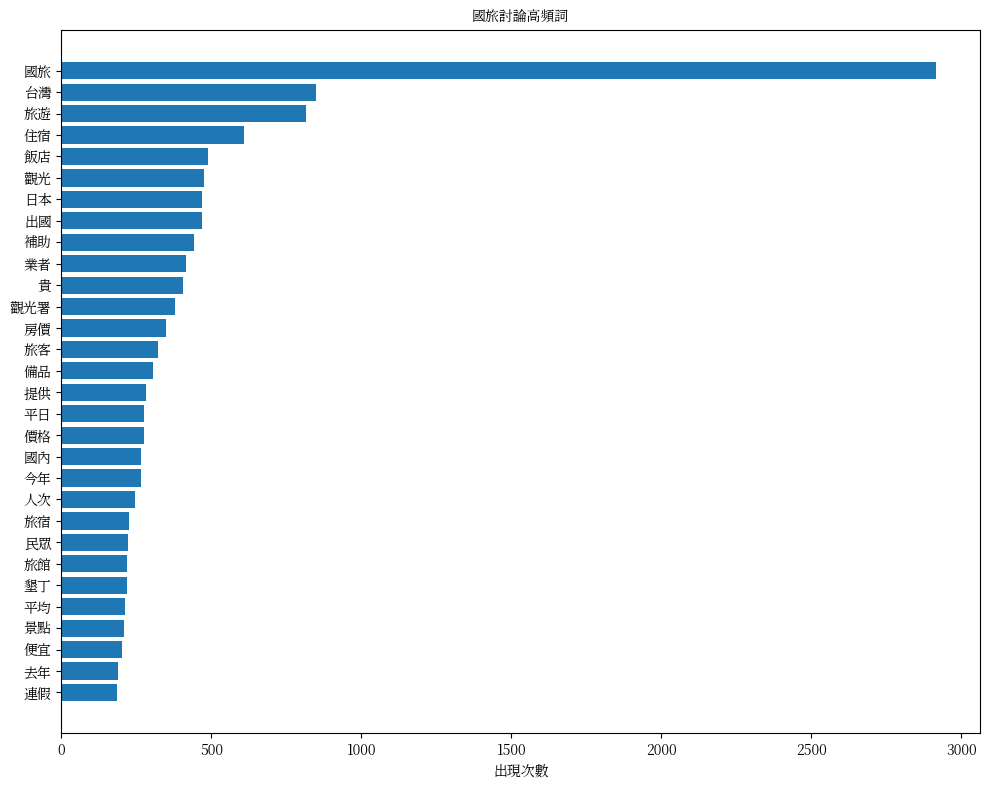

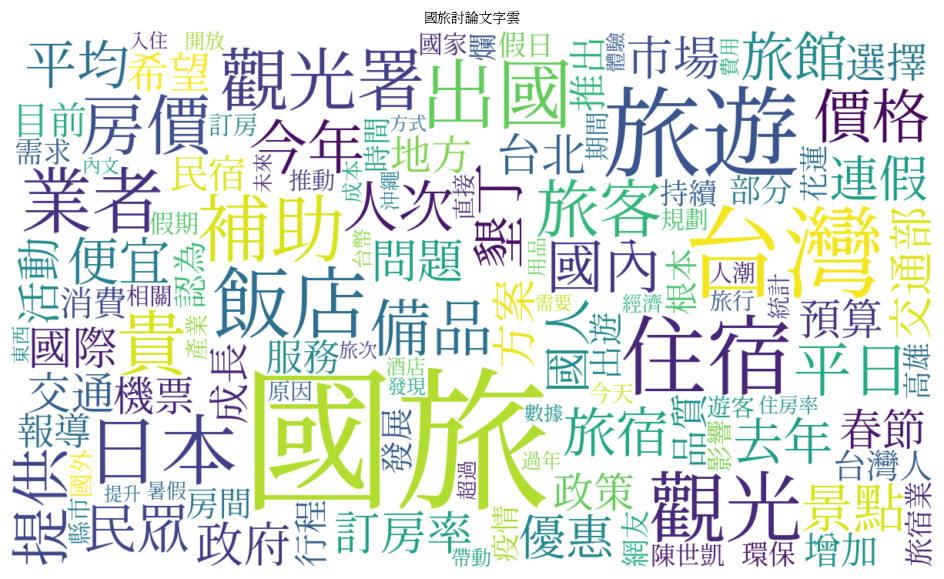

In [9]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from wordcloud import WordCloud


def find_chinese_font() -> str | None:
    keywords = [
        "NotoSansCJK",
        "Noto Sans CJK",
        "NotoSansTC",
        "Noto Serif CJK",
        "SourceHan",
        "TaipeiSans",
        "PingFang",
    ]
    font_paths = fm.findSystemFonts()
    for font_path in font_paths:
        normalized_path = font_path.lower().replace(" ", "").replace("-", "")
        if any(keyword.lower().replace(" ", "").replace("-", "") in normalized_path for keyword in keywords):
            return font_path
    return None


font_path = find_chinese_font()
if font_path is None:
    raise RuntimeError("找不到中文字型。若在 Colab，請先重新執行 C-1 套件準備格。")

font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["axes.unicode_minus"] = False

plot_df = top_terms_df.sort_values("次數", ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["詞彙"], plot_df["次數"])
ax.set_title("國旅討論高頻詞", fontproperties=font_prop)
ax.set_xlabel("出現次數", fontproperties=font_prop)
for label in ax.get_yticklabels() + ax.get_xticklabels():
    label.set_fontproperties(font_prop)
fig.tight_layout()
plt.show()

wc = WordCloud(
    font_path=font_path,
    width=1200,
    height=700,
    background_color="white",
    max_words=120,
    collocations=False,
).generate_from_frequencies(word_counts)

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("國旅討論文字雲", fontproperties=font_prop)
plt.show()


### C-7. TF-IDF 重要詞分析

詞頻可以看出整體最常出現的詞，但容易被常見主題詞主導。TF-IDF 會降低所有文章都常出現的詞權重，凸顯較能區分不同文章的關鍵詞。


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer


tokenized_docs = analysis_df["tokens"].map(lambda tokens: " ".join(tokens))

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    min_df=3,
    max_df=0.85,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(tokenized_docs)
tfidf_terms = tfidf_vectorizer.get_feature_names_out()
tfidf_mean_scores = tfidf_matrix.mean(axis=0).A1

tfidf_top_df = (
    pd.DataFrame({"詞彙": tfidf_terms, "TF-IDF": tfidf_mean_scores})
    .sort_values("TF-IDF", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

tfidf_top_df

,詞彙,TF-IDF
0,台灣,0.047452
1,日本,0.040006
2,出國,0.037033
3,貴,0.034779
4,住宿,0.032777
5,旅遊,0.032127
6,飯店,0.032118
7,備品,0.027093
8,補助,0.024930
9,業者,0.021792


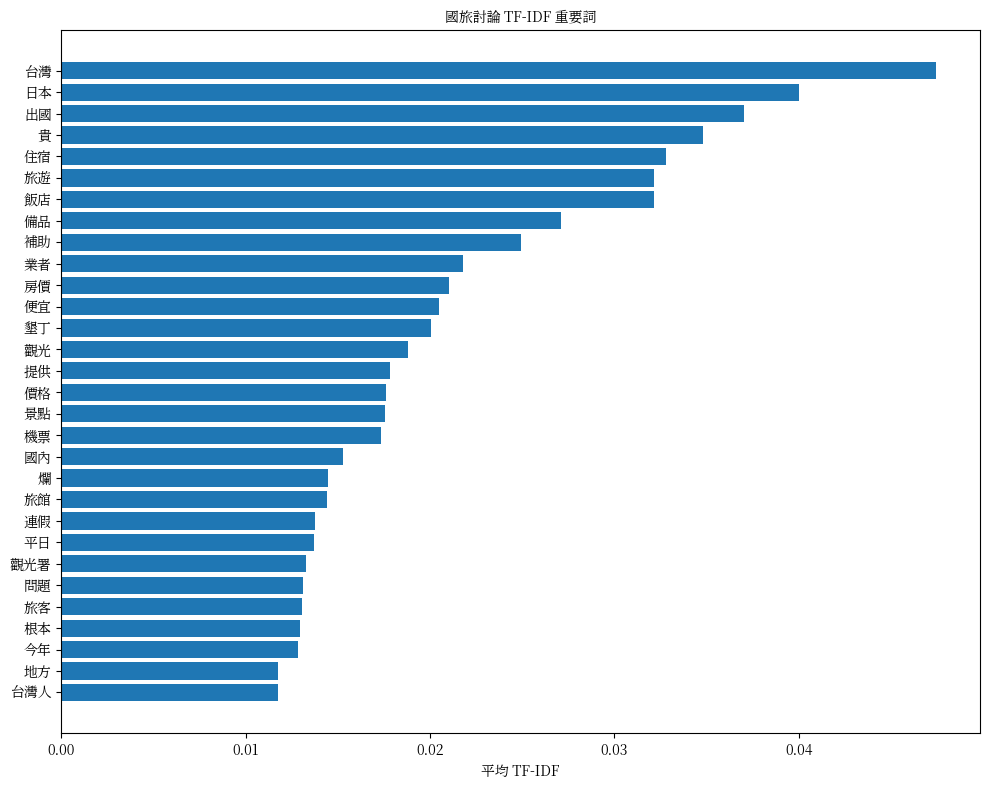

In [11]:
tfidf_plot_df = tfidf_top_df.sort_values("TF-IDF", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(tfidf_plot_df["詞彙"], tfidf_plot_df["TF-IDF"])
ax.set_title("國旅討論 TF-IDF 重要詞", fontproperties=font_prop)
ax.set_xlabel("平均 TF-IDF", fontproperties=font_prop)
for label in ax.get_yticklabels() + ax.get_xticklabels():
    label.set_fontproperties(font_prop)
fig.tight_layout()
plt.show()

### C-8. n-gram 詞組分析

單一詞彙無法完整呈現語意關係，因此接著統計相鄰詞組。bigram 觀察兩詞組合，trigram 觀察三詞組合，可用來找出常見討論搭配。


In [12]:
from collections import Counter


def collect_ngrams(token_lists: pd.Series, n: int) -> Counter:
    counter = Counter()
    for tokens in token_lists:
        if len(tokens) < n:
            continue
        counter.update(" ".join(tokens[i : i + n]) for i in range(len(tokens) - n + 1))
    return counter


bigram_counts = collect_ngrams(analysis_df["tokens"], 2)
trigram_counts = collect_ngrams(analysis_df["tokens"], 3)

bigram_df = pd.DataFrame(bigram_counts.most_common(30), columns=["詞組", "次數"])
trigram_df = pd.DataFrame(trigram_counts.most_common(30), columns=["詞組", "次數"])

display(bigram_df)
display(trigram_df)

,詞組,次數
0,國內 旅遊,137
1,國旅 補助,131
2,台灣 國旅,129
3,國旅 住宿,105
4,國旅 貴,81
5,平均 房價,79
6,提供 備品,74
7,交通部 觀光署,68
8,出國 國旅,67
9,旅宿 業者,66


,詞組,次數
0,平日 住宿 補助,25
1,國旅 住宿 貴,22
2,生日 住宿 優惠,19
3,平日 國旅 優惠,18
4,觀光 署長 陳玉秀,17
5,旅館 平均 房價,17
6,住宿 優惠 方案,17
7,企業 員工 旅遊,17
8,平日 住宿 優惠,16
9,住客 人次 人次,16


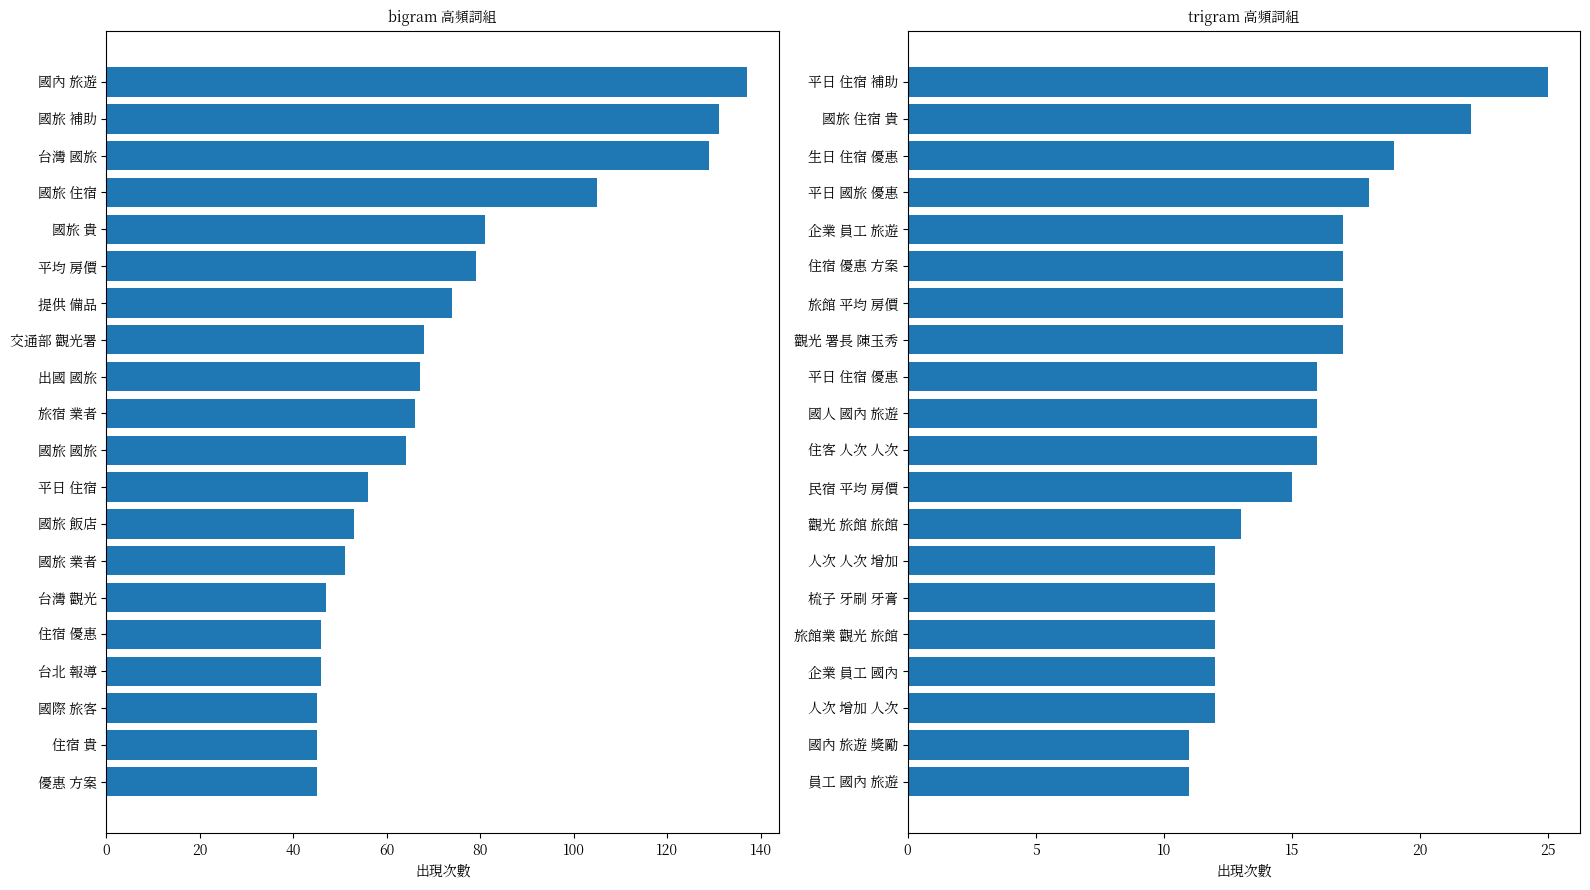

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

for ax, plot_df, title in [
    (axes[0], bigram_df.head(20).sort_values("次數", ascending=True), "bigram 高頻詞組"),
    (axes[1], trigram_df.head(20).sort_values("次數", ascending=True), "trigram 高頻詞組"),
]:
    ax.barh(plot_df["詞組"], plot_df["次數"])
    ax.set_title(title, fontproperties=font_prop)
    ax.set_xlabel("出現次數", fontproperties=font_prop)
    for label in ax.get_yticklabels() + ax.get_xticklabels():
        label.set_fontproperties(font_prop)

fig.tight_layout()
plt.show()

### C-9. 關鍵詞共現網路

共現網路用來觀察重要詞是否常出現在同一篇文章中。節點代表詞彙，邊代表兩個詞在同一篇文章共同出現；邊越粗代表共現次數越高。

這裡輸出互動式 HTML 圖，可以拖曳、縮放，也可以把游標移到節點或邊上查看出現次數。


In [14]:
from itertools import combinations


network_terms = set(top_terms_df.head(35)["詞彙"]) | set(tfidf_top_df.head(35)["詞彙"])
network_terms = {term for term in network_terms if term not in {"國旅"}}

cooccurrence_counts = Counter()
for tokens in analysis_df["tokens"]:
    present_terms = sorted(set(token for token in tokens if token in network_terms))
    for pair in combinations(present_terms, 2):
        cooccurrence_counts[pair] += 1

cooccurrence_df = (
    pd.DataFrame(
        [
            {"詞彙1": term_1, "詞彙2": term_2, "共現次數": count}
            for (term_1, term_2), count in cooccurrence_counts.items()
        ]
    )
    .sort_values("共現次數", ascending=False)
    .reset_index(drop=True)
)

cooccurrence_df.head(30)


,詞彙1,詞彙2,共現次數
0,台灣,旅遊,159
1,台灣,日本,129
2,住宿,台灣,122
3,住宿,旅遊,122
4,台灣,飯店,119
5,出國,台灣,118
6,旅遊,業者,108
7,旅遊,觀光,107
8,國內,旅遊,105
9,台灣,貴,102


In [15]:
from IPython.display import HTML, IFrame, display
from pyvis.network import Network


edge_threshold = 45
max_edges = 45
plot_edges = cooccurrence_df[cooccurrence_df["共現次數"] >= edge_threshold].head(max_edges)

net = Network(
    notebook=True,
    height="750px",
    width="100%",
    bgcolor="#ffffff",
    font_color="#111827",
    cdn_resources="in_line",
)
net.force_atlas_2based(
    gravity=-45,
    central_gravity=0.015,
    spring_length=130,
    spring_strength=0.08,
    damping=0.4,
)

node_terms = sorted(set(plot_edges["詞彙1"]) | set(plot_edges["詞彙2"]))
for term in node_terms:
    count = word_counts.get(term, 1)
    net.add_node(
        term,
        label=term,
        title=f"{term}：出現 {count} 次",
        value=max(8, min(count / 8, 80)),
        color="#8ecae6",
    )

for _, row in plot_edges.iterrows():
    weight = int(row["共現次數"])
    net.add_edge(
        row["詞彙1"],
        row["詞彙2"],
        value=max(1, weight / 18),
        title=f"共現 {weight} 次",
        color="#64748b",
    )

net.set_options("""
{
  "nodes": {
    "font": {"size": 22, "face": "Noto Sans CJK TC, Noto Sans CJK JP, Arial"},
    "borderWidth": 1
  },
  "edges": {
    "smooth": false,
    "color": {"inherit": false}
  },
  "interaction": {
    "hover": true,
    "tooltipDelay": 120,
    "navigationButtons": true,
    "keyboard": true
  },
  "physics": {
    "stabilization": {"iterations": 180}
  }
}
""")

network_path = (
    Path("/content/cooccurrence_network.html")
    if Path("/content").exists()
    else Path("output/cooccurrence_network.html")
)
network_path.parent.mkdir(parents=True, exist_ok=True)
net.save_graph(str(network_path))

print(f"互動圖已輸出：{network_path}")
display(IFrame(src=str(network_path), width="100%", height=760))
display(HTML(network_path.read_text(encoding="utf-8")))


互動圖已輸出：/content/cooccurrence_network.html


### C-10. CKIP 詞性與命名實體分析

這段接續 CKIP 斷詞結果，進一步做詞性標註與命名實體辨識。詞性可以觀察討論焦點偏向哪些名詞、動作或描述詞；命名實體可以整理國旅討論中常被提到的地名、組織與人物。

CKIP 詞性與實體辨識會沿用自動偵測的運算裝置；有 GPU 就使用 GPU，沒有就使用 CPU。第一次執行會花時間，因此結果會存成快取，之後重跑可以直接讀取。


In [20]:
import json
import torch
from ckip_transformers.nlp import CkipNerChunker, CkipPosTagger
from IPython.display import display


def get_ckip_device() -> int:
    if torch.cuda.is_available():
        print(f"CKIP 使用 GPU：{torch.cuda.get_device_name(0)}")
        return 0
    print("CKIP 使用 CPU")
    return -1


if "CKIP_DEVICE" not in globals():
    CKIP_DEVICE = get_ckip_device()


pos_cache_path = DATA_DIR / "ckip_pos_tags.json"
ner_cache_path = DATA_DIR / "ckip_ner_chunks.json"
tokens_cache_path = DATA_DIR / "ckip_tokens_raw.json"

if "tokens_raw" not in analysis_df.columns:
    if tokens_cache_path.exists():
        analysis_df["tokens_raw"] = json.loads(tokens_cache_path.read_text(encoding="utf-8"))
        print(f"已讀取 CKIP 斷詞快取：{tokens_cache_path}")
    else:
        raise RuntimeError("找不到 CKIP 斷詞結果。請先執行 C-3。")

if pos_cache_path.exists():
    pos_tags = json.loads(pos_cache_path.read_text(encoding="utf-8"))
    if len(pos_tags) != len(analysis_df):
        raise RuntimeError("CKIP 詞性快取筆數和目前資料不一致，請刪除快取後重跑這一格。")
    analysis_df["pos_tags"] = pos_tags
    print(f"已讀取 CKIP 詞性快取：{pos_cache_path}")
else:
    pos_driver = CkipPosTagger(model="bert-base", device=CKIP_DEVICE)
    analysis_df["pos_tags"] = pos_driver(analysis_df["tokens_raw"].tolist(), batch_size=16)
    pos_cache_path.write_text(
        json.dumps(analysis_df["pos_tags"].tolist(), ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"已儲存 CKIP 詞性快取：{pos_cache_path}")


def split_chunks_with_offsets(text: str, max_chars: int = 250) -> list[tuple[str, int]]:
    text = text.strip()
    if not text:
        return []
    return [(text[i : i + max_chars], i) for i in range(0, len(text), max_chars)]


if ner_cache_path.exists():
    ner_records = json.loads(ner_cache_path.read_text(encoding="utf-8"))
    print(f"已讀取 CKIP 實體快取：{ner_cache_path}")
else:
    ner_driver = CkipNerChunker(model="bert-base", device=CKIP_DEVICE)
    ner_texts = []
    ner_doc_ids = []
    ner_offsets = []
    for article_id, text in enumerate(analysis_df["clean_text"].tolist()):
        for chunk_text, offset in split_chunks_with_offsets(text):
            ner_texts.append(chunk_text)
            ner_doc_ids.append(article_id)
            ner_offsets.append(offset)

    ner_chunks = ner_driver(ner_texts, batch_size=16)
    ner_records = []
    for article_id, offset, entities in zip(ner_doc_ids, ner_offsets, ner_chunks):
        sorted_entities = sorted(
            entities,
            key=lambda entity: (getattr(entity, "idx", (0, 0))[0], getattr(entity, "word", "")),
        )
        for entity in sorted_entities:
            start, end = getattr(entity, "idx", (None, None))
            ner_records.append(
                {
                    "article_id": int(article_id),
                    "詞彙": getattr(entity, "word", ""),
                    "實體類型": getattr(entity, "ner", ""),
                    "起點": None if start is None else int(start + offset),
                    "終點": None if end is None else int(end + offset),
                }
            )

    ner_cache_path.write_text(
        json.dumps(ner_records, ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"已儲存 CKIP 實體快取：{ner_cache_path}")

print(f"詞性標註文章數：{len(analysis_df):,}")
print(f"命名實體筆數：{len(ner_records):,}")


已讀取 CKIP 詞性快取：data/ckip_pos_tags.json
已讀取 CKIP 實體快取：data/ckip_ner_chunks.json
詞性標註文章數：923
命名實體筆數：9,721


In [22]:
if "stopwords" not in globals():
    dict_dir = Path("/content/dict") if Path("/content").exists() else Path("dict")
    stopwords = load_words(dict_dir / "stopwords.txt")

if "keep_single_char_words" not in globals():
    keep_single_char_words = {"貴", "盤", "爛", "雷", "坑", "爽"}


def keep_pos_token(token: str) -> bool:
    token = token.strip()
    if not token:
        return False
    if token in stopwords:
        return False
    if len(token) == 1 and token not in keep_single_char_words:
        return False
    if re.fullmatch(r"\d+", token):
        return False
    return True


def classify_pos(pos: str) -> str:
    if pos.startswith("N"):
        return "名詞"
    if pos.startswith("V"):
        return "動詞"
    if pos.startswith("A"):
        return "形容詞"
    if pos.startswith("D"):
        return "副詞"
    return "其他"


pos_records = []
for article_id, (tokens, tags) in enumerate(zip(analysis_df["tokens_raw"], analysis_df["pos_tags"])):
    for token, pos in zip(tokens, tags):
        if keep_pos_token(token):
            pos_records.append(
                {
                    "article_id": article_id,
                    "詞彙": token,
                    "詞性": pos,
                    "詞性類別": classify_pos(pos),
                }
            )

pos_df = pd.DataFrame(pos_records)
pos_group_counts = (
    pos_df["詞性類別"]
    .value_counts()
    .rename_axis("詞性類別")
    .reset_index(name="詞數")
)
top_pos_terms = (
    pos_df[pos_df["詞性類別"].isin(["名詞", "動詞", "形容詞"])]
    .groupby(["詞性類別", "詞彙", "詞性"])
    .size()
    .reset_index(name="出現次數")
    .sort_values(["詞性類別", "出現次數"], ascending=[True, False])
)

display(pos_group_counts)
display(top_pos_terms.groupby("詞性類別", group_keys=False).head(20))


,詞性類別,詞數
0,名詞,36307
1,動詞,22114
2,副詞,1887
3,形容詞,468
4,其他,369


,詞性類別,詞彙,詞性,出現次數
2069,動詞,旅遊,VA,723
214,動詞,住宿,VA,570
442,動詞,出國,VA,452
3350,動詞,觀光,VA,409
3555,動詞,貴,VH,403
3320,動詞,補助,VD,389
1803,動詞,提供,VD,282
1312,動詞,平均,VH,213
247,動詞,便宜,VH,201
2059,動詞,旅宿,VA,183


#### 地名／行政區（GPE）

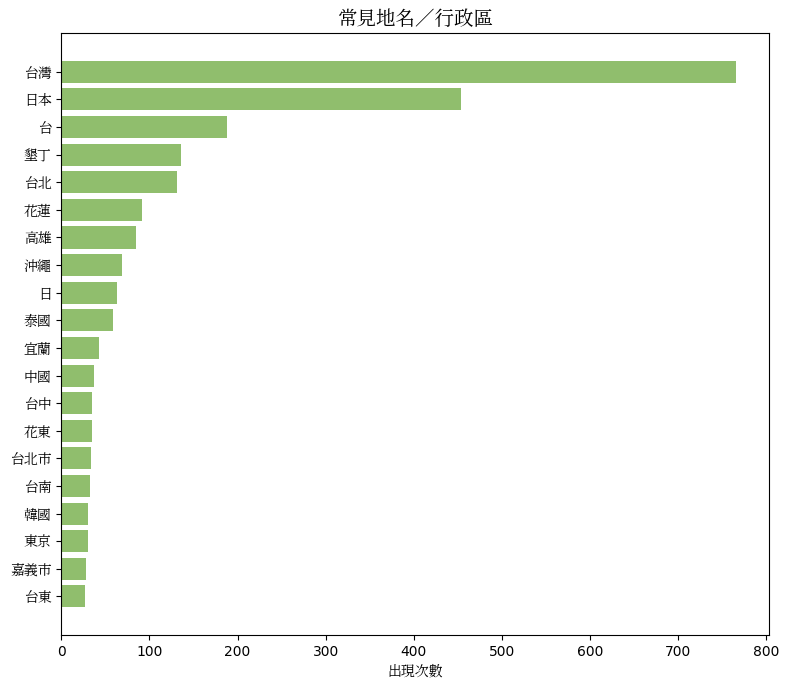

#### 地點（LOC）

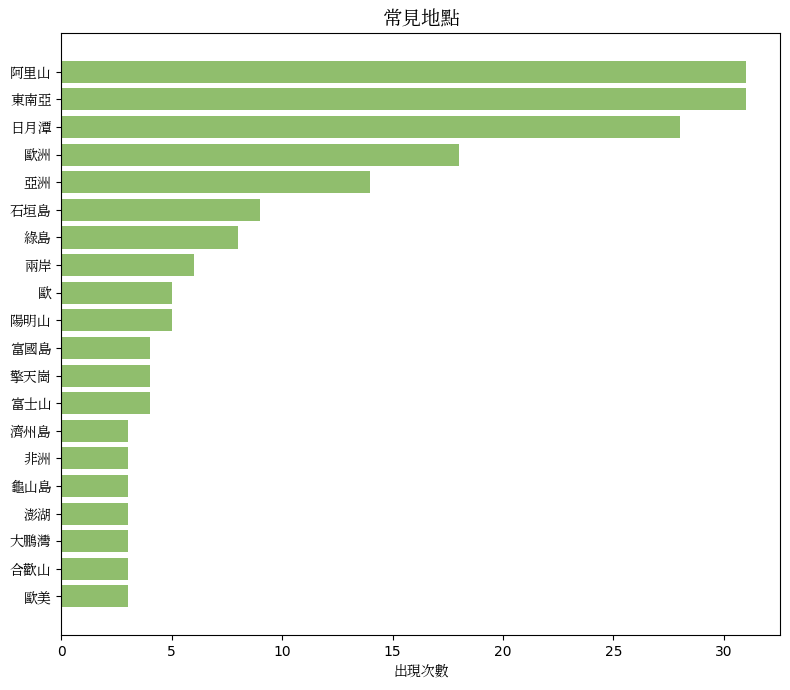

#### 組織（ORG）

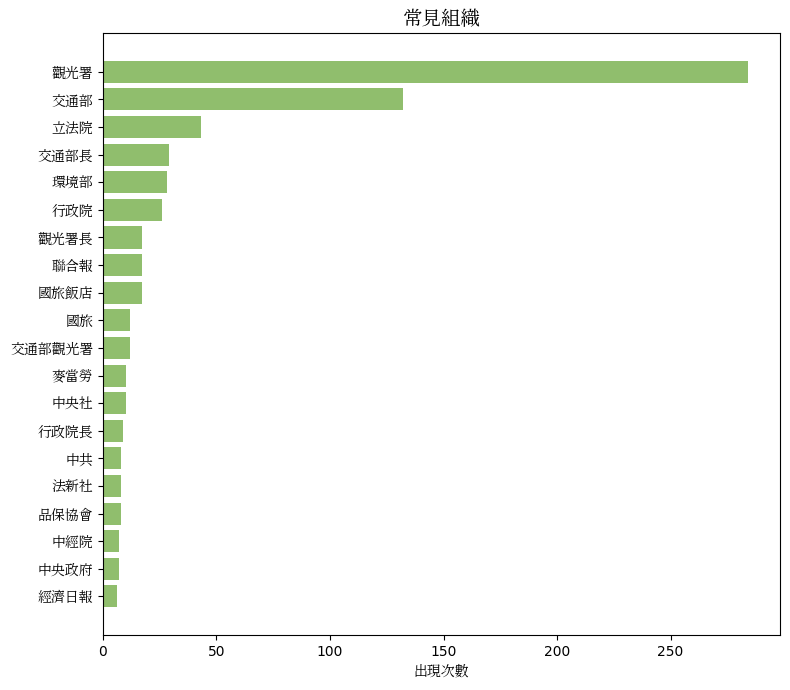

#### 設施（FAC）

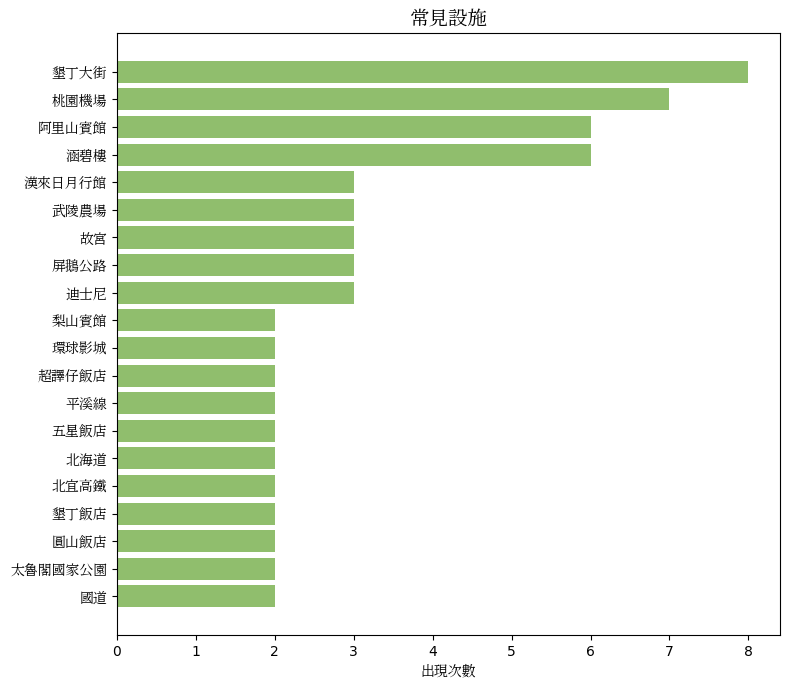

#### 人物（PERSON）

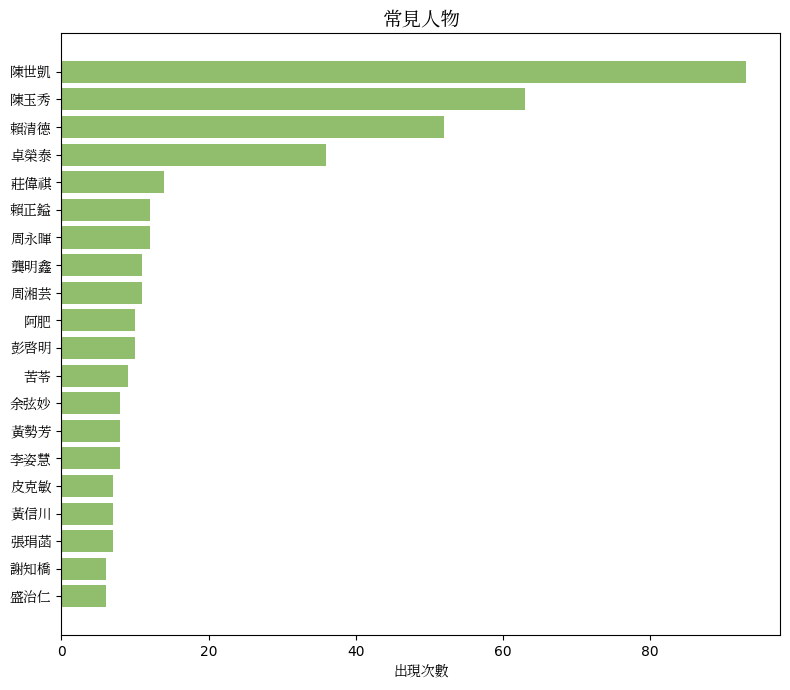

In [23]:
from IPython.display import Markdown


ner_df = pd.DataFrame(ner_records)

entity_type_names = {
    "GPE": "地名／行政區",
    "LOC": "地點",
    "ORG": "組織",
    "FAC": "設施",
    "PERSON": "人物",
}

if ner_df.empty:
    print("CKIP 沒有辨識出命名實體。")
else:
    ner_df["title"] = ner_df["article_id"].map(analysis_df["title"].to_dict())
    ner_df["實體類別"] = ner_df["實體類型"].map(entity_type_names).fillna(ner_df["實體類型"])

    entity_type_counts = (
        ner_df.groupby(["實體類型", "實體類別"])
        .size()
        .reset_index(name="實體數")
        .sort_values("實體數", ascending=False)
    )
    top_entities = (
        ner_df.groupby(["實體類型", "實體類別", "詞彙"])
        .size()
        .reset_index(name="出現次數")
        .sort_values(["實體類型", "出現次數"], ascending=[True, False])
    )

    focus_entity_types = ["GPE", "LOC", "ORG", "FAC", "PERSON"]
    for entity_type in focus_entity_types:
        entity_label = entity_type_names[entity_type]
        type_entities = top_entities[top_entities["實體類型"] == entity_type].head(20).copy()

        display(Markdown(f"#### {entity_label}（{entity_type}）"))
        if type_entities.empty:
            print(f"沒有辨識到{entity_label}。")
            continue

        plot_entities = type_entities.sort_values("出現次數", ascending=True)
        fig, ax = plt.subplots(figsize=(8, max(3, len(plot_entities) * 0.35)))
        ax.barh(plot_entities["詞彙"], plot_entities["出現次數"], color="#90be6d")
        ax.set_title(f"常見{entity_label}", fontproperties=font_prop, fontsize=14)
        ax.set_xlabel("出現次數", fontproperties=font_prop)
        for label in ax.get_yticklabels():
            label.set_fontproperties(font_prop)
        fig.tight_layout()
        plt.show()


## D. 視覺化的分析結果與解釋

如果只看目前完成的分析，八卦板使用者最關心的不是單一議題，而是幾個議題如何連在一起。第一個、也是最穩定的主軸是住宿與價格。詞頻中「住宿」、「飯店」、「貴」、「房價」、「價格」、「便宜」都排在前面，TF-IDF 也把「貴」、「住宿」、「飯店」、「房價」、「便宜」列為重要詞；n-gram 又出現「國旅 住宿」、「國旅 貴」、「平均 房價」、「住宿 貴」、「國旅 住宿 貴」。這表示價格問題不是只以抽象抱怨出現，而是集中落在住宿、飯店和房價這些具體消費項目上。

第二個主軸是政策與補助，而且它和住宿價格高度綁在一起。結果中「補助」、「觀光署」、「交通部」、「優惠」、「方案」很明顯，n-gram 也出現「國旅 補助」、「平日 住宿 補助」、「住宿 優惠 方案」、「交通部 觀光署」、「交通部 觀光署 規劃」。這說明網友討論國旅時，補助不是獨立的政策新聞，而是經常被放在住宿成本太高、需要優惠或外部誘因的脈絡中理解。

第三個主軸是出國比較。「日本」、「出國」、「機票」在 TF-IDF 和詞頻中都很突出，共現網路也有「台灣－日本」、「出國－台灣」、「出國－旅遊」、「出國－日本」等連結。這表示國旅不是被單獨評價，而是常被拿來和日本或其他海外目的地比較。當住宿價格、飯店服務和出國成本被放在同一個比較框架裡，國旅的不滿就不只是「貴」，而是「相對不值得」。

除了這三個主軸，交通、景點、服務品質和假期也有出現，但目前比較像次要脈絡。景點相關詞有「景點」、「墾丁」、「阿里山」、「日月潭」、「花蓮」等，交通相關詞有「交通」、「機票」、「高鐵」等，服務品質則可從「備品」、「服務」、「品質」、「體驗」、「牙刷」、「牙膏」看到；假期脈絡則反映在「平日」、「連假」、「春節」等詞。不過，這些面向在目前視覺化結果中，多半是接在住宿價格、政策補助或出國比較後面，而不是獨立成為最強主軸。

共現網路把上述結構串起來。網路中最中心的是「旅遊」、「台灣」、「住宿」，但真正有解釋力的是它們連到哪些詞：強連結包括「台灣－日本」、「出國－台灣」、「住宿－台灣」、「住宿－旅遊」、「台灣－飯店」、「台灣－貴」、「住宿－貴」、「貴－飯店」。也就是說，國旅討論的核心不是單純的台灣旅遊，而是台灣旅遊、住宿價格、飯店服務、出國比較共同組成的問題網絡。

命名實體分析則補上具體對象。地名中「台灣」最高，「日本」第二，後面還有「墾丁」、「台北」、「花蓮」、「高雄」、「沖繩」、「泰國」、「韓國」、「東京」；地點類別中同時出現「阿里山」、「日月潭」與「東南亞」、「歐洲」、「石垣島」。組織實體中「觀光署」明顯高於其他單位，「交通部」也排在前面。這些結果顯示，國旅討論不是只在抽象比較國內外，而是把具體國內目的地、海外目的地、觀光政策單位放進同一個選擇場景。

因此，目前這 6 個分析可以回答的重點是：大家最關心的是住宿價格，其次是補助政策，再來是出國比較；景點、交通、服務品質與假期也有被討論，但不是這份分析中最強的主軸。更精確地說，八卦板上的國旅問題不是單純「太貴」四個字，而是國旅被放進「住宿價格是否合理、補助是否代表需要外部誘因、同樣預算是否不如出國」的比較結構中評價。


對「國旅」情緒分析

## Lexicon-based 情緒分析

### 準備LIWC字典  

In [13]:
# 讀取情緒字典
liwc_dict = pd.read_csv("./dict/liwc/LIWC_CH.csv")
liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})
liwc_dict.head()

,word,sentiments
0,):,affect
1,3q,affect
2,:(,affect
3,:),affect
4,<3,affect


In [14]:
liwc_dict['sentiments'].describe()

count       4682
unique         6
top       affect
freq        2061
Name: sentiments, dtype: object

### 情緒字典與斷詞結果進行合併

In [15]:
ptt_liwc_df = pd.merge(noStop_df[["matched_keyword", "artDate", "artTitle", "artContent", "word"]], liwc_dict, how="left")
# ptt_liwc_df = pd.merge(word_df[["matched_keyword", "artDate", "artTitle", "artContent", "word"]], liwc_dict, how="left")
ptt_liwc_df.head()

,matched_keyword,artDate,artTitle,artContent,word,sentiments
0,國旅,2026-06-14,[問卦] 去了富國島才知道國旅有多盤,我們不說什麼醫療資源\n也不說什麼飲食\n光是我一個人平均一個晚上台幣不到2000\n泳池別...,不說,NaN
1,國旅,2026-06-14,[問卦] 去了富國島才知道國旅有多盤,我們不說什麼醫療資源\n也不說什麼飲食\n光是我一個人平均一個晚上台幣不到2000\n泳池別...,醫療,NaN
2,國旅,2026-06-14,[問卦] 去了富國島才知道國旅有多盤,我們不說什麼醫療資源\n也不說什麼飲食\n光是我一個人平均一個晚上台幣不到2000\n泳池別...,資源,NaN
3,國旅,2026-06-14,[問卦] 去了富國島才知道國旅有多盤,我們不說什麼醫療資源\n也不說什麼飲食\n光是我一個人平均一個晚上台幣不到2000\n泳池別...,飲食,NaN
4,國旅,2026-06-14,[問卦] 去了富國島才知道國旅有多盤,我們不說什麼醫療資源\n也不說什麼飲食\n光是我一個人平均一個晚上台幣不到2000\n泳池別...,平均,NaN


### 正負向情緒詞彙頻率折線圖圖
分別畫出文集中，正向（positive）與負向（negative）情緒的折線圖

In [16]:
sentiment_count = pd.DataFrame(
    ptt_liwc_df.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count['sentiments'] == "positive") | (sentiment_count['sentiments'] == "negative") 
sentiment_count = sentiment_count.loc[mask]

sentiment_count = sentiment_count.rename(columns={0: "size"})
sentiment_count = sentiment_count.sort_values(["artDate"])
sentiment_count.head(10)

,artDate,sentiments,size
2,2025-01-02,negative,3
3,2025-01-02,positive,5
8,2025-01-04,negative,5
9,2025-01-04,positive,17
14,2025-01-05,negative,8
15,2025-01-05,positive,13
20,2025-01-06,negative,2
21,2025-01-06,positive,2
24,2025-01-07,negative,3
29,2025-01-08,negative,10


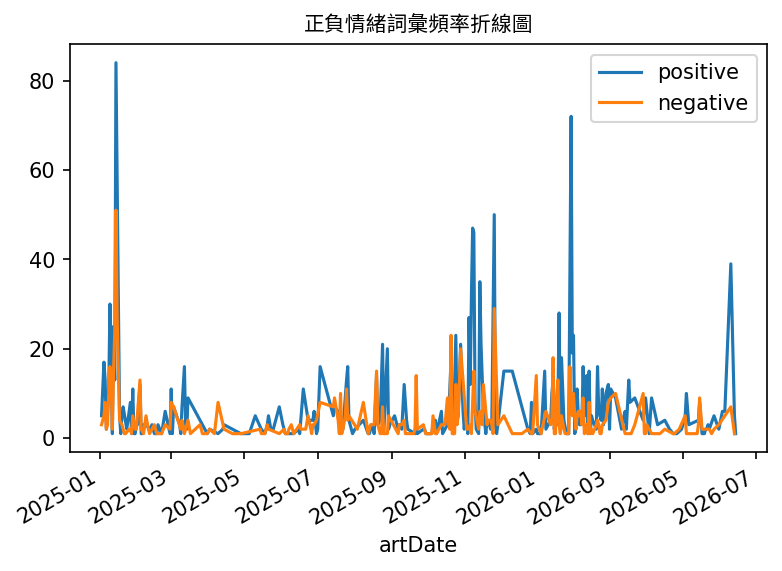

In [17]:
colors = ["tab:blue", "tab:orange"]
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

ax.plot(pos["artDate"], pos["size"], color=colors[0])
ax.plot(neg["artDate"], neg["size"], color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負情緒詞彙頻率折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

```Moving average```

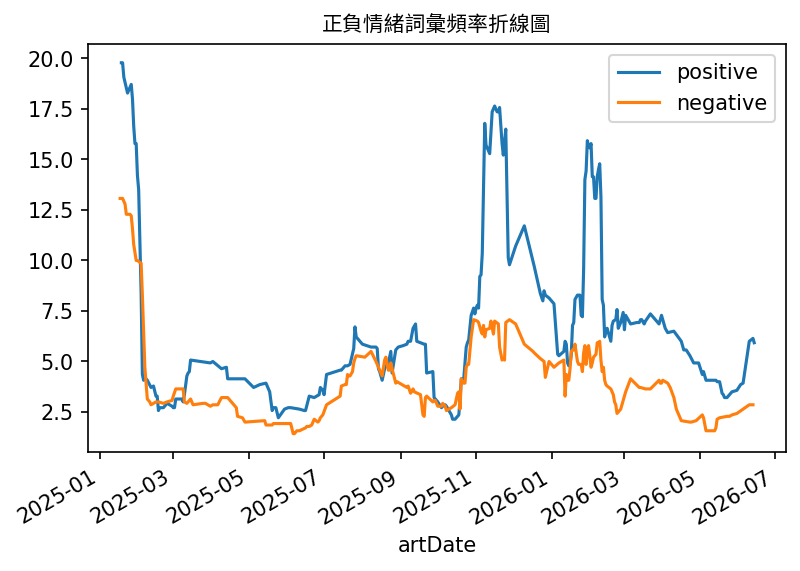

In [18]:
colors = ["tab:blue", "tab:orange"]
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos["artDate"], pos['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["size"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負情緒詞彙頻率折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

這是單純將原始資料使用停用字以及根據文章內容設定停用字後的結果，可以發現整體情緒分數偏向正面，
這跟我們預設的結果不同，認為 PTT 八卦版中，討論國旅的網友應該都偏向負面情緒。

### 正負向情緒詞彙比例折線圖圖

In [19]:
sentiment_count = sentiment_count.assign(
    ratio=sentiment_count.groupby("artDate")["size"].transform(lambda n: n / n.sum())
)
sentiment_count.head(10)

,artDate,sentiments,size,ratio
2,2025-01-02,negative,3,0.375000
3,2025-01-02,positive,5,0.625000
8,2025-01-04,negative,5,0.227273
9,2025-01-04,positive,17,0.772727
14,2025-01-05,negative,8,0.380952
15,2025-01-05,positive,13,0.619048
20,2025-01-06,negative,2,0.500000
21,2025-01-06,positive,2,0.500000
24,2025-01-07,negative,3,1.000000
29,2025-01-08,negative,10,0.476190


In [20]:
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

Text(0.5, 1.0, '正負情緒比例折線圖')

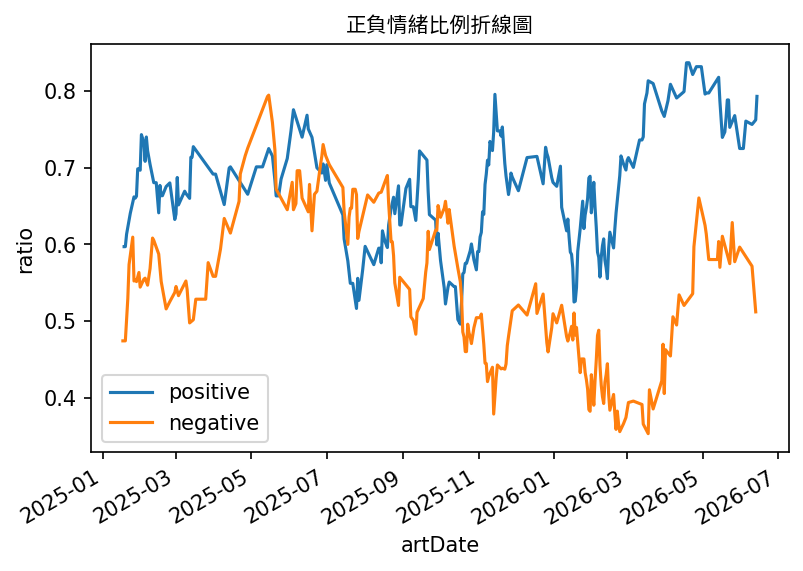

In [21]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(pos["artDate"], pos["ratio"].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["ratio"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
plt.ylabel("ratio")
ax.legend(["positive", "negative"], loc="lower left")
fig.autofmt_xdate()
plt.title("正負情緒比例折線圖", fontproperties=fprop)

從這張圖也可以發現在這三個時間段：2025-01-01 ~ 2025-02-01, 2025-11-01 ~ 2026-01-15, 2026-03-01 ~ 2026-05-01 正面情緒的文章較多，
其中 2025-01-01 ~ 2025-03-01, 2025-11-01 ~ 2026-01-15 認為可能跟春節連假相關，因為趨勢圖有時間的週期性
而 2026-03-01 ~ 2026-05-01 跟去年同月的時間相比，則差距甚遠，
後續可以針對這些時間段進行分析。

### 正負向情緒分數折線圖

In [22]:
sentiment_count.head(10)

,artDate,sentiments,size,ratio
2,2025-01-02,negative,3,0.375000
3,2025-01-02,positive,5,0.625000
8,2025-01-04,negative,5,0.227273
9,2025-01-04,positive,17,0.772727
14,2025-01-05,negative,8,0.380952
15,2025-01-05,positive,13,0.619048
20,2025-01-06,negative,2,0.500000
21,2025-01-06,positive,2,0.500000
24,2025-01-07,negative,3,1.000000
29,2025-01-08,negative,10,0.476190


In [23]:
ptt_sentiment_value = (
    sentiment_count.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
ptt_sentiment_value.head()

,artDate,negative,positive
0,2025-01-02,3.0,5.0
1,2025-01-04,5.0,17.0
2,2025-01-05,8.0,13.0
3,2025-01-06,2.0,2.0
4,2025-01-07,3.0,0.0


In [24]:
# sentiment 計算方式: positive - negative
ptt_sentiment_value["sentiment_value"] = (
    ptt_sentiment_value["positive"]
    - ptt_sentiment_value["negative"]
)
ptt_sentiment_value.head()

,artDate,negative,positive,sentiment_value
0,2025-01-02,3.0,5.0,2.0
1,2025-01-04,5.0,17.0,12.0
2,2025-01-05,8.0,13.0,5.0
3,2025-01-06,2.0,2.0,0.0
4,2025-01-07,3.0,0.0,-3.0


Text(0.5, 1.0, '正負情緒分數趨勢折線圖')

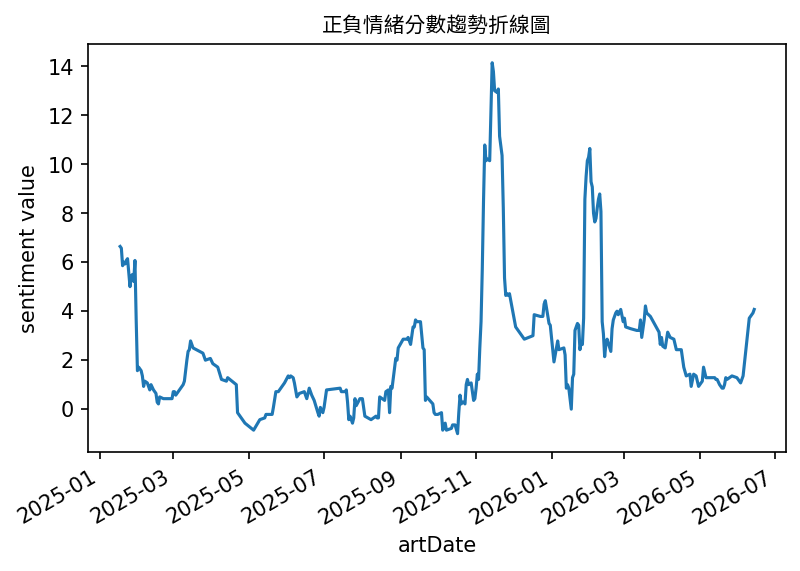

In [25]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(ptt_sentiment_value["artDate"], ptt_sentiment_value["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("正負情緒分數趨勢折線圖", fontproperties=fprop)

此途更能看出 PTT 八卦版對於國旅的討論情緒偏向正面，但這跟我們預想，網友抱怨國旅的結果不同。

### 文章為單位的情緒分析

In [26]:
sentiment_count_by_article = pd.DataFrame(
    ptt_liwc_df.groupby(["artTitle", "sentiments"]).size()
).reset_index()
sentiment_count_by_article = sentiment_count_by_article.rename(columns={0: "size"})
sentiment_count_by_article.head(10)

,artTitle,sentiments,size
0,[問卦] 12/25-1/1 國旅，出國幾乎都滿的 經濟,affect,1
1,[問卦] 200萬如果自費國旅可以花多久？,affect,1
2,[問卦] 200萬如果自費國旅可以花多久？,positive,1
3,[問卦] 200萬就能包機 國旅現在該怎麼辦,affect,3
4,[問卦] 200萬就能包機 國旅現在該怎麼辦,anx,1
5,[問卦] 200萬就能包機 國旅現在該怎麼辦,negative,1
6,[問卦] 200萬就能包機 國旅現在該怎麼辦,positive,2
7,[問卦] 2026春節機票大降價，國旅穩了？,affect,2
8,[問卦] 2026春節機票大降價，國旅穩了？,negative,2
9,[問卦] 228還去國旅的是不是有病?,affect,5


In [27]:
ptt_sentiment_value_by_article = (
    sentiment_count_by_article.pivot_table(
        index="artTitle", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
ptt_sentiment_value_by_article.head()

,artTitle,affect,anger,anx,negative,positive,sad
0,[問卦] 12/25-1/1 國旅，出國幾乎都滿的 經濟,1.0,0.0,0.0,0.0,0.0,0.0
1,[問卦] 200萬如果自費國旅可以花多久？,1.0,0.0,0.0,0.0,1.0,0.0
2,[問卦] 200萬就能包機 國旅現在該怎麼辦,3.0,0.0,1.0,1.0,2.0,0.0
3,[問卦] 2026春節機票大降價，國旅穩了？,2.0,0.0,0.0,2.0,0.0,0.0
4,[問卦] 228還去國旅的是不是有病?,5.0,1.0,2.0,4.0,1.0,0.0


In [28]:
# sentiment 計算方式: positive - negative
ptt_sentiment_value_by_article["sentiment_value"] = (
    ptt_sentiment_value_by_article["positive"]
    - ptt_sentiment_value_by_article["negative"]
)
ptt_sentiment_value_by_article.head()

,artTitle,affect,anger,anx,negative,positive,sad,sentiment_value
0,[問卦] 12/25-1/1 國旅，出國幾乎都滿的 經濟,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,[問卦] 200萬如果自費國旅可以花多久？,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,[問卦] 200萬就能包機 國旅現在該怎麼辦,3.0,0.0,1.0,1.0,2.0,0.0,1.0
3,[問卦] 2026春節機票大降價，國旅穩了？,2.0,0.0,0.0,2.0,0.0,0.0,-2.0
4,[問卦] 228還去國旅的是不是有病?,5.0,1.0,2.0,4.0,1.0,0.0,-3.0


In [29]:
ptt_sentiment_value_by_article['sentiment_class'] = ptt_sentiment_value_by_article['sentiment_value'].apply(lambda x: "正向" if x > 0 else "負向" )
ptt_sentiment_value_by_article.head(10)

,artTitle,affect,anger,anx,negative,positive,sad,sentiment_value,sentiment_class
0,[問卦] 12/25-1/1 國旅，出國幾乎都滿的 經濟,1.0,0.0,0.0,0.0,0.0,0.0,0.0,負向
1,[問卦] 200萬如果自費國旅可以花多久？,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
2,[問卦] 200萬就能包機 國旅現在該怎麼辦,3.0,0.0,1.0,1.0,2.0,0.0,1.0,正向
3,[問卦] 2026春節機票大降價，國旅穩了？,2.0,0.0,0.0,2.0,0.0,0.0,-2.0,負向
4,[問卦] 228還去國旅的是不是有病?,5.0,1.0,2.0,4.0,1.0,0.0,-3.0,負向
5,[問卦] 4000億美金幹嘛不拿來補助國旅?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,負向
6,[問卦] 484真的沒人國旅？？？？,2.0,1.0,0.0,1.0,1.0,0.0,0.0,負向
7,"[問卦] 9,10月那麼多連假，想必國旅會大爆發吧",1.0,0.0,0.0,1.0,0.0,0.0,-1.0,負向
8,[問卦] FB 國旅省錢教學文,25.0,0.0,0.0,0.0,25.0,0.0,25.0,正向
9,[問卦] NCC爆炸是不是國旅出的主意?,4.0,1.0,0.0,2.0,2.0,0.0,0.0,負向


In [30]:
clear_df_sentiment = pd.merge(df, ptt_sentiment_value_by_article[['artTitle', 'sentiment_class']], how="left")
clear_df_sentiment["artDate"] = pd.to_datetime(clear_df_sentiment["artDate"])
clear_df_sentiment['artDate'] = clear_df_sentiment['artDate'].dt.date

clear_df_sentiment.head()

,artTitle,matched_keyword,artDate,artContent,sentiment_class
0,[問卦] 去了富國島才知道國旅有多盤,國旅,2026-06-14,我們不說什麼醫療資源\n也不說什麼飲食\n光是我一個人平均一個晚上台幣不到2000\n泳池別...,正向
1,[問卦] 國旅很爛，拜託不要再來淡水跟士林了,國旅,2026-06-13,國旅真的很爛，東西貴又難吃，路邊小吃也不一定有經過衛生檢驗\n\n真的建議大家不要再往 淡水...,負向
2,[問卦] 帶小孩國旅的是有錢人？,國旅,2026-06-13,小魯一把年紀了\n觀察身邊有些朋友\n\n有的身上行頭都不錯 都有名牌潮牌 常出國旅遊\nI...,正向
3,[新聞]公務員提案「廢除國旅卡」 倡議改全額發,國旅,2026-06-10,https://news.ltn.com.tw/news/politics/breaking...,負向
4,[新聞] 國旅平日補助有曙光！最快9月上路 8月先,國旅,2026-06-10,國旅平日補助有曙光！最快9月上路 8月先抽生日住宿金\nhttps://bit.ly/4oj...,正向


In [31]:
sentiment_art_count = pd.DataFrame(
    clear_df_sentiment.groupby(["artDate", "sentiment_class"]).size()  # 看正負向的文章數
).reset_index()
sentiment_art_count = sentiment_art_count.rename(columns={0: "size"})
sentiment_art_count = sentiment_art_count.sort_values(["artDate"])
sentiment_art_count

,artDate,sentiment_class,size
0,2025-01-02,正向,1
1,2025-01-04,正向,4
2,2025-01-04,負向,1
3,2025-01-05,正向,6
4,2025-01-05,負向,5
...,...,...,...
382,2026-06-10,正向,3
383,2026-06-10,負向,1
384,2026-06-13,正向,1
385,2026-06-13,負向,1


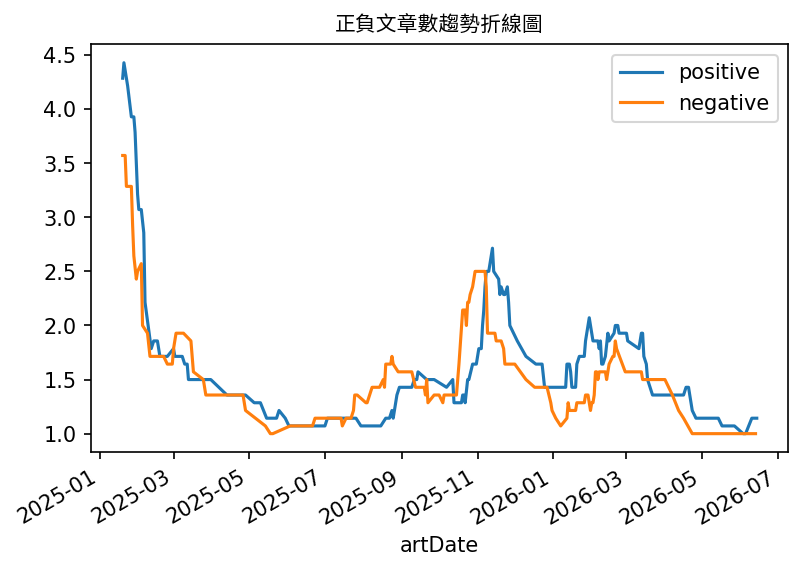

In [32]:
colors = ["tab:blue", "tab:orange"]
# sentiment_art_count.query("sentiment_class" == 正向) 可用這種寫法
pos = sentiment_art_count[sentiment_art_count["sentiment_class"] == "正向"]
neg = sentiment_art_count[sentiment_art_count["sentiment_class"] == "負向"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos["artDate"], pos['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["artDate"], neg["size"].rolling(rolling_days).mean(), color=colors[1])
# ax.plot(pos["artDate"], pos['size'], color=colors[0])
# ax.plot(neg["artDate"], neg["size"], color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負文章數趨勢折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

大部分文章都被歸類在正向文章，美食版討論內容大多偏正面

### 情緒代表字

In [33]:
word_count = ptt_liwc_df.groupby(["word", "sentiments"]).size().reset_index()
word_count = word_count.rename(columns={0: "size"}) # or 直接把尚義行後面變 .reset_index(name="size")
word_count = word_count.sort_values(["size"], ascending=False)

word_count.head(10)

,word,sentiments,size
100,優惠,affect,154
101,優惠,positive,154
231,問題,negative,132
230,問題,affect,132
365,希望,affect,122
366,希望,positive,122
1002,重要,affect,51
1003,重要,positive,51
215,吸引,positive,48
596,有錢,positive,48


In [34]:
word_of_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_of_pos.head(15)

,word,sentiments,size
101,優惠,positive,154
366,希望,positive,122
1003,重要,positive,51
215,吸引,positive,48
596,有錢,positive,48
1074,鼓勵,positive,48
306,好玩,positive,47
111,免費,positive,47
535,支持,positive,45
1036,願意,positive,37


In [35]:
word_of_neg = word_count.loc[(word_count["sentiments"] == "negative")]
word_of_neg.head(15)

,word,sentiments,size
231,問題,negative,132
269,垃圾,negative,42
1021,隨便,negative,38
509,抵制,negative,33
919,衰退,negative,31
260,嚴重,negative,26
277,壓力,negative,25
505,抱怨,negative,24
783,禁止,negative,24
912,衝擊,negative,22


C:\Users\KuanTo\AppData\Local\Temp\ipykernel_12448\391454114.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos["word"], fontproperties=fprop)
C:\Users\KuanTo\AppData\Local\Temp\ipykernel_12448\391454114.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg["word"], fontproperties=fprop)


Text(0.5, 1.0, '負向情緒總數')

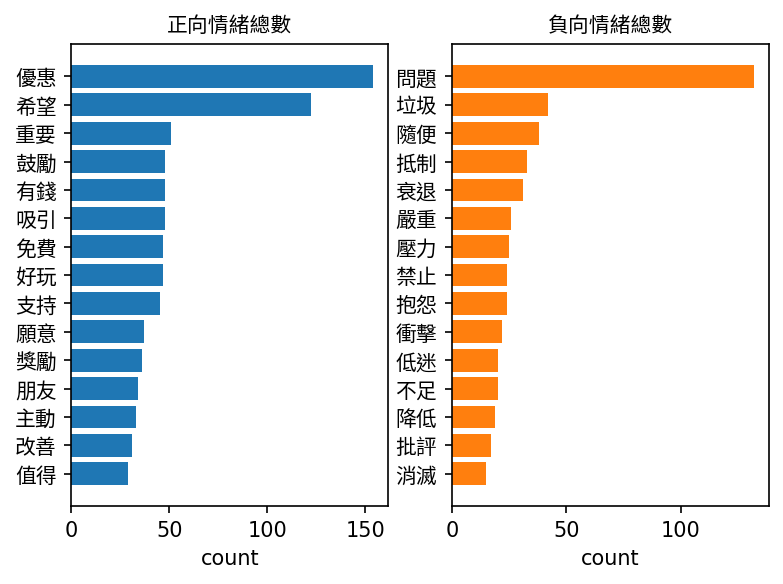

In [36]:
pos = word_of_pos.head(15).sort_values(["size"], ascending=True)
neg = word_of_neg.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2)

ax[0].barh(pos["word"], pos["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos["word"], fontproperties=fprop)
ax[0].set_title("正向情緒總數", fontproperties=fprop)

ax[1].barh(neg["word"], neg["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg["word"], fontproperties=fprop)
ax[1].set_title("負向情緒總數", fontproperties=fprop)

#### 檢查情緒詞是否符合本文本

In [37]:
filtered_df = sent_df[sent_df['sentence'].str.contains('好玩', na=False)]
filtered_df.head(10)

,artTitle,matched_keyword,artDate,artContent,sentence
437,[問卦] 一人推薦一個國旅景點,國旅,2026-05-22,最近在規劃國旅行程\n\n想說每個縣市都挑一個最頂的點去踩\n\n目前規劃\n嘉義 高跟鞋教...,其他縣市應該還有更多更頂的好玩國旅景點吧有沒有人可以建議一下
461,[問卦] 有人參加過國旅跟團嗎?,國旅,2026-05-20,通常去國外因為人生地不熟，比較需要跟團\n國內語言通，主要的道路也會走\n通常自由行就OK了...,國旅跟團好玩嗎
609,[新聞] 國旅有救了！旅行社推《皮克敏》行程 上,國旅,2026-05-04,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,大讚有一大堆同好一起玩真的很好玩
840,[問卦] 中國旅跟國旅哪個好玩,國旅,2026-04-18,中國旅\n\n人多\n\n要VPN\n\n人民素質參差不齊\n\n台灣極端派無法接受\n\n...,哪個比較好玩
2117,[問卦] （圖多）來炫富！開箱國旅一日遊！,國旅,2026-02-14,欸欸大家\n\n今年春節肥肥全家出遊沒有要在國外啦\n\n真是好險 現在廉航發達訂票訂旅館方...,真是好看又好玩
2283,[問卦] 跟日本一樣就不用擔心國旅了吧？,國旅,2026-02-12,日本觀光人數多到滿出來\n\n臺灣人也是各個景點幾乎都能看到個一兩組\n\n那把臺灣弄得跟日...,那把臺灣弄得跟日本一樣舒服好玩不過拯救國旅了
2801,[問卦] 台灣國旅會大崩壞誰的責任最大？,國旅,2026-02-03,我覺得台灣還是很好玩的，不然台灣現在不會滿街都是外國觀光客，外國觀光客也都覺的台\n灣很好玩...,我覺得台灣還是很好玩的
2803,[問卦] 台灣國旅會大崩壞誰的責任最大？,國旅,2026-02-03,我覺得台灣還是很好玩的，不然台灣現在不會滿街都是外國觀光客，外國觀光客也都覺的台\n灣很好玩...,外國觀光客也都覺的台灣很好玩
4072,[新聞] 不只是價格高！「國旅為何沒落」他曝原,國旅,2026-01-20,不只是價格高！「國旅為何沒落」他曝原因很簡單：怎麼可能再來\nhttps://bit.ly/...,又怎麼會讓旅客覺得好玩
4813,[問卦] 台灣各地「小吃」很好吃啊 怎麼說國旅差,國旅,2026-01-12,https://i.meee.com.tw/udWYKnf.jpg\n\n看看我們引以為傲的...,不簡單又好玩了


In [38]:
for sentence in filtered_df['sentence'].to_list():
    print(sentence)
    print("=========================")

其他縣市應該還有更多更頂的好玩國旅景點吧有沒有人可以建議一下
國旅跟團好玩嗎
大讚有一大堆同好一起玩真的很好玩
哪個比較好玩
真是好看又好玩
那把臺灣弄得跟日本一樣舒服好玩不過拯救國旅了
我覺得台灣還是很好玩的
外國觀光客也都覺的台灣很好玩
又怎麼會讓旅客覺得好玩
 不簡單又好玩了
根本原因是國旅不好玩吧
我身邊朋友去美國從來沒人說不好玩的
國旅的問題在於不好玩比如說夜市
還要吃得好玩得盡興
感覺很好玩啊
墾丁跟國旅這麼好玩為什麼你們都要去什麼日本韓國啊 
到最後就是花了很多錢彷彿歐洲的價格卻像去了趟東南亞回國也辦法跟朋友同事說到底有啥好玩這就是台灣觀光敗筆吧
讓我帶小模妹子好好玩
國旅最大的問題是周邊亞洲國家太好玩了
我以前是屬於以國旅為榮的人但我不是常跑長距離景點的那種而是在雙北的山區或冷門景點探索就覺得滿開心雖然那時親友會在FB上貼出去哪國玩我還是堅持台灣就很好玩了
但我同事阿熊卻說出國玩根本不好玩
同樣的 對有能力出國的陸客而言 台灣可以說是他們旅遊地圖上唯一想去 有能力去 卻去不了的地方卡在證件問題他們可以去南極 去阿富汗 去非洲那種連台灣旅客都很少去的地方但他們就是 沒辦法來台灣所以對他們來說 不管台灣好不好玩 他們都會來 畢竟全世界都去過了卻漏掉了 平行世界的另一個中國 台灣 怎樣也說不過去
看到去廈門旅遊住宿不錯一天才1千多台幣就比日本飯店房間還大也高級而且廈門還有台灣沒有的日本Lawson便利商店在廈門講台灣閩南語還無障礙而且還可以體驗台灣的閩南祖輩在大陸的水深火熱是不是在廈門旅遊比國旅還好玩
純粹比好玩程度
詐騙娃娃機玩好玩滿
台灣國旅比日本好玩多了
整個西部都覺得有點荒涼正常收入的台灣人來美國根本只能窮遊有錢也沒什麼好吃好玩的
月薪30萬上下也只是這裡的低端而已老實說不太好玩
也沒什麼好玩的啊
好玩的地方人多
不好玩的地方就還是有原因
台灣人好不容易要把不好玩的國旅倒掉
台灣還是很好玩
台灣還是很好玩
台灣還是很好玩
台灣還是很好玩
台灣還是很好玩
台灣還是很好玩
讓大家知道國旅真的很好玩
國旅其實很好玩吧
陳世凱急喊台灣還是很好玩
台灣還是很好玩
台灣還是很好玩
台灣還是很好玩
台灣還是很好玩
真的便宜又好玩 而且不髒
好玩程度泰國日本又大勝許多
而且一個人去有啥好玩
他說日本便宜又好玩


#### 重新計算情緒

觀察分析結果的情緒字之上下文後，更新情緒字典，
有趣的是：有趣的點：有錢在這裡是反面字，大部分都是在諷刺 “有錢人才去國旅”。
“有錢” 的內文：

In [39]:
filtered_df = sent_df[sent_df['sentence'].str.contains('有錢', na=False)]
filtered_df.head(10)

,artTitle,matched_keyword,artDate,artContent,sentence
12,[問卦] 帶小孩國旅的是有錢人？,國旅,2026-06-13,小魯一把年紀了\n觀察身邊有些朋友\n\n有的身上行頭都不錯 都有名牌潮牌 常出國旅遊\nI...,現在有生小孩能國旅住飯店的 比起全身名牌的還有錢嗎
332,[問卦] 大家都有錢了，可以去國旅玩了吧？,國旅,2026-06-01,大家好，我是八卦優文子啦！\n\n今天台股站上4萬5了，搞不好端午節之前就噴到五萬點了！\n...,之前都說國旅是有錢人去的
336,[問卦] 大家都有錢了，可以去國旅玩了吧？,國旅,2026-06-01,大家好，我是八卦優文子啦！\n\n今天台股站上4萬5了，搞不好端午節之前就噴到五萬點了！\n...,有錢人才去國旅的八卦
1433,[新聞] 雲朗總經理「逆風捍衛國旅」 喊話業者：,國旅,2026-03-02,1.媒體來源:Ettoday\n\n2.記者署名:彭懷玉\n\n3.完整新聞標題:雲朗總經理...,留在國內旅遊的才是有錢人的說法
1773,[問卦] 國旅一堆外籍勞工,國旅,2026-02-20,各大景點\n一堆外籍人士\n騎機車一條龍超擋路\n\n大家不是說國旅都有錢人玩的嗎？\n\n...,大家不是說國旅都有錢人玩的嗎
1774,[問卦] 國旅一堆外籍勞工,國旅,2026-02-20,各大景點\n一堆外籍人士\n騎機車一條龍超擋路\n\n大家不是說國旅都有錢人玩的嗎？\n\n...,外籍勞工朋友是不是都很有錢啊
2832,[問卦] 交通部不補助大車環景系統 卻補助國旅?,國旅,2026-02-03,大車死角 內輪差\n\n這種一再發生的問題 怎麼可能沒辦法解決?\n\n壓到一個人 破碎兩個...,還執意要砸這個錢 套一句周朝鮮的名言 我們的政府 很有錢啊
2854,[問卦] 台灣國旅不就是生意太好 才這麼囂張嗎？,國旅,2026-02-02,安安\n\n大給賀阿!!!\n\n是降的啦\n\n本肥想問問說阿\n\n今天看到一堆人都在靠...,喔 不能說盤子 有錢的台灣人會去玩啦
2903,[新聞] 九份玩到阿里山！他驚呆國旅5天4夜「每人,國旅,2026-02-02,1.媒體來源:\n\n三立\n\n2.記者署名:\n\n王文承\n\n3.完整新聞標題:\n...,有錢才國旅
2908,[新聞] 九份玩到阿里山！他驚呆國旅5天4夜「每人,國旅,2026-02-02,1.媒體來源:\n\n三立\n\n2.記者署名:\n\n王文承\n\n3.完整新聞標題:\n...,不是我們很多台灣長輩退休後就到處玩國旅有錢的退休族


In [40]:
for sentence in filtered_df['sentence'].to_list():
    print(sentence)
    print("=========================")

現在有生小孩能國旅住飯店的 比起全身名牌的還有錢嗎
之前都說國旅是有錢人去的
有錢人才去國旅的八卦
留在國內旅遊的才是有錢人的說法
大家不是說國旅都有錢人玩的嗎
外籍勞工朋友是不是都很有錢啊
還執意要砸這個錢 套一句周朝鮮的名言 我們的政府 很有錢啊
喔 不能說盤子 有錢的台灣人會去玩啦
有錢才國旅
不是我們很多台灣長輩退休後就到處玩國旅有錢的退休族
想請問各位有錢國旅的城武們
台灣有錢人根本不把錢當錢看窮人只能出國這絕不是玩笑話一晚3萬5萬住的人大有人在反而一晚2000沒人去3萬5萬不夠 一晚就7萬8萬
臺灣旅遊還是留給有錢人吧
現在大家有錢都出國了國旅還那麼貴沒關係 大家都不要國旅了飯店沒人要住怕了吧
有錢人還是很多呢
墾丁不是就有錢去玩了嗎
是有錢人在玩的
有錢人玩國旅是真的看到住宿費我直接關網頁為題發文指出
夫妻有錢拿國旅業者有錢賺
有錢人才國旅
網路上甚至說現在有錢人才玩國旅沒錢的都出國了的戲謔說法
心得看了一下阿里山賓館過年房價要2萬多真的有錢人才國旅
畢竟只要房間數少於有錢人的數目 那房價自然不用降下來
5完整新聞連結 或短網址不可用YAHOOLINEMSN等轉載媒體  民進黨真的有錢有閒
有錢人才國旅
民眾甚至會戲稱台灣人窮到只能出國有錢才能國旅
有時間又有錢
在國內玩就是幫助國旅有錢出國的
賴清德人民有錢有閒要引導到觀光
人民有錢有閒
過去家庭有錢要先吃飯教育及醫療等
有時間又有錢了
人民有錢有閒要引導到觀光
中時即時蔡明亘賴清德喊人民有錢有閒快去國旅 曝觀光3優勢
他也喊話人民有錢有閒了
過去家庭有錢要先吃飯教育及醫療等
有時間又有錢了
人民有錢有閒
代表有錢人很多
出國是他自己愛玩自己有錢
他很清楚家庭有錢要先吃飯孩子教育醫療費用等等
有時間有錢了
人民有錢有閒
那有錢國旅
眾所週知台灣國旅就是一坨x最大原因就是住房價格貴Cp值低落沒錢的都去沖繩玩有錢的才去墾丁
只能出國囉有錢人才國旅就算是去沖繩
不少有錢的名人其實官司纏身被限制出境也是需要放鬆身心高檔日月潭 花東 墾丁 的飯店 渡假村就成為首選
剛剛看一個YT講的說到連外國人都不來這個才是旅遊業嚴重的問題外國人不來 國人有錢沒錢都出國
心得把平面道路插滿測速區間測速花大錢蓋高架道路繼續插滿測速區間測速我們政府很有錢
國旅都有錢人去的吧
加上台灣人又非常有錢
有錢人才國旅 窮人都出國 這個情況

這裡就能看出情緒字典之缺點，他沒辦法辨別網友使用的諷刺用詞，
在 "有錢" 的文章內有發現有諷刺去國旅的人都是 "盤子" 的字詞，
"盤子" 在情緒字典中沒被歸為情緒字詞，因此將 "盤子" 加入情緒字典中，並給予負面的 tag。

In [41]:
import pandas as pd

# 1. 定義要移除的停用字、以及要強制轉成負面的字
words_to_remove = ['可以', '優惠', '希望', '重要', '商業', '鼓勵', '吸引', '免費', '支持', '願意', '獎勵', '朋友', 
                   '問題', '八卦', '不要', '隨便', '嚴重', '禁止']
force_negative_words = ['有錢', '盤子']
# 2. 修正字典：從原始 liwc_dict 中，把「停用字」和「要轉換的字」全部剔除
# 這樣可以確保「有錢」原本的正向標籤被乾淨洗掉
liwc_dict_revise = liwc_dict[~liwc_dict['word'].isin(words_to_remove + force_negative_words)]

# 3. 建立新的負面字表格，並用 pd.concat 疊加進去
new_negatives = pd.DataFrame({
    'word': force_negative_words,
    'sentiments': ['negative'] * len(force_negative_words)
})
liwc_dict_revise = pd.concat([liwc_dict_revise, new_negatives], ignore_index=True)

# 4. 【最關鍵的一步】用這包完全修正好的全新字典 liwc_dict_revise，重新進行 merge！
ptt_liwc_df_revise = pd.merge(
    noStop_df[["matched_keyword", "artDate", "artTitle", "artContent", "word"]], 
    liwc_dict_revise, 
    how="left"
)

# 檢查看看字典裡這兩個字是不是確實變成 negative 了
print(liwc_dict_revise[liwc_dict_revise['word'].isin(force_negative_words)])

     word sentiments
4645   有錢   negative
4646   盤子   negative


將"有錢"與"盤子"加入負面情緒字，這兩字詞幾乎都諷刺去的都是有錢人、盤子才去。

C:\Users\KuanTo\AppData\Local\Temp\ipykernel_12448\2708770589.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos["word"], fontproperties=fprop)
C:\Users\KuanTo\AppData\Local\Temp\ipykernel_12448\2708770589.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg["word"], fontproperties=fprop)


Text(0.5, 1.0, '負向情緒總數')

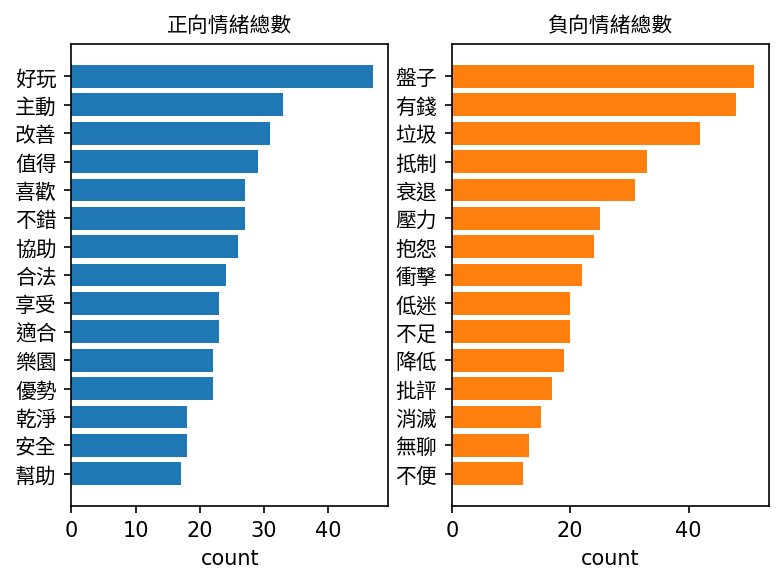

In [42]:
word_count = ptt_liwc_df_revise.groupby(["word", "sentiments"]).size().reset_index()

word_count = word_count.rename(columns={0: "size"})
word_count = word_count.sort_values(["size"], ascending=False)

word_of_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_of_neg = word_count.loc[(word_count["sentiments"] == "negative")]

pos = word_of_pos.head(15).sort_values(["size"], ascending=True)
neg = word_of_neg.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2)

ax[0].barh(pos["word"], pos["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos["word"], fontproperties=fprop)
ax[0].set_title("正向情緒總數", fontproperties=fprop)

ax[1].barh(neg["word"], neg["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg["word"], fontproperties=fprop)
ax[1].set_title("負向情緒總數", fontproperties=fprop)

過濾完不相關的情緒字以後，可以發現文章更貼近於真實情緒。

重新繪製情緒分數趨勢圖

Text(0.5, 1.0, '正負情緒分數趨勢折線圖')

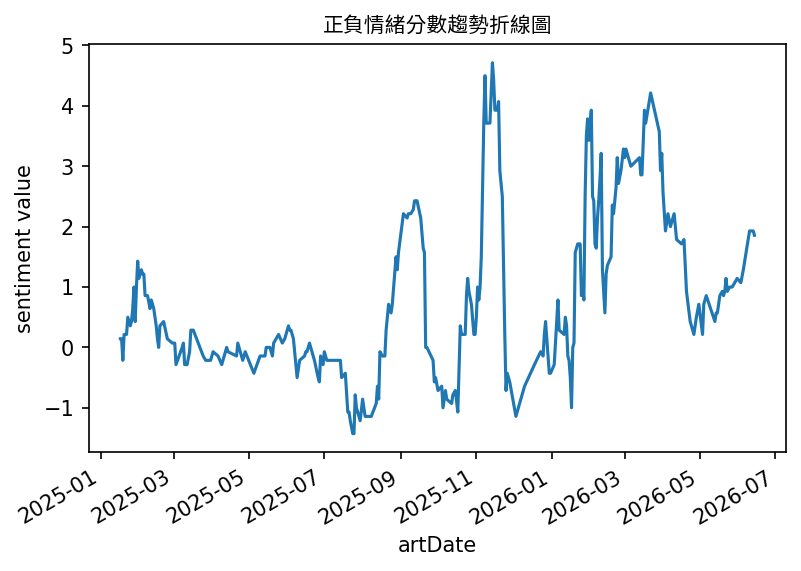

In [43]:
sentiment_count_revise = pd.DataFrame(
    ptt_liwc_df_revise.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count_revise['sentiments'] == "positive") | (sentiment_count_revise['sentiments'] == "negative") 
sentiment_count_revise = sentiment_count_revise.loc[mask]

sentiment_count_revise = sentiment_count_revise.rename(columns={0: "size"})
sentiment_count_revise = sentiment_count_revise.sort_values(["artDate"])

ptt_sentiment_value_revise = (
    sentiment_count_revise.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

# sentiment 計算方式: positive - negative
ptt_sentiment_value_revise["sentiment_value"] = (
    ptt_sentiment_value_revise["positive"]
    - ptt_sentiment_value_revise["negative"]
)

# 繪製情緒分數趨勢圖
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(ptt_sentiment_value_revise["artDate"], ptt_sentiment_value_revise["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("正負情緒分數趨勢折線圖", fontproperties=fprop)

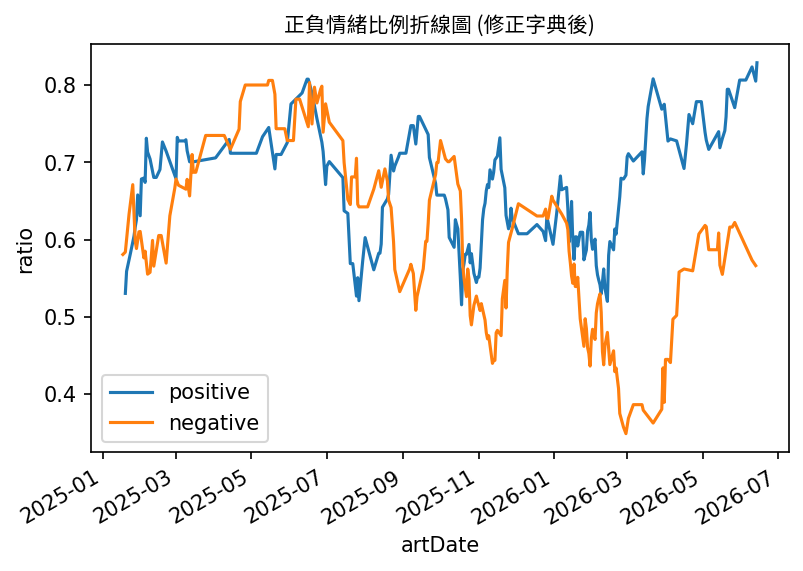

In [44]:
# 1. 確保使用「修改過字典」的最新統計資料來計算比例 (ratio)
sentiment_count_revise = sentiment_count_revise.assign(
    ratio = sentiment_count_revise.groupby("artDate")["size"].transform(lambda n: n / n.sum())
)

# 2. 切分出最新的正向與負向資料表
pos_rev = sentiment_count_revise[sentiment_count_revise["sentiments"] == "positive"]
neg_rev = sentiment_count_revise[sentiment_count_revise["sentiments"] == "negative"]

# 3. 開始繪製「情緒比例」折線圖
fig, ax = plt.subplots()
rolling_days = 14

ax.plot(pos_rev["artDate"], pos_rev["ratio"].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg_rev["artDate"], neg_rev["ratio"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
plt.ylabel("ratio")
ax.legend(["positive", "negative"], loc="lower left")
fig.autofmt_xdate()
plt.title("正負情緒比例折線圖 (修正字典後)", fontproperties=fprop)

plt.show()

可以發現更新情緒字典後的情緒總體評分變低，
在 2025-01-01 ~ 2025-02-01 從原本的 +6 變為 +1，
其他時段的正面分數雖然沒情緒分數的幅度沒降那麼多，
但也有一定程度的下降，
這裡值得注意的是再修正後 2026-03-01 ~ 2026-05-01 時間段的情緒依舊明顯正向，
其他像 2025-09 月 (分數沒變化，依舊正向) 也值得分析。

### 文字雲

In [45]:
# 1. 依照最新字典 (ptt_liwc_df_revise) 重新計算每篇文章的正負分數
article_sentiment_revise = ptt_liwc_df_revise.groupby(['artTitle', 'sentiments']).size().unstack(fill_value=0).reset_index()

# 確保表格裡有 positive 和 negative 欄位，避免報錯
for col in ['positive', 'negative']:
    if col not in article_sentiment_revise.columns:
        article_sentiment_revise[col] = 0

# 2. 統一命名格式，維持原本的 '正向' / '負向' 以及 'sentiment_class' 欄位名稱
article_sentiment_revise['sentiment_value'] = article_sentiment_revise['positive'] - article_sentiment_revise['negative']
article_sentiment_revise['sentiment_class'] = article_sentiment_revise['sentiment_value'].apply(lambda x: "正向" if x > 0 else "負向")

# 3. 更新給 ptt_liwc_df_revise (先清掉舊欄位再 merge 避免重複)
if 'sentiment_class' in ptt_liwc_df_revise.columns:
    ptt_liwc_df_revise = ptt_liwc_df_revise.drop(columns=['sentiment_class'])
ptt_liwc_df_revise = pd.merge(ptt_liwc_df_revise, article_sentiment_revise[['artTitle', 'sentiment_class']], on='artTitle', how="left")

# 4. 更新給 sent_df (同樣先清掉舊欄位再 merge)
if 'sentiment_class' in sent_df.columns:
    sent_df = sent_df.drop(columns=['sentiment_class'])
sent_df = pd.merge(sent_df, article_sentiment_revise[['artTitle', 'sentiment_class']], on='artTitle', how="left")

#### 可設定時間段的文字雲


觀察 2026-03-01 ~ 2026-05-01 的資料

In [46]:
date = "2026-03-01"
end_date = "2026-05-01"
mask = (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "正向")

ptt_df_wc = ptt_liwc_df_revise.loc[mask]
ptt_df_wc.head(10)

,matched_keyword,artDate,artTitle,artContent,word,sentiments,sentiment_class
3171,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,請放,NaN,正向
3172,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,最後,NaN,正向
3173,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,來源,NaN,正向
3174,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,蘋果,NaN,正向
3175,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,日報,NaN,正向
3176,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,自由時報,NaN,正向
3177,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,參考,NaN,正向
3178,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,版規,NaN,正向
3179,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,下方,NaN,正向
3180,國旅,2026-04-30,[新聞] 國旅回溫 民間消費成長近十季新高,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\n※ 例如蘋果日報、自由時報（請參考...,核准,NaN,正向


In [47]:
# 1. 重新設定時間與條件 (三月到五月的正向文章)
date = "2026-03-01"
end_date = "2026-05-01"
mask = (
    (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & 
    (ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & 
    (ptt_liwc_df_revise['sentiment_class'] == "正向")
)

# 2. 直接從「完整的資料表 (ptt_liwc_df_revise)」抓取我們需要的欄位，並剔除重複文章
unique_articles = ptt_liwc_df_revise.loc[mask, ['artDate', 'artTitle', 'artContent']].drop_duplicates()

print(f"這段期間共抓到 {len(unique_articles)} 篇不重複的正向文章\n")

# 3. 用迴圈逐篇印出標題與部分內文
for idx, row in unique_articles.iterrows():
    print(f"【{row['artDate']}】 {row['artTitle']}")
    
    # 只擷取前 120 個字來看，避免洗版
    content_snippet = str(row['artContent']).replace('\n', ' ').strip()[:120]
    print(f"內容摘要：{content_snippet}...")
    print("=" * 70)

這段期間共抓到 20 篇不重複的正向文章！

【2026-04-30】 [新聞] 國旅回溫 民間消費成長近十季新高
內容摘要：備註請放最後面 違者新聞文章刪除  1.媒體來源: ※ 例如蘋果日報、自由時報（請參考版規下方的核准媒體名單） ※ Yahoo、MSN、LINE等非直接官方新聞連結不被允許 經濟日報  2.記者署名: ※ 若新聞沒有記者名字或編輯名字，請勿...
【2026-04-26】 [問卦] 大家轟國旅轟了快兩年怎麼還是沒有要改?
內容摘要：乾拎老師  肥宅是很想出國啦  但總不能每個月都出去阿  總要隔個月  國旅一下  看有沒有進步  乾拎老師的  打開訂房網站  那個價格還是很北爛阿  早餐  查一些部落客  乾可以寫得能接受  是收了多少錢糙  拎老師用一堆澱粉  清粥...
【2026-04-23】 [新聞] 國旅有救了！台灣登「日本黃金週」出境
內容摘要：國旅有救了！台灣登「日本黃金週」出境前3名　飯店訂房9成滿 https://bit.ly/3QpQmK0 壹蘋新聞網 2026/04/23 15:47 記者 莊偉祺 綜合報導 【記者莊偉祺／台北報導】日本黃金週將至，旅遊平台統計期間台灣已成...
【2026-04-20】 [問卦] 中國文旅很聽勸有創意，台灣國旅呢？
內容摘要：乳蹄  中國各省文旅，為了引吸遊客 常常會做出很引吸人的創意活動  只要網路發生什麼時事，都會很聽勸的宣傳  像宣傳片會惡搞印象或找時事人物  像何潤東事件，當地的文旅就請來當項羽  足球比賽時，該祖籍縣市請何潤東來扮項羽跟自刎烏江的縣市球...
【2026-04-18】 [問卦] 中國旅跟國旅哪個好玩
內容摘要：中國旅  人多  要VPN  人民素質參差不齊  台灣極端派無法接受  住宿普遍評價不錯？  國旅  到處都8+9  住宿超貴  走在路上跟開車在路上都可能被人撞死  哪個比較好玩  有沒有八卦...
【2026-04-18】 [問卦] 早期的遶境是不是為了促進國旅啊
內容摘要：媽祖信仰 最大的族群就是海線  苗栗 台中 彰化 雲林 嘉義  這些縣市早期都是農業縣市  如果沒有遶境 一年到頭根本沒外人會進到村莊 像元長 崙背 大城 竹塘 沒遶境是有幾個人認識啦  遶境 就是促進消費 增進國旅的始祖 有人進入村莊就會...
【2026-04-10】 [問卦]

(這裡顯示的正面文章是透過情緒字典評分後，算出來的正面文章)
這裡能看出情緒字典的極限，他看的情緒字出現的次數並不能代表該篇文章的情緒，
比較依賴上下文，而且文章常拿國旅與出國比較，因此正面文章可能會是在讚美出國有多便宜，反觀國旅。

從這裡能發現一些能分析的資訊：
可能可以嘗試用上下文，ex. word2vec 方式判斷文章的情緒。

In [48]:
date = "2025-01-01"
end_date = "2026-06-17"
mask = (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "負向")

ptt_df_wc = ptt_liwc_df_revise.loc[mask, ["artDate", "word"]]


word_count_count = pd.DataFrame(
    ptt_df_wc.groupby(["word"]).size()
).reset_index().rename(columns={0: "size"})

word_count_count = word_count_count.sort_values(by='size', ascending=False)
word_count_count.head(10)

,word,size
2074,國旅,745
1831,台灣,280
3462,旅遊,229
5354,觀光,198
1448,出國,185
6407,飯店,184
3486,日本,164
1068,住宿,163
3809,業者,156
3048,房價,133


(-0.5, 1599.5, 799.5, -0.5)

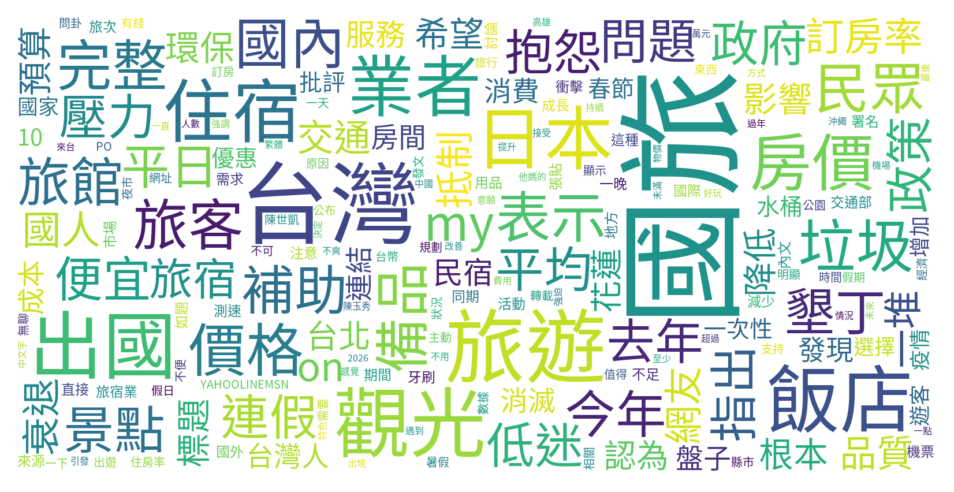

In [49]:
# wordcloud 的 input 是 dictionary
font_path = "./raw_data/SourceHanSansTW-Regular.otf"  # 中文字型路徑
wc_dict = dict(zip(word_count_count['word'], word_count_count['size']))
cloud = WordCloud(scale = 4, max_words=200, background_color="white", font_path=font_path)
cloud.generate_from_frequencies(wc_dict)
# 繪圖
plt.figure(figsize=(8, 4), dpi=150)
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
# plt.show()

以下為新增停用字的文字雲結果

1. 可以看到「價格」、「房價」、「盤子」、「衰退」、「低迷」這些情緒字。點出國旅目前面臨的問題，不單純是景點好不好玩，而牽扯到性價比及國民對於國旅的價格不信任。
2. 「日本」和「出國」兩字的出現，證明討論國旅被「不如出國去日本」這種對比心態影響。這說明網友除了評價國旅外，還會做出國的 CP 值比較。
3. 這裡發現地區：墾丁、花蓮，後面可以對比其他地區字詞查看討論內容。


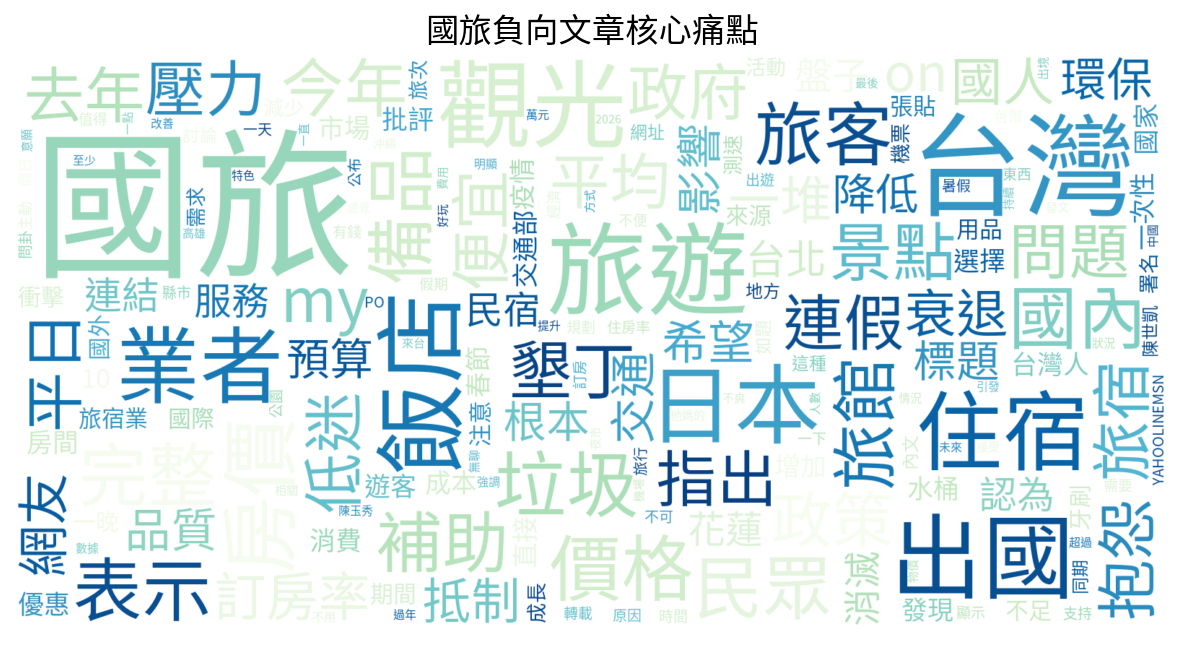

In [50]:
font_path = "./raw_data/SourceHanSansTW-Regular.otf"
wc_dict_clean = dict(zip(word_count_count['word'], word_count_count['size']))

cloud_clean = WordCloud(
    scale=4, 
    max_words=200, 
    background_color="white", 
    font_path=font_path, 
    colormap="GnBu"
).generate_from_frequencies(wc_dict_clean)

# 繪圖顯示
plt.figure(figsize=(10, 5), dpi=150)
plt.imshow(cloud_clean, interpolation="bilinear")
plt.axis("off")
plt.title("國旅負向文章核心痛點", fontproperties=fprop, fontsize=16)
plt.show()

1. 「住宿成本」： 「房價」、「住宿」、「旅館」、「價格」這些詞。點出網友對國旅的不滿，並非景點本身好不好玩，而是「住宿太貴」。(有文章探討 2 晚要 10 萬)
2. 「日本」、「出國」、「便宜」，印證網路上最常說去日本比較值得的現象，像是住宿便宜等。
3. 具體爭議：
    墾丁：作為單一地名卻異常突出，顯示它經常被抱怨，例如有錢人才去，去的都是盤子等，具體發洩情緒的字詞。
    備品：跟政府的環保政策有關，且網友調侃，備品要另外跟飯店買，而且沒備品的住宿依舊沒降價。
    垃圾：除了罵人的情緒發洩外，也跟網友抱怨垃圾清理相關。

生成正向文字雲有排除特定對比 (如日本、出國) 和無關字詞

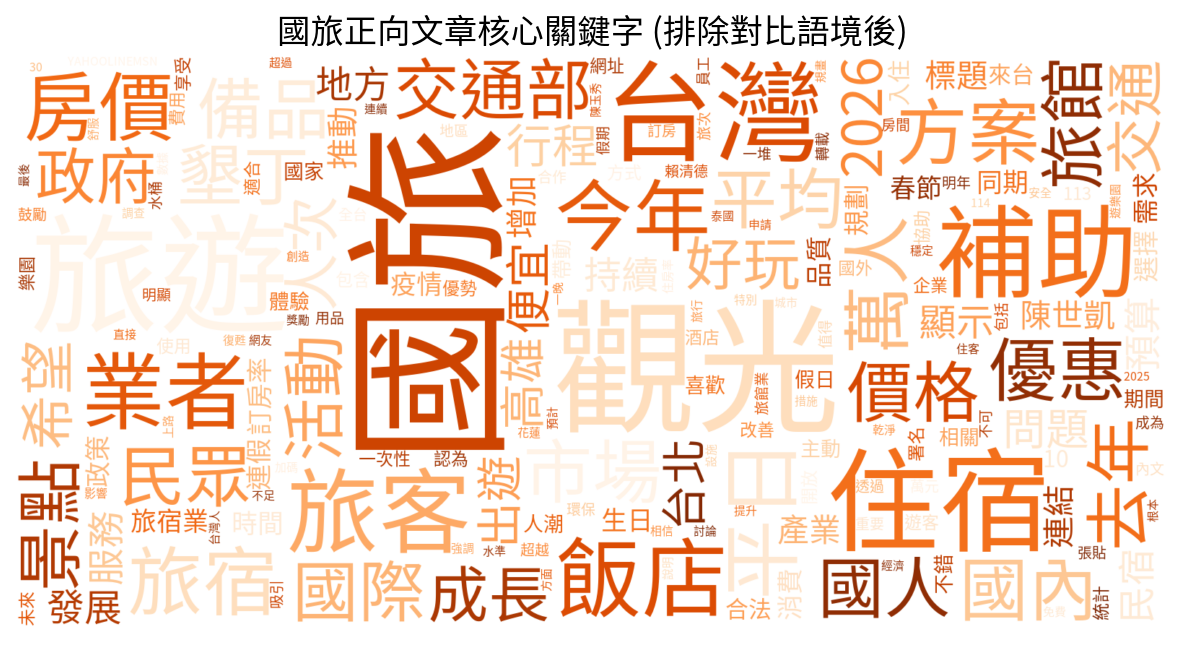

In [51]:
date = "2025-01-01" 
end_date = "2026-06-17"
mask_pos = (
    (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & 
    (ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & 
    (ptt_liwc_df_revise['sentiment_class'] == "正向")
)
ptt_df_wc_pos = ptt_liwc_df_revise.loc[mask_pos, ["artDate", "word"]]

word_count_pos = pd.DataFrame(ptt_df_wc_pos.groupby(["word"]).size()).reset_index().rename(columns={0: "size"})
word_count_pos = word_count_pos.sort_values(by='size', ascending=False)

# 只過濾會導致「假的正向」的特例詞彙與新聞格式詞
fake_pos_words = ['日本', '出國', '表示', '指出', '報導', '完整', '推出', '來源', '媒體', 'my', 'on']
filtered_word_count_pos = word_count_pos[~word_count_pos['word'].isin(fake_pos_words)].copy()

wc_dict_pos_clean = dict(zip(filtered_word_count_pos['word'], filtered_word_count_pos['size']))

cloud_pos_clean = WordCloud(
    scale=4, max_words=200, background_color="white", font_path=font_path, colormap="Oranges" 
).generate_from_frequencies(wc_dict_pos_clean)

plt.figure(figsize=(10, 5), dpi=150)
plt.imshow(cloud_pos_clean, interpolation="bilinear")
plt.axis("off")
plt.title("國旅正向文章核心關鍵字 (排除對比語境後)", fontproperties=fprop, fontsize=16)
plt.show()

這裡能看到正向文字雲 (排除對比國旅的日本，出國字詞)，
有發現高雄這一字詞出現在正向文字雲。

對於國旅之正負面文字雲，有以下對比：
1. 價格太貴 vs. 政府補貼
    負向圖：「價格」、「房價」、「住宿」，並緊密伴隨「日本」與「出國」。這證實網認為：花同樣的錢，國旅被認為不如出國。
    正向圖：關鍵字與政府補貼、新聞政策報導相關，缺乏國旅本身的討論。
2. 目的地的好壞對照（墾丁、花蓮 vs. 高雄）
    負向圖：「墾丁」與「花蓮」 的字詞。花蓮受天災與住房率低落的影響；而墾丁則輿論「高物價、盤子才去」的負面代名詞。
    正向圖：「高雄」因為籌辦許多活動，如：韓團演唱會、大港開唱、燈會等，因此網友對這些活動的正向討論度較高。
3. 新聞 (可能是官方報導) vs. 真實國旅體驗
    正向圖：「交通部」、「政策」、「發展」、「成長」、「推動」等公家部門字詞。顯示抓到的正向文章，高比例是官方發布的新聞稿，像是國旅補助，而非網友對國旅的讚美。
    負向圖：除了價格，還出現「備品」、「連假」、「塞車」等字詞，是民眾對於國旅的負面體驗。


可自行透過以下程式 (預設：墾丁) 設定字詞來觀察上面提到的字詞。

In [70]:
filtered_df = sent_df[sent_df['sentence'].str.contains('墾丁', na=False)]
filtered_df.head(10)

,artTitle,matched_keyword,artDate,artContent,sentence,sentiment_class
1,[問卦] 去了富國島才知道國旅有多盤,國旅,2026-06-14,我們不說什麼醫療資源\n也不說什麼飲食\n光是我一個人平均一個晚上台幣不到2000\n泳池別...,同樣的錢在墾丁活像貧民窟一樣除了有案底的人不能出國誰還會去墾丁啊,正向
325,[問卦] 大家都有錢了，可以去國旅玩了吧？,國旅,2026-06-01,大家好，我是八卦優文子啦！\n\n今天台股站上4萬5了，搞不好端午節之前就噴到五萬點了！\n...,去高級渡假區墾丁玩吧,NaN
470,[新聞] 比起國旅…台灣人更愛去日本旅遊？日媒,國旅,2026-05-15,比起國旅…台灣人更愛去日本旅遊？日媒分析「4大關鍵」：對國旅失望\nhttps://bit....,日媒分析4大關鍵對國旅失望 國人常詬病熱門景點如墾丁物價過高,正向
539,[問卦] 台灣經濟超好會導致國旅一床難求嗎（圖）,國旅,2026-05-06,小魯高雄51處辣\n最近統計出爐台灣Q1遠優於預期\n\n尤其是內需市場爆發成長\n\n民間...,現在應該願意到墾丁吃一盤滷味吧,正向
764,[新聞] 國旅有救了！台灣登「日本黃金週」出境,國旅,2026-04-23,國旅有救了！台灣登「日本黃金週」出境前3名 飯店訂房9成滿\nhttps://bit.ly/...,台灣各地中搜尋成長最快的目的地包含墾丁112花蓮85及桃園39,正向
944,[問卦] 國旅大復活 墾丁大街大爆滿？,國旅,2026-04-03,連假第一天的晚上墾丁大街滿滿的人潮\n\n我相信住房率應該很高\n\n一堆人說國旅很貴盤子才...,連假第一天的晚上墾丁大街滿滿的人潮,負向
947,[問卦] 國旅大復活 墾丁大街大爆滿？,國旅,2026-04-03,連假第一天的晚上墾丁大街滿滿的人潮\n\n我相信住房率應該很高\n\n一堆人說國旅很貴盤子才...,尤其墾丁的印象已經跟盤子畫上等號,負向
948,[問卦] 國旅大復活 墾丁大街大爆滿？,國旅,2026-04-03,連假第一天的晚上墾丁大街滿滿的人潮\n\n我相信住房率應該很高\n\n一堆人說國旅很貴盤子才...,結果台灣人還是很愛去墾丁啊,負向
950,[問卦] 誰說國旅 墾丁沒人去的？,國旅,2026-04-03,今天是清明連假的第一天\n有脆發文墾丁大街的人潮\n看到這人潮是誰說國旅 墾丁沒人去的？\n...,今天是清明連假的第一天有脆發文墾丁大街的人潮看到這人潮是誰說國旅 墾丁沒人去的,NaN
1676,[問卦] 國旅適合去哪裡？,國旅,2026-02-22,我有在3月中到3月底有兩週的空窗，本來想要再去泰國，但仔細想想我還沒去過台灣的許\n多地方，...,預選名單有金門花蓮墾丁,正向


In [71]:
for sentence in filtered_df['sentence'].to_list():
    print(sentence)
    print("=========================")

同樣的錢在墾丁活像貧民窟一樣除了有案底的人不能出國誰還會去墾丁啊
去高級渡假區墾丁玩吧
日媒分析4大關鍵對國旅失望 國人常詬病熱門景點如墾丁物價過高
現在應該願意到墾丁吃一盤滷味吧
台灣各地中搜尋成長最快的目的地包含墾丁112花蓮85及桃園39
連假第一天的晚上墾丁大街滿滿的人潮
尤其墾丁的印象已經跟盤子畫上等號
結果台灣人還是很愛去墾丁啊
今天是清明連假的第一天有脆發文墾丁大街的人潮看到這人潮是誰說國旅 墾丁沒人去的
預選名單有金門花蓮墾丁
熱門景點不管九份日月潭或墾丁
 媒體識讀 就像墾丁少數案例被無限放大
導致大家覺得去墾丁的都是盤子
在台北坐高鐵去高雄也要一個半小時起跳重點是去到那邊吃的東西又跟台北一樣去墾丁又更久 也沒特色但住宿和物價卻比日本還高
要是聽到墾丁一間二三十年的四星級飯店一晚都要價一萬初
記得前幾年國旅不是很夯墾丁大街擠得人山人海擠到衛服部還要發細胞簡訊叫大家不要再去了
阿里山 日月潭 墾丁 武陵農場
日本墾丁沖繩
墾丁的國旅崩盤已經不是一兩天的事情了當地業者還跟大家說一晚4000是正常價格啦結果墾丁的國旅從巔峰時期800多萬人 降到現在要保200萬高雄也不遑多讓 只要有演唱會住宿隨便就從平時兩三千漲破一晚一萬多的一堆
為何國旅宰客宰最兇的最常出現在高雄墾丁
你看墾丁住宿跟吃的
墾丁更是連關3間飯店
4完整新聞內文近期墾丁等國旅景點人潮銳減
近期墾丁等國旅景點人潮銳減
墾丁不是就有錢去玩了嗎
墾丁大街平日的住宿大約都在400元到900元之間
下面照片的房間又是最近帶友人去墾丁我訂了兩間房間
及恆春幾百塊的房間我的旅遊日記裡面有很多以前不同墾丁住宿的照片都在1000塊以內
不只墾丁
墾丁已出現不少店家陸續歇業
墾丁旅遊人次從高峰一年800萬人次
不只墾丁
墾丁旅宿業割不到盤子現在哀鴻遍野
現在大家都一直出國玩國內一些景點像是墾丁都快倒光光了記得那時候疫情不能出國墾丁大街擠得像沙丁魚一樣
墾丁連2年國旅人數雪崩逼近200萬防線
 再傳大飯店整修停業 0952 記者蔡宗憲屏東報導曾是全台國旅領頭羊的國境之南墾丁
墾丁旅遊人次繼2024年慘跌至214萬人次後
指標性的墾丁福容大飯店近期也傳出將大規模整修暫停營業
墾丁觀光熱潮在2015年曾創下837萬人次的巔峰
繼墾丁統一度假村宣布停業後
指標性的大型飯店墾丁福容大飯店近期也傳出將進入大規模整修期並暫停

可挑特定字詞查看某時間段的文字雲

(-0.5, 1599.5, 799.5, -0.5)

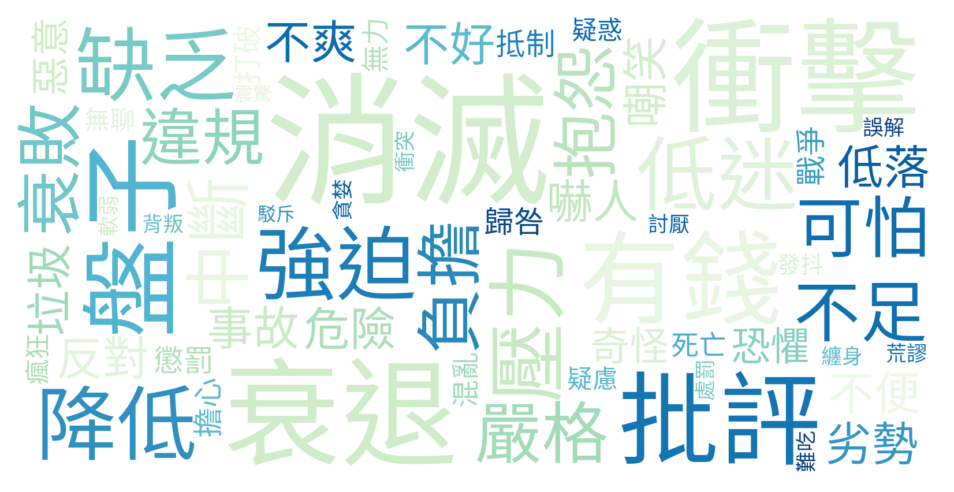

In [54]:
date = "2025-01-01"
end_date = "2026-06-17"
mask = (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & ( # 時間區間
    ptt_liwc_df_revise['sentiment_class'] == "負向")  & ( # 負面文章
    ptt_liwc_df_revise['artContent'].str.contains('墾丁')) & ( # 內文包含雞腿排
    ptt_liwc_df_revise["sentiments"] == "negative") # 負面情緒字

ptt_df_wc = ptt_liwc_df_revise.loc[mask, ["artDate", "word"]]
wc = ptt_df_wc.groupby(["word"]).size().to_dict()

# wordcloud 的 input 是 dictionary
cloud = WordCloud(scale = 4, max_words=200, background_color="white", font_path=font_path, colormap="GnBu")
cloud.generate_from_frequencies(wc)
# 繪圖
plt.figure(figsize=(8, 4), dpi=150)
plt.imshow(
    cloud, 
    interpolation="bilinear"
)
plt.axis("off")
# plt.show()

因為新聞報導的內容較多偏向政策、補助等，
要探討民眾對於國旅看法，應該要排除這些雜訊。
以下檢查了兩種類型的文章，它們的正負面對比。

【網友討論】情緒統計：
總篇數: 450 篇
sentiment_class
負向    261
正向    189
平均情緒分數: 0.05

------------------------------

【新聞報導】情緒統計：
總篇數: 150 篇
sentiment_class
正向    84
負向    66
平均情緒分數: 1.53


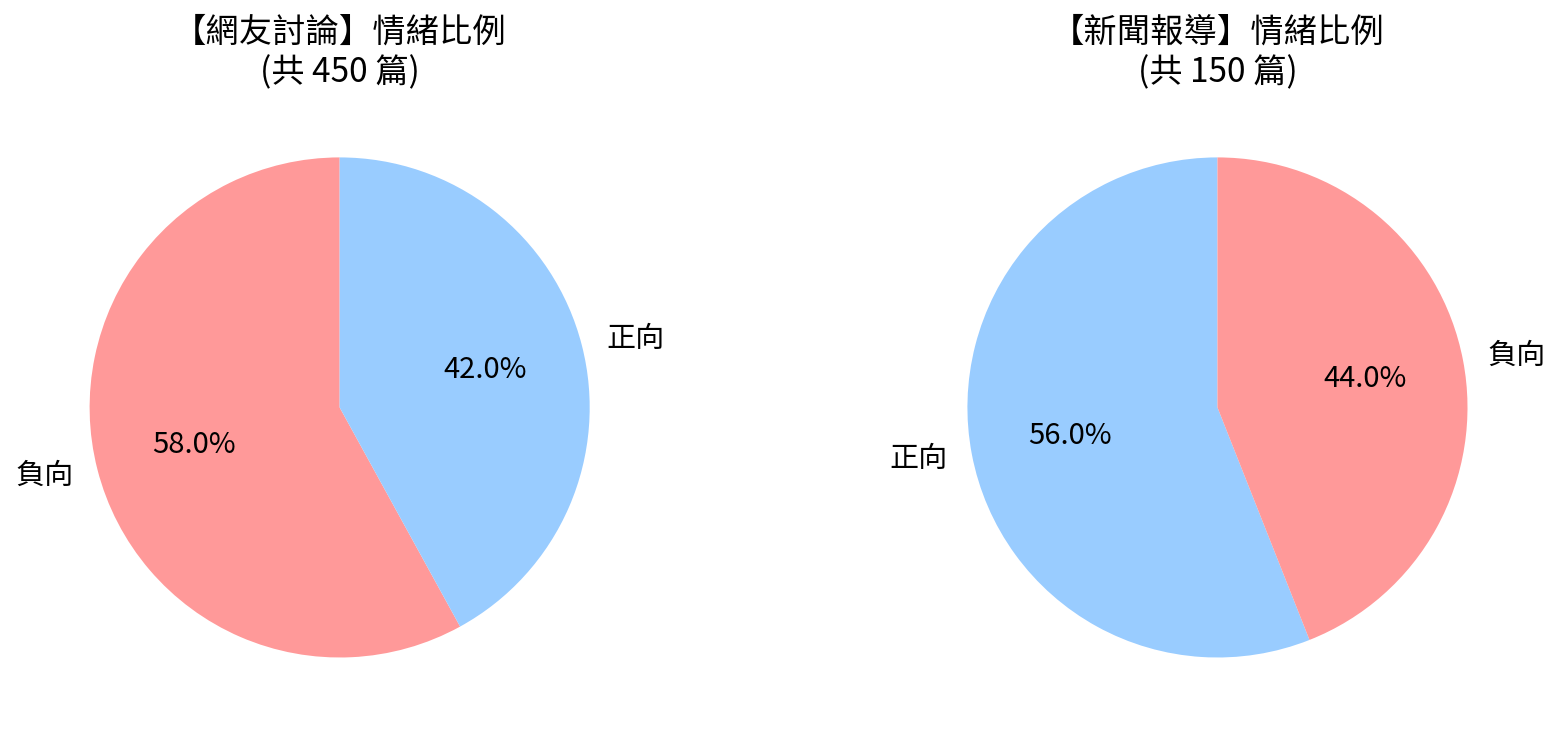

In [55]:
# 1. 將文章分為「網友討論」與「新聞報導」兩群
social_articles = article_sentiment_revise[~article_sentiment_revise['artTitle'].str.contains('\[新聞\]', na=False)]
news_articles = article_sentiment_revise[article_sentiment_revise['artTitle'].str.contains('\[新聞\]', na=False)]

# 2. 計算兩邊的正負向文章數量
social_counts = social_articles['sentiment_class'].value_counts()
news_counts = news_articles['sentiment_class'].value_counts()

# 3. 印出具體的統計數據
print("【網友討論】情緒統計：")
print(f"總篇數: {len(social_articles)} 篇")
print(social_counts.to_string())
print(f"平均情緒分數: {social_articles['sentiment_value'].mean():.2f}\n")
print("-" * 30 + "\n")

print("【新聞報導】情緒統計：")
print(f"總篇數: {len(news_articles)} 篇")
print(news_counts.to_string())
print(f"平均情緒分數: {news_articles['sentiment_value'].mean():.2f}")

# 4. 畫圖對比 (圓餅圖)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# 左圖：網友
ax[0].pie(social_counts, labels=social_counts.index, autopct='%1.1f%%', startangle=90,
          colors=['#ff9999' if x=='負向' else '#99ccff' for x in social_counts.index],
          textprops={'fontproperties': fprop, 'fontsize': 14})
ax[0].set_title(f"【網友討論】情緒比例\n(共 {len(social_articles)} 篇)", fontproperties=fprop, fontsize=16)

# 右圖：新聞
ax[1].pie(news_counts, labels=news_counts.index, autopct='%1.1f%%', startangle=90,
          colors=['#ff9999' if x=='負向' else '#99ccff' for x in news_counts.index],
          textprops={'fontproperties': fprop, 'fontsize': 14})
ax[1].set_title(f"【新聞報導】情緒比例\n(共 {len(news_articles)} 篇)", fontproperties=fprop, fontsize=16)

plt.tight_layout()
plt.show()

由此可確定網友語新聞的報導確實在情緒上有明顯對比。

純網友文章的情緒分數趨勢圖

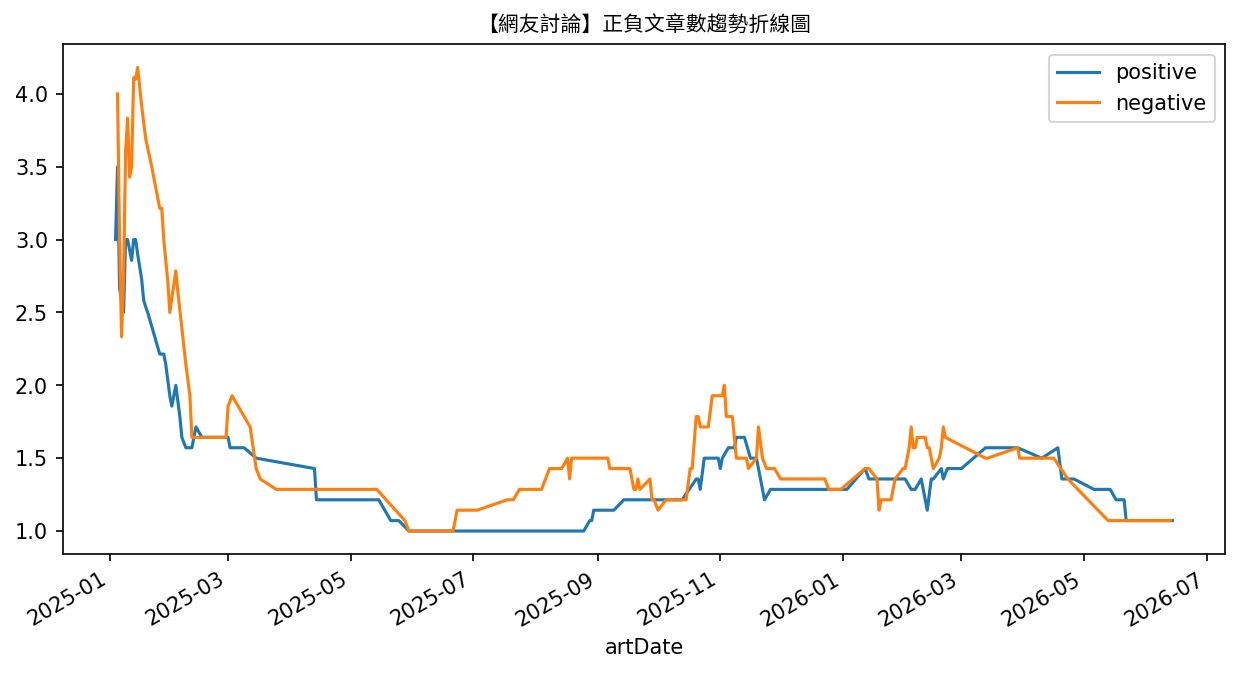

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 直接在這裡定義 social_only_df，確保順序正確不會閃退
date = "2025-01-01"
end_date = "2026-06-17"
mask_social = ((ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & 
               (ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & 
               (~ptt_liwc_df_revise['artTitle'].str.contains('\[新聞\]', na=False)))
social_only_df = ptt_liwc_df_revise[mask_social].copy()

# 2. 從純鄉民資料中，以「文章」為單位去除重複值
social_articles_trend = social_only_df.drop_duplicates(subset=['artTitle'])[['artDate', 'artTitle', 'sentiment_class']]

# 3. 計算每天純鄉民的正向與負向「文章篇數」
daily_social_counts = social_articles_trend.groupby(['artDate', 'sentiment_class']).size().reset_index(name='size')

# 4. 區分正向與負向資料表
colors = ["tab:blue", "tab:orange"]
pos_social_trend = daily_social_counts[daily_social_counts["sentiment_class"] == "正向"]
neg_social_trend = daily_social_counts[daily_social_counts["sentiment_class"] == "負向"]

# 5. 繪製 14 天移動平均趨勢圖
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
rolling_days = 14

if not pos_social_trend.empty:
    ax.plot(pos_social_trend["artDate"], pos_social_trend['size'].rolling(rolling_days, min_periods=1).mean(), color=colors[0], label="positive")
if not neg_social_trend.empty:
    ax.plot(neg_social_trend["artDate"], neg_social_trend["size"].rolling(rolling_days, min_periods=1).mean(), color=colors[1], label="negative")

plt.xlabel("artDate")
ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.title("【網友討論】正負文章數趨勢折線圖", fontproperties=fprop)
plt.show()

負面占較高的比例，也印證了我們對於國旅討論的想法，負面情緒大部分源自於抱怨住宿貴、物價高等。

繪製純網友的文字雲

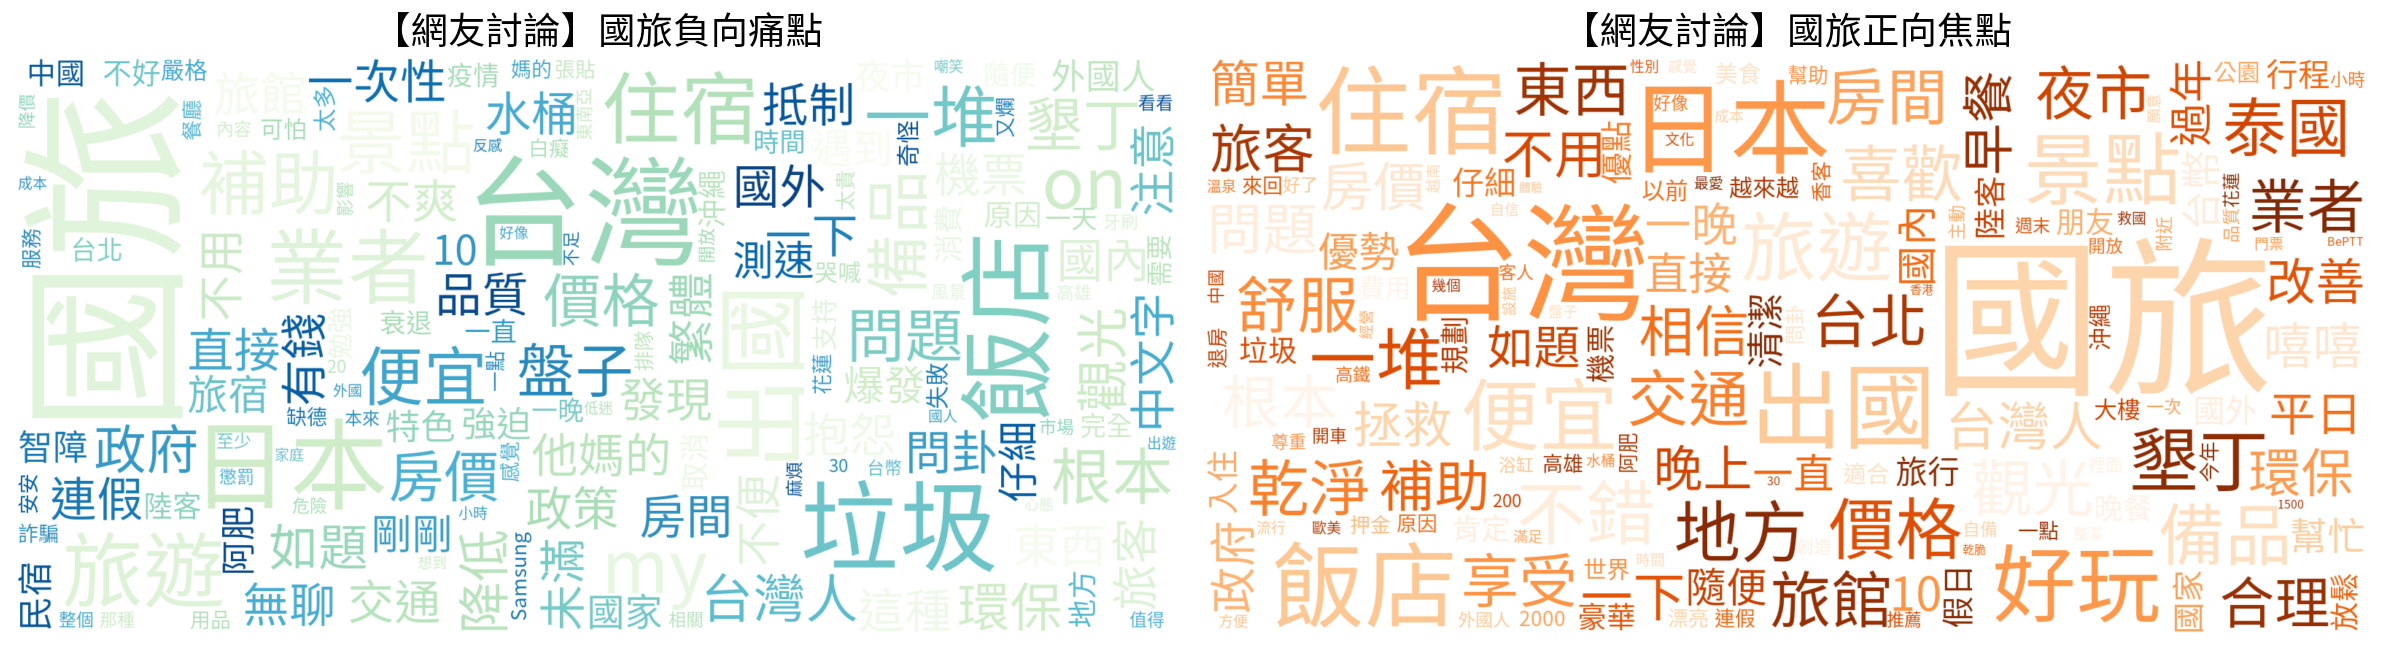

In [57]:
# 1. 設定時間區間
date = "2025-01-01" 
end_date = "2026-06-17"

mask_social = (
    (ptt_liwc_df_revise['artDate'] >= pd.Timestamp(date).date()) & 
    (ptt_liwc_df_revise['artDate'] <= pd.Timestamp(end_date).date()) & 
    (~ptt_liwc_df_revise['artTitle'].str.contains('\[新聞\]', na=False)) # 踢除新聞
)
social_only_df = ptt_liwc_df_revise[mask_social].copy()

font_path = "./raw_data/SourceHanSansTW-Regular.otf"

# 2. 製作【網友討論的負向】文字雲
neg_social = social_only_df[social_only_df['sentiment_class'] == "負向"]
word_counts_neg = pd.DataFrame(neg_social.groupby(["word"]).size()).reset_index().rename(columns={0: "size"})
dict_neg = dict(zip(word_counts_neg['word'], word_counts_neg['size']))

cloud_neg = WordCloud(
    scale=4, max_words=150, background_color="white", font_path=font_path, colormap="GnBu"
).generate_from_frequencies(dict_neg)

# 3. 網友討論的文字雲
pos_social = social_only_df[social_only_df['sentiment_class'] == "正向"]
word_counts_pos = pd.DataFrame(pos_social.groupby(["word"]).size()).reset_index().rename(columns={0: "size"})

# 可以在這裡面新增不想看到的字
fake_pos_words = ['my', 'on'] 
filtered_pos = word_counts_pos[~word_counts_pos['word'].isin(fake_pos_words)]

dict_pos = dict(zip(filtered_pos['word'], filtered_pos['size']))

cloud_pos = WordCloud(
    scale=4, 
    max_words=150, 
    background_color="white", 
    font_path=font_path, 
    colormap="Oranges"
).generate_from_frequencies(dict_pos)

# 4. 並排繪圖顯示，進行直觀對比
fig, ax = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

# 左圖：負向
ax[0].imshow(cloud_neg, interpolation="bilinear")
ax[0].axis("off")
ax[0].set_title("【網友討論】國旅負向痛點", fontproperties=fprop, fontsize=18)

# 右圖：正向
ax[1].imshow(cloud_pos, interpolation="bilinear")
ax[1].axis("off")
ax[1].set_title("【網友討論】國旅正向焦點", fontproperties=fprop, fontsize=18)

plt.tight_layout()
plt.show()

排除新聞後，觀察到：
1. 新聞文章中會點出住宿貴，物價貴，但排除新聞後，負向詞從單純的嫌貴，變成具攻擊性的、「有錢人才去」、「垃圾國旅」，顯示大量網友負面用詞。
2. 正向評價的政府字詞（政策、補助）變的較少。但問題是這些詞彙內容並不是再說國旅好，很大的成分是在稱讚外國旅行，因此延伸出第三點。
3. 情緒字典的侷限：正向圖裡出現「泰國」、「機票」，代表這些內容正向詞的內容依然是在說去國旅不如去外國「對比反諷」（例如：去泰國住宿便宜，反觀國旅...）。字典只抓到「便宜、乾淨」就誤判為正向文章，這直接點出了傳統情緒字典「看不懂上下文」的最大極限。

發現問題：
1.	將「不如出國、不如去日本、太貴、國旅卡、住宿費」等詞彙賦予負面權重。
2.	情緒字典 Based 的方法計算情緒分數方法沒有考慮到上下文
3.	針對「上下文」計算分數，而不被整篇文章的其他話干擾 (ex. 稱讚國外旅遊貶低國旅不會被算成正向等)。
4.	導入 LLM 判斷情緒，來看是否能精準算出情緒分數，不被如新聞，稱讚出國的文給影響到情緒分數的預測。


### 使用 LLM 做情緒分析，以下有做 CoT 模板，強制輸出特定格式 (為了看預測標籤)，以及多輪自我驗證

In [58]:
'''
import pandas as pd
from collections import Counter
from tqdm import tqdm
from pydantic import BaseModel, Field
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_ollama.llms import OllamaLLM

# ==========================================
# 1. 初始化模型與強制輸出格式 (先定義好武器)
# ==========================================
llm = OllamaLLM(model='gemma3:4b-it-qat', temperature=0.6)

class SentimentResult(BaseModel):
    reasoning: str = Field(description="請一步一步推理文章的情緒，並寫下判斷理由。")
    sentiment: int = Field(description="最終的情緒標籤數字，只能是：1 (正向), 0 (中性), 或是 -1 (負向)。")

parser = JsonOutputParser(pydantic_object=SentimentResult)

# ==========================================
# 2. 寫入 9 大 PTT 國旅語境範例並建立最新 chain
# ==========================================
cot_template = """你是一位專業的社群媒體情緒分析專家。
請閱讀以下 PTT 國旅相關文章，判斷其整體對於「國旅」的情緒為「正向 (1)」、「中性 (0)」，還是「負向 (-1)」。

以下是推理與判斷的範例：

例子1:
文章：乾拎老師

肥宅是很想出國啦

但總不能每個月都出去阿

總要隔個月

國旅一下

看有沒有進步

乾拎老師的

打開訂房網站

那個價格還是很北爛阿

早餐

查一些部落客

乾可以寫得能接受

是收了多少錢糙

拎老師用一堆澱粉

清粥小菜

乾拎老師的

人家日本的早餐多好吃

你那清粥小菜不然就饅頭

菜都是開罐頭倒出來的

所以是拿村莊裡大家吃不完的東西過來提供早餐喔

西式的薯餅一定有

就是塞一堆澱粉給客人

乾

備品罵多久

不改回來就是不改回來

到底在幹嘛

有沒有卦?
輸出：
{{
  "reasoning": "這是一篇極度負面的抱怨文。作者使用了大量粗口表達強烈不滿，並具體點出國旅的三大痛點：第一是「房價依然太貴」；第二是「早餐品質極差」，認為都是廉價澱粉與罐頭，並拿日本的優質早餐做強烈對比；第三是抱怨飯店依然不提供「備品」。通篇充滿憤怒與強烈的批評，屬於標準的負向情緒。",
  "sentiment": -1
}}

例子2:
文章：媽祖信仰
最大的族群就是海線

苗栗
台中
彰化
雲林
嘉義

這些縣市早期都是農業縣市

如果沒有遶境 一年到頭根本沒外人會進到村莊
像元長 崙背 大城 竹塘
沒遶境是有幾個人認識啦

遶境
就是促進消費
增進國旅的始祖
有人進入村莊就會有消費
很聰明嗎
有卦嗎
輸出：
{{
  "reasoning": "這是一篇探討宗教活動與觀光經濟的分析文。作者以客觀的角度指出，媽祖遶境為平時缺乏外客的偏鄉帶來了人潮與消費，並將其形容為『增進國旅的始祖』。文章結尾以『很聰明嗎 有卦嗎』作為標準的 PTT 討論起手式。整篇內容屬於對國旅現象的理性觀察與討論，並沒有包含個人對旅遊體驗的強烈喜惡、抱怨或讚美，因此判定為中性。",
  "sentiment": 0
}}

例子3:
文章：我發現除了備品、住宿太貴以外
其實台灣旅遊輸日本很大的原因是大眾交通工具連結各景點的便利度太差？

日本很像滿擅長透過鐵路、路面電車來串聯景點
再不濟也還是盡量有巴士
反觀台灣出了都市
有些縣市的公共運輸真的滿弱
就連桃園也只是勉強可以
484這樣？
輸出：
{{
  "reasoning": "這是一篇雖然以疑問句『484這樣？』結尾的討論文，但內文具體點出了國旅的多項劣勢：包含『備品問題』、『住宿太貴』，以及文章核心探討的『大眾交通工具便利度太差』。作者以日本完善的鐵道與巴士系統作為正面對比，藉由『反觀台灣』來凸顯國內出了都市後公共運輸極度薄弱的缺點。整體言論對國旅的基礎建設與旅遊體驗抱持明顯的批評與負面態度，因此判定為負向。",
  "sentiment": -1
}}

例子4:
文章：1.媒體來源:
ETTODAY

2.記者署名:
網搜小組／曾筠淇報導

3.完整新聞標題:
國旅備品買了才給「房價也沒降」 他曝國外做法：是獎勵性環保

4.完整新聞內文:
近日網紅Cheap發文探討旅宿業不提供備品的環保政策。他分享近期去峇里島旅遊的經驗
，對比台灣國旅現況，直言台灣業者打著環保名義省錢卻不降房價，甚至要求忘記帶牙刷
的旅客花錢購買。他認為這種「懲罰性環保」，只會讓人覺得在割韭菜。
（後略）

5.完整新聞連結 (或短網址)不可用YAHOO、LINE、MSN等轉載媒體:
https://house.ettoday.net/news/3150511

6.備註:
※ 一個人一天只能張貼一則新聞(以天為單位)，被刪或自刪也算額度內，超貼者水桶，請注意
※ 備註請勿張貼三日內新聞(包含連結、標題等)
輸出：
{{
  "reasoning": "這是一篇標準的 PTT [新聞] 轉載文。雖然發文者本身沒有在備註區加上個人評論，看似屬於客觀轉貼，但這篇新聞的「核心內容」全段都在引述網紅對國旅的強烈批評。內文點出國旅「不提供備品也不降房價」，並使用了「懲罰性環保」、「割韭菜」等極度負面的詞彙，同時利用國外（峇里島）的作法來對比貶低國旅。因為整段文本傳遞出對國旅極度不滿的指控與負面觀感，因此整體情緒判定為負向。",
  "sentiment": -1
}}

例子5:
文章：我窮才國旅，宜蘭礁溪，今天一晚上

1. 1,700 住宿+溫泉
2.午餐3,00 晚餐 300-500
3.飲料、零食 300
4.炸物 200-500
5.車資 來回200

這樣兩天一夜 不到五千塊，還不用請假

如果是出國的話隨便就兩萬、三萬了
輸出：
{{
  "reasoning": "這是一篇為國旅平反的正面推薦文。作者開頭以『我窮才國旅』來反擊社群上『有錢人才國旅』的刻板印象。接著詳細列出宜蘭礁溪兩天一夜的開銷，證明花費不到五千元就能享受溫泉與美食。最後更點出國旅『不用請假』的便利性，並與『出國隨便就兩三萬』的高花費做正面對比。整篇文章高度肯定國旅的性價比與便利性，因此判定為正向。",
  "sentiment": 1
}}

例子6:
文章：這次連假遇到大雷雨

開車出門一路塞到飯店

結果下整天雨

當初是不是應該機票買了飛日本

走在澀谷被小日本衝撞

跟

台灣雷雨一出門又濕又黏

會選哪一個？

有八卦嗎？
輸出：
{{
  "reasoning": "這是一篇帶有強烈情境描述的討論文。文章雖然提到了連假國旅遇到塞車與下雨的慘況，但其敘事結構主要圍繞在一個『情境二選一』的假設性問題上，詢問網友會選擇『日本被撞』還是『台灣雨黏』。文章未對國旅進行直接的謾罵或定性評價，而是透過這種極端的對比引導網友參與討論，本質上屬於對旅遊體驗的現象對比與討論，不帶有明確的個人情緒批判，因此判定為中性。",
  "sentiment": 0
}}

{format_instructions}

現在請分析以下文章並輸出結果：
文章：{query}
"""

prompt = PromptTemplate(
    template=cot_template,
    input_variables=["query"],
    partial_variables={"format_instructions": parser.get_format_instructions()}
)

# 建立專屬國旅的全新分析鏈
chain = prompt | llm | parser

# ==========================================
# 3. 讀取資料並 Rename (精準對齊欄位)
# ==========================================
input_path = "raw_data/articles_to_label.csv"
df_to_label = pd.read_csv(input_path, encoding="utf-8-sig")

# 關鍵 Rename：解決 KeyError 的救星
df_to_label = df_to_label.rename(columns={'title': 'artTitle', 'published_at': 'artDate', 'content': 'artContent'})

# ==========================================
# 4. 開始執行標註迴圈
# ==========================================
num_runs = 3 # 設定 Self-consistency 執行的輪數 (3輪多數決)
final_results = []
output_path = "raw_data/articles_to_label_LLM_CoT.csv"

print(f"準備完畢，對 {len(df_to_label)} 篇國旅文章進行 LLM CoT 標註...")

for idx, row in tqdm(df_to_label.iterrows(), total=len(df_to_label)):
    content = str(row['artContent'])
    votes = []
    reasonings = []
    
    # 對同一篇文章執行 3 次推論
    for _ in range(num_runs):
        try:
            res = chain.invoke({"query": content})
            votes.append(int(res['sentiment']))
            reasonings.append(res['reasoning'])
        except Exception as e:
            votes.append(0)
            reasonings.append(f"Format Error")

    # 進行多數決
    if votes:
        majority_vote = Counter(votes).most_common(1)[0][0]
    else:
        majority_vote = 0
        
    final_results.append({
        "manual_label": majority_vote,       
        "llm_votes_history": str(votes),     
        "llm_reasoning": reasonings[0] if reasonings else ""      
    })

    # 中斷保護：每跑 20 篇偷偷存檔一次 (防斷電)
    if idx > 0 and idx % 20 == 0:
        temp_df_results = pd.DataFrame(final_results)
        temp_df_final = pd.concat([df_to_label.iloc[:len(temp_df_results)].drop(columns=['manual_label'], errors='ignore').reset_index(drop=True), temp_df_results], axis=1)
        temp_df_final.to_csv(output_path, index=False, encoding="utf-8-sig")

# ==========================================
# 5. 最終合併與存檔
# ==========================================
df_results = pd.DataFrame(final_results)
df_final = pd.concat([df_to_label.drop(columns=['manual_label'], errors='ignore'), df_results], axis=1)
df_final.to_csv(output_path, index=False, encoding="utf-8-sig")

print("\n" + "="*60)
print(f"標註完成")
print(f"檔案已另存為：{output_path}")
print("="*60)
'''

'\nimport pandas as pd\nfrom collections import Counter\nfrom tqdm import tqdm\nfrom pydantic import BaseModel, Field\nfrom langchain_core.output_parsers import JsonOutputParser\nfrom langchain_core.prompts import PromptTemplate\nfrom langchain_ollama.llms import OllamaLLM\n\n# ==========================================\n# 1. 初始化模型與強制輸出格式 (先定義好武器)\n# ==========================================\nllm = OllamaLLM(model=\'gemma3:4b-it-qat\', temperature=0.6)\n\nclass SentimentResult(BaseModel):\n    reasoning: str = Field(description="請一步一步推理文章的情緒，並寫下判斷理由。")\n    sentiment: int = Field(description="最終的情緒標籤數字，只能是：1 (正向), 0 (中性), 或是 -1 (負向)。")\n\nparser = JsonOutputParser(pydantic_object=SentimentResult)\n\n# ==========================================\n# 2. 寫入 9 大 PTT 國旅語境範例並建立最新 chain\n# ==========================================\ncot_template = """你是一位專業的社群媒體情緒分析專家。\n請閱讀以下 PTT 國旅相關文章，判斷其整體對於「國旅」的情緒為「正向 (1)」、「中性 (0)」，還是「負向 (-1)」。\n\n以下是推理與判斷的範例：\n\n例子1:\n文章：乾拎老師\n\n肥宅是很想出國啦\n\n但總不能每個月都出去阿\n\

In [59]:
import pandas as pd

# 1. 讀取你跑完的 LLM 標註檔案
llm_df = pd.read_csv("dict/articles_to_label_LLM_CoT.csv", encoding="utf-8-sig")

# 2. 將 LLM 的數字標籤轉換為文字
def map_llm_label(label):
    return "正向" if label == 1 else ("負向" if label == -1 else "中性")

llm_df['llm_sentiment_class'] = llm_df['manual_label'].apply(map_llm_label)

# 3. 拿出字典法修正後的結果做合併
dict_result = article_sentiment_revise[['artTitle', 'sentiment_class']].rename(columns={'sentiment_class': 'dict_sentiment_class'})
comparison_df = pd.merge(llm_df, dict_result, on='artTitle', how='inner').drop_duplicates(subset=['artTitle'])

# 4. 輸出交叉比對矩陣
print("=== 字典法 (Rows) vs. LLM 標註結果 (Cols) 交叉比對 ===")
cross_tab = pd.crosstab(comparison_df['dict_sentiment_class'], comparison_df['llm_sentiment_class'], margins=True, margins_name="總計")
print(cross_tab)
print("=====================================================")

=== 字典法 (Rows) vs. LLM 標註結果 (Cols) 交叉比對 ===
llm_sentiment_class    中性  正向   負向   總計
dict_sentiment_class                   
正向                     72  60  141  273
負向                     59  20  248  327
總計                    131  80  389  600


這裡做了字典法與 LLM 的結果對比，LLM 的部分有檢察標註以及 LLM Reasoning 的合理性，確定準確率高，
可以看到 column 是 LLM，row 是字典法，比較可惜因為字典法跟 LLM 不同，沒有中性情緒 (單純詢問問題或者描述類型的新聞)，
但這裡能發現到若經由 LLM 判斷，正向文章只有 80 篇，而字典法則有 273 篇，且被字典反判斷為正向的文章有 141 篇被語言模型判斷為負向。
以上顯示字典法因為只單看情緒詞彙算分有很大的缺陷，而且 LLM 也能抓出中性情緒，不向字典法只能遵守嚴格的字詞數規定。

In [60]:
# 篩選出「字典法誤判為正向」，但「LLM 判定為負向」的 141 篇文章
edge_cases = comparison_df[(comparison_df['dict_sentiment_class'] == '正向') & 
                           (comparison_df['llm_sentiment_class'] == '負向')]

print(f"{len(edge_cases)} 篇被字典法誤判的文章！\n")

# 隨機抽出 5 篇作為報告案例 (固定隨機種子確保重跑結果一致)
sample_cases = edge_cases.sample(min(5, len(edge_cases)), random_state=42)

for idx, row in sample_cases.iterrows():
    print(f"標題：{row['artTitle']}")
    content_snippet = str(row['artContent']).replace('\n', ' ').strip()[:100]
    print(f"內文摘要：{content_snippet}...")
    print(f"【字典法標籤】：{row['dict_sentiment_class']}  |  【LLM 標籤】：{row['llm_sentiment_class']}")
    print(f"【LLM 推理過程】：{row['llm_reasoning']}")
    print("-" * 80)

141 篇被字典法誤判的文章！

標題：[問卦] 國旅何時變得廢到不行？
內文摘要：如題  記得小時候和外公外婆參加里長舉辦的出遊  包一台遊覽車  去健行、去吃大餐  去住日月潭附近的飯店，感覺很好玩啊  錢也沒花到很多  結果  近年不只飯店房價貴  連備品都不提供了  到底何時...
【字典法標籤】：正向  |  【LLM 標籤】：負向
【LLM 推理過程】：這是一篇表達對近年來國旅狀況的擔憂與不滿的討論文。作者回憶童年出遊的快樂體驗，並將其與現在國旅高價、缺乏備品的現況進行對比，明顯地認為國旅品質下降了。文章使用了疑問句『到底何時國旅變成這樣？』來表達對這種情況的質疑和不滿，整體情緒偏向負面。
--------------------------------------------------------------------------------
標題：[問卦] 過年國旅大家都怎麼玩？
內文摘要：過年除了出國人擠人+排隊當盤子 有可能靠國旅創造有質感又舒適的假期嗎？ 各位今年有玩國旅都怎麼規劃？ 還是乾脆回老家躺平吃年菜 跟叔伯阿姨搏感情？...
【字典法標籤】：正向  |  【LLM 標籤】：負向
【LLM 推理過程】：這篇文章以一種帶有疑問和反思的語氣開頭，提出了一個關於台灣國旅發展的質疑。作者指出過去出國旅遊的人擠人、排隊等負面經驗，並探問是否有可能透過國旅來創造有質感又舒適的假期。文章最後鼓勵大家分享自己的規劃，以及回老家躺平的選擇，展現出對國旅發展方向的思考和對消費者的關心。雖然沒有直接表達強烈的喜惡或批評，但整體而言，對於國旅的發展潛力及消費者體驗提出了質疑，因此判定為負向。
--------------------------------------------------------------------------------
標題：[問卦] 一人說一個國旅優於出國的點出來
內文摘要：As title 快 有沒有人可以幫忙說一下國旅的優點啊 快 我想不到啊 有沒有人可以幫忙想一下 不然 想到大家辛苦工作賺錢繳稅被拿去補助國旅有夠浪費的...
【字典法標籤】：正向  |  【LLM 標籤】：負向
【LLM 推理過程】：這篇文章主要表達了對國旅政策的不滿，認為政府將納稅人的錢用於補助國旅是不合理的。雖然沒有直接批評旅遊體驗本身，但核心內

這裡能看到 llm 推理過程，確保他判定的標籤是沒有問題， 可以看到：

1. 標題（國旅何時變得廢到不行？）： LLM 準確抓到作者用「小時候的美好」對比「現在的高價與缺乏備品」，判定為負向。 
2. 標題（願意國旅的人是不是最愛台灣的代表？）： 字典法看到「愛台灣」、「好一點」就判定正向；但 LLM 推理出 po 文者將「日本 6000 初」對比「台灣端午連假的高昂住宿費」，因此這是一篇吐槽反諷文。

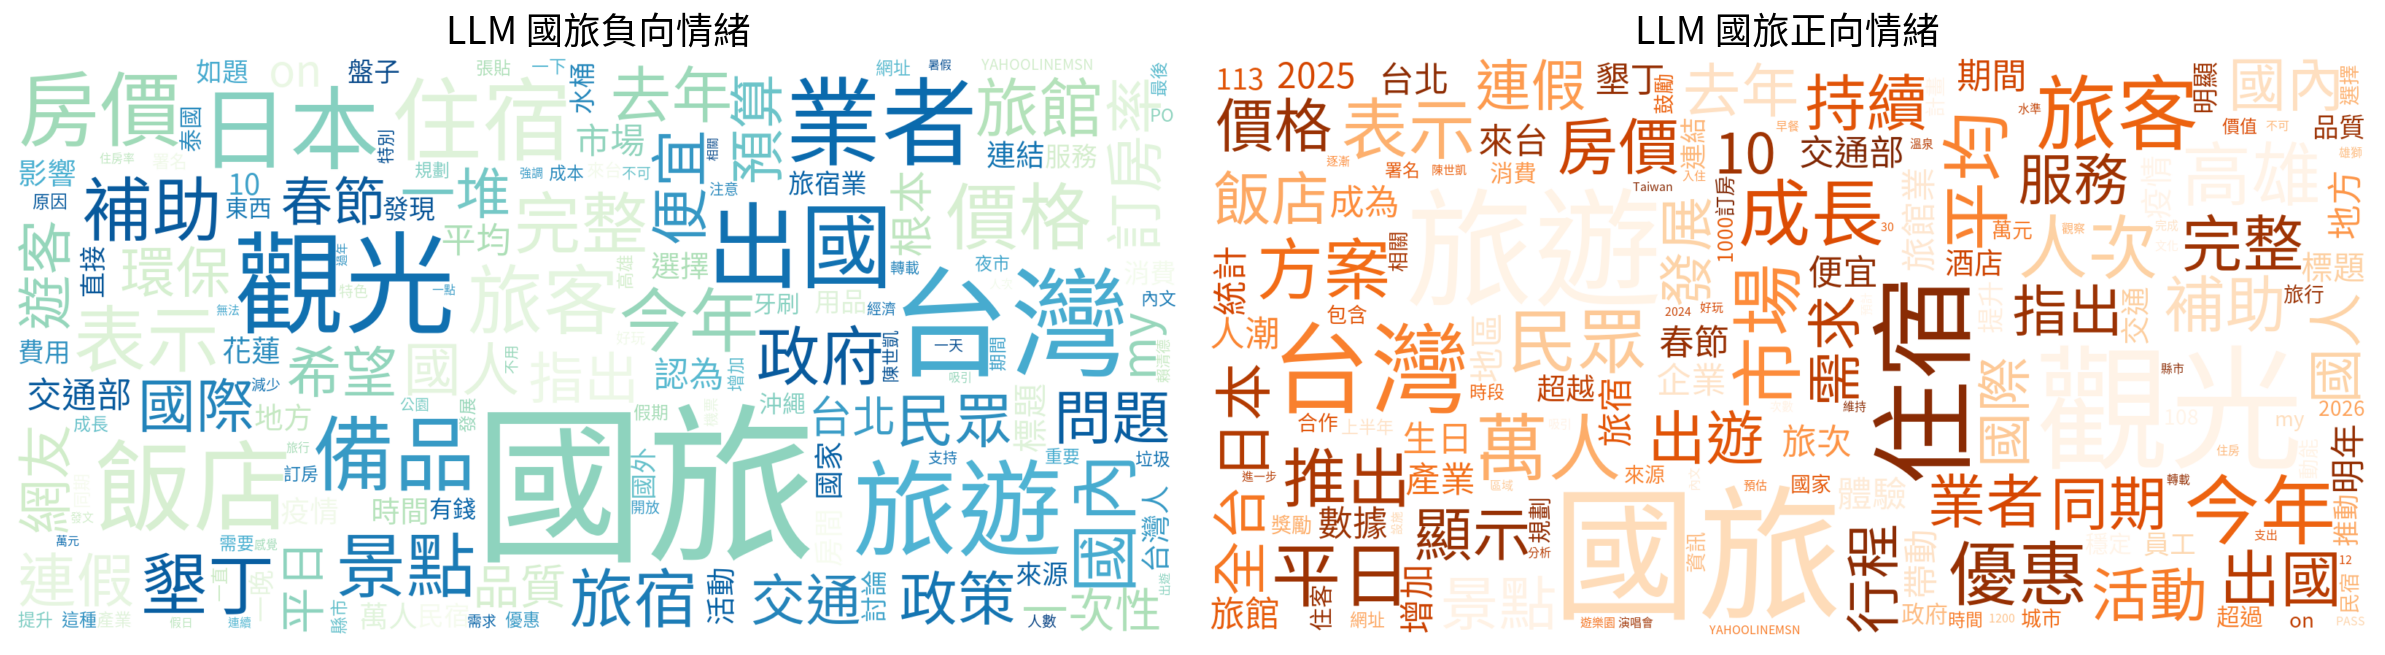

In [61]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

font_path = "./raw_data/SourceHanSansTW-Regular.otf"

# 1. 合併資料：使用 .drop_duplicates 確保文章不重複，並明確使用 LLM 標籤
llm_word_df = pd.merge(
    noStop_df, 
    comparison_df[['artTitle', 'llm_sentiment_class']].drop_duplicates(subset=['artTitle']), 
    on='artTitle', 
    how='inner'
)

# 2. LLM 負向文字雲
llm_neg_words = llm_word_df[llm_word_df['llm_sentiment_class'] == "負向"]
word_counts_llm_neg = pd.DataFrame(llm_neg_words.groupby(["word"]).size()).reset_index().rename(columns={0: "size"})
dict_llm_neg = dict(zip(word_counts_llm_neg['word'], word_counts_llm_neg['size']))
cloud_llm_neg = WordCloud(scale=4, max_words=150, background_color="white", font_path=font_path, colormap="GnBu").generate_from_frequencies(dict_llm_neg)

# 3. LLM 正向文字雲
llm_pos_words = llm_word_df[llm_word_df['llm_sentiment_class'] == "正向"]
word_counts_llm_pos = pd.DataFrame(llm_pos_words.groupby(["word"]).size()).reset_index().rename(columns={0: "size"})
dict_llm_pos = dict(zip(word_counts_llm_pos['word'], word_counts_llm_pos['size']))
cloud_llm_pos = WordCloud(scale=4, max_words=150, background_color="white", font_path=font_path, colormap="Oranges").generate_from_frequencies(dict_llm_pos)

# 4. 畫圖對比
fig, ax = plt.subplots(1, 2, figsize=(16, 7), dpi=150)
ax[0].imshow(cloud_llm_neg, interpolation="bilinear")
ax[0].axis("off")
ax[0].set_title("LLM 國旅負向情緒", fontproperties=fprop, fontsize=18)

ax[1].imshow(cloud_llm_pos, interpolation="bilinear")
ax[1].axis("off")
ax[1].set_title("LLM 國旅正向情緒", fontproperties=fprop, fontsize=18)

plt.tight_layout()
plt.show()

可以看到負向情緒的大字很明確是國旅討論常出現在負面文章中的文字，
「房價」、「住宿」：代表隊價格不滿，連假就調漲房價。
「政策」、「備品」：因為環保政策要住宿業者不給備品，但結果是備品要額外跟業者買，避開所謂的政策，而且沒附備品，住宿價格依舊沒降。
「墾丁」：常常被抨擊為盤子才去備坑錢的地方
「日本」、「出國」：提到國旅不如去日本還比較便宜。
能看到原本政府官方類的字詞「政策」、「補助」等，都有明確被內入於負向情緒

而正向情緒極少數是網友真心讚美國旅。
因為發現正向情緒出現「日本」、「房價」因此分析是否有過於樂觀讚美出國旅遊對比國旅的新聞被誤判，因此有分析，
分析結果發現：絕大多數是帶有樂觀字眼的新聞，或是作者極度讚美日本旅遊，卻被 LLM 誤判的文章。證明網友對國旅的好評很少。

In [69]:
import pandas as pd

# 1. 篩選出 LLM 判定為「正向」，且內文有提到「房價」或「日本」的文章
suspect_pos_cases = comparison_df[
    (comparison_df['llm_sentiment_class'] == '正向') & 
    (comparison_df['artContent'].str.contains('房價|日本', na=False))
]

print(f"{len(suspect_pos_cases)} 篇「LLM 判為正向，但提到房價或日本」的文章\n")
print("=" * 80)

# 2. 隨機抽出 5 篇來檢查 LLM 的判斷理由
sample_suspects = suspect_pos_cases.sample(min(5, len(suspect_pos_cases)), random_state=42)

for idx, row in sample_suspects.iterrows():
    print(f"標題：{row['artTitle']}")
    content_snippet = str(row['artContent']).replace('\n', ' ').strip()[:100]
    print(f"內文摘要：{content_snippet}...")
    print(f"LLM 推理過程：{row['llm_reasoning']}")
    print("-" * 80)

22 篇「LLM 判為正向，但提到房價或日本」的文章

標題：[新聞] 唱衰國旅的人「通通大翻車」！飯店住房率
內文摘要：1.媒體來源:  民視  2.記者署名:  高睿鴻  3.完整新聞標題:  唱衰國旅的人「通通大翻車」！飯店住房率持續上升 另1數據也翻紅  隨著全球旅遊市場逐漸從新冠疫情復甦，台灣的觀光及旅館業也跟...
LLM 推理過程：這篇文章主要報導台灣觀光旅館業的成長趨勢，包括住用率、總住客人次、房價等數據。文章呈現出對國旅市場持續回溫的樂觀態度，並強調旅館業者在提升服務品質、數位化管理以及永續轉型方面的努力。雖然提及房價小幅上漲，但同時也指出有8成旅館房價低於平均水準，整體而言，內容對國旅表現出正面的評價和肯定。因此判定為正向。
--------------------------------------------------------------------------------
標題：[新聞] 國旅上半年「旅館房價平均降2元」　住客
內文摘要：1.媒體來源:ETtoday  2.記者署名:李姿慧  3.完整新聞標題:國旅上半年「旅館房價平均降2元」　住客數量超越疫情前  4.完整新聞內文: 記者李姿慧／台北報導  國旅房價終於降了，根據觀光...
LLM 推理過程：這是一篇關於國旅房價下降及住宿人數恢復的報導。文章主要呈現了國旅業在今年上半年房價略降、住客數量超越疫情前水準的正面趨勢，並提到旅館市場分眾化、民宿數量增長等資訊。雖然有提及旅館業者調整服務內容，但整體而言，文章傳達出國旅產業回溫、帶動消費的樂觀訊息。因此，判定為正向。
--------------------------------------------------------------------------------
標題：[問卦] 國旅贏得了馬來西亞旅遊嗎？
內文摘要：先不要跟亞洲旅遊前兩名泰國跟日本比  光是跟馬來西亞比就知道：  1. 文化多元  馬來文化、華人移民文化、穆斯林文化、印度文化  2. 景點豐富  有宗教、有博物館、有渡假村、有海岸、有森林  3....
LLM 推理過程：這篇文旨在反擊對台灣旅遊的負面評價，並以馬來西亞作為正面比較對象。文章明確指出馬來西亞在文化多元、景點豐富、交通便宜和住宿選擇方面都優於台灣。作者使用了強調性的語氣（例如『屌打』

透過檢視 LLM 判斷為 "正向" 的文章，發現正向數據中混雜了兩類雜訊：
1. 媒體發布的新聞稿（如房價下跌）；
2. 極度讚美外國旅遊的對比文（LLM 將讚美外國的語氣誤判為整體正向）。

這證明了在處理 PTT 這類反諷的文本時，即便使用了 LLM，仍需針對 "評價的主體" 是誰，做更嚴格的提示工程，
或是在分析前先過濾掉新聞文本。

### 結論與未來展望

1. 傳統情緒字典 (Lexicon-based) 的優缺點
優點： 可以直接找出直觀的情緒字眼（如：垃圾、生氣、好玩）。

缺點： 缺乏上下文理解能力。PTT 網友常使用對比與反諷（例如：去日本住宿便宜又高級，反觀國旅...），情緒字典會因為抓到「便宜、高級」等正向詞彙，而將整篇罵國旅的文章誤判為正向，導致分析結果產生嚴重失真。

2. LLM 標註的優勢與衍生盲點
優點： 透過 CoT、提示工程，讓模型能讀懂語境 (反諷、對比)，成功將多數被字典誤判的正向文章轉為負向，提升正負向的準確度。

衍生問題： LLM 雖然讀得懂情緒，卻容易搞錯 "稱讚的主體"。網友用極度滿意的語氣長篇大論稱讚出國旅遊（如去沖繩），LLM 容易被整體的語氣誤導，給出正向標籤，卻忽略該篇文章對國旅其實是貶低的意思。

3. PTT 評價國旅的核心痛點
網友討論的內容，對國旅的評價集中在國旅的性價比，以及對國旅的失望。

住宿成本過高： 「房價」、「住宿」是負向文章中最常出現的字詞。

品質與價格不對等： 針對飯店不提供「備品」卻不降價，以及連假惡意漲價的行為感到不滿。

指標性負面代名詞： 「墾丁」已成為網路上被坑殺（當盤子）的負面情緒。

強烈的替代比較心態： 討論國旅時，永遠伴隨著「日本」、「出國」等比較詞彙，顯示網友並非不願花錢，而是認為花同樣的錢在台灣不值得。

4. 「官方新聞」與「網友討論」的巨大分歧
若不區分文章類型，正向文字雲會被雜訊干擾，無法得出網友真實情緒。

新聞報導： 充滿「成長」、「復甦」、「補助方案」等新文正向報導內容，情緒分數的平均高(字典法：[新聞 -> 1.53 分] 對比 [網友討論 -> 0.05 分])。

網友討論文： 排除新聞後，觀察網友情緒明顯呈現負向。

5. 未來展望與優化方向
未來在進行分析時可從以下方法改善：

優化提示工程： 針對 LLM 會被「過度讚美外國」文章欺騙的缺點，未來應在 Prompt 中加入更嚴格的限制，ex. (即使文章語氣正面，只要讚美的對象是外國旅遊且用以貶低國旅，
要判定為負向。必須單純針對國旅的評價進行給分。)

新聞文本的分析深化： 新聞內文通常是客觀或偏正向的公關稿，無法反映民意。未來的爬蟲與分析重點，應該從「新聞內文」轉移到「該篇新聞下方的 PTT 鄉民留言 (推/噓文)」。透過分析留言的情緒，才能抓到民眾對政府國旅政策與新聞報導的真實情緒。

# 主題模型

使用Guided LDA以及BERTopic，針對此資料集做主題模型

## Guided LDA

In [10]:
import guidedlda

In [11]:
docs = data['words'].to_list()
docs[0]

['醫療',
 '資源',
 '飲食',
 '晚上',
 '台幣',
 '泳池',
 '別墅',
 '私人',
 '沙灘',
 '豪華',
 '早餐',
 '墾丁',
 '活像',
 '貧民窟',
 '案底',
 '出國',
 '還會',
 '墾丁']

建立並過濾詞彙表（dictionary），只保留特定條件的詞彙

In [12]:
dictionary = Dictionary(docs)

dictionary.filter_extremes(no_below=5, no_above=0.99)
print(dictionary)

2026-06-20 15:57:25,910 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2026-06-20 15:57:25,952 : INFO : built Dictionary<12178 unique tokens: ['出國', '別墅', '台幣', '墾丁', '早餐']...> from 923 documents (total 56272 corpus positions)
2026-06-20 15:57:25,952 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<12178 unique tokens: ['出國', '別墅', '台幣', '墾丁', '早餐']...> from 923 documents (total 56272 corpus positions)", 'datetime': '2026-06-20T15:57:25.952338', 'gensim': '4.3.3', 'python': '3.11.0 | packaged by Anaconda, Inc. | (main, Mar  1 2023, 18:18:21) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'created'}
2026-06-20 15:57:25,959 : INFO : discarding 10478 tokens: [('別墅', 1), ('案底', 3), ('活像', 1), ('私人', 4), ('貧民窟', 2), ('一萬五', 2), ('乖乖', 3), ('拜託', 3), ('檢驗', 1), ('衛生', 3)]...
2026-06-20 15:57:25,960 : INFO : keeping 1700 tokens which were in no less than 5 and no more than 913 (=99.0%) documents
2026-06-20 15:57:25,963 : INFO : res

Dictionary<1700 unique tokens: ['出國', '台幣', '墾丁', '早餐', '晚上']...>


In [13]:
word2id = dictionary.token2id

主題 0（住宿體驗）：以飯店、民宿、旅宿等住宿類型為核心，涵蓋服務、備品、房價等評價面向，反映消費者對住宿品質的直接關注。

主題 1（政府補助政策）：以補助、交通部、優惠方案為錨定詞，引導模型識別政策討論，捕捉民眾對政府介入觀光市場的回應。

主題 2（景點與目的地）：以具體地名（墾丁、花蓮、高雄）與旅遊行為詞（行程、體驗、活動）組合，對應實際旅遊地點的選擇討論。

主題 3（與出國比較）：以日本、機票為核心種子詞，引導模型聚焦「國旅 vs. 出國」的性價比論述，這也是資料集中最具代表性的輿論框架。

主題 4（假日人潮需求）：以時節詞（連假、春節、暑假）與人流統計詞（萬人次、人潮）結合，對應觀光旺季的需求討論。

主題 5（消費與物價）：以價格、成本、業者為種子，區分純粹的消費議題，補充主題 3 中對「貴」的結構性原因分析。

In [14]:
seed_topic_list = [
    ['飯店', '民宿', '旅館', '旅宿', '房間', '備品', '入住', '住宿', '服務', '品質', '房價', '訂房', '住房'],

    ['補助', '政府', '交通部', '政策', '優惠', '方案', '預算', '推動', '平日', '出遊', '帶動', '提升'],

    ['景點', '墾丁', '花蓮', '台北', '高雄', '縣市', '地方', '行程', '規劃', '體驗', '活動', '吸引'],

    ['日本', '出國', '沖繩', '國外', '機票', '便宜', '旅客', '國際', '海外', '選擇'],

    ['連假', '假日', '春節', '暑假', '假期', '人潮', '遊客', '出遊', '期間', '旅次', '萬人次', '統計'],

    ['價格', '消費', '成本', '房價', '萬元', '便宜', '市場', '業者', '需求', '影響'],
]


In [15]:
seed_topics = {}
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        seed_topics[word2id[word]] = t_id

In [16]:
# 建立 Bag-of-words 作為文章的特徵表示
# 用 gensim ldamodel input 需要將文章轉換成 bag of words 
corpus = [dictionary.doc2bow(doc) for doc in docs]

In [17]:
# guidedlda 需要 DTM 格式作為 input，因此這邊利用 corpus2dense() 方法進行轉換
X = corpus2dense(corpus, len(dictionary), len(corpus)).T.astype(np.int64)

In [18]:
model = guidedlda.GuidedLDA(n_topics=6, n_iter=100, random_state=7, refresh=20)
model.fit(X, seed_topics=seed_topics, seed_confidence=1)

2026-06-20 15:57:26,052 : INFO : n_documents: 923
2026-06-20 15:57:26,053 : INFO : vocab_size: 1700
2026-06-20 15:57:26,053 : INFO : n_words: 38935
2026-06-20 15:57:26,054 : INFO : n_topics: 6
2026-06-20 15:57:26,054 : INFO : n_iter: 100
2026-06-20 15:57:26,147 : INFO : <0> log likelihood: -354383
2026-06-20 15:57:26,247 : INFO : <20> log likelihood: -268909
2026-06-20 15:57:26,341 : INFO : <40> log likelihood: -265423
2026-06-20 15:57:26,466 : INFO : <60> log likelihood: -264173
2026-06-20 15:57:26,558 : INFO : <80> log likelihood: -263056
2026-06-20 15:57:26,646 : INFO : <99> log likelihood: -262288


In [ ]:
n_top_words = 10
topic_word = model.topic_word_

vocab = tuple(dictionary.token2id.keys())

for i, topic_dist in enumerate(topic_word):
  
    topic_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    print("Topic {}: {}".format(i, " ".join(topic_words)))
    

doc_topic = model.doc_topic_ # 
term_freq = tuple(dictionary.cfs.values()) 
doc_len = [sum(v for k, v in doc) for doc in corpus]

pyLDAvis.enable_notebook()
p = pyLDAvis.prepare(topic_word, doc_topic, doc_len, vocab = vocab, term_frequency = term_freq)
p

Topic 0: 備品 飯店 國旅 業者 一次性 環保 政策 牙刷 用品 旅客
Topic 1: 觀光 補助 國旅 平日 旅遊 住宿 優惠 旅客 方案 國際
Topic 2: 訂房 墾丁 國旅 活動 旅遊 花蓮 遊客 春節 高雄 暑假
Topic 3: 國旅 台灣 日本 出國 飯店 便宜 住宿 旅遊 價格 機票
Topic 4: 觀光 國旅 萬人次 成長 顯示 旅客 民眾 統計 假期 疫情
Topic 5: 旅遊 房價 住宿 國旅 價格 台灣 業者 旅館 市場 民宿


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.104167  0.084475       1        1  29.759946
1      0.139776 -0.119804       2        1  19.490020
4      0.305729 -0.096817       3        1  15.174618
5     -0.149708 -0.106251       4        1  14.936599
2      0.043023  0.342769       5        1  11.577049
0     -0.234653 -0.104372       6        1   9.061767, topic_info=    Term        Freq       Total Category  logprob  loglift
490   備品  246.000000  246.000000  Default  30.0000  30.0000
87    補助  392.000000  392.000000  Default  29.0000  29.0000
40    飯店  410.000000  410.000000  Default  28.0000  28.0000
19    日本  425.000000  425.000000  Default  27.0000  27.0000
88    觀光  770.000000  770.000000  Default  26.0000  26.0000
..   ...         ...         ...      ...      ...      ...
178   台灣   44.834623  739.690539   Topic6  -4.3656  -0.4021
815   垃圾   22.920344   42.901479   Topic6  -5.0365   1.7742
65    政府   27.900862  156.699059   Topic6  -4.8399   0.6754
102   住宿   30.889173  598.603195   Topic6  -4.7381  -0.5631
141   民眾   25.908655  166.718798   Topic6  -4.9140   0.5394

[385 rows x 6 columns], token_table=      Topic      Freq Term
term                      
836       1  1.000288   一人
617       1  0.241664   一年
617       3  0.759515   一年
1454      4  0.029800  一次性
1454      6  0.973462  一次性
...     ...       ...  ...
995       1  0.127038   高雄
995       4  0.014115   高雄
995       5  0.861035   高雄
1437      6  1.001505   髮乳
165       2  1.000324   鼓勵

[522 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 5, 6, 3, 1])

# BERTopic

import 需要的套件

In [20]:
from transformers import BertTokenizerFast, AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger, CkipNerChunker

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

d:\python\envs\social\Lib\site-packages\opentelemetry\util\_importlib_metadata.py:32: DeprecationWarning: SelectableGroups dict interface is deprecated. Use select.
  return EntryPoints(ep for group_eps in eps.values() for ep in group_eps)


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-06-20 15:57:39,959 : WARNING : From d:\python\envs\social\Lib\site-packages\keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.

d:\python\envs\social\Lib\site-packages\spacy\cli\_util.py:23: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string
d:\python\envs\social\Lib\site-packages\weasel\util\config.py:8: DeprecationWarning: Importing 'parser.split_arg_string' is deprecated, it will only be available in 'shell_completion' in Click 9.0.
  from click.parser import split_arg_string


In [ ]:
document = data['content'].to_list()

def jieba_tokenizer(text):
    return [w for w in jieba.cut(text) if w not in stopWords and len(w) > 1]

embedding_model  = "paraphrase-multilingual-MiniLM-L12-v2"  # 支援中文的模型
hdbscan_model    = HDBSCAN(min_cluster_size=15, min_samples=5, prediction_data=True)
vectorizer_model = CountVectorizer(tokenizer=jieba_tokenizer, min_df=2)

topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual"
)
topics, probs = topic_model.fit_transform(document)


2026-06-20 15:58:06,211 : INFO : No device provided, using cuda:0


2026-06-20 15:58:06,742 : INFO : Loading SentenceTransformer model from sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2.


In [22]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,311,-1_國旅_台灣_飯店_出國,"[國旅, 台灣, 飯店, 出國, 住宿, 旅遊, 業者, 日本, 便宜, 補助]",[國旅限制提供備品惹民怨交長喊話不要因為備品抵制聯合報記者周湘芸台北即時報導疫後出國熱潮未減...
1,0,96,0_台灣_國旅_泰國_日本,"[台灣, 國旅, 泰國, 日本, 陸客, 出國, 中國, 開放, 地方, 便宜]",[現在中國都比台灣還懂台灣怎麼可能不知道國旅的狀況何況他們經濟也很差陸劇自己都說巴里島比海南...
2,1,93,1_日本_機票_台灣_國旅,"[日本, 機票, 台灣, 國旅, 便宜, 旅遊, 來回, 出國, 東京, 沖繩]",[台灣被日本統治過去日本是不是也是國旅啊日本國旅是不是要靠超愛去日本的台灣人台灣人去日本就等...
3,2,84,2_備品_環保_飯店_一次性,"[備品, 環保, 飯店, 一次性, 牙刷, 業者, 用品, 政策, 國旅, 牙膏]",[國旅拿備品竟索價百元彭啓明第一次聽到不干預業者定價聯合報記者李柏澔為加大減塑力道今年起旅宿...
4,3,76,3_國旅_墾丁_出國_網友,"[國旅, 墾丁, 出國, 網友, 景點, 旅遊, 機場, 連假, 老街, 沒人]",[國旅熱議墾丁不輸沖繩分析重點不是價格中時新聞網祝潤霖賴清德總統呼籲推動國旅再度引起網友熱議...
5,4,67,4_觀光_訂房_旅遊_國旅,"[觀光, 訂房, 旅遊, 國旅, 活動, 連假, 春節, 縣市, 民眾, 假期]",[春節花蓮訂房率成國旅團費年漲中彰投天行程最高要價民眾嘆窮到只能出國自由時報記者吳亮儀台北報...
6,5,51,5_國旅_出國_安安_國軍,"[國旅, 出國, 安安, 國軍, 國內, 本肥, 機票, 選擇, 便宜, 心態]",[我今天在網路上看到有一些人羨慕出國的人因為家裡沒錢出國只能國旅我就問號機票比國旅還便宜吧怎...
7,6,48,6_觀光_房價_旅遊_萬人次,"[觀光, 房價, 旅遊, 萬人次, 成長, 旅客, 顯示, 住宿, 旅次, 國內]",[記者李姿慧台北報導國旅房價終於降了根據觀光署統計今年月到月觀光旅館及旅館平均房價元較去年同...
8,7,43,7_台灣_飯店_清潔_房間,"[台灣, 飯店, 清潔, 房間, 國旅, 退房, 日本, 住宿, 台幣, 備品]",[阿肥這次過年去日本京都玩啦訂的是京都車站附近走路分鐘內的溫泉旅館一進大廳就感受到奢華的氛圍...
9,8,28,8_補助_平日_方案_住宿,"[補助, 平日, 方案, 住宿, 優惠, 預算, 生日, 觀光, 旅遊, 國旅]",[國旅平日補助最快月上路觀光署預算未過不排除延至明年記者周湘芸台北報導交通部觀光署原規劃今年...


In [23]:
topic_model.visualize_barchart()

In [ ]:
# 視覺化主題分布
topic_model.visualize_topics()

在使用HDBSCAN作為clustering method時，會有311份文件無法被分類到任一一個主題，因此我們決定使用KMeans來讓所有的文件都可以被分類到

In [ ]:
from sklearn.cluster import KMeans

document = data['content'].to_list()

def jieba_tokenizer(text):
    return [w for w in jieba.cut(text) if w not in stopWords and len(w) > 1]

embedding_model  = "paraphrase-multilingual-MiniLM-L12-v2"
cluster_model    = KMeans(n_clusters=10)   
vectorizer_model = CountVectorizer(tokenizer=jieba_tokenizer, min_df=2)

topic_model2 = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    language="multilingual"
)
topics, probs = topic_model2.fit_transform(document)


2026-06-20 17:05:49,191 : INFO : No device provided, using cuda:0
2026-06-20 17:05:49,712 : INFO : Loading SentenceTransformer model from sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2.


In [39]:
topic_model2.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,167,0_台灣_國旅_出國_泰國,"[台灣, 國旅, 出國, 泰國, 旅遊, 日本, 陸客, 地方, 觀光, 景點]",[現在中國都比台灣還懂台灣怎麼可能不知道國旅的狀況何況他們經濟也很差陸劇自己都說巴里島比海南...
1,1,155,1_國旅_出國_補助_便宜,"[國旅, 出國, 補助, 便宜, 新聞, 政府, 業者, 價格, 本肥, 飯店]",[我今天在網路上看到有一些人羨慕出國的人因為家裡沒錢出國只能國旅我就問號機票比國旅還便宜吧怎...
2,2,127,2_國旅_墾丁_出國_旅遊,"[國旅, 墾丁, 出國, 旅遊, 景點, 網友, 機場, 住宿, 遊客, 連假]",[國旅熱議墾丁不輸沖繩分析重點不是價格中時新聞網祝潤霖賴清德總統呼籲推動國旅再度引起網友熱議...
3,3,121,3_備品_飯店_環保_一次性,"[備品, 飯店, 環保, 一次性, 業者, 國旅, 牙刷, 政策, 用品, 旅宿]",[環境部自年月日起為提倡旅遊減塑對旅宿業者祭出一次性備品限制掀起民眾一連串負面聲浪更有不少民...
4,4,82,4_飯店_台灣_房間_住宿,"[飯店, 台灣, 房間, 住宿, 國旅, 早餐, 便宜, 日本, 價格, 台幣]",[阿肥這次過年去日本京都玩啦訂的是京都車站附近走路分鐘內的溫泉旅館一進大廳就感受到奢華的氛圍...
5,5,79,5_日本_機票_國旅_便宜,"[日本, 機票, 國旅, 便宜, 來回, 台灣, 東京, 日幣, 沖繩, 出國]",[國旅走到今天這個地步是不是被日本害的每次提到國旅大家就會說不如去日本如果沒有日本大家就會把...
6,6,60,6_觀光_房價_旅遊_萬人次,"[觀光, 房價, 旅遊, 萬人次, 成長, 旅客, 國旅, 住宿, 顯示, 國內]",[記者李姿慧台北報導國旅房價終於降了根據觀光署統計今年月到月觀光旅館及旅館平均房價元較去年同...
7,7,56,7_觀光_訂房_旅遊_國旅,"[觀光, 訂房, 旅遊, 國旅, 活動, 連假, 民眾, 春節, 縣市, 假期]",[春節花蓮訂房率成國旅團費年漲中彰投天行程最高要價民眾嘆窮到只能出國自由時報記者吳亮儀台北報...
8,8,49,8_日本_台灣_旅遊_國旅,"[日本, 台灣, 旅遊, 國旅, 國內, 總統, 卓榮泰, 中國, 政府, 出國]",[台灣被日本統治過去日本是不是也是國旅啊日本國旅是不是要靠超愛去日本的台灣人台灣人去日本就等...
9,9,27,9_補助_平日_方案_住宿,"[補助, 平日, 方案, 住宿, 優惠, 預算, 生日, 觀光, 旅遊, 國旅]",[國旅平日補助最快月上路觀光署預算未過不排除延至明年記者周湘芸台北報導交通部觀光署原規劃今年...


In [40]:
topic_model2.visualize_barchart()

In [41]:
topic_model2.visualize_topics()

## 發現
兩種模型均一致揭示 PTT 國旅討論的 三大重點：

性價比困境：「出國比國旅便宜」是最核心的輿論框架。日本機票的低廉與台灣飯店房價偏高形成強烈對比，網友頻繁以具體金額進行比較，顯示消費者對國旅的信心不足根本上來自價格問題。

政策介入的期待與懷疑：平日補助、國旅卡、備品政策等議題顯示政府積極介入，但民眾討論中呈現「看得到吃不到」的懷疑態度，業者方面則有等待政府補助、不願自行降價的聲音。

景點與住宿體驗分化：墾丁、花蓮等景點仍有固定支持者，但住宿品質（清潔、價格、餐點）的評價不一，顯示國旅體驗高度依賴個別業者，缺乏整體品質提升。

BERTopic 另外發現了 Guided LDA 沒有明確識別的主題，有細分出民眾想要的平日補助方案（Topic 9）
## 專案整體結論
1. 核心痛點：並非單純「太貴」，而是「性價比破裂」與「比較效應」
鄉民對國旅的負面評價主要建立在強烈的「比較框架」上。高昂的本土飯店房價與相對低廉的日本機票形成對比，導致消費者產生「被當盤子」的強烈情緒與「同樣預算不如出國」的核心共識。國旅面臨的最大危機，本質上是消費者對其「性價比」信心的崩盤。

2. 政策與體驗：補助「看得到吃不到」，品質如同「抽盲盒」
政策依賴與質疑： 討論高度綁定觀光署與交通部的補助方案。民眾對政策多抱持「看得到吃不到」的懷疑態度，認為這只是應對高房價的外部誘因；同時也反映出業者寧可等待政府補助，也不願自主調整價格的僵局。

體驗兩極化： 雖然特定景點（如墾丁、花蓮）仍有討論度，但整體的住宿清潔、餐點與服務品質參差不齊。消費者體驗高度依賴個別業者，缺乏整體產業的品質穩定性。

3. 分析技術洞察：需以進階模型純化「真實民意」
語意理解的挑戰： 傳統情緒字典難以處理網友常用的「反諷」與「對比」語境。雖然 LLM 能讀懂上下文，但也衍生出容易「誤判稱讚主體」（如：稱讚日本卻被誤判為稱讚國旅）的盲點，未來需要透過更嚴謹的提示工程（Prompt Engineering）來限縮判斷標準。

資料來源區隔： 官方新聞文本無法真實反映民意，未來的分析應嚴格區分「新聞報導」與「網友留言」，並藉由如 BERTopic 這類能捕捉細粒度主題（如：平日補助方案）的模型，才能精準萃取出民眾最真實的情緒與訴求。